In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/DETA_Reviewer_Rebuild"

In [ ]:
import os
import json
from pathlib import Path

#
# CELL 2 — PROJECT DIRECTORY STRUCTURE
#

PROJECT_ROOT = "/content/drive/MyDrive/DETA_Reviewer_Rebuild"

DIRS = {
    "raw_data":            f"{PROJECT_ROOT}/00_raw_data",
    "preprocessed":        f"{PROJECT_ROOT}/01_preprocessed",
    "partitions":          f"{PROJECT_ROOT}/02_partitions",
    "controlled":          f"{PROJECT_ROOT}/02_partitions/controlled",
    "noniid":              f"{PROJECT_ROOT}/02_partitions/noniid",
    "server_validation":   f"{PROJECT_ROOT}/02_partitions/server_validation",
    "independent_test":    f"{PROJECT_ROOT}/02_partitions/independent_test",
    "client_models":       f"{PROJECT_ROOT}/03_client_models",
    "client_metrics":      f"{PROJECT_ROOT}/04_client_metrics",
    "shap":                f"{PROJECT_ROOT}/05_shap",
    "trust":               f"{PROJECT_ROOT}/06_trust",
    "probabilities":       f"{PROJECT_ROOT}/07_probabilities",
    "sensitivity":         f"{PROJECT_ROOT}/08_sensitivity",
    "ablations":           f"{PROJECT_ROOT}/09_ablations",
    "noniid_experiments":  f"{PROJECT_ROOT}/10_noniid_experiments",
    "final_test":          f"{PROJECT_ROOT}/11_final_test",
    "figures":             f"{PROJECT_ROOT}/12_figures",
    "tables":              f"{PROJECT_ROOT}/13_tables",
    "logs":                f"{PROJECT_ROOT}/14_logs",
    "reproducibility":     f"{PROJECT_ROOT}/15_reproducibility",
}

for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)

print("=" * 80)
print("PROJECT DIRECTORIES CREATED")
print("=" * 80)

for name, path in DIRS.items():
    print(f"{name:22s} -> {path}")

#
# WRITE ACCESS TEST
#

test_file = f"{DIRS['logs']}/drive_write_test.txt"

with open(test_file, "w") as f:
    f.write("DETA reviewer rebuild: Google Drive write access verified.\n")

assert os.path.exists(test_file)

print("\nWrite access verified:")
print(test_file)

#
# SAVE DIRECTORY CONFIG
#

config_path = f"{DIRS['reproducibility']}/project_paths.json"

with open(config_path, "w") as f:
    json.dump(DIRS, f, indent=4)

print("\nProject paths saved:")
print(config_path)

PROJECT DIRECTORIES CREATED
raw_data               -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/00_raw_data
preprocessed           -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed
partitions             -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions
controlled             -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/controlled
noniid                 -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/noniid
server_validation      -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/server_validation
independent_test       -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/independent_test
client_models          -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models
client_metrics         -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/04_client_metrics
shap                   -> /content/drive/MyDrive/DETA_Reviewer_Rebuild/05_shap
trust                  -> /content/drive/MyDrive/DETA_Reviewer_Rebui

In [ ]:

# CELL 3B — RESOLVE GOOGLE DRIVE SHORTCUT TARGET


import os

SHORTCUT_PATH = "/content/drive/MyDrive/CICIoT2023"

print("=" * 80)
print("RESOLVING CICIoT2023 SHORTCUT")
print("=" * 80)

print("Shortcut path:")
print(SHORTCUT_PATH)

print("\nExists:", os.path.exists(SHORTCUT_PATH))
print("Is link:", os.path.islink(SHORTCUT_PATH))

if os.path.islink(SHORTCUT_PATH):

    target = os.readlink(SHORTCUT_PATH)

    print("\nRaw shortcut target:")
    print(target)

    # Resolve to absolute path
    resolved_target = os.path.realpath(SHORTCUT_PATH)

    print("\nResolved absolute target:")
    print(resolved_target)

    print("\nTarget exists:")
    print(os.path.exists(resolved_target))

    print("\nTarget contents:")
    for item in os.listdir(resolved_target):
        print("  ", item)

else:
    print("\nCICIoT2023 is not recognized as a symbolic link.")

RESOLVING CICIoT2023 SHORTCUT
Shortcut path:
/content/drive/MyDrive/CICIoT2023

Exists: True
Is link: True

Raw shortcut target:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023

Resolved absolute target:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023

Target exists:
True

Target contents:
   MERGED_CSV
   CSV
   Research_Output


In [ ]:

# CELL 3C — MERGED_CSV DATASET AUDIT
# DETA Rebuild


import os
import glob
import json
import pandas as pd

# ------------------------------------------------------------
# RESOLVED DATA PATHS
# ------------------------------------------------------------

CICIOT_ROOT = (
    "/content/drive/.shortcut-targets-by-id/"
    "1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023"
)

MERGED_CSV_DIR = os.path.join(
    CICIOT_ROOT,
    "MERGED_CSV"
)

print("=" * 90)
print("CICIoT2023 — MERGED_CSV AUDIT")
print("=" * 90)

print("\nCICIoT root:")
print(CICIOT_ROOT)

print("\nMERGED_CSV:")
print(MERGED_CSV_DIR)

assert os.path.isdir(MERGED_CSV_DIR), \
    f"MERGED_CSV not found: {MERGED_CSV_DIR}"


# FIND CSV FILES


csv_files = sorted(
    glob.glob(
        os.path.join(MERGED_CSV_DIR, "**", "*.csv"),
        recursive=True
    )
)

print("\n" + "=" * 90)
print("FILE INVENTORY")
print("=" * 90)

print("CSV files found:", len(csv_files))

if len(csv_files) == 0:
    raise RuntimeError(
        "MERGED_CSV exists, but no CSV files were found."
    )

file_records = []

for f in csv_files:

    size_bytes = os.path.getsize(f)

    file_records.append({
        "file": os.path.basename(f),
        "full_path": f,
        "size_mb": size_bytes / (1024 ** 2)
    })

file_inventory = pd.DataFrame(file_records)

print(
    "Total size:",
    round(file_inventory["size_mb"].sum() / 1024, 3),
    "GB"
)

display(
    file_inventory[
        ["file", "size_mb"]
    ]
)


# READ HEADER + SMALL SAMPLE FROM EVERY FILE


print("\n" + "=" * 90)
print("SCHEMA AUDIT")
print("=" * 90)

schema_records = []

reference_columns = None

for f in csv_files:

    temp = pd.read_csv(
        f,
        nrows=5,
        low_memory=False
    )

    columns = list(temp.columns)

    if reference_columns is None:
        reference_columns = columns

    schema_records.append({
        "file": os.path.basename(f),
        "n_columns": len(columns),
        "schema_matches_reference":
            columns == reference_columns
    })

schema_df = pd.DataFrame(schema_records)

display(schema_df)

print(
    "\nAll files have identical schema:",
    schema_df["schema_matches_reference"].all()
)
# FIRST FILE DETAILS


first_file = csv_files[0]

sample_df = pd.read_csv(
    first_file,
    nrows=10,
    low_memory=False
)

print("\n" + "=" * 90)
print("REFERENCE FILE")
print("=" * 90)

print("File:")
print(os.path.basename(first_file))

print("\nNumber of columns:")
print(sample_df.shape[1])

print("\nColumn names:")

for i, column in enumerate(sample_df.columns):
    print(f"{i:02d}  {column}")

print("\nData types:")
print(sample_df.dtypes)

print("\nSample:")
display(sample_df)


# IDENTIFY POSSIBLE LABEL COLUMN


possible_targets = [
    c for c in sample_df.columns
    if any(
        key in c.lower()
        for key in [
            "label",
            "class",
            "target",
            "attack"
        ]
    )
]

print("\nPossible target columns:")
print(possible_targets)


# SAVE AUDIT METADATA


audit_summary = {
    "CICIOT_ROOT": CICIOT_ROOT,
    "MERGED_CSV_DIR": MERGED_CSV_DIR,
    "number_of_csv_files": len(csv_files),
    "total_size_gb":
        float(file_inventory["size_mb"].sum() / 1024),
    "reference_file":
        os.path.basename(first_file),
    "number_of_columns":
        int(sample_df.shape[1]),
    "columns":
        list(sample_df.columns),
    "possible_target_columns":
        possible_targets,
    "all_schemas_identical":
        bool(
            schema_df[
                "schema_matches_reference"
            ].all()
        )
}

audit_path = os.path.join(
    DIRS["reproducibility"],
    "merged_csv_initial_audit.json"
)

with open(audit_path, "w") as f:
    json.dump(
        audit_summary,
        f,
        indent=4
    )

file_inventory.to_csv(
    os.path.join(
        DIRS["tables"],
        "raw_csv_inventory.csv"
    ),
    index=False
)

schema_df.to_csv(
    os.path.join(
        DIRS["tables"],
        "raw_csv_schema_audit.csv"
    ),
    index=False
)

print("\n" + "=" * 90)
print("AUDIT COMPLETE")
print("=" * 90)

print("\nSaved:")
print(audit_path)

print(
    os.path.join(
        DIRS["tables"],
        "raw_csv_inventory.csv"
    )
)

print(
    os.path.join(
        DIRS["tables"],
        "raw_csv_schema_audit.csv"
    )
)

CICIoT2023 — MERGED_CSV AUDIT

CICIoT root:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023

MERGED_CSV:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023/MERGED_CSV

FILE INVENTORY
CSV files found: 63
Total size: 8.661 GB


,file,size_mb
0,Merged01.csv,140.300383
1,Merged02.csv,147.475586
2,Merged03.csv,137.390433
3,Merged04.csv,133.306955
4,Merged05.csv,146.730973
...,...,...
58,Merged59.csv,135.391557
59,Merged60.csv,136.257551
60,Merged61.csv,140.174187
61,Merged62.csv,138.191087



SCHEMA AUDIT


,file,n_columns,schema_matches_reference
0,Merged01.csv,40,True
1,Merged02.csv,40,True
2,Merged03.csv,40,True
3,Merged04.csv,40,True
4,Merged05.csv,40,True
...,...,...,...
58,Merged59.csv,40,True
59,Merged60.csv,40,True
60,Merged61.csv,40,True
61,Merged62.csv,40,True



All files have identical schema: True

REFERENCE FILE
File:
Merged01.csv

Number of columns:
40

Column names:
00  Header_Length
01  Protocol Type
02  Time_To_Live
03  Rate
04  fin_flag_number
05  syn_flag_number
06  rst_flag_number
07  psh_flag_number
08  ack_flag_number
09  ece_flag_number
10  cwr_flag_number
11  ack_count
12  syn_count
13  fin_count
14  rst_count
15  HTTP
16  HTTPS
17  DNS
18  Telnet
19  SMTP
20  SSH
21  IRC
22  TCP
23  UDP
24  DHCP
25  ARP
26  ICMP
27  IGMP
28  IPv
29  LLC
30  Tot sum
31  Min
32  Max
33  AVG
34  Std
35  Tot size
36  IAT
37  Number
38  Variance
39  Label

Data types:
Header_Length      float64
Protocol Type        int64
Time_To_Live       float64
Rate               float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count            int64
syn_count            int64
fin_count            int64
rst_count 

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,19.92,6,63.36,25893.962218,0.0,0.0,0.0,0.99,0.99,0.0,...,6421,60,481,64.21,42.100000,64.21,0.000039,100,1772.410000,DDOS-PSHACK_FLOOD
1,0.00,47,64.00,3703.841331,0.0,0.0,0.0,0.00,0.00,0.0,...,57320,98,578,573.20,48.000000,573.20,0.000271,100,2304.000000,MIRAI-GREIP_FLOOD
2,7.92,17,65.91,19673.095685,0.0,0.0,0.0,0.00,0.00,0.0,...,6010,60,70,60.10,1.000000,60.10,0.000057,100,1.000000,DOS-UDP_FLOOD
3,20.40,6,110.50,261.664826,0.1,0.0,0.3,0.20,0.40,0.0,...,2223,54,1500,222.30,451.596686,222.30,0.004766,10,203939.566667,DNS_SPOOFING
4,0.32,1,63.96,28944.199848,0.0,0.0,0.0,0.00,0.01,0.0,...,6006,60,66,60.06,0.600000,60.06,0.000035,100,0.360000,DDOS-ICMP_FLOOD
5,20.00,6,64.00,47281.073160,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000021,100,0.000000,DDOS-TCP_FLOOD
6,20.00,6,64.00,99698.217257,0.0,0.0,0.0,1.00,1.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000010,100,0.000000,DDOS-PSHACK_FLOOD
7,20.84,6,64.00,28555.991285,0.0,1.0,0.0,0.00,0.21,0.0,...,15006,60,174,150.06,46.667061,150.06,0.000035,100,2177.814545,DDOS-SYN_FLOOD
8,8.00,17,64.00,43518.406308,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000023,100,0.000000,DDOS-UDP_FLOOD
9,52.00,6,64.00,322638.769231,0.0,0.0,0.0,0.00,1.00,0.0,...,860,86,86,86.00,0.000000,86.00,0.000003,10,0.000000,MITM-ARPSPOOFING



Possible target columns:
['Label']

AUDIT COMPLETE

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/merged_csv_initial_audit.json
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/raw_csv_inventory.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/raw_csv_schema_audit.csv


In [ ]:

# CELL 4 — MEMORY-SAFE RAW DATA SAMPLING
# Preserve original DETA framework


import os
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm

TARGET = "Label"

CHUNK_SIZE = 100_000
RANDOM_SEED = 42

# Historical experimental target size
TARGET_TOTAL_SAMPLES = 699_361

rng = np.random.default_rng(RANDOM_SEED)

print("=" * 90)
print("MEMORY-SAFE CICIoT2023 SAMPLING")
print("=" * 90)

print("Target sample size:", TARGET_TOTAL_SAMPLES)
print("Chunk size:", CHUNK_SIZE)


# FIRST PASS:
# Count only labels, chunk by chunk


label_counts = Counter()
total_rows_seen = 0

for file_path in tqdm(csv_files, desc="Counting labels"):

    for chunk in pd.read_csv(
        file_path,
        usecols=[TARGET],
        chunksize=CHUNK_SIZE
    ):

        counts = chunk[TARGET].value_counts()

        label_counts.update(
            counts.to_dict()
        )

        total_rows_seen += len(chunk)

print("\nRows observed:", total_rows_seen)
print("Unique labels:", len(label_counts))

label_df = pd.DataFrame(
    label_counts.items(),
    columns=["Label", "Raw_Count"]
).sort_values(
    "Raw_Count",
    ascending=False
).reset_index(drop=True)

display(label_df)


# SAVE RAW LABEL DISTRIBUTION


label_df.to_csv(
    os.path.join(
        DIRS["tables"],
        "raw_label_distribution.csv"
    ),
    index=False
)

print("\nRaw label distribution saved.")

MEMORY-SAFE CICIoT2023 SAMPLING
Target sample size: 699361
Chunk size: 100000


Counting labels:   0%|          | 0/63 [00:00<?, ?it/s]


Rows observed: 45019243
Unique labels: 34


,Label,Raw_Count
0,DDOS-ICMP_FLOOD,6893259
1,DDOS-UDP_FLOOD,5181027
2,DDOS-TCP_FLOOD,4306086
3,DDOS-PSHACK_FLOOD,3920372
4,DDOS-SYN_FLOOD,3886130
5,DDOS-RSTFINFLOOD,3872808
6,DDOS-SYNONYMOUSIP_FLOOD,3445659
7,DOS-UDP_FLOOD,3177323
8,DOS-TCP_FLOOD,2558256
9,DOS-SYN_FLOOD,1942176



Raw label distribution saved.


In [ ]:

# CELL 5A — DIAGNOSE RAW COUNT MISMATCH


print("=" * 90)
print("DIAGNOSING CELL 5 RAW COUNT MISMATCH")
print("=" * 90)

print("\nlabel_df shape:")
print(label_df.shape)

print("\nlabel_df columns:")
print(label_df.columns.tolist())

print("\nFirst rows:")
display(label_df.head())

print("\nLast rows:")
display(label_df.tail())

calculated_total = int(label_df["Raw_Count"].sum())

print("\n" + "=" * 90)
print("COUNT COMPARISON")
print("=" * 90)

print(f"Cell 5 hard-coded total : {45_019_243:,}")
print(f"label_df calculated sum : {calculated_total:,}")
print(f"Difference              : {calculated_total - 45_019_243:,}")

print("\nNumber of labels:")
print(len(label_df))

print("\nDuplicate label names:")
print(label_df["Label"].duplicated().sum())

print("\nMissing Raw_Count values:")
print(label_df["Raw_Count"].isna().sum())

print("\nRaw_Count dtype:")
print(label_df["Raw_Count"].dtype)

DIAGNOSING CELL 5 RAW COUNT MISMATCH

label_df shape:
(34, 2)

label_df columns:
['Label', 'Raw_Count']

First rows:


,Label,Raw_Count
0,DDOS-ICMP_FLOOD,6893259
1,DDOS-UDP_FLOOD,5181027
2,DDOS-TCP_FLOOD,4306086
3,DDOS-PSHACK_FLOOD,3920372
4,DDOS-SYN_FLOOD,3886130



Last rows:


,Label,Raw_Count
29,SQLINJECTION,5022
30,XSS,3705
31,BACKDOOR_MALWARE,3078
32,RECON-PINGSWEEP,2161
33,UPLOADING_ATTACK,1196



COUNT COMPARISON
Cell 5 hard-coded total : 45,019,243
label_df calculated sum : 45,019,234
Difference              : -9

Number of labels:
34

Duplicate label names:
0

Missing Raw_Count values:
0

Raw_Count dtype:
int64


In [ ]:
#
# CELL 5B — VERIFY MISSING TARGET LABELS
# MEMORY-SAFE: READ LABEL COLUMN ONLY
#

import pandas as pd
from tqdm.auto import tqdm

print("=" * 90)
print("VERIFYING RAW TARGET-LABEL COUNTS")
print("=" * 90)

total_rows_check = 0
valid_labels_check = 0
missing_labels_check = 0

missing_by_file = []

for file_path in tqdm(
    csv_files,
    desc="Checking Label column"
):

    file_total = 0
    file_missing = 0

    for chunk in pd.read_csv(
        file_path,
        usecols=["Label"],
        chunksize=100_000
    ):

        n_rows = len(chunk)
        n_missing = int(
            chunk["Label"].isna().sum()
        )

        total_rows_check += n_rows
        valid_labels_check += (
            n_rows - n_missing
        )
        missing_labels_check += n_missing

        file_total += n_rows
        file_missing += n_missing

    if file_missing > 0:

        missing_by_file.append({
            "File": file_path.split("/")[-1],
            "Rows": file_total,
            "Missing_Label": file_missing
        })

print("\n" + "=" * 90)
print("TARGET AUDIT RESULT")
print("=" * 90)

print(
    f"Physical rows       : "
    f"{total_rows_check:,}"
)

print(
    f"Valid labelled rows : "
    f"{valid_labels_check:,}"
)

print(
    f"Missing labels      : "
    f"{missing_labels_check:,}"
)

print(
    f"label_df sum        : "
    f"{int(label_df['Raw_Count'].sum()):,}"
)

assert (
    valid_labels_check
    ==
    int(label_df["Raw_Count"].sum())
)

assert (
    total_rows_check
    ==
    valid_labels_check
    +
    missing_labels_check
)

print("\nConsistency checks: PASSED")

if missing_by_file:

    missing_label_files_df = pd.DataFrame(
        missing_by_file
    )

    display(missing_label_files_df)

else:

    print(
        "\nNo missing target labels detected."
    )

VERIFYING RAW TARGET-LABEL COUNTS


Checking Label column:   0%|          | 0/63 [00:00<?, ?it/s]


TARGET AUDIT RESULT
Physical rows       : 45,019,243
Valid labelled rows : 45,019,234
Missing labels      : 9
label_df sum        : 45,019,234

Consistency checks: PASSED


,File,Rows,Missing_Label
0,Merged42.csv,871730,1
1,Merged44.csv,725937,1
2,Merged46.csv,678328,1
3,Merged47.csv,657626,1
4,Merged48.csv,657630,1
5,Merged49.csv,642736,1
6,Merged50.csv,601085,1
7,Merged51.csv,214394,1
8,Merged52.csv,65724,1


In [ ]:

# CELL 5 — FREEZE VERIFIED RAW DATA CONFIGURATION
# DETA REBUILD — CORRECTED VERSION


import os
import json
import pandas as pd

print("=" * 90)
print("CELL 5 — FREEZING VERIFIED RAW DATA CONFIGURATION")
print("=" * 90)

# VERIFIED FROM CELLS 4 / 5B


RAW_PHYSICAL_RECORDS = int(total_rows_check)
RAW_LABELLED_RECORDS = int(valid_labels_check)
RAW_MISSING_TARGETS = int(missing_labels_check)

RAW_NUM_FILES = 63
RAW_NUM_FEATURES = 39
RAW_NUM_CLASSES = 34

TARGET = "Label"
RANDOM_SEED = 42

MERGED_CSV_DIR = (
    "/content/drive/.shortcut-targets-by-id/"
    "1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/"
    "CICIoT2023/MERGED_CSV"
)


# SANITY CHECKS


assert os.path.isdir(MERGED_CSV_DIR), \
    f"MERGED_CSV directory not found: {MERGED_CSV_DIR}"

assert RAW_PHYSICAL_RECORDS == 45_019_243

assert RAW_LABELLED_RECORDS == 45_019_234

assert RAW_MISSING_TARGETS == 9

assert (
    RAW_PHYSICAL_RECORDS
    ==
    RAW_LABELLED_RECORDS + RAW_MISSING_TARGETS
)

assert len(label_df) == 34
assert label_df["Label"].nunique() == 34
assert label_df["Label"].duplicated().sum() == 0

print("\nRaw-data consistency checks: PASSED")


# SAVE VERIFIED 34-CLASS TAXONOMY


taxonomy_path = os.path.join(
    DIRS["tables"],
    "verified_raw_34_class_taxonomy.csv"
)

label_df.to_csv(
    taxonomy_path,
    index=False
)


# SAVE MISSING-TARGET FILE INFORMATION


if "missing_label_files_df" in globals():

    missing_target_path = os.path.join(
        DIRS["tables"],
        "raw_missing_target_labels.csv"
    )

    missing_label_files_df.to_csv(
        missing_target_path,
        index=False
    )


# REPRODUCIBILITY CONFIGURATION


raw_config = {

    "dataset": "CICIoT2023",

    "source": "MERGED_CSV",

    "source_path": MERGED_CSV_DIR,

    "raw_csv_files": RAW_NUM_FILES,

    "raw_physical_records":
        RAW_PHYSICAL_RECORDS,

    "raw_valid_labelled_records":
        RAW_LABELLED_RECORDS,

    "raw_missing_target_records":
        RAW_MISSING_TARGETS,

    "raw_predictor_features":
        RAW_NUM_FEATURES,

    "raw_classes":
        RAW_NUM_CLASSES,

    "target_column":
        TARGET,

    "random_seed":
        RANDOM_SEED,

    "historical_sampling": {

        "samples_per_csv": 10_000,

        "number_of_csvs": 63,

        "expected_sample_size": 630_000,

        "sampling_method":
            "pandas.DataFrame.sample",

        "random_state": 42
    },

    "framework": "DETA",

    "reviewer_rebuild_policy": {

        "change_deta_framework": False,

        "preserve_historical_top30": True,

        "split_before_synthetic_balancing": True,

        "server_validation_for_Gi_Bi": True,

        "independent_test_final_reporting_only": True,

        "test_used_for_trust_estimation": False,

        "noniid_experiments_required": True,

        "shap_sensitivity_required": True
    }
}

config_path = os.path.join(
    DIRS["reproducibility"],
    "verified_raw_configuration.json"
)

with open(config_path, "w") as f:

    json.dump(
        raw_config,
        f,
        indent=4
    )


# DISPLAY


print("\n" + "=" * 90)
print("VERIFIED CICIoT2023 SOURCE")
print("=" * 90)

print(
    f"Physical records       : "
    f"{RAW_PHYSICAL_RECORDS:,}"
)

print(
    f"Valid labelled records : "
    f"{RAW_LABELLED_RECORDS:,}"
)

print(
    f"Missing target labels  : "
    f"{RAW_MISSING_TARGETS:,}"
)

print(
    f"CSV files              : "
    f"{RAW_NUM_FILES}"
)

print(
    f"Predictor features     : "
    f"{RAW_NUM_FEATURES}"
)

print(
    f"Classes                : "
    f"{RAW_NUM_CLASSES}"
)

print("\nHistorical sampling:")
print("63 files × 10,000 rows = 630,000 observations")

print("\nSaved:")
print(taxonomy_path)
print(config_path)

print("\nCELL 5 STATUS: PASSED")

CELL 5 — FREEZING VERIFIED RAW DATA CONFIGURATION

Raw-data consistency checks: PASSED

VERIFIED CICIoT2023 SOURCE
Physical records       : 45,019,243
Valid labelled records : 45,019,234
Missing target labels  : 9
CSV files              : 63
Predictor features     : 39
Classes                : 34

Historical sampling:
63 files × 10,000 rows = 630,000 observations

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/verified_raw_34_class_taxonomy.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/verified_raw_configuration.json

CELL 5 STATUS: PASSED


In [ ]:

# CELL 6A — DIAGNOSE MERGED_CSV FILE DISCOVERY


import os

print("=" * 90)
print("CELL 6A — DIAGNOSING MERGED_CSV DIRECTORY")
print("=" * 90)

shortcut_path = "/content/drive/MyDrive/CICIoT2023"
resolved_root = os.path.realpath(shortcut_path)

MERGED_CSV_DIR = os.path.join(
    resolved_root,
    "MERGED_CSV"
)

print("\nMERGED_CSV_DIR:")
print(MERGED_CSV_DIR)

print("\nExists:")
print(os.path.exists(MERGED_CSV_DIR))

print("\nIs directory:")
print(os.path.isdir(MERGED_CSV_DIR))


# DIRECT DIRECTORY LISTING


entries = os.listdir(MERGED_CSV_DIR)

print("\nTotal directory entries:")
print(len(entries))

print("\nFirst 20 entries:")
for item in entries[:20]:
    print(repr(item))


# INSPECT EXTENSIONS


print("\n" + "=" * 90)
print("FILE EXTENSION AUDIT")
print("=" * 90)

extensions = {}

for item in entries:

    full_path = os.path.join(
        MERGED_CSV_DIR,
        item
    )

    if os.path.isfile(full_path):

        ext = os.path.splitext(item)[1]

        extensions[ext] = (
            extensions.get(ext, 0) + 1
        )

print(extensions)


# CASE-INSENSITIVE CSV DISCOVERY


csv_files = sorted([

    os.path.join(
        MERGED_CSV_DIR,
        item
    )

    for item in entries

    if (
        os.path.isfile(
            os.path.join(
                MERGED_CSV_DIR,
                item
            )
        )
        and
        item.strip().lower().endswith(".csv")
    )
])

print("\nCSV-like files found:")
print(len(csv_files))

if csv_files:

    print("\nFirst 5:")
    for f in csv_files[:5]:
        print(os.path.basename(f))

    print("\nLast 5:")
    for f in csv_files[-5:]:
        print(os.path.basename(f))

print("\nCELL 6A COMPLETE")

CELL 6A — DIAGNOSING MERGED_CSV DIRECTORY

MERGED_CSV_DIR:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023/MERGED_CSV

Exists:
True

Is directory:
True

Total directory entries:
2

First 20 entries:
'MERGED_CSV.zip'
'MERGED_CSV'

FILE EXTENSION AUDIT
{'.zip': 1}

CSV-like files found:
0

CELL 6A COMPLETE


In [ ]:

# CELL 6B — RESOLVE NESTED MERGED_CSV
# AND FREEZE HISTORICAL TOP-30 FEATURES


import os
import json
import pandas as pd

print("=" * 90)
print("CELL 6B — RESOLVE DATA DIRECTORY + FREEZE TOP-30")
print("=" * 90)


# 1. RESOLVE GOOGLE DRIVE SHORTCUT


shortcut_path = "/content/drive/MyDrive/CICIoT2023"

resolved_root = os.path.realpath(
    shortcut_path
)

outer_merged_dir = os.path.join(
    resolved_root,
    "MERGED_CSV"
)

inner_merged_dir = os.path.join(
    outer_merged_dir,
    "MERGED_CSV"
)

print("\nResolved CICIoT2023:")
print(resolved_root)

print("\nOuter MERGED_CSV:")
print(outer_merged_dir)

print("\nInner MERGED_CSV:")
print(inner_merged_dir)

print(
    "\nInner directory exists:",
    os.path.isdir(inner_merged_dir)
)

assert os.path.isdir(inner_merged_dir), \
    "Nested MERGED_CSV directory was not found."


# 2. FREEZE CORRECT RAW CSV DIRECTORY


MERGED_CSV_DIR = inner_merged_dir

entries = os.listdir(
    MERGED_CSV_DIR
)

csv_files = sorted([
    os.path.join(
        MERGED_CSV_DIR,
        filename
    )
    for filename in entries
    if (
        os.path.isfile(
            os.path.join(
                MERGED_CSV_DIR,
                filename
            )
        )
        and filename.strip().lower().endswith(".csv")
    )
])

print("\nCSV files found:")
print(len(csv_files))

if csv_files:
    print(
        "First:",
        os.path.basename(csv_files[0])
    )
    print(
        "Last :",
        os.path.basename(csv_files[-1])
    )

assert len(csv_files) == 63, \
    f"Expected 63 CSV files; found {len(csv_files)}"

print("\nCSV discovery: PASSED")


# 3. HISTORICAL TOP-30


HISTORICAL_TOP30 = [

    "Protocol Type",
    "UDP",
    "syn_count",
    "ICMP",
    "TCP",
    "syn_flag_number",
    "Tot sum",
    "Header_Length",
    "AVG",
    "psh_flag_number",

    "Max",
    "ack_flag_number",
    "fin_flag_number",
    "ack_count",
    "rst_flag_number",
    "Number",
    "Std",
    "IAT",
    "Rate",
    "Min",

    "HTTP",
    "Tot size",
    "rst_count",
    "Time_To_Live",
    "fin_count",
    "HTTPS",
    "Variance",
    "ARP",
    "DNS",
    "SSH"
]

assert len(HISTORICAL_TOP30) == 30
assert len(set(HISTORICAL_TOP30)) == 30


# 4. HISTORICAL CONSENSUS RANKING


historical_consensus = pd.DataFrame({

    "Feature": HISTORICAL_TOP30,

    "XGB_Rank": [
        1, 5, 3, 2, 10,
        8, 12, 19, 14, 7,
        13, 11, 4, 16, 9,
        6, 21, 18, 20, 15,
        17, 38, 28, 23, 25,
        22, 39, 26, 29, 27
    ],

    "MI_Rank": [
        2, 5, 10, 11, 3,
        8, 4, 1, 7, 14,
        9, 13, 21, 12, 20,
        25, 15, 18, 17, 23,
        27, 6, 19, 24, 22,
        26, 16, 30, 31, 33
    ]
})

historical_consensus["Consensus_Score"] = (
    historical_consensus["XGB_Rank"]
    +
    historical_consensus["MI_Rank"]
)

historical_consensus.insert(
    0,
    "Consensus_Rank",
    range(1, 31)
)


# 5. VERIFY AGAINST REAL CSV HEADER


raw_header = pd.read_csv(
    csv_files[0],
    nrows=0
).columns.tolist()

print(
    "\nRaw columns:",
    len(raw_header)
)

missing_features = [
    feature
    for feature in HISTORICAL_TOP30
    if feature not in raw_header
]

assert not missing_features, \
    f"Missing historical features: {missing_features}"

assert "Label" in raw_header

print(
    "Historical Top-30 schema verification: PASSED"
)


# 6. SAVE TABLE


feature_table_path = os.path.join(
    DIRS["tables"],
    "historical_top30_consensus_features.csv"
)

historical_consensus.to_csv(
    feature_table_path,
    index=False
)


# 7. SAVE CONFIGURATION


feature_config = {

    "raw_data_directory":
        MERGED_CSV_DIR,

    "raw_csv_count":
        len(csv_files),

    "raw_predictor_count":
        39,

    "selected_feature_count":
        30,

    "selection_method":
        "XGBoost + Mutual Information rank-sum consensus",

    "consensus_equation":
        "Consensus_Score = XGB_Rank + MI_Rank",

    "selection_rule":
        "Select 30 features with smallest consensus scores",

    "feature_selection_rerun_for_revision":
        False,

    "feature_set_status":
        "Frozen historical DETA feature set",

    "features":
        HISTORICAL_TOP30
}

feature_config_path = os.path.join(
    DIRS["reproducibility"],
    "historical_top30_features.json"
)

with open(
    feature_config_path,
    "w"
) as f:

    json.dump(
        feature_config,
        f,
        indent=4
    )


# 8. DISPLAY


display(
    historical_consensus
)

print("\n" + "=" * 90)
print("CELL 6 STATUS")
print("=" * 90)

print(
    f"Raw CSV directory : {MERGED_CSV_DIR}"
)

print(
    f"CSV files         : {len(csv_files)}"
)

print(
    f"Frozen features   : {len(HISTORICAL_TOP30)}"
)

print("\nSaved:")
print(feature_table_path)
print(feature_config_path)

print("\nCELL 6 STATUS: PASSED")

CELL 6B — RESOLVE DATA DIRECTORY + FREEZE TOP-30

Resolved CICIoT2023:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023

Outer MERGED_CSV:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023/MERGED_CSV

Inner MERGED_CSV:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023/MERGED_CSV/MERGED_CSV

Inner directory exists: True

CSV files found:
63
First: Merged01.csv
Last : Merged63.csv

CSV discovery: PASSED

Raw columns: 40
Historical Top-30 schema verification: PASSED


,Consensus_Rank,Feature,XGB_Rank,MI_Rank,Consensus_Score
0,1,Protocol Type,1,2,3
1,2,UDP,5,5,10
2,3,syn_count,3,10,13
3,4,ICMP,2,11,13
4,5,TCP,10,3,13
5,6,syn_flag_number,8,8,16
6,7,Tot sum,12,4,16
7,8,Header_Length,19,1,20
8,9,AVG,14,7,21
9,10,psh_flag_number,7,14,21



CELL 6 STATUS
Raw CSV directory : /content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023/MERGED_CSV/MERGED_CSV
CSV files         : 63
Frozen features   : 30

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/historical_top30_consensus_features.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/historical_top30_features.json

CELL 6 STATUS: PASSED


In [ ]:

# CELL 5 — FREEZE VERIFIED RAW-DATA CONFIGURATION
# FINAL REPRODUCIBILITY VERSION
# DETA REVIEWER REBUILD


import os
import json
import pandas as pd

print("=" * 90)
print("CELL 5 — FREEZING VERIFIED RAW-DATA CONFIGURATION")
print("=" * 90)


# 1. PROJECT / DATASET CONSTANTS


DATASET_NAME = "CICIoT2023"
TARGET = "Label"
RANDOM_SEED = 42

RAW_NUM_FILES = 63
RAW_NUM_FEATURES = 39
RAW_NUM_CLASSES = 34

# Verified by the complete 63-file audit
RAW_PHYSICAL_RECORDS = 45_019_243
RAW_LABELLED_RECORDS = 45_019_234
RAW_MISSING_TARGETS = 9

# Historical sampling configuration
SAMPLES_PER_CSV = 10_000
EXPECTED_HISTORICAL_SAMPLE = 630_000


# 2. RESOLVE GOOGLE DRIVE SHORTCUT DYNAMICALLY


SHORTCUT_PATH = "/content/drive/MyDrive/CICIoT2023"

assert os.path.exists(SHORTCUT_PATH), \
    f"CICIoT2023 shortcut not found: {SHORTCUT_PATH}"

CICIOT_ROOT = os.path.realpath(
    SHORTCUT_PATH
)

# Actual structure discovered during audit:
#
# CICIoT2023/
# └── MERGED_CSV/
#     ├── MERGED_CSV.zip
#     └── MERGED_CSV/
#         ├── Merged01.csv
#         ├── ...
#         └── Merged63.csv

MERGED_CSV_OUTER = os.path.join(
    CICIOT_ROOT,
    "MERGED_CSV"
)

MERGED_CSV_DIR = os.path.join(
    MERGED_CSV_OUTER,
    "MERGED_CSV"
)

assert os.path.isdir(MERGED_CSV_DIR), \
    f"Actual MERGED_CSV directory not found: {MERGED_CSV_DIR}"


# 3. VERIFY THE 63 PHYSICAL CSV FILES


csv_files = sorted([
    os.path.join(
        MERGED_CSV_DIR,
        filename
    )
    for filename in os.listdir(MERGED_CSV_DIR)
    if (
        os.path.isfile(
            os.path.join(
                MERGED_CSV_DIR,
                filename
            )
        )
        and filename.strip().lower().endswith(".csv")
    )
])

assert len(csv_files) == RAW_NUM_FILES, \
    (
        f"Expected {RAW_NUM_FILES} CSV files, "
        f"found {len(csv_files)}"
    )

print("\nDataset shortcut:")
print(SHORTCUT_PATH)

print("\nResolved CICIoT2023 root:")
print(CICIOT_ROOT)

print("\nActual raw CSV directory:")
print(MERGED_CSV_DIR)

print("\nCSV files discovered:")
print(len(csv_files))

print(
    "First file:",
    os.path.basename(csv_files[0])
)

print(
    "Last file :",
    os.path.basename(csv_files[-1])
)


# 4. VERIFY RAW SCHEMA


raw_header = pd.read_csv(
    csv_files[0],
    nrows=0
).columns.tolist()

assert len(raw_header) == 40, \
    f"Expected 40 total columns, found {len(raw_header)}"

assert TARGET in raw_header, \
    f"Target column '{TARGET}' not found."

raw_predictors = [
    c for c in raw_header
    if c != TARGET
]

assert len(raw_predictors) == RAW_NUM_FEATURES

print("\nRaw schema:")
print(f"Total columns      : {len(raw_header)}")
print(f"Predictor features : {len(raw_predictors)}")
print(f"Target             : {TARGET}")


# 5. VERIFY AUDITED RECORD COUNTS


assert (
    RAW_LABELLED_RECORDS
    +
    RAW_MISSING_TARGETS
    ==
    RAW_PHYSICAL_RECORDS
), "Raw record-count reconciliation failed."

assert (
    RAW_PHYSICAL_RECORDS
    ==
    45_019_243
)

assert (
    RAW_LABELLED_RECORDS
    ==
    45_019_234
)

assert RAW_MISSING_TARGETS == 9

print("\n" + "=" * 90)
print("VERIFIED RECORD COUNTS")
print("=" * 90)

print(
    f"Physical records       : "
    f"{RAW_PHYSICAL_RECORDS:,}"
)

print(
    f"Valid labelled records : "
    f"{RAW_LABELLED_RECORDS:,}"
)

print(
    f"Missing target labels  : "
    f"{RAW_MISSING_TARGETS:,}"
)

print(
    "\nReconciliation:"
)

print(
    f"{RAW_LABELLED_RECORDS:,} + "
    f"{RAW_MISSING_TARGETS:,} = "
    f"{RAW_PHYSICAL_RECORDS:,}"
)


# 6. RECORD FILES CONTAINING MISSING TARGETS


# Verified by the earlier complete target-column audit.
MISSING_TARGET_FILES = [
    "Merged42.csv",
    "Merged44.csv",
    "Merged46.csv",
    "Merged47.csv",
    "Merged48.csv",
    "Merged49.csv",
    "Merged50.csv",
    "Merged51.csv",
    "Merged52.csv"
]

assert len(MISSING_TARGET_FILES) == 9

missing_target_df = pd.DataFrame({
    "File": MISSING_TARGET_FILES,
    "Missing_Label": [1] * 9
})

missing_target_path = os.path.join(
    DIRS["tables"],
    "verified_raw_missing_target_records.csv"
)

missing_target_df.to_csv(
    missing_target_path,
    index=False
)


# 7. SAVE VERIFIED CLASS TAXONOMY IF AVAILABLE


taxonomy_path = os.path.join(
    DIRS["tables"],
    "verified_raw_34_class_taxonomy.csv"
)

if "label_df" in globals():

    assert len(label_df) == RAW_NUM_CLASSES
    assert label_df["Label"].nunique() == RAW_NUM_CLASSES

    assert int(
        label_df["Raw_Count"].sum()
    ) == RAW_LABELLED_RECORDS

    label_df.to_csv(
        taxonomy_path,
        index=False
    )

    print("\n34-class taxonomy verification: PASSED")

else:

    print(
        "\nNOTE: label_df is not currently in memory."
    )
    print(
        "The previously audited taxonomy file "
        "will not be overwritten."
    )


# 8. DEFINE REVIEWER-REBUILD DATA GOVERNANCE


reviewer_rebuild_policy = {

    # Preserve proposed method
    "framework": "DETA",

    "change_deta_framework": False,

    # Historical representation retained
    "preserve_historical_top30_features": True,

    # Reviewer-critical leakage controls
    "split_real_data_before_balancing": True,

    "fit_preprocessing_on_training_only": True,

    "synthetic_balancing_on_training_only": True,

    # DETA trust components
    "server_validation_used_for_Gi_Bi": True,

    "shap_stability_used_for_Si": True,

    # Locked test-set policy
    "independent_test_used_for_trust": False,

    "independent_test_used_for_model_selection": False,

    "independent_test_used_for_hyperparameter_tuning": False,

    "independent_test_final_reporting_only": True,

    # Reviewer-requested validation
    "controlled_partition_experiment": True,

    "noniid_experiments_required": True,

    "shap_stability_sensitivity_required": True,

    "trust_component_ablation_required": True,

    "statistical_analysis_required": True,

    "reproducibility_artifacts_required": True
}


# 9. BUILD COMPLETE REPRODUCIBILITY CONFIGURATION


raw_config = {

    "dataset": DATASET_NAME,

    "framework": "DETA",

    "rebuild_purpose":
        "Reviewer-response reproducibility and validation",

    "source": "CICIoT2023 MERGED_CSV",

    "drive_shortcut":
        SHORTCUT_PATH,

    "resolved_dataset_root":
        CICIOT_ROOT,

    "resolved_raw_csv_directory":
        MERGED_CSV_DIR,

    "raw_csv_files":
        RAW_NUM_FILES,

    "first_csv":
        os.path.basename(csv_files[0]),

    "last_csv":
        os.path.basename(csv_files[-1]),

    "raw_total_columns":
        len(raw_header),

    "raw_predictor_features":
        RAW_NUM_FEATURES,

    "target_column":
        TARGET,

    "raw_classes":
        RAW_NUM_CLASSES,

    "raw_physical_records":
        RAW_PHYSICAL_RECORDS,

    "raw_valid_labelled_records":
        RAW_LABELLED_RECORDS,

    "raw_missing_target_records":
        RAW_MISSING_TARGETS,

    "missing_target_files":
        MISSING_TARGET_FILES,

    "random_seed":
        RANDOM_SEED,

    "historical_sampling": {

        "number_of_csv_files":
            RAW_NUM_FILES,

        "samples_per_csv":
            SAMPLES_PER_CSV,

        "expected_sample_size":
            EXPECTED_HISTORICAL_SAMPLE,

        "sampling_without_replacement":
            True,

        "pandas_random_state":
            RANDOM_SEED,

        "sampling_rule":
            "10,000 observations independently sampled "
            "from each of the 63 merged CSV files"
    },

    "reviewer_rebuild_policy":
        reviewer_rebuild_policy
}


# 10. SAVE JSON CONFIGURATION


config_path = os.path.join(
    DIRS["reproducibility"],
    "verified_raw_configuration.json"
)

with open(
    config_path,
    "w"
) as f:

    json.dump(
        raw_config,
        f,
        indent=4
    )


# 11. SAVE HUMAN-READABLE SUMMARY


summary_df = pd.DataFrame({

    "Property": [
        "Dataset",
        "Framework",
        "Raw CSV files",
        "Physical records",
        "Valid labelled records",
        "Missing target records",
        "Raw predictor features",
        "Classes",
        "Target",
        "Historical samples per CSV",
        "Historical expected sample",
        "Random seed"
    ],

    "Value": [
        DATASET_NAME,
        "DETA",
        RAW_NUM_FILES,
        RAW_PHYSICAL_RECORDS,
        RAW_LABELLED_RECORDS,
        RAW_MISSING_TARGETS,
        RAW_NUM_FEATURES,
        RAW_NUM_CLASSES,
        TARGET,
        SAMPLES_PER_CSV,
        EXPECTED_HISTORICAL_SAMPLE,
        RANDOM_SEED
    ]
})

summary_path = os.path.join(
    DIRS["tables"],
    "verified_raw_dataset_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


# 12. FINAL DISPLAY


print("\n" + "=" * 90)
print("FROZEN RAW-DATA CONFIGURATION")
print("=" * 90)

display(summary_df)

print("\nHistorical reconstruction:")
print(
    f"{RAW_NUM_FILES} files × "
    f"{SAMPLES_PER_CSV:,} observations = "
    f"{EXPECTED_HISTORICAL_SAMPLE:,}"
)

print("\nReviewer rebuild policy:")
print("✓ DETA framework retained")
print("✓ Historical Top-30 representation retained")
print("✓ Real-data split before balancing")
print("✓ Training-only preprocessing")
print("✓ Server validation reserved for G_i / B_i")
print("✓ Independent test excluded from trust estimation")
print("✓ Independent test reserved for final reporting")
print("✓ Non-IID robustness experiments planned")
print("✓ SHAP stability sensitivity analysis planned")
print("✓ Trust ablations/statistical analysis planned")

print("\nSaved:")
print(config_path)
print(summary_path)
print(missing_target_path)

if "label_df" in globals():
    print(taxonomy_path)

print("\n" + "=" * 90)
print("CELL 5 STATUS: PASSED")
print("=" * 90)

CELL 5 — FREEZING VERIFIED RAW-DATA CONFIGURATION

Dataset shortcut:
/content/drive/MyDrive/CICIoT2023

Resolved CICIoT2023 root:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023

Actual raw CSV directory:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023/MERGED_CSV/MERGED_CSV

CSV files discovered:
63
First file: Merged01.csv
Last file : Merged63.csv

Raw schema:
Total columns      : 40
Predictor features : 39
Target             : Label

VERIFIED RECORD COUNTS
Physical records       : 45,019,243
Valid labelled records : 45,019,234
Missing target labels  : 9

Reconciliation:
45,019,234 + 9 = 45,019,243

34-class taxonomy verification: PASSED

FROZEN RAW-DATA CONFIGURATION


,Property,Value
0,Dataset,CICIoT2023
1,Framework,DETA
2,Raw CSV files,63
3,Physical records,45019243
4,Valid labelled records,45019234
5,Missing target records,9
6,Raw predictor features,39
7,Classes,34
8,Target,Label
9,Historical samples per CSV,10000



Historical reconstruction:
63 files × 10,000 observations = 630,000

Reviewer rebuild policy:
✓ DETA framework retained
✓ Historical Top-30 representation retained
✓ Real-data split before balancing
✓ Training-only preprocessing
✓ Server validation reserved for G_i / B_i
✓ Independent test excluded from trust estimation
✓ Independent test reserved for final reporting
✓ Non-IID robustness experiments planned
✓ SHAP stability sensitivity analysis planned
✓ Trust ablations/statistical analysis planned

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/verified_raw_configuration.json
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/verified_raw_dataset_summary.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/verified_raw_missing_target_records.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/verified_raw_34_class_taxonomy.csv

CELL 5 STATUS: PASSED


In [ ]:

# CELL 7 — RECONSTRUCT HISTORICAL 630K REAL SAMPLE
# MEMORY-SAFE / NO SYNTHETIC BALANCING


import os
import gc
import json
import joblib
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from sklearn.preprocessing import LabelEncoder

print("=" * 90)
print("CELL 7 — RECONSTRUCTING HISTORICAL 630K REAL SAMPLE")
print("=" * 90)

SEED = 42
SAMPLE_PER_FILE = 10_000


# 1. VERIFY REQUIRED OBJECTS FROM CELL 6B


assert "MERGED_CSV_DIR" in globals(), \
    "MERGED_CSV_DIR is missing. Run Cell 6B first."

assert "csv_files" in globals(), \
    "csv_files is missing. Run Cell 6B first."

assert "HISTORICAL_TOP30" in globals(), \
    "HISTORICAL_TOP30 is missing. Run Cell 6B first."

assert os.path.isdir(MERGED_CSV_DIR)

assert len(csv_files) == 63, \
    f"Expected 63 CSV files, found {len(csv_files)}"

assert len(HISTORICAL_TOP30) == 30

print("\nRaw CSV directory:")
print(MERGED_CSV_DIR)

print("\nCSV files          :", len(csv_files))
print("Samples per file   :", f"{SAMPLE_PER_FILE:,}")
print("Expected total     :", f"{len(csv_files)*SAMPLE_PER_FILE:,}")
print("Frozen features    :", len(HISTORICAL_TOP30))


# 2. COLUMNS REQUIRED FROM RAW FILES


columns_to_keep = (
    HISTORICAL_TOP30
    +
    ["Label"]
)


# 3. SAMPLE ONE CSV AT A TIME
#
# Historical rule:
#
# df.sample(
#     n=10000,
#     random_state=42
# )
#
# We deliberately do NOT:
#
# - remove missing target rows before sampling
# - impute features
# - scale features
# - apply SMOTE
# - apply ADASYN
# - apply BorderlineSMOTE
#
#

sampled_parts = []
sampling_audit = []

for file_path in tqdm(
    csv_files,
    desc="Sampling 63 CSV files"
):

    filename = os.path.basename(file_path)


    # Load ONE CSV only and only required columns.
    # This keeps RAM usage low.


    temp = pd.read_csv(
        file_path,
        usecols=columns_to_keep,
        low_memory=False
    )

    raw_rows = len(temp)

    assert raw_rows >= SAMPLE_PER_FILE, \
        (
            f"{filename} contains only {raw_rows:,} rows; "
            f"cannot sample {SAMPLE_PER_FILE:,}."
        )


    # HISTORICAL SAMPLING


    sampled = temp.sample(
        n=SAMPLE_PER_FILE,
        replace=False,
        random_state=SEED
    ).copy()

    #
    # PRESERVE SOURCE PROVENANCE
    #
    # DataFrame index corresponds to source row position
    # after CSV loading.
    #

    sampled["_Source_Row"] = (
        sampled.index.astype(np.int64)
    )

    sampled["_Source_File"] = filename

    #
    # AUDIT SAMPLE FROM THIS FILE
    #

    missing_labels = int(
        sampled["Label"].isna().sum()
    )

    sampling_audit.append({
        "File": filename,
        "Raw_Rows": int(raw_rows),
        "Sampled_Rows": int(len(sampled)),
        "Sampled_Missing_Labels": missing_labels
    })

    sampled.reset_index(
        drop=True,
        inplace=True
    )

    sampled_parts.append(sampled)

    #
    # FREE MEMORY BEFORE NEXT CSV
    #

    del temp
    del sampled
    gc.collect()

#
# 4. COMBINE THE 63 × 10,000 SAMPLES
#

sampled_real_df = pd.concat(
    sampled_parts,
    ignore_index=True
)

del sampled_parts
gc.collect()

sampling_audit_df = pd.DataFrame(
    sampling_audit
)

print("\n" + "=" * 90)
print("HISTORICAL SAMPLING RESULT")
print("=" * 90)

print(
    f"Sampled observations : "
    f"{len(sampled_real_df):,}"
)

print(
    f"Expected observations: "
    f"{63*SAMPLE_PER_FILE:,}"
)

assert len(sampled_real_df) == 630_000, \
    "Historical reconstructed sample is not 630,000 rows."

#
# 5. CHECK WHETHER ANY OF THE 9 RAW MISSING TARGETS
# ENTERED THE 630K HISTORICAL SAMPLE
#

sampled_missing_targets = int(
    sampled_real_df["Label"]
    .isna()
    .sum()
)

print(
    "\nMissing target labels in reconstructed sample:",
    sampled_missing_targets
)

if sampled_missing_targets > 0:

    print(
        "\nWARNING:"
        "\nUndefined-target rows entered the historical sample."
    )

    display(
        sampled_real_df.loc[
            sampled_real_df["Label"].isna(),
            [
                "_Source_File",
                "_Source_Row"
            ]
        ]
    )

else:

    print(
        "No missing-target observations entered "
        "the 630K historical sample."
    )

#
# 6. REMOVE UNDEFINED TARGETS ONLY IF ACTUALLY SAMPLED
#
# We do NOT impute class labels.
#

if sampled_missing_targets > 0:

    sampled_real_df = (
        sampled_real_df.loc[
            sampled_real_df["Label"].notna()
        ]
        .copy()
        .reset_index(drop=True)
    )

    print(
        "\nUndefined-target observations removed."
    )

print(
    "Usable labelled observations:",
    f"{len(sampled_real_df):,}"
)

# 7. FEATURE QUALITY AUDIT
#
# IMPORTANT:
# Audit only.
#
# NO IMPUTATION occurs in Cell 7.
#

X_audit = sampled_real_df[
    HISTORICAL_TOP30
]

feature_nan_count = int(
    X_audit.isna().sum().sum()
)

# Identify columns with NaN
nan_by_feature = (
    X_audit
    .isna()
    .sum()
)

nan_by_feature = nan_by_feature[
    nan_by_feature > 0
]

# Inf audit
feature_inf_counts = {}

for feature in HISTORICAL_TOP30:

    values = pd.to_numeric(
        X_audit[feature],
        errors="coerce"
    ).to_numpy()

    feature_inf_counts[feature] = int(
        np.isinf(values).sum()
    )

feature_inf_count = int(
    sum(feature_inf_counts.values())
)

inf_feature_df = pd.DataFrame({
    "Feature": list(feature_inf_counts.keys()),
    "Inf_Count": list(feature_inf_counts.values())
})

inf_feature_df = inf_feature_df[
    inf_feature_df["Inf_Count"] > 0
].reset_index(drop=True)

print("\n" + "=" * 90)
print("FEATURE QUALITY AUDIT")
print("=" * 90)

print(
    f"Feature NaN values : "
    f"{feature_nan_count:,}"
)

print(
    f"Feature Inf values : "
    f"{feature_inf_count:,}"
)

if len(nan_by_feature) > 0:

    print("\nFeatures containing NaN values:")
    display(
        nan_by_feature
        .rename("NaN_Count")
        .reset_index()
        .rename(columns={"index": "Feature"})
    )

if len(inf_feature_df) > 0:

    print("\nFeatures containing Inf values:")
    display(inf_feature_df)

#
# 8. HISTORICAL LABEL ENCODING
#
# sklearn LabelEncoder produces alphabetical class ordering,
# matching the recovered original notebook.
#

label_encoder = LabelEncoder()

sampled_real_df["Label_Encoded"] = (
    label_encoder.fit_transform(
        sampled_real_df["Label"]
    )
)

num_classes = int(
    sampled_real_df[
        "Label_Encoded"
    ].nunique()
)

print("\n" + "=" * 90)
print("LABEL ENCODING")
print("=" * 90)

print(
    "Classes represented:",
    num_classes
)

assert num_classes == 34, \
    f"Expected 34 classes, found {num_classes}"

#
# 9. CREATE LABEL MAPPING
#

label_mapping = pd.DataFrame({

    "Label":
        label_encoder.classes_,

    "Label_Encoded":
        label_encoder.transform(
            label_encoder.classes_
        )
})

display(label_mapping)

mapping_dict = dict(
    zip(
        label_mapping["Label"],
        label_mapping["Label_Encoded"]
    )
)

# Historical mapping checks
assert mapping_dict["BACKDOOR_MALWARE"] == 0
assert mapping_dict["BENIGN"] == 1
assert mapping_dict["BROWSERHIJACKING"] == 2
assert mapping_dict["COMMANDINJECTION"] == 3

print(
    "\nHistorical LabelEncoder mapping verification: PASSED"
)

#
# 10. CLASS DISTRIBUTION OF 630K REAL SAMPLE
#

class_distribution_630k = (
    sampled_real_df[
        ["Label", "Label_Encoded"]
    ]
    .value_counts()
    .reset_index(name="Count")
    .sort_values(
        "Label_Encoded"
    )
    .reset_index(drop=True)
)

class_distribution_630k["Percentage"] = (
    100.0 *
    class_distribution_630k["Count"]
    /
    len(sampled_real_df)
)

print("\n" + "=" * 90)
print("630K REAL-SAMPLE CLASS DISTRIBUTION")
print("=" * 90)

display(class_distribution_630k)

#
# 11. SAVE REAL-OBSERVATION CHECKPOINT
#
# This dataset contains:
#
# 30 historical features
# Label
# Label_Encoded
# _Source_Row
# _Source_File
#
# NO synthetic observations.
#

REAL_SAMPLE_PATH = os.path.join(
    DIRS["preprocessed"],
    "ciciot2023_real_sample_630k_top30.parquet"
)

sampled_real_df.to_parquet(
    REAL_SAMPLE_PATH,
    index=False
)

#
# 12. SAVE SAMPLING AUDIT
#

sampling_audit_path = os.path.join(
    DIRS["tables"],
    "historical_630k_sampling_audit.csv"
)

sampling_audit_df.to_csv(
    sampling_audit_path,
    index=False
)

#
# 13. SAVE CLASS DISTRIBUTION
#

class_distribution_path = os.path.join(
    DIRS["tables"],
    "historical_630k_class_distribution.csv"
)

class_distribution_630k.to_csv(
    class_distribution_path,
    index=False
)

#
# 14. SAVE LABEL MAPPING + ENCODER
#

label_mapping_path = os.path.join(
    DIRS["reproducibility"],
    "label_mapping.csv"
)

label_mapping.to_csv(
    label_mapping_path,
    index=False
)

label_encoder_path = os.path.join(
    DIRS["reproducibility"],
    "label_encoder.pkl"
)

joblib.dump(
    label_encoder,
    label_encoder_path
)

#
# 15. SAVE NaN / INF AUDIT TABLES
#

nan_audit_df = pd.DataFrame({
    "Feature": HISTORICAL_TOP30,
    "NaN_Count": [
        int(X_audit[f].isna().sum())
        for f in HISTORICAL_TOP30
    ]
})

nan_audit_path = os.path.join(
    DIRS["tables"],
    "historical_630k_nan_audit.csv"
)

nan_audit_df.to_csv(
    nan_audit_path,
    index=False
)

inf_audit_full_df = pd.DataFrame({
    "Feature": HISTORICAL_TOP30,
    "Inf_Count": [
        feature_inf_counts[f]
        for f in HISTORICAL_TOP30
    ]
})

inf_audit_path = os.path.join(
    DIRS["tables"],
    "historical_630k_inf_audit.csv"
)

inf_audit_full_df.to_csv(
    inf_audit_path,
    index=False
)

#
# 16. SAVE REPRODUCIBILITY METADATA
#

sample_metadata = {

    "source":
        "CICIoT2023 MERGED_CSV",

    "source_directory":
        MERGED_CSV_DIR,

    "sampling_seed":
        SEED,

    "number_of_csv_files":
        len(csv_files),

    "samples_per_csv":
        SAMPLE_PER_FILE,

    "expected_historical_sample_size":
        630_000,

    "historical_rows_sampled_before_target_filter":
        630_000,

    "missing_targets_selected":
        sampled_missing_targets,

    "usable_labelled_observations":
        int(len(sampled_real_df)),

    "selected_features":
        30,

    "classes":
        num_classes,

    "feature_nan_count":
        feature_nan_count,

    "feature_inf_count":
        feature_inf_count,

    "synthetic_balancing_applied":
        False,

    "standard_scaling_applied":
        False,

    "median_imputation_applied":
        False,

    "train_validation_test_split_applied":
        False,

    "framework_modified":
        False,

    "framework":
        "DETA"
}

metadata_path = os.path.join(
    DIRS["reproducibility"],
    "historical_630k_sample_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        sample_metadata,
        f,
        indent=4
    )

#
# 17. CLEAN TEMPORARY AUDIT OBJECT
#

del X_audit
gc.collect()

#
# 18. FINAL REPORT
#

print("\n" + "=" * 90)
print("CELL 7 COMPLETE")
print("=" * 90)

print(
    f"Historical rows sampled : "
    f"{630_000:,}"
)

print(
    f"Missing targets sampled : "
    f"{sampled_missing_targets:,}"
)

print(
    f"Usable observations     : "
    f"{len(sampled_real_df):,}"
)

print(
    f"Frozen features         : "
    f"{len(HISTORICAL_TOP30)}"
)

print(
    f"Classes                 : "
    f"{num_classes}"
)

print(
    f"Feature NaNs            : "
    f"{feature_nan_count:,}"
)

print(
    f"Feature Infs            : "
    f"{feature_inf_count:,}"
)

print("\nSaved real-data checkpoint:")
print(REAL_SAMPLE_PATH)

print("\nSaved sampling audit:")
print(sampling_audit_path)

print("\nSaved class distribution:")
print(class_distribution_path)

print("\nSaved metadata:")
print(metadata_path)

print("\nIMPORTANT:")
print("NO SMOTE / ADASYN / BorderlineSMOTE has been applied.")
print("NO StandardScaler has been applied.")
print("NO train/validation/test split has been applied.")
print("NO DETA trust calculation has been performed.")

print("\nCELL 7 STATUS: PASSED")

CELL 7 — RECONSTRUCTING HISTORICAL 630K REAL SAMPLE

Raw CSV directory:
/content/drive/.shortcut-targets-by-id/1ye1CfYJVNknWq89QUtBgQtCSBcls3Bkt/CICIoT2023/MERGED_CSV/MERGED_CSV

CSV files          : 63
Samples per file   : 10,000
Expected total     : 630,000
Frozen features    : 30


Sampling 63 CSV files:   0%|          | 0/63 [00:00<?, ?it/s]


HISTORICAL SAMPLING RESULT
Sampled observations : 630,000
Expected observations: 630,000

Missing target labels in reconstructed sample: 0
No missing-target observations entered the 630K historical sample.
Usable labelled observations: 630,000

FEATURE QUALITY AUDIT
Feature NaN values : 6
Feature Inf values : 7

Features containing NaN values:


,Feature,NaN_Count
0,Std,3
1,Variance,3



Features containing Inf values:


...


LABEL ENCODING
Classes represented: 34


,Label,Label_Encoded
0,BACKDOOR_MALWARE,0
1,BENIGN,1
2,BROWSERHIJACKING,2
3,COMMANDINJECTION,3
4,DDOS-ACK_FRAGMENTATION,4
5,DDOS-HTTP_FLOOD,5
6,DDOS-ICMP_FLOOD,6
7,DDOS-ICMP_FRAGMENTATION,7
8,DDOS-PSHACK_FLOOD,8
9,DDOS-RSTFINFLOOD,9



Historical LabelEncoder mapping verification: PASSED

630K REAL-SAMPLE CLASS DISTRIBUTION


,Label,Label_Encoded,Count,Percentage
0,BACKDOOR_MALWARE,0,45,0.007143
1,BENIGN,1,14515,2.303968
2,BROWSERHIJACKING,2,86,0.013651
3,COMMANDINJECTION,3,91,0.014444
4,DDOS-ACK_FRAGMENTATION,4,3891,0.617619
5,DDOS-HTTP_FLOOD,5,344,0.054603
6,DDOS-ICMP_FLOOD,6,97109,15.414127
7,DDOS-ICMP_FRAGMENTATION,7,6167,0.978889
8,DDOS-PSHACK_FLOOD,8,55015,8.732540
9,DDOS-RSTFINFLOOD,9,53938,8.561587



CELL 7 COMPLETE
Historical rows sampled : 630,000
Missing targets sampled : 0
Usable observations     : 630,000
Frozen features         : 30
Classes                 : 34
Feature NaNs            : 6
Feature Infs            : 7

Saved real-data checkpoint:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/ciciot2023_real_sample_630k_top30.parquet

Saved sampling audit:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/historical_630k_sampling_audit.csv

Saved class distribution:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/historical_630k_class_distribution.csv

Saved metadata:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/historical_630k_sample_metadata.json

IMPORTANT:
NO SMOTE / ADASYN / BorderlineSMOTE has been applied.
NO StandardScaler has been applied.
NO train/validation/test split has been applied.
NO DETA trust calculation has been performed.

CELL 7 STATUS: PASSED


In [ ]:
#
# CELL 8 — LEAKAGE-SAFE THREE-WAY REAL-DATA SPLIT
# Development / Server Validation / Locked Independent Test
#

import os
import gc
import json
import hashlib
import numpy as np
import pandas as pd

print("=" * 90)
print("CELL 8 — LEAKAGE-SAFE THREE-WAY REAL-DATA SPLIT")
print("=" * 90)

#
# 1. CONFIGURATION
#

SEED = 42

DEV_RATIO = 0.70
SERVER_VAL_RATIO = 0.10
TEST_RATIO = 0.20

assert np.isclose(
    DEV_RATIO + SERVER_VAL_RATIO + TEST_RATIO,
    1.0
)

TARGET = "Label"
ENCODED_TARGET = "Label_Encoded"

REAL_SAMPLE_PATH = os.path.join(
    DIRS["preprocessed"],
    "ciciot2023_real_sample_630k_top30.parquet"
)

assert os.path.exists(REAL_SAMPLE_PATH), \
    f"Cell 7 checkpoint not found: {REAL_SAMPLE_PATH}"

#
# 2. LOAD IMMUTABLE CELL 7 CHECKPOINT
#

real_df = pd.read_parquet(
    REAL_SAMPLE_PATH
)

print("\nLoaded Cell 7 checkpoint:")
print(REAL_SAMPLE_PATH)

print("\nShape:")
print(real_df.shape)

assert len(real_df) == 630_000
assert real_df[ENCODED_TARGET].nunique() == 34
assert real_df[TARGET].nunique() == 34

required_columns = (
    HISTORICAL_TOP30
    + [
        TARGET,
        ENCODED_TARGET,
        "_Source_Row",
        "_Source_File"
    ]
)

missing_columns = [
    c for c in required_columns
    if c not in real_df.columns
]

assert not missing_columns, \
    f"Missing required columns: {missing_columns}"

print("\nCell 7 checkpoint verification: PASSED")

#
# 3. CREATE PER-OBSERVATION UNIQUE PROVENANCE KEY
#
# This allows us to prove that the three partitions do not
# overlap.
#

real_df["_Record_ID"] = (
    real_df["_Source_File"].astype(str)
    + "::"
    + real_df["_Source_Row"].astype(str)
)

assert real_df["_Record_ID"].is_unique, \
    "Duplicate source records detected in reconstructed sample."

print("Unique provenance IDs: PASSED")


# 4. DETERMINISTIC CLASS-WISE SPLIT
#
# Why class-wise?
#
# The historical 630K sample contains extremely rare classes:
# some have only tens of observations.
#
# A class-wise deterministic allocation guarantees that every
# class is represented in:
#
#   - development
#   - server validation
#   - independent test
#
# while remaining approximately 70/10/20 overall.


rng = np.random.RandomState(SEED)

dev_indices = []
server_val_indices = []
test_indices = []

allocation_records = []

for class_id in sorted(
    real_df[ENCODED_TARGET].unique()
):

    class_indices = real_df.index[
        real_df[ENCODED_TARGET] == class_id
    ].to_numpy()

    n = len(class_indices)

    # Deterministic class-specific shuffle.
    #
    # Using a seed derived from the global seed + class ID
    # makes the allocation reproducible independently for
    # every class.
    class_rng = np.random.RandomState(
        SEED + int(class_id)
    )

    shuffled = class_indices.copy()
    class_rng.shuffle(shuffled)


    # INITIAL INTEGER ALLOCATION


    n_val = int(
        np.floor(n * SERVER_VAL_RATIO)
    )

    n_test = int(
        np.floor(n * TEST_RATIO)
    )


    # GUARANTEE REPRESENTATION FOR RARE CLASSES
    #
    # Every class in this dataset has >= 16 observations,
    # therefore we can safely reserve at least:
    #
    # 1 server-validation observation
    # 1 independent-test observation
    # and leave the remainder for development.


    n_val = max(1, n_val)
    n_test = max(1, n_test)

    # Ensure development retains at least one observation.
    if n_val + n_test >= n:

        available_for_holdout = n - 1

        n_val = max(
            1,
            int(
                round(
                    available_for_holdout
                    * SERVER_VAL_RATIO
                    / (SERVER_VAL_RATIO + TEST_RATIO)
                )
            )
        )

        n_test = available_for_holdout - n_val

        if n_test < 1:
            n_test = 1
            n_val = available_for_holdout - 1

    n_dev = n - n_val - n_test

    assert n_dev >= 1
    assert n_val >= 1
    assert n_test >= 1
    assert n_dev + n_val + n_test == n


    # ASSIGN INDICES


    dev_class_idx = shuffled[:n_dev]

    val_class_idx = shuffled[
        n_dev:n_dev + n_val
    ]

    test_class_idx = shuffled[
        n_dev + n_val:
    ]

    dev_indices.extend(
        dev_class_idx.tolist()
    )

    server_val_indices.extend(
        val_class_idx.tolist()
    )

    test_indices.extend(
        test_class_idx.tolist()
    )

    class_label = real_df.loc[
        class_indices[0],
        TARGET
    ]

    allocation_records.append({

        "Label_Encoded": int(class_id),

        "Label": class_label,

        "Total": int(n),

        "Development": int(n_dev),

        "Server_Validation": int(n_val),

        "Independent_Test": int(n_test),

        "Development_Pct":
            100.0 * n_dev / n,

        "Server_Validation_Pct":
            100.0 * n_val / n,

        "Independent_Test_Pct":
            100.0 * n_test / n
    })

#
# 5. CREATE THREE DATAFRAMES
#

development_df = (
    real_df
    .loc[dev_indices]
    .copy()
    .reset_index(drop=True)
)

server_validation_df = (
    real_df
    .loc[server_val_indices]
    .copy()
    .reset_index(drop=True)
)

independent_test_df = (
    real_df
    .loc[test_indices]
    .copy()
    .reset_index(drop=True)
)

# Shuffle within each resulting partition so rows are not
# grouped by class.
development_df = (
    development_df
    .sample(
        frac=1.0,
        random_state=SEED
    )
    .reset_index(drop=True)
)

server_validation_df = (
    server_validation_df
    .sample(
        frac=1.0,
        random_state=SEED
    )
    .reset_index(drop=True)
)

independent_test_df = (
    independent_test_df
    .sample(
        frac=1.0,
        random_state=SEED
    )
    .reset_index(drop=True)
)

allocation_df = pd.DataFrame(
    allocation_records
).sort_values(
    "Label_Encoded"
).reset_index(drop=True)

#
# 6. VERIFY COMPLETE ACCOUNTING
#

n_dev = len(development_df)
n_val = len(server_validation_df)
n_test = len(independent_test_df)

print("\n" + "=" * 90)
print("PARTITION SIZES")
print("=" * 90)

print(
    f"Development pool        : "
    f"{n_dev:,} "
    f"({100*n_dev/len(real_df):.3f}%)"
)

print(
    f"Server validation       : "
    f"{n_val:,} "
    f"({100*n_val/len(real_df):.3f}%)"
)

print(
    f"Locked independent test : "
    f"{n_test:,} "
    f"({100*n_test/len(real_df):.3f}%)"
)

print(
    f"Total                   : "
    f"{n_dev+n_val+n_test:,}"
)

assert (
    n_dev + n_val + n_test
    ==
    len(real_df)
)

#
# 7. VERIFY ALL 34 CLASSES IN EVERY PARTITION
#

dev_classes = set(
    development_df[ENCODED_TARGET].unique()
)

val_classes = set(
    server_validation_df[ENCODED_TARGET].unique()
)

test_classes = set(
    independent_test_df[ENCODED_TARGET].unique()
)

expected_classes = set(range(34))

assert dev_classes == expected_classes
assert val_classes == expected_classes
assert test_classes == expected_classes

print("\n34-class coverage:")
print("Development        : PASSED")
print("Server validation  : PASSED")
print("Independent test   : PASSED")

#
# 8. STRICT OVERLAP / LEAKAGE CHECK
#

dev_ids = set(
    development_df["_Record_ID"]
)

val_ids = set(
    server_validation_df["_Record_ID"]
)

test_ids = set(
    independent_test_df["_Record_ID"]
)

dev_val_overlap = len(
    dev_ids.intersection(val_ids)
)

dev_test_overlap = len(
    dev_ids.intersection(test_ids)
)

val_test_overlap = len(
    val_ids.intersection(test_ids)
)

print("\n" + "=" * 90)
print("OVERLAP / LEAKAGE AUDIT")
print("=" * 90)

print(
    "Development ∩ Server Validation :",
    dev_val_overlap
)

print(
    "Development ∩ Independent Test  :",
    dev_test_overlap
)

print(
    "Server Validation ∩ Test        :",
    val_test_overlap
)

assert dev_val_overlap == 0
assert dev_test_overlap == 0
assert val_test_overlap == 0

assert (
    len(dev_ids | val_ids | test_ids)
    ==
    len(real_df)
)

print("\nPartition leakage check: PASSED")

#
# 9. DISPLAY PER-CLASS ALLOCATION
#

print("\n" + "=" * 90)
print("PER-CLASS THREE-WAY ALLOCATION")
print("=" * 90)

display(allocation_df)

#
# 10. AUDIT NON-FINITE VALUES BY PARTITION
#
# IMPORTANT:
# Still NO imputation.
#

def audit_nonfinite(df, features):

    nan_count = int(
        df[features]
        .isna()
        .sum()
        .sum()
    )

    inf_count = 0

    for feature in features:

        values = pd.to_numeric(
            df[feature],
            errors="coerce"
        ).to_numpy()

        inf_count += int(
            np.isinf(values).sum()
        )

    return nan_count, inf_count


dev_nan, dev_inf = audit_nonfinite(
    development_df,
    HISTORICAL_TOP30
)

val_nan, val_inf = audit_nonfinite(
    server_validation_df,
    HISTORICAL_TOP30
)

test_nan, test_inf = audit_nonfinite(
    independent_test_df,
    HISTORICAL_TOP30
)

nonfinite_audit_df = pd.DataFrame({

    "Partition": [
        "Development",
        "Server_Validation",
        "Independent_Test"
    ],

    "Rows": [
        n_dev,
        n_val,
        n_test
    ],

    "NaN_Count": [
        dev_nan,
        val_nan,
        test_nan
    ],

    "Inf_Count": [
        dev_inf,
        val_inf,
        test_inf
    ]
})

print("\n" + "=" * 90)
print("NON-FINITE VALUES AFTER SPLITTING")
print("=" * 90)

display(nonfinite_audit_df)

#
# 11. SAVE IMMUTABLE RAW PARTITIONS
#
# These are still REAL DATA and UNPROCESSED with respect to:
#
# - imputation
# - scaling
# - balancing
# - client construction
#

DEV_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_real_raw.parquet"
)

SERVER_VAL_PATH = os.path.join(
    DIRS["server_validation"],
    "server_validation_real_raw.parquet"
)

TEST_PATH = os.path.join(
    DIRS["independent_test"],
    "independent_test_real_raw_LOCKED.parquet"
)

development_df.to_parquet(
    DEV_PATH,
    index=False
)

server_validation_df.to_parquet(
    SERVER_VAL_PATH,
    index=False
)

independent_test_df.to_parquet(
    TEST_PATH,
    index=False
)

#
# 12. SAVE CLASS-ALLOCATION TABLE
#

allocation_path = os.path.join(
    DIRS["tables"],
    "three_way_real_data_class_allocation.csv"
)

allocation_df.to_csv(
    allocation_path,
    index=False
)

#
# 13. SAVE NON-FINITE AUDIT
#

nonfinite_path = os.path.join(
    DIRS["tables"],
    "three_way_nonfinite_audit.csv"
)

nonfinite_audit_df.to_csv(
    nonfinite_path,
    index=False
)

#
# 14. CREATE PARTITION MANIFEST
#

partition_manifest = {

    "source_checkpoint":
        REAL_SAMPLE_PATH,

    "random_seed":
        SEED,

    "requested_ratios": {
        "development": DEV_RATIO,
        "server_validation": SERVER_VAL_RATIO,
        "independent_test": TEST_RATIO
    },

    "allocation_method":
        "Deterministic class-wise allocation",

    "rare_class_policy":
        "At least one observation from every class "
        "is retained in each partition",

    "development_rows":
        int(n_dev),

    "server_validation_rows":
        int(n_val),

    "independent_test_rows":
        int(n_test),

    "classes_development":
        len(dev_classes),

    "classes_server_validation":
        len(val_classes),

    "classes_independent_test":
        len(test_classes),

    "overlap_counts": {
        "development_server_validation":
            dev_val_overlap,

        "development_independent_test":
            dev_test_overlap,

        "server_validation_independent_test":
            val_test_overlap
    },

    "preprocessing_before_split":
        False,

    "balancing_before_split":
        False,

    "synthetic_data_before_split":
        False,

    "independent_test_policy":
        "LOCKED — final evaluation only",

    "server_validation_policy":
        "Server-side DETA trust components G_i and B_i",

    "development_policy":
        "Client construction, local training and "
        "training-only preprocessing"
}

manifest_path = os.path.join(
    DIRS["reproducibility"],
    "three_way_partition_manifest.json"
)

with open(
    manifest_path,
    "w"
) as f:

    json.dump(
        partition_manifest,
        f,
        indent=4
    )

#
# 15. SAVE RECORD-ID MANIFESTS
#
# These allow later verification that no test observation
# accidentally entered training or client construction.
#

development_df[
    [
        "_Record_ID",
        "_Source_File",
        "_Source_Row",
        TARGET,
        ENCODED_TARGET
    ]
].to_csv(
    os.path.join(
        DIRS["reproducibility"],
        "development_record_manifest.csv"
    ),
    index=False
)

server_validation_df[
    [
        "_Record_ID",
        "_Source_File",
        "_Source_Row",
        TARGET,
        ENCODED_TARGET
    ]
].to_csv(
    os.path.join(
        DIRS["reproducibility"],
        "server_validation_record_manifest.csv"
    ),
    index=False
)

independent_test_df[
    [
        "_Record_ID",
        "_Source_File",
        "_Source_Row",
        TARGET,
        ENCODED_TARGET
    ]
].to_csv(
    os.path.join(
        DIRS["reproducibility"],
        "independent_test_LOCKED_record_manifest.csv"
    ),
    index=False
)

#
# 16. OPTIONAL CHECKSUMS FOR THE SAVED PARTITION FILES
#
# Useful for manuscript reproducibility.
#

def sha256_file(path, block_size=1024*1024):

    sha = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            block = f.read(block_size)

            if not block:
                break

            sha.update(block)

    return sha.hexdigest()


partition_checksums = {

    "development_real_raw.parquet":
        sha256_file(DEV_PATH),

    "server_validation_real_raw.parquet":
        sha256_file(SERVER_VAL_PATH),

    "independent_test_real_raw_LOCKED.parquet":
        sha256_file(TEST_PATH)
}

checksum_path = os.path.join(
    DIRS["reproducibility"],
    "partition_sha256.json"
)

with open(
    checksum_path,
    "w"
) as f:

    json.dump(
        partition_checksums,
        f,
        indent=4
    )

#
# 17. FINAL REPORT
#

print("\n" + "=" * 90)
print("CELL 8 COMPLETE")
print("=" * 90)

print(
    f"Development pool        : {n_dev:,}"
)

print(
    f"Server validation       : {n_val:,}"
)

print(
    f"Locked independent test : {n_test:,}"
)

print("\nClass coverage:")
print(
    f"Development        : {len(dev_classes)}/34"
)
print(
    f"Server validation  : {len(val_classes)}/34"
)
print(
    f"Independent test   : {len(test_classes)}/34"
)

print("\nOverlap:")
print(
    f"Dev ↔ Validation : {dev_val_overlap}"
)
print(
    f"Dev ↔ Test       : {dev_test_overlap}"
)
print(
    f"Validation ↔ Test: {val_test_overlap}"
)

print("\nSaved:")
print(DEV_PATH)
print(SERVER_VAL_PATH)
print(TEST_PATH)
print(allocation_path)
print(nonfinite_path)
print(manifest_path)
print(checksum_path)

print("\nIMPORTANT:")
print(
    "The independent test partition is now LOCKED."
)
print(
    "Do not use it for preprocessing statistics, "
    "trust estimation, client weighting, "
    "hyperparameter selection, or model selection."
)

print(
    "\nNo balancing, imputation, scaling, "
    "or federated client construction has occurred."
)

print("\nCELL 8 STATUS: PASSED")

CELL 8 — LEAKAGE-SAFE THREE-WAY REAL-DATA SPLIT

Loaded Cell 7 checkpoint:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/ciciot2023_real_sample_630k_top30.parquet

Shape:
(630000, 34)

Cell 7 checkpoint verification: PASSED
Unique provenance IDs: PASSED

PARTITION SIZES
Development pool        : 441,030 (70.005%)
Server validation       : 62,983 (9.997%)
Locked independent test : 125,987 (19.998%)
Total                   : 630,000

34-class coverage:
Development        : PASSED
Server validation  : PASSED
Independent test   : PASSED

OVERLAP / LEAKAGE AUDIT
Development ∩ Server Validation : 0
Development ∩ Independent Test  : 0
Server Validation ∩ Test        : 0

Partition leakage check: PASSED

PER-CLASS THREE-WAY ALLOCATION


,Label_Encoded,Label,Total,Development,Server_Validation,Independent_Test,Development_Pct,Server_Validation_Pct,Independent_Test_Pct
0,0,BACKDOOR_MALWARE,45,32,4,9,71.111111,8.888889,20.000000
1,1,BENIGN,14515,10161,1451,2903,70.003445,9.996555,20.000000
2,2,BROWSERHIJACKING,86,61,8,17,70.930233,9.302326,19.767442
3,3,COMMANDINJECTION,91,64,9,18,70.329670,9.890110,19.780220
4,4,DDOS-ACK_FRAGMENTATION,3891,2724,389,778,70.007710,9.997430,19.994860
5,5,DDOS-HTTP_FLOOD,344,242,34,68,70.348837,9.883721,19.767442
6,6,DDOS-ICMP_FLOOD,97109,67978,9710,19421,70.001751,9.999073,19.999176
7,7,DDOS-ICMP_FRAGMENTATION,6167,4318,616,1233,70.017837,9.988649,19.993514
8,8,DDOS-PSHACK_FLOOD,55015,38511,5501,11003,70.000909,9.999091,20.000000
9,9,DDOS-RSTFINFLOOD,53938,37758,5393,10787,70.002596,9.998517,19.998888



NON-FINITE VALUES AFTER SPLITTING


,Partition,Rows,NaN_Count,Inf_Count
0,Development,441030,4,6
1,Server_Validation,62983,0,0
2,Independent_Test,125987,2,1



CELL 8 COMPLETE
Development pool        : 441,030
Server validation       : 62,983
Locked independent test : 125,987

Class coverage:
Development        : 34/34
Server validation  : 34/34
Independent test   : 34/34

Overlap:
Dev ↔ Validation : 0
Dev ↔ Test       : 0
Validation ↔ Test: 0

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/development_real_raw.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/server_validation/server_validation_real_raw.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/independent_test/independent_test_real_raw_LOCKED.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/three_way_real_data_class_allocation.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/three_way_nonfinite_audit.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/three_way_partition_manifest.json
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/partition_sha256.json

IMPORTANT:
The ind

In [ ]:
#
# CELL 9 — TRAINING-DERIVED NON-FINITE VALUE HANDLING
# Leakage-safe preprocessing
#

import os
import json
import joblib
import numpy as np
import pandas as pd

print("=" * 90)
print("CELL 9 — TRAINING-DERIVED NON-FINITE VALUE HANDLING")
print("=" * 90)

#
# 1. PATHS
#

DEV_RAW_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_real_raw.parquet"
)

VAL_RAW_PATH = os.path.join(
    DIRS["server_validation"],
    "server_validation_real_raw.parquet"
)

TEST_RAW_PATH = os.path.join(
    DIRS["independent_test"],
    "independent_test_real_raw_LOCKED.parquet"
)

assert os.path.exists(DEV_RAW_PATH)
assert os.path.exists(VAL_RAW_PATH)
assert os.path.exists(TEST_RAW_PATH)

#
# 2. LOAD THREE FROZEN PARTITIONS
#

development_df = pd.read_parquet(DEV_RAW_PATH)

server_validation_df = pd.read_parquet(
    VAL_RAW_PATH
)

independent_test_df = pd.read_parquet(
    TEST_RAW_PATH
)

print("\nLoaded partitions:")

print(
    "Development       :",
    development_df.shape
)

print(
    "Server validation :",
    server_validation_df.shape
)

print(
    "Independent test  :",
    independent_test_df.shape
)

assert len(development_df) == 441030
assert len(server_validation_df) == 62983
assert len(independent_test_df) == 125987

#
# 3. VERIFY FEATURE SET
#

assert len(HISTORICAL_TOP30) == 30

for feature in HISTORICAL_TOP30:

    assert feature in development_df.columns
    assert feature in server_validation_df.columns
    assert feature in independent_test_df.columns

print("\nFrozen Top-30 feature schema: PASSED")


# 4. MAKE WORKING COPIES


dev_clean = development_df.copy()

val_clean = server_validation_df.copy()

test_clean = independent_test_df.copy()


# 5. CONVERT ±INF TO NaN
#
# This operation does NOT estimate anything from the data.
# Therefore the identical deterministic transformation can
# safely be applied to all partitions.


for df_part in [
    dev_clean,
    val_clean,
    test_clean
]:

    df_part[HISTORICAL_TOP30] = (
        df_part[HISTORICAL_TOP30]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
    )


# 6. AUDIT MISSING VALUES BEFORE IMPUTATION


def missing_by_feature(df):

    return (
        df[HISTORICAL_TOP30]
        .isna()
        .sum()
    )


dev_missing_before = missing_by_feature(
    dev_clean
)

val_missing_before = missing_by_feature(
    val_clean
)

test_missing_before = missing_by_feature(
    test_clean
)

before_df = pd.DataFrame({

    "Feature":
        HISTORICAL_TOP30,

    "Development_Missing":
        [
            int(dev_missing_before[f])
            for f in HISTORICAL_TOP30
        ],

    "Server_Validation_Missing":
        [
            int(val_missing_before[f])
            for f in HISTORICAL_TOP30
        ],

    "Independent_Test_Missing":
        [
            int(test_missing_before[f])
            for f in HISTORICAL_TOP30
        ]
})

before_df = before_df[
    (
        before_df[
            [
                "Development_Missing",
                "Server_Validation_Missing",
                "Independent_Test_Missing"
            ]
        ].sum(axis=1)
        > 0
    )
].reset_index(drop=True)

print("\n" + "=" * 90)
print("MISSING VALUES AFTER INF → NaN")
print("=" * 90)

display(before_df)


# 7. FIT MEDIANS USING DEVELOPMENT DATA ONLY
#
# THIS IS THE CRITICAL ANTI-LEAKAGE STEP.


development_medians = (
    dev_clean[
        HISTORICAL_TOP30
    ]
    .median()
)

assert not development_medians.isna().any(), \
    "At least one feature has an undefined development median."

print("\nDevelopment-derived medians calculated.")


# 8. FREEZE PREPROCESSING PARAMETERS


median_df = pd.DataFrame({

    "Feature":
        HISTORICAL_TOP30,

    "Development_Median":
        [
            float(
                development_medians[f]
            )
            for f in HISTORICAL_TOP30
        ]
})

display(median_df)


# 9. APPLY DEVELOPMENT MEDIANS TO ALL PARTITIONS


for feature in HISTORICAL_TOP30:

    median_value = development_medians[
        feature
    ]

    dev_clean[feature] = (
        dev_clean[feature]
        .fillna(median_value)
    )

    val_clean[feature] = (
        val_clean[feature]
        .fillna(median_value)
    )

    test_clean[feature] = (
        test_clean[feature]
        .fillna(median_value)
    )


# 10. FINAL NaN / INF VERIFICATION


def audit_clean_partition(df):

    X = df[HISTORICAL_TOP30]

    nan_count = int(
        X.isna().sum().sum()
    )

    inf_count = 0

    for feature in HISTORICAL_TOP30:

        values = X[
            feature
        ].to_numpy()

        inf_count += int(
            np.isinf(values).sum()
        )

    return nan_count, inf_count


dev_nan, dev_inf = audit_clean_partition(
    dev_clean
)

val_nan, val_inf = audit_clean_partition(
    val_clean
)

test_nan, test_inf = audit_clean_partition(
    test_clean
)

clean_audit_df = pd.DataFrame({

    "Partition": [
        "Development",
        "Server_Validation",
        "Independent_Test"
    ],

    "NaN_After_Preprocessing": [
        dev_nan,
        val_nan,
        test_nan
    ],

    "Inf_After_Preprocessing": [
        dev_inf,
        val_inf,
        test_inf
    ]
})

print("\n" + "=" * 90)
print("POST-PREPROCESSING AUDIT")
print("=" * 90)

display(clean_audit_df)

assert dev_nan == 0
assert val_nan == 0
assert test_nan == 0

assert dev_inf == 0
assert val_inf == 0
assert test_inf == 0

print("All non-finite values resolved: PASSED")


# 11. VERIFY TARGETS / RECORD IDs DID NOT CHANGE


for original, cleaned, name in [

    (
        development_df,
        dev_clean,
        "Development"
    ),

    (
        server_validation_df,
        val_clean,
        "Server Validation"
    ),

    (
        independent_test_df,
        test_clean,
        "Independent Test"
    )
]:

    assert np.array_equal(
        original["Label_Encoded"].to_numpy(),
        cleaned["Label_Encoded"].to_numpy()
    )

    assert np.array_equal(
        original["_Record_ID"].to_numpy(),
        cleaned["_Record_ID"].to_numpy()
    )

    print(
        f"{name}: targets/provenance unchanged"
    )


# 12. SAVE CLEAN PARTITIONS


DEV_CLEAN_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_real_clean.parquet"
)

VAL_CLEAN_PATH = os.path.join(
    DIRS["server_validation"],
    "server_validation_real_clean.parquet"
)

TEST_CLEAN_PATH = os.path.join(
    DIRS["independent_test"],
    "independent_test_real_clean_LOCKED.parquet"
)

dev_clean.to_parquet(
    DEV_CLEAN_PATH,
    index=False
)

val_clean.to_parquet(
    VAL_CLEAN_PATH,
    index=False
)

test_clean.to_parquet(
    TEST_CLEAN_PATH,
    index=False
)


# 13. SAVE MEDIANS


median_csv_path = os.path.join(
    DIRS["reproducibility"],
    "development_feature_medians.csv"
)

median_df.to_csv(
    median_csv_path,
    index=False
)

median_pkl_path = os.path.join(
    DIRS["reproducibility"],
    "development_feature_medians.pkl"
)

joblib.dump(
    development_medians,
    median_pkl_path
)


# 14. SAVE AUDITS


before_path = os.path.join(
    DIRS["tables"],
    "nonfinite_before_imputation.csv"
)

after_path = os.path.join(
    DIRS["tables"],
    "nonfinite_after_imputation.csv"
)

before_df.to_csv(
    before_path,
    index=False
)

clean_audit_df.to_csv(
    after_path,
    index=False
)


# 15. SAVE PREPROCESSING MANIFEST


preprocessing_manifest = {

    "framework":
        "DETA",

    "features":
        HISTORICAL_TOP30,

    "n_features":
        len(HISTORICAL_TOP30),

    "infinity_handling":
        "Replace +inf and -inf with NaN",

    "imputation_method":
        "Median",

    "imputation_fit_partition":
        "Development only",

    "server_validation_used_to_fit_imputer":
        False,

    "independent_test_used_to_fit_imputer":
        False,

    "scaling_applied":
        False,

    "balancing_applied":
        False,

    "synthetic_sampling_applied":
        False,

    "development_nan_after":
        dev_nan,

    "development_inf_after":
        dev_inf,

    "validation_nan_after":
        val_nan,

    "validation_inf_after":
        val_inf,

    "test_nan_after":
        test_nan,

    "test_inf_after":
        test_inf
}

preprocessing_manifest_path = os.path.join(
    DIRS["reproducibility"],
    "preprocessing_manifest.json"
)

with open(
    preprocessing_manifest_path,
    "w"
) as f:

    json.dump(
        preprocessing_manifest,
        f,
        indent=4
    )

#
# 16. FINAL REPORT
#

print("\n" + "=" * 90)
print("CELL 9 COMPLETE")
print("=" * 90)

print(
    f"Development        : {len(dev_clean):,}"
)

print(
    f"Server validation  : {len(val_clean):,}"
)

print(
    f"Independent test   : {len(test_clean):,}"
)

print("\nPost-processing non-finite values:")

print(
    f"Development       : NaN={dev_nan}, Inf={dev_inf}"
)

print(
    f"Server validation : NaN={val_nan}, Inf={val_inf}"
)

print(
    f"Independent test  : NaN={test_nan}, Inf={test_inf}"
)

print("\nPreprocessing:")
print("±Inf → NaN")
print("Median imputation")
print("Median source: DEVELOPMENT ONLY")
print("Scaling: NONE")
print("Balancing: NONE")

print("\nSaved:")
print(DEV_CLEAN_PATH)
print(VAL_CLEAN_PATH)
print(TEST_CLEAN_PATH)
print(median_csv_path)
print(preprocessing_manifest_path)

print("\nIMPORTANT:")
print(
    "The independent test labels have NOT been used "
    "for model/trust/preprocessing decisions."
)

print(
    "The server-validation partition has NOT been "
    "used to estimate preprocessing parameters."
)

print("\nCELL 9 STATUS: PASSED")

CELL 9 — TRAINING-DERIVED NON-FINITE VALUE HANDLING

Loaded partitions:
Development       : (441030, 35)
Server validation : (62983, 35)
Independent test  : (125987, 35)

Frozen Top-30 feature schema: PASSED

MISSING VALUES AFTER INF → NaN


,Feature,Development_Missing,Server_Validation_Missing,Independent_Test_Missing
0,Std,2,0,1
1,Rate,6,0,1
2,Variance,2,0,1



Development-derived medians calculated.


,Feature,Development_Median
0,Protocol Type,6.000000
1,UDP,0.000000
2,syn_count,0.000000
3,ICMP,0.000000
4,TCP,0.990000
5,syn_flag_number,0.000000
6,Tot sum,6000.000000
7,Header_Length,20.000000
8,AVG,60.000000
9,psh_flag_number,0.000000



POST-PREPROCESSING AUDIT


,Partition,NaN_After_Preprocessing,Inf_After_Preprocessing
0,Development,0,0
1,Server_Validation,0,0
2,Independent_Test,0,0


All non-finite values resolved: PASSED
Development: targets/provenance unchanged
Server Validation: targets/provenance unchanged
Independent Test: targets/provenance unchanged

CELL 9 COMPLETE
Development        : 441,030
Server validation  : 62,983
Independent test   : 125,987

Post-processing non-finite values:
Development       : NaN=0, Inf=0
Server validation : NaN=0, Inf=0
Independent test  : NaN=0, Inf=0

Preprocessing:
±Inf → NaN
Median imputation
Median source: DEVELOPMENT ONLY
Scaling: NONE
Balancing: NONE

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/development_real_clean.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/server_validation/server_validation_real_clean.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/independent_test/independent_test_real_clean_LOCKED.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/development_feature_medians.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_re

In [ ]:
#
# CELL 10 — DEVELOPMENT-ONLY HISTORICAL AMRF BALANCING
#
# Historical balancing logic retained:
#
#   count < 100       -> SMOTE
#   100 <= count <500 -> ADASYN
#   500 <= count<5000 -> BorderlineSMOTE
#
# Nominal target = 5000 samples/class
#
# CRITICAL REVIEWER CORRECTION:
# Balancing is performed on DEVELOPMENT DATA ONLY.
#
# Server validation and independent test are NEVER resampled.


import os
import gc
import json
import joblib
import numpy as np
import pandas as pd

from collections import Counter

from imblearn.over_sampling import (
    SMOTE,
    ADASYN,
    BorderlineSMOTE
)

print("=" * 90)
print("CELL 10 — DEVELOPMENT-ONLY HISTORICAL AMRF BALANCING")
print("=" * 90)

#
# 1. CONFIGURATION
#

SEED = 42
TARGET_COUNT = 5000
TARGET_COL = "Label_Encoded"

# Historical thresholds
SMOTE_UPPER = 100
ADASYN_UPPER = 500
BORDERLINE_UPPER = 5000

print("\nHistorical balancing policy:")
print("count < 100         -> SMOTE")
print("100 <= count < 500  -> ADASYN")
print("500 <= count < 5000 -> BorderlineSMOTE")
print("Nominal target      -> 5,000")
print("Random seed         -> 42")


# 2. LOAD CLEAN DEVELOPMENT DATA ONLY


DEV_CLEAN_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_real_clean.parquet"
)

VAL_CLEAN_PATH = os.path.join(
    DIRS["server_validation"],
    "server_validation_real_clean.parquet"
)

TEST_CLEAN_PATH = os.path.join(
    DIRS["independent_test"],
    "independent_test_real_clean_LOCKED.parquet"
)

assert os.path.exists(DEV_CLEAN_PATH)
assert os.path.exists(VAL_CLEAN_PATH)
assert os.path.exists(TEST_CLEAN_PATH)

development_clean = pd.read_parquet(
    DEV_CLEAN_PATH
)

print("\nDevelopment data loaded:")
print(development_clean.shape)

assert len(development_clean) == 441_030
assert development_clean[TARGET_COL].nunique() == 34


# 3. DEFINE X AND y
#
# Provenance columns are deliberately EXCLUDED.


X_dev = development_clean[
    HISTORICAL_TOP30
].copy()

y_dev = development_clean[
    TARGET_COL
].copy()

assert X_dev.shape == (441_030, 30)
assert len(y_dev) == 441_030

# Reduce memory consumption
X_dev = X_dev.astype(
    np.float32
)

y_dev = y_dev.astype(
    np.int32
)

print("\nTraining matrix:")
print("X:", X_dev.shape, X_dev.dtypes.iloc[0])
print("y:", y_dev.shape, y_dev.dtype)


# 4. VERIFY CLEAN DEVELOPMENT DATA


assert X_dev.isna().sum().sum() == 0

assert np.isinf(
    X_dev.to_numpy()
).sum() == 0

print("\nDevelopment NaN/Inf verification: PASSED")


# 5. ORIGINAL DEVELOPMENT CLASS DISTRIBUTION


before_counts = (
    pd.Series(y_dev)
    .value_counts()
    .sort_index()
)

print("\n" + "=" * 90)
print("DEVELOPMENT CLASS DISTRIBUTION BEFORE BALANCING")
print("=" * 90)

before_table = pd.DataFrame({
    "Label_Encoded": before_counts.index,
    "Before": before_counts.values
})

display(before_table)

#
# 6. ASSIGN CLASSES TO HISTORICAL RESAMPLERS
#
# IMPORTANT:
# Classification is determined ONCE from the real development
# distribution before any synthetic data are generated.
#

class_counts = Counter(
    y_dev.tolist()
)

smote_classes = []
adasyn_classes = []
borderline_classes = []
untouched_classes = []

for cls, count in sorted(
    class_counts.items()
):

    if count < SMOTE_UPPER:

        smote_classes.append(
            int(cls)
        )

    elif count < ADASYN_UPPER:

        adasyn_classes.append(
            int(cls)
        )

    elif count < BORDERLINE_UPPER:

        borderline_classes.append(
            int(cls)
        )

    else:

        untouched_classes.append(
            int(cls)
        )

print("\n" + "=" * 90)
print("BALANCING GROUPS")
print("=" * 90)

print(
    "SMOTE classes:",
    smote_classes
)

print(
    "ADASYN classes:",
    adasyn_classes
)

print(
    "BorderlineSMOTE classes:",
    borderline_classes
)

print(
    "Untouched classes:",
    untouched_classes
)

print("\nCounts:")
print("SMOTE            :", len(smote_classes))
print("ADASYN           :", len(adasyn_classes))
print("BorderlineSMOTE  :", len(borderline_classes))
print("Untouched        :", len(untouched_classes))

assert (
    len(smote_classes)
    + len(adasyn_classes)
    + len(borderline_classes)
    + len(untouched_classes)
    == 34
)

#
# 7. SAVE INITIAL BALANCING ASSIGNMENT TABLE


assignment_rows = []

for cls in sorted(
    class_counts.keys()
):

    count = int(
        class_counts[cls]
    )

    if cls in smote_classes:
        method = "SMOTE"

    elif cls in adasyn_classes:
        method = "ADASYN"

    elif cls in borderline_classes:
        method = "BorderlineSMOTE"

    else:
        method = "None"

    assignment_rows.append({
        "Label_Encoded": int(cls),
        "Development_Count": count,
        "Assigned_Method": method,
        "Nominal_Target": (
            TARGET_COUNT
            if method != "None"
            else count
        )
    })

assignment_df = pd.DataFrame(
    assignment_rows
)

display(assignment_df)

#
# 8. STAGE 1 — SMOTE
#
# Historical configuration:
# k_neighbors = 3
# random_state = 42
#

print("\n" + "=" * 90)
print("STAGE 1 — SMOTE")
print("=" * 90)

smote_strategy = {

    cls: TARGET_COUNT

    for cls in smote_classes

    if class_counts[cls] < TARGET_COUNT
}

if len(smote_strategy) > 0:

    smote = SMOTE(

        sampling_strategy=
            smote_strategy,

        k_neighbors=3,

        random_state=SEED
    )

    X_sm, y_sm = (
        smote.fit_resample(
            X_dev,
            y_dev
        )
    )

else:

    X_sm = X_dev.copy()
    y_sm = y_dev.copy()

print(
    "Stage 1 shape:",
    X_sm.shape
)

print(
    "Synthetic rows added:",
    len(X_sm) - len(X_dev)
)

# Keep float32
X_sm = pd.DataFrame(
    X_sm,
    columns=HISTORICAL_TOP30,
    dtype=np.float32
)

y_sm = pd.Series(
    np.asarray(y_sm),
    name=TARGET_COL,
    dtype=np.int32
)

#
# 9. SAVE STAGE 1 CHECKPOINT
#

stage1_df = X_sm.copy()

stage1_df[TARGET_COL] = (
    y_sm.to_numpy()
)

STAGE1_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_amrf_stage1_smote.parquet"
)

stage1_df.to_parquet(
    STAGE1_PATH,
    index=False
)

print("Stage 1 saved:")
print(STAGE1_PATH)

del stage1_df
gc.collect()

#
# 10. STAGE 2 — ADASYN
#
# Historical configuration:
# n_neighbors = 5
# random_state = 42
#
# IMPORTANT:
# Class membership was determined BEFORE Stage 1.
#

print("\n" + "=" * 90)
print("STAGE 2 — ADASYN")
print("=" * 90)

stage1_counts = Counter(
    y_sm.tolist()
)

adasyn_strategy = {

    cls: TARGET_COUNT

    for cls in adasyn_classes

    if stage1_counts[cls] < TARGET_COUNT
}

if len(adasyn_strategy) > 0:

    adasyn = ADASYN(

        sampling_strategy=
            adasyn_strategy,

        n_neighbors=5,

        random_state=SEED
    )

    X_ad, y_ad = (
        adasyn.fit_resample(
            X_sm,
            y_sm
        )
    )

else:

    X_ad = X_sm.copy()
    y_ad = y_sm.copy()

print(
    "Stage 2 shape:",
    X_ad.shape
)

print(
    "Additional synthetic rows:",
    len(X_ad) - len(X_sm)
)

X_ad = pd.DataFrame(
    X_ad,
    columns=HISTORICAL_TOP30,
    dtype=np.float32
)

y_ad = pd.Series(
    np.asarray(y_ad),
    name=TARGET_COL,
    dtype=np.int32
)


# 11. SAVE STAGE 2 CHECKPOINT


stage2_df = X_ad.copy()

stage2_df[TARGET_COL] = (
    y_ad.to_numpy()
)

STAGE2_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_amrf_stage2_adasyn.parquet"
)

stage2_df.to_parquet(
    STAGE2_PATH,
    index=False
)

print("Stage 2 saved:")
print(STAGE2_PATH)

del stage2_df
gc.collect()

# Free previous stage to reduce RAM
del X_sm
del y_sm
gc.collect()


# 12. STAGE 3 — BORDERLINE SMOTE
#
# Historical configuration:
# random_state = 42


print("\n" + "=" * 90)
print("STAGE 3 — BORDERLINE SMOTE")
print("=" * 90)

stage2_counts = Counter(
    y_ad.tolist()
)

borderline_strategy = {

    cls: TARGET_COUNT

    for cls in borderline_classes

    if stage2_counts[cls] < TARGET_COUNT
}

if len(borderline_strategy) > 0:

    border_smote = BorderlineSMOTE(

        sampling_strategy=
            borderline_strategy,

        random_state=SEED
    )

    X_final, y_final = (
        border_smote.fit_resample(
            X_ad,
            y_ad
        )
    )

else:

    X_final = X_ad.copy()
    y_final = y_ad.copy()

print(
    "Stage 3 shape:",
    X_final.shape
)

print(
    "Additional synthetic rows:",
    len(X_final) - len(X_ad)
)


# 13. NORMALIZE TYPES


X_final = pd.DataFrame(
    X_final,
    columns=HISTORICAL_TOP30,
    dtype=np.float32
)

y_final = pd.Series(
    np.asarray(y_final),
    name=TARGET_COL,
    dtype=np.int32
)


# 14. FINAL CLASS DISTRIBUTION


after_counts = (
    y_final
    .value_counts()
    .sort_index()
)

comparison_df = pd.DataFrame({
    "Label_Encoded":
        sorted(class_counts.keys())
})

comparison_df["Before"] = (
    comparison_df[
        "Label_Encoded"
    ].map(
        dict(before_counts)
    )
)

comparison_df["After"] = (
    comparison_df[
        "Label_Encoded"
    ].map(
        dict(after_counts)
    )
)

comparison_df[
    "Synthetic_Added"
] = (
    comparison_df["After"]
    -
    comparison_df["Before"]
)

method_map = dict(
    zip(
        assignment_df[
            "Label_Encoded"
        ],
        assignment_df[
            "Assigned_Method"
        ]
    )
)

comparison_df[
    "Balancing_Method"
] = (
    comparison_df[
        "Label_Encoded"
    ]
    .map(method_map)
)

print("\n" + "=" * 90)
print("FINAL DEVELOPMENT BALANCING RESULT")
print("=" * 90)

display(comparison_df)


# 15. VERIFY NO MAJORITY-CLASS DOWNSAMPLING OCCURRED


for cls in untouched_classes:

    assert (
        after_counts[cls]
        ==
        before_counts[cls]
    ), (
        f"Untouched class {cls} changed unexpectedly."
    )

print(
    "\nUntouched majority classes verification: PASSED"
)


# 16. VERIFY FINAL DATA QUALITY


assert X_final.isna().sum().sum() == 0

assert np.isinf(
    X_final.to_numpy()
).sum() == 0

assert y_final.nunique() == 34

print(
    "Final balanced training data quality: PASSED"
)


# 17. SAVE FINAL DEVELOPMENT-ONLY BALANCED DATASET


development_balanced_df = (
    X_final.copy()
)

development_balanced_df[
    TARGET_COL
] = y_final.to_numpy()

BALANCED_DEV_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_amrf_balanced_top30.parquet"
)

development_balanced_df.to_parquet(
    BALANCED_DEV_PATH,
    index=False
)


# 18. SAVE BALANCING TABLES


assignment_path = os.path.join(
    DIRS["tables"],
    "development_balancing_assignment.csv"
)

comparison_path = os.path.join(
    DIRS["tables"],
    "development_balancing_before_after.csv"
)

assignment_df.to_csv(
    assignment_path,
    index=False
)

comparison_df.to_csv(
    comparison_path,
    index=False
)


# 19. VERIFY VALIDATION / TEST REMAIN REAL AND UNBALANCED
#
# We only read row counts here.
# No resampling occurs.


val_check = pd.read_parquet(
    VAL_CLEAN_PATH,
    columns=[TARGET_COL]
)

test_check = pd.read_parquet(
    TEST_CLEAN_PATH,
    columns=[TARGET_COL]
)

assert len(val_check) == 62_983
assert len(test_check) == 125_987

print("\nServer validation rows:", len(val_check))
print("Independent test rows :", len(test_check))

print(
    "Validation/test synthetic balancing: NONE"
)

del val_check
del test_check
gc.collect()


# 20. SAVE BALANCING MANIFEST


balancing_manifest = {

    "framework":
        "DETA",

    "framework_modified":
        False,

    "balancing_scope":
        "Development partition only",

    "development_rows_before":
        int(len(X_dev)),

    "development_rows_after":
        int(len(X_final)),

    "synthetic_rows_added":
        int(
            len(X_final)
            -
            len(X_dev)
        ),

    "target_count":
        TARGET_COUNT,

    "historical_rule": {

        "SMOTE":
            "class_count < 100",

        "ADASYN":
            "100 <= class_count < 500",

        "BorderlineSMOTE":
            "500 <= class_count < 5000",

        "No_resampling":
            "class_count >= 5000"
    },

    "SMOTE": {

        "classes":
            smote_classes,

        "k_neighbors":
            3,

        "random_state":
            SEED
    },

    "ADASYN": {

        "classes":
            adasyn_classes,

        "n_neighbors":
            5,

        "random_state":
            SEED
    },

    "BorderlineSMOTE": {

        "classes":
            borderline_classes,

        "random_state":
            SEED
    },

    "server_validation_balanced":
        False,

    "independent_test_balanced":
        False,

    "server_validation_used_for_resampling":
        False,

    "independent_test_used_for_resampling":
        False
}

BALANCING_MANIFEST_PATH = os.path.join(
    DIRS["reproducibility"],
    "development_balancing_manifest.json"
)

with open(
    BALANCING_MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        balancing_manifest,
        f,
        indent=4
    )


# 21. FINAL REPORT


print("\n" + "=" * 90)
print("CELL 10 COMPLETE")
print("=" * 90)

print(
    f"Real development rows       : "
    f"{len(X_dev):,}"
)

print(
    f"Balanced development rows   : "
    f"{len(X_final):,}"
)

print(
    f"Synthetic rows added        : "
    f"{len(X_final)-len(X_dev):,}"
)

print("\nMethods:")
print(
    f"SMOTE classes               : "
    f"{len(smote_classes)}"
)

print(
    f"ADASYN classes              : "
    f"{len(adasyn_classes)}"
)

print(
    f"BorderlineSMOTE classes     : "
    f"{len(borderline_classes)}"
)

print(
    f"Untouched classes           : "
    f"{len(untouched_classes)}"
)

print("\nServer validation:")
print("Real observations only — UNCHANGED")

print("\nIndependent test:")
print("Real observations only — UNCHANGED / LOCKED")

print("\nSaved:")
print(BALANCED_DEV_PATH)
print(assignment_path)
print(comparison_path)
print(BALANCING_MANIFEST_PATH)

print("\nIMPORTANT:")
print(
    "Synthetic balancing was restricted "
    "to the development partition."
)

print(
    "No validation or independent-test "
    "observation participated in SMOTE, "
    "ADASYN or BorderlineSMOTE."
)

print("\nCELL 10 STATUS: PASSED")

CELL 10 — DEVELOPMENT-ONLY HISTORICAL AMRF BALANCING

Historical balancing policy:
count < 100         -> SMOTE
100 <= count < 500  -> ADASYN
500 <= count < 5000 -> BorderlineSMOTE
Nominal target      -> 5,000
Random seed         -> 42

Development data loaded:
(441030, 35)

Training matrix:
X: (441030, 30) float32
y: (441030,) int32

Development NaN/Inf verification: PASSED

DEVELOPMENT CLASS DISTRIBUTION BEFORE BALANCING


,Label_Encoded,Before
0,0,32
1,1,10161
2,2,61
3,3,64
4,4,2724
5,5,242
6,6,67978
7,7,4318
8,8,38511
9,9,37758



BALANCING GROUPS
SMOTE classes: [0, 2, 3, 28, 30, 31, 33]
ADASYN classes: [5, 10, 16]
BorderlineSMOTE classes: [4, 7, 15, 17, 18, 25, 26, 27, 29, 32]
Untouched classes: [1, 6, 8, 9, 11, 12, 13, 14, 19, 20, 21, 22, 23, 24]

Counts:
SMOTE            : 7
ADASYN           : 3
BorderlineSMOTE  : 10
Untouched        : 14


,Label_Encoded,Development_Count,Assigned_Method,Nominal_Target
0,0,32,SMOTE,5000
1,1,10161,None,10161
2,2,61,SMOTE,5000
3,3,64,SMOTE,5000
4,4,2724,BorderlineSMOTE,5000
5,5,242,ADASYN,5000
6,6,67978,None,67978
7,7,4318,BorderlineSMOTE,5000
8,8,38511,None,38511
9,9,37758,None,37758



STAGE 1 — SMOTE
Stage 1 shape: (475753, 30)
Synthetic rows added: 34723
Stage 1 saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/development_amrf_stage1_smote.parquet

STAGE 2 — ADASYN
Stage 2 shape: (490097, 30)
Additional synthetic rows: 14344
Stage 2 saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/development_amrf_stage2_adasyn.parquet

STAGE 3 — BORDERLINE SMOTE
Stage 3 shape: (518664, 30)
Additional synthetic rows: 28567

FINAL DEVELOPMENT BALANCING RESULT


,Label_Encoded,Before,After,Synthetic_Added,Balancing_Method
0,0,32,5000,4968,SMOTE
1,1,10161,10161,0,None
2,2,61,5000,4939,SMOTE
3,3,64,5000,4936,SMOTE
4,4,2724,5000,2276,BorderlineSMOTE
5,5,242,4967,4725,ADASYN
6,6,67978,67978,0,None
7,7,4318,5000,682,BorderlineSMOTE
8,8,38511,38511,0,None
9,9,37758,37758,0,None



Untouched majority classes verification: PASSED
Final balanced training data quality: PASSED

Server validation rows: 62983
Independent test rows : 125987
Validation/test synthetic balancing: NONE

CELL 10 COMPLETE
Real development rows       : 441,030
Balanced development rows   : 518,664
Synthetic rows added        : 77,634

Methods:
SMOTE classes               : 7
ADASYN classes              : 3
BorderlineSMOTE classes     : 10
Untouched classes           : 14

Server validation:
Real observations only — UNCHANGED

Independent test:
Real observations only — UNCHANGED / LOCKED

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/development_amrf_balanced_top30.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/development_balancing_assignment.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/development_balancing_before_after.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/development_balancing_manifest.json

IMPORTANT:
Synthe

In [ ]:
#
# CELL 11 — CONTROLLED FEDERATED CLIENT CONSTRUCTION
#
# Purpose:
#   Construct the MAIN controlled 10-client federated regime
#   from the development-only AMRF-balanced training dataset.
#
# Important:
#   - Development/training data ONLY
#   - 10 clients
#   - Stratified allocation
#   - Approximately equal client sizes
#   - All 34 classes retained in every client where feasible
#   - Server validation NOT partitioned into clients
#   - Independent test NOT touched
#   - No model training
#   - No SHAP
#   - No trust computation
#

import os
import json
import hashlib
import numpy as np
import pandas as pd

print("=" * 90)
print("CELL 11 — CONTROLLED 10-CLIENT FEDERATED PARTITION")
print("=" * 90)

#
# 1. CONFIGURATION
#

SEED = 42
NUM_CLIENTS = 10
TARGET_COL = "Label_Encoded"

BALANCED_DEV_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_amrf_balanced_top30.parquet"
)

CONTROLLED_DIR = DIRS["controlled"]

os.makedirs(
    CONTROLLED_DIR,
    exist_ok=True
)

assert os.path.exists(BALANCED_DEV_PATH)

print("\nConfiguration:")
print("Clients       :", NUM_CLIENTS)
print("Random seed   :", SEED)
print("Partition type: controlled stratified")
print("Source        :", BALANCED_DEV_PATH)

#
# 2. LOAD DEVELOPMENT-ONLY BALANCED DATA
#

balanced_df = pd.read_parquet(
    BALANCED_DEV_PATH
)

print("\nLoaded balanced development dataset:")
print(balanced_df.shape)

assert len(balanced_df) == 518_664
assert balanced_df[TARGET_COL].nunique() == 34

expected_cols = (
    list(HISTORICAL_TOP30)
    + [TARGET_COL]
)

assert list(balanced_df.columns) == expected_cols, (
    "Unexpected balanced dataset schema."
)

#
# 3. DATA QUALITY VERIFICATION
#

X_check = balanced_df[
    HISTORICAL_TOP30
]

assert X_check.isna().sum().sum() == 0

assert np.isinf(
    X_check.to_numpy()
).sum() == 0

print("Feature schema / finite-value audit: PASSED")

#
# 4. ADD PARTITION-ONLY ROW ID
#
# This ID is NOT a model feature.
# It exists only to prove that every balanced-development
# observation is assigned to exactly one client.
#

balanced_df = balanced_df.reset_index(
    drop=True
)

balanced_df[
    "_Balanced_Row_ID"
] = np.arange(
    len(balanced_df),
    dtype=np.int64
)

assert balanced_df[
    "_Balanced_Row_ID"
].is_unique

#
# 5. CONTROLLED STRATIFIED ALLOCATION
#
# For each class:
#   1. shuffle observations deterministically
#   2. split them as evenly as possible across 10 clients
#
# This preserves the global class mixture approximately
# equally across controlled clients.
#

rng = np.random.default_rng(SEED)

client_row_ids = {
    cid: []
    for cid in range(NUM_CLIENTS)
}

classes = sorted(
    balanced_df[
        TARGET_COL
    ].unique().tolist()
)

for cls in classes:

    cls_ids = (
        balanced_df.loc[
            balanced_df[TARGET_COL] == cls,
            "_Balanced_Row_ID"
        ]
        .to_numpy()
        .copy()
    )

    rng.shuffle(cls_ids)

    cls_splits = np.array_split(
        cls_ids,
        NUM_CLIENTS
    )

    for cid, split_ids in enumerate(
        cls_splits
    ):

        client_row_ids[cid].extend(
            split_ids.tolist()
        )

print("\nStratified allocation completed.")

#
# 6. BUILD CLIENT DATASETS
#
# Shuffle within each client after class-wise allocation.
#

client_dfs = {}

for cid in range(NUM_CLIENTS):

    ids = np.asarray(
        client_row_ids[cid],
        dtype=np.int64
    )

    rng_client = np.random.default_rng(
        SEED + cid + 1
    )

    rng_client.shuffle(ids)

    client_df = (
        balanced_df
        .iloc[ids]
        .copy()
        .reset_index(drop=True)
    )

    client_dfs[cid] = client_df

print("Client datasets constructed.")

#
# 7. GLOBAL ASSIGNMENT / OVERLAP AUDIT
#

all_assigned_ids = np.concatenate([
    client_dfs[cid][
        "_Balanced_Row_ID"
    ].to_numpy()
    for cid in range(NUM_CLIENTS)
])

assert len(all_assigned_ids) == len(
    balanced_df
)

assert len(
    np.unique(all_assigned_ids)
) == len(balanced_df)

assert set(
    all_assigned_ids.tolist()
) == set(
    balanced_df[
        "_Balanced_Row_ID"
    ].tolist()
)

print("\nAssignment coverage: PASSED")
print("Every balanced-development row assigned exactly once.")

# Pairwise overlap audit

overlap_records = []

for i in range(NUM_CLIENTS):

    ids_i = set(
        client_dfs[i][
            "_Balanced_Row_ID"
        ].tolist()
    )

    for j in range(
        i + 1,
        NUM_CLIENTS
    ):

        ids_j = set(
            client_dfs[j][
                "_Balanced_Row_ID"
            ].tolist()
        )

        overlap = len(
            ids_i.intersection(ids_j)
        )

        overlap_records.append({
            "Client_A": i,
            "Client_B": j,
            "Overlap": overlap
        })

overlap_df = pd.DataFrame(
    overlap_records
)

assert (
    overlap_df["Overlap"] == 0
).all()

print("Pairwise client overlap: 0 — PASSED")

#
# 8. CLIENT SIZE AUDIT
#

client_size_rows = []

for cid in range(NUM_CLIENTS):

    client_df = client_dfs[cid]

    client_size_rows.append({
        "Client_ID": cid,
        "Rows": len(client_df),
        "Classes": int(
            client_df[
                TARGET_COL
            ].nunique()
        )
    })

client_size_df = pd.DataFrame(
    client_size_rows
)

print("\n" + "=" * 90)
print("CLIENT SIZE AUDIT")
print("=" * 90)

display(client_size_df)

print(
    "\nMinimum client size:",
    client_size_df["Rows"].min()
)

print(
    "Maximum client size:",
    client_size_df["Rows"].max()
)

print(
    "Size difference:",
    client_size_df["Rows"].max()
    -
    client_size_df["Rows"].min()
)

# All controlled clients should contain all 34 classes.
assert (
    client_size_df["Classes"] == 34
).all()

print("34-class coverage in every controlled client: PASSED")


# 9. CLIENT × CLASS COUNT MATRIX


class_count_matrix = pd.DataFrame(
    0,
    index=range(NUM_CLIENTS),
    columns=classes,
    dtype=np.int64
)

for cid in range(NUM_CLIENTS):

    counts = (
        client_dfs[cid][
            TARGET_COL
        ]
        .value_counts()
    )

    for cls, count in counts.items():

        class_count_matrix.loc[
            cid,
            cls
        ] = int(count)

class_count_matrix.index.name = "Client_ID"

print("\n" + "=" * 90)
print("CLIENT × CLASS COUNT MATRIX")
print("=" * 90)

display(class_count_matrix)


# 10. VERIFY CLASS TOTALS WERE PRESERVED


global_counts = (
    balanced_df[
        TARGET_COL
    ]
    .value_counts()
    .sort_index()
)

partition_counts = (
    class_count_matrix
    .sum(axis=0)
    .sort_index()
)

for cls in classes:

    assert (
        int(global_counts.loc[cls])
        ==
        int(partition_counts.loc[cls])
    )

print("\nPer-class total preservation: PASSED")


# 11. CLIENT × CLASS PROPORTION MATRIX


class_prop_matrix = (
    class_count_matrix
    .div(
        class_count_matrix.sum(axis=1),
        axis=0
    )
)

print("\n" + "=" * 90)
print("CLIENT × CLASS PROPORTION MATRIX")
print("=" * 90)

display(
    class_prop_matrix.round(6)
)

#
# 12. QUANTIFY CONTROLLED-PARTITION HOMOGENEITY
#
# Shannon entropy:
#
# H_i = -sum_c p_ic log(p_ic)
#
# Normalized entropy:
#
# H_i / log(C)
#
# Higher values indicate broader/more even class coverage.
#

entropy_rows = []

for cid in range(NUM_CLIENTS):

    p = (
        class_prop_matrix
        .loc[cid]
        .to_numpy(dtype=float)
    )

    p_nonzero = p[p > 0]

    entropy = -np.sum(
        p_nonzero
        * np.log(p_nonzero)
    )

    normalized_entropy = (
        entropy
        / np.log(len(classes))
    )

    entropy_rows.append({
        "Client_ID":
            cid,

        "Shannon_Entropy":
            float(entropy),

        "Normalized_Entropy":
            float(normalized_entropy)
    })

entropy_df = pd.DataFrame(
    entropy_rows
)

print("\n" + "=" * 90)
print("CLIENT DISTRIBUTION ENTROPY")
print("=" * 90)

display(entropy_df)

#
# 13. TOTAL VARIATION DISTANCE FROM GLOBAL DISTRIBUTION
#
# TV_i = 0.5 * sum_c |p_ic - p_global,c|
#
# For the controlled partition this should be extremely small.
#

global_prop = (
    global_counts
    / global_counts.sum()
)

tv_rows = []

for cid in range(NUM_CLIENTS):

    p_client = (
        class_prop_matrix
        .loc[cid]
        .reindex(classes)
        .to_numpy(dtype=float)
    )

    p_global = (
        global_prop
        .reindex(classes)
        .to_numpy(dtype=float)
    )

    tv = 0.5 * np.abs(
        p_client - p_global
    ).sum()

    tv_rows.append({
        "Client_ID":
            cid,

        "TV_Distance_From_Global":
            float(tv)
    })

tv_df = pd.DataFrame(
    tv_rows
)

heterogeneity_df = entropy_df.merge(
    tv_df,
    on="Client_ID"
)

print("\n" + "=" * 90)
print("CONTROLLED-PARTITION HETEROGENEITY AUDIT")
print("=" * 90)

display(heterogeneity_df)

print(
    "\nMean TV distance:",
    heterogeneity_df[
        "TV_Distance_From_Global"
    ].mean()
)

print(
    "Maximum TV distance:",
    heterogeneity_df[
        "TV_Distance_From_Global"
    ].max()
)


# 14. SAVE EACH CONTROLLED CLIENT
#
# IMPORTANT:
# _Balanced_Row_ID is retained in partition files for auditing,
# but MUST be dropped before model fitting.


client_paths = {}

for cid in range(NUM_CLIENTS):

    path = os.path.join(
        CONTROLLED_DIR,
        f"client_{cid:02d}_controlled.parquet"
    )

    client_dfs[cid].to_parquet(
        path,
        index=False
    )

    client_paths[cid] = path

print("\nClient partition files saved.")

# 15. FILE HASHES


def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):

            h.update(chunk)

    return h.hexdigest()


hash_rows = []

for cid, path in client_paths.items():

    hash_rows.append({
        "Client_ID":
            cid,

        "File":
            os.path.basename(path),

        "SHA256":
            sha256_file(path)
    })

hash_df = pd.DataFrame(
    hash_rows
)


# 16. SAVE AUDIT TABLES


CLIENT_SIZE_PATH = os.path.join(
    DIRS["tables"],
    "controlled_client_sizes.csv"
)

CLASS_COUNT_PATH = os.path.join(
    DIRS["tables"],
    "controlled_client_class_counts.csv"
)

CLASS_PROP_PATH = os.path.join(
    DIRS["tables"],
    "controlled_client_class_proportions.csv"
)

HETEROGENEITY_PATH = os.path.join(
    DIRS["tables"],
    "controlled_client_heterogeneity.csv"
)

OVERLAP_PATH = os.path.join(
    DIRS["tables"],
    "controlled_client_overlap_audit.csv"
)

HASH_PATH = os.path.join(
    DIRS["reproducibility"],
    "controlled_client_sha256.csv"
)

client_size_df.to_csv(
    CLIENT_SIZE_PATH,
    index=False
)

class_count_matrix.to_csv(
    CLASS_COUNT_PATH
)

class_prop_matrix.to_csv(
    CLASS_PROP_PATH
)

heterogeneity_df.to_csv(
    HETEROGENEITY_PATH,
    index=False
)

overlap_df.to_csv(
    OVERLAP_PATH,
    index=False
)

hash_df.to_csv(
    HASH_PATH,
    index=False
)


# 17. SAVE PARTITION MANIFEST


manifest = {

    "framework":
        "DETA",

    "partition_name":
        "controlled",

    "source":
        os.path.basename(
            BALANCED_DEV_PATH
        ),

    "source_scope":
        "development-only AMRF-balanced training data",

    "num_clients":
        NUM_CLIENTS,

    "random_seed":
        SEED,

    "partition_method":
        (
            "Per-class deterministic random shuffle "
            "followed by approximately equal np.array_split "
            "across 10 clients"
        ),

    "n_rows_total":
        int(len(balanced_df)),

    "n_classes":
        int(
            balanced_df[
                TARGET_COL
            ].nunique()
        ),

    "n_features":
        len(HISTORICAL_TOP30),

    "all_clients_have_34_classes":
        bool(
            (
                client_size_df["Classes"]
                == 34
            ).all()
        ),

    "minimum_client_size":
        int(
            client_size_df[
                "Rows"
            ].min()
        ),

    "maximum_client_size":
        int(
            client_size_df[
                "Rows"
            ].max()
        ),

    "maximum_pairwise_overlap":
        int(
            overlap_df[
                "Overlap"
            ].max()
        ),

    "mean_tv_distance_from_global":
        float(
            heterogeneity_df[
                "TV_Distance_From_Global"
            ].mean()
        ),

    "maximum_tv_distance_from_global":
        float(
            heterogeneity_df[
                "TV_Distance_From_Global"
            ].max()
        ),

    "server_validation_included":
        False,

    "independent_test_included":
        False,

    "server_validation_resampled":
        False,

    "independent_test_resampled":
        False,

    "model_training_performed":
        False,

    "shap_computed":
        False,

    "trust_computed":
        False,

    "audit_row_id":
        "_Balanced_Row_ID",

    "audit_row_id_is_model_feature":
        False
}

MANIFEST_PATH = os.path.join(
    DIRS["reproducibility"],
    "controlled_partition_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 18. FINAL SUMMARY


print("\n" + "=" * 90)
print("CELL 11 COMPLETE")
print("=" * 90)

print(
    f"Balanced development rows : "
    f"{len(balanced_df):,}"
)

print(
    f"Controlled clients        : "
    f"{NUM_CLIENTS}"
)

print(
    f"Minimum client rows       : "
    f"{client_size_df['Rows'].min():,}"
)

print(
    f"Maximum client rows       : "
    f"{client_size_df['Rows'].max():,}"
)

print(
    f"Client-size difference    : "
    f"{client_size_df['Rows'].max() - client_size_df['Rows'].min():,}"
)

print(
    "Classes/client            : 34"
)

print(
    "Pairwise overlap          : 0"
)

print(
    "Mean TV distance          :",
    heterogeneity_df[
        "TV_Distance_From_Global"
    ].mean()
)

print(
    "Max TV distance           :",
    heterogeneity_df[
        "TV_Distance_From_Global"
    ].max()
)

print("\nSaved controlled clients:")

for cid in range(NUM_CLIENTS):
    print(client_paths[cid])

print("\nSaved audit artifacts:")
print(CLIENT_SIZE_PATH)
print(CLASS_COUNT_PATH)
print(CLASS_PROP_PATH)
print(HETEROGENEITY_PATH)
print(OVERLAP_PATH)
print(HASH_PATH)
print(MANIFEST_PATH)

print("\nIMPORTANT:")
print(
    "Only development-side AMRF-balanced data "
    "were partitioned."
)

print(
    "Server validation remains reserved for "
    "server-side trust evaluation."
)

print(
    "Independent test remains locked and was "
    "not accessed by this partition procedure."
)

print(
    "_Balanced_Row_ID is audit metadata and "
    "MUST be removed before fitting any model."
)

print("\nCELL 11 STATUS: PASSED")

CELL 11 — CONTROLLED 10-CLIENT FEDERATED PARTITION

Configuration:
Clients       : 10
Random seed   : 42
Partition type: controlled stratified
Source        : /content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/development_amrf_balanced_top30.parquet

Loaded balanced development dataset:
(518664, 31)
Feature schema / finite-value audit: PASSED

Stratified allocation completed.
Client datasets constructed.

Assignment coverage: PASSED
Every balanced-development row assigned exactly once.
Pairwise client overlap: 0 — PASSED

CLIENT SIZE AUDIT


,Client_ID,Rows,Classes
0,0,51875,34
1,1,51870,34
2,2,51869,34
3,3,51868,34
4,4,51868,34
5,5,51867,34
6,6,51866,34
7,7,51862,34
8,8,51860,34
9,9,51859,34



Minimum client size: 51859
Maximum client size: 51875
Size difference: 16
34-class coverage in every controlled client: PASSED

CLIENT × CLASS COUNT MATRIX


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
Client_ID,,,,,,,,,,,,,,,,,,,,,
0,500,1017,500,500,500,497,6798,500,3852,3776,...,831,500,500,500,500,500,500,500,500,500
1,500,1016,500,500,500,497,6798,500,3851,3776,...,831,500,500,500,500,500,500,500,500,500
2,500,1016,500,500,500,497,6798,500,3851,3776,...,831,500,500,500,500,500,500,500,500,500
3,500,1016,500,500,500,497,6798,500,3851,3776,...,831,500,500,500,500,500,500,500,500,500
4,500,1016,500,500,500,497,6798,500,3851,3776,...,831,500,500,500,500,500,500,500,500,500
5,500,1016,500,500,500,497,6798,500,3851,3776,...,830,500,500,500,500,500,500,500,500,500
6,500,1016,500,500,500,497,6798,500,3851,3776,...,830,500,500,500,500,500,500,500,500,500
7,500,1016,500,500,500,496,6798,500,3851,3776,...,830,500,500,500,500,500,500,500,500,500
8,500,1016,500,500,500,496,6797,500,3851,3775,...,830,500,500,500,500,500,500,500,500,500



Per-class total preservation: PASSED

CLIENT × CLASS PROPORTION MATRIX


...


CLIENT DISTRIBUTION ENTROPY


,Client_ID,Shannon_Entropy,Normalized_Entropy
0,0,3.055082,0.866356
1,1,3.055054,0.866348
2,2,3.055049,0.866346
3,3,3.055018,0.866338
4,4,3.055018,0.866338
5,5,3.054998,0.866332
6,6,3.055008,0.866335
7,7,3.054935,0.866314
8,8,3.054964,0.866322
9,9,3.054972,0.866324



CONTROLLED-PARTITION HETEROGENEITY AUDIT


,Client_ID,Shannon_Entropy,Normalized_Entropy,TV_Distance_From_Global
0,0,3.055082,0.866356,0.000088
1,1,3.055054,0.866348,0.000053
2,2,3.055049,0.866346,0.000044
3,3,3.055018,0.866338,0.000036
4,4,3.055018,0.866338,0.000036
5,5,3.054998,0.866332,0.000035
6,6,3.055008,0.866335,0.000038
7,7,3.054935,0.866314,0.000066
8,8,3.054964,0.866322,0.000064
9,9,3.054972,0.866324,0.000066



Mean TV distance: 5.26759341816254e-05
Maximum TV distance: 8.768426164049766e-05

Client partition files saved.

CELL 11 COMPLETE
Balanced development rows : 518,664
Controlled clients        : 10
Minimum client rows       : 51,859
Maximum client rows       : 51,875
Client-size difference    : 16
Classes/client            : 34
Pairwise overlap          : 0
Mean TV distance          : 5.26759341816254e-05
Max TV distance           : 8.768426164049766e-05

Saved controlled clients:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/controlled/client_00_controlled.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/controlled/client_01_controlled.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/controlled/client_02_controlled.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/controlled/client_03_controlled.parquet
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/controlled/client_04_controlled.parquet
/content/drive/MyD

In [ ]:

# CELL 12 — REVIEWER-REQUESTED NON-IID FEDERATED PARTITIONS
#
# Source:
#   REAL, CLEAN DEVELOPMENT DATA ONLY
#
# NOT the synthetically balanced controlled dataset.
#
# Creates:
#   Dirichlet concentration = 1.0  (mild heterogeneity)
#   Dirichlet concentration = 0.5  (moderate heterogeneity)
#   Dirichlet concentration = 0.1  (strong heterogeneity)
#
# 10 clients in each scenario
#
# NO model training
# NO poisoning yet
# NO SHAP
# NO trust calculation
# NO server-validation usage
# NO test-set access


import os
import gc
import json
import hashlib
import numpy as np
import pandas as pd

print("=" * 90)
print("CELL 12 — DIRICHLET NON-IID FEDERATED PARTITIONING")
print("=" * 90)


# 1. CONFIGURATION


SEED = 42
NUM_CLIENTS = 10
TARGET_COL = "Label_Encoded"

# To avoid confusion with DETA trust alpha,
# use DIRICHLET_ALPHA only for partition heterogeneity.
DIRICHLET_ALPHAS = [
    1.0,   # mild
    0.5,   # moderate
    0.1    # strong
]

MIN_CLIENT_SIZE = 1000

REAL_DEV_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_real_clean.parquet"
)

NONIID_ROOT = DIRS["noniid"]

os.makedirs(
    NONIID_ROOT,
    exist_ok=True
)

assert os.path.exists(REAL_DEV_PATH)


# 2. LOAD REAL DEVELOPMENT DATA


real_dev_df = pd.read_parquet(
    REAL_DEV_PATH
)

print("\nReal development source:")
print(REAL_DEV_PATH)

print("\nShape:")
print(real_dev_df.shape)

assert len(real_dev_df) == 441_030
assert real_dev_df[TARGET_COL].nunique() == 34


# Real development data should already be clean from Cell 9.


assert (
    real_dev_df[
        HISTORICAL_TOP30
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    np.isinf(
        real_dev_df[
            HISTORICAL_TOP30
        ].to_numpy()
    ).sum()
    == 0
)

print("Real development quality verification: PASSED")


# 3. CREATE UNIQUE REAL-DEVELOPMENT RECORD ID


assert "_Record_ID" in real_dev_df.columns

assert real_dev_df[
    "_Record_ID"
].is_unique


# 4. DIRICHLET PARTITION FUNCTION


def create_dirichlet_partition(
    df,
    alpha,
    num_clients=10,
    seed=42,
    min_client_size=1000,
    max_attempts=100
):

    """
    Partition development observations class-by-class using
    a Dirichlet distribution.

    Smaller alpha => stronger client-level label skew.

    The function retries deterministically until every client
    has at least min_client_size observations.
    """

    y = df[TARGET_COL].to_numpy()

    classes = np.sort(
        np.unique(y)
    )

    for attempt in range(max_attempts):

        rng = np.random.default_rng(
            seed + attempt
        )

        client_indices = {
            cid: []
            for cid in range(num_clients)
        }

        #
        # CLASS-WISE DIRICHLET ASSIGNMENT
        # -

        for cls in classes:

            cls_idx = np.where(
                y == cls
            )[0]

            cls_idx = cls_idx.copy()

            rng.shuffle(
                cls_idx
            )

            # Dirichlet proportions across clients
            proportions = rng.dirichlet(
                np.full(
                    num_clients,
                    alpha,
                    dtype=float
                )
            )

            # Convert proportions to integer split positions
            expected_counts = (
                proportions
                * len(cls_idx)
            )

            integer_counts = np.floor(
                expected_counts
            ).astype(int)

            # Assign remainder based on largest
            # fractional components.
            remainder = (
                len(cls_idx)
                -
                integer_counts.sum()
            )

            if remainder > 0:

                fractional = (
                    expected_counts
                    -
                    integer_counts
                )

                order = np.argsort(
                    -fractional
                )

                integer_counts[
                    order[:remainder]
                ] += 1

            assert (
                integer_counts.sum()
                ==
                len(cls_idx)
            )

            start = 0

            for cid in range(
                num_clients
            ):

                end = (
                    start
                    +
                    integer_counts[cid]
                )

                client_indices[cid].extend(
                    cls_idx[
                        start:end
                    ].tolist()
                )

                start = end


        # CHECK MINIMUM CLIENT SIZE


        client_sizes = np.array([
            len(
                client_indices[cid]
            )
            for cid in range(
                num_clients
            )
        ])

        if (
            client_sizes.min()
            >= min_client_size
        ):

            # Shuffle rows independently within each client
            for cid in range(
                num_clients
            ):

                local_rng = (
                    np.random.default_rng(
                        seed
                        + 1000
                        + attempt * 100
                        + cid
                    )
                )

                local_rng.shuffle(
                    client_indices[cid]
                )

            return (
                client_indices,
                attempt
            )

    raise RuntimeError(
        f"Unable to obtain all clients >= "
        f"{min_client_size} rows "
        f"for alpha={alpha} "
        f"after {max_attempts} attempts."
    )


# 5. METRIC HELPERS


def normalized_entropy(
    counts,
    n_classes
):

    counts = np.asarray(
        counts,
        dtype=float
    )

    total = counts.sum()

    if total == 0:
        return 0.0

    p = counts / total

    p = p[
        p > 0
    ]

    H = -np.sum(
        p * np.log(p)
    )

    return float(
        H / np.log(n_classes)
    )


def tv_distance(
    local_counts,
    global_counts
):

    local_counts = np.asarray(
        local_counts,
        dtype=float
    )

    global_counts = np.asarray(
        global_counts,
        dtype=float
    )

    p_local = (
        local_counts
        /
        local_counts.sum()
    )

    p_global = (
        global_counts
        /
        global_counts.sum()
    )

    return float(
        0.5
        *
        np.abs(
            p_local
            -
            p_global
        ).sum()
    )


def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            h.update(chunk)

    return h.hexdigest()


# 6. GLOBAL REAL-DATA CLASS DISTRIBUTION


classes = sorted(
    real_dev_df[
        TARGET_COL
    ]
    .unique()
    .tolist()
)

global_counts_series = (
    real_dev_df[
        TARGET_COL
    ]
    .value_counts()
    .reindex(
        classes,
        fill_value=0
    )
)

global_counts = (
    global_counts_series
    .to_numpy()
)

#
# 7. CREATE ALL THREE NON-IID SCENARIOS
#

scenario_summary_rows = []

for alpha in DIRICHLET_ALPHAS:

    print("\n" + "=" * 90)
    print(
        f"CREATING DIRICHLET α_D = {alpha}"
    )
    print("=" * 90)

    scenario_name = (
        "dirichlet_"
        +
        str(alpha).replace(
            ".",
            "p"
        )
    )

    scenario_dir = os.path.join(
        NONIID_ROOT,
        scenario_name
    )

    os.makedirs(
        scenario_dir,
        exist_ok=True
    )

    #
    # PARTITION
    #

    client_indices, retry_attempt = (
        create_dirichlet_partition(
            df=real_dev_df,
            alpha=alpha,
            num_clients=NUM_CLIENTS,
            seed=SEED,
            min_client_size=MIN_CLIENT_SIZE
        )
    )

    print(
        "Successful attempt:",
        retry_attempt
    )

    #
    # BUILD CLIENT DATAFRAMES
    #

    scenario_clients = {}

    for cid in range(
        NUM_CLIENTS
    ):

        scenario_clients[cid] = (
            real_dev_df
            .iloc[
                client_indices[cid]
            ]
            .copy()
            .reset_index(drop=True)
        )

    #
    # COVERAGE / OVERLAP
    #

    assigned_ids = []

    for cid in range(
        NUM_CLIENTS
    ):

        assigned_ids.extend(
            scenario_clients[cid][
                "_Record_ID"
            ].tolist()
        )

    assert (
        len(assigned_ids)
        ==
        len(real_dev_df)
    )

    assert (
        len(set(assigned_ids))
        ==
        len(real_dev_df)
    )

    print(
        "Complete non-overlapping assignment: PASSED"
    )

    #
    # CLIENT × CLASS MATRIX
    #

    class_matrix = pd.DataFrame(
        0,
        index=range(
            NUM_CLIENTS
        ),
        columns=classes,
        dtype=np.int64
    )

    client_stats = []

    for cid in range(
        NUM_CLIENTS
    ):

        client_df = (
            scenario_clients[cid]
        )

        counts = (
            client_df[
                TARGET_COL
            ]
            .value_counts()
        )

        for cls, count in (
            counts.items()
        ):

            class_matrix.loc[
                cid,
                cls
            ] = int(count)

        local_counts = (
            class_matrix
            .loc[cid]
            .to_numpy()
        )

        observed_classes = int(
            np.sum(
                local_counts > 0
            )
        )

        entropy = (
            normalized_entropy(
                local_counts,
                len(classes)
            )
        )

        tv = tv_distance(
            local_counts,
            global_counts
        )

        largest_class_share = float(
            local_counts.max()
            /
            local_counts.sum()
        )

        client_stats.append({

            "Client_ID":
                cid,

            "Rows":
                len(client_df),

            "Observed_Classes":
                observed_classes,

            "Normalized_Entropy":
                entropy,

            "TV_Distance_From_Global":
                tv,

            "Largest_Class_Share":
                largest_class_share
        })

    stats_df = pd.DataFrame(
        client_stats
    )

    class_matrix.index.name = (
        "Client_ID"
    )

    class_prop_matrix = (
        class_matrix.div(
            class_matrix.sum(
                axis=1
            ),
            axis=0
        )
    )


    # VERIFY CLASS TOTALS


    summed_counts = (
        class_matrix
        .sum(axis=0)
        .reindex(classes)
    )

    for cls in classes:

        assert (
            int(
                summed_counts.loc[cls]
            )
            ==
            int(
                global_counts_series.loc[
                    cls
                ]
            )
        )

    print(
        "Per-class total preservation: PASSED"
    )


    # DISPLAY


    print("\nClient statistics:")

    display(
        stats_df
    )

    print("\nClient × class counts:")

    display(
        class_matrix
    )

    print(
        "\nMinimum client size:",
        stats_df["Rows"].min()
    )

    print(
        "Maximum client size:",
        stats_df["Rows"].max()
    )

    print(
        "Minimum observed classes:",
        stats_df[
            "Observed_Classes"
        ].min()
    )

    print(
        "Maximum observed classes:",
        stats_df[
            "Observed_Classes"
        ].max()
    )

    print(
        "Mean normalized entropy:",
        stats_df[
            "Normalized_Entropy"
        ].mean()
    )

    print(
        "Mean TV distance:",
        stats_df[
            "TV_Distance_From_Global"
        ].mean()
    )

    print(
        "Maximum TV distance:",
        stats_df[
            "TV_Distance_From_Global"
        ].max()
    )


    # SAVE CLIENT FILES


    hash_rows = []

    for cid in range(
        NUM_CLIENTS
    ):

        client_path = os.path.join(
            scenario_dir,
            f"client_{cid:02d}.parquet"
        )

        scenario_clients[
            cid
        ].to_parquet(
            client_path,
            index=False
        )

        hash_rows.append({

            "Client_ID":
                cid,

            "File":
                os.path.basename(
                    client_path
                ),

            "SHA256":
                sha256_file(
                    client_path
                )
        })


    # SAVE AUDITS


    class_count_path = os.path.join(
        DIRS["tables"],
        f"{scenario_name}_class_counts.csv"
    )

    class_prop_path = os.path.join(
        DIRS["tables"],
        f"{scenario_name}_class_proportions.csv"
    )

    stats_path = os.path.join(
        DIRS["tables"],
        f"{scenario_name}_client_statistics.csv"
    )

    hash_path = os.path.join(
        DIRS["reproducibility"],
        f"{scenario_name}_sha256.csv"
    )

    class_matrix.to_csv(
        class_count_path
    )

    class_prop_matrix.to_csv(
        class_prop_path
    )

    stats_df.to_csv(
        stats_path,
        index=False
    )

    pd.DataFrame(
        hash_rows
    ).to_csv(
        hash_path,
        index=False
    )

    #
    # SAVE MANIFEST
    #

    manifest = {

        "framework":
            "DETA",

        "experiment_type":
            "Dirichlet non-IID robustness",

        "source":
            REAL_DEV_PATH,

        "source_data":
            "real cleaned development data",

        "synthetic_balancing_used":
            False,

        "dirichlet_alpha":
            alpha,

        "dirichlet_alpha_not_deta_alpha":
            True,

        "num_clients":
            NUM_CLIENTS,

        "random_seed":
            SEED,

        "retry_attempt":
            retry_attempt,

        "minimum_required_client_size":
            MIN_CLIENT_SIZE,

        "total_rows":
            int(
                len(real_dev_df)
            ),

        "minimum_actual_client_size":
            int(
                stats_df[
                    "Rows"
                ].min()
            ),

        "maximum_actual_client_size":
            int(
                stats_df[
                    "Rows"
                ].max()
            ),

        "minimum_classes_per_client":
            int(
                stats_df[
                    "Observed_Classes"
                ].min()
            ),

        "maximum_classes_per_client":
            int(
                stats_df[
                    "Observed_Classes"
                ].max()
            ),

        "mean_normalized_entropy":
            float(
                stats_df[
                    "Normalized_Entropy"
                ].mean()
            ),

        "mean_tv_distance":
            float(
                stats_df[
                    "TV_Distance_From_Global"
                ].mean()
            ),

        "maximum_tv_distance":
            float(
                stats_df[
                    "TV_Distance_From_Global"
                ].max()
            ),

        "server_validation_used":
            False,

        "independent_test_used":
            False,

        "model_training_performed":
            False,

        "shap_computed":
            False,

        "trust_computed":
            False
    }

    manifest_path = os.path.join(
        DIRS["reproducibility"],
        f"{scenario_name}_manifest.json"
    )

    with open(
        manifest_path,
        "w"
    ) as f:

        json.dump(
            manifest,
            f,
            indent=4
        )


    # SCENARIO SUMMARY


    scenario_summary_rows.append({

        "Dirichlet_Alpha":
            alpha,

        "Total_Rows":
            len(real_dev_df),

        "Min_Client_Size":
            int(
                stats_df[
                    "Rows"
                ].min()
            ),

        "Max_Client_Size":
            int(
                stats_df[
                    "Rows"
                ].max()
            ),

        "Min_Classes_Per_Client":
            int(
                stats_df[
                    "Observed_Classes"
                ].min()
            ),

        "Max_Classes_Per_Client":
            int(
                stats_df[
                    "Observed_Classes"
                ].max()
            ),

        "Mean_Normalized_Entropy":
            float(
                stats_df[
                    "Normalized_Entropy"
                ].mean()
            ),

        "Mean_TV_Distance":
            float(
                stats_df[
                    "TV_Distance_From_Global"
                ].mean()
            ),

        "Max_TV_Distance":
            float(
                stats_df[
                    "TV_Distance_From_Global"
                ].max()
            )
    })

    del scenario_clients
    gc.collect()

#
# 8. SAVE CROSS-SCENARIO SUMMARY
#

scenario_summary_df = pd.DataFrame(
    scenario_summary_rows
)

scenario_summary_df = (
    scenario_summary_df
    .sort_values(
        "Dirichlet_Alpha",
        ascending=False
    )
    .reset_index(drop=True)
)

SUMMARY_PATH = os.path.join(
    DIRS["tables"],
    "dirichlet_noniid_scenario_summary.csv"
)

scenario_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n" + "=" * 90)
print("DIRICHLET NON-IID SCENARIO SUMMARY")
print("=" * 90)

display(
    scenario_summary_df
)

#
# 9. SANITY CHECK: HETEROGENEITY SHOULD GENERALLY RISE
# AS ALPHA DECREASES
#
# We do not hard-assert exact monotonicity because random
# finite-sample allocation can produce small local deviations.
#

print("\nInterpretation:")

print(
    "Lower Dirichlet α_D should generally produce:"
)

print(
    "• larger client-size differences"
)

print(
    "• fewer classes on some clients"
)

print(
    "• lower normalized entropy"
)

print(
    "• larger TV distance from the global distribution"
)

#
# 10. FINAL REPORT
#

print("\n" + "=" * 90)
print("CELL 12 COMPLETE")
print("=" * 90)

print(
    "Dirichlet scenarios created:",
    DIRICHLET_ALPHAS
)

print(
    "Source observations:",
    f"{len(real_dev_df):,}"
)

print(
    "Source type:",
    "REAL development observations"
)

print(
    "Synthetic balancing:",
    "NONE"
)

print(
    "Server validation used:",
    "NO"
)

print(
    "Independent test used:",
    "NO"
)

print("\nSaved summary:")
print(SUMMARY_PATH)

print("\nScenario folders:")

for alpha in DIRICHLET_ALPHAS:

    scenario_name = (
        "dirichlet_"
        +
        str(alpha).replace(
            ".",
            "p"
        )
    )

    print(
        os.path.join(
            NONIID_ROOT,
            scenario_name
        )
    )

print("\nIMPORTANT:")
print(
    "These partitions are robustness experiments "
    "and do NOT replace the controlled DETA baseline."
)

print(
    "The independent test remains locked."
)

print("\nCELL 12 STATUS: PASSED")

CELL 12 — DIRICHLET NON-IID FEDERATED PARTITIONING

Real development source:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/development_real_clean.parquet

Shape:
(441030, 35)
Real development quality verification: PASSED

CREATING DIRICHLET α_D = 1.0
Successful attempt: 0
Complete non-overlapping assignment: PASSED
Per-class total preservation: PASSED

Client statistics:


,Client_ID,Rows,Observed_Classes,Normalized_Entropy,TV_Distance_From_Global,Largest_Class_Share
0,0,42449,32,0.623543,0.340811,0.346157
1,1,44596,34,0.684431,0.256937,0.211768
2,2,40327,33,0.497437,0.588424,0.424653
3,3,37091,33,0.584836,0.518482,0.290664
4,4,47626,31,0.676021,0.337756,0.272498
5,5,53292,32,0.712526,0.347981,0.158729
6,6,46483,34,0.645537,0.472287,0.224103
7,7,32685,33,0.628350,0.422562,0.346642
8,8,54060,33,0.563306,0.375572,0.331706
9,9,42421,33,0.677591,0.227621,0.217204



Client × class counts:


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
Client_ID,,,,,,,,,,,,,,,,,,,,,
0,1,1876,1,16,6,40,14694,697,1553,2248,...,7,243,56,0,0,14,18,2,42,2
1,4,952,1,1,44,53,7510,390,1784,1782,...,317,67,138,34,1,86,1,2,727,7
2,2,1443,5,7,392,29,51,144,450,774,...,380,508,103,33,0,103,6,1,72,2
3,5,403,0,3,221,19,603,468,8654,10781,...,249,498,58,105,2,44,4,1,56,9
4,1,1276,5,0,221,25,12978,232,4741,1456,...,3512,36,205,270,1,150,6,0,215,0
5,7,1311,10,2,212,16,5522,799,6676,1673,...,1807,104,92,74,2,53,4,3,1208,0
6,5,1812,2,15,247,9,477,1127,254,8701,...,62,877,370,191,7,29,12,1,496,2
7,3,342,32,1,338,2,1278,18,11330,599,...,1377,20,82,60,2,28,1,2,180,2
8,2,67,2,4,502,27,17932,424,1081,530,...,41,292,174,71,3,147,3,0,214,2



Minimum client size: 32685
Maximum client size: 54060
Minimum observed classes: 31
Maximum observed classes: 34
Mean normalized entropy: 0.6293577598228852
Mean TV distance: 0.38884325029438216
Maximum TV distance: 0.5884240274377917

CREATING DIRICHLET α_D = 0.5
Successful attempt: 0
Complete non-overlapping assignment: PASSED
Per-class total preservation: PASSED

Client statistics:


...


Client × class counts:


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
Client_ID,,,,,,,,,,,,,,,,,,,,,
0,0,3792,0,1,493,0,324,0,0,508,...,0,0,4,0,0,0,0,0,0,0
1,0,4194,0,10,2171,32,0,1,1,866,...,11,689,902,696,0,0,2,0,2,9
2,0,713,0,3,4,48,0,2167,6886,1447,...,0,727,0,75,0,11,0,1,0,0
3,7,940,0,0,0,0,0,10,221,0,...,10,506,2,0,0,16,0,10,0,1
4,0,0,8,0,56,0,75,1,0,155,...,1452,0,2,121,1,434,11,0,0,0
5,0,0,0,9,0,79,61227,0,0,21,...,637,0,388,0,16,0,23,0,0,1
6,1,0,0,2,0,0,0,0,1706,442,...,6101,40,0,0,0,167,0,0,38,0
7,24,512,0,0,0,0,0,2139,18923,34317,...,0,622,0,0,2,78,0,0,3460,0
8,0,10,36,0,0,0,0,0,9650,2,...,0,0,1,0,0,54,0,0,0,19



Minimum client size: 13742
Maximum client size: 81147
Minimum observed classes: 14
Maximum observed classes: 22
Mean normalized entropy: 0.3580182723832349
Mean TV distance: 0.7293582977906361
Maximum TV distance: 0.8405767623412626

DIRICHLET NON-IID SCENARIO SUMMARY


,Dirichlet_Alpha,Total_Rows,Min_Client_Size,Max_Client_Size,Min_Classes_Per_Client,Max_Classes_Per_Client,Mean_Normalized_Entropy,Mean_TV_Distance,Max_TV_Distance
0,1.0,441030,32685,54060,31,34,0.629358,0.388843,0.588424
1,0.5,441030,17909,83508,28,32,0.557019,0.513769,0.638030
2,0.1,441030,13742,81147,14,22,0.358018,0.729358,0.840577



Interpretation:
Lower Dirichlet α_D should generally produce:
• larger client-size differences
• fewer classes on some clients
• lower normalized entropy
• larger TV distance from the global distribution

CELL 12 COMPLETE
Dirichlet scenarios created: [1.0, 0.5, 0.1]
Source observations: 441,030
Source type: REAL development observations
Synthetic balancing: NONE
Server validation used: NO
Independent test used: NO

Saved summary:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/dirichlet_noniid_scenario_summary.csv

Scenario folders:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/noniid/dirichlet_1p0
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/noniid/dirichlet_0p5
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/noniid/dirichlet_0p1

IMPORTANT:
These partitions are robustness experiments and do NOT replace the controlled DETA baseline.
The independent test remains locked.

CELL 12 STATUS: PASSED


In [ ]:

# CELL 13 — MIXED-RELIABILITY FEDERATION CONSTRUCTION
#
# PURPOSE
#
# Construct a reproducible 10-client federation containing:
#
#   Clients 0–3 : reliable
#   Clients 4–5 : reliable but strongly non-IID
#   Clients 6–7 : label-flipping unreliable clients
#   Client  8   : targeted feature + label poisoner
#   Client  9   : legitimate subset-class client
#
# IMPORTANT
#
# DEVELOPMENT DATA ONLY
#  REAL observations only
#  NO server-validation access
#  NO independent-test access
#  NO model training
#  NO SHAP
#  NO trust calculation
#
# The purpose of this cell is ONLY to construct and audit
# the reviewer-requested mixed-reliability federation.
#

import os
import gc
import json
import hashlib
import numpy as np
import pandas as pd

print("=" * 90)
print("CELL 13 — MIXED-RELIABILITY FEDERATION")
print("=" * 90)

#
# 1. CONFIGURATION
#

SEED = 42
NUM_CLIENTS = 10

TARGET_COL = "Label_Encoded"
CLEAN_TARGET_COL = "Clean_Label_Encoded"

REAL_DEV_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_real_clean.parquet"
)

MIXED_ROOT = os.path.join(
    DIRS["noniid_experiments"],
    "mixed_reliability"
)

os.makedirs(
    MIXED_ROOT,
    exist_ok=True
)

#
# Experimental corruption parameters
#

LABEL_FLIP_RATE = 0.30

TARGETED_POISON_RATE = 0.30

# Client 9 receives only a restricted subset of classes.
SUBSET_CLASS_COUNT = 8

#
# 2. LOAD CLEAN REAL DEVELOPMENT DATA
#

assert os.path.exists(
    REAL_DEV_PATH
)

df = pd.read_parquet(
    REAL_DEV_PATH
)

print("\nLoaded:")
print(REAL_DEV_PATH)

print("\nShape:")
print(df.shape)

assert len(df) == 441_030
assert df[TARGET_COL].nunique() == 34
assert "_Record_ID" in df.columns
assert df["_Record_ID"].is_unique

assert (
    df[HISTORICAL_TOP30]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    np.isinf(
        df[HISTORICAL_TOP30]
        .to_numpy()
    ).sum()
    == 0
)

print(
    "Real development source verification: PASSED"
)

#
# 3. PRESERVE ORIGINAL LABEL
#

df = df.copy()

df[CLEAN_TARGET_COL] = (
    df[TARGET_COL]
    .astype(np.int32)
)

#
# 4. CREATE DISJOINT BASE CLIENT ASSIGNMENT
#
#
# We intentionally create heterogeneous clients directly from
# the clean development observations.
#
# A Dirichlet concentration of 0.5 provides meaningful
# heterogeneity without making every client pathological.
#
# Afterwards specific clients receive reliability conditions.
#

MIXED_DIRICHLET_ALPHA = 0.5

rng = np.random.default_rng(
    SEED
)

classes = np.array(
    sorted(
        df[TARGET_COL]
        .unique()
        .tolist()
    )
)

client_indices = {
    cid: []
    for cid in range(NUM_CLIENTS)
}

y = df[TARGET_COL].to_numpy()

for cls in classes:

    cls_idx = np.where(
        y == cls
    )[0]

    cls_idx = cls_idx.copy()

    rng.shuffle(
        cls_idx
    )

    proportions = rng.dirichlet(
        np.full(
            NUM_CLIENTS,
            MIXED_DIRICHLET_ALPHA
        )
    )

    expected = (
        proportions
        *
        len(cls_idx)
    )

    counts = np.floor(
        expected
    ).astype(int)

    remainder = (
        len(cls_idx)
        -
        counts.sum()
    )

    if remainder > 0:

        fractional = (
            expected
            -
            counts
        )

        order = np.argsort(
            -fractional
        )

        counts[
            order[:remainder]
        ] += 1

    assert (
        counts.sum()
        ==
        len(cls_idx)
    )

    start = 0

    for cid in range(
        NUM_CLIENTS
    ):

        end = (
            start
            +
            counts[cid]
        )

        client_indices[cid].extend(
            cls_idx[start:end].tolist()
        )

        start = end

#
# 5. BUILD BASE CLIENT DATAFRAMES
#

clients = {}

for cid in range(
    NUM_CLIENTS
):

    local_df = (
        df
        .iloc[
            client_indices[cid]
        ]
        .copy()
        .reset_index(drop=True)
    )

    local_rng = np.random.default_rng(
        SEED + 1000 + cid
    )

    perm = local_rng.permutation(
        len(local_df)
    )

    local_df = (
        local_df
        .iloc[perm]
        .reset_index(drop=True)
    )

    clients[cid] = local_df

#
# 6. VERIFY BASE ASSIGNMENT
#

all_ids = []

for cid in range(
    NUM_CLIENTS
):

    all_ids.extend(
        clients[cid][
            "_Record_ID"
        ].tolist()
    )

assert len(all_ids) == len(df)

assert (
    len(set(all_ids))
    ==
    len(df)
)

print(
    "\nBase client assignment coverage: PASSED"
)

print(
    "Pairwise overlap: 0 — PASSED"
)

#
# 7. DEFINE CLIENT ROLES
#

CLIENT_ROLES = {

    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",

    4: "NonIID_Reliable",
    5: "NonIID_Reliable",

    6: "LabelFlip",
    7: "LabelFlip",

    8: "Targeted_Poison",

    9: "SubsetClass_Reliable"
}

#
# 8. ADD AUDIT METADATA
#

for cid in range(
    NUM_CLIENTS
):

    clients[cid][
        "Client_ID"
    ] = cid

    clients[cid][
        "Client_Role"
    ] = CLIENT_ROLES[cid]

    clients[cid][
        "Is_Corrupted"
    ] = False

    clients[cid][
        "Corruption_Type"
    ] = "None"

#
# 9. LABEL-FLIP CLIENTS — CLIENTS 6 AND 7
#
# 30% of each client's observations have their training labels
# replaced by a DIFFERENT randomly selected class.
#
# Clean_Label_Encoded remains untouched.


label_flip_audit = []

for cid in [6, 7]:

    local_df = clients[cid]

    local_rng = np.random.default_rng(
        SEED + 2000 + cid
    )

    n_flip = int(
        round(
            LABEL_FLIP_RATE
            *
            len(local_df)
        )
    )

    flip_idx = local_rng.choice(
        len(local_df),
        size=n_flip,
        replace=False
    )

    original_labels = (
        local_df.loc[
            flip_idx,
            TARGET_COL
        ]
        .to_numpy()
        .astype(int)
    )

    new_labels = []

    for original in original_labels:

        alternatives = classes[
            classes != original
        ]

        new_label = int(
            local_rng.choice(
                alternatives
            )
        )

        new_labels.append(
            new_label
        )

    local_df.loc[
        flip_idx,
        TARGET_COL
    ] = np.asarray(
        new_labels,
        dtype=np.int32
    )

    local_df.loc[
        flip_idx,
        "Is_Corrupted"
    ] = True

    local_df.loc[
        flip_idx,
        "Corruption_Type"
    ] = "Random_Label_Flip"

    actual_changed = int(
        (
            local_df[TARGET_COL]
            !=
            local_df[CLEAN_TARGET_COL]
        ).sum()
    )

    assert actual_changed == n_flip

    label_flip_audit.append({

        "Client_ID":
            cid,

        "Rows":
            len(local_df),

        "Requested_Flip_Rate":
            LABEL_FLIP_RATE,

        "Flipped_Rows":
            n_flip,

        "Actual_Flip_Rate":
            n_flip / len(local_df)
    })

print(
    "\nLabel-flip corruption completed."
)

display(
    pd.DataFrame(
        label_flip_audit
    )
)


# 10. TARGETED POISONING — CLIENT 8
#
# We deliberately avoid using server validation or test
# information to design the poisoner.
#
# Attack:
#   1. Choose the most common CLEAN class within client 8.
#   2. Poison 30% of observations from that class.
#   3. Change labels to another deterministic class.
#   4. Perturb selected high-ranked historical features.
#
# This creates BOTH predictive corruption and explanation
# instability for later DETA analysis.


cid = 8

poison_df = clients[cid]

clean_counts_client8 = (
    poison_df[
        CLEAN_TARGET_COL
    ]
    .value_counts()
)

SOURCE_CLASS = int(
    clean_counts_client8.index[0]
)

# Choose a deterministic target different from source.
TARGET_CLASS = int(
    classes[
        classes != SOURCE_CLASS
    ][0]
)

source_positions = np.where(
    poison_df[
        CLEAN_TARGET_COL
    ].to_numpy()
    ==
    SOURCE_CLASS
)[0]

poison_rng = np.random.default_rng(
    SEED + 3008
)

n_poison = max(
    1,
    int(
        round(
            TARGETED_POISON_RATE
            *
            len(source_positions)
        )
    )
)

poison_positions = poison_rng.choice(
    source_positions,
    size=n_poison,
    replace=False
)

#
# Features deliberately perturbed
#
#
# Use several historically high-ranked features.
#
# Continuous/count features are transformed without using
# validation/test statistics.
#

POISON_FEATURES = [
    "syn_count",
    "Tot sum",
    "Header_Length",
    "AVG",
    "Rate"
]

for feature in POISON_FEATURES:

    assert feature in HISTORICAL_TOP30

#
# Training-label manipulation
#

poison_df.loc[
    poison_positions,
    TARGET_COL
] = TARGET_CLASS

#
# Feature-space manipulation
#
# Deterministic transformation:
# x' = x + 3 * development-feature std
#
# IMPORTANT:
# statistics come from DEVELOPMENT data only.
#

development_stds = (
    df[
        POISON_FEATURES
    ]
    .std()
)

for feature in POISON_FEATURES:

    shift = float(
        3.0
        *
        development_stds[
            feature
        ]
    )

    poison_df.loc[
        poison_positions,
        feature
    ] = (
        poison_df.loc[
            poison_positions,
            feature
        ]
        +
        shift
    )

poison_df.loc[
    poison_positions,
    "Is_Corrupted"
] = True

poison_df.loc[
    poison_positions,
    "Corruption_Type"
] = (
    "Targeted_Label_Feature_Poison"
)

#
# Verify
#

assert (
    poison_df.loc[
        poison_positions,
        TARGET_COL
    ]
    ==
    TARGET_CLASS
).all()

assert (
    poison_df.loc[
        poison_positions,
        CLEAN_TARGET_COL
    ]
    ==
    SOURCE_CLASS
).all()

print(
    "\nTargeted poisoner constructed."
)

print(
    "Source class:",
    SOURCE_CLASS
)

print(
    "Target class:",
    TARGET_CLASS
)

print(
    "Source-class rows:",
    len(source_positions)
)

print(
    "Poisoned rows:",
    n_poison
)

print(
    "Poison rate within source class:",
    n_poison / len(source_positions)
)

print(
    "Perturbed features:",
    POISON_FEATURES
)

#
# 11. SUBSET-CLASS CLIENT — CLIENT 9
#
#
# Client 9 is intended to represent legitimate specialization,
# NOT malicious behavior.
#
# We retain its 8 most common CLEAN classes.
#
# Removed observations are redistributed ONLY among reliable
# clients 0–3 so no development observations are discarded.
#

cid = 9

subset_df = clients[cid]

subset_classes = (
    subset_df[
        CLEAN_TARGET_COL
    ]
    .value_counts()
    .head(
        SUBSET_CLASS_COUNT
    )
    .index
    .astype(int)
    .tolist()
)

keep_mask = (
    subset_df[
        CLEAN_TARGET_COL
    ]
    .isin(
        subset_classes
    )
)

kept_subset = (
    subset_df[
        keep_mask
    ]
    .copy()
)

redistribute_df = (
    subset_df[
        ~keep_mask
    ]
    .copy()
)

print(
    "\nSubset-class client:"
)

print(
    "Selected classes:",
    subset_classes
)

print(
    "Rows retained:",
    len(kept_subset)
)

print(
    "Rows redistributed:",
    len(redistribute_df)
)

#
# Redistribute excluded observations to reliable clients 0–3
#

redistribution_rng = (
    np.random.default_rng(
        SEED + 4009
    )
)

redistribute_df = (
    redistribute_df
    .iloc[
        redistribution_rng.permutation(
            len(redistribute_df)
        )
    ]
    .reset_index(drop=True)
)

split_positions = np.array_split(
    np.arange(
        len(redistribute_df)
    ),
    4
)

for reliable_cid, positions in zip(
    [0, 1, 2, 3],
    split_positions
):

    addition = (
        redistribute_df
        .iloc[
            positions
        ]
        .copy()
    )

    addition[
        "Client_ID"
    ] = reliable_cid

    addition[
        "Client_Role"
    ] = "Reliable"

    clients[
        reliable_cid
    ] = pd.concat(
        [
            clients[
                reliable_cid
            ],
            addition
        ],
        ignore_index=True
    )

clients[9] = (
    kept_subset
    .reset_index(drop=True)
)

clients[9][
    "Client_ID"
] = 9

clients[9][
    "Client_Role"
] = (
    "SubsetClass_Reliable"
)

assert (
    clients[9][
        CLEAN_TARGET_COL
    ].nunique()
    <=
    SUBSET_CLASS_COUNT
)

#
# 12. FINAL GLOBAL COVERAGE CHECK
#

final_ids = []

for cid in range(
    NUM_CLIENTS
):

    final_ids.extend(
        clients[cid][
            "_Record_ID"
        ].tolist()
    )

assert (
    len(final_ids)
    ==
    len(df)
)

assert (
    len(set(final_ids))
    ==
    len(df)
)

assert (
    set(final_ids)
    ==
    set(
        df["_Record_ID"]
    )
)

print(
    "\nFinal global assignment coverage: PASSED"
)

print(
    "No development observation lost: PASSED"
)

print(
    "No development observation duplicated: PASSED"
)

#
# 13. FINITE-VALUE CHECK AFTER POISONING
#

for cid in range(
    NUM_CLIENTS
):

    local_X = (
        clients[cid][
            HISTORICAL_TOP30
        ]
    )

    assert (
        local_X
        .isna()
        .sum()
        .sum()
        ==
        0
    )

    assert (
        np.isinf(
            local_X.to_numpy()
        ).sum()
        ==
        0
    )

print(
    "Post-construction finite-value audit: PASSED"
)


# 14. CLIENT AUDIT TABLE

audit_rows = []

for cid in range(
    NUM_CLIENTS
):

    local_df = clients[cid]

    rows = len(
        local_df
    )

    clean_classes = int(
        local_df[
            CLEAN_TARGET_COL
        ].nunique()
    )

    training_classes = int(
        local_df[
            TARGET_COL
        ].nunique()
    )

    corrupted_rows = int(
        local_df[
            "Is_Corrupted"
        ].sum()
    )

    label_changed_rows = int(
        (
            local_df[
                TARGET_COL
            ]
            !=
            local_df[
                CLEAN_TARGET_COL
            ]
        ).sum()
    )

    audit_rows.append({

        "Client_ID":
            cid,

        "Role":
            CLIENT_ROLES[cid],

        "Rows":
            rows,

        "Clean_Classes":
            clean_classes,

        "Training_Classes":
            training_classes,

        "Corrupted_Rows":
            corrupted_rows,

        "Corruption_Rate":
            corrupted_rows / rows,

        "Label_Changed_Rows":
            label_changed_rows,

        "Label_Change_Rate":
            label_changed_rows / rows
    })

audit_df = pd.DataFrame(
    audit_rows
)

print("\n" + "=" * 90)
print("MIXED FEDERATION CLIENT AUDIT")
print("=" * 90)

display(
    audit_df
)


# 15. CLEAN CLASS DISTRIBUTIONS


clean_class_matrix = pd.DataFrame(
    0,
    index=range(NUM_CLIENTS),
    columns=classes,
    dtype=np.int64
)

training_class_matrix = (
    clean_class_matrix.copy()
)

for cid in range(
    NUM_CLIENTS
):

    clean_counts = (
        clients[cid][
            CLEAN_TARGET_COL
        ]
        .value_counts()
    )

    train_counts = (
        clients[cid][
            TARGET_COL
        ]
        .value_counts()
    )

    for cls, count in (
        clean_counts.items()
    ):

        clean_class_matrix.loc[
            cid,
            cls
        ] = int(count)

    for cls, count in (
        train_counts.items()
    ):

        training_class_matrix.loc[
            cid,
            cls
        ] = int(count)

clean_class_matrix.index.name = (
    "Client_ID"
)

training_class_matrix.index.name = (
    "Client_ID"
)


# 16. SAVE CLIENT DATASETS


hash_rows = []

for cid in range(
    NUM_CLIENTS
):

    client_path = os.path.join(
        MIXED_ROOT,
        f"client_{cid:02d}_mixed.parquet"
    )

    clients[cid].to_parquet(
        client_path,
        index=False
    )

    # SHA256
    h = hashlib.sha256()

    with open(
        client_path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            h.update(
                chunk
            )

    hash_rows.append({

        "Client_ID":
            cid,

        "File":
            os.path.basename(
                client_path
            ),

        "SHA256":
            h.hexdigest()
    })


# 17. SAVE AUDIT ARTIFACTS


AUDIT_PATH = os.path.join(
    DIRS["tables"],
    "mixed_reliability_client_audit.csv"
)

CLEAN_MATRIX_PATH = os.path.join(
    DIRS["tables"],
    "mixed_reliability_clean_class_counts.csv"
)

TRAIN_MATRIX_PATH = os.path.join(
    DIRS["tables"],
    "mixed_reliability_training_class_counts.csv"
)

HASH_PATH = os.path.join(
    DIRS["reproducibility"],
    "mixed_reliability_client_sha256.csv"
)

audit_df.to_csv(
    AUDIT_PATH,
    index=False
)

clean_class_matrix.to_csv(
    CLEAN_MATRIX_PATH
)

training_class_matrix.to_csv(
    TRAIN_MATRIX_PATH
)

pd.DataFrame(
    hash_rows
).to_csv(
    HASH_PATH,
    index=False
)


# 18. SAVE MANIFEST


manifest = {

    "framework":
        "DETA",

    "experiment":
        "mixed reliability federation",

    "source":
        REAL_DEV_PATH,

    "source_rows":
        int(len(df)),

    "num_clients":
        NUM_CLIENTS,

    "seed":
        SEED,

    "base_dirichlet_alpha":
        MIXED_DIRICHLET_ALPHA,

    "client_roles":
        {
            str(k): v
            for k, v in
            CLIENT_ROLES.items()
        },

    "reliable_clients":
        [0, 1, 2, 3],

    "noniid_reliable_clients":
        [4, 5],

    "label_flip_clients":
        [6, 7],

    "label_flip_rate":
        LABEL_FLIP_RATE,

    "targeted_poison_client":
        8,

    "targeted_poison_rate_within_source_class":
        TARGETED_POISON_RATE,

    "targeted_poison_source_class":
        SOURCE_CLASS,

    "targeted_poison_target_class":
        TARGET_CLASS,

    "targeted_poison_features":
        POISON_FEATURES,

    "targeted_poison_feature_shift":
        "x + 3 * development_feature_std",

    "subset_class_client":
        9,

    "subset_class_count":
        SUBSET_CLASS_COUNT,

    "subset_classes":
        [
            int(x)
            for x in
            subset_classes
        ],

    "synthetic_balancing_used":
        False,

    "server_validation_used":
        False,

    "independent_test_used":
        False,

    "model_training_performed":
        False,

    "shap_computed":
        False,

    "trust_computed":
        False
}

MANIFEST_PATH = os.path.join(
    DIRS["reproducibility"],
    "mixed_reliability_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 19. FINAL REPORT


print("\n" + "=" * 90)
print("CELL 13 COMPLETE")
print("=" * 90)

print(
    f"Development observations : {len(df):,}"
)

print(
    f"Federated clients        : {NUM_CLIENTS}"
)

print("\nClient roles:")

for cid in range(
    NUM_CLIENTS
):

    print(
        f"Client {cid:02d}: "
        f"{CLIENT_ROLES[cid]}"
    )

print("\nCorruption parameters:")

print(
    "Label-flip rate:",
    LABEL_FLIP_RATE
)

print(
    "Targeted poison client:",
    8
)

print(
    "Targeted poison source class:",
    SOURCE_CLASS
)

print(
    "Targeted poison target class:",
    TARGET_CLASS
)

print(
    "Targeted poison features:",
    POISON_FEATURES
)

print(
    "Subset-class client:",
    9
)

print(
    "Subset classes:",
    subset_classes
)

print("\nSaved federation:")
print(MIXED_ROOT)

print("\nSaved audit:")
print(AUDIT_PATH)

print("\nSaved manifest:")
print(MANIFEST_PATH)

print("\nIMPORTANT:")
print(
    "Clean_Label_Encoded preserves ground-truth labels."
)

print(
    "Label_Encoded is the label visible to the local "
    "training procedure."
)

print(
    "Clients 4, 5 and 9 are heterogeneous/specialized "
    "but are NOT malicious."
)

print(
    "Clients 6, 7 and 8 are deliberately corrupted."
)

print(
    "Server validation remains untouched."
)

print(
    "Independent test remains LOCKED."
)

print(
    "No trust scores have been computed."
)

print("\nCELL 13 STATUS: PASSED")

gc.collect()

CELL 13 — MIXED-RELIABILITY FEDERATION

Loaded:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/01_preprocessed/development_real_clean.parquet

Shape:
(441030, 35)
Real development source verification: PASSED

Base client assignment coverage: PASSED
Pairwise overlap: 0 — PASSED

Label-flip corruption completed.


,Client_ID,Rows,Requested_Flip_Rate,Flipped_Rows,Actual_Flip_Rate
0,6,17909,0.3,5373,0.300017
1,7,35815,0.3,10744,0.299986



Targeted poisoner constructed.
Source class: 8
Target class: 0
Source-class rows: 9593
Poisoned rows: 2878
Poison rate within source class: 0.3000104242676952
Perturbed features: ['syn_count', 'Tot sum', 'Header_Length', 'AVG', 'Rate']

Subset-class client:
Selected classes: [13, 11, 6, 9, 21, 20, 14, 8]
Rows retained: 80481
Rows redistributed: 3027

Final global assignment coverage: PASSED
No development observation lost: PASSED
No development observation duplicated: PASSED
Post-construction finite-value audit: PASSED

MIXED FEDERATION CLIENT AUDIT


,Client_ID,Role,Rows,Clean_Classes,Training_Classes,Corrupted_Rows,Corruption_Rate,Label_Changed_Rows,Label_Change_Rate
0,0,Reliable,53869,33,33,0,0.000000,0,0.000000
1,1,Reliable,37694,33,33,0,0.000000,0,0.000000
2,2,Reliable,53571,34,34,0,0.000000,0,0.000000
3,3,Reliable,42618,33,33,0,0.000000,0,0.000000
4,4,NonIID_Reliable,18024,31,31,0,0.000000,0,0.000000
5,5,NonIID_Reliable,74399,29,29,0,0.000000,0,0.000000
6,6,LabelFlip,17909,31,34,5373,0.300017,5373,0.300017
7,7,LabelFlip,35815,31,34,10744,0.299986,10744,0.299986
8,8,Targeted_Poison,26650,28,29,2878,0.107992,2878,0.107992
9,9,SubsetClass_Reliable,80481,8,8,0,0.000000,0,0.000000



CELL 13 COMPLETE
Development observations : 441,030
Federated clients        : 10

Client roles:
Client 00: Reliable
Client 01: Reliable
Client 02: Reliable
Client 03: Reliable
Client 04: NonIID_Reliable
Client 05: NonIID_Reliable
Client 06: LabelFlip
Client 07: LabelFlip
Client 08: Targeted_Poison
Client 09: SubsetClass_Reliable

Corruption parameters:
Label-flip rate: 0.3
Targeted poison client: 8
Targeted poison source class: 8
Targeted poison target class: 0
Targeted poison features: ['syn_count', 'Tot sum', 'Header_Length', 'AVG', 'Rate']
Subset-class client: 9
Subset classes: [13, 11, 6, 9, 21, 20, 14, 8]

Saved federation:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/10_noniid_experiments/mixed_reliability

Saved audit:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_client_audit.csv

Saved manifest:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/mixed_reliability_manifest.json

IMPORTANT:
Clean_Label_Encoded preserves ground-truth labe

33

In [ ]:
print("Available DIRS keys:")
print(sorted(DIRS.keys()))

print("\nClient models directory:")
print(DIRS["client_models"])

MODEL_ROOT = os.path.join(
    DIRS["client_models"],
    "mixed_reliability"
)

os.makedirs(MODEL_ROOT, exist_ok=True)

print("\nCell 14 model output directory:")
print(MODEL_ROOT)

assert os.path.isdir(MODEL_ROOT)

print("\nMODEL PATH CHECK: PASSED")

Available DIRS keys:
['ablations', 'client_metrics', 'client_models', 'controlled', 'figures', 'final_test', 'independent_test', 'logs', 'noniid', 'noniid_experiments', 'partitions', 'preprocessed', 'probabilities', 'raw_data', 'reproducibility', 'sensitivity', 'server_validation', 'shap', 'tables', 'trust']

Client models directory:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models

Cell 14 model output directory:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability

MODEL PATH CHECK: PASSED


In [ ]:
#
# CELL 14 — MEMORY-SAFE LOCAL CLIENT MODEL TRAINING
# CORRECTED FOR NON-IID / MISSING LOCAL CLASSES
#
#
# WHY NATIVE xgb.train IS USED
# In realistic non-IID FL, individual clients may not observe all 34 classes.
#
# sklearn's XGBClassifier requires the locally observed labels to be contiguous
# (0,...,K-1), which fails when a client contains e.g. classes 1,...,33 but
# not class 0.
#
# Native xgb.train allows us to retain the GLOBAL class space:
#
#       {0, 1, ..., 33}
#
# for every client while permitting any subset of those classes locally.
#
# This is NOT a change to DETA.
# It is the technically correct implementation of multiclass XGBoost under
# heterogeneous federated clients.

import os
import gc
import json
import time
import hashlib
import numpy as np
import pandas as pd
import xgboost as xgb

print("=" * 90)
print("CELL 14 — GLOBAL-CLASS LOCAL XGBOOST TRAINING")
print("=" * 90)



SEED = 42
NUM_CLIENTS = 10
NUM_CLASSES = 34
NUM_BOOST_ROUND = 100

TARGET_COL = "Label_Encoded"
CLEAN_TARGET_COL = "Clean_Label_Encoded"

MIXED_ROOT = os.path.join(
    DIRS["noniid_experiments"],
    "mixed_reliability"
)

MODEL_ROOT = os.path.join(
    DIRS["client_models"],
    "mixed_reliability"
)

os.makedirs(
    MODEL_ROOT,
    exist_ok=True
)

assert os.path.isdir(MIXED_ROOT)
assert os.path.isdir(MODEL_ROOT)

print("\nClient-data directory:")
print(MIXED_ROOT)

print("\nModel directory:")
print(MODEL_ROOT)


# 2. GLOBAL XGBOOST PARAMETERIZATION


XGB_PARAMS = {

    "objective": "multi:softprob",

    "num_class": NUM_CLASSES,

    "max_depth": 8,

    "eta": 0.1,

    "tree_method": "hist",

    "eval_metric": "mlogloss",

    "seed": SEED,

    "nthread": -1
}

print("\nGlobal class space:")
print(list(range(NUM_CLASSES)))

print("\nXGBoost parameters:")
print(XGB_PARAMS)

print(
    "\nBoosting rounds:",
    NUM_BOOST_ROUND
)


# 3. CLIENT ROLES


CLIENT_ROLES = {

    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",

    4: "NonIID_Reliable",
    5: "NonIID_Reliable",

    6: "LabelFlip",
    7: "LabelFlip",

    8: "Targeted_Poison",

    9: "SubsetClass_Reliable"
}


# 4. VERIFY CLIENT FILES


client_paths = {}

for cid in range(NUM_CLIENTS):

    path = os.path.join(
        MIXED_ROOT,
        f"client_{cid:02d}_mixed.parquet"
    )

    assert os.path.exists(path), \
        f"Missing client file: {path}"

    client_paths[cid] = path

print(
    "\nClient files verified:",
    len(client_paths)
)


# 5. VERIFY FROZEN FEATURES

assert len(HISTORICAL_TOP30) == 30
assert len(set(HISTORICAL_TOP30)) == 30

print(
    "Frozen features:",
    len(HISTORICAL_TOP30)
)


# 6. SEQUENTIAL CLIENT TRAINING

training_records = []

for cid in range(NUM_CLIENTS):

    print("\n" + "=" * 90)

    print(
        f"TRAINING CLIENT {cid:02d} — "
        f"{CLIENT_ROLES[cid]}"
    )

    print("=" * 90)

    start_time = time.time()

    #
    # Load ONE client
    #

    client_df = pd.read_parquet(
        client_paths[cid]
    )

    #
    # Verify schema
    #

    missing_features = [

        feature

        for feature in HISTORICAL_TOP30

        if feature not in client_df.columns
    ]

    assert not missing_features

    assert TARGET_COL in client_df.columns
    assert CLEAN_TARGET_COL in client_df.columns

    #
    # Model features + LOCAL OBSERVED labels
    #

    X_local = (
        client_df[
            HISTORICAL_TOP30
        ]
        .to_numpy(
            dtype=np.float32,
            copy=True
        )
    )

    y_local = (
        client_df[
            TARGET_COL
        ]
        .to_numpy(
            dtype=np.int32,
            copy=True
        )
    )

    assert len(X_local) == len(y_local)
    assert X_local.shape[1] == 30

    assert not np.isnan(
        X_local
    ).any()

    assert not np.isinf(
        X_local
    ).any()

    #
    # GLOBAL CLASS-SPACE VALIDATION
    #

    observed_classes = np.unique(
        y_local
    )

    clean_classes = np.unique(
        client_df[
            CLEAN_TARGET_COL
        ].to_numpy()
    )

    assert y_local.min() >= 0

    assert y_local.max() < NUM_CLASSES

    missing_global_classes = sorted(
        set(range(NUM_CLASSES))
        -
        set(
            observed_classes.tolist()
        )
    )

    corrupted_rows = int(
        (
            client_df[TARGET_COL]
            !=
            client_df[CLEAN_TARGET_COL]
        ).sum()
    )

    corruption_rate = (
        corrupted_rows
        /
        len(client_df)
    )

    print(
        f"Rows                    : "
        f"{len(client_df):,}"
    )

    print(
        f"Clean classes           : "
        f"{len(clean_classes)}"
    )

    print(
        f"Training classes        : "
        f"{len(observed_classes)}"
    )

    print(
        "Observed class IDs      :",
        observed_classes.tolist()
    )

    print(
        "Missing global classes  :",
        missing_global_classes
    )

    print(
        f"Changed-label rows      : "
        f"{corrupted_rows:,}"
    )

    print(
        f"Changed-label rate      : "
        f"{corruption_rate:.6f}"
    )

    print(
        "Global class-space check: PASSED"
    )

    #
    # DMatrix
    #

    dtrain = xgb.DMatrix(

        X_local,

        label=y_local,

        feature_names=HISTORICAL_TOP30
    )

    #
    # Train native XGBoost Booster
    #
    # num_class remains exactly 34 for EVERY client.
    #

    booster = xgb.train(

        params=XGB_PARAMS,

        dtrain=dtrain,

        num_boost_round=NUM_BOOST_ROUND,

        verbose_eval=False
    )

    print(
        "Local model training: PASSED"
    )

    #
    # Training sanity check
    #
    # Predict returns:
    #
    #     n_samples × 34
    #
    # even if this client observed fewer than 34 classes.
    #

    local_prob = booster.predict(
        dtrain
    )

    assert local_prob.shape == (
        len(client_df),
        NUM_CLASSES
    ), (
        f"Client {cid}: expected probability matrix "
        f"({len(client_df)}, {NUM_CLASSES}), "
        f"got {local_prob.shape}"
    )

    local_pred = np.argmax(
        local_prob,
        axis=1
    )

    local_training_accuracy = float(
        np.mean(
            local_pred
            ==
            y_local
        )
    )

    row_sum_error = float(
        np.max(
            np.abs(
                local_prob.sum(axis=1)
                -
                1.0
            )
        )
    )

    print(
        "Probability shape       :",
        local_prob.shape
    )

    print(
        f"Max probability-sum error: "
        f"{row_sum_error:.8f}"
    )

    print(
        f"Local training accuracy : "
        f"{local_training_accuracy:.6f}"
    )

    assert row_sum_error < 1e-4



    model_path = os.path.join(
        MODEL_ROOT,
        f"client_{cid:02d}_xgb.json"
    )

    booster.save_model(
        model_path
    )

    assert os.path.exists(
        model_path
    )


    sha = hashlib.sha256()

    with open(
        model_path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            sha.update(
                chunk
            )

    model_sha256 = (
        sha.hexdigest()
    )

    elapsed = (
        time.time()
        -
        start_time
    )

    model_size_mb = (
        os.path.getsize(
            model_path
        )
        /
        (1024 ** 2)
    )


    # Metadata


    training_records.append({

        "Client_ID":
            cid,

        "Role":
            CLIENT_ROLES[cid],

        "Rows":
            int(
                len(client_df)
            ),

        "Clean_Classes":
            int(
                len(clean_classes)
            ),

        "Training_Classes":
            int(
                len(observed_classes)
            ),

        "Observed_Class_IDs":
            ",".join(
                map(
                    str,
                    observed_classes.tolist()
                )
            ),

        "Missing_Global_Classes":
            ",".join(
                map(
                    str,
                    missing_global_classes
                )
            ),

        "Changed_Label_Rows":
            corrupted_rows,

        "Changed_Label_Rate":
            float(
                corruption_rate
            ),

        "Probability_Output_Classes":
            NUM_CLASSES,

        "Local_Training_Accuracy":
            local_training_accuracy,

        "Max_Probability_Sum_Error":
            row_sum_error,

        "Training_Time_Seconds":
            float(
                elapsed
            ),

        "Model_Size_MB":
            float(
                model_size_mb
            ),

        "Model_File":
            os.path.basename(
                model_path
            ),

        "SHA256":
            model_sha256
    })

    print(
        f"Training time           : "
        f"{elapsed:.2f} sec"
    )

    print(
        f"Model size              : "
        f"{model_size_mb:.2f} MB"
    )

    print(
        "Saved:"
    )

    print(
        model_path
    )


    # RAM CLEANUP

    del local_prob
    del local_pred
    del booster
    del dtrain
    del X_local
    del y_local
    del client_df

    gc.collect()

    print(
        "Client memory released."
    )


# 7. SUMMARY TABLE

training_df = pd.DataFrame(
    training_records
)

print("\n" + "=" * 90)
print("LOCAL MODEL TRAINING SUMMARY")
print("=" * 90)

display(
    training_df[
        [
            "Client_ID",
            "Role",
            "Rows",
            "Clean_Classes",
            "Training_Classes",
            "Missing_Global_Classes",
            "Changed_Label_Rows",
            "Changed_Label_Rate",
            "Probability_Output_Classes",
            "Local_Training_Accuracy",
            "Training_Time_Seconds",
            "Model_Size_MB"
        ]
    ]
)

#
# 8. RELOAD + GLOBAL OUTPUT AUDIT
#
print("\n" + "=" * 90)
print("MODEL RELOAD AUDIT")
print("=" * 90)

for cid in range(NUM_CLIENTS):

    model_path = os.path.join(
        MODEL_ROOT,
        f"client_{cid:02d}_xgb.json"
    )

    booster = xgb.Booster()

    booster.load_model(
        model_path
    )

    assert booster.num_features() == 30

    print(
        f"Client {cid:02d}: "
        f"reload PASSED — "
        f"{booster.num_features()} features"
    )

    del booster
    gc.collect()

#
# 9. SAVE AUDIT TABLE
#

TRAINING_AUDIT_PATH = os.path.join(
    DIRS["tables"],
    "mixed_reliability_local_model_training.csv"
)

training_df.to_csv(
    TRAINING_AUDIT_PATH,
    index=False
)

#
# 10. SAVE MANIFEST
#

MODEL_MANIFEST_PATH = os.path.join(
    DIRS["reproducibility"],
    "mixed_reliability_local_model_manifest.json"
)

manifest = {

    "framework":
        "DETA",

    "experiment":
        "mixed reliability federation",

    "training_api":
        "xgboost.train",

    "reason_native_api_required":
        (
            "Non-IID clients may observe non-contiguous subsets "
            "of the global class IDs. Native XGBoost preserves "
            "the common 34-class output space without locally "
            "remapping labels."
        ),

    "global_class_space":
        list(
            range(NUM_CLASSES)
        ),

    "num_class":
        NUM_CLASSES,

    "num_boost_round":
        NUM_BOOST_ROUND,

    "features":
        HISTORICAL_TOP30,

    "parameters":
        XGB_PARAMS,

    "target_used":
        TARGET_COL,

    "clean_target_used_for_training":
        False,

    "server_validation_used":
        False,

    "independent_test_used":
        False,

    "shap_computed":
        False,

    "trust_computed":
        False,

    "models":
        training_records
}

with open(
    MODEL_MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )

#
# 11. FINAL REPORT
#

print("\n" + "=" * 90)
print("CELL 14 COMPLETE")
print("=" * 90)

print(
    f"Models trained              : "
    f"{len(training_df)}"
)

print(
    f"Global class space          : "
    f"0–{NUM_CLASSES-1}"
)

print(
    f"Probability outputs/model   : "
    f"{NUM_CLASSES}"
)

print(
    f"Features/model              : "
    f"{len(HISTORICAL_TOP30)}"
)

print(
    "Training API                : xgboost.train"
)

print(
    "Training mode               : sequential / memory-safe"
)

print("\nSaved models:")
print(
    MODEL_ROOT
)

print("\nSaved training audit:")
print(
    TRAINING_AUDIT_PATH
)

print("\nSaved manifest:")
print(
    MODEL_MANIFEST_PATH
)

print("\nIMPORTANT:")

print(
    "A client may observe fewer than 34 classes locally."
)

print(
    "Every trained model nevertheless outputs "
    "34 global-class probabilities."
)

print(
    "No local label remapping was performed."
)

print(
    "No server-validation observations were used."
)

print(
    "No independent-test observations were used."
)

print(
    "No SHAP or DETA trust calculation occurred."
)

print("\nCELL 14 STATUS: PASSED")

CELL 14 — GLOBAL-CLASS LOCAL XGBOOST TRAINING

Client-data directory:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/10_noniid_experiments/mixed_reliability

Model directory:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability

Global class space:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]

XGBoost parameters:
{'objective': 'multi:softprob', 'num_class': 34, 'max_depth': 8, 'eta': 0.1, 'tree_method': 'hist', 'eval_metric': 'mlogloss', 'seed': 42, 'nthread': -1}

Boosting rounds: 100

Client files verified: 10
Frozen features: 30

TRAINING CLIENT 00 — Reliable
Rows                    : 53,869
Clean classes           : 33
Training classes        : 33
Observed class IDs      : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Missing global classes  : [0]
Changed-label rows      : 0
Changed-label rate      :

,Client_ID,Role,Rows,Clean_Classes,Training_Classes,Missing_Global_Classes,Changed_Label_Rows,Changed_Label_Rate,Probability_Output_Classes,Local_Training_Accuracy,Training_Time_Seconds,Model_Size_MB
0,0,Reliable,53869,33,33,0,0,0.000000,34,0.964247,44.641336,6.381804
1,1,Reliable,37694,33,33,28,0,0.000000,34,0.922322,27.870363,6.993530
2,2,Reliable,53571,34,34,,0,0.000000,34,0.793041,33.481397,6.063258
3,3,Reliable,42618,33,33,31,0,0.000000,34,0.827209,27.413959,6.769373
4,4,NonIID_Reliable,18024,31,31,"0,3,16",0,0.000000,34,0.901354,13.189534,4.730784
5,5,NonIID_Reliable,74399,29,29,"0,3,11,15,16",0,0.000000,34,0.990914,43.415955,5.485190
6,6,LabelFlip,17909,31,34,,5373,0.300017,34,0.727735,27.583127,15.186772
7,7,LabelFlip,35815,31,34,,10744,0.299986,34,0.615133,44.068206,18.940613
8,8,Targeted_Poison,26650,28,29,"3,25,29,31,33",2878,0.107992,34,0.994259,17.153887,4.830508
9,9,SubsetClass_Reliable,80481,8,8,"0,1,2,3,4,5,7,10,12,15,16,17,18,19,22,23,24,25...",0,0.000000,34,0.939638,35.637231,3.181167



MODEL RELOAD AUDIT
Client 00: reload PASSED — 30 features
Client 01: reload PASSED — 30 features
Client 02: reload PASSED — 30 features
Client 03: reload PASSED — 30 features
Client 04: reload PASSED — 30 features
Client 05: reload PASSED — 30 features
Client 06: reload PASSED — 30 features
Client 07: reload PASSED — 30 features
Client 08: reload PASSED — 30 features
Client 09: reload PASSED — 30 features

CELL 14 COMPLETE
Models trained              : 10
Global class space          : 0–33
Probability outputs/model   : 34
Features/model              : 30
Training API                : xgboost.train
Training mode               : sequential / memory-safe

Saved models:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability

Saved training audit:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_local_model_training.csv

Saved manifest:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/mixed_reliability_local_model_manifest.jso

In [ ]:
#
# CELL 15 — SERVER-VALIDATION INFERENCE + G_i PERFORMANCE EVIDENCE
#

import os
import gc
import json
import time
import hashlib
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss
)

print("=" * 90)
print("CELL 15 — SERVER-VALIDATION INFERENCE + G_i PERFORMANCE EVIDENCE")
print("=" * 90)


#
# 1. CONFIGURATION
#

BASE_DIR = "/content/drive/MyDrive/DETA_Reviewer_Rebuild"

SERVER_VALIDATION_PATH = os.path.join(
    BASE_DIR,
    "02_partitions",
    "server_validation",
    "server_validation_real_clean.parquet"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "03_client_models",
    "mixed_reliability"
)

PROB_DIR = os.path.join(
    BASE_DIR,
    "05_probabilities",
    "mixed_reliability_server_validation"
)

TABLE_DIR = os.path.join(
    BASE_DIR,
    "13_tables"
)

REPRO_DIR = os.path.join(
    BASE_DIR,
    "15_reproducibility"
)

os.makedirs(PROB_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(REPRO_DIR, exist_ok=True)


NUM_CLIENTS = 10
NUM_CLASSES = 34
RANDOM_SEED = 42

GLOBAL_CLASSES = np.arange(NUM_CLASSES, dtype=np.int32)


#
# 2. FROZEN TOP-30 FEATURES
#

TOP30_PATH = os.path.join(
    TABLE_DIR,
    "historical_top30_consensus_features.csv"
)

assert os.path.exists(TOP30_PATH), \
    f"Top-30 feature file not found:\n{TOP30_PATH}"

top30_df = pd.read_csv(TOP30_PATH)

assert "Feature" in top30_df.columns, \
    "Feature column missing from historical Top-30 table."

FEATURES = top30_df["Feature"].tolist()

assert len(FEATURES) == 30, \
    f"Expected 30 frozen features, found {len(FEATURES)}"

assert len(set(FEATURES)) == 30, \
    "Duplicate feature names detected."

print("\nFrozen Top-30 features:", len(FEATURES))


#
# 3. VERIFY ALL 10 CLIENT MODELS
#

model_paths = []

for client_id in range(NUM_CLIENTS):

    path = os.path.join(
        MODEL_DIR,
        f"client_{client_id:02d}_xgb.json"
    )

    assert os.path.exists(path), \
        f"Missing client model: {path}"

    model_paths.append(path)

print("Client models verified:", len(model_paths))


#
# 4. LOAD SERVER VALIDATION DATA
#

assert os.path.exists(SERVER_VALIDATION_PATH), \
    f"Server-validation file not found:\n{SERVER_VALIDATION_PATH}"

validation_df = pd.read_parquet(
    SERVER_VALIDATION_PATH
)

print("\nServer-validation path:")
print(SERVER_VALIDATION_PATH)

print("\nServer-validation shape:")
print(validation_df.shape)


#
# 5. VERIFY VALIDATION SCHEMA
#

missing_features = [
    feature
    for feature in FEATURES
    if feature not in validation_df.columns
]

assert len(missing_features) == 0, \
    f"Missing validation features: {missing_features}"

assert "Label_Encoded" in validation_df.columns, \
    "Label_Encoded missing from server-validation data."

X_val = validation_df[FEATURES].to_numpy(
    dtype=np.float32,
    copy=True
)

y_val = validation_df["Label_Encoded"].to_numpy(
    dtype=np.int32,
    copy=True
)


assert X_val.shape[1] == 30
assert X_val.shape[0] == len(y_val)

assert np.isfinite(X_val).all(), \
    "Server-validation feature matrix contains NaN/Inf."

assert np.isfinite(y_val).all(), \
    "Server-validation target contains invalid values."

assert set(np.unique(y_val)).issubset(
    set(GLOBAL_CLASSES)
), "Unexpected class ID in validation labels."


print("\nValidation matrix:")
print("X:", X_val.shape, X_val.dtype)
print("y:", y_val.shape, y_val.dtype)

print("\nValidation classes represented:",
      len(np.unique(y_val)))

assert len(np.unique(y_val)) == NUM_CLASSES, \
    "Expected all 34 classes in server validation."

print("Server-validation quality verification: PASSED")


#
# 6. CREATE ONE SHARED DMATRIX
#
dval = xgb.DMatrix(
    X_val,
    label=y_val,
    feature_names=FEATURES
)

print("Shared validation DMatrix created.")


#
# 7. OPTIONAL VALIDATION PROVENANCE HASH
#

if "_Source_Row_ID" in validation_df.columns:
    provenance_col = "_Source_Row_ID"

elif "Provenance_ID" in validation_df.columns:
    provenance_col = "Provenance_ID"

else:
    provenance_col = None


if provenance_col is not None:

    provenance_values = (
        validation_df[provenance_col]
        .astype(str)
        .to_numpy()
    )

    provenance_hash = hashlib.sha256(
        "\n".join(provenance_values).encode("utf-8")
    ).hexdigest()

else:

    provenance_hash = None


#
# 8. CLIENT ROLE MAP
#

CLIENT_ROLES = {
    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",
    4: "NonIID_Reliable",
    5: "NonIID_Reliable",
    6: "LabelFlip",
    7: "LabelFlip",
    8: "Targeted_Poison",
    9: "SubsetClass_Reliable"
}


#
# 9. MEMORY-SAFE SERVER-VALIDATION INFERENCE
#

metric_records = []

print("\n" + "=" * 90)
print("BEGINNING CLIENT-BY-CLIENT SERVER-VALIDATION INFERENCE")
print("=" * 90)


for client_id, model_path in enumerate(model_paths):

    role = CLIENT_ROLES[client_id]

    print("\n" + "=" * 90)
    print(
        f"CLIENT {client_id:02d} — {role}"
    )
    print("=" * 90)

    start_time = time.time()

    #
    # Load booster
    #
    booster = xgb.Booster()

    booster.load_model(
        model_path
    )


    #
    # Verify model feature schema
    #

    model_features = booster.feature_names

    assert model_features is not None, \
        f"Client {client_id:02d}: model has no feature names."

    assert model_features == FEATURES, \
        (
            f"Client {client_id:02d}: feature schema mismatch.\n"
            f"Model: {model_features}\n"
            f"Expected: {FEATURES}"
        )

    print("Feature schema       : PASSED")


    #
    # Predict on untouched server validation
    #

    probabilities = booster.predict(
        dval
    )


    #
    # Verify probability output
    # -

    assert probabilities.ndim == 2, \
        (
            f"Client {client_id:02d}: expected 2D probability "
            f"matrix, got {probabilities.shape}"
        )

    assert probabilities.shape == (
        len(y_val),
        NUM_CLASSES
    ), (
        f"Client {client_id:02d}: unexpected probability shape "
        f"{probabilities.shape}"
    )

    assert np.isfinite(probabilities).all(), \
        f"Client {client_id:02d}: non-finite probabilities."

    probability_sum_error = float(
        np.max(
            np.abs(
                probabilities.sum(axis=1) - 1.0
            )
        )
    )

    assert probability_sum_error < 1e-4, \
        (
            f"Client {client_id:02d}: probability rows "
            f"do not sum to one."
        )


    #
    # Hard predictions
    #

    predictions = np.argmax(
        probabilities,
        axis=1
    ).astype(np.int32)


    #
    # Validation metrics
    #

    accuracy = float(
        accuracy_score(
            y_val,
            predictions
        )
    )

    balanced_accuracy = float(
        balanced_accuracy_score(
            y_val,
            predictions
        )
    )

    macro_f1 = float(
        f1_score(
            y_val,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_f1 = float(
        f1_score(
            y_val,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    micro_f1 = float(
        f1_score(
            y_val,
            predictions,
            average="micro",
            zero_division=0
        )
    )

    validation_logloss = float(
        log_loss(
            y_val,
            probabilities,
            labels=GLOBAL_CLASSES
        )
    )


    #
    # Prediction confidence statistics
    #

    max_confidence = np.max(
        probabilities,
        axis=1
    )

    mean_confidence = float(
        np.mean(max_confidence)
    )

    median_confidence = float(
        np.median(max_confidence)
    )


    #
    # Mean true-class probability
    #

    true_class_probability = probabilities[
        np.arange(len(y_val)),
        y_val
    ]

    mean_true_class_probability = float(
        np.mean(true_class_probability)
    )


    #
    # Save probabilities
    #
    # float32 is sufficient and avoids unnecessary storage.
    # Label_Encoded is included for auditability.
    #

    probability_columns = [
        f"P_Class_{class_id:02d}"
        for class_id in GLOBAL_CLASSES
    ]

    prob_df = pd.DataFrame(
        probabilities.astype(np.float32),
        columns=probability_columns
    )

    prob_df.insert(
        0,
        "Predicted_Label",
        predictions
    )

    prob_df.insert(
        0,
        "Label_Encoded",
        y_val
    )


    # Preserve validation provenance where available
    if provenance_col is not None:

        prob_df.insert(
            0,
            provenance_col,
            validation_df[
                provenance_col
            ].to_numpy()
        )


    prob_path = os.path.join(
        PROB_DIR,
        f"client_{client_id:02d}_server_validation_probabilities.parquet"
    )

    prob_df.to_parquet(
        prob_path,
        index=False
    )


    #
    # Record metrics
    #

    elapsed = float(
        time.time() - start_time
    )

    metric_records.append({

        "Client_ID":
            client_id,

        "Role":
            role,

        "Validation_Rows":
            len(y_val),

        "Validation_Classes":
            len(np.unique(y_val)),

        "Probability_Output_Classes":
            probabilities.shape[1],

        "Accuracy":
            accuracy,

        "Balanced_Accuracy":
            balanced_accuracy,

        "Macro_F1":
            macro_f1,

        "Weighted_F1":
            weighted_f1,

        "Micro_F1":
            micro_f1,

        "Log_Loss":
            validation_logloss,

        "Mean_Max_Confidence":
            mean_confidence,

        "Median_Max_Confidence":
            median_confidence,

        "Mean_True_Class_Probability":
            mean_true_class_probability,

        "Max_Probability_Sum_Error":
            probability_sum_error,

        "Inference_Time_Seconds":
            elapsed,

        "Probability_File":
            prob_path
    })


    print(
        f"Validation rows      : {len(y_val):,}"
    )

    print(
        f"Probability shape    : {probabilities.shape}"
    )

    print(
        f"Probability sum error: {probability_sum_error:.8f}"
    )

    print(
        f"Accuracy             : {accuracy:.6f}"
    )

    print(
        f"Balanced accuracy    : {balanced_accuracy:.6f}"
    )

    print(
        f"Macro F1             : {macro_f1:.6f}"
    )

    print(
        f"Weighted F1          : {weighted_f1:.6f}"
    )

    print(
        f"Log loss             : {validation_logloss:.6f}"
    )

    print(
        f"Mean confidence      : {mean_confidence:.6f}"
    )

    print(
        f"Mean true-class prob.: "
        f"{mean_true_class_probability:.6f}"
    )

    print(
        f"Inference time       : {elapsed:.2f} sec"
    )

    print("\nSaved:")
    print(prob_path)


    #
    # MEMORY CLEANUP
    #

    del booster
    del probabilities
    del predictions
    del max_confidence
    del true_class_probability
    del prob_df

    gc.collect()

    print("Client inference memory released.")


#
# 10. CREATE SERVER-VALIDATION PERFORMANCE TABLE
#

metrics_df = pd.DataFrame(
    metric_records
)

metrics_df = metrics_df.sort_values(
    "Client_ID"
).reset_index(drop=True)


print("\n" + "=" * 90)
print("SERVER-VALIDATION CLIENT PERFORMANCE")
print("=" * 90)

display_cols = [
    "Client_ID",
    "Role",
    "Validation_Rows",
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss",
    "Mean_Max_Confidence",
    "Mean_True_Class_Probability"
]

display(
    metrics_df[
        display_cols
    ]
)


# 11. BASIC G_i PERFORMANCE EVIDENCE

# IMPORTANT:
# This cell DOES NOT yet force a final DETA trust formula.
#
# We preserve multiple validation metrics so the next trust-construction
# cell can reproduce / audit the intended G_i definition explicitly.
#
# Macro-F1 is particularly useful for the strongly imbalanced 34-class
# validation distribution.


g_evidence_df = metrics_df[
    [
        "Client_ID",
        "Role",
        "Accuracy",
        "Balanced_Accuracy",
        "Macro_F1",
        "Weighted_F1",
        "Log_Loss",
        "Mean_Max_Confidence",
        "Mean_True_Class_Probability"
    ]
].copy()

g_evidence_df.rename(
    columns={
        "Accuracy":
            "G_Accuracy",

        "Balanced_Accuracy":
            "G_Balanced_Accuracy",

        "Macro_F1":
            "G_Macro_F1",

        "Weighted_F1":
            "G_Weighted_F1"
    },
    inplace=True
)


print("\n" + "=" * 90)
print("G_i PERFORMANCE EVIDENCE")
print("=" * 90)

display(g_evidence_df)


#
# 12. SAVE TABLES


METRICS_PATH = os.path.join(
    TABLE_DIR,
    "mixed_reliability_server_validation_metrics.csv"
)

G_EVIDENCE_PATH = os.path.join(
    TABLE_DIR,
    "mixed_reliability_Gi_performance_evidence.csv"
)

metrics_df.to_csv(
    METRICS_PATH,
    index=False
)

g_evidence_df.to_csv(
    G_EVIDENCE_PATH,
    index=False
)


#
# 13. VERIFY SAVED PROBABILITY FILES
#

saved_probability_files = []

for client_id in range(NUM_CLIENTS):

    path = os.path.join(
        PROB_DIR,
        f"client_{client_id:02d}_server_validation_probabilities.parquet"
    )

    assert os.path.exists(path)

    saved_probability_files.append(
        path
    )

assert len(saved_probability_files) == 10


#
# 14. MANIFEST
#

manifest = {

    "cell":
        15,

    "purpose":
        "Server-validation inference and G_i performance evidence",

    "server_validation_path":
        SERVER_VALIDATION_PATH,

    "server_validation_rows":
        int(len(validation_df)),

    "server_validation_classes":
        int(len(np.unique(y_val))),

    "feature_count":
        len(FEATURES),

    "features":
        FEATURES,

    "num_clients":
        NUM_CLIENTS,

    "num_global_classes":
        NUM_CLASSES,

    "global_classes":
        GLOBAL_CLASSES.tolist(),

    "model_directory":
        MODEL_DIR,

    "probability_directory":
        PROB_DIR,

    "metrics_path":
        METRICS_PATH,

    "g_evidence_path":
        G_EVIDENCE_PATH,

    "validation_provenance_column":
        provenance_col,

    "validation_provenance_sha256":
        provenance_hash,

    "metrics_computed": [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1",
        "micro_f1",
        "log_loss",
        "mean_max_confidence",
        "median_max_confidence",
        "mean_true_class_probability"
    ],

    "trust_score_finalized":
        False,

    "shap_used":
        False,

    "independent_test_accessed":
        False,

    "server_validation_modified":
        False,

    "random_seed":
        RANDOM_SEED
}


MANIFEST_PATH = os.path.join(
    REPRO_DIR,
    "mixed_reliability_server_validation_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 15. FINAL AUDIT
#
assert len(metrics_df) == NUM_CLIENTS

assert (
    metrics_df["Probability_Output_Classes"]
    == NUM_CLASSES
).all()

assert (
    metrics_df["Validation_Rows"]
    == len(validation_df)
).all()

assert (
    metrics_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1",
            "Micro_F1",
            "Mean_Max_Confidence",
            "Mean_True_Class_Probability"
        ]
    ]
    .apply(
        lambda col:
        col.between(0.0, 1.0).all()
    )
    .all()
)

assert np.isfinite(
    metrics_df["Log_Loss"]
).all()

assert (
    metrics_df[
        "Max_Probability_Sum_Error"
    ] < 1e-4
).all()


print("\n" + "=" * 90)
print("CELL 15 COMPLETE")
print("=" * 90)

print(
    f"Server-validation observations : "
    f"{len(validation_df):,}"
)

print(
    f"Server-validation classes      : "
    f"{len(np.unique(y_val))}"
)

print(
    f"Client models evaluated        : "
    f"{len(metrics_df)}"
)

print(
    f"Probability outputs/model      : "
    f"{NUM_CLASSES}"
)

print(
    f"Frozen features/model          : "
    f"{len(FEATURES)}"
)

print("\nSaved client probability files:")
print(PROB_DIR)

print("\nSaved validation metrics:")
print(METRICS_PATH)

print("\nSaved G_i evidence:")
print(G_EVIDENCE_PATH)

print("\nSaved reproducibility manifest:")
print(MANIFEST_PATH)

print("\nIMPORTANT:")
print("Server validation contained REAL observations only.")
print("All 10 client models were evaluated on the SAME validation observations.")
print("No model was retrained or updated.")
print("No validation observation entered local training.")
print("No independent-test data were accessed.")
print("No SHAP computation occurred.")
print("No final DETA trust score has yet been constructed.")
print("G_i candidate performance evidence has been preserved for the next stage.")

print("\nCELL 15 STATUS: PASSED")

CELL 15 — SERVER-VALIDATION INFERENCE + G_i PERFORMANCE EVIDENCE

Frozen Top-30 features: 30
Client models verified: 10

Server-validation path:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/server_validation/server_validation_real_clean.parquet

Server-validation shape:
(62983, 35)

Validation matrix:
X: (62983, 30) float32
y: (62983,) int32

Validation classes represented: 34
Server-validation quality verification: PASSED
Shared validation DMatrix created.

BEGINNING CLIENT-BY-CLIENT SERVER-VALIDATION INFERENCE

CLIENT 00 — Reliable
Feature schema       : PASSED
Validation rows      : 62,983
Probability shape    : (62983, 34)
Probability sum error: 0.00000024
Accuracy             : 0.698776
Balanced accuracy    : 0.495146
Macro F1             : 0.466246
Weighted F1          : 0.649620
Log loss             : 0.939601
Mean confidence      : 0.903080
Mean true-class prob.: 0.704877
Inference time       : 9.59 sec

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/05_proba

,Client_ID,Role,Validation_Rows,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Log_Loss,Mean_Max_Confidence,Mean_True_Class_Probability
0,0,Reliable,62983,0.698776,0.495146,0.466246,0.649620,0.939601,0.903080,0.704877
1,1,Reliable,62983,0.729610,0.519088,0.502569,0.679266,0.777298,0.867146,0.717803
2,2,Reliable,62983,0.743216,0.521106,0.502536,0.693483,0.967619,0.912992,0.731151
3,3,Reliable,62983,0.698173,0.503612,0.483433,0.650205,0.865809,0.859069,0.695148
4,4,NonIID_Reliable,62983,0.686630,0.493176,0.443806,0.628418,1.149583,0.889791,0.679227
5,5,NonIID_Reliable,62983,0.624867,0.420552,0.347343,0.545449,2.728995,0.936130,0.623079
6,6,LabelFlip,62983,0.624597,0.397011,0.312832,0.548206,1.744386,0.651674,0.446639
7,7,LabelFlip,62983,0.748234,0.448144,0.411584,0.686770,0.975594,0.609936,0.520972
8,8,Targeted_Poison,62983,0.652303,0.490653,0.440497,0.580697,2.030745,0.965854,0.653732
9,9,SubsetClass_Reliable,62983,0.607815,0.186496,0.153092,0.518448,3.985205,0.893084,0.607407



G_i PERFORMANCE EVIDENCE


,Client_ID,Role,G_Accuracy,G_Balanced_Accuracy,G_Macro_F1,G_Weighted_F1,Log_Loss,Mean_Max_Confidence,Mean_True_Class_Probability
0,0,Reliable,0.698776,0.495146,0.466246,0.649620,0.939601,0.903080,0.704877
1,1,Reliable,0.729610,0.519088,0.502569,0.679266,0.777298,0.867146,0.717803
2,2,Reliable,0.743216,0.521106,0.502536,0.693483,0.967619,0.912992,0.731151
3,3,Reliable,0.698173,0.503612,0.483433,0.650205,0.865809,0.859069,0.695148
4,4,NonIID_Reliable,0.686630,0.493176,0.443806,0.628418,1.149583,0.889791,0.679227
5,5,NonIID_Reliable,0.624867,0.420552,0.347343,0.545449,2.728995,0.936130,0.623079
6,6,LabelFlip,0.624597,0.397011,0.312832,0.548206,1.744386,0.651674,0.446639
7,7,LabelFlip,0.748234,0.448144,0.411584,0.686770,0.975594,0.609936,0.520972
8,8,Targeted_Poison,0.652303,0.490653,0.440497,0.580697,2.030745,0.965854,0.653732
9,9,SubsetClass_Reliable,0.607815,0.186496,0.153092,0.518448,3.985205,0.893084,0.607407



CELL 15 COMPLETE
Server-validation observations : 62,983
Server-validation classes      : 34
Client models evaluated        : 10
Probability outputs/model      : 34
Frozen features/model          : 30

Saved client probability files:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/05_probabilities/mixed_reliability_server_validation

Saved validation metrics:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_server_validation_metrics.csv

Saved G_i evidence:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_Gi_performance_evidence.csv

Saved reproducibility manifest:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/mixed_reliability_server_validation_manifest.json

IMPORTANT:
Server validation contained REAL observations only.
All 10 client models were evaluated on the SAME validation observations.
No model was retrained or updated.
No validation observation entered local training.
No independent-test data were accessed.
No SHA

In [ ]:

# CELL 16 — FAIR CONTROLLED VS DIRICHLET NON-IID EXPERIMENT

# PURPOSE

#  heterogeneity experiment.
#
# CRITICAL FAIRNESS RULE:
#
# ALL scenarios use exactly the SAME:
#
#   - 441,030 REAL cleaned development observations
#   - 30 frozen historical features
#   - 34-class taxonomy
#   - XGBoost architecture
#   - boosting rounds
#   - server-validation partition
#
# ONLY THE CLIENT PARTITION CHANGES.
#
# Scenarios:
#
#   1. controlled_real
#   2. dirichlet_1p0
#   3. dirichlet_0p5
#   4. dirichlet_0p1
#
# NO locked independent-test access.
# NO SHAP yet.
# NO DETA trust yet.


import os
import gc
import json
import time
import hashlib
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss
)

print("=" * 100)
print("CELL 16 — FAIR CONTROLLED VS DIRICHLET NON-IID EXPERIMENT")
print("=" * 100)


#
# 1. CONFIGURATION
#

SEED = 42

NUM_CLIENTS = 10
NUM_CLASSES = 34
NUM_BOOST_ROUND = 100

TARGET_COL = "Label_Encoded"

REAL_DEV_PATH = os.path.join(
    DIRS["preprocessed"],
    "development_real_clean.parquet"
)

SERVER_VAL_PATH = os.path.join(
    DIRS["server_validation"],
    "server_validation_real_clean.parquet"
)

NONIID_ROOT = DIRS["noniid"]

# Separate fair controlled scenario from the historical
# balanced controlled experiment of Cell 11.
CONTROLLED_REAL_DIR = os.path.join(
    DIRS["partitions"],
    "controlled_real"
)

EXPERIMENT_MODEL_ROOT = os.path.join(
    DIRS["client_models"],
    "heterogeneity_comparison"
)

EXPERIMENT_METRIC_ROOT = os.path.join(
    DIRS["client_metrics"],
    "heterogeneity_comparison"
)

EXPERIMENT_PROB_ROOT = os.path.join(
    DIRS["probabilities"],
    "heterogeneity_comparison"
)

os.makedirs(
    CONTROLLED_REAL_DIR,
    exist_ok=True
)

os.makedirs(
    EXPERIMENT_MODEL_ROOT,
    exist_ok=True
)

os.makedirs(
    EXPERIMENT_METRIC_ROOT,
    exist_ok=True
)

os.makedirs(
    EXPERIMENT_PROB_ROOT,
    exist_ok=True
)


#
# 2. VERIFY FROZEN FEATURE SET
#

assert len(HISTORICAL_TOP30) == 30
assert len(set(HISTORICAL_TOP30)) == 30

FEATURES = HISTORICAL_TOP30.copy()

print("\nFrozen features:", len(FEATURES))


#
# 3. LOAD SAME REAL DEVELOPMENT SOURCE
#

assert os.path.exists(
    REAL_DEV_PATH
)

real_dev_df = pd.read_parquet(
    REAL_DEV_PATH
)

print("\nReal development:")
print(real_dev_df.shape)

assert len(real_dev_df) == 441_030
assert real_dev_df[TARGET_COL].nunique() == 34

assert (
    real_dev_df[
        FEATURES
    ]
    .isna()
    .sum()
    .sum()
    ==
    0
)

assert (
    np.isinf(
        real_dev_df[
            FEATURES
        ].to_numpy()
    ).sum()
    ==
    0
)

assert "_Record_ID" in real_dev_df.columns
assert real_dev_df["_Record_ID"].is_unique

print(
    "Real development verification: PASSED"
)


#
# 4. CREATE MATCHED CONTROLLED-REAL PARTITION
#
# IMPORTANT:
# This is NOT Cell 11's historical balanced partition.
#
# This partition uses exactly the same 441,030 real records
# that the Dirichlet scenarios use.
#

print("\n" + "=" * 100)
print("CREATING MATCHED CONTROLLED-REAL PARTITION")
print("=" * 100)

rng = np.random.default_rng(
    SEED
)

classes = sorted(
    real_dev_df[
        TARGET_COL
    ]
    .unique()
    .tolist()
)

controlled_ids = {
    cid: []
    for cid in range(
        NUM_CLIENTS
    )
}

for cls in classes:

    cls_indices = (
        real_dev_df.index[
            real_dev_df[
                TARGET_COL
            ] == cls
        ]
        .to_numpy()
        .copy()
    )

    rng.shuffle(
        cls_indices
    )

    splits = np.array_split(
        cls_indices,
        NUM_CLIENTS
    )

    for cid, split in enumerate(
        splits
    ):

        controlled_ids[
            cid
        ].extend(
            split.tolist()
        )


#
# 5. SAVE MATCHED CONTROLLED CLIENTS
#

controlled_size_rows = []

all_controlled_record_ids = []

for cid in range(
    NUM_CLIENTS
):

    local_idx = np.asarray(
        controlled_ids[cid],
        dtype=np.int64
    )

    local_rng = np.random.default_rng(
        SEED + 100 + cid
    )

    local_rng.shuffle(
        local_idx
    )

    local_df = (
        real_dev_df
        .loc[
            local_idx
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    all_controlled_record_ids.extend(
        local_df[
            "_Record_ID"
        ].tolist()
    )

    controlled_size_rows.append({

        "Client_ID":
            cid,

        "Rows":
            len(local_df),

        "Observed_Classes":
            int(
                local_df[
                    TARGET_COL
                ].nunique()
            )
    })

    path = os.path.join(
        CONTROLLED_REAL_DIR,
        f"client_{cid:02d}.parquet"
    )

    local_df.to_parquet(
        path,
        index=False
    )

    del local_df
    gc.collect()


#
# 6. VERIFY MATCHED CONTROLLED ASSIGNMENT
#
assert (
    len(
        all_controlled_record_ids
    )
    ==
    len(
        real_dev_df
    )
)

assert (
    len(
        set(
            all_controlled_record_ids
        )
    )
    ==
    len(
        real_dev_df
    )
)

assert (
    set(
        all_controlled_record_ids
    )
    ==
    set(
        real_dev_df[
            "_Record_ID"
        ]
    )
)

controlled_size_df = pd.DataFrame(
    controlled_size_rows
)

print("\nMatched controlled client sizes:")

display(
    controlled_size_df
)

print(
    "\nControlled matched partition verification: PASSED"
)


#
# 7. CALCULATE HETEROGENEITY FOR MATCHED CONTROLLED PARTITION
#

global_counts = (
    real_dev_df[
        TARGET_COL
    ]
    .value_counts()
    .reindex(
        classes,
        fill_value=0
    )
    .to_numpy(
        dtype=float
    )
)

global_prop = (
    global_counts
    /
    global_counts.sum()
)

controlled_heterogeneity_rows = []

for cid in range(
    NUM_CLIENTS
):

    path = os.path.join(
        CONTROLLED_REAL_DIR,
        f"client_{cid:02d}.parquet"
    )

    local_df = pd.read_parquet(
        path,
        columns=[
            TARGET_COL
        ]
    )

    counts = (
        local_df[
            TARGET_COL
        ]
        .value_counts()
        .reindex(
            classes,
            fill_value=0
        )
        .to_numpy(
            dtype=float
        )
    )

    local_prop = (
        counts
        /
        counts.sum()
    )

    p_nonzero = local_prop[
        local_prop > 0
    ]

    entropy = float(
        -np.sum(
            p_nonzero
            *
            np.log(
                p_nonzero
            )
        )
        /
        np.log(
            NUM_CLASSES
        )
    )

    tv = float(
        0.5
        *
        np.abs(
            local_prop
            -
            global_prop
        ).sum()
    )

    controlled_heterogeneity_rows.append({

        "Client_ID":
            cid,

        "Rows":
            len(local_df),

        "Observed_Classes":
            int(
                np.sum(
                    counts > 0
                )
            ),

        "Normalized_Entropy":
            entropy,

        "TV_Distance_From_Global":
            tv,

        "Largest_Class_Share":
            float(
                local_prop.max()
            )
    })

    del local_df


controlled_heterogeneity_df = pd.DataFrame(
    controlled_heterogeneity_rows
)

print("\nMatched-controlled heterogeneity:")

display(
    controlled_heterogeneity_df
)


#
# 8. SCENARIO DIRECTORY DEFINITIONS
#

SCENARIOS = {

    "controlled_real":
        CONTROLLED_REAL_DIR,

    "dirichlet_1p0":
        os.path.join(
            NONIID_ROOT,
            "dirichlet_1p0"
        ),

    "dirichlet_0p5":
        os.path.join(
            NONIID_ROOT,
            "dirichlet_0p5"
        ),

    "dirichlet_0p1":
        os.path.join(
            NONIID_ROOT,
            "dirichlet_0p1"
        )
}


for scenario_name, scenario_dir in (
    SCENARIOS.items()
):

    assert os.path.isdir(
        scenario_dir
    ), (
        f"Missing scenario directory: "
        f"{scenario_dir}"
    )

print(
    "\nAll four scenario directories: PASSED"
)


#
# 9. LOAD SERVER VALIDATION ONCE
#

assert os.path.exists(
    SERVER_VAL_PATH
)

val_df = pd.read_parquet(
    SERVER_VAL_PATH
)

assert len(val_df) == 62_983
assert val_df[TARGET_COL].nunique() == 34

X_val = (
    val_df[
        FEATURES
    ]
    .to_numpy(
        dtype=np.float32,
        copy=True
    )
)

y_val = (
    val_df[
        TARGET_COL
    ]
    .to_numpy(
        dtype=np.int32,
        copy=True
    )
)

assert np.isfinite(
    X_val
).all()

dval = xgb.DMatrix(

    X_val,

    label=y_val,

    feature_names=FEATURES
)

GLOBAL_CLASSES = np.arange(
    NUM_CLASSES,
    dtype=np.int32
)

print("\nServer validation:")
print(X_val.shape)

print(
    "Server-validation verification: PASSED"
)


#
# 10. FIXED MODEL CONFIGURATION
#

XGB_PARAMS = {

    "objective":
        "multi:softprob",

    "num_class":
        NUM_CLASSES,

    "max_depth":
        8,

    "eta":
        0.1,

    "tree_method":
        "hist",

    "eval_metric":
        "mlogloss",

    "seed":
        SEED,

    "nthread":
        -1
}

print("\nXGBoost configuration:")
print(XGB_PARAMS)

print(
    "Boosting rounds:",
    NUM_BOOST_ROUND
)


#
# 11. EXPERIMENT STORAGE
#
client_metric_records = []

scenario_metric_records = []

heterogeneity_summary_records = []


#
# 12. TRAIN + EVALUATE EACH SCENARIO
#
# MEMORY POLICY:
#
# scenario
#   ↓
# client 0
#   train → validate → save → delete
# client 1
#   train → validate → save → delete
# ...
#
# We NEVER hold all 40 models in RAM.
#

for scenario_name, scenario_dir in (
    SCENARIOS.items()
):

    print("\n" + "#" * 100)
    print(
        f"SCENARIO: {scenario_name}"
    )
    print("#" * 100)

    scenario_model_dir = os.path.join(
        EXPERIMENT_MODEL_ROOT,
        scenario_name
    )

    scenario_prob_dir = os.path.join(
        EXPERIMENT_PROB_ROOT,
        scenario_name
    )

    os.makedirs(
        scenario_model_dir,
        exist_ok=True
    )

    os.makedirs(
        scenario_prob_dir,
        exist_ok=True
    )

    #
    # Federation-level aggregation accumulators
    #
    # Uniform:
    #
    #       P_uniform = 1/N Σ P_i
    #
    # Size proportional:
    #
    #       P_size = Σ (n_i / Σn_j) P_i
    #
    # These are baselines only.
    #
    # DETA trust weighting is NOT computed here.
    #

    uniform_probability_sum = np.zeros(
        (
            len(y_val),
            NUM_CLASSES
        ),
        dtype=np.float64
    )

    size_probability_sum = np.zeros(
        (
            len(y_val),
            NUM_CLASSES
        ),
        dtype=np.float64
    )

    scenario_client_sizes = []

    #
    # Need client sizes first for size-proportional weighting
    #

    for cid in range(
        NUM_CLIENTS
    ):

        path = os.path.join(
            scenario_dir,
            f"client_{cid:02d}.parquet"
        )

        if not os.path.exists(
            path
        ):

            # Cell 12 files use this naming pattern already,
            # but this fallback makes the code robust.
            alternatives = [
                os.path.join(
                    scenario_dir,
                    f"client_{cid:02d}_controlled.parquet"
                ),
                os.path.join(
                    scenario_dir,
                    f"client_{cid:02d}_mixed.parquet"
                )
            ]

            path = next(
                (
                    p
                    for p in alternatives
                    if os.path.exists(p)
                ),
                None
            )

        assert path is not None, (
            f"Client {cid} file not found "
            f"for scenario {scenario_name}"
        )

        count_df = pd.read_parquet(
            path,
            columns=[
                TARGET_COL
            ]
        )

        scenario_client_sizes.append(
            len(count_df)
        )

        del count_df


    total_scenario_rows = int(
        np.sum(
            scenario_client_sizes
        )
    )

    assert (
        total_scenario_rows
        ==
        441_030
    ), (
        f"{scenario_name} does not contain "
        f"exactly 441,030 rows."
    )

    size_weights = (
        np.asarray(
            scenario_client_sizes,
            dtype=float
        )
        /
        total_scenario_rows
    )

    assert np.isclose(
        size_weights.sum(),
        1.0
    )


    #
    # 13. CLIENT LOOP
    #

    for cid in range(
        NUM_CLIENTS
    ):

        print("\n" + "=" * 100)

        print(
            f"{scenario_name} — "
            f"CLIENT {cid:02d}"
        )

        print("=" * 100)

        #
        # Resolve client path
        #

        client_path = os.path.join(
            scenario_dir,
            f"client_{cid:02d}.parquet"
        )

        if not os.path.exists(
            client_path
        ):

            alternatives = [

                os.path.join(
                    scenario_dir,
                    f"client_{cid:02d}_controlled.parquet"
                ),

                os.path.join(
                    scenario_dir,
                    f"client_{cid:02d}_mixed.parquet"
                )
            ]

            client_path = next(
                (
                    p
                    for p in alternatives
                    if os.path.exists(p)
                ),
                None
            )

        assert client_path is not None

        #
        # Load ONE client
        #

        local_df = pd.read_parquet(
            client_path
        )

        X_local = (
            local_df[
                FEATURES
            ]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )

        y_local = (
            local_df[
                TARGET_COL
            ]
            .to_numpy(
                dtype=np.int32,
                copy=True
            )
        )

        assert X_local.shape[1] == 30

        assert np.isfinite(
            X_local
        ).all()

        observed_classes = np.unique(
            y_local
        )

        missing_classes = sorted(
            set(
                range(
                    NUM_CLASSES
                )
            )
            -
            set(
                observed_classes.tolist()
            )
        )

        print(
            f"Rows              : "
            f"{len(local_df):,}"
        )

        print(
            f"Observed classes  : "
            f"{len(observed_classes)}"
        )

        print(
            f"Missing classes   : "
            f"{missing_classes}"
        )

        #
        # Train
        #

        dtrain = xgb.DMatrix(

            X_local,

            label=y_local,

            feature_names=FEATURES
        )

        start_time = time.time()

        booster = xgb.train(

            params=XGB_PARAMS,

            dtrain=dtrain,

            num_boost_round=
                NUM_BOOST_ROUND,

            verbose_eval=False
        )

        training_time = float(
            time.time()
            -
            start_time
        )

        #
        # Server validation inference
        #

        probabilities = booster.predict(
            dval
        )

        assert probabilities.shape == (
            len(y_val),
            NUM_CLASSES
        )

        assert np.isfinite(
            probabilities
        ).all()

        predictions = np.argmax(
            probabilities,
            axis=1
        ).astype(
            np.int32
        )

        #
        # Metrics
        #

        accuracy = float(
            accuracy_score(
                y_val,
                predictions
            )
        )

        balanced_acc = float(
            balanced_accuracy_score(
                y_val,
                predictions
            )
        )

        macro_f1 = float(
            f1_score(
                y_val,
                predictions,
                average="macro",
                zero_division=0
            )
        )

        weighted_f1 = float(
            f1_score(
                y_val,
                predictions,
                average="weighted",
                zero_division=0
            )
        )

        val_logloss = float(
            log_loss(
                y_val,
                probabilities,
                labels=GLOBAL_CLASSES
            )
        )

        #
        # Add probabilities to federation baselines
        #
        uniform_probability_sum += (
            probabilities
            /
            NUM_CLIENTS
        )

        size_probability_sum += (
            probabilities
            *
            size_weights[cid]
        )

        #
        # Save client model
        #

        model_path = os.path.join(
            scenario_model_dir,
            f"client_{cid:02d}.json"
        )

        booster.save_model(
            model_path
        )

        #
        # Client result
        #

        client_metric_records.append({

            "Scenario":
                scenario_name,

            "Client_ID":
                cid,

            "Rows":
                int(
                    len(local_df)
                ),

            "Observed_Classes":
                int(
                    len(
                        observed_classes
                    )
                ),

            "Missing_Classes":
                ",".join(
                    map(
                        str,
                        missing_classes
                    )
                ),

            "Accuracy":
                accuracy,

            "Balanced_Accuracy":
                balanced_acc,

            "Macro_F1":
                macro_f1,

            "Weighted_F1":
                weighted_f1,

            "Log_Loss":
                val_logloss,

            "Training_Time_Seconds":
                training_time,

            "Size_Weight":
                float(
                    size_weights[cid]
                )
        })

        print(
            f"Accuracy          : "
            f"{accuracy:.6f}"
        )

        print(
            f"Balanced Accuracy : "
            f"{balanced_acc:.6f}"
        )

        print(
            f"Macro F1          : "
            f"{macro_f1:.6f}"
        )

        print(
            f"Weighted F1       : "
            f"{weighted_f1:.6f}"
        )

        print(
            f"Log Loss          : "
            f"{val_logloss:.6f}"
        )

        print(
            f"Training time     : "
            f"{training_time:.2f} sec"
        )

        #
        # Memory release
        #

        del booster
        del dtrain
        del probabilities
        del predictions
        del X_local
        del y_local
        del local_df

        gc.collect()


    #
    # 14. FEDERATION-LEVEL UNIFORM BASELINE
    #

    uniform_pred = np.argmax(
        uniform_probability_sum,
        axis=1
    )

    uniform_acc = float(
        accuracy_score(
            y_val,
            uniform_pred
        )
    )

    uniform_bal = float(
        balanced_accuracy_score(
            y_val,
            uniform_pred
        )
    )

    uniform_macro = float(
        f1_score(
            y_val,
            uniform_pred,
            average="macro",
            zero_division=0
        )
    )

    uniform_weighted = float(
        f1_score(
            y_val,
            uniform_pred,
            average="weighted",
            zero_division=0
        )
    )

    uniform_logloss = float(
        log_loss(
            y_val,
            uniform_probability_sum,
            labels=GLOBAL_CLASSES
        )
    )


    #
    # 15. FEDERATION-LEVEL SIZE-PROPORTIONAL BASELINE
    #

    size_pred = np.argmax(
        size_probability_sum,
        axis=1
    )

    size_acc = float(
        accuracy_score(
            y_val,
            size_pred
        )
    )

    size_bal = float(
        balanced_accuracy_score(
            y_val,
            size_pred
        )
    )

    size_macro = float(
        f1_score(
            y_val,
            size_pred,
            average="macro",
            zero_division=0
        )
    )

    size_weighted = float(
        f1_score(
            y_val,
            size_pred,
            average="weighted",
            zero_division=0
        )
    )

    size_logloss = float(
        log_loss(
            y_val,
            size_probability_sum,
            labels=GLOBAL_CLASSES
        )
    )


    #
    # 16. SAVE FEDERATION BASELINE RESULTS
    #

    scenario_metric_records.extend([

        {

            "Scenario":
                scenario_name,

            "Aggregation":
                "Uniform",

            "Accuracy":
                uniform_acc,

            "Balanced_Accuracy":
                uniform_bal,

            "Macro_F1":
                uniform_macro,

            "Weighted_F1":
                uniform_weighted,

            "Log_Loss":
                uniform_logloss
        },

        {

            "Scenario":
                scenario_name,

            "Aggregation":
                "Size_Proportional",

            "Accuracy":
                size_acc,

            "Balanced_Accuracy":
                size_bal,

            "Macro_F1":
                size_macro,

            "Weighted_F1":
                size_weighted,

            "Log_Loss":
                size_logloss
        }

    ])

    print("\n" + "-" * 100)

    print(
        f"{scenario_name} — "
        f"UNIFORM AGGREGATION"
    )

    print("-" * 100)

    print(
        f"Accuracy          : "
        f"{uniform_acc:.6f}"
    )

    print(
        f"Balanced Accuracy : "
        f"{uniform_bal:.6f}"
    )

    print(
        f"Macro F1          : "
        f"{uniform_macro:.6f}"
    )

    print(
        f"Weighted F1       : "
        f"{uniform_weighted:.6f}"
    )

    print(
        f"Log Loss          : "
        f"{uniform_logloss:.6f}"
    )

    print("\n" + "-" * 100)

    print(
        f"{scenario_name} — "
        f"SIZE-PROPORTIONAL AGGREGATION"
    )

    print("-" * 100)

    print(
        f"Accuracy          : "
        f"{size_acc:.6f}"
    )

    print(
        f"Balanced Accuracy : "
        f"{size_bal:.6f}"
    )

    print(
        f"Macro F1          : "
        f"{size_macro:.6f}"
    )

    print(
        f"Weighted F1       : "
        f"{size_weighted:.6f}"
    )

    print(
        f"Log Loss          : "
        f"{size_logloss:.6f}"
    )


    #
    # 17. SCENARIO HETEROGENEITY SUMMARY
    #

    if scenario_name == "controlled_real":

        scenario_stats = (
            controlled_heterogeneity_df
        )

    else:

        stats_file = os.path.join(
            DIRS["tables"],
            f"{scenario_name}_client_statistics.csv"
        )

        assert os.path.exists(
            stats_file
        )

        scenario_stats = pd.read_csv(
            stats_file
        )

    heterogeneity_summary_records.append({

        "Scenario":
            scenario_name,

        "Min_Client_Size":
            int(
                scenario_stats[
                    "Rows"
                ].min()
            ),

        "Max_Client_Size":
            int(
                scenario_stats[
                    "Rows"
                ].max()
            ),

        "Min_Classes_Per_Client":
            int(
                scenario_stats[
                    "Observed_Classes"
                ].min()
            ),

        "Max_Classes_Per_Client":
            int(
                scenario_stats[
                    "Observed_Classes"
                ].max()
            ),

        "Mean_Normalized_Entropy":
            float(
                scenario_stats[
                    "Normalized_Entropy"
                ].mean()
            ),

        "Mean_TV_Distance":
            float(
                scenario_stats[
                    "TV_Distance_From_Global"
                ].mean()
            ),

        "Max_TV_Distance":
            float(
                scenario_stats[
                    "TV_Distance_From_Global"
                ].max()
            )
    })

    del uniform_probability_sum
    del size_probability_sum
    del uniform_pred
    del size_pred

    gc.collect()


#
# 18. CREATE RESULT TABLES
#

client_metrics_df = pd.DataFrame(
    client_metric_records
)

federation_metrics_df = pd.DataFrame(
    scenario_metric_records
)

heterogeneity_summary_df = pd.DataFrame(
    heterogeneity_summary_records
)


#
# 19. ADD CLIENT-LEVEL DISPERSION SUMMARY
#
dispersion_rows = []

for scenario_name in (
    SCENARIOS.keys()
):

    sub = client_metrics_df[
        client_metrics_df[
            "Scenario"
        ]
        ==
        scenario_name
    ]

    dispersion_rows.append({

        "Scenario":
            scenario_name,

        "Mean_Client_Macro_F1":
            float(
                sub[
                    "Macro_F1"
                ].mean()
            ),

        "Std_Client_Macro_F1":
            float(
                sub[
                    "Macro_F1"
                ].std(
                    ddof=1
                )
            ),

        "Min_Client_Macro_F1":
            float(
                sub[
                    "Macro_F1"
                ].min()
            ),

        "Max_Client_Macro_F1":
            float(
                sub[
                    "Macro_F1"
                ].max()
            ),

        "Mean_Client_Balanced_Accuracy":
            float(
                sub[
                    "Balanced_Accuracy"
                ].mean()
            ),

        "Std_Client_Balanced_Accuracy":
            float(
                sub[
                    "Balanced_Accuracy"
                ].std(
                    ddof=1
                )
            )
    })


dispersion_df = pd.DataFrame(
    dispersion_rows
)


#
# 20. COMBINE HETEROGENEITY + DISPERSION
#

scenario_analysis_df = (
    heterogeneity_summary_df
    .merge(
        dispersion_df,
        on="Scenario",
        how="left"
    )
)


#
# 21. DISPLAY RESULTS
#
print("\n" + "=" * 100)
print("FEDERATION-LEVEL CONTROLLED VS NON-IID RESULTS")
print("=" * 100)

display(
    federation_metrics_df
)


print("\n" + "=" * 100)
print("HETEROGENEITY + CLIENT DISPERSION SUMMARY")
print("=" * 100)

display(
    scenario_analysis_df
)


print("\n" + "=" * 100)
print("ALL CLIENT-LEVEL VALIDATION RESULTS")
print("=" * 100)

display(
    client_metrics_df
)


#
# 22. SAVE RESULTS
#

CLIENT_RESULTS_PATH = os.path.join(
    DIRS["tables"],
    "controlled_vs_dirichlet_client_validation_metrics.csv"
)

FEDERATION_RESULTS_PATH = os.path.join(
    DIRS["tables"],
    "controlled_vs_dirichlet_federation_validation_metrics.csv"
)

SCENARIO_ANALYSIS_PATH = os.path.join(
    DIRS["tables"],
    "controlled_vs_dirichlet_heterogeneity_summary.csv"
)

CONTROLLED_HETEROGENEITY_PATH = os.path.join(
    DIRS["tables"],
    "controlled_real_client_heterogeneity.csv"
)

client_metrics_df.to_csv(
    CLIENT_RESULTS_PATH,
    index=False
)

federation_metrics_df.to_csv(
    FEDERATION_RESULTS_PATH,
    index=False
)

scenario_analysis_df.to_csv(
    SCENARIO_ANALYSIS_PATH,
    index=False
)

controlled_heterogeneity_df.to_csv(
    CONTROLLED_HETEROGENEITY_PATH,
    index=False
)


#
# 23. SAVE REPRODUCIBILITY MANIFEST
#

MANIFEST_PATH = os.path.join(
    DIRS["reproducibility"],
    "controlled_vs_dirichlet_experiment_manifest.json"
)

manifest = {

    "experiment":
        "Controlled versus Dirichlet non-IID",

    "framework":
        "DETA",

    "comparison_purpose":
        (
            "Quantify the effect of statistical client "
            "heterogeneity before DETA trust weighting"
        ),

    "critical_fairness_rule":
        (
            "All scenarios use the same 441030 real cleaned "
            "development observations."
        ),

    "source_development_data":
        REAL_DEV_PATH,

    "server_validation_data":
        SERVER_VAL_PATH,

    "independent_test_used":
        False,

    "scenarios":
        list(
            SCENARIOS.keys()
        ),

    "num_clients":
        NUM_CLIENTS,

    "num_classes":
        NUM_CLASSES,

    "features":
        FEATURES,

    "model":
        "native xgboost.train",

    "xgboost_parameters":
        XGB_PARAMS,

    "num_boost_round":
        NUM_BOOST_ROUND,

    "aggregations":
        [
            "Uniform",
            "Size_Proportional"
        ],

    "deta_trust_used":
        False,

    "shap_used":
        False,

    "purpose_of_this_stage":
        (
            "Establish pre-trust robustness effects of "
            "increasing statistical heterogeneity."
        ),

    "random_seed":
        SEED
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 24. FINAL AUDITS
#
assert (
    len(
        client_metrics_df
    )
    ==
    40
)

assert (
    len(
        federation_metrics_df
    )
    ==
    8
)

assert (
    len(
        scenario_analysis_df
    )
    ==
    4
)

assert (
    client_metrics_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ]
    ]
    .apply(
        lambda x:
        x.between(
            0,
            1
        ).all()
    )
    .all()
)

assert np.isfinite(
    client_metrics_df[
        "Log_Loss"
    ]
).all()

assert np.isfinite(
    federation_metrics_df[
        "Log_Loss"
    ]
).all()


#
# 25. FINAL REPORT
#
print("\n" + "=" * 100)
print("CELL 16 COMPLETE")
print("=" * 100)

print(
    "Matched source observations : "
    f"{len(real_dev_df):,}"
)

print(
    "Scenarios evaluated          : "
    f"{len(SCENARIOS)}"
)

print(
    "Clients/scenario             : "
    f"{NUM_CLIENTS}"
)

print(
    "Total local models trained   : "
    f"{len(client_metrics_df)}"
)

print(
    "Server-validation rows       : "
    f"{len(y_val):,}"
)

print(
    "Independent test accessed    : NO"
)

print(
    "SHAP used                    : NO"
)

print(
    "DETA trust used              : NO"
)

print("\nSaved:")
print(CLIENT_RESULTS_PATH)
print(FEDERATION_RESULTS_PATH)
print(SCENARIO_ANALYSIS_PATH)
print(CONTROLLED_HETEROGENEITY_PATH)
print(MANIFEST_PATH)

print("\nIMPORTANT:")
print(
    "Cell 11 remains the historical balanced controlled baseline."
)

print(
    "The controlled_real scenario created here exists ONLY "
    "to make the heterogeneity comparison scientifically fair."
)

print(
    "All four heterogeneity scenarios used identical real "
    "development observations."
)

print(
    "Only the client allocation differed."
)

print(
    "Uniform and size-proportional aggregation are baseline "
    "comparators, NOT DETA."
)

print(
    "The locked independent test remains untouched."
)

print("\nCELL 16 STATUS: PASSED")

CELL 16 — FAIR CONTROLLED VS DIRICHLET NON-IID EXPERIMENT

Frozen features: 30

Real development:
(441030, 35)
Real development verification: PASSED

CREATING MATCHED CONTROLLED-REAL PARTITION

Matched controlled client sizes:


,Client_ID,Rows,Observed_Classes
0,0,44119,34
1,1,44114,34
2,2,44108,34
3,3,44106,34
4,4,44103,34
5,5,44102,34
6,6,44100,34
7,7,44097,34
8,8,44093,34
9,9,44088,34



Controlled matched partition verification: PASSED

Matched-controlled heterogeneity:


,Client_ID,Rows,Observed_Classes,Normalized_Entropy,TV_Distance_From_Global,Largest_Class_Share
0,0,44119,34,0.752940,0.000213,0.154083
1,1,44114,34,0.752895,0.000197,0.154101
2,2,44108,34,0.752721,0.000114,0.154122
3,3,44106,34,0.752663,0.000092,0.154129
4,4,44103,34,0.752593,0.000079,0.154139
5,5,44102,34,0.752585,0.000083,0.154143
6,6,44100,34,0.752572,0.000097,0.154150
7,7,44097,34,0.752553,0.000119,0.154160
8,8,44093,34,0.752522,0.000140,0.154151
9,9,44088,34,0.752394,0.000205,0.154169



All four scenario directories: PASSED

Server validation:
(62983, 30)
Server-validation verification: PASSED

XGBoost configuration:
{'objective': 'multi:softprob', 'num_class': 34, 'max_depth': 8, 'eta': 0.1, 'tree_method': 'hist', 'eval_metric': 'mlogloss', 'seed': 42, 'nthread': -1}
Boosting rounds: 100

####################################################################################################
SCENARIO: controlled_real
####################################################################################################

controlled_real — CLIENT 00
Rows              : 44,119
Observed classes  : 34
Missing classes   : []
Accuracy          : 0.776114
Balanced Accuracy : 0.532848
Macro F1          : 0.539407
Weighted F1       : 0.763589
Log Loss          : 0.448406
Training time     : 31.03 sec

controlled_real — CLIENT 01
Rows              : 44,114
Observed classes  : 34
Missing classes   : []
Accuracy          : 0.778750
Balanced Accuracy : 0.543114
Macro F1          : 0.553

...


HETEROGENEITY + CLIENT DISPERSION SUMMARY


,Scenario,Min_Client_Size,Max_Client_Size,Min_Classes_Per_Client,Max_Classes_Per_Client,Mean_Normalized_Entropy,Mean_TV_Distance,Max_TV_Distance,Mean_Client_Macro_F1,Std_Client_Macro_F1,Min_Client_Macro_F1,Max_Client_Macro_F1,Mean_Client_Balanced_Accuracy,Std_Client_Balanced_Accuracy
0,controlled_real,44088,44119,34,34,0.752644,0.000134,0.000213,0.546764,0.006980,0.538410,0.558532,0.539673,0.004850
1,dirichlet_1p0,32685,54060,31,34,0.629358,0.388843,0.588424,0.487833,0.028302,0.423675,0.520598,0.510326,0.017744
2,dirichlet_0p5,17909,83508,28,32,0.557019,0.513769,0.638030,0.431085,0.050093,0.339338,0.495977,0.474627,0.033282
3,dirichlet_0p1,13742,81147,14,22,0.358018,0.729358,0.840577,0.206668,0.035794,0.139083,0.258355,0.301804,0.040965



ALL CLIENT-LEVEL VALIDATION RESULTS


,Scenario,Client_ID,Rows,Observed_Classes,Missing_Classes,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Log_Loss,Training_Time_Seconds,Size_Weight
0,controlled_real,0,44119,34,,0.776114,0.532848,0.539407,0.763589,0.448406,31.030674,0.100036
1,controlled_real,1,44114,34,,0.778750,0.543114,0.553597,0.766995,0.442726,29.173724,0.100025
2,controlled_real,2,44108,34,,0.778226,0.536907,0.542506,0.766646,0.444526,27.852547,0.100011
3,controlled_real,3,44106,34,,0.778829,0.548548,0.558532,0.767286,0.443885,28.377445,0.100007
4,controlled_real,4,44103,34,,0.778877,0.541954,0.549734,0.766548,0.443629,28.810665,0.100000
5,controlled_real,5,44102,34,,0.778575,0.543153,0.551514,0.765637,0.443864,28.045138,0.099998
6,controlled_real,6,44100,34,,0.778274,0.534817,0.538410,0.766408,0.442984,29.164745,0.099993
7,controlled_real,7,44097,34,,0.776749,0.535769,0.538878,0.766466,0.447045,24.543831,0.099986
8,controlled_real,8,44093,34,,0.778226,0.537499,0.544660,0.766897,0.444991,24.510377,0.099977
9,controlled_real,9,44088,34,,0.777607,0.542115,0.550402,0.766609,0.445879,24.251810,0.099966



CELL 16 COMPLETE
Matched source observations : 441,030
Scenarios evaluated          : 4
Clients/scenario             : 10
Total local models trained   : 40
Server-validation rows       : 62,983
Independent test accessed    : NO
SHAP used                    : NO
DETA trust used              : NO

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/controlled_vs_dirichlet_client_validation_metrics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/controlled_vs_dirichlet_federation_validation_metrics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/controlled_vs_dirichlet_heterogeneity_summary.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/controlled_real_client_heterogeneity.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/controlled_vs_dirichlet_experiment_manifest.json

IMPORTANT:
Cell 11 remains the historical balanced controlled baseline.
The controlled_real scenario created here exists ONLY to make the heterogeneity compar

In [ ]:

# CELL 17 — STATISTICAL HETEROGENEITY ROBUSTNESS ANALYSIS
#
# PURPOSE
# Quantify the relationship between federated statistical heterogeneity and
# predictive performance using the results already produced by Cell 16.
#
# IMPORTANT
#
# NO model retraining.
#  NO independent-test access.
#  NO SHAP.
#  NO DETA trust computation.
#  NO hyperparameter selection.
#  Server-validation results from Cell 16 are analyzed only.
#
# Analyses:
#   1. Controlled-vs-Dirichlet federation degradation
#   2. Client-level performance dispersion
#   3. Pearson / Spearman heterogeneity-performance relationships
#   4. Bootstrap 95% CIs for mean client metrics
#   5. Effect sizes relative to controlled_real
#   6. robustness summary


import os
import json
import warnings
import numpy as np
import pandas as pd

from scipy.stats import (
    pearsonr,
    spearmanr
)

warnings.filterwarnings("ignore")

#
# 1. CONFIGURATION
#
SEED = 42
BOOTSTRAP_REPS = 10_000
rng = np.random.default_rng(SEED)

BASE = "/content/drive/MyDrive/DETA_Reviewer_Rebuild"

TABLE_DIR = os.path.join(BASE, "13_tables")
REPRO_DIR = os.path.join(BASE, "15_reproducibility")

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(REPRO_DIR, exist_ok=True)

CLIENT_METRICS_PATH = os.path.join(
    TABLE_DIR,
    "controlled_vs_dirichlet_client_validation_metrics.csv"
)

FED_METRICS_PATH = os.path.join(
    TABLE_DIR,
    "controlled_vs_dirichlet_federation_validation_metrics.csv"
)

HETERO_PATH = os.path.join(
    TABLE_DIR,
    "controlled_vs_dirichlet_heterogeneity_summary.csv"
)

OUT_DEGRADATION = os.path.join(
    TABLE_DIR,
    "heterogeneity_federation_degradation.csv"
)

OUT_CLIENT_SUMMARY = os.path.join(
    TABLE_DIR,
    "heterogeneity_client_robustness_summary.csv"
)

OUT_CORRELATIONS = os.path.join(
    TABLE_DIR,
    "heterogeneity_performance_correlations.csv"
)

OUT_EFFECT_SIZES = os.path.join(
    TABLE_DIR,
    "heterogeneity_effect_sizes.csv"
)

OUT_REVIEWER_TABLE = os.path.join(
    TABLE_DIR,
    "heterogeneity_reviewer_ready_summary.csv"
)

OUT_MANIFEST = os.path.join(
    REPRO_DIR,
    "heterogeneity_robustness_analysis_manifest.json"
)

SCENARIO_ORDER = [
    "controlled_real",
    "dirichlet_1p0",
    "dirichlet_0p5",
    "dirichlet_0p1"
]

ALPHA_MAP = {
    "controlled_real": np.inf,
    "dirichlet_1p0": 1.0,
    "dirichlet_0p5": 0.5,
    "dirichlet_0p1": 0.1
}

SEVERITY_MAP = {
    "controlled_real": 0,
    "dirichlet_1p0": 1,
    "dirichlet_0p5": 2,
    "dirichlet_0p1": 3
}

print("=" * 90)
print("CELL 17 — STATISTICAL HETEROGENEITY ROBUSTNESS ANALYSIS")
print("=" * 90)

print("\nInput artifacts:")
print(CLIENT_METRICS_PATH)
print(FED_METRICS_PATH)
print(HETERO_PATH)


#
# 2. VERIFY INPUT ARTIFACTS
#

required_files = [
    CLIENT_METRICS_PATH,
    FED_METRICS_PATH,
    HETERO_PATH
]

for path in required_files:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required Cell 16 artifact not found:\n{path}"
        )

print("\nCell 16 analysis artifacts: PASSED")


#
# 3. LOAD CELL 16 RESULTS
#

client_df = pd.read_csv(CLIENT_METRICS_PATH)
fed_df = pd.read_csv(FED_METRICS_PATH)
hetero_df = pd.read_csv(HETERO_PATH)

print("\nLoaded:")
print("Client metrics      :", client_df.shape)
print("Federation metrics  :", fed_df.shape)
print("Heterogeneity table :", hetero_df.shape)


#
# 4. BASIC SCHEMA VERIFICATION
#

required_client_cols = {
    "Scenario",
    "Client_ID",
    "Rows",
    "Observed_Classes",
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss"
}

required_fed_cols = {
    "Scenario",
    "Aggregation",
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss"
}

required_hetero_cols = {
    "Scenario",
    "Mean_Normalized_Entropy",
    "Mean_TV_Distance",
    "Max_TV_Distance"
}

missing_client = required_client_cols - set(client_df.columns)
missing_fed = required_fed_cols - set(fed_df.columns)
missing_hetero = required_hetero_cols - set(hetero_df.columns)

if missing_client:
    raise ValueError(
        f"Missing client metric columns: {sorted(missing_client)}"
    )

if missing_fed:
    raise ValueError(
        f"Missing federation metric columns: {sorted(missing_fed)}"
    )

if missing_hetero:
    raise ValueError(
        f"Missing heterogeneity columns: {sorted(missing_hetero)}"
    )

for scenario in SCENARIO_ORDER:
    if scenario not in set(client_df["Scenario"]):
        raise ValueError(
            f"Scenario missing from client metrics: {scenario}"
        )

    if scenario not in set(fed_df["Scenario"]):
        raise ValueError(
            f"Scenario missing from federation metrics: {scenario}"
        )

    if scenario not in set(hetero_df["Scenario"]):
        raise ValueError(
            f"Scenario missing from heterogeneity summary: {scenario}"
        )

print("Schema/scenario verification: PASSED")


# 5. CLIENT-LEVEL SANITY CHECKS


print("\n" + "=" * 90)
print("CLIENT-LEVEL RESULT VERIFICATION")
print("=" * 90)

scenario_counts = (
    client_df
    .groupby("Scenario")["Client_ID"]
    .nunique()
    .reindex(SCENARIO_ORDER)
)

print("\nClients per scenario:")
print(scenario_counts)

if not (scenario_counts == 10).all():
    raise ValueError(
        "Expected exactly 10 unique clients in every scenario."
    )

expected_rows = 40

if len(client_df) != expected_rows:
    raise ValueError(
        f"Expected {expected_rows} client-result rows; "
        f"found {len(client_df)}."
    )

numeric_check_cols = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss"
]

if not np.isfinite(
    client_df[numeric_check_cols].to_numpy(dtype=float)
).all():
    raise ValueError(
        "Non-finite client validation metric detected."
    )

print("\n40 client-level model results: PASSED")
print("Finite metric audit          : PASSED")


#
# 6. BOOTSTRAP CONFIDENCE INTERVAL FUNCTION
#

def bootstrap_mean_ci(values, reps=10_000, seed=42):
    """
    Non-parametric percentile bootstrap CI for the mean.

    Each scenario has 10 clients. The bootstrap therefore resamples
    clients WITH replacement within the scenario.
    """
    values = np.asarray(values, dtype=float)

    if values.ndim != 1:
        values = values.ravel()

    local_rng = np.random.default_rng(seed)

    n = len(values)

    indices = local_rng.integers(
        0,
        n,
        size=(reps, n)
    )

    bootstrap_samples = values[indices]
    bootstrap_means = bootstrap_samples.mean(axis=1)

    lower = np.percentile(bootstrap_means, 2.5)
    upper = np.percentile(bootstrap_means, 97.5)

    return float(values.mean()), float(lower), float(upper)


#
# 7. CLIENT-LEVEL ROBUSTNESS SUMMARY + BOOTSTRAP CIs
#
print("\n" + "=" * 90)
print("CLIENT-LEVEL ROBUSTNESS SUMMARY")
print("=" * 90)

client_summary_rows = []

for scenario_idx, scenario in enumerate(SCENARIO_ORDER):

    sdf = client_df[
        client_df["Scenario"] == scenario
    ].copy()

    macro_mean, macro_lo, macro_hi = bootstrap_mean_ci(
        sdf["Macro_F1"].values,
        reps=BOOTSTRAP_REPS,
        seed=SEED + scenario_idx
    )

    bal_mean, bal_lo, bal_hi = bootstrap_mean_ci(
        sdf["Balanced_Accuracy"].values,
        reps=BOOTSTRAP_REPS,
        seed=SEED + 100 + scenario_idx
    )

    acc_mean, acc_lo, acc_hi = bootstrap_mean_ci(
        sdf["Accuracy"].values,
        reps=BOOTSTRAP_REPS,
        seed=SEED + 200 + scenario_idx
    )

    row = {
        "Scenario": scenario,
        "Dirichlet_Alpha": ALPHA_MAP[scenario],
        "Heterogeneity_Severity": SEVERITY_MAP[scenario],

        "Clients": len(sdf),

        "Mean_Client_Accuracy": acc_mean,
        "Accuracy_CI95_Lower": acc_lo,
        "Accuracy_CI95_Upper": acc_hi,
        "Std_Client_Accuracy": sdf["Accuracy"].std(ddof=1),

        "Mean_Client_Balanced_Accuracy": bal_mean,
        "Balanced_Accuracy_CI95_Lower": bal_lo,
        "Balanced_Accuracy_CI95_Upper": bal_hi,
        "Std_Client_Balanced_Accuracy":
            sdf["Balanced_Accuracy"].std(ddof=1),

        "Mean_Client_Macro_F1": macro_mean,
        "Macro_F1_CI95_Lower": macro_lo,
        "Macro_F1_CI95_Upper": macro_hi,
        "Std_Client_Macro_F1":
            sdf["Macro_F1"].std(ddof=1),

        "Min_Client_Macro_F1":
            sdf["Macro_F1"].min(),

        "Max_Client_Macro_F1":
            sdf["Macro_F1"].max(),

        "Mean_Observed_Classes":
            sdf["Observed_Classes"].mean(),

        "Min_Observed_Classes":
            sdf["Observed_Classes"].min(),

        "Max_Observed_Classes":
            sdf["Observed_Classes"].max()
    }

    client_summary_rows.append(row)

client_summary = pd.DataFrame(client_summary_rows)

# Attach heterogeneity measures from Cell 16.
hetero_attach_cols = [
    "Scenario",
    "Mean_Normalized_Entropy",
    "Mean_TV_Distance",
    "Max_TV_Distance"
]

client_summary = client_summary.merge(
    hetero_df[hetero_attach_cols],
    on="Scenario",
    how="left"
)

client_summary["Scenario"] = pd.Categorical(
    client_summary["Scenario"],
    categories=SCENARIO_ORDER,
    ordered=True
)

client_summary = (
    client_summary
    .sort_values("Scenario")
    .reset_index(drop=True)
)

client_summary.to_csv(
    OUT_CLIENT_SUMMARY,
    index=False
)

display_cols = [
    "Scenario",
    "Mean_TV_Distance",
    "Mean_Normalized_Entropy",
    "Mean_Client_Macro_F1",
    "Macro_F1_CI95_Lower",
    "Macro_F1_CI95_Upper",
    "Std_Client_Macro_F1",
    "Mean_Client_Balanced_Accuracy",
    "Min_Observed_Classes",
    "Max_Observed_Classes"
]

print()
display(
    client_summary[display_cols]
)


#
# 8. FEDERATION-LEVEL DEGRADATION RELATIVE TO CONTROLLED_REAL
#

print("\n" + "=" * 90)
print("FEDERATION-LEVEL DEGRADATION RELATIVE TO CONTROLLED_REAL")
print("=" * 90)

fed = fed_df.copy()

fed["Scenario"] = pd.Categorical(
    fed["Scenario"],
    categories=SCENARIO_ORDER,
    ordered=True
)

fed = (
    fed
    .sort_values(["Aggregation", "Scenario"])
    .reset_index(drop=True)
)

metric_cols = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss"
]

degradation_rows = []

for aggregation in fed["Aggregation"].unique():

    adf = fed[
        fed["Aggregation"] == aggregation
    ].copy()

    controlled = adf[
        adf["Scenario"].astype(str) == "controlled_real"
    ]

    if len(controlled) != 1:
        raise ValueError(
            f"Expected exactly one controlled baseline for "
            f"aggregation={aggregation}"
        )

    baseline = controlled.iloc[0]

    for _, row in adf.iterrows():

        scenario = str(row["Scenario"])

        result = {
            "Scenario": scenario,
            "Aggregation": aggregation,
            "Dirichlet_Alpha": ALPHA_MAP[scenario],
            "Heterogeneity_Severity": SEVERITY_MAP[scenario]
        }

        for metric in metric_cols:

            value = float(row[metric])
            base_value = float(baseline[metric])

            result[metric] = value
            result[f"Controlled_{metric}"] = base_value

            # Positive degradation means "worse than controlled".
            if metric == "Log_Loss":
                degradation = value - base_value
            else:
                degradation = base_value - value

            result[f"{metric}_Degradation"] = degradation

            if metric != "Log_Loss" and base_value != 0:
                result[f"{metric}_Relative_Degradation_Pct"] = (
                    100.0 * degradation / base_value
                )

        degradation_rows.append(result)

degradation_df = pd.DataFrame(degradation_rows)

degradation_df["Scenario"] = pd.Categorical(
    degradation_df["Scenario"],
    categories=SCENARIO_ORDER,
    ordered=True
)

degradation_df = (
    degradation_df
    .sort_values(["Aggregation", "Scenario"])
    .reset_index(drop=True)
)

degradation_df.to_csv(
    OUT_DEGRADATION,
    index=False
)

print()
display(
    degradation_df[
        [
            "Scenario",
            "Aggregation",
            "Accuracy",
            "Accuracy_Degradation",
            "Balanced_Accuracy",
            "Balanced_Accuracy_Degradation",
            "Macro_F1",
            "Macro_F1_Degradation",
            "Macro_F1_Relative_Degradation_Pct",
            "Log_Loss",
            "Log_Loss_Degradation"
        ]
    ]
)


#
# 9. EFFECT SIZE — COHEN'S d RELATIVE TO CONTROLLED CLIENTS
#

def cohens_d(x, y):
    """
    Cohen's d using pooled sample standard deviation.

    x = controlled group
    y = comparison group

    Positive d here means controlled > heterogeneous.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx = len(x)
    ny = len(y)

    sx2 = np.var(x, ddof=1)
    sy2 = np.var(y, ddof=1)

    pooled_var = (
        ((nx - 1) * sx2 + (ny - 1) * sy2)
        / (nx + ny - 2)
    )

    if pooled_var <= 0:
        return np.nan

    pooled_sd = np.sqrt(pooled_var)

    return float(
        (np.mean(x) - np.mean(y)) / pooled_sd
    )


print("\n" + "=" * 90)
print("CLIENT-LEVEL EFFECT SIZES RELATIVE TO CONTROLLED_REAL")
print("=" * 90)

controlled_clients = client_df[
    client_df["Scenario"] == "controlled_real"
]

effect_rows = []

for scenario in SCENARIO_ORDER[1:]:

    comparison = client_df[
        client_df["Scenario"] == scenario
    ]

    effect_rows.append(
        {
            "Comparison":
                f"controlled_real vs {scenario}",

            "Scenario": scenario,

            "Dirichlet_Alpha":
                ALPHA_MAP[scenario],

            "Macro_F1_Cohens_d":
                cohens_d(
                    controlled_clients["Macro_F1"],
                    comparison["Macro_F1"]
                ),

            "Balanced_Accuracy_Cohens_d":
                cohens_d(
                    controlled_clients["Balanced_Accuracy"],
                    comparison["Balanced_Accuracy"]
                ),

            "Accuracy_Cohens_d":
                cohens_d(
                    controlled_clients["Accuracy"],
                    comparison["Accuracy"]
                )
        }
    )

effect_df = pd.DataFrame(effect_rows)

effect_df.to_csv(
    OUT_EFFECT_SIZES,
    index=False
)

print()
display(effect_df)


#
# 10. SCENARIO-LEVEL CORRELATIONS
#
# NOTE:
# Only four scenario-level observations exist.
# Therefore these correlations are DESCRIPTIVE, not strong inferential evidence.


print("\n" + "=" * 90)
print("SCENARIO-LEVEL HETEROGENEITY ↔ PERFORMANCE CORRELATIONS")
print("=" * 90)

# Use UNIFORM aggregation as the primary federation comparator.
uniform_fed = fed_df[
    fed_df["Aggregation"].astype(str).str.lower() == "uniform"
].copy()

scenario_analysis = hetero_df.merge(
    uniform_fed[
        [
            "Scenario",
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1",
            "Log_Loss"
        ]
    ],
    on="Scenario",
    how="inner"
)

scenario_analysis["Heterogeneity_Severity"] = (
    scenario_analysis["Scenario"]
    .map(SEVERITY_MAP)
)

scenario_analysis["Scenario"] = pd.Categorical(
    scenario_analysis["Scenario"],
    categories=SCENARIO_ORDER,
    ordered=True
)

scenario_analysis = (
    scenario_analysis
    .sort_values("Scenario")
    .reset_index(drop=True)
)

heterogeneity_variables = [
    "Mean_TV_Distance",
    "Max_TV_Distance",
    "Mean_Normalized_Entropy",
    "Heterogeneity_Severity"
]

performance_variables = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss"
]

correlation_rows = []

for hvar in heterogeneity_variables:

    for pvar in performance_variables:

        x = scenario_analysis[hvar].astype(float).values
        y = scenario_analysis[pvar].astype(float).values

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_rho, spearman_p = spearmanr(x, y)

        correlation_rows.append(
            {
                "Analysis_Level": "Scenario",
                "Aggregation": "Uniform",
                "Heterogeneity_Variable": hvar,
                "Performance_Variable": pvar,
                "N": len(x),
                "Pearson_r": pearson_r,
                "Pearson_p": pearson_p,
                "Spearman_rho": spearman_rho,
                "Spearman_p": spearman_p
            }
        )

scenario_corr_df = pd.DataFrame(correlation_rows)

print("\nPrimary scenario-level correlations:")
display(
    scenario_corr_df[
        (
            scenario_corr_df["Heterogeneity_Variable"]
            == "Mean_TV_Distance"
        )
        &
        (
            scenario_corr_df["Performance_Variable"]
            .isin(
                [
                    "Accuracy",
                    "Balanced_Accuracy",
                    "Macro_F1",
                    "Log_Loss"
                ]
            )
        )
    ]
)


#
# 11. CLIENT-LEVEL HETEROGENEITY PROXY CORRELATIONS

# Cell 16's client validation table contains Rows and Observed_Classes.
# Scenario-level mean TV/entropy are attached to each client.
#
# We deliberately DO NOT invent per-client TV values if they were not
# saved in the client validation table.
#
# Therefore:
#   * Observed_Classes is a true client-specific heterogeneity proxy.
#   * Scenario Mean TV is a scenario-level exposure variable.


client_corr_df = client_df.copy()

client_corr_df = client_corr_df.merge(
    hetero_df[
        [
            "Scenario",
            "Mean_TV_Distance",
            "Mean_Normalized_Entropy"
        ]
    ],
    on="Scenario",
    how="left"
)

client_corr_df["Heterogeneity_Severity"] = (
    client_corr_df["Scenario"]
    .map(SEVERITY_MAP)
)

client_heterogeneity_variables = [
    "Observed_Classes",
    "Mean_TV_Distance",
    "Mean_Normalized_Entropy",
    "Heterogeneity_Severity"
]

client_performance_variables = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss"
]

client_corr_rows = []

for hvar in client_heterogeneity_variables:

    for pvar in client_performance_variables:

        x = client_corr_df[hvar].astype(float).values
        y = client_corr_df[pvar].astype(float).values

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_rho, spearman_p = spearmanr(x, y)

        client_corr_rows.append(
            {
                "Analysis_Level": "Client",
                "Aggregation": "N/A",
                "Heterogeneity_Variable": hvar,
                "Performance_Variable": pvar,
                "N": len(x),
                "Pearson_r": pearson_r,
                "Pearson_p": pearson_p,
                "Spearman_rho": spearman_rho,
                "Spearman_p": spearman_p
            }
        )

client_correlation_df = pd.DataFrame(
    client_corr_rows
)

all_correlations = pd.concat(
    [
        scenario_corr_df,
        client_correlation_df
    ],
    ignore_index=True
)

all_correlations.to_csv(
    OUT_CORRELATIONS,
    index=False
)

print("\nClient-level correlations:")
display(
    client_correlation_df[
        (
            client_correlation_df[
                "Heterogeneity_Variable"
            ].isin(
                [
                    "Observed_Classes",
                    "Mean_TV_Distance"
                ]
            )
        )
        &
        (
            client_correlation_df[
                "Performance_Variable"
            ].isin(
                [
                    "Balanced_Accuracy",
                    "Macro_F1"
                ]
            )
        )
    ]
)




print("\n" + "=" * 90)
print("REVIEWER-READY ROBUSTNESS TABLE")
print("=" * 90)

# Uniform aggregation is the cleanest fixed-weight baseline for the main
# controlled-vs-heterogeneity comparison.
uniform_degradation = degradation_df[
    degradation_df["Aggregation"].astype(str).str.lower()
    == "uniform"
].copy()

reviewer = client_summary.merge(
    uniform_degradation[
        [
            "Scenario",
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1",
            "Log_Loss",
            "Accuracy_Degradation",
            "Balanced_Accuracy_Degradation",
            "Macro_F1_Degradation",
            "Macro_F1_Relative_Degradation_Pct"
        ]
    ],
    on="Scenario",
    how="left",
    suffixes=("_Client", "_Federation")
)

reviewer = reviewer[
    [
        "Scenario",
        "Dirichlet_Alpha",
        "Mean_TV_Distance",
        "Max_TV_Distance",
        "Mean_Normalized_Entropy",
        "Min_Observed_Classes",
        "Max_Observed_Classes",

        "Mean_Client_Macro_F1",
        "Macro_F1_CI95_Lower",
        "Macro_F1_CI95_Upper",
        "Std_Client_Macro_F1",

        "Mean_Client_Balanced_Accuracy",

        "Accuracy",
        "Balanced_Accuracy",
        "Macro_F1",
        "Weighted_F1",
        "Log_Loss",

        "Accuracy_Degradation",
        "Balanced_Accuracy_Degradation",
        "Macro_F1_Degradation",
        "Macro_F1_Relative_Degradation_Pct"
    ]
].copy()

reviewer = reviewer.rename(
    columns={
        "Accuracy": "Federation_Accuracy",
        "Balanced_Accuracy":
            "Federation_Balanced_Accuracy",
        "Macro_F1":
            "Federation_Macro_F1",
        "Weighted_F1":
            "Federation_Weighted_F1",
        "Log_Loss":
            "Federation_Log_Loss"
    }
)

reviewer["Scenario"] = pd.Categorical(
    reviewer["Scenario"],
    categories=SCENARIO_ORDER,
    ordered=True
)

reviewer = (
    reviewer
    .sort_values("Scenario")
    .reset_index(drop=True)
)

reviewer.to_csv(
    OUT_REVIEWER_TABLE,
    index=False
)

print()
display(reviewer)


#
# 13. AUTOMATIC TREND AUDIT
#

print("\n" + "=" * 90)
print("ROBUSTNESS TREND AUDIT")
print("=" * 90)

ordered = reviewer.copy()

tv_values = ordered["Mean_TV_Distance"].to_numpy()
entropy_values = ordered[
    "Mean_Normalized_Entropy"
].to_numpy()

client_macro_values = ordered[
    "Mean_Client_Macro_F1"
].to_numpy()

fed_macro_values = ordered[
    "Federation_Macro_F1"
].to_numpy()

# Expected direction:
# heterogeneity severity ↑ -> TV ↑
# heterogeneity severity ↑ -> entropy ↓
# heterogeneity severity ↑ -> client Macro-F1 ↓
# heterogeneity severity ↑ -> federation Macro-F1 ↓

tv_monotonic = bool(
    np.all(np.diff(tv_values) > 0)
)

entropy_monotonic = bool(
    np.all(np.diff(entropy_values) < 0)
)

client_macro_monotonic = bool(
    np.all(np.diff(client_macro_values) < 0)
)

fed_macro_monotonic = bool(
    np.all(np.diff(fed_macro_values) < 0)
)

print(
    "Mean TV distance increases with severity      :",
    "PASSED" if tv_monotonic else "NOT STRICTLY MONOTONIC"
)

print(
    "Mean normalized entropy decreases             :",
    "PASSED" if entropy_monotonic else "NOT STRICTLY MONOTONIC"
)

print(
    "Mean client Macro-F1 decreases                :",
    "PASSED" if client_macro_monotonic else "NOT STRICTLY MONOTONIC"
)

print(
    "Federation Macro-F1 decreases                 :",
    "PASSED" if fed_macro_monotonic else "NOT STRICTLY MONOTONIC"
)


#
# 14. KEY NUMERICAL FINDINGS
#
controlled_row = reviewer[
    reviewer["Scenario"].astype(str)
    == "controlled_real"
].iloc[0]

severe_row = reviewer[
    reviewer["Scenario"].astype(str)
    == "dirichlet_0p1"
].iloc[0]

absolute_macro_drop = (
    controlled_row["Federation_Macro_F1"]
    - severe_row["Federation_Macro_F1"]
)

relative_macro_drop = (
    100.0
    * absolute_macro_drop
    / controlled_row["Federation_Macro_F1"]
)

absolute_acc_drop = (
    controlled_row["Federation_Accuracy"]
    - severe_row["Federation_Accuracy"]
)

relative_acc_drop = (
    100.0
    * absolute_acc_drop
    / controlled_row["Federation_Accuracy"]
)

client_macro_drop = (
    controlled_row["Mean_Client_Macro_F1"]
    - severe_row["Mean_Client_Macro_F1"]
)

print("\n" + "=" * 90)
print("KEY CONTROLLED → SEVERE NON-IID DEGRADATION")
print("=" * 90)

print(
    f"Federation Macro-F1 : "
    f"{controlled_row['Federation_Macro_F1']:.6f}"
    f" -> "
    f"{severe_row['Federation_Macro_F1']:.6f}"
)

print(
    f"Absolute Macro-F1 drop : "
    f"{absolute_macro_drop:.6f}"
)

print(
    f"Relative Macro-F1 drop : "
    f"{relative_macro_drop:.2f}%"
)

print(
    f"\nFederation Accuracy : "
    f"{controlled_row['Federation_Accuracy']:.6f}"
    f" -> "
    f"{severe_row['Federation_Accuracy']:.6f}"
)

print(
    f"Absolute Accuracy drop : "
    f"{absolute_acc_drop:.6f}"
)

print(
    f"Relative Accuracy drop : "
    f"{relative_acc_drop:.2f}%"
)

print(
    f"\nMean client Macro-F1 : "
    f"{controlled_row['Mean_Client_Macro_F1']:.6f}"
    f" -> "
    f"{severe_row['Mean_Client_Macro_F1']:.6f}"
)

print(
    f"Absolute mean-client Macro-F1 drop : "
    f"{client_macro_drop:.6f}"
)


#
# 15. MANIFEST
#

manifest = {
    "cell": 17,
    "name":
        "Statistical Heterogeneity Robustness Analysis",

    "random_seed": SEED,
    "bootstrap_repetitions": BOOTSTRAP_REPS,

    "source_cell": 16,

    "scenarios": SCENARIO_ORDER,

    "analysis": {
        "model_retraining": False,
        "server_validation_reused":
            True,
        "independent_test_accessed":
            False,
        "shap_used":
            False,
        "deta_trust_used":
            False,
        "hyperparameter_selection":
            False,

        "bootstrap_unit":
            "client",

        "primary_federation_comparator":
            "Uniform aggregation",

        "effect_size":
            "Cohen's d using pooled client-level SD",

        "correlations": [
            "Pearson",
            "Spearman"
        ],

        "scenario_level_correlation_warning":
            (
                "Only four scenarios are available; "
                "scenario-level correlations are descriptive."
            )
    },

    "trend_audit": {
        "mean_tv_increases":
            tv_monotonic,

        "mean_entropy_decreases":
            entropy_monotonic,

        "mean_client_macro_f1_decreases":
            client_macro_monotonic,

        "federation_macro_f1_decreases":
            fed_macro_monotonic
    },

    "controlled_to_severe_noniid": {
        "federation_macro_f1_absolute_drop":
            float(absolute_macro_drop),

        "federation_macro_f1_relative_drop_pct":
            float(relative_macro_drop),

        "federation_accuracy_absolute_drop":
            float(absolute_acc_drop),

        "federation_accuracy_relative_drop_pct":
            float(relative_acc_drop),

        "mean_client_macro_f1_absolute_drop":
            float(client_macro_drop)
    },

    "outputs": {
        "federation_degradation":
            OUT_DEGRADATION,

        "client_robustness_summary":
            OUT_CLIENT_SUMMARY,

        "correlations":
            OUT_CORRELATIONS,

        "effect_sizes":
            OUT_EFFECT_SIZES,

        "reviewer_ready_summary":
            OUT_REVIEWER_TABLE
    }
}

with open(
    OUT_MANIFEST,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        manifest,
        f,
        indent=2,
        allow_nan=False
    )


#
# 16. FINAL SUMMARY
#

print("\n" + "=" * 90)
print("CELL 17 COMPLETE")
print("=" * 90)

print(
    f"Scenarios analyzed          : "
    f"{len(SCENARIO_ORDER)}"
)

print(
    f"Client validation results   : "
    f"{len(client_df)}"
)

print(
    f"Bootstrap repetitions       : "
    f"{BOOTSTRAP_REPS:,}"
)

print(
    f"Independent test accessed   : NO"
)

print(
    f"Models retrained            : NO"
)

print(
    f"SHAP used                   : NO"
)

print(
    f"DETA trust used             : NO"
)

print(
    "\nControlled -> severe non-IID:"
)

print(
    f"Macro-F1 absolute drop      : "
    f"{absolute_macro_drop:.6f}"
)

print(
    f"Macro-F1 relative drop      : "
    f"{relative_macro_drop:.2f}%"
)

print(
    f"Accuracy absolute drop      : "
    f"{absolute_acc_drop:.6f}"
)

print(
    f"Mean client Macro-F1 drop   : "
    f"{client_macro_drop:.6f}"
)

print("\nSaved:")

for path in [
    OUT_DEGRADATION,
    OUT_CLIENT_SUMMARY,
    OUT_CORRELATIONS,
    OUT_EFFECT_SIZES,
    OUT_REVIEWER_TABLE,
    OUT_MANIFEST
]:
    print(path)

print("\nIMPORTANT:")
print(
    "Cell 17 analyzes server-validation results already produced by Cell 16."
)
print(
    "It does not retrain models or select hyperparameters."
)
print(
    "Scenario-level correlation tests have N=4 and must be interpreted descriptively."
)
print(
    "Client bootstrap confidence intervals quantify across-client dispersion,"
)
print(
    "not uncertainty over repeated independent federated experiments."
)
print(
    "The independent test remains LOCKED."
)

print("\nCELL 17 STATUS: PASSED")

CELL 17 — STATISTICAL HETEROGENEITY ROBUSTNESS ANALYSIS

Input artifacts:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/controlled_vs_dirichlet_client_validation_metrics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/controlled_vs_dirichlet_federation_validation_metrics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/controlled_vs_dirichlet_heterogeneity_summary.csv

Cell 16 analysis artifacts: PASSED

Loaded:
Client metrics      : (40, 12)
Federation metrics  : (8, 7)
Heterogeneity table : (4, 14)
Schema/scenario verification: PASSED

CLIENT-LEVEL RESULT VERIFICATION

Clients per scenario:
Scenario
controlled_real    10
dirichlet_1p0      10
dirichlet_0p5      10
dirichlet_0p1      10
Name: Client_ID, dtype: int64

40 client-level model results: PASSED
Finite metric audit          : PASSED

CLIENT-LEVEL ROBUSTNESS SUMMARY



,Scenario,Mean_TV_Distance,Mean_Normalized_Entropy,Mean_Client_Macro_F1,Macro_F1_CI95_Lower,Macro_F1_CI95_Upper,Std_Client_Macro_F1,Mean_Client_Balanced_Accuracy,Min_Observed_Classes,Max_Observed_Classes
0,controlled_real,0.000134,0.752644,0.546764,0.542671,0.550904,0.006980,0.539673,34,34
1,dirichlet_1p0,0.388843,0.629358,0.487833,0.469866,0.503088,0.028302,0.510326,31,34
2,dirichlet_0p5,0.513769,0.557019,0.431085,0.400131,0.457395,0.050093,0.474627,28,32
3,dirichlet_0p1,0.729358,0.358018,0.206668,0.185092,0.227388,0.035794,0.301804,14,22



FEDERATION-LEVEL DEGRADATION RELATIVE TO CONTROLLED_REAL



,Scenario,Aggregation,Accuracy,Accuracy_Degradation,Balanced_Accuracy,Balanced_Accuracy_Degradation,Macro_F1,Macro_F1_Degradation,Macro_F1_Relative_Degradation_Pct,Log_Loss,Log_Loss_Degradation
0,controlled_real,Size_Proportional,0.784593,0.000000,0.551112,0.000000,0.554531,0.000000,0.000000,0.423782,0.000000
1,dirichlet_1p0,Size_Proportional,0.779877,0.004716,0.547303,0.003809,0.546152,0.008379,1.511028,0.435846,0.012065
2,dirichlet_0p5,Size_Proportional,0.748424,0.036168,0.549249,0.001863,0.548437,0.006094,1.098888,0.478051,0.054269
3,dirichlet_0p1,Size_Proportional,0.620136,0.164457,0.445008,0.106104,0.388567,0.165964,29.928725,0.900729,0.476947
4,controlled_real,Uniform,0.784577,0.000000,0.551106,0.000000,0.554525,0.000000,0.000000,0.423782,0.000000
5,dirichlet_1p0,Uniform,0.778607,0.005970,0.547963,0.003143,0.548242,0.006283,1.133067,0.436927,0.013146
6,dirichlet_0p5,Uniform,0.750171,0.034406,0.540939,0.010167,0.538514,0.016011,2.887342,0.478874,0.055093
7,dirichlet_0p1,Uniform,0.663385,0.121191,0.459175,0.091932,0.419760,0.134765,24.302752,0.892053,0.468271



CLIENT-LEVEL EFFECT SIZES RELATIVE TO CONTROLLED_REAL



...


Client-level correlations:


,Analysis_Level,Aggregation,Heterogeneity_Variable,Performance_Variable,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
1,Client,N/A,Observed_Classes,Balanced_Accuracy,40,0.963572,2.288765e-23,0.935893,8.285785e-19
2,Client,N/A,Observed_Classes,Macro_F1,40,0.953557,2.118143e-21,0.913190,2.151367e-16
6,Client,N/A,Mean_TV_Distance,Balanced_Accuracy,40,-0.812540,1.934853e-10,-0.945303,4.409036e-20
7,Client,N/A,Mean_TV_Distance,Macro_F1,40,-0.855252,2.111079e-12,-0.941429,1.564131e-19



REVIEWER-READY ROBUSTNESS TABLE



,Scenario,Dirichlet_Alpha,Mean_TV_Distance,Max_TV_Distance,Mean_Normalized_Entropy,Min_Observed_Classes,Max_Observed_Classes,Mean_Client_Macro_F1,Macro_F1_CI95_Lower,Macro_F1_CI95_Upper,...,Mean_Client_Balanced_Accuracy,Federation_Accuracy,Federation_Balanced_Accuracy,Federation_Macro_F1,Federation_Weighted_F1,Federation_Log_Loss,Accuracy_Degradation,Balanced_Accuracy_Degradation,Macro_F1_Degradation,Macro_F1_Relative_Degradation_Pct
0,controlled_real,inf,0.000134,0.000213,0.752644,34,34,0.546764,0.542671,0.550904,...,0.539673,0.784577,0.551106,0.554525,0.771817,0.423782,0.000000,0.000000,0.000000,0.000000
1,dirichlet_1p0,1.0,0.388843,0.588424,0.629358,31,34,0.487833,0.469866,0.503088,...,0.510326,0.778607,0.547963,0.548242,0.753320,0.436927,0.005970,0.003143,0.006283,1.133067
2,dirichlet_0p5,0.5,0.513769,0.638030,0.557019,28,32,0.431085,0.400131,0.457395,...,0.474627,0.750171,0.540939,0.538514,0.732400,0.478874,0.034406,0.010167,0.016011,2.887342
3,dirichlet_0p1,0.1,0.729358,0.840577,0.358018,14,22,0.206668,0.185092,0.227388,...,0.301804,0.663385,0.459175,0.419760,0.614717,0.892053,0.121191,0.091932,0.134765,24.302752



ROBUSTNESS TREND AUDIT
Mean TV distance increases with severity      : PASSED
Mean normalized entropy decreases             : PASSED
Mean client Macro-F1 decreases                : PASSED
Federation Macro-F1 decreases                 : PASSED

KEY CONTROLLED → SEVERE NON-IID DEGRADATION
Federation Macro-F1 : 0.554525 -> 0.419760
Absolute Macro-F1 drop : 0.134765
Relative Macro-F1 drop : 24.30%

Federation Accuracy : 0.784577 -> 0.663385
Absolute Accuracy drop : 0.121191
Relative Accuracy drop : 15.45%

Mean client Macro-F1 : 0.546764 -> 0.206668
Absolute mean-client Macro-F1 drop : 0.340096

CELL 17 COMPLETE
Scenarios analyzed          : 4
Client validation results   : 40
Bootstrap repetitions       : 10,000
Independent test accessed   : NO
Models retrained            : NO
SHAP used                   : NO
DETA trust used             : NO

Controlled -> severe non-IID:
Macro-F1 absolute drop      : 0.134765
Macro-F1 relative drop      : 24.30%
Accuracy absolute drop      : 0.121191
Mea

In [ ]:

# CELL 18 — SERVER-SIDE DETA TRUST COMPONENTS (G_i AND B_i)

# PURPOSE
#
# Compute auditable server-side trust evidence for the 10 mixed-reliability
# client models.
#
# TRUST DESIGN
#
# G_i : predictive generalization evidence
#       = Macro-F1 on the untouched real server-validation set
#
# B_i : behavioral reliability evidence
#       = 1 - normalized predictive log-loss
#
# Why this formulation?
#
# G_i rewards class-balanced predictive quality.
# B_i captures confidence/calibration behavior through probabilistic loss.
#
# IMPORTANT
#
# Server validation ONLY.
# Independent test remains LOCKED.
# No client training.
# No hyperparameter tuning.
# No SHAP yet.
# No final DETA trust fusion yet.
#
# Cell 18 deliberately saves the raw and normalized components separately
# so that the trust formulation remains transparent and reviewer-auditable.


import os
import json
import glob
import gc
import warnings
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss
)

warnings.filterwarnings("ignore")


#
# 1. CONFIGURATION
#

SEED = 42
N_CLASSES = 34

BASE = "/content/drive/MyDrive/DETA_Reviewer_Rebuild"

MODEL_DIR = os.path.join(
    BASE,
    "03_client_models",
    "mixed_reliability"
)

SERVER_VALIDATION_PATH = os.path.join(
    BASE,
    "02_partitions",
    "server_validation",
    "server_validation_real_clean.parquet"
)

TABLE_DIR = os.path.join(
    BASE,
    "13_tables"
)

TRUST_DIR = os.path.join(
    BASE,
    "06_trust"
)

REPRO_DIR = os.path.join(
    BASE,
    "15_reproducibility"
)

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(TRUST_DIR, exist_ok=True)
os.makedirs(REPRO_DIR, exist_ok=True)


OUT_RAW = os.path.join(
    TRUST_DIR,
    "mixed_reliability_raw_trust_components.csv"
)

OUT_NORMALIZED = os.path.join(
    TRUST_DIR,
    "mixed_reliability_normalized_trust_components.csv"
)

OUT_TABLE = os.path.join(
    TABLE_DIR,
    "mixed_reliability_server_trust_component_audit.csv"
)

OUT_MANIFEST = os.path.join(
    REPRO_DIR,
    "mixed_reliability_trust_component_manifest.json"
)


#
# 2. CLIENT ROLE MAP
#

CLIENT_ROLES = {
    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",
    4: "NonIID_Reliable",
    5: "NonIID_Reliable",
    6: "LabelFlip",
    7: "LabelFlip",
    8: "Targeted_Poison",
    9: "SubsetClass_Reliable"
}


print("=" * 90)
print("CELL 18 — SERVER-SIDE DETA TRUST COMPONENTS")
print("=" * 90)

print("\nServer-validation source:")
print(SERVER_VALIDATION_PATH)

print("\nMixed-reliability model directory:")
print(MODEL_DIR)


#
# 3. VERIFY SERVER VALIDATION
#

if not os.path.exists(SERVER_VALIDATION_PATH):
    raise FileNotFoundError(
        f"Server-validation checkpoint not found:\n"
        f"{SERVER_VALIDATION_PATH}"
    )

server_df = pd.read_parquet(
    SERVER_VALIDATION_PATH
)

print("\nServer-validation shape:")
print(server_df.shape)

if "Label_Encoded" not in server_df.columns:
    raise ValueError(
        "Label_Encoded missing from server validation."
    )


#
# 4. LOAD FROZEN TOP-30 FEATURE SCHEMA
#

TOP30_PATH = os.path.join(
    BASE,
    "13_tables",
    "historical_top30_consensus_features.csv"
)

if not os.path.exists(TOP30_PATH):
    raise FileNotFoundError(
        f"Top-30 feature file not found:\n{TOP30_PATH}"
    )

top30_df = pd.read_csv(TOP30_PATH)

if "Feature" not in top30_df.columns:
    raise ValueError(
        "Expected column 'Feature' in historical Top-30 table."
    )

FEATURES = top30_df["Feature"].tolist()

if len(FEATURES) != 30:
    raise ValueError(
        f"Expected 30 frozen features; found {len(FEATURES)}"
    )

missing_features = [
    f for f in FEATURES
    if f not in server_df.columns
]

if missing_features:
    raise ValueError(
        f"Server validation missing features:\n"
        f"{missing_features}"
    )

print("\nFrozen Top-30 features:", len(FEATURES))
print("Feature schema verification: PASSED")


#
# 5. PREPARE SERVER VALIDATION MATRIX
#

X_val = server_df[
    FEATURES
].to_numpy(
    dtype=np.float32,
    copy=True
)

y_val = server_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32,
    copy=True
)

if not np.isfinite(X_val).all():
    raise ValueError(
        "Non-finite value detected in server-validation features."
    )

if y_val.min() < 0 or y_val.max() >= N_CLASSES:
    raise ValueError(
        "Server-validation label outside expected [0, 33]."
    )

observed_classes = np.unique(y_val)

if len(observed_classes) != N_CLASSES:
    raise ValueError(
        f"Expected 34 validation classes; "
        f"found {len(observed_classes)}."
    )

print("\nServer-validation matrix:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print(
    "Classes represented:",
    len(observed_classes)
)

print(
    "Finite-value audit: PASSED"
)


#
# 6. DISCOVER CLIENT MODELS
#

model_candidates = sorted(
    glob.glob(
        os.path.join(
            MODEL_DIR,
            "*"
        )
    )
)

model_candidates = [
    p for p in model_candidates
    if os.path.isfile(p)
    and p.lower().endswith(
        (
            ".joblib",
            ".pkl",
            ".pickle",
            ".json",
            ".ubj"
        )
    )
]

print("\nCandidate model files found:")
print(len(model_candidates))

for p in model_candidates:
    print(os.path.basename(p))


#
# 7. ROBUST CLIENT-MODEL RESOLUTION
#

def find_client_model(client_id):
    """
    Resolve a model file for a client using common filename patterns.
    """

    patterns = [
        f"client_{client_id:02d}",
        f"client_{client_id}",
        f"client{client_id:02d}",
        f"client{client_id}"
    ]

    matches = []

    for path in model_candidates:

        name = os.path.basename(
            path
        ).lower()

        if any(
            pattern.lower() in name
            for pattern in patterns
        ):
            matches.append(path)

    # Prefer explicit model-like names if multiple artifacts exist.
    preferred = [
        p for p in matches
        if (
            "model" in os.path.basename(p).lower()
            or "xgb" in os.path.basename(p).lower()
        )
    ]

    if len(preferred) == 1:
        return preferred[0]

    if len(matches) == 1:
        return matches[0]

    if len(preferred) > 1:
        return sorted(preferred)[0]

    if len(matches) > 1:
        return sorted(matches)[0]

    return None


resolved_models = {}

for client_id in range(10):

    path = find_client_model(
        client_id
    )

    if path is None:
        raise FileNotFoundError(
            f"Could not resolve model for client {client_id:02d} "
            f"inside:\n{MODEL_DIR}"
        )

    resolved_models[
        client_id
    ] = path


print("\nResolved client models:")

for cid, path in resolved_models.items():
    print(
        f"Client {cid:02d}: "
        f"{os.path.basename(path)}"
    )

print("\n10/10 client models resolved: PASSED")


#
# 8. MODEL LOADER
#

def load_client_model(path):

    ext = os.path.splitext(
        path
    )[1].lower()

    if ext in [
        ".joblib",
        ".pkl",
        ".pickle"
    ]:
        return joblib.load(path)

    # XGBoost native model fallback
    if ext in [
        ".json",
        ".ubj"
    ]:

        from xgboost import XGBClassifier

        model = XGBClassifier()

        model.load_model(
            path
        )

        return model

    raise ValueError(
        f"Unsupported model extension: {ext}"
    )


#
# 9. GLOBAL-PROBABILITY ALIGNMENT
#

def global_probability_matrix(
    model,
    X,
    n_classes=34
):
    """
    Return probabilities aligned to GLOBAL class IDs [0,...,33].

    This is necessary because some clients were trained without all
    global classes and may use a local class mapping.
    """

    if not hasattr(
        model,
        "predict_proba"
    ):
        raise TypeError(
            "Client model does not expose predict_proba()."
        )

    local_proba = model.predict_proba(
        X
    )

    local_proba = np.asarray(
        local_proba,
        dtype=np.float64
    )

    if local_proba.ndim != 2:
        raise ValueError(
            "predict_proba returned non-2D output."
        )

    #
    # Determine model class identifiers.
    #

    if hasattr(
        model,
        "classes_"
    ):

        model_classes = np.asarray(
            model.classes_,
            dtype=int
        )

    else:

        # If model produces all 34 columns, global alignment is direct.
        if local_proba.shape[1] == n_classes:

            model_classes = np.arange(
                n_classes,
                dtype=int
            )

        else:

            raise ValueError(
                "Model lacks classes_ and probability output "
                "does not contain all 34 global classes."
            )



    possible_mapping_attrs = [
        "global_classes_",
        "global_class_ids_",
        "original_classes_",
        "class_mapping_"
    ]

    global_classes = None

    for attr in possible_mapping_attrs:

        if hasattr(
            model,
            attr
        ):

            candidate = getattr(
                model,
                attr
            )

            candidate = np.asarray(
                candidate
            )

            # dictionary case
            if isinstance(
                getattr(model, attr),
                dict
            ):

                mapping = getattr(
                    model,
                    attr
                )

                # local -> global
                candidate = np.array(
                    [
                        mapping[int(c)]
                        for c in model_classes
                    ],
                    dtype=int
                )

            if (
                candidate.ndim == 1
                and len(candidate)
                == local_proba.shape[1]
            ):
                global_classes = candidate.astype(
                    int
                )
                break

    if global_classes is None:

        # Normal sklearn/XGBoost case:
        # model.classes_ already represents global labels.
        global_classes = model_classes


    if len(global_classes) != local_proba.shape[1]:
        raise ValueError(
            "Class/probability dimension mismatch."
        )

    if np.any(global_classes < 0) or np.any(
        global_classes >= n_classes
    ):
        raise ValueError(
            f"Invalid global class IDs detected: "
            f"{global_classes}"
        )


    global_proba = np.zeros(
        (
            len(X),
            n_classes
        ),
        dtype=np.float64
    )

    for local_col, global_class in enumerate(
        global_classes
    ):

        global_proba[
            :,
            int(global_class)
        ] = local_proba[
            :,
            local_col
        ]


    # Numerical stabilization.
    global_proba = np.clip(
        global_proba,
        1e-15,
        1.0
    )

    row_sums = global_proba.sum(
        axis=1,
        keepdims=True
    )

    global_proba = (
        global_proba
        / row_sums
    )

    return global_proba


#
# 10. EVALUATE EACH CLIENT MODEL
#

print("\n" + "=" * 90)
print("SERVER-SIDE CLIENT EVALUATION")
print("=" * 90)

rows = []

for client_id in range(10):

    role = CLIENT_ROLES[
        client_id
    ]

    model_path = resolved_models[
        client_id
    ]

    print(
        "\n" + "-" * 90
    )

    print(
        f"CLIENT {client_id:02d} — {role}"
    )

    print(
        "-" * 90
    )

    print(
        "Model:",
        os.path.basename(
            model_path
        )
    )

    model = load_client_model(
        model_path
    )

    probabilities = global_probability_matrix(
        model,
        X_val,
        n_classes=N_CLASSES
    )

    if probabilities.shape != (
        len(X_val),
        N_CLASSES
    ):
        raise ValueError(
            f"Unexpected probability shape "
            f"for client {client_id}: "
            f"{probabilities.shape}"
        )

    if not np.isfinite(
        probabilities
    ).all():
        raise ValueError(
            f"Non-finite probabilities "
            f"for client {client_id}."
        )

    predictions = np.argmax(
        probabilities,
        axis=1
    ).astype(
        np.int32
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        y_val,
        predictions
    )

    macro_f1 = f1_score(
        y_val,
        predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_val,
        predictions,
        average="weighted",
        zero_division=0
    )

    ll = log_loss(
        y_val,
        probabilities,
        labels=np.arange(
            N_CLASSES
        )
    )

    rows.append(
        {
            "Client_ID":
                client_id,

            "Role":
                role,

            "Model_File":
                os.path.basename(
                    model_path
                ),

            "Validation_Rows":
                len(y_val),

            "Accuracy":
                float(accuracy),

            "Balanced_Accuracy":
                float(balanced_accuracy),

            "Macro_F1":
                float(macro_f1),

            "Weighted_F1":
                float(weighted_f1),

            "Log_Loss":
                float(ll),

            # Raw DETA component
            "G_i_Raw":
                float(macro_f1)
        }
    )

    print(
        f"Accuracy          : {accuracy:.6f}"
    )

    print(
        f"Balanced Accuracy : {balanced_accuracy:.6f}"
    )

    print(
        f"Macro-F1          : {macro_f1:.6f}"
    )

    print(
        f"Weighted-F1       : {weighted_f1:.6f}"
    )

    print(
        f"Log-Loss          : {ll:.6f}"
    )

    del model
    del probabilities
    del predictions

    gc.collect()


trust_df = pd.DataFrame(
    rows
)


#
# 11. RAW BEHAVIOR COMPONENT B_i
#
#
# Lower log-loss is better.
#
# We first retain the raw log-loss, then convert it to a [0,1] behavioral
# score using min-max inversion across the participating clients:
#
# B_i = 1 - (LL_i - LL_min) / (LL_max - LL_min)
#
# Therefore:
# best probabilistic behavior -> 1
# worst probabilistic behavior -> 0
#
#

ll_min = trust_df[
    "Log_Loss"
].min()

ll_max = trust_df[
    "Log_Loss"
].max()

ll_range = (
    ll_max
    - ll_min
)

if ll_range <= 0:

    trust_df[
        "B_i_Raw"
    ] = 1.0

else:

    trust_df[
        "B_i_Raw"
    ] = (
        1.0
        -
        (
            trust_df["Log_Loss"]
            - ll_min
        )
        /
        ll_range
    )


#
# 12. NORMALIZE G_i
#
#
# Macro-F1 is naturally [0,1], but min-max normalization provides
# comparable relative evidence for subsequent DETA fusion.


g_min = trust_df[
    "G_i_Raw"
].min()

g_max = trust_df[
    "G_i_Raw"
].max()

g_range = (
    g_max
    - g_min
)

if g_range <= 0:

    trust_df[
        "G_i_Normalized"
    ] = 1.0

else:

    trust_df[
        "G_i_Normalized"
    ] = (
        trust_df["G_i_Raw"]
        - g_min
    ) / g_range


trust_df[
    "B_i_Normalized"
] = trust_df[
    "B_i_Raw"
]



# 13. VALIDATE COMPONENT RANGES


for col in [
    "G_i_Normalized",
    "B_i_Normalized"
]:

    values = trust_df[
        col
    ].to_numpy(
        dtype=float
    )

    if not np.isfinite(
        values
    ).all():

        raise ValueError(
            f"Non-finite values in {col}"
        )

    if np.any(
        values < -1e-12
    ) or np.any(
        values > 1 + 1e-12
    ):

        raise ValueError(
            f"{col} outside [0,1]."
        )

print(
    "\nTrust-component range audit: PASSED"
)


#
# 14. RANK CLIENTS BY EACH COMPONENT
#

trust_df[
    "G_i_Rank"
] = trust_df[
    "G_i_Normalized"
].rank(
    ascending=False,
    method="min"
).astype(int)

trust_df[
    "B_i_Rank"
] = trust_df[
    "B_i_Normalized"
].rank(
    ascending=False,
    method="min"
).astype(int)


#
# 15. COMPONENT AUDIT TABLE
#

print("\n" + "=" * 90)
print("RAW + NORMALIZED DETA TRUST COMPONENTS")
print("=" * 90)

audit_cols = [
    "Client_ID",
    "Role",
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss",
    "G_i_Raw",
    "G_i_Normalized",
    "G_i_Rank",
    "B_i_Raw",
    "B_i_Normalized",
    "B_i_Rank"
]

audit_df = trust_df[
    audit_cols
].copy()

display(
    audit_df
)


#
# 16. ROLE-GROUP SUMMARY
#

def role_group(role):

    if role in [
        "Reliable",
        "NonIID_Reliable",
        "SubsetClass_Reliable"
    ]:
        return "Non_Malicious"

    if role in [
        "LabelFlip",
        "Targeted_Poison"
    ]:
        return "Corrupted"

    return "Other"


trust_df[
    "Role_Group"
] = trust_df[
    "Role"
].apply(
    role_group
)


group_summary = (
    trust_df
    .groupby(
        "Role_Group",
        as_index=False
    )
    .agg(
        Clients=(
            "Client_ID",
            "count"
        ),
        Mean_Macro_F1=(
            "Macro_F1",
            "mean"
        ),
        Mean_Log_Loss=(
            "Log_Loss",
            "mean"
        ),
        Mean_G_i=(
            "G_i_Normalized",
            "mean"
        ),
        Mean_B_i=(
            "B_i_Normalized",
            "mean"
        )
    )
)

print("\n" + "=" * 90)
print("ROLE-GROUP TRUST COMPONENT SUMMARY")
print("=" * 90)

display(
    group_summary
)


#
# 17. SIMPLE SEPARATION AUDIT
#

nonmalicious = trust_df[
    trust_df["Role_Group"]
    == "Non_Malicious"
]

corrupted = trust_df[
    trust_df["Role_Group"]
    == "Corrupted"
]

mean_g_nonmalicious = (
    nonmalicious[
        "G_i_Normalized"
    ].mean()
)

mean_g_corrupted = (
    corrupted[
        "G_i_Normalized"
    ].mean()
)

mean_b_nonmalicious = (
    nonmalicious[
        "B_i_Normalized"
    ].mean()
)

mean_b_corrupted = (
    corrupted[
        "B_i_Normalized"
    ].mean()
)

print("\n" + "=" * 90)
print("CORRUPTED-vs-NON-MALICIOUS SEPARATION AUDIT")
print("=" * 90)

print(
    f"Mean G_i — Non-malicious : "
    f"{mean_g_nonmalicious:.6f}"
)

print(
    f"Mean G_i — Corrupted     : "
    f"{mean_g_corrupted:.6f}"
)

print(
    f"G_i separation           : "
    f"{mean_g_nonmalicious - mean_g_corrupted:.6f}"
)

print()

print(
    f"Mean B_i — Non-malicious : "
    f"{mean_b_nonmalicious:.6f}"
)

print(
    f"Mean B_i — Corrupted     : "
    f"{mean_b_corrupted:.6f}"
)

print(
    f"B_i separation           : "
    f"{mean_b_nonmalicious - mean_b_corrupted:.6f}"
)


#
# 18. SAVE RAW COMPONENT TABLE
#

raw_cols = [
    "Client_ID",
    "Role",
    "Role_Group",
    "Model_File",
    "Validation_Rows",
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss",
    "G_i_Raw",
    "B_i_Raw"
]

trust_df[
    raw_cols
].to_csv(
    OUT_RAW,
    index=False
)


#
# 19. SAVE NORMALIZED COMPONENT TABLE
#

normalized_cols = [
    "Client_ID",
    "Role",
    "Role_Group",
    "G_i_Raw",
    "G_i_Normalized",
    "G_i_Rank",
    "Log_Loss",
    "B_i_Raw",
    "B_i_Normalized",
    "B_i_Rank"
]

trust_df[
    normalized_cols
].to_csv(
    OUT_NORMALIZED,
    index=False
)

audit_df.to_csv(
    OUT_TABLE,
    index=False
)


#
# 20. MANIFEST
#

manifest = {

    "cell": 18,

    "name":
        "Server-Side DETA Trust Components",

    "random_seed":
        SEED,

    "number_of_clients":
        10,

    "number_of_classes":
        N_CLASSES,

    "number_of_features":
        len(FEATURES),

    "server_validation_rows":
        int(len(server_df)),

    "trust_components": {

        "G_i": {
            "raw_definition":
                "Server-validation Macro-F1",

            "normalization":
                "Across-client min-max normalization",

            "higher_is_better":
                True
        },

        "B_i": {
            "raw_source":
                "Server-validation multiclass log-loss",

            "definition":
                (
                    "1 - minmax(Log_Loss), "
                    "so lower log-loss gives higher B_i"
                ),

            "range":
                "[0,1]",

            "higher_is_better":
                True
        }
    },

    "data_usage": {

        "mixed_reliability_models":
            True,

        "server_validation":
            True,

        "independent_test":
            False,

        "training_data":
            False
    },

    "restrictions": {

        "model_training":
            False,

        "hyperparameter_tuning":
            False,

        "shap":
            False,

        "final_deta_fusion":
            False,

        "independent_test_access":
            False
    },

    "outputs": {

        "raw_components":
            OUT_RAW,

        "normalized_components":
            OUT_NORMALIZED,

        "audit_table":
            OUT_TABLE
    }
}


with open(
    OUT_MANIFEST,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


#
# 21. FINAL SUMMARY
#

print("\n" + "=" * 90)
print("CELL 18 COMPLETE")
print("=" * 90)

print(
    f"Clients evaluated       : "
    f"{len(trust_df)}"
)

print(
    f"Server-validation rows  : "
    f"{len(server_df):,}"
)

print(
    f"Frozen features         : "
    f"{len(FEATURES)}"
)

print(
    f"Classes                 : "
    f"{N_CLASSES}"
)

print("\nTrust evidence:")
print(
    "G_i = server-validation Macro-F1"
)
print(
    "B_i = inverse normalized server-validation log-loss"
)

print("\nMean normalized components:")

print(
    f"Non-malicious G_i : "
    f"{mean_g_nonmalicious:.6f}"
)

print(
    f"Corrupted G_i     : "
    f"{mean_g_corrupted:.6f}"
)

print(
    f"Non-malicious B_i : "
    f"{mean_b_nonmalicious:.6f}"
)

print(
    f"Corrupted B_i     : "
    f"{mean_b_corrupted:.6f}"
)

print("\nSaved:")
print(OUT_RAW)
print(OUT_NORMALIZED)
print(OUT_TABLE)
print(OUT_MANIFEST)

print("\nIMPORTANT:")
print(
    "These are DETA COMPONENTS, not the final DETA trust scores."
)
print(
    "No final client trust weighting has been performed."
)
print(
    "Server validation was used only for trust evidence."
)
print(
    "The independent test remains LOCKED."
)

print("\nCELL 18 STATUS: PASSED")

CELL 18 — SERVER-SIDE DETA TRUST COMPONENTS

Server-validation source:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/server_validation/server_validation_real_clean.parquet

Mixed-reliability model directory:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability

Server-validation shape:
(62983, 35)

Frozen Top-30 features: 30
Feature schema verification: PASSED

Server-validation matrix:
X: (62983, 30)
y: (62983,)
Classes represented: 34
Finite-value audit: PASSED

Candidate model files found:
10
client_00_xgb.json
client_01_xgb.json
client_02_xgb.json
client_03_xgb.json
client_04_xgb.json
client_05_xgb.json
client_06_xgb.json
client_07_xgb.json
client_08_xgb.json
client_09_xgb.json

Resolved client models:
Client 00: client_00_xgb.json
Client 01: client_01_xgb.json
Client 02: client_02_xgb.json
Client 03: client_03_xgb.json
Client 04: client_04_xgb.json
Client 05: client_05_xgb.json
Client 06: client_06_xgb.json
Client 07: client_07_xgb.json
Clie

,Client_ID,Role,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Log_Loss,G_i_Raw,G_i_Normalized,G_i_Rank,B_i_Raw,B_i_Normalized,B_i_Rank
0,0,Reliable,0.698776,0.495146,0.466246,0.649620,0.939605,0.466246,0.896066,4,0.953941,0.953941,3
1,1,Reliable,0.729610,0.519088,0.502569,0.679266,0.777298,0.502569,1.000000,1,1.000000,1.000000,1
2,2,Reliable,0.743216,0.521106,0.502536,0.693483,0.967619,0.502536,0.999907,2,0.945991,0.945991,4
3,3,Reliable,0.698173,0.503612,0.483433,0.650205,0.865809,0.483433,0.945246,3,0.974883,0.974883,2
4,4,NonIID_Reliable,0.686630,0.493176,0.443806,0.628418,1.149589,0.443806,0.831854,5,0.894352,0.894352,6
5,5,NonIID_Reliable,0.624867,0.420552,0.347343,0.545449,2.731666,0.347343,0.555834,8,0.445394,0.445394,9
6,6,LabelFlip,0.624597,0.397011,0.312832,0.548206,1.744386,0.312832,0.457084,9,0.725562,0.725562,7
7,7,LabelFlip,0.748234,0.448144,0.411584,0.686770,0.975594,0.411584,0.739656,7,0.943728,0.943728,5
8,8,Targeted_Poison,0.652303,0.490653,0.440497,0.580697,2.031051,0.440497,0.822386,6,0.644213,0.644213,8
9,9,SubsetClass_Reliable,0.607815,0.186496,0.153092,0.518448,4.301186,0.153092,0.000000,10,0.000000,0.000000,10



ROLE-GROUP TRUST COMPONENT SUMMARY


,Role_Group,Clients,Mean_Macro_F1,Mean_Log_Loss,Mean_G_i,Mean_B_i
0,Corrupted,3,0.388304,1.583677,0.673042,0.771168
1,Non_Malicious,7,0.414146,1.676110,0.746987,0.744937



CORRUPTED-vs-NON-MALICIOUS SEPARATION AUDIT
Mean G_i — Non-malicious : 0.746987
Mean G_i — Corrupted     : 0.673042
G_i separation           : 0.073945

Mean B_i — Non-malicious : 0.744937
Mean B_i — Corrupted     : 0.771168
B_i separation           : -0.026230

CELL 18 COMPLETE
Clients evaluated       : 10
Server-validation rows  : 62,983
Frozen features         : 30
Classes                 : 34

Trust evidence:
G_i = server-validation Macro-F1
B_i = inverse normalized server-validation log-loss

Mean normalized components:
Non-malicious G_i : 0.746987
Corrupted G_i     : 0.673042
Non-malicious B_i : 0.744937
Corrupted B_i     : 0.771168

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/06_trust/mixed_reliability_raw_trust_components.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/06_trust/mixed_reliability_normalized_trust_components.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_server_trust_component_audit.csv
/content/drive/MyDrive/DETA_Reviewer_

In [ ]:
#
# CELL 19 — LEAKAGE-SAFE DETA BEHAVIORAL TRUST DIAGNOSTIC

# PURPOSE
#
# Diagnose client behavior on the SAME real server-validation set used in Cell 18.
#
# IMPORTANT
#
# NO model training
# NO hyperparameter tuning
# NO independent-test access
# NO final DETA trust fusion
# NO role labels used to construct any diagnostic score
#
# Role labels are used ONLY AFTER the scores are computed, for evaluation/audit.
#
# Diagnostics
#
# 1. Consensus agreement:
#       how closely each client agrees with a robust median-probability consensus.
#
# 2. Confident-error penalty:
#       whether a model assigns high confidence to incorrect predictions.
#
# 3. True-class probability:
#       average probability assigned to the correct class.
#
# 4. Class-conditional macro consistency:
#       average per-class agreement with the server consensus.
#
# 5. Composite behavioral diagnostic:
#       equal-weight diagnostic combination ONLY for evaluation.
#
# This composite is NOT yet the final DETA B_i.


import os
import gc
import json
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score
)

print("=" * 90)
print("CELL 19 — LEAKAGE-SAFE DETA BEHAVIORAL TRUST DIAGNOSTIC")
print("=" * 90)


#
# 1. CONFIGURATION
#

BASE = "/content/drive/MyDrive/DETA_Reviewer_Rebuild"

NUM_CLIENTS = 10
NUM_CLASSES = 34

SERVER_VAL_PATH = os.path.join(
    BASE,
    "02_partitions",
    "server_validation",
    "server_validation_real_clean.parquet"
)

MODEL_DIR = os.path.join(
    BASE,
    "03_client_models",
    "mixed_reliability"
)

TABLE_DIR = os.path.join(
    BASE,
    "13_tables"
)

TRUST_DIR = os.path.join(
    BASE,
    "06_trust"
)

REPRO_DIR = os.path.join(
    BASE,
    "15_reproducibility"
)

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(TRUST_DIR, exist_ok=True)
os.makedirs(REPRO_DIR, exist_ok=True)


OUT_DIAGNOSTIC = os.path.join(
    TRUST_DIR,
    "mixed_reliability_behavioral_diagnostics.csv"
)

OUT_ROLE_AUDIT = os.path.join(
    TABLE_DIR,
    "mixed_reliability_behavioral_role_audit.csv"
)

OUT_CLASSWISE = os.path.join(
    TABLE_DIR,
    "mixed_reliability_classwise_consensus_agreement.csv"
)

OUT_MANIFEST = os.path.join(
    REPRO_DIR,
    "mixed_reliability_behavioral_diagnostic_manifest.json"
)


#
# 2. CLIENT ROLES — AUDIT ONLY
#

CLIENT_ROLES = {
    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",
    4: "NonIID_Reliable",
    5: "NonIID_Reliable",
    6: "LabelFlip",
    7: "LabelFlip",
    8: "Targeted_Poison",
    9: "SubsetClass_Reliable"
}


def role_group(role):

    if role in [
        "Reliable",
        "NonIID_Reliable",
        "SubsetClass_Reliable"
    ]:
        return "Non_Malicious"

    if role in [
        "LabelFlip",
        "Targeted_Poison"
    ]:
        return "Corrupted"

    return "Other"


#
# 3. LOAD SERVER VALIDATION
#
assert os.path.exists(SERVER_VAL_PATH)

val_df = pd.read_parquet(
    SERVER_VAL_PATH
)

assert "Label_Encoded" in val_df.columns


#
# 4. LOAD FROZEN TOP-30 FEATURES
#
TOP30_PATH = os.path.join(
    TABLE_DIR,
    "historical_top30_consensus_features.csv"
)

assert os.path.exists(TOP30_PATH)

feature_df = pd.read_csv(
    TOP30_PATH
)

FEATURES = feature_df[
    "Feature"
].tolist()

assert len(FEATURES) == 30


X_val = val_df[
    FEATURES
].to_numpy(
    dtype=np.float32,
    copy=True
)

y_val = val_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32,
    copy=True
)

assert X_val.shape == (
    len(val_df),
    30
)

assert np.isfinite(
    X_val
).all()

assert len(
    np.unique(
        y_val
    )
) == NUM_CLASSES

print("\nServer-validation shape:")
print(X_val.shape)

print(
    "Server-validation verification: PASSED"
)


#
# 5. SHARED DMATRIX
#
dval = xgb.DMatrix(
    X_val,
    feature_names=FEATURES
)



# 6. LOAD ALL CLIENT PROBABILITIES ONE AT A TIME
#
# 62,983 × 34 × 10 × float32 ≈ 82 MB.
#



all_probabilities = np.empty(
    (
        NUM_CLIENTS,
        len(y_val),
        NUM_CLASSES
    ),
    dtype=np.float32
)

print("\n" + "=" * 90)
print("LOADING MIXED-RELIABILITY CLIENT PREDICTIONS")
print("=" * 90)

for cid in range(NUM_CLIENTS):

    model_path = os.path.join(
        MODEL_DIR,
        f"client_{cid:02d}_xgb.json"
    )

    assert os.path.exists(
        model_path
    )

    booster = xgb.Booster()

    booster.load_model(
        model_path
    )

    prob = booster.predict(
        dval
    )

    assert prob.shape == (
        len(y_val),
        NUM_CLASSES
    )

    assert np.isfinite(
        prob
    ).all()

    # Explicit probability normalization
    prob = np.clip(
        prob,
        1e-12,
        1.0
    )

    prob = (
        prob
        /
        prob.sum(
            axis=1,
            keepdims=True
        )
    )

    all_probabilities[
        cid
    ] = prob.astype(
        np.float32
    )

    print(
        f"Client {cid:02d}: "
        f"{prob.shape} — PASSED"
    )

    del booster
    del prob

    gc.collect()


#
# 7. ROBUST FEDERATION CONSENSUS


consensus_prob = np.median(
    all_probabilities,
    axis=0
)

consensus_prob = np.clip(
    consensus_prob,
    1e-12,
    None
)

consensus_prob = (
    consensus_prob
    /
    consensus_prob.sum(
        axis=1,
        keepdims=True
    )
)

consensus_pred = np.argmax(
    consensus_prob,
    axis=1
).astype(
    np.int32
)

consensus_macro_f1 = f1_score(
    y_val,
    consensus_pred,
    average="macro",
    zero_division=0
)

consensus_bal_acc = balanced_accuracy_score(
    y_val,
    consensus_pred
)

print("\n" + "=" * 90)
print("ROBUST SERVER CONSENSUS")
print("=" * 90)

print(
    f"Consensus Macro-F1          : "
    f"{consensus_macro_f1:.6f}"
)

print(
    f"Consensus Balanced Accuracy : "
    f"{consensus_bal_acc:.6f}"
)


#
# 8. DIAGNOSTIC FUNCTIONS
#

def minmax_high_good(values):
    """
    Normalize to [0,1], where larger raw values are better.
    """

    values = np.asarray(
        values,
        dtype=float
    )

    lo = values.min()
    hi = values.max()

    if np.isclose(
        hi,
        lo
    ):
        return np.ones_like(
            values
        )

    return (
        values
        - lo
    ) / (
        hi
        - lo
    )


def minmax_low_good(values):
    """
    Normalize to [0,1], where smaller raw values are better.
    """

    values = np.asarray(
        values,
        dtype=float
    )

    lo = values.min()
    hi = values.max()

    if np.isclose(
        hi,
        lo
    ):
        return np.ones_like(
            values
        )

    return 1.0 - (
        values
        - lo
    ) / (
        hi
        - lo
    )


#
# 9. CLIENT BEHAVIORAL DIAGNOSTICS
#

diagnostic_rows = []
classwise_rows = []

for cid in range(
    NUM_CLIENTS
):

    prob = all_probabilities[
        cid
    ].astype(
        np.float64
    )

    pred = np.argmax(
        prob,
        axis=1
    )

    max_conf = np.max(
        prob,
        axis=1
    )

    correct_mask = (
        pred == y_val
    )

    error_mask = ~correct_mask

    #
    # A. Hard consensus agreement
    #

    hard_consensus_agreement = float(
        np.mean(
            pred
            ==
            consensus_pred
        )
    )

    #
    # B. Probability consensus distance
    #
    # Mean total-variation distance:
    #
    # TV(P_i, P_cons) =
    # 0.5 * sum_c |p_ic - p_cons,c|
    #
    # Lower = more behaviorally consistent.
    #

    probability_tv_distance = float(
        np.mean(
            0.5
            *
            np.sum(
                np.abs(
                    prob
                    -
                    consensus_prob
                ),
                axis=1
            )
        )
    )

    #
    # C. True-class probability
    #

    true_prob = prob[
        np.arange(
            len(y_val)
        ),
        y_val
    ]

    mean_true_class_probability = float(
        np.mean(
            true_prob
        )
    )

    #
    # D. Confident-error behavior
    #
    # High values are undesirable.
    #
    # We calculate:
    #
    # mean confidence on incorrect predictions
    #
    # and
    #
    # fraction of validation records that are incorrect with confidence >= 0.90
    #

    if np.any(
        error_mask
    ):

        mean_error_confidence = float(
            np.mean(
                max_conf[
                    error_mask
                ]
            )
        )

    else:

        mean_error_confidence = 0.0


    confident_error_rate_90 = float(
        np.mean(
            error_mask
            &
            (
                max_conf >= 0.90
            )
        )
    )

    #
    # E. Class-conditional consensus agreement
    #
    # Compute agreement separately for each TRUE class, then macro-average.
    #
    # This prevents majority classes from dominating the diagnostic.
    #

    class_agreements = []

    for cls in range(
        NUM_CLASSES
    ):

        mask = (
            y_val == cls
        )

        if np.sum(
            mask
        ) == 0:

            continue

        agreement = float(
            np.mean(
                pred[
                    mask
                ]
                ==
                consensus_pred[
                    mask
                ]
            )
        )

        class_agreements.append(
            agreement
        )

        classwise_rows.append(
            {
                "Client_ID":
                    cid,

                "Role":
                    CLIENT_ROLES[cid],

                "Class_ID":
                    cls,

                "Support":
                    int(
                        np.sum(
                            mask
                        )
                    ),

                "Consensus_Agreement":
                    agreement
            }
        )

    macro_class_consensus_agreement = float(
        np.mean(
            class_agreements
        )
    )

    diagnostic_rows.append(
        {
            "Client_ID":
                cid,

            "Role":
                CLIENT_ROLES[cid],

            "Role_Group":
                role_group(
                    CLIENT_ROLES[cid]
                ),

            "Hard_Consensus_Agreement":
                hard_consensus_agreement,

            "Probability_TV_Distance":
                probability_tv_distance,

            "Mean_True_Class_Probability":
                mean_true_class_probability,

            "Mean_Error_Confidence":
                mean_error_confidence,

            "Confident_Error_Rate_90":
                confident_error_rate_90,

            "Macro_Class_Consensus_Agreement":
                macro_class_consensus_agreement
        }
    )


diagnostic_df = pd.DataFrame(
    diagnostic_rows
)

classwise_df = pd.DataFrame(
    classwise_rows
)


#
# 10. NORMALIZE EACH DIAGNOSTIC
#
# IMPORTANT:
# These are relative across-client diagnostics.
# No role information is used.
#

diagnostic_df[
    "Consensus_Hard_Score"
] = minmax_high_good(
    diagnostic_df[
        "Hard_Consensus_Agreement"
    ]
)

diagnostic_df[
    "Consensus_Probability_Score"
] = minmax_low_good(
    diagnostic_df[
        "Probability_TV_Distance"
    ]
)

diagnostic_df[
    "True_Class_Probability_Score"
] = minmax_high_good(
    diagnostic_df[
        "Mean_True_Class_Probability"
    ]
)

diagnostic_df[
    "Error_Confidence_Score"
] = minmax_low_good(
    diagnostic_df[
        "Mean_Error_Confidence"
    ]
)

diagnostic_df[
    "Confident_Error_Rate_Score"
] = minmax_low_good(
    diagnostic_df[
        "Confident_Error_Rate_90"
    ]
)

diagnostic_df[
    "Class_Conditional_Consistency_Score"
] = minmax_high_good(
    diagnostic_df[
        "Macro_Class_Consensus_Agreement"
    ]
)


#
# 11. PURELY DIAGNOSTIC COMPOSITE
#
# Equal weights are used ONLY as an exploratory diagnostic:
#
# 1/3 probability-consensus consistency
# 1/3 class-conditional consistency
# 1/3 confident-error reliability
#
# This is NOT declared to be the final DETA B_i.
#

diagnostic_df[
    "Behavioral_Diagnostic_Composite"
] = (
    diagnostic_df[
        "Consensus_Probability_Score"
    ]
    +
    diagnostic_df[
        "Class_Conditional_Consistency_Score"
    ]
    +
    diagnostic_df[
        "Confident_Error_Rate_Score"
    ]
) / 3.0


diagnostic_df[
    "Behavioral_Diagnostic_Rank"
] = diagnostic_df[
    "Behavioral_Diagnostic_Composite"
].rank(
    ascending=False,
    method="min"
).astype(
    int
)


#
# 12. DISPLAY FULL DIAGNOSTIC TABLE
#

print("\n" + "=" * 90)
print("CLIENT BEHAVIORAL DIAGNOSTICS")
print("=" * 90)

display_cols = [
    "Client_ID",
    "Role",

    "Hard_Consensus_Agreement",
    "Probability_TV_Distance",

    "Mean_True_Class_Probability",
    "Mean_Error_Confidence",
    "Confident_Error_Rate_90",

    "Macro_Class_Consensus_Agreement",

    "Consensus_Probability_Score",
    "Class_Conditional_Consistency_Score",
    "Confident_Error_Rate_Score",

    "Behavioral_Diagnostic_Composite",
    "Behavioral_Diagnostic_Rank"
]

display(
    diagnostic_df[
        display_cols
    ]
)


#
# 13. ROLE-GROUP AUDIT
#
# Role labels are used ONLY HERE, after score construction.
#

role_audit_df = (
    diagnostic_df
    .groupby(
        "Role_Group",
        as_index=False
    )
    .agg(
        Clients=(
            "Client_ID",
            "count"
        ),

        Mean_Hard_Consensus_Agreement=(
            "Hard_Consensus_Agreement",
            "mean"
        ),

        Mean_Probability_TV_Distance=(
            "Probability_TV_Distance",
            "mean"
        ),

        Mean_True_Class_Probability=(
            "Mean_True_Class_Probability",
            "mean"
        ),

        Mean_Confident_Error_Rate_90=(
            "Confident_Error_Rate_90",
            "mean"
        ),

        Mean_Class_Conditional_Consistency=(
            "Macro_Class_Consensus_Agreement",
            "mean"
        ),

        Mean_Behavioral_Diagnostic=(
            "Behavioral_Diagnostic_Composite",
            "mean"
        )
    )
)

print("\n" + "=" * 90)
print("ROLE-GROUP BEHAVIORAL AUDIT")
print("=" * 90)

display(
    role_audit_df
)


#
# 14. CORRUPTED vs NON-MALICIOUS SEPARATION
#

nonmal = diagnostic_df[
    diagnostic_df[
        "Role_Group"
    ]
    ==
    "Non_Malicious"
]

corrupted = diagnostic_df[
    diagnostic_df[
        "Role_Group"
    ]
    ==
    "Corrupted"
]


def group_gap(column):
    return (
        float(
            nonmal[
                column
            ].mean()
        )
        -
        float(
            corrupted[
                column
            ].mean()
        )
    )


print("\n" + "=" * 90)
print("CORRUPTED-vs-NON-MALICIOUS DIAGNOSTIC SEPARATION")
print("=" * 90)

print(
    "Consensus probability score gap       :",
    f"{group_gap('Consensus_Probability_Score'):.6f}"
)

print(
    "Class-conditional consistency gap     :",
    f"{group_gap('Class_Conditional_Consistency_Score'):.6f}"
)

print(
    "Confident-error reliability gap       :",
    f"{group_gap('Confident_Error_Rate_Score'):.6f}"
)

print(
    "True-class probability score gap      :",
    f"{group_gap('True_Class_Probability_Score'):.6f}"
)

print(
    "Behavioral diagnostic composite gap   :",
    f"{group_gap('Behavioral_Diagnostic_Composite'):.6f}"
)


#
# 15. SPECIFIC CLIENT AUDIT
#
# Pay particular attention to:
#
#   Client 4/5 = legitimate Non-IID
#   Client 6/7 = label-flip
#   Client 8   = targeted poison
#   Client 9   = legitimate subset specialist
#

print("\n" + "=" * 90)
print("CRITICAL CLIENT AUDIT")
print("=" * 90)

critical_clients = diagnostic_df[
    diagnostic_df[
        "Client_ID"
    ].isin(
        [4, 5, 6, 7, 8, 9]
    )
]

display(
    critical_clients[
        display_cols
    ]
)


#
# 16. SAVE OUTPUTS
#

diagnostic_df.to_csv(
    OUT_DIAGNOSTIC,
    index=False
)

role_audit_df.to_csv(
    OUT_ROLE_AUDIT,
    index=False
)

classwise_df.to_csv(
    OUT_CLASSWISE,
    index=False
)


#
# 17. MANIFEST
#

manifest = {

    "cell":
        19,

    "name":
        "Leakage-Safe DETA Behavioral Trust Diagnostic",

    "purpose":
        (
            "Evaluate candidate behavioral evidence without "
            "altering the final DETA trust formulation."
        ),

    "number_of_clients":
        NUM_CLIENTS,

    "number_of_classes":
        NUM_CLASSES,

    "server_validation_rows":
        int(
            len(y_val)
        ),

    "server_validation_used":
        True,

    "independent_test_used":
        False,

    "model_training":
        False,

    "hyperparameter_tuning":
        False,

    "role_labels_used_to_construct_scores":
        False,

    "consensus_method":
        "Across-client median probability",

    "diagnostics": {

        "hard_consensus_agreement":
            "Fraction of predictions agreeing with median-probability consensus",

        "probability_tv_distance":
            "Mean TV distance between client and consensus probabilities",

        "mean_true_class_probability":
            "Mean probability assigned to ground-truth class",

        "mean_error_confidence":
            "Mean max probability conditional on incorrect prediction",

        "confident_error_rate_90":
            "Fraction of validation observations misclassified with max probability >= 0.90",

        "class_conditional_consistency":
            "Macro-average class-wise hard agreement with consensus"
    },

    "diagnostic_composite": {

        "status":
            "Exploratory only",

        "final_deta_component":
            False,

        "formula":
            (
                "(Consensus_Probability_Score "
                "+ Class_Conditional_Consistency_Score "
                "+ Confident_Error_Rate_Score) / 3"
            ),

        "weights_selected_from_role_labels":
            False
    },

    "outputs": {

        "diagnostics":
            OUT_DIAGNOSTIC,

        "role_audit":
            OUT_ROLE_AUDIT,

        "classwise_consensus":
            OUT_CLASSWISE
    }
}


with open(
    OUT_MANIFEST,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 18. FINAL REPORT
#

print("\n" + "=" * 90)
print("CELL 19 COMPLETE")
print("=" * 90)

print(
    f"Clients analyzed         : "
    f"{len(diagnostic_df)}"
)

print(
    f"Server-validation rows   : "
    f"{len(y_val):,}"
)

print(
    f"Classes                  : "
    f"{NUM_CLASSES}"
)

print(
    "Consensus                : "
    "median client probability"
)

print(
    "Independent test used    : NO"
)

print(
    "Models retrained         : NO"
)

print(
    "Role labels used to build scores : NO"
)

print("\nSaved:")
print(OUT_DIAGNOSTIC)
print(OUT_ROLE_AUDIT)
print(OUT_CLASSWISE)
print(OUT_MANIFEST)

print("\nIMPORTANT:")
print(
    "Behavioral_Diagnostic_Composite is exploratory only."
)

print(
    "It is NOT yet the final DETA B_i."
)

print(
    "The purpose of Cell 19 is to determine whether "
    "behavioral evidence can separate corruption from "
    "legitimate heterogeneity."
)

print(
    "The locked independent test remains untouched."
)

print("\nCELL 19 STATUS: PASSED")

CELL 19 — LEAKAGE-SAFE DETA BEHAVIORAL TRUST DIAGNOSTIC

Server-validation shape:
(62983, 30)
Server-validation verification: PASSED

LOADING MIXED-RELIABILITY CLIENT PREDICTIONS
Client 00: (62983, 34) — PASSED
Client 01: (62983, 34) — PASSED
Client 02: (62983, 34) — PASSED
Client 03: (62983, 34) — PASSED
Client 04: (62983, 34) — PASSED
Client 05: (62983, 34) — PASSED
Client 06: (62983, 34) — PASSED
Client 07: (62983, 34) — PASSED
Client 08: (62983, 34) — PASSED
Client 09: (62983, 34) — PASSED

ROBUST SERVER CONSENSUS
Consensus Macro-F1          : 0.537342
Consensus Balanced Accuracy : 0.543046

CLIENT BEHAVIORAL DIAGNOSTICS


,Client_ID,Role,Hard_Consensus_Agreement,Probability_TV_Distance,Mean_True_Class_Probability,Mean_Error_Confidence,Confident_Error_Rate_90,Macro_Class_Consensus_Agreement,Consensus_Probability_Score,Class_Conditional_Consistency_Score,Confident_Error_Rate_Score,Behavioral_Diagnostic_Composite,Behavioral_Diagnostic_Rank
0,0,Reliable,0.611959,0.281939,0.704877,0.783439,0.110109,0.643309,0.565074,0.694714,0.610792,0.623527,6
1,1,Reliable,0.869076,0.098406,0.717803,0.751921,0.042281,0.834406,1.000000,1.000000,0.851414,0.950471,1
2,2,Reliable,0.758760,0.190317,0.731151,0.835024,0.142546,0.724357,0.782195,0.824191,0.495719,0.700702,4
3,3,Reliable,0.826017,0.122167,0.695148,0.743313,0.067479,0.729344,0.943692,0.832158,0.762025,0.845959,2
4,4,NonIID_Reliable,0.745725,0.187721,0.679227,0.807512,0.114475,0.556845,0.788348,0.556584,0.595302,0.646745,5
5,5,NonIID_Reliable,0.653367,0.334026,0.623079,0.896907,0.267834,0.514196,0.441642,0.488450,0.051256,0.327116,9
6,6,LabelFlip,0.535875,0.520394,0.446639,0.591891,0.008510,0.444740,0.000000,0.377492,0.971218,0.449570,7
7,7,LabelFlip,0.759586,0.341456,0.520972,0.493319,0.000397,0.730036,0.424036,0.833265,1.000000,0.752433,3
8,8,Targeted_Poison,0.682645,0.334728,0.653732,0.933687,0.282283,0.667022,0.439979,0.732597,0.000000,0.390859,8
9,9,SubsetClass_Reliable,0.666370,0.319435,0.607407,0.804116,0.186145,0.208445,0.476220,0.000000,0.341050,0.272423,10



ROLE-GROUP BEHAVIORAL AUDIT


,Role_Group,Clients,Mean_Hard_Consensus_Agreement,Mean_Probability_TV_Distance,Mean_True_Class_Probability,Mean_Confident_Error_Rate_90,Mean_Class_Conditional_Consistency,Mean_Behavioral_Diagnostic
0,Corrupted,3,0.659368,0.398859,0.540448,0.097063,0.613933,0.530954
1,Non_Malicious,7,0.733039,0.219144,0.679813,0.132981,0.601557,0.623849



CORRUPTED-vs-NON-MALICIOUS DIAGNOSTIC SEPARATION
Consensus probability score gap       : 0.425877
Class-conditional consistency gap     : -0.019771
Confident-error reliability gap       : -0.127421
True-class probability score gap      : 0.489840
Behavioral diagnostic composite gap   : 0.092895

CRITICAL CLIENT AUDIT


,Client_ID,Role,Hard_Consensus_Agreement,Probability_TV_Distance,Mean_True_Class_Probability,Mean_Error_Confidence,Confident_Error_Rate_90,Macro_Class_Consensus_Agreement,Consensus_Probability_Score,Class_Conditional_Consistency_Score,Confident_Error_Rate_Score,Behavioral_Diagnostic_Composite,Behavioral_Diagnostic_Rank
4,4,NonIID_Reliable,0.745725,0.187721,0.679227,0.807512,0.114475,0.556845,0.788348,0.556584,0.595302,0.646745,5
5,5,NonIID_Reliable,0.653367,0.334026,0.623079,0.896907,0.267834,0.514196,0.441642,0.488450,0.051256,0.327116,9
6,6,LabelFlip,0.535875,0.520394,0.446639,0.591891,0.008510,0.444740,0.000000,0.377492,0.971218,0.449570,7
7,7,LabelFlip,0.759586,0.341456,0.520972,0.493319,0.000397,0.730036,0.424036,0.833265,1.000000,0.752433,3
8,8,Targeted_Poison,0.682645,0.334728,0.653732,0.933687,0.282283,0.667022,0.439979,0.732597,0.000000,0.390859,8
9,9,SubsetClass_Reliable,0.666370,0.319435,0.607407,0.804116,0.186145,0.208445,0.476220,0.000000,0.341050,0.272423,10



CELL 19 COMPLETE
Clients analyzed         : 10
Server-validation rows   : 62,983
Classes                  : 34
Consensus                : median client probability
Independent test used    : NO
Models retrained         : NO
Role labels used to build scores : NO

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/06_trust/mixed_reliability_behavioral_diagnostics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_behavioral_role_audit.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_classwise_consensus_agreement.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/mixed_reliability_behavioral_diagnostic_manifest.json

IMPORTANT:
Behavioral_Diagnostic_Composite is exploratory only.
It is NOT yet the final DETA B_i.
The purpose of Cell 19 is to determine whether behavioral evidence can separate corruption from legitimate heterogeneity.
The locked independent test remains untouched.

CELL 19 STATUS: PASSED


In [ ]:
#
# CELL 20 — FREEZE HISTORICALLY VERIFIED +  DETA SPECIFICATION
#

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 100)
print("CELL 20 — FREEZE HISTORICALLY VERIFIED + REVIEWER-SAFE DETA SPECIFICATION")
print("=" * 100)

#
# 1. ROOT / OUTPUT DIRECTORIES
#

ROOT = Path("/content/drive/MyDrive/DETA_Reviewer_Rebuild")

DIRS = {
    "preprocessed": ROOT / "01_preprocessed",
    "partitions": ROOT / "02_partitions",
    "client_models": ROOT / "03_client_models",
    "trust": ROOT / "06_trust",
    "noniid_experiments": ROOT / "10_noniid_experiments",
    "tables": ROOT / "13_tables",
    "reproducibility": ROOT / "15_reproducibility",
}

for path in DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

#
# 2. HISTORICALLY VERIFIED FINAL NOTEBOOK 9 DETA EQUATION
#

ALPHA_L = 0.20   # Local validation Macro-F1
BETA_G  = 0.40   # Server/global Macro-F1
GAMMA_B = 0.30   # Server/global Balanced Accuracy
DELTA_ES = 0.10  # SHAP explainability stability

coef_sum = ALPHA_L + BETA_G + GAMMA_B + DELTA_ES

assert np.isclose(coef_sum, 1.0), "DETA coefficients do not sum to 1."

print("\nHistorically verified final Notebook 9 DETA coefficients:")
print(f"L_i  coefficient : {ALPHA_L:.2f}")
print(f"G_i  coefficient : {BETA_G:.2f}")
print(f"B_i  coefficient : {GAMMA_B:.2f}")
print(f"ES_i coefficient : {DELTA_ES:.2f}")
print(f"Coefficient sum  : {coef_sum:.2f}")

print("\n" + "=" * 100)
print("VERIFIED FINAL DETA TRUST EQUATION")
print("=" * 100)

print(
    "\nT_i = "
    "0.20*L_i + "
    "0.40*G_i + "
    "0.30*B_i + "
    "0.10*ES_i"
)

#
# 3. COMPONENT DEFINITIONS
#

component_table = pd.DataFrame([
    {
        "Symbol": "L_i",
        "Component": "Local validation Macro-F1",
        "Coefficient": ALPHA_L,
        "Reviewer_Rebuild_Data_Source": "Held-out local validation",
        "Higher_Is_Better": True,
        "Independent_Test_Allowed": False,
    },
    {
        "Symbol": "G_i",
        "Component": "Server/global Macro-F1",
        "Coefficient": BETA_G,
        "Reviewer_Rebuild_Data_Source": "Reserved server validation",
        "Higher_Is_Better": True,
        "Independent_Test_Allowed": False,
    },
    {
        "Symbol": "B_i",
        "Component": "Server/global Balanced Accuracy",
        "Coefficient": GAMMA_B,
        "Reviewer_Rebuild_Data_Source": "Reserved server validation",
        "Higher_Is_Better": True,
        "Independent_Test_Allowed": False,
    },
    {
        "Symbol": "ES_i",
        "Component": "SHAP Explainability Stability",
        "Coefficient": DELTA_ES,
        "Reviewer_Rebuild_Data_Source": "Reserved server-validation SHAP sample",
        "Higher_Is_Better": True,
        "Independent_Test_Allowed": False,
    },
])

print("\n" + "=" * 100)
print("FROZEN DETA COMPONENT DEFINITIONS")
print("=" * 100)

display(component_table)

#
# 4.  DATA BOUNDARIES
#

print("\nData boundaries:")
print("Development/local validation -> L_i")
print("Server validation            -> G_i, B_i, ES_i")
print("Independent test             -> FINAL REPORTING ONLY")
print("\nIndependent test trust usage: FORBIDDEN")

#
# 5. EXPLICITLY FREEZE WHAT B_i MEANS
#

print("\n" + "=" * 100)
print("B_i DEFINITION AUDIT")
print("=" * 100)

print("Historical final Notebook 9 B_i:")
print("B_i = Server/global Balanced Accuracy")
print()
print("NOT B_i:")
print("× inverse normalized log-loss")
print("× behavioral diagnostic score")
print("× training accuracy")
print("× independent-test balanced accuracy")

#
# 6. EXPLICITLY FREEZE WHAT ES_i MEANS
#

print("\n" + "=" * 100)
print("ES_i DEFINITION AUDIT")
print("=" * 100)

print("Historical final Notebook 9 ES_i:")
print("ES_i = SHAP Explainability Stability")
print()
print("Reviewer-safe reconstruction:")
print(
    "ES_i must be recomputed using only the reserved "
    "server-validation SHAP sample."
)
print()
print("NOT ES_i:")
print("× Cell 19 behavioral diagnostic composite")
print("× role label")
print("× corruption indicator")
print("× independent-test SHAP")

#
# 7. FREEZE HISTORICAL NORMALIZATION
#

print("\n" + "=" * 100)
print("HISTORICALLY VERIFIED TRUST NORMALIZATION")
print("=" * 100)

print(
    """
For K clients:

                    T_i
        w_i = -----------------
               Σ_j T_j

Therefore:

        Σ_i w_i = 1

Historical Notebook 9 normalization:
DIRECT SUM NORMALIZATION

Softmax normalization:
NOT USED in the verified final Notebook 9 execution.
"""
)

#
# 8. FREEZE PROBABILITY-LEVEL FEDERATED AGGREGATION
#

print("=" * 100)
print("FROZEN DETA FEDERATED AGGREGATION")
print("=" * 100)

print(
    """
For observation x and class c:

    P_DETA(y=c | x)
        = Σ_i w_i P_i(y=c | x)

Final prediction:

    y_hat = argmax_c P_DETA(y=c | x)

Aggregation therefore occurs at the 34-class probability level.

NO:
× majority voting
× hard-label weighted voting
× parameter averaging
× model averaging
"""
)

#
# 9. DISTINGUISH NOTEBOOK 8D RANKING FROM FINAL NOTEBOOK 9 TRUST
#

print("=" * 100)
print("NOTEBOOK 8D vs FINAL NOTEBOOK 9 EQUATION")
print("=" * 100)

equation_history = pd.DataFrame([
    {
        "Stage": "Notebook 8D predictive ranking",
        "Equation": "R_i = 0.40*L_i + 0.60*G_i",
        "Purpose": "Intermediate predictive client ranking",
        "Final_DETA_Trust": False,
    },
    {
        "Stage": "Notebook 9 final DETA",
        "Equation": "T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i",
        "Purpose": "Final explainability-aware trust score",
        "Final_DETA_Trust": True,
    },
])

display(equation_history)

#
# 10. REVIEWER COMPONENT READINESS
#

# We deliberately do NOT calculate trust in this cell.
#
# L_i:
# Must come from leakage-safe local held-out validation.
#
# G_i:
# Must be evaluated on reserved server validation.
#
# B_i:
# Must be evaluated on reserved server validation.
#
# ES_i:
# Must be calculated using reviewer-safe SHAP stability.
#
# Independent test:
# Must remain untouched until final reporting.

readiness = pd.DataFrame([
    {
        "Component": "L_i",
        "Historical_Definition": "Local validation Macro-F1",
        "Required_Reconstruction": "Leakage-safe local held-out validation",
        "Independent_Test_Allowed": False,
    },
    {
        "Component": "G_i",
        "Historical_Definition": "Server/global Macro-F1",
        "Required_Reconstruction": "Reserved server validation",
        "Independent_Test_Allowed": False,
    },
    {
        "Component": "B_i",
        "Historical_Definition": "Server/global Balanced Accuracy",
        "Required_Reconstruction": "Reserved server validation",
        "Independent_Test_Allowed": False,
    },
    {
        "Component": "ES_i",
        "Historical_Definition": "SHAP Explainability Stability",
        "Required_Reconstruction": "Reserved server-validation SHAP sample",
        "Independent_Test_Allowed": False,
    },
])

print("\n" + "=" * 100)
print("REVIEWER-SAFE RECONSTRUCTION REQUIREMENTS")
print("=" * 100)

display(readiness)

#
# 11. SAVE FROZEN SPECIFICATION
#

specification = {
    "framework": "DETA",
    "historical_execution": "Final Notebook 9",
    "status": "historically_verified_and_reviewer_safe_reconstruction_frozen",

    "trust_equation": {
        "equation":
            "T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i",
        "coefficients": {
            "L_i": ALPHA_L,
            "G_i": BETA_G,
            "B_i": GAMMA_B,
            "ES_i": DELTA_ES,
        },
    },

    "components": {
        "L_i": "Local validation Macro-F1",
        "G_i": "Server/global Macro-F1",
        "B_i": "Server/global Balanced Accuracy",
        "ES_i": "SHAP Explainability Stability",
    },

    "normalization": {
        "method": "direct_sum_normalization",
        "equation": "w_i = T_i / sum_j(T_j)",
        "softmax_used": False,
    },

    "aggregation": {
        "type": "probability_level_weighted_aggregation",
        "equation":
            "P_DETA(y=c|x) = sum_i w_i * P_i(y=c|x)",
        "final_prediction":
            "argmax_c P_DETA(y=c|x)",
    },

    "data_boundaries": {
        "L_i": "local held-out validation",
        "G_i": "reserved server validation",
        "B_i": "reserved server validation",
        "ES_i": "reserved server-validation SHAP sample",
        "independent_test": "final reporting only",
    },

    "forbidden_substitutions": {
        "B_i": [
            "inverse normalized log-loss",
            "behavioral diagnostic",
            "independent-test balanced accuracy",
        ],
        "ES_i": [
            "behavioral diagnostic composite",
            "role label",
            "corruption indicator",
            "independent-test SHAP",
        ],
    },

    "historical_8d_ranking": {
        "equation": "R_i = 0.40*L_i + 0.60*G_i",
        "final_deta_trust_equation": False,
    },
}

spec_path = (
    DIRS["reproducibility"] /
    "verified_final_notebook9_DETA_specification.json"
)

with open(spec_path, "w") as f:
    json.dump(specification, f, indent=4)

component_path = (
    DIRS["tables"] /
    "verified_final_notebook9_DETA_components.csv"
)

component_table.to_csv(component_path, index=False)

history_path = (
    DIRS["tables"] /
    "DETA_equation_history_audit.csv"
)

equation_history.to_csv(history_path, index=False)

readiness_path = (
    DIRS["tables"] /
    "DETA_reviewer_safe_component_requirements.csv"
)

readiness.to_csv(readiness_path, index=False)

#
# 12. FINAL AUDIT
#

assert np.isclose(
    component_table["Coefficient"].sum(),
    1.0
)

assert specification["normalization"]["softmax_used"] is False

assert (
    specification["data_boundaries"]["independent_test"]
    == "final reporting only"
)

assert all(
    component_table["Independent_Test_Allowed"] == False
)

print("\n" + "=" * 100)
print("CELL 20 COMPLETE")
print("=" * 100)

print(
    """
HISTORICALLY VERIFIED FINAL DETA:

T_i =
    0.20*L_i
  + 0.40*G_i
  + 0.30*B_i
  + 0.10*ES_i

where:

L_i  = Local validation Macro-F1
G_i  = Server/global Macro-F1
B_i  = Server/global Balanced Accuracy
ES_i = SHAP Explainability Stability

Trust normalization:

                  T_i
      w_i = ----------------
             Σ_j T_j

Federated aggregation:

P_DETA(y=c|x) = Σ_i w_i P_i(y=c|x)

Final prediction:

y_hat = argmax_c P_DETA(y=c|x)

REVIEWER-SAFE BOUNDARIES:

Local held-out validation -> L_i
Server validation         -> G_i, B_i, ES_i
Independent test          -> FINAL REPORTING ONLY

Historical Notebook 8D:
R_i = 0.40*L_i + 0.60*G_i
classified as INTERMEDIATE ranking, not final DETA trust.

Historical softmax normalization:
EXCLUDED — not used by verified final Notebook 9.

Independent test accessed:
NO

Saved:
"""
)

print(spec_path)
print(component_path)
print(history_path)
print(readiness_path)

print(
    "\nCELL 20 STATUS: PASSED — "
    "FINAL NOTEBOOK 9 DETA SPECIFICATION FROZEN"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 20 — FREEZE HISTORICALLY VERIFIED + REVIEWER-SAFE DETA SPECIFICATION

Historically verified final Notebook 9 DETA coefficients:
L_i  coefficient : 0.20
G_i  coefficient : 0.40
B_i  coefficient : 0.30
ES_i coefficient : 0.10
Coefficient sum  : 1.00

VERIFIED FINAL DETA TRUST EQUATION

T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i

FROZEN DETA COMPONENT DEFINITIONS


,Symbol,Component,Coefficient,Reviewer_Rebuild_Data_Source,Higher_Is_Better,Independent_Test_Allowed
0,L_i,Local validation Macro-F1,0.200000,Held-out local validation,True,False
1,G_i,Server/global Macro-F1,0.400000,Reserved server validation,True,False
2,B_i,Server/global Balanced Accuracy,0.300000,Reserved server validation,True,False
3,ES_i,SHAP Explainability Stability,0.100000,Reserved server-validation SHAP sample,True,False



Data boundaries:
Development/local validation -> L_i
Server validation            -> G_i, B_i, ES_i
Independent test             -> FINAL REPORTING ONLY

Independent test trust usage: FORBIDDEN

B_i DEFINITION AUDIT
Historical final Notebook 9 B_i:
B_i = Server/global Balanced Accuracy

NOT B_i:
× inverse normalized log-loss
× behavioral diagnostic score
× training accuracy
× independent-test balanced accuracy

ES_i DEFINITION AUDIT
Historical final Notebook 9 ES_i:
ES_i = SHAP Explainability Stability

Reviewer-safe reconstruction:
ES_i must be recomputed using only the reserved server-validation SHAP sample.

NOT ES_i:
× Cell 19 behavioral diagnostic composite
× role label
× corruption indicator
× independent-test SHAP

HISTORICALLY VERIFIED TRUST NORMALIZATION

For K clients:

                    T_i
        w_i = -----------------
               Σ_j T_j

Therefore:

        Σ_i w_i = 1

Historical Notebook 9 normalization:
DIRECT SUM NORMALIZATION

Softmax normalization:
NOT USED 

,Stage,Equation,Purpose,Final_DETA_Trust
0,Notebook 8D predictive ranking,R_i = 0.40*L_i + 0.60*G_i,Intermediate predictive client ranking,False
1,Notebook 9 final DETA,T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i,Final explainability-aware trust score,True



REVIEWER-SAFE RECONSTRUCTION REQUIREMENTS


,Component,Historical_Definition,Required_Reconstruction,Independent_Test_Allowed
0,L_i,Local validation Macro-F1,Leakage-safe local held-out validation,False
1,G_i,Server/global Macro-F1,Reserved server validation,False
2,B_i,Server/global Balanced Accuracy,Reserved server validation,False
3,ES_i,SHAP Explainability Stability,Reserved server-validation SHAP sample,False



CELL 20 COMPLETE

HISTORICALLY VERIFIED FINAL DETA:

T_i =
    0.20*L_i
  + 0.40*G_i
  + 0.30*B_i
  + 0.10*ES_i

where:

L_i  = Local validation Macro-F1
G_i  = Server/global Macro-F1
B_i  = Server/global Balanced Accuracy
ES_i = SHAP Explainability Stability

Trust normalization:

                  T_i
      w_i = ----------------
             Σ_j T_j

Federated aggregation:

P_DETA(y=c|x) = Σ_i w_i P_i(y=c|x)

Final prediction:

y_hat = argmax_c P_DETA(y=c|x)

REVIEWER-SAFE BOUNDARIES:

Local held-out validation -> L_i
Server validation         -> G_i, B_i, ES_i
Independent test          -> FINAL REPORTING ONLY

Historical Notebook 8D:
R_i = 0.40*L_i + 0.60*G_i
classified as INTERMEDIATE ranking, not final DETA trust.

Historical softmax normalization:
EXCLUDED — not used by verified final Notebook 9.

Independent test accessed:
NO

Saved:

/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/verified_final_notebook9_DETA_specification.json
/content/drive/MyDrive/DETA_Rev

In [ ]:
#
# CELL 21 — LEAKAGE-SAFE LOCAL MODEL RECONSTRUCTION + HISTORICAL L_i

# HISTORICALLY VERIFIED FINAL NOTEBOOK 9:
#
# T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i
#
# THIS CELL COMPUTES ONLY:
#
# L_i = held-out LOCAL validation Macro-F1
#
# REVIEWER RULES
# -------------------
# 1. Only mixed-reliability DEVELOPMENT-side clients are used.
# 2. Each local client is split into leakage-safe train/validation partitions.
# 3. Singleton local classes remain TRAINING-ONLY.
# 4. Every class appearing in local validation must occur in local training.
# 5. Label_Encoded is the label visible to local learning/trust.
# 6. Clean_Label_Encoded is NEVER used to calculate L_i.
# 7. Role labels are NEVER used in model fitting or L_i.
# 8. Server validation is NOT accessed.
# 9. Independent test is NOT accessed.
# 10. Frozen historical Top-30 features come DIRECTLY from Cell 6 artifacts.
#


from google.colab import drive
drive.mount("/content/drive", force_remount=False)



# 1. IMPORTS


import os
import gc
import re
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


print("=" * 100)
print("CELL 21 — LEAKAGE-SAFE LOCAL MODEL RECONSTRUCTION + HISTORICAL L_i")
print("=" * 100)



# 2. CONFIGURATION


ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MIXED_DIR = (
    ROOT /
    "10_noniid_experiments" /
    "mixed_reliability"
)

MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "mixed_reliability_leakage_safe"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)


for directory in [
    MODEL_DIR,
    TRUST_DIR,
    TABLE_DIR,
    REPRO_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


#
# Cell 6 authoritative frozen feature artifacts
#

TOP30_JSON = (
    REPRO_DIR /
    "historical_top30_features.json"
)

TOP30_CSV = (
    TABLE_DIR /
    "historical_top30_consensus_features.csv"
)


#
# Local split / model configuration
#

RANDOM_SEED = 42

LOCAL_VALIDATION_FRACTION = 0.20

N_GLOBAL_CLASSES = 34

LABEL_COL = "Label_Encoded"

CLEAN_LABEL_COL = "Clean_Label_Encoded"


#
# Historical XGBoost configuration
#

XGB_PARAMS = {
    "n_estimators": 100,
    "max_depth": 8,
    "learning_rate": 0.1,
    "objective": "multi:softprob",
    "tree_method": "hist",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "eval_metric": "mlogloss",
}


print("\nConfiguration:")
print("Random seed              :", RANDOM_SEED)
print("Local validation fraction:", LOCAL_VALIDATION_FRACTION)
print("Global classes           :", N_GLOBAL_CLASSES)

print("\nXGBoost parameters:")
print(XGB_PARAMS)


#
# 3. LOAD AUTHORITATIVE CELL 6 TOP-30 SCHEMA
#

print("\n" + "=" * 100)
print("AUTHORITATIVE FROZEN TOP-30 FEATURE SCHEMA")
print("=" * 100)

print("\nPrimary artifact:")
print(TOP30_JSON)

print("\nVerification artifact:")
print(TOP30_CSV)


if not TOP30_JSON.exists():

    raise FileNotFoundError(
        "Cell 6 historical Top-30 JSON not found:\n"
        f"{TOP30_JSON}"
    )


if not TOP30_CSV.exists():

    raise FileNotFoundError(
        "Cell 6 historical Top-30 consensus CSV not found:\n"
        f"{TOP30_CSV}"
    )


#
# Load JSON robustly
#

with open(
    TOP30_JSON,
    "r"
) as f:

    feature_obj = json.load(f)


FEATURES = None


# JSON saved directly as list
if isinstance(
    feature_obj,
    list
):

    FEATURES = feature_obj


# JSON saved as dictionary
elif isinstance(
    feature_obj,
    dict
):

    preferred_keys = [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
        "Top30_Features",
    ]


    for key in preferred_keys:

        if key not in feature_obj:
            continue

        value = feature_obj[
            key
        ]

        if (
            isinstance(value, list)
            and len(value) == 30
        ):

            FEATURES = value
            break


    # Generic fallback: any 30-string list
    if FEATURES is None:

        for key, value in feature_obj.items():

            if (
                isinstance(value, list)
                and len(value) == 30
                and all(
                    isinstance(x, str)
                    for x in value
                )
            ):

                FEATURES = value

                print(
                    f"\nRecovered feature list "
                    f"from JSON key: {key}"
                )

                break


if FEATURES is None:

    raise RuntimeError(
        "Could not recover exactly 30 frozen features "
        "from historical_top30_features.json"
    )


FEATURES = [
    str(x)
    for x in FEATURES
]


#
# Basic schema audit
#

if len(FEATURES) != 30:

    raise RuntimeError(
        f"Expected 30 features, found {len(FEATURES)}."
    )


if len(set(FEATURES)) != 30:

    raise RuntimeError(
        "Duplicate feature names detected."
    )


#
# Verify against Cell 6 CSV
#

top30_table = pd.read_csv(
    TOP30_CSV
)


if "Feature" not in top30_table.columns:

    raise RuntimeError(
        "historical_top30_consensus_features.csv "
        "does not contain Feature column."
    )


csv_features = (
    top30_table[
        "Feature"
    ]
    .astype(str)
    .tolist()
)


if len(csv_features) != 30:

    raise RuntimeError(
        f"Cell 6 feature CSV contains "
        f"{len(csv_features)} rows instead of 30."
    )


if FEATURES != csv_features:

    print("\nJSON features:")
    print(FEATURES)

    print("\nCSV features:")
    print(csv_features)

    raise RuntimeError(
        "Cell 6 JSON and CSV feature order disagree."
    )


#
# Historical expected schema sanity check
#

EXPECTED_TOP30 = [
    "Protocol Type",
    "UDP",
    "syn_count",
    "ICMP",
    "TCP",
    "syn_flag_number",
    "Tot sum",
    "Header_Length",
    "AVG",
    "psh_flag_number",
    "Max",
    "ack_flag_number",
    "fin_flag_number",
    "ack_count",
    "rst_flag_number",
    "Number",
    "Std",
    "IAT",
    "Rate",
    "Min",
    "HTTP",
    "Tot size",
    "rst_count",
    "Time_To_Live",
    "fin_count",
    "HTTPS",
    "Variance",
    "ARP",
    "DNS",
    "SSH",
]


if FEATURES != EXPECTED_TOP30:

    raise RuntimeError(
        "Frozen feature artifact does not match "
        "the previously verified historical Cell 6 Top-30."
    )


print("\nFrozen features:")

for i, feature in enumerate(
    FEATURES,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )


print("\nFeature count              :", len(FEATURES))
print("Duplicate features         :", len(FEATURES) - len(set(FEATURES)))
print("JSON ↔ CSV agreement       : PASSED")
print("Historical schema agreement: PASSED")


#
# 4. RESOLVE THE 10 MIXED-RELIABILITY CLIENT FILES
#
print("\n" + "=" * 100)
print("MIXED-RELIABILITY CLIENT DISCOVERY")
print("=" * 100)


if not MIXED_DIR.exists():

    raise FileNotFoundError(
        f"Mixed-reliability directory not found:\n"
        f"{MIXED_DIR}"
    )


candidate_files = sorted(
    MIXED_DIR.glob(
        "client_*_mixed.parquet"
    )
)


print("\nDirectory:")
print(MIXED_DIR)

print("\nParquet files found:")
print(len(candidate_files))


for path in candidate_files:

    print(path.name)


if len(candidate_files) != 10:

    raise RuntimeError(
        f"Expected exactly 10 mixed client files; "
        f"found {len(candidate_files)}."
    )


CLIENT_FILES = {}


for path in candidate_files:

    match = re.search(
        r"client_(\d+)_mixed",
        path.name
    )


    if match is None:

        raise RuntimeError(
            f"Could not extract client ID from {path.name}"
        )


    client_id = int(
        match.group(1)
    )


    if client_id in CLIENT_FILES:

        raise RuntimeError(
            f"Duplicate Client {client_id:02d} file."
        )


    CLIENT_FILES[
        client_id
    ] = path


if sorted(
    CLIENT_FILES.keys()
) != list(range(10)):

    raise RuntimeError(
        "Expected Client_ID 0..9 exactly once."
    )


print("\n10/10 client files resolved: PASSED")


#
# 5. CLIENT ROLE MAP — AUDIT ONLY
#

CLIENT_ROLES = {
    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",
    4: "NonIID_Reliable",
    5: "NonIID_Reliable",
    6: "LabelFlip",
    7: "LabelFlip",
    8: "Targeted_Poison",
    9: "SubsetClass_Reliable",
}


#
# 6. VERIFY FROZEN FEATURES EXIST IN EVERY CLIENT
#
print("\n" + "=" * 100)
print("10-CLIENT FEATURE-SCHEMA AUDIT")
print("=" * 100)


# Use pyarrow metadata when available so we do NOT load all data merely to inspect columns.
try:

    import pyarrow.parquet as pq

    for client_id in range(10):

        client_path = CLIENT_FILES[
            client_id
        ]

        parquet_file = pq.ParquetFile(
            str(client_path)
        )

        columns = parquet_file.schema.names

        missing = [
            feature
            for feature in FEATURES
            if feature not in columns
        ]

        if missing:

            raise RuntimeError(
                f"Client {client_id:02d} missing frozen features:\n"
                f"{missing}"
            )

        if LABEL_COL not in columns:

            raise RuntimeError(
                f"Client {client_id:02d} missing {LABEL_COL}"
            )

        print(
            f"Client {client_id:02d}: "
            f"Top-30 + target schema PASSED"
        )


except ImportError:

    print(
        "pyarrow metadata interface unavailable; "
        "using pandas schema fallback."
    )

    for client_id in range(10):

        sample = pd.read_parquet(
            CLIENT_FILES[
                client_id
            ]
        ).head(1)

        missing = [
            feature
            for feature in FEATURES
            if feature not in sample.columns
        ]

        if missing:

            raise RuntimeError(
                f"Client {client_id:02d} missing frozen features:\n"
                f"{missing}"
            )

        if LABEL_COL not in sample.columns:

            raise RuntimeError(
                f"Client {client_id:02d} missing {LABEL_COL}"
            )

        del sample


print("\n10-client frozen feature-schema verification: PASSED")


#
# 7. CLASS-PRESERVING LOCAL TRAIN / VALIDATION SPLIT
#

def class_preserving_split(
    y,
    validation_fraction=0.20,
    random_seed=42,
):
    """
    Reviewer-safe deterministic local split.

    For each represented local class:

        n = 1:
            singleton remains training-only.

        n >= 2:
            approximately validation_fraction goes to validation,
            while at least one observation always remains in training.

    Guarantees:
        * no train-validation overlap;
        * complete row coverage;
        * every validation class exists in training;
        * no synthetic duplication.
    """

    y = np.asarray(
        y,
        dtype=np.int64
    )


    rng = np.random.default_rng(
        random_seed
    )


    train_parts = []
    validation_parts = []


    for class_id in np.sort(
        np.unique(y)
    ):

        class_indices = np.flatnonzero(
            y == class_id
        ).copy()


        rng.shuffle(
            class_indices
        )


        n = len(
            class_indices
        )


        if n == 1:

            # Singleton cannot be meaningfully split.
            n_validation = 0

        else:

            n_validation = int(
                round(
                    n *
                    validation_fraction
                )
            )


            # At least one validation sample
            n_validation = max(
                1,
                n_validation
            )


            # At least one training sample
            n_validation = min(
                n_validation,
                n - 1
            )


        validation_class_indices = (
            class_indices[
                :n_validation
            ]
        )

        training_class_indices = (
            class_indices[
                n_validation:
            ]
        )


        if len(
            training_class_indices
        ) < 1:

            raise RuntimeError(
                f"Class {class_id} lost from training."
            )


        train_parts.append(
            training_class_indices
        )


        if n_validation > 0:

            validation_parts.append(
                validation_class_indices
            )


    train_idx = np.concatenate(
        train_parts
    ).astype(
        np.int64
    )


    validation_idx = np.concatenate(
        validation_parts
    ).astype(
        np.int64
    )


    rng.shuffle(
        train_idx
    )

    rng.shuffle(
        validation_idx
    )


    #
    # Strict split audit
    #

    if len(
        np.intersect1d(
            train_idx,
            validation_idx
        )
    ) != 0:

        raise RuntimeError(
            "Train-validation overlap detected."
        )


    combined = np.concatenate(
        [
            train_idx,
            validation_idx,
        ]
    )


    if len(
        np.unique(
            combined
        )
    ) != len(y):

        raise RuntimeError(
            "Split does not cover each original row exactly once."
        )


    if not np.array_equal(
        np.sort(combined),
        np.arange(len(y))
    ):

        raise RuntimeError(
            "Split index coverage audit failed."
        )


    training_classes = set(
        np.unique(
            y[
                train_idx
            ]
        ).tolist()
    )


    validation_classes = set(
        np.unique(
            y[
                validation_idx
            ]
        ).tolist()
    )


    if not validation_classes.issubset(
        training_classes
    ):

        raise RuntimeError(
            "Validation contains a class absent from training."
        )


    return (
        train_idx,
        validation_idx
    )


#
# 8. GLOBAL PROBABILITY RECONSTRUCTION
#

def expand_to_global_probabilities(
    local_probabilities,
    local_to_global_classes,
    n_global_classes=34,
):
    """
    XGBoost is fitted with local contiguous labels 0...(K-1).

    Convert its probability columns back to the fixed global
    34-class CICIoT2023 label space.
    """

    local_probabilities = np.asarray(
        local_probabilities,
        dtype=np.float64
    )


    global_classes = np.asarray(
        local_to_global_classes,
        dtype=np.int64
    )


    if local_probabilities.ndim != 2:

        raise RuntimeError(
            "Local probability matrix must be 2D."
        )


    if (
        local_probabilities.shape[1]
        !=
        len(global_classes)
    ):

        raise RuntimeError(
            "Probability-column / class-mapping mismatch."
        )


    global_probabilities = np.zeros(
        (
            local_probabilities.shape[0],
            n_global_classes
        ),
        dtype=np.float64
    )


    global_probabilities[
        :,
        global_classes
    ] = local_probabilities


    row_sums = global_probabilities.sum(
        axis=1,
        keepdims=True
    )


    if np.any(
        row_sums <= 0
    ):

        raise RuntimeError(
            "Zero probability sum detected."
        )


    global_probabilities /= row_sums


    return global_probabilities


#
# 9. SHA256 HELPER
#

def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(
                chunk
            )


    return h.hexdigest()


#
# 10. TRAIN 10 LEAKAGE-SAFE LOCAL MODELS
#

metric_rows = []

split_rows = []

hash_rows = []

class_mapping_rows = []


print("\n" + "=" * 100)
print("LEAKAGE-SAFE LOCAL CLIENT MODEL RECONSTRUCTION")
print("=" * 100)


for client_id in range(10):

    role = CLIENT_ROLES[
        client_id
    ]

    client_path = CLIENT_FILES[
        client_id
    ]


    print("\n" + "-" * 100)
    print(
        f"CLIENT {client_id:02d} — {role}"
    )
    print("-" * 100)


    #
    # Load only the information required for this client
    #

    df = pd.read_parquet(
        client_path
    )


    missing_features = [
        feature
        for feature in FEATURES
        if feature not in df.columns
    ]


    if missing_features:

        raise RuntimeError(
            f"Client {client_id:02d} missing:\n"
            f"{missing_features}"
        )


    X = df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    )


    y_visible = df[
        LABEL_COL
    ].to_numpy(
        dtype=np.int32
    )


    if not np.isfinite(
        X
    ).all():

        raise RuntimeError(
            f"Client {client_id:02d}: "
            "NaN/Inf detected in Top-30 features."
        )


    if (
        y_visible.min() < 0
        or
        y_visible.max() >= N_GLOBAL_CLASSES
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: "
            "invalid global target ID."
        )


    represented_classes = np.sort(
        np.unique(
            y_visible
        )
    )


    class_counts_before = pd.Series(
        y_visible
    ).value_counts().sort_index()


    print("Rows                    :", f"{len(df):,}")
    print("Training-visible classes:", len(represented_classes))
    print("Global class IDs        :", represented_classes.tolist())
    print("Minimum class count     :", int(class_counts_before.min()))


    #
    # Split
    #

    train_idx, val_idx = class_preserving_split(
        y=y_visible,
        validation_fraction=LOCAL_VALIDATION_FRACTION,
        random_seed=RANDOM_SEED + client_id,
    )


    X_train = X[
        train_idx
    ]

    X_val = X[
        val_idx
    ]


    y_train_global = y_visible[
        train_idx
    ]

    y_val_global = y_visible[
        val_idx
    ]


    train_global_classes = np.sort(
        np.unique(
            y_train_global
        )
    )


    val_global_classes = np.sort(
        np.unique(
            y_val_global
        )
    )


    unseen_validation = sorted(
        set(
            val_global_classes.tolist()
        )
        -
        set(
            train_global_classes.tolist()
        )
    )


    if unseen_validation:

        raise RuntimeError(
            f"Client {client_id:02d}: validation classes "
            f"absent from training: {unseen_validation}"
        )


    print()
    print("Split policy            : Class-preserving local 80:20")
    print("Training rows           :", f"{len(train_idx):,}")
    print("Validation rows         :", f"{len(val_idx):,}")

    print(
        "Actual training %       :",
        f"{100 * len(train_idx) / len(df):.3f}%"
    )

    print(
        "Actual validation %     :",
        f"{100 * len(val_idx) / len(df):.3f}%"
    )

    print("Training classes        :", len(train_global_classes))
    print("Validation classes      :", len(val_global_classes))
    print("Unseen validation class : NONE — PASSED")


    #
    # Local XGBoost label mapping
    #

    local_to_global = (
        train_global_classes.copy()
    )


    global_to_local = {
        int(global_class): int(local_index)
        for local_index, global_class
        in enumerate(
            local_to_global
        )
    }


    y_train_local = np.array(
        [
            global_to_local[
                int(value)
            ]
            for value in y_train_global
        ],
        dtype=np.int32
    )


    n_local_classes = len(
        local_to_global
    )


    if n_local_classes < 2:

        raise RuntimeError(
            f"Client {client_id:02d} has fewer than 2 "
            "training classes."
        )


    expected_local_labels = np.arange(
        n_local_classes
    )


    if not np.array_equal(
        np.unique(
            y_train_local
        ),
        expected_local_labels
    ):

        raise RuntimeError(
            "Local label remapping failed."
        )


    print("XGBoost local classes   :", n_local_classes)
    print("Local label remapping   : PASSED")


    #
    # Fit model
    #

    local_xgb_params = dict(
        XGB_PARAMS
    )


    local_xgb_params[
        "num_class"
    ] = int(
        n_local_classes
    )


    model = XGBClassifier(
        **local_xgb_params
    )


    model.fit(
        X_train,
        y_train_local,
        verbose=False
    )


    print("Model training          : PASSED")


    #
    # Predict local validation
    #

    local_prob = model.predict_proba(
        X_val
    )


    global_prob = expand_to_global_probabilities(
        local_probabilities=local_prob,
        local_to_global_classes=local_to_global,
        n_global_classes=N_GLOBAL_CLASSES,
    )


    if global_prob.shape != (
        len(val_idx),
        N_GLOBAL_CLASSES
    ):

        raise RuntimeError(
            "Global probability shape audit failed."
        )


    if not np.isfinite(
        global_prob
    ).all():

        raise RuntimeError(
            "Non-finite validation probability encountered."
        )


    row_error = np.max(
        np.abs(
            global_prob.sum(axis=1)
            -
            1.0
        )
    )


    if row_error > 1e-6:

        raise RuntimeError(
            "Probability normalization audit failed."
        )


    pred_global = np.argmax(
        global_prob,
        axis=1
    ).astype(
        np.int32
    )


    #
    # 11. HISTORICAL L_i
    #
    #
    # Historical Notebook 8D local Macro-F1 was computed on the held-out
    # LOCAL evaluation set.
    #
    # Therefore:
    #
    # L_i = Macro-F1 across classes represented in y_val.
    #
    # We ALSO calculate a fixed-global-34 Macro-F1 for reviewer diagnostics.
    # It is NOT substituted into final historical DETA.
    #
    #

    local_accuracy = accuracy_score(
        y_val_global,
        pred_global
    )


    local_balanced_accuracy = balanced_accuracy_score(
        y_val_global,
        pred_global
    )


    local_macro_precision = precision_score(
        y_val_global,
        pred_global,
        average="macro",
        zero_division=0
    )


    local_macro_recall = recall_score(
        y_val_global,
        pred_global,
        average="macro",
        zero_division=0
    )


    #
    # HISTORICAL L_i
    #

    historical_L_i = f1_score(
        y_val_global,
        pred_global,
        average="macro",
        zero_division=0
    )


    #
    # Reviewer heterogeneity diagnostic ONLY
    #

    fixed34_macro_f1 = f1_score(
        y_val_global,
        pred_global,
        labels=np.arange(
            N_GLOBAL_CLASSES
        ),
        average="macro",
        zero_division=0
    )


    local_weighted_f1 = f1_score(
        y_val_global,
        pred_global,
        average="weighted",
        zero_division=0
    )


    local_log_loss = log_loss(
        y_val_global,
        np.clip(
            global_prob,
            1e-15,
            1.0
        ),
        labels=np.arange(
            N_GLOBAL_CLASSES
        )
    )


    if not (
        0.0
        <= historical_L_i
        <= 1.0
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: invalid L_i."
        )


    print()
    print("HELD-OUT LOCAL VALIDATION")
    print(
        f"Accuracy                 : "
        f"{local_accuracy:.6f}"
    )

    print(
        f"Balanced Accuracy        : "
        f"{local_balanced_accuracy:.6f}"
    )

    print(
        f"Macro Precision          : "
        f"{local_macro_precision:.6f}"
    )

    print(
        f"Macro Recall             : "
        f"{local_macro_recall:.6f}"
    )

    print(
        f"Historical Macro-F1 L_i  : "
        f"{historical_L_i:.6f}"
    )

    print(
        f"Fixed-34 Macro-F1 audit  : "
        f"{fixed34_macro_f1:.6f}"
    )

    print(
        f"Weighted F1              : "
        f"{local_weighted_f1:.6f}"
    )

    print(
        f"Log-Loss                 : "
        f"{local_log_loss:.6f}"
    )


    #
    # 12. SAVE EXACT MODEL
    #

    model_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_xgb.json"
    )


    model.save_model(
        str(
            model_path
        )
    )


    #
    # Save class mapping
    #

    mapping_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_class_mapping.json"
    )


    mapping_payload = {

        "Client_ID":
            int(client_id),

        "Role":
            role,

        "Global_Num_Classes":
            N_GLOBAL_CLASSES,

        "Local_Num_Classes":
            int(n_local_classes),

        "Local_To_Global": {
            str(local_id): int(global_id)
            for local_id, global_id
            in enumerate(
                local_to_global
            )
        },

        "Global_To_Local": {
            str(global_id): int(local_id)
            for global_id, local_id
            in global_to_local.items()
        }
    }


    with open(
        mapping_path,
        "w"
    ) as f:

        json.dump(
            mapping_payload,
            f,
            indent=4
        )


    #
    # Save exact split indices
    #
    split_path = (
        REPRO_DIR /
        f"client_{client_id:02d}_leakage_safe_local_split.npz"
    )


    np.savez_compressed(
        split_path,
        train_indices=train_idx,
        validation_indices=val_idx,
    )


    #
    # 13. CORRUPTION AUDIT — NEVER USED IN L_i
    #

    changed_rows = np.nan
    changed_rate = np.nan


    if CLEAN_LABEL_COL in df.columns:

        clean_labels = df[
            CLEAN_LABEL_COL
        ].to_numpy(
            dtype=np.int32
        )


        changed_mask = (
            clean_labels
            !=
            y_visible
        )


        changed_rows = int(
            changed_mask.sum()
        )


        changed_rate = float(
            changed_mask.mean()
        )


    #
    # 14. CLIENT RESULT ROW
    #

    metric_rows.append({

        "Client_ID":
            client_id,

        "Role":
            role,

        "Total_Rows":
            int(
                len(df)
            ),

        "Train_Rows":
            int(
                len(train_idx)
            ),

        "Validation_Rows":
            int(
                len(val_idx)
            ),

        "Original_Classes":
            int(
                len(represented_classes)
            ),

        "Training_Classes":
            int(
                len(train_global_classes)
            ),

        "Validation_Classes":
            int(
                len(val_global_classes)
            ),

        "Label_Changed_Rows_Audit_Only":
            changed_rows,

        "Label_Changed_Rate_Audit_Only":
            changed_rate,

        "Local_Accuracy":
            float(
                local_accuracy
            ),

        "Local_Balanced_Accuracy":
            float(
                local_balanced_accuracy
            ),

        "Local_Macro_Precision":
            float(
                local_macro_precision
            ),

        "Local_Macro_Recall":
            float(
                local_macro_recall
            ),

        # HISTORICAL DETA component
        "L_i":
            float(
                historical_L_i
            ),

        # REVIEWER diagnostic only
        "Fixed34_Local_Macro_F1_Audit":
            float(
                fixed34_macro_f1
            ),

        "Local_Weighted_F1":
            float(
                local_weighted_f1
            ),

        "Local_Log_Loss":
            float(
                local_log_loss
            ),

        "Model_File":
            model_path.name,

        "Class_Mapping_File":
            mapping_path.name,

        "Split_File":
            split_path.name,
    })


    #
    # 15. PER-CLASS SPLIT AUDIT
    #

    for class_id in represented_classes:

        total_count = int(
            np.sum(
                y_visible
                ==
                class_id
            )
        )


        training_count = int(
            np.sum(
                y_train_global
                ==
                class_id
            )
        )


        validation_count = int(
            np.sum(
                y_val_global
                ==
                class_id
            )
        )


        split_rows.append({

            "Client_ID":
                client_id,

            "Role":
                role,

            "Class_ID":
                int(
                    class_id
                ),

            "Total_Rows":
                total_count,

            "Train_Rows":
                training_count,

            "Validation_Rows":
                validation_count,

            "Singleton":
                bool(
                    total_count == 1
                ),

            "Training_Preserved":
                bool(
                    training_count >= 1
                ),

            "Singleton_Validation_Zero":
                bool(
                    (
                        total_count != 1
                    )
                    or
                    (
                        validation_count == 0
                    )
                ),
        })


    #
    # 16. MODEL / MAPPING / SPLIT HASHES
    #

    hash_rows.append({

        "Client_ID":
            client_id,

        "Model_File":
            model_path.name,

        "Model_SHA256":
            sha256_file(
                model_path
            ),

        "Mapping_File":
            mapping_path.name,

        "Mapping_SHA256":
            sha256_file(
                mapping_path
            ),

        "Split_File":
            split_path.name,

        "Split_SHA256":
            sha256_file(
                split_path
            ),
    })


    #
    # 17. MAPPING AUDIT TABLE
    #

    for local_id, global_id in enumerate(
        local_to_global
    ):

        class_mapping_rows.append({

            "Client_ID":
                client_id,

            "Role":
                role,

            "Local_Class_ID":
                int(
                    local_id
                ),

            "Global_Class_ID":
                int(
                    global_id
                ),
        })


    #
    # 18. MEMORY CLEANUP
    #

    del df
    del X
    del y_visible

    del X_train
    del X_val

    del y_train_global
    del y_val_global
    del y_train_local

    del local_prob
    del global_prob
    del pred_global

    del model

    gc.collect()


#
# 19. BUILD FINAL DATAFRAMES
#

local_metrics_df = pd.DataFrame(
    metric_rows
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


split_audit_df = pd.DataFrame(
    split_rows
).sort_values(
    [
        "Client_ID",
        "Class_ID",
    ]
).reset_index(
    drop=True
)


hash_df = pd.DataFrame(
    hash_rows
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


class_mapping_df = pd.DataFrame(
    class_mapping_rows
).sort_values(
    [
        "Client_ID",
        "Local_Class_ID",
    ]
).reset_index(
    drop=True
)


#
# 20. FINAL L_i TABLE
#

print("\n" + "=" * 100)
print("FINAL LEAKAGE-SAFE HISTORICAL L_i RESULTS")
print("=" * 100)


display_columns = [
    "Client_ID",
    "Role",
    "Total_Rows",
    "Train_Rows",
    "Validation_Rows",
    "Original_Classes",
    "Validation_Classes",
    "Local_Accuracy",
    "Local_Balanced_Accuracy",
    "L_i",
    "Fixed34_Local_Macro_F1_Audit",
    "Local_Weighted_F1",
    "Local_Log_Loss",
]


display(
    local_metrics_df[
        display_columns
    ]
)


#
# 21. GLOBAL SAFETY AUDITS
#

print("\n" + "=" * 100)
print("CELL 21 SAFETY AUDITS")
print("=" * 100)


# 10 clients
if len(
    local_metrics_df
) != 10:

    raise RuntimeError(
        "Expected exactly 10 client results."
    )


if local_metrics_df[
    "Client_ID"
].tolist() != list(
    range(10)
):

    raise RuntimeError(
        "Expected Client_ID 0..9."
    )


print("10/10 clients reconstructed: PASSED")


# L_i range
if not np.isfinite(
    local_metrics_df[
        "L_i"
    ]
).all():

    raise RuntimeError(
        "Non-finite L_i detected."
    )


if not local_metrics_df[
    "L_i"
].between(
    0.0,
    1.0
).all():

    raise RuntimeError(
        "L_i outside [0,1]."
    )


print("Historical L_i range audit: PASSED")


# Every represented local class kept in training
if not split_audit_df[
    "Training_Preserved"
].all():

    raise RuntimeError(
        "At least one represented local class "
        "was lost from training."
    )


print(
    "Every represented local class preserved "
    "in training: PASSED"
)


# Singleton validation zero
singleton_rows = split_audit_df[
    split_audit_df[
        "Singleton"
    ]
]


if len(
    singleton_rows
) > 0:

    if not singleton_rows[
        "Singleton_Validation_Zero"
    ].all():

        raise RuntimeError(
            "Singleton split policy violated."
        )


print(
    "Singleton classes retained training-only: PASSED"
)


# Model files
saved_models = sorted(
    MODEL_DIR.glob(
        "client_*_xgb.json"
    )
)


saved_mappings = sorted(
    MODEL_DIR.glob(
        "client_*_class_mapping.json"
    )
)


if len(
    saved_models
) != 10:

    raise RuntimeError(
        f"Expected 10 models; found {len(saved_models)}."
    )


if len(
    saved_mappings
) != 10:

    raise RuntimeError(
        f"Expected 10 mappings; found {len(saved_mappings)}."
    )


print("10 model artifacts: PASSED")
print("10 class mappings : PASSED")


#
# 22. SINGLETON / RARE-CLASS REVIEWER AUDIT
#

print("\n" + "=" * 100)
print("SINGLETON / ULTRA-RARE LOCAL CLASS AUDIT")
print("=" * 100)


if len(
    singleton_rows
) > 0:

    display(
        singleton_rows[
            [
                "Client_ID",
                "Role",
                "Class_ID",
                "Total_Rows",
                "Train_Rows",
                "Validation_Rows",
            ]
        ]
    )

else:

    print(
        "No singleton local classes present."
    )


#
# 23. HISTORICAL-vs-FIXED34 L_i DIAGNOSTIC
#
#
# This is useful for reviewer comments concerning legitimate non-IID specialization.
#
# A subset-class reliable client may have strong LOCAL performance while naturally
# obtaining a much smaller fixed-34 score because it does not possess all global
# classes locally.
#
# FINAL DETA uses historical L_i, NOT this diagnostic.


local_metrics_df[
    "Historical_minus_Fixed34_Li"
] = (
    local_metrics_df[
        "L_i"
    ]
    -
    local_metrics_df[
        "Fixed34_Local_Macro_F1_Audit"
    ]
)


print("\n" + "=" * 100)
print("LOCAL HETEROGENEITY DIAGNOSTIC")
print("=" * 100)


display(
    local_metrics_df[
        [
            "Client_ID",
            "Role",
            "Validation_Classes",
            "L_i",
            "Fixed34_Local_Macro_F1_Audit",
            "Historical_minus_Fixed34_Li",
        ]
    ]
)


print(
    "\nNOTE:"
)

print(
    "L_i is the historically faithful local Macro-F1."
)

print(
    "Fixed34_Local_Macro_F1_Audit is reviewer-facing "
    "heterogeneity evidence ONLY and will NOT enter final DETA."
)


#
# 24. ROLE-GROUP AUDIT — POST-HOC ONLY
#

CORRUPTED_ROLES = {
    "LabelFlip",
    "Targeted_Poison",
}


role_df = local_metrics_df.copy()


role_df[
    "Role_Group"
] = role_df[
    "Role"
].apply(
    lambda role:
        "Corrupted"
        if role in CORRUPTED_ROLES
        else "Non_Malicious"
)


role_summary_df = (
    role_df
    .groupby(
        "Role_Group",
        as_index=False
    )
    .agg(
        Clients=(
            "Client_ID",
            "count"
        ),

        Mean_L_i=(
            "L_i",
            "mean"
        ),

        Std_L_i=(
            "L_i",
            "std"
        ),

        Mean_Local_Balanced_Accuracy=(
            "Local_Balanced_Accuracy",
            "mean"
        ),

        Mean_Fixed34_Audit=(
            "Fixed34_Local_Macro_F1_Audit",
            "mean"
        ),
    )
)


print("\n" + "=" * 100)
print("ROLE-GROUP LOCAL TRUST AUDIT — POST-HOC ONLY")
print("=" * 100)


display(
    role_summary_df
)


print(
    "\nRole labels used in model fitting : NO"
)

print(
    "Role labels used to calculate L_i: NO"
)


#
# 25. SAVE ARTIFACTS
#

LI_PATH = (
    TRUST_DIR /
    "mixed_reliability_historical_Li.csv"
)


LOCAL_METRICS_PATH = (
    TABLE_DIR /
    "mixed_reliability_leakage_safe_local_validation_metrics.csv"
)


SPLIT_AUDIT_PATH = (
    TABLE_DIR /
    "mixed_reliability_leakage_safe_local_split_audit.csv"
)


ROLE_AUDIT_PATH = (
    TABLE_DIR /
    "mixed_reliability_local_Li_role_audit.csv"
)


MAPPING_AUDIT_PATH = (
    TABLE_DIR /
    "mixed_reliability_local_class_mapping_audit.csv"
)


HASH_PATH = (
    REPRO_DIR /
    "mixed_reliability_leakage_safe_model_sha256.csv"
)


MANIFEST_PATH = (
    REPRO_DIR /
    "mixed_reliability_cell21_historical_Li_manifest.json"
)


# Historical DETA input
local_metrics_df[
    [
        "Client_ID",
        "Role",
        "L_i",
    ]
].to_csv(
    LI_PATH,
    index=False
)


# Full metrics
local_metrics_df.to_csv(
    LOCAL_METRICS_PATH,
    index=False
)


split_audit_df.to_csv(
    SPLIT_AUDIT_PATH,
    index=False
)


role_summary_df.to_csv(
    ROLE_AUDIT_PATH,
    index=False
)


class_mapping_df.to_csv(
    MAPPING_AUDIT_PATH,
    index=False
)


hash_df.to_csv(
    HASH_PATH,
    index=False
)


#
# 26. REPRODUCIBILITY MANIFEST
#

manifest = {

    "cell":
        21,

    "title":
        "Leakage-Safe Local Reconstruction + Historical L_i",

    "historically_verified_final_DETA_equation":
        "T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i",

    "component_reconstructed":
        "L_i",

    "historical_L_i_definition":
        "Held-out local validation Macro-F1 over locally represented validation classes",

    "reviewer_fixed34_metric":
        "Diagnostic only; not used in DETA",

    "local_label_used":
        LABEL_COL,

    "clean_label_used_for_trust":
        False,

    "role_labels_used_for_trust":
        False,

    "source_client_directory":
        str(
            MIXED_DIR
        ),

    "model_output_directory":
        str(
            MODEL_DIR
        ),

    "features_source_json":
        str(
            TOP30_JSON
        ),

    "features_verification_csv":
        str(
            TOP30_CSV
        ),

    "number_of_features":
        len(
            FEATURES
        ),

    "features":
        FEATURES,

    "number_of_global_classes":
        N_GLOBAL_CLASSES,

    "local_validation_fraction_nominal":
        LOCAL_VALIDATION_FRACTION,

    "split_method":
        "deterministic class-preserving local train-validation split",

    "singleton_policy":
        "training only",

    "minimum_training_examples_per_observed_class":
        1,

    "random_seed":
        RANDOM_SEED,

    "xgboost_parameters":
        XGB_PARAMS,

    "server_validation_accessed":
        False,

    "independent_test_accessed":
        False,

    "synthetic_resampling_performed":
        False,

    "preprocessing_parameters_reestimated":
        False,

    "outputs": {

        "historical_Li":
            str(
                LI_PATH
            ),

        "full_local_metrics":
            str(
                LOCAL_METRICS_PATH
            ),

        "split_audit":
            str(
                SPLIT_AUDIT_PATH
            ),

        "role_audit":
            str(
                ROLE_AUDIT_PATH
            ),

        "class_mapping_audit":
            str(
                MAPPING_AUDIT_PATH
            ),

        "model_hashes":
            str(
                HASH_PATH
            ),
    },

    "next_step":
        (
            "Cell 22 must use these exact models to compute "
            "G_i = reserved server-validation Macro-F1 and "
            "B_i = reserved server-validation Balanced Accuracy."
        )
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 27. FINAL L_i SUMMARY
#

print("\n" + "=" * 100)
print("FINAL HISTORICAL L_i VALUES")
print("=" * 100)


print(
    local_metrics_df[
        [
            "Client_ID",
            "Role",
            "Validation_Classes",
            "L_i",
        ]
    ].to_string(
        index=False
    )
)


print("\nL_i range:")

print(
    f"{local_metrics_df['L_i'].min():.6f} "
    f"to "
    f"{local_metrics_df['L_i'].max():.6f}"
)


#
# 28. COMPLETE
#

print("\n" + "=" * 100)
print("CELL 21 COMPLETE")
print("=" * 100)


print(
    f"Clients reconstructed              : "
    f"{len(local_metrics_df)}"
)

print(
    f"Frozen historical features         : "
    f"{len(FEATURES)}"
)

print(
    f"Global label space                 : "
    f"{N_GLOBAL_CLASSES}"
)

print(
    "Local split                        : "
    "class-preserving train/validation"
)

print(
    "Singleton policy                   : "
    "training-only"
)

print(
    "Historical trust component         : "
    "L_i = held-out LOCAL Macro-F1"
)

print(
    "Fixed-34 Macro-F1                  : "
    "DIAGNOSTIC ONLY"
)

print(
    "Label_Encoded used for L_i          : YES"
)

print(
    "Clean_Label_Encoded used for L_i    : NO"
)

print(
    "Role labels used for L_i            : NO"
)

print(
    "Server validation accessed          : NO"
)

print(
    "Independent test accessed           : NO"
)

print(
    "Model retraining                    : YES — "
    "local leakage-safe reconstruction"
)

print()
print("Saved models:")
print(MODEL_DIR)

print()
print("Saved:")
print(LI_PATH)
print(LOCAL_METRICS_PATH)
print(SPLIT_AUDIT_PATH)
print(ROLE_AUDIT_PATH)
print(MAPPING_AUDIT_PATH)
print(HASH_PATH)
print(MANIFEST_PATH)


print(
    "\nIMPORTANT:"
)

print(
    "These exact leakage-safe models are now the ONLY client models "
    "that should be used for final reviewer-safe DETA reconstruction."
)

print(
    "Cell 22 must NOT return to the old full-client Cell 14 models."
)

print(
    "Cell 22 must NOT retrain these models."
)

print(
    "Cell 22 may access SERVER VALIDATION only for G_i and B_i."
)

print(
    "The independent test remains LOCKED."
)


print(
    "\nCELL 21 STATUS: PASSED — "
    "LEAKAGE-SAFE HISTORICAL L_i RECONSTRUCTION COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 21 — LEAKAGE-SAFE LOCAL MODEL RECONSTRUCTION + HISTORICAL L_i

Configuration:
Random seed              : 42
Local validation fraction: 0.2
Global classes           : 34

XGBoost parameters:
{'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'objective': 'multi:softprob', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'eval_metric': 'mlogloss'}

AUTHORITATIVE FROZEN TOP-30 FEATURE SCHEMA

Primary artifact:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/historical_top30_features.json

Verification artifact:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/historical_top30_consensus_features.csv

Frozen features:
01. Protocol Type
02. UDP
03. syn_count
04. ICMP
05. TCP
06. syn_flag_number
07. Tot sum
08. Header_Length
09. AVG
10. psh_flag_number
11. Max
12. ack_flag_number
13. fin_flag_number
14. ack_count
15. rst_f

,Client_ID,Role,Total_Rows,Train_Rows,Validation_Rows,Original_Classes,Validation_Classes,Local_Accuracy,Local_Balanced_Accuracy,L_i,Fixed34_Local_Macro_F1_Audit,Local_Weighted_F1,Local_Log_Loss
0,0,Reliable,53869,43098,10771,33,31,0.949680,0.590159,0.596135,0.543535,0.940580,0.158781
1,1,Reliable,37694,30156,7538,33,31,0.882993,0.542136,0.548647,0.500237,0.854114,0.298849
2,2,Reliable,53571,42856,10715,34,31,0.767709,0.554023,0.559604,0.510227,0.758977,0.440905
3,3,Reliable,42618,34093,8525,33,31,0.800352,0.568622,0.574412,0.523729,0.735510,0.436747
4,4,NonIID_Reliable,18024,14420,3604,31,28,0.869589,0.591190,0.585567,0.482232,0.830795,0.341413
5,5,NonIID_Reliable,74399,59522,14877,29,24,0.982187,0.595379,0.600395,0.423808,0.978491,0.057280
6,6,LabelFlip,17909,14330,3579,34,34,0.669740,0.236647,0.242228,0.242228,0.589028,1.864195
7,7,LabelFlip,35815,28653,7162,34,34,0.564367,0.257363,0.259588,0.259588,0.482350,2.004911
8,8,Targeted_Poison,26650,21316,5334,29,29,0.978253,0.617901,0.620214,0.529006,0.974459,0.099473
9,9,SubsetClass_Reliable,80481,64386,16095,8,8,0.932650,0.792996,0.795575,0.187194,0.913757,0.171518



CELL 21 SAFETY AUDITS
10/10 clients reconstructed: PASSED
Historical L_i range audit: PASSED
Every represented local class preserved in training: PASSED
Singleton classes retained training-only: PASSED
10 model artifacts: PASSED
10 class mappings : PASSED

SINGLETON / ULTRA-RARE LOCAL CLASS AUDIT


,Client_ID,Role,Class_ID,Total_Rows,Train_Rows,Validation_Rows
27,0,Reliable,28,1,1,0
30,0,Reliable,31,1,1,0
63,1,Reliable,31,1,1,0
65,1,Reliable,33,1,1,0
66,2,Reliable,0,1,1,0
82,2,Reliable,16,1,1,0
94,2,Reliable,28,1,1,0
128,3,Reliable,28,1,1,0
132,3,Reliable,33,1,1,0
133,4,NonIID_Reliable,1,1,1,0



LOCAL HETEROGENEITY DIAGNOSTIC


,Client_ID,Role,Validation_Classes,L_i,Fixed34_Local_Macro_F1_Audit,Historical_minus_Fixed34_Li
0,0,Reliable,31,0.596135,0.543535,0.052600
1,1,Reliable,31,0.548647,0.500237,0.048410
2,2,Reliable,31,0.559604,0.510227,0.049377
3,3,Reliable,31,0.574412,0.523729,0.050683
4,4,NonIID_Reliable,28,0.585567,0.482232,0.103335
5,5,NonIID_Reliable,24,0.600395,0.423808,0.176587
6,6,LabelFlip,34,0.242228,0.242228,0.000000
7,7,LabelFlip,34,0.259588,0.259588,0.000000
8,8,Targeted_Poison,29,0.620214,0.529006,0.091208
9,9,SubsetClass_Reliable,8,0.795575,0.187194,0.608381



NOTE:
L_i is the historically faithful local Macro-F1.
Fixed34_Local_Macro_F1_Audit is reviewer-facing heterogeneity evidence ONLY and will NOT enter final DETA.

ROLE-GROUP LOCAL TRUST AUDIT — POST-HOC ONLY


,Role_Group,Clients,Mean_L_i,Std_L_i,Mean_Local_Balanced_Accuracy,Mean_Fixed34_Audit
0,Corrupted,3,0.374010,0.213396,0.370637,0.343607
1,Non_Malicious,7,0.608619,0.084535,0.604929,0.452995



Role labels used in model fitting : NO
Role labels used to calculate L_i: NO

FINAL HISTORICAL L_i VALUES
 Client_ID                 Role  Validation_Classes      L_i
         0             Reliable                  31 0.596135
         1             Reliable                  31 0.548647
         2             Reliable                  31 0.559604
         3             Reliable                  31 0.574412
         4      NonIID_Reliable                  28 0.585567
         5      NonIID_Reliable                  24 0.600395
         6            LabelFlip                  34 0.242228
         7            LabelFlip                  34 0.259588
         8      Targeted_Poison                  29 0.620214
         9 SubsetClass_Reliable                   8 0.795575

L_i range:
0.242228 to 0.795575

CELL 21 COMPLETE
Clients reconstructed              : 10
Frozen historical features         : 30
Global label space                 : 34
Local split                        : class-preservi

In [ ]:
#
# CELL 22 — REVIEWER-SAFE SERVER-SIDE G_i AND B_i
#

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import gc
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("=" * 100)
print("CELL 22 — REVIEWER-SAFE SERVER-SIDE G_i AND B_i")
print("=" * 100)


#
# 1. CONFIGURATION
#

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "mixed_reliability_leakage_safe"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

TOP30_JSON = (
    REPRO_DIR /
    "historical_top30_features.json"
)

LI_PATH = (
    TRUST_DIR /
    "mixed_reliability_historical_Li.csv"
)

for d in [
    TRUST_DIR,
    TABLE_DIR,
    REPRO_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )

N_CLIENTS = 10
N_GLOBAL_CLASSES = 34

GLOBAL_CLASSES = np.arange(
    N_GLOBAL_CLASSES,
    dtype=np.int32
)

CLIENT_ROLES = {
    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",
    4: "NonIID_Reliable",
    5: "NonIID_Reliable",
    6: "LabelFlip",
    7: "LabelFlip",
    8: "Targeted_Poison",
    9: "SubsetClass_Reliable",
}


#
# 2. LOAD FROZEN TOP-30 FEATURES
#

if not TOP30_JSON.exists():
    raise FileNotFoundError(
        f"Frozen feature artifact missing:\n{TOP30_JSON}"
    )

with open(
    TOP30_JSON,
    "r"
) as f:
    obj = json.load(f)

FEATURES = None

if isinstance(obj, list):

    FEATURES = obj

elif isinstance(obj, dict):

    for key in [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
    ]:

        if (
            key in obj
            and isinstance(obj[key], list)
            and len(obj[key]) == 30
        ):
            FEATURES = obj[key]
            break

    if FEATURES is None:

        for value in obj.values():

            if (
                isinstance(value, list)
                and len(value) == 30
                and all(
                    isinstance(x, str)
                    for x in value
                )
            ):
                FEATURES = value
                break

if FEATURES is None:
    raise RuntimeError(
        "Could not resolve frozen Top-30 feature list."
    )

FEATURES = [
    str(x)
    for x in FEATURES
]

assert len(FEATURES) == 30
assert len(set(FEATURES)) == 30

print("\nFrozen Top-30 features:", len(FEATURES))
print("Feature schema: PASSED")


#
# 3. LOAD RESERVED SERVER VALIDATION
#

if not SERVER_PATH.exists():

    raise FileNotFoundError(
        f"Server-validation partition missing:\n{SERVER_PATH}"
    )

server_df = pd.read_parquet(
    SERVER_PATH
)

missing_features = [
    feature
    for feature in FEATURES
    if feature not in server_df.columns
]

if missing_features:

    raise RuntimeError(
        f"Server validation missing frozen features:\n"
        f"{missing_features}"
    )

if "Label_Encoded" not in server_df.columns:

    raise RuntimeError(
        "Label_Encoded missing from server validation."
    )

X_server = server_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)

y_server = server_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32
)

if not np.isfinite(
    X_server
).all():

    raise RuntimeError(
        "NaN/Inf detected in server-validation features."
    )

if len(
    np.unique(
        y_server
    )
) != N_GLOBAL_CLASSES:

    raise RuntimeError(
        "Server validation does not contain all 34 classes."
    )

print("\nServer-validation source:")
print(SERVER_PATH)

print("\nServer-validation matrix:")
print("X:", X_server.shape)
print("y:", y_server.shape)
print("Classes represented:", len(np.unique(y_server)))

print("\nServer-validation verification: PASSED")


#
# 4. VERIFY CELL 21 MODELS / MAPPINGS
#

model_paths = {}
mapping_paths = {}

for client_id in range(
    N_CLIENTS
):

    model_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_xgb.json"
    )

    mapping_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_class_mapping.json"
    )

    if not model_path.exists():

        raise FileNotFoundError(
            f"Missing Cell 21 model:\n{model_path}"
        )

    if not mapping_path.exists():

        raise FileNotFoundError(
            f"Missing Cell 21 mapping:\n{mapping_path}"
        )

    model_paths[
        client_id
    ] = model_path

    mapping_paths[
        client_id
    ] = mapping_path

print("\n10/10 Cell 21 models resolved: PASSED")
print("10/10 class mappings resolved: PASSED")


#
# 5. HELPER — LOAD LOCAL→GLOBAL CLASS MAP
#

def load_local_to_global(
    mapping_path
):

    with open(
        mapping_path,
        "r"
    ) as f:

        mapping = json.load(
            f
        )

    if "Local_To_Global" not in mapping:

        raise RuntimeError(
            f"Local_To_Global missing from:\n{mapping_path}"
        )

    pairs = sorted(
        [
            (
                int(local_id),
                int(global_id),
            )
            for local_id, global_id
            in mapping[
                "Local_To_Global"
            ].items()
        ],
        key=lambda x: x[0]
    )

    expected_local = list(
        range(
            len(pairs)
        )
    )

    actual_local = [
        local
        for local, _
        in pairs
    ]

    if actual_local != expected_local:

        raise RuntimeError(
            "Local class mapping is not contiguous."
        )

    global_ids = np.array(
        [
            global_id
            for _, global_id
            in pairs
        ],
        dtype=np.int32
    )

    return global_ids


#
# 6. HELPER — GLOBAL PROBABILITY EXPANSION
#

def predict_global_probabilities(
    booster,
    X,
    global_class_ids
):

    dmatrix = xgb.DMatrix(
        X
    )

    local_prob = booster.predict(
        dmatrix
    )

    local_prob = np.asarray(
        local_prob,
        dtype=np.float64
    )

    if local_prob.ndim == 1:

        if (
            local_prob.size
            % len(X)
            != 0
        ):

            raise RuntimeError(
                "Unexpected flattened probability vector."
            )

        ncols = (
            local_prob.size
            //
            len(X)
        )

        local_prob = (
            local_prob.reshape(
                len(X),
                ncols
            )
        )

    if local_prob.ndim != 2:

        raise RuntimeError(
            f"Unexpected prediction shape: "
            f"{local_prob.shape}"
        )

    if (
        local_prob.shape[1]
        !=
        len(global_class_ids)
    ):

        raise RuntimeError(
            "Probability-column count does not match "
            "Cell 21 class mapping."
        )

    global_prob = np.zeros(
        (
            len(X),
            N_GLOBAL_CLASSES,
        ),
        dtype=np.float64
    )

    global_prob[
        :,
        global_class_ids
    ] = local_prob

    row_sums = global_prob.sum(
        axis=1,
        keepdims=True
    )

    if np.any(
        row_sums <= 0
    ):

        raise RuntimeError(
            "Zero-sum probability row encountered."
        )

    global_prob /= row_sums

    del dmatrix

    return global_prob


#
# 7. SHA256 HELPER
#

def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(
                chunk
            )

    return h.hexdigest()


#
# 8. SERVER-SIDE EVALUATION
#

rows = []

hash_rows = []

print("\n" + "=" * 100)
print("SERVER-SIDE CLIENT EVALUATION")
print("=" * 100)


for client_id in range(
    N_CLIENTS
):

    role = CLIENT_ROLES[
        client_id
    ]

    model_path = model_paths[
        client_id
    ]

    mapping_path = mapping_paths[
        client_id
    ]

    global_class_ids = (
        load_local_to_global(
            mapping_path
        )
    )

    print("\n" + "-" * 100)
    print(
        f"CLIENT {client_id:02d} — {role}"
    )
    print("-" * 100)

    print(
        "Model:",
        model_path.name
    )

    print(
        "Model classes:",
        len(
            global_class_ids
        )
    )

    booster = xgb.Booster()

    booster.load_model(
        str(
            model_path
        )
    )

    global_prob = (
        predict_global_probabilities(
            booster=booster,
            X=X_server,
            global_class_ids=global_class_ids,
        )
    )

    if global_prob.shape != (
        len(y_server),
        N_GLOBAL_CLASSES
    ):

        raise RuntimeError(
            "Global probability shape audit failed."
        )

    if not np.isfinite(
        global_prob
    ).all():

        raise RuntimeError(
            "Non-finite server probability detected."
        )

    probability_error = float(
        np.max(
            np.abs(
                global_prob.sum(
                    axis=1
                )
                -
                1.0
            )
        )
    )

    if probability_error > 1e-6:

        raise RuntimeError(
            "Probability normalization audit failed."
        )

    pred = np.argmax(
        global_prob,
        axis=1
    ).astype(
        np.int32
    )

    #
    # Metrics
    #

    accuracy = accuracy_score(
        y_server,
        pred
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_server,
            pred
        )
    )

    macro_precision = precision_score(
        y_server,
        pred,
        labels=GLOBAL_CLASSES,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_server,
        pred,
        labels=GLOBAL_CLASSES,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_server,
        pred,
        labels=GLOBAL_CLASSES,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_server,
        pred,
        labels=GLOBAL_CLASSES,
        average="weighted",
        zero_division=0
    )

    ll = log_loss(
        y_server,
        np.clip(
            global_prob,
            1e-15,
            1.0
        ),
        labels=GLOBAL_CLASSES
    )

    #
    # Historically verified Notebook 9 components
    #

    G_i = float(
        macro_f1
    )

    B_i = float(
        balanced_accuracy
    )

    print(
        f"Accuracy          : "
        f"{accuracy:.6f}"
    )

    print(
        f"Balanced Accuracy : "
        f"{balanced_accuracy:.6f}"
    )

    print(
        f"Macro Precision   : "
        f"{macro_precision:.6f}"
    )

    print(
        f"Macro Recall      : "
        f"{macro_recall:.6f}"
    )

    print(
        f"Macro-F1 = G_i    : "
        f"{G_i:.6f}"
    )

    print(
        f"B_i               : "
        f"{B_i:.6f}"
    )

    print(
        f"Weighted-F1       : "
        f"{weighted_f1:.6f}"
    )

    print(
        f"Log-Loss          : "
        f"{ll:.6f}"
    )

    rows.append({

        "Client_ID":
            client_id,

        "Role":
            role,

        "Model_Classes":
            int(
                len(
                    global_class_ids
                )
            ),

        "Accuracy":
            float(
                accuracy
            ),

        "Macro_Precision":
            float(
                macro_precision
            ),

        "Macro_Recall":
            float(
                macro_recall
            ),

        "Macro_F1":
            float(
                macro_f1
            ),

        "Weighted_F1":
            float(
                weighted_f1
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy
            ),

        "Log_Loss":
            float(
                ll
            ),

        "G_i":
            G_i,

        "B_i":
            B_i,

        "Probability_Sum_Max_Error":
            probability_error,
    })

    hash_rows.append({

        "Client_ID":
            client_id,

        "Model_File":
            model_path.name,

        "SHA256":
            sha256_file(
                model_path
            ),
    })

    del booster
    del global_prob
    del pred

    gc.collect()


#
# 9. BUILD SERVER COMPONENT TABLE
#

server_metrics_df = pd.DataFrame(
    rows
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)

hash_df = pd.DataFrame(
    hash_rows
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


print("\n" + "=" * 100)
print("HISTORICALLY VERIFIED SERVER-SIDE DETA COMPONENTS")
print("=" * 100)

display(
    server_metrics_df[
        [
            "Client_ID",
            "Role",
            "Model_Classes",
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1",
            "Log_Loss",
            "G_i",
            "B_i",
        ]
    ]
)


#
# 10. STRICT DEFINITION AUDIT
#

if not np.allclose(
    server_metrics_df[
        "G_i"
    ],
    server_metrics_df[
        "Macro_F1"
    ],
    atol=1e-12
):

    raise RuntimeError(
        "G_i != server-validation Macro-F1."
    )


if not np.allclose(
    server_metrics_df[
        "B_i"
    ],
    server_metrics_df[
        "Balanced_Accuracy"
    ],
    atol=1e-12
):

    raise RuntimeError(
        "B_i != server-validation Balanced Accuracy."
    )


for column in [
    "G_i",
    "B_i",
]:

    if not np.isfinite(
        server_metrics_df[
            column
        ]
    ).all():

        raise RuntimeError(
            f"Non-finite {column}."
        )

    if not server_metrics_df[
        column
    ].between(
        0.0,
        1.0
    ).all():

        raise RuntimeError(
            f"{column} outside [0,1]."
        )


print("\nDefinition audit:")
print("G_i = server-validation Macro-F1          : PASSED")
print("B_i = server-validation Balanced Accuracy : PASSED")


#
# 11. LOAD CELL 21 HISTORICAL L_i
#

if not LI_PATH.exists():

    raise FileNotFoundError(
        f"Cell 21 L_i artifact missing:\n"
        f"{LI_PATH}"
    )


li_df = pd.read_csv(
    LI_PATH
)


required_li = {
    "Client_ID",
    "L_i",
}


if not required_li.issubset(
    li_df.columns
):

    raise RuntimeError(
        "Cell 21 L_i artifact schema invalid."
    )


li_df = (
    li_df[
        [
            "Client_ID",
            "L_i",
        ]
    ]
    .copy()
    .sort_values(
        "Client_ID"
    )
    .reset_index(
        drop=True
    )
)


if li_df[
    "Client_ID"
].tolist() != list(
    range(N_CLIENTS)
):

    raise RuntimeError(
        "Cell 21 L_i does not contain Client_ID 0..9."
    )


#
# 12. BUILD L_i + G_i + B_i CHECKPOINT
#

checkpoint = li_df.merge(
    server_metrics_df[
        [
            "Client_ID",
            "Role",
            "G_i",
            "B_i",
        ]
    ],
    on="Client_ID",
    how="inner",
    validate="one_to_one"
)


checkpoint = checkpoint[
    [
        "Client_ID",
        "Role",
        "L_i",
        "G_i",
        "B_i",
    ]
]


print("\n" + "=" * 100)
print("CURRENT VERIFIED DETA COMPONENT CHECKPOINT")
print("=" * 100)

display(
    checkpoint
)


print("\nComponent readiness:")
print("L_i  : READY")
print("G_i  : READY")
print("B_i  : READY")
print("ES_i : PENDING — Cell 23")
print("T_i  : BLOCKED UNTIL ES_i")


#
# 13. ROLE-GROUP AUDIT — POST-HOC ONLY
#

CORRUPTED_ROLES = {
    "LabelFlip",
    "Targeted_Poison",
}


audit_df = checkpoint.copy()


audit_df[
    "Role_Group"
] = audit_df[
    "Role"
].apply(
    lambda role:
        "Corrupted"
        if role in CORRUPTED_ROLES
        else "Non_Malicious"
)


role_summary = (
    audit_df
    .groupby(
        "Role_Group",
        as_index=False
    )
    .agg(
        Clients=(
            "Client_ID",
            "count"
        ),

        Mean_L_i=(
            "L_i",
            "mean"
        ),

        Mean_G_i=(
            "G_i",
            "mean"
        ),

        Mean_B_i=(
            "B_i",
            "mean"
        ),
    )
)


print("\n" + "=" * 100)
print("ROLE-GROUP SERVER COMPONENT AUDIT — POST-HOC ONLY")
print("=" * 100)

display(
    role_summary
)


nonmal = role_summary[
    role_summary[
        "Role_Group"
    ]
    ==
    "Non_Malicious"
].iloc[0]


corrupt = role_summary[
    role_summary[
        "Role_Group"
    ]
    ==
    "Corrupted"
].iloc[0]


print(
    "\nG_i separation "
    "(Non-malicious - Corrupted):",
    f"{nonmal['Mean_G_i'] - corrupt['Mean_G_i']:.6f}"
)

print(
    "B_i separation "
    "(Non-malicious - Corrupted):",
    f"{nonmal['Mean_B_i'] - corrupt['Mean_B_i']:.6f}"
)


#
# 14. SAVE ARTIFACTS
#

GI_BI_PATH = (
    TRUST_DIR /
    "mixed_reliability_historical_Gi_Bi.csv"
)

METRICS_PATH = (
    TABLE_DIR /
    "mixed_reliability_leakage_safe_server_validation_metrics.csv"
)

CHECKPOINT_PATH = (
    TRUST_DIR /
    "mixed_reliability_Li_Gi_Bi_checkpoint.csv"
)

ROLE_AUDIT_PATH = (
    TABLE_DIR /
    "mixed_reliability_server_component_role_audit.csv"
)

HASH_PATH = (
    REPRO_DIR /
    "cell22_leakage_safe_model_sha256.csv"
)

MANIFEST_PATH = (
    REPRO_DIR /
    "mixed_reliability_cell22_Gi_Bi_manifest.json"
)


server_metrics_df[
    [
        "Client_ID",
        "Role",
        "G_i",
        "B_i",
    ]
].to_csv(
    GI_BI_PATH,
    index=False
)


server_metrics_df.to_csv(
    METRICS_PATH,
    index=False
)


checkpoint.to_csv(
    CHECKPOINT_PATH,
    index=False
)


role_summary.to_csv(
    ROLE_AUDIT_PATH,
    index=False
)


hash_df.to_csv(
    HASH_PATH,
    index=False
)


#
# 15. REPRODUCIBILITY MANIFEST
#

manifest = {

    "cell":
        22,

    "title":
        "Reviewer-Safe Server-Side G_i and B_i",

    "historically_verified_final_DETA_equation":
        (
            "T_i = 0.20*L_i + 0.40*G_i "
            "+ 0.30*B_i + 0.10*ES_i"
        ),

    "component_definitions": {

        "G_i":
            "Reserved server-validation Macro-F1",

        "B_i":
            "Reserved server-validation Balanced Accuracy",
    },

    "server_validation_source":
        str(
            SERVER_PATH
        ),

    "model_source":
        str(
            MODEL_DIR
        ),

    "models_created_in_cell":
        21,

    "models_retrained_in_cell22":
        False,

    "trust_calculated":
        False,

    "ES_i_calculated":
        False,

    "role_labels_used_to_compute_components":
        False,

    "clean_labels_used":
        False,

    "independent_test_accessed":
        False,

    "number_of_clients":
        N_CLIENTS,

    "number_of_global_classes":
        N_GLOBAL_CLASSES,

    "number_of_features":
        len(
            FEATURES
        ),

    "outputs": {

        "Gi_Bi":
            str(
                GI_BI_PATH
            ),

        "server_metrics":
            str(
                METRICS_PATH
            ),

        "Li_Gi_Bi_checkpoint":
            str(
                CHECKPOINT_PATH
            ),

        "role_audit":
            str(
                ROLE_AUDIT_PATH
            ),

        "model_hashes":
            str(
                HASH_PATH
            ),
    },

    "next_step":
        (
            "Cell 23 must compute reviewer-safe SHAP "
            "Explainability Stability ES_i using these "
            "exact Cell 21 models and reserved "
            "server-validation data."
        )
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 16. FINAL SUMMARY
#

print("\n" + "=" * 100)
print("CELL 22 COMPLETE")
print("=" * 100)


print(
    f"Clients evaluated          : "
    f"{len(server_metrics_df)}"
)

print(
    f"Server-validation rows     : "
    f"{len(y_server):,}"
)

print(
    f"Frozen features            : "
    f"{len(FEATURES)}"
)

print(
    f"Global classes             : "
    f"{N_GLOBAL_CLASSES}"
)

print()
print(
    "G_i = server-validation Macro-F1"
)

print(
    "B_i = server-validation Balanced Accuracy"
)

print()
print("Models retrained           : NO")
print("Clean labels used          : NO")
print("Role labels used           : NO")
print("Independent test accessed  : NO")

print()
print("Current readiness:")
print("L_i  : READY")
print("G_i  : READY")
print("B_i  : READY")
print("ES_i : PENDING")
print("T_i  : BLOCKED")

print("\nSaved:")
print(GI_BI_PATH)
print(METRICS_PATH)
print(CHECKPOINT_PATH)
print(ROLE_AUDIT_PATH)
print(HASH_PATH)
print(MANIFEST_PATH)

print(
    "\nIMPORTANT:"
)

print(
    "Cell 22 used ONLY the exact leakage-safe "
    "Cell 21 models."
)

print(
    "No inverse-log-loss substitution was used for B_i."
)

print(
    "No behavioral diagnostic was used as a DETA component."
)

print(
    "The independent test remains LOCKED."
)

print(
    "\nCELL 22 STATUS: PASSED — "
    "HISTORICAL G_i AND B_i RECONSTRUCTED"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 22 — REVIEWER-SAFE SERVER-SIDE G_i AND B_i

Frozen Top-30 features: 30
Feature schema: PASSED

Server-validation source:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/server_validation/server_validation_real_clean.parquet

Server-validation matrix:
X: (62983, 30)
y: (62983,)
Classes represented: 34

Server-validation verification: PASSED

10/10 Cell 21 models resolved: PASSED
10/10 class mappings resolved: PASSED

SERVER-SIDE CLIENT EVALUATION

----------------------------------------------------------------------------------------------------
CLIENT 00 — Reliable
----------------------------------------------------------------------------------------------------
Model: client_00_xgb.json
Model classes: 33
Accuracy          : 0.697283
Balanced Accuracy : 0.492390
Macro Precision   : 0.584295
Macro Recall      : 0.492390
Macro-F1 = G_i    : 0

,Client_ID,Role,Model_Classes,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Log_Loss,G_i,B_i
0,0,Reliable,33,0.697283,0.492390,0.464207,0.648823,0.956374,0.464207,0.492390
1,1,Reliable,33,0.727736,0.518341,0.500150,0.676717,0.795244,0.500150,0.518341
2,2,Reliable,34,0.741295,0.506501,0.483496,0.691255,0.968334,0.483496,0.506501
3,3,Reliable,33,0.702698,0.497526,0.478890,0.658290,0.876828,0.478890,0.497526
4,4,NonIID_Reliable,31,0.688122,0.488342,0.441329,0.631015,1.188213,0.441329,0.488342
5,5,NonIID_Reliable,29,0.627264,0.422829,0.352421,0.550270,4.384380,0.352421,0.422829
6,6,LabelFlip,34,0.619961,0.388860,0.300319,0.542116,1.801909,0.300319,0.388860
7,7,LabelFlip,34,0.743979,0.443903,0.403721,0.685352,1.015085,0.403721,0.443903
8,8,Targeted_Poison,29,0.652795,0.480857,0.427896,0.581782,2.169789,0.427896,0.480857
9,9,SubsetClass_Reliable,8,0.608196,0.186596,0.153600,0.520489,9.204147,0.153600,0.186596



Definition audit:
G_i = server-validation Macro-F1          : PASSED
B_i = server-validation Balanced Accuracy : PASSED

CURRENT VERIFIED DETA COMPONENT CHECKPOINT


,Client_ID,Role,L_i,G_i,B_i
0,0,Reliable,0.596135,0.464207,0.492390
1,1,Reliable,0.548647,0.500150,0.518341
2,2,Reliable,0.559604,0.483496,0.506501
3,3,Reliable,0.574412,0.478890,0.497526
4,4,NonIID_Reliable,0.585567,0.441329,0.488342
5,5,NonIID_Reliable,0.600395,0.352421,0.422829
6,6,LabelFlip,0.242228,0.300319,0.388860
7,7,LabelFlip,0.259588,0.403721,0.443903
8,8,Targeted_Poison,0.620214,0.427896,0.480857
9,9,SubsetClass_Reliable,0.795575,0.153600,0.186596



Component readiness:
L_i  : READY
G_i  : READY
B_i  : READY
ES_i : PENDING — Cell 23
T_i  : BLOCKED UNTIL ES_i

ROLE-GROUP SERVER COMPONENT AUDIT — POST-HOC ONLY


,Role_Group,Clients,Mean_L_i,Mean_G_i,Mean_B_i
0,Corrupted,3,0.374010,0.377312,0.437873
1,Non_Malicious,7,0.608619,0.410585,0.444646



G_i separation (Non-malicious - Corrupted): 0.033273
B_i separation (Non-malicious - Corrupted): 0.006773

CELL 22 COMPLETE
Clients evaluated          : 10
Server-validation rows     : 62,983
Frozen features            : 30
Global classes             : 34

G_i = server-validation Macro-F1
B_i = server-validation Balanced Accuracy

Models retrained           : NO
Clean labels used          : NO
Role labels used           : NO
Independent test accessed  : NO

Current readiness:
L_i  : READY
G_i  : READY
B_i  : READY
ES_i : PENDING
T_i  : BLOCKED

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/06_trust/mixed_reliability_historical_Gi_Bi.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_leakage_safe_server_validation_metrics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/06_trust/mixed_reliability_Li_Gi_Bi_checkpoint.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_server_component_role_audit.csv
/content/drive/MyDrive/DETA_Rev

In [ ]:
#
# CELL 23 — REVIEWER-SAFE SHAP EXPLAINABILITY STABILITY (ES_i)
# FULLY CORRECTED VERSION
#
#
# HISTORICALLY VERIFIED FINAL NOTEBOOK 9:
#
# T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i
#
# THIS CELL COMPUTES ONLY:
#
# ES_i = SHAP Explainability Stability
#
# PRIMARY HISTORICAL RECONSTRUCTION
#
# 1. Same reserved server-validation SHAP sample for all clients.
# 2. Exact leakage-safe Cell 21 models.
# 3. Mean absolute TreeSHAP importance for the frozen Top-30 features.
# 4. L1-normalize each client's 30-feature SHAP importance vector.
# 5. Federation consensus = arithmetic mean of normalized client vectors.
# 6. Raw stability rho_i = Spearman rank correlation between
#    client ranking and federation consensus ranking.
# 7. Historical relative ES_i:
#
#       ES_i = (rho_i - min(rho)) / (max(rho) - min(rho))
#
# REVIEWER DIAGNOSTICS — NOT USED IN HISTORICAL DETA
#
# A. Absolute mapping:
#
#       ES_absolute = (rho_i + 1) / 2
#
# B. Leave-one-client-out consensus Spearman stability.
#
# IMPORTANT
#
# NO independent-test access.
# NO model retraining.
# NO corruption/role labels used to calculate ES_i.
# NO Cell 19 behavioral diagnostic substitution.
# NO final T_i or client weight calculation in this cell.
#



from google.colab import drive
drive.mount("/content/drive", force_remount=False)


#
# 1. IMPORTS
#

import os
import gc
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


print("=" * 100)
print("CELL 23 — REVIEWER-SAFE SHAP EXPLAINABILITY STABILITY (ES_i)")
print("=" * 100)


#
# 2. CONFIGURATION
#

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "mixed_reliability_leakage_safe"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

SHAP_DIR = (
    ROOT /
    "07_shap" /
    "mixed_reliability_leakage_safe"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

TOP30_JSON = (
    REPRO_DIR /
    "historical_top30_features.json"
)

COMPONENT_CHECKPOINT_PATH = (
    TRUST_DIR /
    "mixed_reliability_Li_Gi_Bi_checkpoint.csv"
)


for directory in [
    TRUST_DIR,
    SHAP_DIR,
    TABLE_DIR,
    REPRO_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


RANDOM_SEED = 42

N_CLIENTS = 10

N_GLOBAL_CLASSES = 34

SHAP_SAMPLE_SIZE = 2000

SHAP_BATCH_SIZE = 250


CLIENT_ROLES = {
    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",
    4: "NonIID_Reliable",
    5: "NonIID_Reliable",
    6: "LabelFlip",
    7: "LabelFlip",
    8: "Targeted_Poison",
    9: "SubsetClass_Reliable",
}


print("\nConfiguration:")
print("Random seed          :", RANDOM_SEED)
print("Clients              :", N_CLIENTS)
print("Global classes       :", N_GLOBAL_CLASSES)
print("SHAP sample size     :", SHAP_SAMPLE_SIZE)
print("SHAP batch size      :", SHAP_BATCH_SIZE)


#
# 3. LOAD FROZEN TOP-30 FEATURE SCHEMA
#

if not TOP30_JSON.exists():

    raise FileNotFoundError(
        f"Frozen feature artifact missing:\n"
        f"{TOP30_JSON}"
    )


with open(
    TOP30_JSON,
    "r"
) as f:

    obj = json.load(
        f
    )


FEATURES = None


if isinstance(
    obj,
    list
):

    FEATURES = obj


elif isinstance(
    obj,
    dict
):

    preferred_keys = [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
    ]


    for key in preferred_keys:

        if (
            key in obj
            and isinstance(
                obj[key],
                list
            )
            and len(
                obj[key]
            ) == 30
        ):

            FEATURES = obj[
                key
            ]

            break


    if FEATURES is None:

        for value in obj.values():

            if (
                isinstance(
                    value,
                    list
                )
                and len(
                    value
                ) == 30
                and all(
                    isinstance(
                        x,
                        str
                    )
                    for x in value
                )
            ):

                FEATURES = value
                break


if FEATURES is None:

    raise RuntimeError(
        "Unable to recover frozen Top-30 feature schema."
    )


FEATURES = [
    str(x)
    for x in FEATURES
]


if len(
    FEATURES
) != 30:

    raise RuntimeError(
        f"Expected 30 features; found {len(FEATURES)}."
    )


if len(
    set(
        FEATURES
    )
) != 30:

    raise RuntimeError(
        "Duplicate frozen feature names detected."
    )


print("\nFrozen Top-30 features:", len(FEATURES))
print("Feature schema: PASSED")


#
# 4. LOAD RESERVED SERVER VALIDATION
#

if not SERVER_PATH.exists():

    raise FileNotFoundError(
        f"Server validation missing:\n"
        f"{SERVER_PATH}"
    )


server_df = pd.read_parquet(
    SERVER_PATH
)


missing_features = [
    feature
    for feature in FEATURES
    if feature not in server_df.columns
]


if missing_features:

    raise RuntimeError(
        "Server validation missing frozen features:\n"
        f"{missing_features}"
    )


if "Label_Encoded" not in server_df.columns:

    raise RuntimeError(
        "Label_Encoded missing from server validation."
    )


if not np.isfinite(
    server_df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    )
).all():

    raise RuntimeError(
        "Server validation contains NaN/Inf."
    )


server_classes = np.sort(
    server_df[
        "Label_Encoded"
    ].unique()
)


if len(
    server_classes
) != N_GLOBAL_CLASSES:

    raise RuntimeError(
        f"Expected 34 server-validation classes; "
        f"found {len(server_classes)}."
    )


print("\nServer-validation source:")
print(SERVER_PATH)

print("\nServer-validation rows   :", f"{len(server_df):,}")
print("Classes represented      :", len(server_classes))
print("Finite-value audit       : PASSED")


#
# 5. CREATE EXACT COMMON CLASS-PRESERVING SHAP SAMPLE
#
#
# We do NOT use sklearn stratified train_test_split because some rare
# server-validation classes can have extremely small support.
#
# Sampling policy:
#
# 1. Give every represented class at least one sample.
# 2. Allocate remaining slots approximately proportional to class frequency.
# 3. Never exceed the available observations in a class.
# 4. Same final observations are used for all 10 clients.


def proportional_class_preserving_sample(
    df,
    target_col,
    sample_size,
    random_seed,
):

    if sample_size > len(df):

        raise ValueError(
            "Requested SHAP sample exceeds server-validation size."
        )


    counts = (
        df[
            target_col
        ]
        .value_counts()
        .sort_index()
    )


    classes = counts.index.to_numpy(
        dtype=np.int32
    )


    class_counts = counts.to_numpy(
        dtype=np.int64
    )


    n_classes = len(
        classes
    )


    if sample_size < n_classes:

        raise ValueError(
            "SHAP sample size must be >= number of represented classes."
        )


    #
    # Start with one observation per class
    #

    quotas = np.ones(
        n_classes,
        dtype=np.int64
    )


    remaining_slots = (
        sample_size
        -
        quotas.sum()
    )


    remaining_capacity = (
        class_counts
        -
        quotas
    )


    #
    # Proportional allocation of remaining sample budget
    #

    if remaining_slots > 0:

        proportions = (
            class_counts
            /
            class_counts.sum()
        )


        ideal_extra = (
            proportions
            *
            remaining_slots
        )


        base_extra = np.floor(
            ideal_extra
        ).astype(
            np.int64
        )


        base_extra = np.minimum(
            base_extra,
            remaining_capacity
        )


        quotas += base_extra


        remaining_slots = (
            sample_size
            -
            quotas.sum()
        )


        #
        # Largest-remainder allocation
        #

        remainders = (
            ideal_extra
            -
            np.floor(
                ideal_extra
            )
        )


        while remaining_slots > 0:

            eligible = np.where(
                quotas
                <
                class_counts
            )[0]


            if len(
                eligible
            ) == 0:

                raise RuntimeError(
                    "Could not complete class-preserving SHAP allocation."
                )


            eligible_order = eligible[
                np.argsort(
                    -remainders[
                        eligible
                    ]
                )
            ]


            allocated_this_round = 0


            for j in eligible_order:

                if (
                    quotas[
                        j
                    ]
                    <
                    class_counts[
                        j
                    ]
                ):

                    quotas[
                        j
                    ] += 1

                    remaining_slots -= 1

                    allocated_this_round += 1


                    if remaining_slots == 0:
                        break


            if allocated_this_round == 0:

                raise RuntimeError(
                    "SHAP quota allocation stalled."
                )


    if quotas.sum() != sample_size:

        raise RuntimeError(
            f"Expected exact SHAP sample size {sample_size}; "
            f"allocated {quotas.sum()}."
        )


    #
    # Draw deterministic per-class samples
    #

    selected_indices = []


    for class_id, quota in zip(
        classes,
        quotas
    ):

        class_index = df.index[
            df[
                target_col
            ]
            ==
            class_id
        ].to_numpy()


        rng_class = np.random.default_rng(
            random_seed
            +
            int(
                class_id
            )
            *
            1009
        )


        chosen = rng_class.choice(
            class_index,
            size=int(
                quota
            ),
            replace=False
        )


        selected_indices.extend(
            chosen.tolist()
        )


    selected_indices = np.array(
        selected_indices
    )


    # Deterministic final ordering
    rng = np.random.default_rng(
        random_seed
    )


    rng.shuffle(
        selected_indices
    )


    sample = df.loc[
        selected_indices
    ].copy()


    if len(
        sample
    ) != sample_size:

        raise RuntimeError(
            "Final SHAP sample size mismatch."
        )


    if sample[
        target_col
    ].nunique() != n_classes:

        raise RuntimeError(
            "SHAP sample lost one or more classes."
        )


    return (
        sample,
        pd.DataFrame({
            "Class_ID":
                classes,
            "Server_Count":
                class_counts,
            "SHAP_Sample_Count":
                quotas,
        })
    )


shap_df, shap_class_allocation_df = (
    proportional_class_preserving_sample(
        df=server_df,
        target_col="Label_Encoded",
        sample_size=SHAP_SAMPLE_SIZE,
        random_seed=RANDOM_SEED,
    )
)


X_shap = shap_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)


if not np.isfinite(
    X_shap
).all():

    raise RuntimeError(
        "SHAP sample contains NaN/Inf."
    )


print("\n" + "=" * 100)
print("COMMON SERVER-VALIDATION SHAP SAMPLE")
print("=" * 100)

print(
    "Sample observations :",
    f"{len(shap_df):,}"
)

print(
    "Features            :",
    X_shap.shape[
        1
    ]
)

print(
    "Classes represented :",
    shap_df[
        "Label_Encoded"
    ].nunique()
)

print(
    "Same sample/clients : YES"
)

print(
    "Finite-value audit  : PASSED"
)


#
# 6. SAVE EXACT SHAP SAMPLE AUDIT
#

sample_identifier_cols = [
    column
    for column in [
        "_Provenance_ID",
        "Provenance_ID",
        "Source_Row_ID",
        "Original_Index",
        "Label_Encoded",
    ]
    if column in shap_df.columns
]


if sample_identifier_cols:

    shap_sample_audit_df = shap_df[
        sample_identifier_cols
    ].copy()


else:

    shap_sample_audit_df = pd.DataFrame({
        "DataFrame_Index":
            shap_df.index.to_numpy(),
        "Label_Encoded":
            shap_df[
                "Label_Encoded"
            ].to_numpy(),
    })


SHAP_SAMPLE_PATH = (
    REPRO_DIR /
    "cell23_server_validation_shap_sample.csv"
)


SHAP_ALLOCATION_PATH = (
    TABLE_DIR /
    "cell23_server_validation_shap_class_allocation.csv"
)


shap_sample_audit_df.to_csv(
    SHAP_SAMPLE_PATH,
    index=False
)


shap_class_allocation_df.to_csv(
    SHAP_ALLOCATION_PATH,
    index=False
)


#
# 7. VERIFY EXACT CELL 21 MODELS
#

model_paths = {}


for client_id in range(
    N_CLIENTS
):

    model_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_xgb.json"
    )


    if not model_path.exists():

        raise FileNotFoundError(
            f"Cell 21 model missing:\n"
            f"{model_path}"
        )


    model_paths[
        client_id
    ] = model_path


print("\n10/10 Cell 21 leakage-safe models resolved: PASSED")


#
# 8. MEMORY-SAFE TREE-SHAP HELPER
#

def mean_absolute_tree_shap(
    booster,
    X,
    n_features,
    batch_size=250,
):
    """
    XGBoost native TreeSHAP:
        booster.predict(..., pred_contribs=True)

    Returns:
        vector length n_features

    Multiclass aggregation:
        mean absolute SHAP value across
        observations AND output classes.

    Bias/intercept column is removed.
    """

    total_abs = np.zeros(
        n_features,
        dtype=np.float64
    )


    total_units = 0


    for start in range(
        0,
        len(X),
        batch_size
    ):

        end = min(
            start
            +
            batch_size,
            len(X)
        )


        X_batch = X[
            start:end
        ]


        dmatrix = xgb.DMatrix(
            X_batch
        )


        contrib = booster.predict(
            dmatrix,
            pred_contribs=True,
            validate_features=False
        )


        contrib = np.asarray(
            contrib
        )


        #
        # Modern multiclass:
        # (samples, classes, features + bias)
        #

        if contrib.ndim == 3:

            if (
                contrib.shape[
                    -1
                ]
                !=
                n_features
                +
                1
            ):

                raise RuntimeError(
                    "Unexpected 3D SHAP contribution shape: "
                    f"{contrib.shape}"
                )


            values = contrib[
                ...,
                :-1
            ]


            total_abs += np.abs(
                values
            ).sum(
                axis=(
                    0,
                    1
                )
            )


            total_units += (
                values.shape[
                    0
                ]
                *
                values.shape[
                    1
                ]
            )


        #
        # 2D output
        #

        elif contrib.ndim == 2:

            # Single-output layout
            if (
                contrib.shape[
                    1
                ]
                ==
                n_features
                +
                1
            ):

                values = contrib[
                    :,
                    :-1
                ]


                total_abs += np.abs(
                    values
                ).sum(
                    axis=0
                )


                total_units += values.shape[
                    0
                ]


            # Flattened multiclass layout
            elif (
                contrib.shape[
                    1
                ]
                %
                (
                    n_features
                    +
                    1
                )
                ==
                0
            ):

                inferred_classes = (
                    contrib.shape[
                        1
                    ]
                    //
                    (
                        n_features
                        +
                        1
                    )
                )


                values = contrib.reshape(
                    contrib.shape[
                        0
                    ],
                    inferred_classes,
                    n_features
                    +
                    1
                )[
                    ...,
                    :-1
                ]


                total_abs += np.abs(
                    values
                ).sum(
                    axis=(
                        0,
                        1
                    )
                )


                total_units += (
                    values.shape[
                        0
                    ]
                    *
                    values.shape[
                        1
                    ]
                )


            else:

                raise RuntimeError(
                    "Unexpected 2D SHAP contribution shape: "
                    f"{contrib.shape}"
                )


        else:

            raise RuntimeError(
                "Unexpected SHAP dimensionality: "
                f"{contrib.shape}"
            )


        del dmatrix
        del contrib

        gc.collect()


    if total_units <= 0:

        raise RuntimeError(
            "No valid SHAP contribution units produced."
        )


    mean_abs = (
        total_abs
        /
        float(
            total_units
        )
    )


    if not np.isfinite(
        mean_abs
    ).all():

        raise RuntimeError(
            "Non-finite mean absolute SHAP value."
        )


    if np.any(
        mean_abs < 0
    ):

        raise RuntimeError(
            "Negative mean absolute SHAP value."
        )


    return mean_abs


#
# 9. NORMALIZATION HELPER
#

def normalize_importance(
    importance
):

    importance = np.asarray(
        importance,
        dtype=np.float64
    )


    total = importance.sum()


    if total <= 0:

        raise RuntimeError(
            "Zero-total SHAP importance vector."
        )


    normalized = (
        importance
        /
        total
    )


    if not np.isclose(
        normalized.sum(),
        1.0,
        atol=1e-12
    ):

        raise RuntimeError(
            "SHAP importance normalization failed."
        )


    return normalized


#
# 10. SHA256 HELPER
#

def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )


            if not chunk:
                break


            h.update(
                chunk
            )


    return h.hexdigest()


#
# 11. COMPUTE CLIENT TREE-SHAP FEATURE IMPORTANCE
#

client_importance = {}

hash_rows = []

top_feature_rows = []


print("\n" + "=" * 100)
print("TREE-SHAP FEATURE IMPORTANCE")
print("=" * 100)


for client_id in range(
    N_CLIENTS
):

    role = CLIENT_ROLES[
        client_id
    ]


    model_path = model_paths[
        client_id
    ]


    print("\n" + "-" * 100)
    print(
        f"CLIENT {client_id:02d} — {role}"
    )
    print("-" * 100)


    booster = xgb.Booster()


    booster.load_model(
        str(
            model_path
        )
    )


    mean_abs_shap = (
        mean_absolute_tree_shap(
            booster=booster,
            X=X_shap,
            n_features=len(
                FEATURES
            ),
            batch_size=SHAP_BATCH_SIZE,
        )
    )


    normalized_shap = (
        normalize_importance(
            mean_abs_shap
        )
    )


    client_importance[
        client_id
    ] = normalized_shap


    ranks = pd.Series(
        normalized_shap
    ).rank(
        ascending=False,
        method="average"
    ).to_numpy(
        dtype=np.float64
    )


    client_table = pd.DataFrame({
        "Feature":
            FEATURES,

        "Mean_Abs_SHAP":
            mean_abs_shap,

        "Normalized_SHAP_Importance":
            normalized_shap,

        "Importance_Rank":
            ranks,
    })


    client_table = client_table.sort_values(
        [
            "Importance_Rank",
            "Feature",
        ]
    ).reset_index(
        drop=True
    )


    client_path = (
        SHAP_DIR /
        f"client_{client_id:02d}_shap_importance.csv"
    )


    client_table.to_csv(
        client_path,
        index=False
    )


    print(
        "Normalized importance sum:",
        f"{normalized_shap.sum():.12f}"
    )


    print("Top-10 SHAP features:")


    top10 = client_table.head(
        10
    )


    for rank_idx, row in top10.iterrows():

        print(
            f"{rank_idx + 1:02d}. "
            f"{row['Feature']:<20s} "
            f"{row['Normalized_SHAP_Importance']:.8f}"
        )


        top_feature_rows.append({

            "Client_ID":
                client_id,

            "Role":
                role,

            "Top_Rank":
                int(
                    rank_idx
                    +
                    1
                ),

            "Feature":
                row[
                    "Feature"
                ],

            "Normalized_SHAP_Importance":
                float(
                    row[
                        "Normalized_SHAP_Importance"
                    ]
                ),
        })


    hash_rows.append({

        "Client_ID":
            client_id,

        "Role":
            role,

        "Model_File":
            model_path.name,

        "SHA256":
            sha256_file(
                model_path
            ),
    })


    del booster
    del mean_abs_shap
    del normalized_shap
    del client_table

    gc.collect()


print("\n10/10 client SHAP importance vectors: PASSED")


#
# 12. BUILD CLIENT × FEATURE IMPORTANCE MATRIX
#

importance_matrix = np.vstack(
    [
        client_importance[
            client_id
        ]
        for client_id in range(
            N_CLIENTS
        )
    ]
)


if importance_matrix.shape != (
    N_CLIENTS,
    len(
        FEATURES
    )
):

    raise RuntimeError(
        f"Unexpected SHAP importance matrix shape: "
        f"{importance_matrix.shape}"
    )


importance_matrix_df = pd.DataFrame(
    importance_matrix,
    columns=FEATURES
)


importance_matrix_df.insert(
    0,
    "Role",
    [
        CLIENT_ROLES[
            client_id
        ]
        for client_id in range(
            N_CLIENTS
        )
    ]
)


importance_matrix_df.insert(
    0,
    "Client_ID",
    np.arange(
        N_CLIENTS
    )
)


#
# 13. FEDERATION CONSENSUS SHAP IMPORTANCE
#
#
# Historical reconstruction:
#
# consensus importance =
#     arithmetic mean of all normalized client SHAP importance vectors.
#
#

consensus_importance = (
    importance_matrix.mean(
        axis=0
    )
)


consensus_importance = (
    normalize_importance(
        consensus_importance
    )
)


consensus_ranks = pd.Series(
    consensus_importance
).rank(
    ascending=False,
    method="average"
).to_numpy(
    dtype=np.float64
)


consensus_df = pd.DataFrame({

    "Feature":
        FEATURES,

    "Consensus_Normalized_SHAP_Importance":
        consensus_importance,

    "Consensus_Rank":
        consensus_ranks,
})


consensus_df = consensus_df.sort_values(
    [
        "Consensus_Rank",
        "Feature",
    ]
).reset_index(
    drop=True
)


CONSENSUS_PATH = (
    SHAP_DIR /
    "federation_consensus_shap_importance.csv"
)


consensus_df.to_csv(
    CONSENSUS_PATH,
    index=False
)


print("\n" + "=" * 100)
print("FEDERATION SHAP CONSENSUS")
print("=" * 100)


display(
    consensus_df.head(
        15
    )
)


print(
    "\nConsensus importance sum:",
    f"{consensus_importance.sum():.12f}"
)

print(
    "Consensus construction   : "
    "mean normalized client SHAP importance"
)

print(
    "Consensus verification   : PASSED"
)


#
# 14. RAW SPEARMAN STABILITY
#

stability_rows = []


for client_id in range(
    N_CLIENTS
):

    client_vector = importance_matrix[
        client_id
    ]


    client_ranks = pd.Series(
        client_vector
    ).rank(
        ascending=False,
        method="average"
    ).to_numpy(
        dtype=np.float64
    )


    rho, p_value = spearmanr(
        client_ranks,
        consensus_ranks
    )


    if not np.isfinite(
        rho
    ):

        raise RuntimeError(
            f"Non-finite Spearman rho for Client {client_id:02d}."
        )


    stability_rows.append({

        "Client_ID":
            client_id,

        "Role":
            CLIENT_ROLES[
                client_id
            ],

        "Spearman_Rho_Raw":
            float(
                rho
            ),

        "Spearman_P_Value":
            float(
                p_value
            ),
    })


stability_df = pd.DataFrame(
    stability_rows
)


#
# 15. REVIEWER ROBUSTNESS — LEAVE-ONE-CLIENT-OUT CONSENSUS
#
#
# This tests whether a client's stability is artificially inflated because
# the client itself contributes to the federation consensus.
#
# NOT used in historical DETA.
#
#

loo_rho_values = []


for client_id in range(
    N_CLIENTS
):

    other_mask = (
        np.arange(
            N_CLIENTS
        )
        !=
        client_id
    )


    loo_consensus = (
        importance_matrix[
            other_mask
        ].mean(
            axis=0
        )
    )


    loo_consensus = (
        normalize_importance(
            loo_consensus
        )
    )


    loo_consensus_rank = pd.Series(
        loo_consensus
    ).rank(
        ascending=False,
        method="average"
    ).to_numpy(
        dtype=np.float64
    )


    client_rank = pd.Series(
        importance_matrix[
            client_id
        ]
    ).rank(
        ascending=False,
        method="average"
    ).to_numpy(
        dtype=np.float64
    )


    loo_rho, _ = spearmanr(
        client_rank,
        loo_consensus_rank
    )


    if not np.isfinite(
        loo_rho
    ):

        raise RuntimeError(
            f"Non-finite LOO Spearman for Client {client_id:02d}."
        )


    loo_rho_values.append(
        float(
            loo_rho
        )
    )


stability_df[
    "LeaveOneOut_Spearman_Rho"
] = loo_rho_values


stability_df[
    "Consensus_Self_Inclusion_Effect"
] = (
    stability_df[
        "Spearman_Rho_Raw"
    ]
    -
    stability_df[
        "LeaveOneOut_Spearman_Rho"
    ]
)


#
# 16. HISTORICAL RELATIVE ES_i
#

rho_values = stability_df[
    "Spearman_Rho_Raw"
].to_numpy(
    dtype=np.float64
)


rho_min = float(
    rho_values.min()
)

rho_max = float(
    rho_values.max()
)


if np.isclose(
    rho_max,
    rho_min
):

    historical_es = np.ones(
        N_CLIENTS,
        dtype=np.float64
    )


else:

    historical_es = (
        rho_values
        -
        rho_min
    ) / (
        rho_max
        -
        rho_min
    )


stability_df[
    "ES_i_Historical_MinMax"
] = historical_es


# =
# 17. REVIEWER ABSOLUTE ES SENSITIVITY
#
#
# Absolute mapping does NOT depend on federation min/max:
#
# ES_abs = (rho + 1) / 2
#
# This is NOT substituted into historical DETA.
#
#

absolute_es = (
    rho_values
    +
    1.0
) / 2.0


stability_df[
    "ES_i_Absolute_Rho_Mapping"
] = absolute_es


# Historical DETA alias
stability_df[
    "ES_i"
] = stability_df[
    "ES_i_Historical_MinMax"
]


stability_df[
    "ES_i_Rank"
] = stability_df[
    "ES_i"
].rank(
    ascending=False,
    method="min"
).astype(
    int
)


#
# 18. RANGE / MATHEMATICAL AUDIT
#

if not stability_df[
    "Spearman_Rho_Raw"
].between(
    -1.0,
    1.0
).all():

    raise RuntimeError(
        "Raw Spearman rho outside [-1,1]."
    )


if not stability_df[
    "LeaveOneOut_Spearman_Rho"
].between(
    -1.0,
    1.0
).all():

    raise RuntimeError(
        "LOO Spearman rho outside [-1,1]."
    )


if not stability_df[
    "ES_i"
].between(
    0.0,
    1.0
).all():

    raise RuntimeError(
        "Historical ES_i outside [0,1]."
    )


if not stability_df[
    "ES_i_Absolute_Rho_Mapping"
].between(
    0.0,
    1.0
).all():

    raise RuntimeError(
        "Absolute ES sensitivity outside [0,1]."
    )


print("\n" + "=" * 100)
print("RAW + NORMALIZED SHAP EXPLAINABILITY STABILITY")
print("=" * 100)


display(
    stability_df[
        [
            "Client_ID",
            "Role",
            "Spearman_Rho_Raw",
            "Spearman_P_Value",
            "LeaveOneOut_Spearman_Rho",
            "Consensus_Self_Inclusion_Effect",
            "ES_i_Historical_MinMax",
            "ES_i_Absolute_Rho_Mapping",
            "ES_i",
            "ES_i_Rank",
        ]
    ].sort_values(
        "ES_i_Rank"
    )
)


print("\nRaw Spearman range:")
print(
    f"{rho_min:.6f} to {rho_max:.6f}"
)


print("\nHistorical relative ES_i range:")
print(
    f"{historical_es.min():.6f} "
    f"to "
    f"{historical_es.max():.6f}"
)


print("\nReviewer absolute ES range:")
print(
    f"{absolute_es.min():.6f} "
    f"to "
    f"{absolute_es.max():.6f}"
)


print("\nSHAP stability range audit: PASSED")


#
# 19. ROLE-GROUP AUDIT — POST-HOC ONLY
#

CORRUPTED_ROLES = {
    "LabelFlip",
    "Targeted_Poison",
}


role_stability_df = stability_df.copy()


role_stability_df[
    "Role_Group"
] = role_stability_df[
    "Role"
].apply(
    lambda role:
        "Corrupted"
        if role in CORRUPTED_ROLES
        else "Non_Malicious"
)


role_summary_df = (
    role_stability_df
    .groupby(
        "Role_Group",
        as_index=False
    )
    .agg(
        Clients=(
            "Client_ID",
            "count"
        ),

        Mean_Raw_Spearman=(
            "Spearman_Rho_Raw",
            "mean"
        ),

        Mean_LOO_Spearman=(
            "LeaveOneOut_Spearman_Rho",
            "mean"
        ),

        Mean_Historical_ES=(
            "ES_i",
            "mean"
        ),

        Mean_Absolute_ES=(
            "ES_i_Absolute_Rho_Mapping",
            "mean"
        ),
    )
)


print("\n" + "=" * 100)
print("ROLE-GROUP EXPLAINABILITY-STABILITY AUDIT — POST-HOC ONLY")
print("=" * 100)


display(
    role_summary_df
)


nonmal = role_summary_df[
    role_summary_df[
        "Role_Group"
    ]
    ==
    "Non_Malicious"
].iloc[
    0
]


corrupt = role_summary_df[
    role_summary_df[
        "Role_Group"
    ]
    ==
    "Corrupted"
].iloc[
    0
]


print(
    "\nRaw Spearman separation:",
    f"{nonmal['Mean_Raw_Spearman'] - corrupt['Mean_Raw_Spearman']:.6f}"
)


print(
    "Historical ES_i separation:",
    f"{nonmal['Mean_Historical_ES'] - corrupt['Mean_Historical_ES']:.6f}"
)


print(
    "Absolute ES separation:",
    f"{nonmal['Mean_Absolute_ES'] - corrupt['Mean_Absolute_ES']:.6f}"
)


print("\nRole labels used to calculate ES_i: NO")


#
# 20. LOAD CELL 22 L_i + G_i + B_i CHECKPOINT
#

if not COMPONENT_CHECKPOINT_PATH.exists():

    raise FileNotFoundError(
        f"Cell 22 checkpoint missing:\n"
        f"{COMPONENT_CHECKPOINT_PATH}"
    )


component_df = pd.read_csv(
    COMPONENT_CHECKPOINT_PATH
)


required_component_cols = {
    "Client_ID",
    "Role",
    "L_i",
    "G_i",
    "B_i",
}


if not required_component_cols.issubset(
    component_df.columns
):

    raise RuntimeError(
        "Cell 22 component checkpoint schema invalid."
    )


component_df = component_df.sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


if component_df[
    "Client_ID"
].tolist() != list(
    range(
        N_CLIENTS
    )
):

    raise RuntimeError(
        "Cell 22 checkpoint does not contain Client_ID 0..9."
    )


#
# 21. BUILD COMPLETE L_i + G_i + B_i + ES_i CHECKPOINT
#

merge_cols = [
    "Client_ID",
    "Spearman_Rho_Raw",
    "Spearman_P_Value",
    "LeaveOneOut_Spearman_Rho",
    "Consensus_Self_Inclusion_Effect",
    "ES_i_Historical_MinMax",
    "ES_i_Absolute_Rho_Mapping",
    "ES_i",
    "ES_i_Rank",
]


complete_checkpoint = (
    component_df.merge(
        stability_df[
            merge_cols
        ],
        on="Client_ID",
        how="inner",
        validate="one_to_one"
    )
)


if len(
    complete_checkpoint
) != N_CLIENTS:

    raise RuntimeError(
        "Expected 10 clients after complete component merge."
    )


print("\n" + "=" * 100)
print("COMPLETE VERIFIED DETA COMPONENT CHECKPOINT")
print("=" * 100)


display(
    complete_checkpoint[
        [
            "Client_ID",
            "Role",
            "L_i",
            "G_i",
            "B_i",
            "Spearman_Rho_Raw",
            "ES_i",
            "ES_i_Absolute_Rho_Mapping",
        ]
    ]
)


#
# 22. COMPONENT READINESS AUDIT
#

for column in [
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
]:

    if not np.isfinite(
        complete_checkpoint[
            column
        ]
    ).all():

        raise RuntimeError(
            f"Non-finite final component: {column}"
        )


    if not complete_checkpoint[
        column
    ].between(
        0.0,
        1.0
    ).all():

        raise RuntimeError(
            f"Component outside [0,1]: {column}"
        )


print("\nComponent readiness:")
print("L_i  : READY")
print("G_i  : READY")
print("B_i  : READY")
print("ES_i : READY")
print()
print(
    "Final historical equation ready for Cell 24:"
)
print(
    "T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i"
)
print()
print(
    "Historical trust normalization for Cell 24:"
)
print(
    "w_i = T_i / sum_j(T_j)"
)


#
# 23. SAVE ARTIFACTS
#

ES_PATH = (
    TRUST_DIR /
    "mixed_reliability_historical_ESi.csv"
)


COMPLETE_CHECKPOINT_PATH = (
    TRUST_DIR /
    "mixed_reliability_Li_Gi_Bi_ESi_checkpoint.csv"
)


IMPORTANCE_MATRIX_PATH = (
    TABLE_DIR /
    "mixed_reliability_client_shap_importance_matrix.csv"
)


TOP_FEATURES_PATH = (
    TABLE_DIR /
    "mixed_reliability_client_top10_shap_features.csv"
)


ROLE_AUDIT_PATH = (
    TABLE_DIR /
    "mixed_reliability_shap_stability_role_audit.csv"
)


REVIEWER_STABILITY_PATH = (
    TABLE_DIR /
    "mixed_reliability_reviewer_ready_shap_stability.csv"
)


MODEL_HASH_PATH = (
    REPRO_DIR /
    "cell23_leakage_safe_model_sha256.csv"
)


MANIFEST_PATH = (
    REPRO_DIR /
    "mixed_reliability_cell23_ESi_manifest.json"
)


stability_df.to_csv(
    ES_PATH,
    index=False
)


complete_checkpoint.to_csv(
    COMPLETE_CHECKPOINT_PATH,
    index=False
)


importance_matrix_df.to_csv(
    IMPORTANCE_MATRIX_PATH,
    index=False
)


pd.DataFrame(
    top_feature_rows
).to_csv(
    TOP_FEATURES_PATH,
    index=False
)


role_summary_df.to_csv(
    ROLE_AUDIT_PATH,
    index=False
)


stability_df[
    [
        "Client_ID",
        "Role",
        "Spearman_Rho_Raw",
        "Spearman_P_Value",
        "LeaveOneOut_Spearman_Rho",
        "Consensus_Self_Inclusion_Effect",
        "ES_i_Historical_MinMax",
        "ES_i_Absolute_Rho_Mapping",
        "ES_i_Rank",
    ]
].to_csv(
    REVIEWER_STABILITY_PATH,
    index=False
)


pd.DataFrame(
    hash_rows
).to_csv(
    MODEL_HASH_PATH,
    index=False
)


#
# 24. REPRODUCIBILITY MANIFEST
#

manifest = {

    "cell":
        23,

    "title":
        "Reviewer-Safe SHAP Explainability Stability ES_i",

    "historically_verified_final_DETA_equation":
        (
            "T_i = 0.20*L_i + 0.40*G_i "
            "+ 0.30*B_i + 0.10*ES_i"
        ),

    "component_reconstructed":
        "ES_i",

    "server_validation_source":
        str(
            SERVER_PATH
        ),

    "model_source":
        str(
            MODEL_DIR
        ),

    "models_created_in_cell":
        21,

    "models_retrained_in_cell23":
        False,

    "shap_sample_size":
        int(
            len(
                shap_df
            )
        ),

    "shap_sample_seed":
        RANDOM_SEED,

    "shap_sample_policy":
        (
            "class-preserving proportional sample; "
            "at least one server-validation observation "
            "per represented class"
        ),

    "same_shap_sample_for_all_clients":
        True,

    "shap_method":
        "native XGBoost TreeSHAP using pred_contribs=True",

    "feature_importance_definition":
        (
            "mean absolute SHAP magnitude across "
            "observations and multiclass outputs"
        ),

    "client_feature_importance_normalization":
        "L1 normalization over frozen 30 features",

    "historical_consensus_definition":
        (
            "arithmetic mean of normalized SHAP "
            "importance vectors across all 10 clients"
        ),

    "raw_stability_definition":
        (
            "Spearman rank correlation between "
            "client feature ranking and federation "
            "consensus feature ranking"
        ),

    "historical_relative_ES_definition":
        (
            "ES_i = (rho_i - min_j rho_j) / "
            "(max_j rho_j - min_j rho_j)"
        ),

    "reviewer_absolute_ES_definition":
        "(rho_i + 1) / 2",

    "reviewer_absolute_ES_used_in_historical_DETA":
        False,

    "leave_one_client_out_consensus_audit":
        True,

    "leave_one_client_out_used_in_historical_DETA":
        False,

    "behavioral_diagnostic_used":
        False,

    "role_labels_used_to_construct_ES_i":
        False,

    "clean_labels_used":
        False,

    "independent_test_accessed":
        False,

    "trust_T_i_calculated":
        False,

    "trust_weights_calculated":
        False,

    "historical_trust_normalization":
        "direct sum normalization: w_i = T_i / sum_j(T_j)",

    "outputs": {

        "historical_ESi":
            str(
                ES_PATH
            ),

        "complete_component_checkpoint":
            str(
                COMPLETE_CHECKPOINT_PATH
            ),

        "consensus_shap_importance":
            str(
                CONSENSUS_PATH
            ),

        "client_importance_matrix":
            str(
                IMPORTANCE_MATRIX_PATH
            ),

        "client_top10_features":
            str(
                TOP_FEATURES_PATH
            ),

        "role_audit":
            str(
                ROLE_AUDIT_PATH
            ),

        "reviewer_stability_table":
            str(
                REVIEWER_STABILITY_PATH
            ),

        "shap_sample":
            str(
                SHAP_SAMPLE_PATH
            ),

        "shap_class_allocation":
            str(
                SHAP_ALLOCATION_PATH
            ),

        "model_hashes":
            str(
                MODEL_HASH_PATH
            ),
    },

    "next_step":
        (
            "Cell 24 must compute final historical DETA "
            "T_i using 0.20/0.40/0.30/0.10 coefficients "
            "and DIRECT SUM normalization."
        )
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 25. FINAL SUMMARY
#

print("\n" + "=" * 100)
print("FINAL HISTORICAL ES_i VALUES")
print("=" * 100)


print(
    stability_df[
        [
            "Client_ID",
            "Role",
            "Spearman_Rho_Raw",
            "LeaveOneOut_Spearman_Rho",
            "ES_i",
            "ES_i_Absolute_Rho_Mapping",
            "ES_i_Rank",
        ]
    ]
    .sort_values(
        "ES_i_Rank"
    )
    .to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("CELL 23 COMPLETE")
print("=" * 100)


print(
    f"Clients analyzed             : "
    f"{N_CLIENTS}"
)

print(
    f"Server-validation SHAP rows  : "
    f"{len(shap_df):,}"
)

print(
    f"Frozen features              : "
    f"{len(FEATURES)}"
)

print(
    f"Classes in SHAP sample       : "
    f"{shap_df['Label_Encoded'].nunique()}"
)

print(
    "SHAP method                  : "
    "XGBoost native TreeSHAP"
)

print(
    "Historical raw stability     : "
    "Spearman rank correlation"
)

print(
    "Historical ES_i              : "
    "cross-client min-max normalized rho"
)

print(
    "Reviewer absolute sensitivity: "
    "(rho + 1) / 2"
)

print(
    "LOO-consensus audit          : YES"
)

print(
    "Role labels used for ES_i    : NO"
)

print(
    "Models retrained             : NO"
)

print(
    "Independent test accessed    : NO"
)

print(
    "Final T_i calculated         : NO"
)

print()
print("Saved:")
print(ES_PATH)
print(COMPLETE_CHECKPOINT_PATH)
print(CONSENSUS_PATH)
print(IMPORTANCE_MATRIX_PATH)
print(TOP_FEATURES_PATH)
print(ROLE_AUDIT_PATH)
print(REVIEWER_STABILITY_PATH)
print(SHAP_SAMPLE_PATH)
print(SHAP_ALLOCATION_PATH)
print(MODEL_HASH_PATH)
print(MANIFEST_PATH)


print(
    "\nIMPORTANT:"
)

print(
    "Historical ES_i is preserved separately from the "
    "reviewer absolute stability sensitivity."
)

print(
    "Leave-one-client-out consensus is diagnostic only "
    "and does NOT replace historical DETA ES_i."
)

print(
    "Cell 24 must use the verified Notebook 9 equation:"
)

print(
    "T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i"
)

print(
    "and historical normalization:"
)

print(
    "w_i = T_i / sum_j(T_j)"
)

print(
    "\nCELL 23 STATUS: PASSED — "
    "REVIEWER-SAFE HISTORICAL ES_i RECONSTRUCTED"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 23 — REVIEWER-SAFE SHAP EXPLAINABILITY STABILITY (ES_i)

Configuration:
Random seed          : 42
Clients              : 10
Global classes       : 34
SHAP sample size     : 2000
SHAP batch size      : 250

Frozen Top-30 features: 30
Feature schema: PASSED

Server-validation source:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/server_validation/server_validation_real_clean.parquet

Server-validation rows   : 62,983
Classes represented      : 34
Finite-value audit       : PASSED

COMMON SERVER-VALIDATION SHAP SAMPLE
Sample observations : 2,000
Features            : 30
Classes represented : 34
Same sample/clients : YES
Finite-value audit  : PASSED

10/10 Cell 21 leakage-safe models resolved: PASSED

TREE-SHAP FEATURE IMPORTANCE

----------------------------------------------------------------------------------------------------
CLIENT 00 — Rel

,Feature,Consensus_Normalized_SHAP_Importance,Consensus_Rank
0,Number,0.106751,1.000000
1,UDP,0.086630,2.000000
2,syn_count,0.073613,3.000000
3,Tot sum,0.066640,4.000000
4,TCP,0.056121,5.000000
5,syn_flag_number,0.048814,6.000000
6,Rate,0.047491,7.000000
7,ICMP,0.046941,8.000000
8,IAT,0.045211,9.000000
9,psh_flag_number,0.043957,10.000000



Consensus importance sum: 1.000000000000
Consensus construction   : mean normalized client SHAP importance
Consensus verification   : PASSED

RAW + NORMALIZED SHAP EXPLAINABILITY STABILITY


,Client_ID,Role,Spearman_Rho_Raw,Spearman_P_Value,LeaveOneOut_Spearman_Rho,Consensus_Self_Inclusion_Effect,ES_i_Historical_MinMax,ES_i_Absolute_Rho_Mapping,ES_i,ES_i_Rank
3,3,Reliable,0.934253,0.000000,0.934253,0.000000,1.000000,0.967126,1.000000,1
1,1,Reliable,0.929803,0.000000,0.924463,0.005340,0.981184,0.964902,0.981184,2
0,0,Reliable,0.922238,0.000000,0.916453,0.005785,0.949198,0.961119,0.949198,3
4,4,NonIID_Reliable,0.921348,0.000000,0.912004,0.009345,0.945435,0.960674,0.945435,4
2,2,Reliable,0.920013,0.000000,0.916008,0.004005,0.939790,0.960007,0.939790,5
8,8,Targeted_Poison,0.915907,0.000000,0.892869,0.023037,0.922426,0.957953,0.922426,6
7,7,LabelFlip,0.870175,0.000000,0.847925,0.022249,0.729057,0.935087,0.729057,7
5,5,NonIID_Reliable,0.842585,0.000000,0.830126,0.012460,0.612401,0.921293,0.612401,8
6,6,LabelFlip,0.707754,0.000012,0.673045,0.034709,0.042291,0.853877,0.042291,9
9,9,SubsetClass_Reliable,0.697752,0.000018,0.634543,0.063209,0.000000,0.848876,0.000000,10



Raw Spearman range:
0.697752 to 0.934253

Historical relative ES_i range:
0.000000 to 1.000000

Reviewer absolute ES range:
0.848876 to 0.967126

SHAP stability range audit: PASSED

ROLE-GROUP EXPLAINABILITY-STABILITY AUDIT — POST-HOC ONLY


,Role_Group,Clients,Mean_Raw_Spearman,Mean_LOO_Spearman,Mean_Historical_ES,Mean_Absolute_ES
0,Corrupted,3,0.831278,0.804613,0.564591,0.915639
1,Non_Malicious,7,0.881142,0.866836,0.775430,0.940571



Raw Spearman separation: 0.049864
Historical ES_i separation: 0.210839
Absolute ES separation: 0.024932

Role labels used to calculate ES_i: NO

COMPLETE VERIFIED DETA COMPONENT CHECKPOINT


,Client_ID,Role,L_i,G_i,B_i,Spearman_Rho_Raw,ES_i,ES_i_Absolute_Rho_Mapping
0,0,Reliable,0.596135,0.464207,0.492390,0.922238,0.949198,0.961119
1,1,Reliable,0.548647,0.500150,0.518341,0.929803,0.981184,0.964902
2,2,Reliable,0.559604,0.483496,0.506501,0.920013,0.939790,0.960007
3,3,Reliable,0.574412,0.478890,0.497526,0.934253,1.000000,0.967126
4,4,NonIID_Reliable,0.585567,0.441329,0.488342,0.921348,0.945435,0.960674
5,5,NonIID_Reliable,0.600395,0.352421,0.422829,0.842585,0.612401,0.921293
6,6,LabelFlip,0.242228,0.300319,0.388860,0.707754,0.042291,0.853877
7,7,LabelFlip,0.259588,0.403721,0.443903,0.870175,0.729057,0.935087
8,8,Targeted_Poison,0.620214,0.427896,0.480857,0.915907,0.922426,0.957953
9,9,SubsetClass_Reliable,0.795575,0.153600,0.186596,0.697752,0.000000,0.848876



Component readiness:
L_i  : READY
G_i  : READY
B_i  : READY
ES_i : READY

Final historical equation ready for Cell 24:
T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i

Historical trust normalization for Cell 24:
w_i = T_i / sum_j(T_j)

FINAL HISTORICAL ES_i VALUES
 Client_ID                 Role  Spearman_Rho_Raw  LeaveOneOut_Spearman_Rho     ES_i  ES_i_Absolute_Rho_Mapping  ES_i_Rank
         3             Reliable          0.934253                  0.934253 1.000000                   0.967126          1
         1             Reliable          0.929803                  0.924463 0.981184                   0.964902          2
         0             Reliable          0.922238                  0.916453 0.949198                   0.961119          3
         4      NonIID_Reliable          0.921348                  0.912004 0.945435                   0.960674          4
         2             Reliable          0.920013                  0.916008 0.939790                   0.960007       

In [ ]:
#
# CELL 24 — VERIFIED FINAL DETA TRUST + DIRECT-SUM WEIGHTS + REVIEWER ABLATIONS
#

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("=" * 100)
print("CELL 24 — VERIFIED FINAL DETA TRUST + DIRECT-SUM WEIGHTS + REVIEWER ABLATIONS")
print("=" * 100)


#
# 1. PATHS
#

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TRUST_DIR = ROOT / "06_trust"
TABLE_DIR = ROOT / "13_tables"
ABLATION_DIR = ROOT / "09_ablations"
REPRO_DIR = ROOT / "15_reproducibility"

for directory in [
    TRUST_DIR,
    TABLE_DIR,
    ABLATION_DIR,
    REPRO_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


COMPONENT_PATH = (
    TRUST_DIR /
    "mixed_reliability_Li_Gi_Bi_ESi_checkpoint.csv"
)

SPEC_PATH = (
    REPRO_DIR /
    "verified_final_notebook9_DETA_specification.json"
)


if not COMPONENT_PATH.exists():

    raise FileNotFoundError(
        f"Cell 23 component checkpoint missing:\n"
        f"{COMPONENT_PATH}"
    )


if not SPEC_PATH.exists():

    raise FileNotFoundError(
        f"Verified Cell 20 DETA specification missing:\n"
        f"{SPEC_PATH}"
    )


#
# 2. HISTORICALLY VERIFIED FINAL NOTEBOOK 9 COEFFICIENTS
#

ALPHA_L = 0.20
BETA_G = 0.40
GAMMA_B = 0.30
DELTA_ES = 0.10


if not np.isclose(
    ALPHA_L
    +
    BETA_G
    +
    GAMMA_B
    +
    DELTA_ES,
    1.0
):

    raise RuntimeError(
        "DETA coefficients do not sum to 1."
    )


print("\nHistorically verified equation:")
print(
    "T_i = "
    "0.20*L_i + "
    "0.40*G_i + "
    "0.30*B_i + "
    "0.10*ES_i"
)

print("\nHistorically verified normalization:")
print(
    "w_i = T_i / sum_j(T_j)"
)


#
# 3. LOAD COMPLETE COMPONENT CHECKPOINT
#

df = pd.read_csv(
    COMPONENT_PATH
)


required_cols = [
    "Client_ID",
    "Role",
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
    "Spearman_Rho_Raw",
    "ES_i_Absolute_Rho_Mapping",
]


missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]


if missing_cols:

    raise RuntimeError(
        "Cell 23 checkpoint missing columns:\n"
        f"{missing_cols}"
    )


df = (
    df[
        required_cols
    ]
    .copy()
    .sort_values(
        "Client_ID"
    )
    .reset_index(
        drop=True
    )
)


if len(df) != 10:

    raise RuntimeError(
        f"Expected 10 clients; found {len(df)}."
    )


if df[
    "Client_ID"
].tolist() != list(
    range(10)
):

    raise RuntimeError(
        "Expected Client_ID values 0..9."
    )


for column in [
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
    "ES_i_Absolute_Rho_Mapping",
]:

    if not np.isfinite(
        df[
            column
        ]
    ).all():

        raise RuntimeError(
            f"Non-finite {column}."
        )


    if not df[
        column
    ].between(
        0.0,
        1.0
    ).all():

        raise RuntimeError(
            f"{column} outside [0,1]."
        )


print("\nCell 23 component checkpoint: PASSED")


#
# 4. HISTORICAL DETA COMPONENT CONTRIBUTIONS
#

trust = df.copy()


trust[
    "L_Contribution"
] = (
    ALPHA_L
    *
    trust[
        "L_i"
    ]
)


trust[
    "G_Contribution"
] = (
    BETA_G
    *
    trust[
        "G_i"
    ]
)


trust[
    "B_Contribution"
] = (
    GAMMA_B
    *
    trust[
        "B_i"
    ]
)


trust[
    "ES_Contribution"
] = (
    DELTA_ES
    *
    trust[
        "ES_i"
    ]
)


trust[
    "T_i"
] = (
    trust[
        "L_Contribution"
    ]
    +
    trust[
        "G_Contribution"
    ]
    +
    trust[
        "B_Contribution"
    ]
    +
    trust[
        "ES_Contribution"
    ]
)


if not trust[
    "T_i"
].between(
    0.0,
    1.0
).all():

    raise RuntimeError(
        "Historical T_i outside [0,1]."
    )


trust[
    "T_i_Rank"
] = (
    trust[
        "T_i"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


print("\n" + "=" * 100)
print("HISTORICAL DETA COMPONENT CONTRIBUTIONS")
print("=" * 100)


display(
    trust[
        [
            "Client_ID",
            "Role",
            "L_i",
            "L_Contribution",
            "G_i",
            "G_Contribution",
            "B_i",
            "B_Contribution",
            "ES_i",
            "ES_Contribution",
            "T_i",
            "T_i_Rank",
        ]
    ]
    .sort_values(
        "T_i_Rank"
    )
)


#
# 5. HISTORICALLY VERIFIED DIRECT-SUM NORMALIZATION
#

trust_sum = float(
    trust[
        "T_i"
    ].sum()
)


if trust_sum <= 0:

    raise RuntimeError(
        "Invalid total trust."
    )


trust[
    "DETA_Weight"
] = (
    trust[
        "T_i"
    ]
    /
    trust_sum
)


if not np.isclose(
    trust[
        "DETA_Weight"
    ].sum(),
    1.0,
    atol=1e-12
):

    raise RuntimeError(
        "Historical DETA weights do not sum to 1."
    )


trust[
    "Weight_Rank"
] = (
    trust[
        "DETA_Weight"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


print("\n" + "=" * 100)
print("FINAL HISTORICAL DETA TRUST + DIRECT-SUM WEIGHTS")
print("=" * 100)


display(
    trust[
        [
            "Client_ID",
            "Role",
            "L_i",
            "G_i",
            "B_i",
            "ES_i",
            "T_i",
            "T_i_Rank",
            "DETA_Weight",
            "Weight_Rank",
        ]
    ]
    .sort_values(
        "T_i_Rank"
    )
)


print(
    "\nTotal raw trust:",
    f"{trust_sum:.12f}"
)

print(
    "Weight sum:",
    f"{trust['DETA_Weight'].sum():.12f}"
)

print(
    "Historical normalization: "
    "DIRECT SUM — PASSED"
)


#
# 6. REVIEWER ABLATION A — REMOVE EXPLAINABILITY TERM (δ = 0)
#
#
# Predictive coefficients are renormalized because the original predictive
# mass is:
#
# 0.20 + 0.40 + 0.30 = 0.90
#
# Therefore:
#
# L = 2/9
# G = 4/9
# B = 3/9
#
# This is an ABLATION ONLY.


predictive_mass = (
    ALPHA_L
    +
    BETA_G
    +
    GAMMA_B
)


trust[
    "T_i_Delta0"
] = (
    (
        ALPHA_L
        /
        predictive_mass
    )
    *
    trust[
        "L_i"
    ]
    +
    (
        BETA_G
        /
        predictive_mass
    )
    *
    trust[
        "G_i"
    ]
    +
    (
        GAMMA_B
        /
        predictive_mass
    )
    *
    trust[
        "B_i"
    ]
)


delta0_sum = float(
    trust[
        "T_i_Delta0"
    ].sum()
)


trust[
    "Delta0_Weight"
] = (
    trust[
        "T_i_Delta0"
    ]
    /
    delta0_sum
)


trust[
    "Delta0_Rank"
] = (
    trust[
        "T_i_Delta0"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


trust[
    "Rank_Change_From_ES"
] = (
    trust[
        "Delta0_Rank"
    ]
    -
    trust[
        "T_i_Rank"
    ]
)


trust[
    "Weight_Change_From_ES"
] = (
    trust[
        "DETA_Weight"
    ]
    -
    trust[
        "Delta0_Weight"
    ]
)


print("\n" + "=" * 100)
print("ABLATION A — δ = 0 (NO SHAP EXPLAINABILITY TERM)")
print("=" * 100)


display(
    trust[
        [
            "Client_ID",
            "Role",
            "T_i",
            "T_i_Rank",
            "DETA_Weight",
            "T_i_Delta0",
            "Delta0_Rank",
            "Delta0_Weight",
            "Rank_Change_From_ES",
            "Weight_Change_From_ES",
        ]
    ]
    .sort_values(
        "T_i_Rank"
    )
)


rank_changes_delta0 = int(
    (
        trust[
            "T_i_Rank"
        ]
        !=
        trust[
            "Delta0_Rank"
        ]
    ).sum()
)


max_weight_change_delta0 = float(
    trust[
        "Weight_Change_From_ES"
    ].abs().max()
)


print(
    "\nClients changing rank after removing ES_i:",
    rank_changes_delta0
)

print(
    "Maximum absolute weight change:",
    f"{max_weight_change_delta0:.8f}"
)


#
# 7. REVIEWER ABLATION B — ABSOLUTE SHAP-STABILITY MAPPING
#
#
# Historical:
#     ES_i = cross-client min-max normalized rho
#
# Reviewer sensitivity:
#     ES_abs = (rho + 1) / 2
#
# SAME historical coefficients.
#
# Not substituted into historical DETA.
#

trust[
    "T_i_Absolute_ES"
] = (
    ALPHA_L
    *
    trust[
        "L_i"
    ]
    +
    BETA_G
    *
    trust[
        "G_i"
    ]
    +
    GAMMA_B
    *
    trust[
        "B_i"
    ]
    +
    DELTA_ES
    *
    trust[
        "ES_i_Absolute_Rho_Mapping"
    ]
)


absolute_sum = float(
    trust[
        "T_i_Absolute_ES"
    ].sum()
)


trust[
    "Absolute_ES_Weight"
] = (
    trust[
        "T_i_Absolute_ES"
    ]
    /
    absolute_sum
)


trust[
    "Absolute_ES_Rank"
] = (
    trust[
        "T_i_Absolute_ES"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


trust[
    "Historical_vs_Absolute_ES_Trust_Change"
] = (
    trust[
        "T_i"
    ]
    -
    trust[
        "T_i_Absolute_ES"
    ]
)


trust[
    "Historical_vs_Absolute_ES_Weight_Change"
] = (
    trust[
        "DETA_Weight"
    ]
    -
    trust[
        "Absolute_ES_Weight"
    ]
)


trust[
    "Historical_vs_Absolute_ES_Rank_Change"
] = (
    trust[
        "Absolute_ES_Rank"
    ]
    -
    trust[
        "T_i_Rank"
    ]
)


print("\n" + "=" * 100)
print("ABLATION B — ABSOLUTE SHAP-STABILITY MAPPING")
print("=" * 100)


display(
    trust[
        [
            "Client_ID",
            "Role",
            "Spearman_Rho_Raw",
            "ES_i",
            "ES_i_Absolute_Rho_Mapping",
            "T_i",
            "T_i_Absolute_ES",
            "T_i_Rank",
            "Absolute_ES_Rank",
            "DETA_Weight",
            "Absolute_ES_Weight",
            "Historical_vs_Absolute_ES_Rank_Change",
        ]
    ]
    .sort_values(
        "T_i_Rank"
    )
)


rank_changes_absolute = int(
    (
        trust[
            "T_i_Rank"
        ]
        !=
        trust[
            "Absolute_ES_Rank"
        ]
    ).sum()
)


max_weight_change_absolute = float(
    trust[
        "Historical_vs_Absolute_ES_Weight_Change"
    ].abs().max()
)


print(
    "\nClients changing rank under absolute ES mapping:",
    rank_changes_absolute
)

print(
    "Maximum absolute client-weight change:",
    f"{max_weight_change_absolute:.8f}"
)


#
# 8. COMPONENT CONTRIBUTION SHARE
#
#
# This directly addresses whether ES_i dominates T_i.
#

trust[
    "L_Share_of_T"
] = (
    trust[
        "L_Contribution"
    ]
    /
    trust[
        "T_i"
    ]
)


trust[
    "G_Share_of_T"
] = (
    trust[
        "G_Contribution"
    ]
    /
    trust[
        "T_i"
    ]
)


trust[
    "B_Share_of_T"
] = (
    trust[
        "B_Contribution"
    ]
    /
    trust[
        "T_i"
    ]
)


trust[
    "ES_Share_of_T"
] = (
    trust[
        "ES_Contribution"
    ]
    /
    trust[
        "T_i"
    ]
)


print("\n" + "=" * 100)
print("COMPONENT CONTRIBUTION SHARE OF FINAL T_i")
print("=" * 100)


display(
    trust[
        [
            "Client_ID",
            "Role",
            "L_Share_of_T",
            "G_Share_of_T",
            "B_Share_of_T",
            "ES_Share_of_T",
        ]
    ]
    .sort_values(
        "Client_ID"
    )
)


print(
    "\nMean contribution share:"
)

print(
    "L_i :",
    f"{trust['L_Share_of_T'].mean():.6f}"
)

print(
    "G_i :",
    f"{trust['G_Share_of_T'].mean():.6f}"
)

print(
    "B_i :",
    f"{trust['B_Share_of_T'].mean():.6f}"
)

print(
    "ES_i:",
    f"{trust['ES_Share_of_T'].mean():.6f}"
)


#
# 9. ROLE-GROUP TRUST AUDIT — POST-HOC ONLY
#

CORRUPTED_ROLES = {
    "LabelFlip",
    "Targeted_Poison",
}


trust[
    "Role_Group"
] = trust[
    "Role"
].apply(
    lambda role:
        "Corrupted"
        if role in CORRUPTED_ROLES
        else "Non_Malicious"
)


role_summary = (
    trust
    .groupby(
        "Role_Group",
        as_index=False
    )
    .agg(
        Clients=(
            "Client_ID",
            "count"
        ),

        Mean_L_i=(
            "L_i",
            "mean"
        ),

        Mean_G_i=(
            "G_i",
            "mean"
        ),

        Mean_B_i=(
            "B_i",
            "mean"
        ),

        Mean_ES_i=(
            "ES_i",
            "mean"
        ),

        Mean_T_i=(
            "T_i",
            "mean"
        ),

        Mean_DETA_Weight=(
            "DETA_Weight",
            "mean"
        ),

        Total_DETA_Weight=(
            "DETA_Weight",
            "sum"
        ),
    )
)


print("\n" + "=" * 100)
print("ROLE-GROUP FINAL DETA TRUST AUDIT — POST-HOC ONLY")
print("=" * 100)


display(
    role_summary
)


nonmal = role_summary[
    role_summary[
        "Role_Group"
    ]
    ==
    "Non_Malicious"
].iloc[0]


corrupted = role_summary[
    role_summary[
        "Role_Group"
    ]
    ==
    "Corrupted"
].iloc[0]


trust_gap = float(
    nonmal[
        "Mean_T_i"
    ]
    -
    corrupted[
        "Mean_T_i"
    ]
)


print(
    "\nMean T_i — Non-malicious:",
    f"{nonmal['Mean_T_i']:.6f}"
)

print(
    "Mean T_i — Corrupted    :",
    f"{corrupted['Mean_T_i']:.6f}"
)

print(
    "Trust separation         :",
    f"{trust_gap:.6f}"
)


#
# 10. WEIGHT-CONCENTRATION AUDIT
#

weights = trust[
    "DETA_Weight"
].to_numpy(
    dtype=np.float64
)


weight_entropy = float(
    -np.sum(
        weights
        *
        np.log(
            weights
        )
    )
)


normalized_weight_entropy = float(
    weight_entropy
    /
    np.log(
        len(
            weights
        )
    )
)


effective_client_count = float(
    1.0
    /
    np.sum(
        weights ** 2
    )
)


max_weight = float(
    weights.max()
)

min_weight = float(
    weights.min()
)

max_min_ratio = float(
    max_weight
    /
    min_weight
)


print("\n" + "=" * 100)
print("TRUST-WEIGHT CONCENTRATION")
print("=" * 100)

print(
    "Shannon entropy           :",
    f"{weight_entropy:.6f}"
)

print(
    "Normalized entropy        :",
    f"{normalized_weight_entropy:.6f}"
)

print(
    "Effective client count    :",
    f"{effective_client_count:.6f}"
)

print(
    "Maximum weight            :",
    f"{max_weight:.6f}"
)

print(
    "Minimum weight            :",
    f"{min_weight:.6f}"
)

print(
    "Max/min weight ratio      :",
    f"{max_min_ratio:.6f}"
)


#
# 11. SAVE ARTIFACTS
#

FINAL_TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)


CONTRIBUTION_PATH = (
    TABLE_DIR /
    "mixed_reliability_final_DETA_component_contributions.csv"
)


ROLE_PATH = (
    TABLE_DIR /
    "mixed_reliability_final_DETA_role_audit.csv"
)


DELTA0_PATH = (
    ABLATION_DIR /
    "mixed_reliability_final_DETA_delta0_ablation.csv"
)


ABSOLUTE_ES_PATH = (
    ABLATION_DIR /
    "mixed_reliability_final_DETA_absolute_ES_sensitivity.csv"
)


REVIEWER_SUMMARY_PATH = (
    TABLE_DIR /
    "mixed_reliability_final_DETA_reviewer_summary.csv"
)


MANIFEST_PATH = (
    REPRO_DIR /
    "mixed_reliability_cell24_final_DETA_manifest.json"
)


trust.to_csv(
    FINAL_TRUST_PATH,
    index=False
)


trust[
    [
        "Client_ID",
        "Role",
        "L_i",
        "L_Contribution",
        "G_i",
        "G_Contribution",
        "B_i",
        "B_Contribution",
        "ES_i",
        "ES_Contribution",
        "T_i",
        "DETA_Weight",
        "L_Share_of_T",
        "G_Share_of_T",
        "B_Share_of_T",
        "ES_Share_of_T",
    ]
].to_csv(
    CONTRIBUTION_PATH,
    index=False
)


role_summary.to_csv(
    ROLE_PATH,
    index=False
)


trust[
    [
        "Client_ID",
        "Role",
        "T_i",
        "T_i_Rank",
        "DETA_Weight",
        "T_i_Delta0",
        "Delta0_Rank",
        "Delta0_Weight",
        "Rank_Change_From_ES",
        "Weight_Change_From_ES",
    ]
].to_csv(
    DELTA0_PATH,
    index=False
)


trust[
    [
        "Client_ID",
        "Role",
        "Spearman_Rho_Raw",
        "ES_i",
        "ES_i_Absolute_Rho_Mapping",
        "T_i",
        "T_i_Absolute_ES",
        "T_i_Rank",
        "Absolute_ES_Rank",
        "DETA_Weight",
        "Absolute_ES_Weight",
        "Historical_vs_Absolute_ES_Rank_Change",
        "Historical_vs_Absolute_ES_Weight_Change",
    ]
].to_csv(
    ABSOLUTE_ES_PATH,
    index=False
)


reviewer_summary = pd.DataFrame([
    {
        "Historical_Equation":
            "0.20L + 0.40G + 0.30B + 0.10ES",

        "Normalization":
            "Direct sum",

        "Clients":
            len(
                trust
            ),

        "Historical_Weight_Sum":
            float(
                trust[
                    "DETA_Weight"
                ].sum()
            ),

        "Mean_NonMalicious_T":
            float(
                nonmal[
                    "Mean_T_i"
                ]
            ),

        "Mean_Corrupted_T":
            float(
                corrupted[
                    "Mean_T_i"
                ]
            ),

        "Trust_Separation":
            trust_gap,

        "Delta0_Rank_Changes":
            rank_changes_delta0,

        "Delta0_Max_Weight_Change":
            max_weight_change_delta0,

        "Absolute_ES_Rank_Changes":
            rank_changes_absolute,

        "Absolute_ES_Max_Weight_Change":
            max_weight_change_absolute,

        "Normalized_Weight_Entropy":
            normalized_weight_entropy,

        "Effective_Client_Count":
            effective_client_count,

        "Independent_Test_Accessed":
            False,
    }
])


reviewer_summary.to_csv(
    REVIEWER_SUMMARY_PATH,
    index=False
)


#
# 12. MANIFEST
#

manifest = {

    "cell":
        24,

    "title":
        "Verified Final DETA Trust + Reviewer Ablations",

    "historically_verified_equation":
        "T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i",

    "coefficients": {
        "L_i": ALPHA_L,
        "G_i": BETA_G,
        "B_i": GAMMA_B,
        "ES_i": DELTA_ES,
    },

    "historical_normalization":
        "w_i = T_i / sum_j(T_j)",

    "softmax_used":
        False,

    "historical_ES":
        "cross-client min-max normalized Spearman stability",

    "reviewer_ablation_delta0": {
        "used_for_historical_DETA":
            False,

        "equation":
            (
                "T_delta0 = "
                "(0.20/0.90)L + "
                "(0.40/0.90)G + "
                "(0.30/0.90)B"
            ),

        "rank_changes":
            rank_changes_delta0,

        "max_absolute_weight_change":
            max_weight_change_delta0,
    },

    "reviewer_absolute_ES_sensitivity": {
        "used_for_historical_DETA":
            False,

        "ES_definition":
            "(rho + 1) / 2",

        "rank_changes":
            rank_changes_absolute,

        "max_absolute_weight_change":
            max_weight_change_absolute,
    },

    "role_labels_used_to_construct_trust":
        False,

    "independent_test_accessed":
        False,

    "models_retrained":
        False,

    "hyperparameter_selection":
        False,

    "outputs": {
        "final_trust":
            str(
                FINAL_TRUST_PATH
            ),

        "component_contributions":
            str(
                CONTRIBUTION_PATH
            ),

        "role_audit":
            str(
                ROLE_PATH
            ),

        "delta0_ablation":
            str(
                DELTA0_PATH
            ),

        "absolute_ES_sensitivity":
            str(
                ABSOLUTE_ES_PATH
            ),

        "reviewer_summary":
            str(
                REVIEWER_SUMMARY_PATH
            ),
    },

    "next_step":
        (
            "Cell 25 must use these frozen direct-sum "
            "DETA weights for probability-level aggregation "
            "and compare against Uniform, Size-Proportional, "
            "delta=0, and absolute-ES sensitivity."
        )
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 13. FINAL OUTPUT
#

print("\n" + "=" * 100)
print("FINAL VERIFIED DETA TRUST RANKING")
print("=" * 100)


print(
    trust[
        [
            "Client_ID",
            "Role",
            "L_i",
            "G_i",
            "B_i",
            "ES_i",
            "T_i",
            "DETA_Weight",
            "T_i_Rank",
        ]
    ]
    .sort_values(
        "T_i_Rank"
    )
    .to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("CELL 24 COMPLETE")
print("=" * 100)


print(
    "Historically verified equation:"
)

print(
    "T_i = 0.20L_i + 0.40G_i + 0.30B_i + 0.10ES_i"
)


print(
    "\nHistorical normalization:"
)

print(
    "w_i = T_i / sum_j(T_j)"
)


print(
    "\nWeight sum:",
    f"{trust['DETA_Weight'].sum():.12f}"
)


print(
    "\nReviewer ablations:"
)

print(
    "δ=0 rank changes:",
    rank_changes_delta0
)

print(
    "Absolute-ES rank changes:",
    rank_changes_absolute
)


print(
    "\nEffective clients:",
    f"{effective_client_count:.6f}"
)


print(
    "\nIndependent test accessed: NO"
)

print(
    "Models retrained          : NO"
)

print(
    "Role labels used in trust : NO"
)


print("\nSaved:")
print(FINAL_TRUST_PATH)
print(CONTRIBUTION_PATH)
print(ROLE_PATH)
print(DELTA0_PATH)
print(ABSOLUTE_ES_PATH)
print(REVIEWER_SUMMARY_PATH)
print(MANIFEST_PATH)


print(
    "\nIMPORTANT:"
)

print(
    "These weights are now FROZEN for the reviewer-safe "
    "historical DETA aggregation."
)

print(
    "The delta=0 and absolute-ES calculations are "
    "reviewer sensitivity analyses only."
)

print(
    "Neither ablation replaces the historically verified method."
)

print(
    "The independent test remains LOCKED."
)


print(
    "\nCELL 24 STATUS: PASSED — "
    "FINAL VERIFIED DETA TRUST + DIRECT-SUM WEIGHTS FROZEN"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 24 — VERIFIED FINAL DETA TRUST + DIRECT-SUM WEIGHTS + REVIEWER ABLATIONS

Historically verified equation:
T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i

Historically verified normalization:
w_i = T_i / sum_j(T_j)

Cell 23 component checkpoint: PASSED

HISTORICAL DETA COMPONENT CONTRIBUTIONS


,Client_ID,Role,L_i,L_Contribution,G_i,G_Contribution,B_i,B_Contribution,ES_i,ES_Contribution,T_i,T_i_Rank
1,1,Reliable,0.548647,0.109729,0.500150,0.200060,0.518341,0.155502,0.981184,0.098118,0.563410,1
3,3,Reliable,0.574412,0.114882,0.478890,0.191556,0.497526,0.149258,1.000000,0.100000,0.555696,2
2,2,Reliable,0.559604,0.111921,0.483496,0.193398,0.506501,0.151950,0.939790,0.093979,0.551248,3
0,0,Reliable,0.596135,0.119227,0.464207,0.185683,0.492390,0.147717,0.949198,0.094920,0.547546,4
4,4,NonIID_Reliable,0.585567,0.117113,0.441329,0.176532,0.488342,0.146502,0.945435,0.094544,0.534691,5
8,8,Targeted_Poison,0.620214,0.124043,0.427896,0.171158,0.480857,0.144257,0.922426,0.092243,0.531701,6
5,5,NonIID_Reliable,0.600395,0.120079,0.352421,0.140968,0.422829,0.126849,0.612401,0.061240,0.449136,7
7,7,LabelFlip,0.259588,0.051918,0.403721,0.161488,0.443903,0.133171,0.729057,0.072906,0.419482,8
6,6,LabelFlip,0.242228,0.048446,0.300319,0.120128,0.388860,0.116658,0.042291,0.004229,0.289460,9
9,9,SubsetClass_Reliable,0.795575,0.159115,0.153600,0.061440,0.186596,0.055979,0.000000,0.000000,0.276534,10



FINAL HISTORICAL DETA TRUST + DIRECT-SUM WEIGHTS


,Client_ID,Role,L_i,G_i,B_i,ES_i,T_i,T_i_Rank,DETA_Weight,Weight_Rank
1,1,Reliable,0.548647,0.500150,0.518341,0.981184,0.563410,1,0.119394,1
3,3,Reliable,0.574412,0.478890,0.497526,1.000000,0.555696,2,0.117760,2
2,2,Reliable,0.559604,0.483496,0.506501,0.939790,0.551248,3,0.116817,3
0,0,Reliable,0.596135,0.464207,0.492390,0.949198,0.547546,4,0.116033,4
4,4,NonIID_Reliable,0.585567,0.441329,0.488342,0.945435,0.534691,5,0.113308,5
8,8,Targeted_Poison,0.620214,0.427896,0.480857,0.922426,0.531701,6,0.112675,6
5,5,NonIID_Reliable,0.600395,0.352421,0.422829,0.612401,0.449136,7,0.095178,7
7,7,LabelFlip,0.259588,0.403721,0.443903,0.729057,0.419482,8,0.088894,8
6,6,LabelFlip,0.242228,0.300319,0.388860,0.042291,0.289460,9,0.061341,9
9,9,SubsetClass_Reliable,0.795575,0.153600,0.186596,0.000000,0.276534,10,0.058601,10



Total raw trust: 4.718905388656
Weight sum: 1.000000000000
Historical normalization: DIRECT SUM — PASSED

ABLATION A — δ = 0 (NO SHAP EXPLAINABILITY TERM)


...


Clients changing rank under absolute ES mapping: 2
Maximum absolute client-weight change: 0.01456365

COMPONENT CONTRIBUTION SHARE OF FINAL T_i


,Client_ID,Role,L_Share_of_T,G_Share_of_T,B_Share_of_T,ES_Share_of_T
0,0,Reliable,0.217748,0.339118,0.269780,0.173355
1,1,Reliable,0.194759,0.355088,0.276002,0.174151
2,2,Reliable,0.203031,0.350837,0.275648,0.170484
3,3,Reliable,0.206736,0.344713,0.268596,0.179954
4,4,NonIID_Reliable,0.219030,0.330157,0.273995,0.176819
5,5,NonIID_Reliable,0.267356,0.313865,0.282428,0.136351
6,6,LabelFlip,0.167365,0.415006,0.403019,0.014610
7,7,LabelFlip,0.123766,0.384970,0.317465,0.173799
8,8,Targeted_Poison,0.233294,0.321907,0.271313,0.173486
9,9,SubsetClass_Reliable,0.575391,0.222179,0.202430,0.000000



Mean contribution share:
L_i : 0.240848
G_i : 0.337784
B_i : 0.284067
ES_i: 0.137301

ROLE-GROUP FINAL DETA TRUST AUDIT — POST-HOC ONLY


,Role_Group,Clients,Mean_L_i,Mean_G_i,Mean_B_i,Mean_ES_i,Mean_T_i,Mean_DETA_Weight,Total_DETA_Weight
0,Corrupted,3,0.374010,0.377312,0.437873,0.564591,0.413548,0.087636,0.262909
1,Non_Malicious,7,0.608619,0.410585,0.444646,0.775430,0.496895,0.105299,0.737091



Mean T_i — Non-malicious: 0.496895
Mean T_i — Corrupted    : 0.413548
Trust separation         : 0.083347

TRUST-WEIGHT CONCENTRATION
Shannon entropy           : 2.275621
Normalized entropy        : 0.988290
Effective client count    : 9.530694
Maximum weight            : 0.119394
Minimum weight            : 0.058601
Max/min weight ratio      : 2.037400

FINAL VERIFIED DETA TRUST RANKING
 Client_ID                 Role      L_i      G_i      B_i     ES_i      T_i  DETA_Weight  T_i_Rank
         1             Reliable 0.548647 0.500150 0.518341 0.981184 0.563410     0.119394         1
         3             Reliable 0.574412 0.478890 0.497526 1.000000 0.555696     0.117760         2
         2             Reliable 0.559604 0.483496 0.506501 0.939790 0.551248     0.116817         3
         0             Reliable 0.596135 0.464207 0.492390 0.949198 0.547546     0.116033         4
         4      NonIID_Reliable 0.585567 0.441329 0.488342 0.945435 0.534691     0.113308         5
        

In [ ]:
#
# CELL 25 — FINAL DETA SERVER-VALIDATION AGGREGATION
# STRICT CELL-21 MODEL PROVENANCE VERSION
#

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import gc
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("=" * 100)
print("CELL 25 — FINAL REVIEWER-SAFE DETA SERVER-VALIDATION AGGREGATION")
print("=" * 100)


#
# 1. PROJECT PATHS
#

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

#
# CRITICAL:
# This is the EXACT Cell 21 model directory.
# DO NOT search mixed_reliability or any other model directory.
#

MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "mixed_reliability_leakage_safe"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

ABLATION_DIR = (
    ROOT /
    "09_ablations"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_cell21_verified"
)

AGG_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_cell21_verified_aggregated"
)

for directory in [
    PROB_DIR,
    AGG_PROB_DIR,
    TABLE_DIR,
    REPRO_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


#
# 2. REQUIRED ARTIFACTS
#

FINAL_TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

DELTA0_PATH = (
    ABLATION_DIR /
    "mixed_reliability_final_DETA_delta0_ablation.csv"
)

ABS_ES_PATH = (
    ABLATION_DIR /
    "mixed_reliability_final_DETA_absolute_ES_sensitivity.csv"
)

CELL21_METRICS_PATH = (
    TABLE_DIR /
    "mixed_reliability_leakage_safe_local_validation_metrics.csv"
)

CELL21_HASH_PATH = (
    REPRO_DIR /
    "mixed_reliability_leakage_safe_model_sha256.csv"
)

TOP30_JSON = (
    REPRO_DIR /
    "historical_top30_features.json"
)

required = [
    MODEL_DIR,
    SERVER_PATH,
    FINAL_TRUST_PATH,
    DELTA0_PATH,
    ABS_ES_PATH,
    CELL21_METRICS_PATH,
    CELL21_HASH_PATH,
    TOP30_JSON,
]

for path in required:

    if not path.exists():

        raise FileNotFoundError(
            f"Required artifact missing:\n{path}"
        )

print("\nRequired Cell 21 / 24 artifacts: PASSED")


#
# 3. CONFIGURATION
#

N_CLIENTS = 10
N_CLASSES = 34

CLIENT_IDS = list(
    range(N_CLIENTS)
)

GLOBAL_CLASSES = np.arange(
    N_CLASSES,
    dtype=np.int32
)


#
# 4. LOAD AUTHORITATIVE TOP-30
#

with open(
    TOP30_JSON,
    "r"
) as f:

    obj = json.load(f)


FEATURES = None


if isinstance(
    obj,
    list
):

    FEATURES = obj


elif isinstance(
    obj,
    dict
):

    for key in [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
    ]:

        if (
            key in obj
            and isinstance(obj[key], list)
            and len(obj[key]) == 30
        ):

            FEATURES = obj[key]
            break


    if FEATURES is None:

        for value in obj.values():

            if (
                isinstance(value, list)
                and len(value) == 30
                and all(
                    isinstance(x, str)
                    for x in value
                )
            ):

                FEATURES = value
                break


if FEATURES is None:

    raise RuntimeError(
        "Unable to load frozen Cell 6 Top-30."
    )


FEATURES = [
    str(x)
    for x in FEATURES
]


if len(FEATURES) != 30:

    raise RuntimeError(
        f"Expected 30 features; found {len(FEATURES)}."
    )


print("\nFrozen features:", len(FEATURES))
print("Cell 6 feature artifact: PASSED")


#
# 5. LOAD RESERVED SERVER VALIDATION
#

server_df = pd.read_parquet(
    SERVER_PATH
)


for feature in FEATURES:

    if feature not in server_df.columns:

        raise RuntimeError(
            f"Server validation missing feature: {feature}"
        )


if "Label_Encoded" not in server_df.columns:

    raise RuntimeError(
        "Label_Encoded missing from server validation."
    )


X_server = server_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)


y_server = server_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32
)


if not np.isfinite(
    X_server
).all():

    raise RuntimeError(
        "Server features contain NaN/Inf."
    )


if len(
    np.unique(y_server)
) != N_CLASSES:

    raise RuntimeError(
        "Server validation does not contain all 34 classes."
    )


N_SERVER = len(
    y_server
)


print("\nServer validation:")
print("Rows    :", f"{N_SERVER:,}")
print("Features:", X_server.shape[1])
print("Classes :", len(np.unique(y_server)))
print("Finite-value audit: PASSED")


del server_df
gc.collect()



# 6. SHA256 HELPER
#

def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(
                chunk
            )

    return h.hexdigest()


#
# 7. STRICTLY VERIFY EXACT CELL 21 MODELS
#

cell21_hash_df = pd.read_csv(
    CELL21_HASH_PATH
)


if "Client_ID" not in cell21_hash_df.columns:

    raise RuntimeError(
        "Cell 21 hash manifest missing Client_ID."
    )


# Cell 21 may have used Model_SHA256 or SHA256.
hash_column = None

for candidate in [
    "Model_SHA256",
    "SHA256",
]:

    if candidate in cell21_hash_df.columns:

        hash_column = candidate
        break


if hash_column is None:

    raise RuntimeError(
        "Could not identify model SHA256 column in Cell 21 manifest."
    )


cell21_hash_df[
    "Client_ID"
] = cell21_hash_df[
    "Client_ID"
].astype(int)


model_paths = {}

mapping_paths = {}


print("\n" + "=" * 100)
print("STRICT CELL 21 MODEL PROVENANCE VERIFICATION")
print("=" * 100)


for client_id in CLIENT_IDS:

    model_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_xgb.json"
    )

    mapping_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_class_mapping.json"
    )


    if not model_path.exists():

        raise FileNotFoundError(
            f"Cell 21 model missing:\n{model_path}"
        )


    if not mapping_path.exists():

        raise FileNotFoundError(
            f"Cell 21 mapping missing:\n{mapping_path}"
        )


    expected_row = cell21_hash_df[
        cell21_hash_df[
            "Client_ID"
        ]
        ==
        client_id
    ]


    if len(
        expected_row
    ) != 1:

        raise RuntimeError(
            f"Expected one hash row for Client {client_id:02d}."
        )


    expected_hash = str(
        expected_row.iloc[0][
            hash_column
        ]
    )


    actual_hash = sha256_file(
        model_path
    )


    if actual_hash != expected_hash:

        raise RuntimeError(
            f"\nCELL 21 MODEL HASH MISMATCH — CLIENT {client_id:02d}\n"
            f"Model    : {model_path}\n"
            f"Expected : {expected_hash}\n"
            f"Actual   : {actual_hash}\n\n"
            "STOP. Wrong client model artifact."
        )


    model_paths[
        client_id
    ] = model_path

    mapping_paths[
        client_id
    ] = mapping_path


    print(
        f"Client {client_id:02d}: "
        f"{model_path}"
    )

    print(
        f"           SHA256 MATCH — PASSED"
    )


print(
    "\n10/10 EXACT CELL 21 MODEL HASHES: PASSED"
)



# 8. CLASS-MAPPING HELPER


def load_local_to_global(
    path
):

    with open(
        path,
        "r"
    ) as f:

        obj = json.load(f)


    if "Local_To_Global" not in obj:

        raise RuntimeError(
            f"Local_To_Global missing:\n{path}"
        )


    pairs = sorted(
        [
            (
                int(local),
                int(global_id),
            )
            for local, global_id
            in obj[
                "Local_To_Global"
            ].items()
        ],
        key=lambda x: x[0]
    )


    local_ids = [
        local
        for local, _
        in pairs
    ]


    if local_ids != list(
        range(
            len(pairs)
        )
    ):

        raise RuntimeError(
            f"Non-contiguous local mapping:\n{path}"
        )


    global_ids = np.array(
        [
            global_id
            for _, global_id
            in pairs
        ],
        dtype=np.int32
    )


    return global_ids



# 9. REGENERATE CLIENT SERVER PROBABILITIES
#


probability_paths = {}


print("\n" + "=" * 100)
print("GENERATING SERVER PROBABILITIES FROM VERIFIED CELL 21 MODELS")
print("=" * 100)


for client_id in CLIENT_IDS:

    model_path = model_paths[
        client_id
    ]

    mapping_path = mapping_paths[
        client_id
    ]


    global_ids = load_local_to_global(
        mapping_path
    )


    booster = xgb.Booster()

    booster.load_model(
        str(
            model_path
        )
    )


    dmatrix = xgb.DMatrix(
        X_server
    )


    local_prob = booster.predict(
        dmatrix
    )


    local_prob = np.asarray(
        local_prob,
        dtype=np.float64
    )


    if local_prob.ndim == 1:

        if local_prob.size % N_SERVER != 0:

            raise RuntimeError(
                f"Client {client_id:02d}: invalid prediction shape."
            )

        ncols = (
            local_prob.size
            //
            N_SERVER
        )

        local_prob = local_prob.reshape(
            N_SERVER,
            ncols
        )


    if local_prob.ndim != 2:

        raise RuntimeError(
            f"Client {client_id:02d}: "
            f"unexpected probability dimensions."
        )


    if local_prob.shape[
        1
    ] != len(
        global_ids
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: "
            "model output does not match Cell 21 mapping."
        )


    global_prob = np.zeros(
        (
            N_SERVER,
            N_CLASSES
        ),
        dtype=np.float64
    )


    global_prob[
        :,
        global_ids
    ] = local_prob


    if not np.isfinite(
        global_prob
    ).all():

        raise RuntimeError(
            f"Client {client_id:02d}: "
            "non-finite probabilities."
        )


    row_sums = global_prob.sum(
        axis=1,
        keepdims=True
    )


    if np.any(
        row_sums <= 0
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: zero probability row."
        )


    global_prob /= row_sums


    max_error = float(
        np.max(
            np.abs(
                global_prob.sum(
                    axis=1
                )
                -
                1.0
            )
        )
    )


    if max_error > 1e-6:

        raise RuntimeError(
            f"Client {client_id:02d}: "
            f"probability normalization error {max_error}"
        )


    probability_path = (
        PROB_DIR /
        f"client_{client_id:02d}_cell21_server_validation_probabilities.npy"
    )


    np.save(
        probability_path,
        global_prob.astype(
            np.float32
        )
    )


    probability_paths[
        client_id
    ] = probability_path


    print(
        f"Client {client_id:02d}: "
        f"{global_prob.shape} — PASSED"
    )


    del booster
    del dmatrix
    del local_prob
    del global_prob

    gc.collect()


print(
    "\n10/10 verified Cell 21 probability matrices generated: PASSED"
)



# 10. LOAD HISTORICAL / ABLATION WEIGHTS


trust_df = pd.read_csv(
    FINAL_TRUST_PATH
)


delta_df = pd.read_csv(
    DELTA0_PATH
)


absolute_df = pd.read_csv(
    ABS_ES_PATH
)


for frame in [
    trust_df,
    delta_df,
    absolute_df,
]:

    frame[
        "Client_ID"
    ] = frame[
        "Client_ID"
    ].astype(int)


trust_df = trust_df.sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


final_weights = (
    trust_df
    .set_index(
        "Client_ID"
    )[
        "DETA_Weight"
    ]
    .reindex(
        CLIENT_IDS
    )
    .to_numpy(
        dtype=np.float64
    )
)


delta0_weights = (
    delta_df
    .set_index(
        "Client_ID"
    )[
        "Delta0_Weight"
    ]
    .reindex(
        CLIENT_IDS
    )
    .to_numpy(
        dtype=np.float64
    )
)


absolute_weights = (
    absolute_df
    .set_index(
        "Client_ID"
    )[
        "Absolute_ES_Weight"
    ]
    .reindex(
        CLIENT_IDS
    )
    .to_numpy(
        dtype=np.float64
    )
)


for name, weights in [
    (
        "DETA_Final",
        final_weights
    ),
    (
        "DETA_Delta0",
        delta0_weights
    ),
    (
        "DETA_Absolute_ES",
        absolute_weights
    ),
]:

    if not np.isclose(
        weights.sum(),
        1.0,
        atol=1e-10
    ):

        raise RuntimeError(
            f"{name} weights do not sum to 1."
        )


#
# 11. SIZE-PROPORTIONAL BASELINE — USE CELL 21 TRAINING ROWS
#

cell21_metrics = pd.read_csv(
    CELL21_METRICS_PATH
)


required_cols = [
    "Client_ID",
    "Train_Rows",
]


for column in required_cols:

    if column not in cell21_metrics.columns:

        raise RuntimeError(
            f"Cell 21 metrics missing {column}."
        )


cell21_metrics[
    "Client_ID"
] = cell21_metrics[
    "Client_ID"
].astype(int)


cell21_metrics = (
    cell21_metrics
    .sort_values(
        "Client_ID"
    )
    .reset_index(
        drop=True
    )
)


if cell21_metrics[
    "Client_ID"
].tolist() != CLIENT_IDS:

    raise RuntimeError(
        "Cell 21 metrics do not contain clients 0..9."
    )


training_sizes = cell21_metrics[
    "Train_Rows"
].to_numpy(
    dtype=np.float64
)


if np.any(
    training_sizes <= 0
):

    raise RuntimeError(
        "Invalid Cell 21 training size."
    )


size_weights = (
    training_sizes
    /
    training_sizes.sum()
)


uniform_weights = np.repeat(
    1.0
    /
    N_CLIENTS,
    N_CLIENTS
)


aggregation_weights = {

    "Uniform":
        uniform_weights,

    "Size_Proportional":
        size_weights,

    "DETA_Final":
        final_weights,

    "DETA_Delta0":
        delta0_weights,

    "DETA_Absolute_ES":
        absolute_weights,
}


print("\n" + "=" * 100)
print("AGGREGATION WEIGHT AUDIT")
print("=" * 100)


for name, weights in aggregation_weights.items():

    print(
        f"{name:<20}: "
        f"sum={weights.sum():.12f}, "
        f"min={weights.min():.6f}, "
        f"max={weights.max():.6f}"
    )



# 12. MEMORY-SAFE PROBABILITY AGGREGATION


aggregated = {

    name:
        np.zeros(
            (
                N_SERVER,
                N_CLASSES
            ),
            dtype=np.float64
        )

    for name
    in aggregation_weights
}


print("\n" + "=" * 100)
print("PROBABILITY-LEVEL FEDERATED AGGREGATION")
print("=" * 100)


for client_id in CLIENT_IDS:

    probs = np.load(
        probability_paths[
            client_id
        ],
        mmap_mode="r"
    )


    if probs.shape != (
        N_SERVER,
        N_CLASSES
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: probability shape mismatch."
        )


    for method, weights in aggregation_weights.items():

        aggregated[
            method
        ] += (
            weights[
                client_id
            ]
            *
            np.asarray(
                probs,
                dtype=np.float64
            )
        )


    print(
        f"Client {client_id:02d}: aggregated — PASSED"
    )


    del probs
    gc.collect()


#
# 13. AGGREGATE NORMALIZATION AUDIT
#

for method, probs in aggregated.items():

    if not np.isfinite(
        probs
    ).all():

        raise RuntimeError(
            f"{method}: NaN/Inf aggregate."
        )


    row_sums = probs.sum(
        axis=1
    )


    max_error = float(
        np.max(
            np.abs(
                row_sums
                -
                1.0
            )
        )
    )


    if max_error > 1e-6:

        raise RuntimeError(
            f"{method}: row-sum error {max_error}"
        )


print(
    "\nAggregated probability normalization: PASSED"
)


#
# 14. FEDERATION METRICS
#

def evaluate(
    name,
    probabilities
):

    pred = np.argmax(
        probabilities,
        axis=1
    )


    return {

        "Aggregation":
            name,

        "Accuracy":
            float(
                accuracy_score(
                    y_server,
                    pred
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_server,
                    pred
                )
            ),

        "Macro_Precision":
            float(
                precision_score(
                    y_server,
                    pred,
                    labels=GLOBAL_CLASSES,
                    average="macro",
                    zero_division=0
                )
            ),

        "Macro_Recall":
            float(
                recall_score(
                    y_server,
                    pred,
                    labels=GLOBAL_CLASSES,
                    average="macro",
                    zero_division=0
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_server,
                    pred,
                    labels=GLOBAL_CLASSES,
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    y_server,
                    pred,
                    labels=GLOBAL_CLASSES,
                    average="weighted",
                    zero_division=0
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_server,
                    probabilities,
                    labels=GLOBAL_CLASSES
                )
            ),
    }


result_rows = [

    evaluate(
        name,
        probabilities
    )

    for name, probabilities
    in aggregated.items()
]


results_df = pd.DataFrame(
    result_rows
)


order = [
    "Uniform",
    "Size_Proportional",
    "DETA_Final",
    "DETA_Delta0",
    "DETA_Absolute_ES",
]


results_df[
    "_Order"
] = results_df[
    "Aggregation"
].map(
    {
        name: i
        for i, name
        in enumerate(order)
    }
)


results_df = (
    results_df
    .sort_values(
        "_Order"
    )
    .drop(
        columns="_Order"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 100)
print("SERVER-VALIDATION FEDERATION PERFORMANCE")
print("=" * 100)


display(
    results_df
)


#
# 15. BASELINE / ABLATION DIFFERENCES
#

lookup = results_df.set_index(
    "Aggregation"
)


deta = lookup.loc[
    "DETA_Final"
]


comparison_rows = []


for baseline in [
    "Uniform",
    "Size_Proportional",
]:

    b = lookup.loc[
        baseline
    ]


    comparison_rows.append({

        "Comparison":
            f"DETA_Final vs {baseline}",

        "Accuracy_Delta":
            float(
                deta[
                    "Accuracy"
                ]
                -
                b[
                    "Accuracy"
                ]
            ),

        "Balanced_Accuracy_Delta":
            float(
                deta[
                    "Balanced_Accuracy"
                ]
                -
                b[
                    "Balanced_Accuracy"
                ]
            ),

        "Macro_F1_Delta":
            float(
                deta[
                    "Macro_F1"
                ]
                -
                b[
                    "Macro_F1"
                ]
            ),

        "Weighted_F1_Delta":
            float(
                deta[
                    "Weighted_F1"
                ]
                -
                b[
                    "Weighted_F1"
                ]
            ),

        "Log_Loss_Improvement":
            float(
                b[
                    "Log_Loss"
                ]
                -
                deta[
                    "Log_Loss"
                ]
            ),
    })


baseline_df = pd.DataFrame(
    comparison_rows
)


ablation_rows = []


for alternative in [
    "DETA_Delta0",
    "DETA_Absolute_ES",
]:

    a = lookup.loc[
        alternative
    ]


    ablation_rows.append({

        "Comparison":
            f"DETA_Final vs {alternative}",

        "Accuracy_Delta":
            float(
                deta[
                    "Accuracy"
                ]
                -
                a[
                    "Accuracy"
                ]
            ),

        "Balanced_Accuracy_Delta":
            float(
                deta[
                    "Balanced_Accuracy"
                ]
                -
                a[
                    "Balanced_Accuracy"
                ]
            ),

        "Macro_F1_Delta":
            float(
                deta[
                    "Macro_F1"
                ]
                -
                a[
                    "Macro_F1"
                ]
            ),

        "Weighted_F1_Delta":
            float(
                deta[
                    "Weighted_F1"
                ]
                -
                a[
                    "Weighted_F1"
                ]
            ),

        "Log_Loss_Improvement":
            float(
                a[
                    "Log_Loss"
                ]
                -
                deta[
                    "Log_Loss"
                ]
            ),
    })


ablation_df = pd.DataFrame(
    ablation_rows
)


print("\n" + "=" * 100)
print("DETA vs STANDARD BASELINES")
print("=" * 100)

display(
    baseline_df
)


print("\n" + "=" * 100)
print("EXPLAINABILITY ABLATION / SENSITIVITY")
print("=" * 100)

display(
    ablation_df
)


#
# 16. WEIGHT TABLE
#

weight_df = pd.DataFrame({

    "Client_ID":
        CLIENT_IDS,

    "Role":
        trust_df[
            "Role"
        ].to_numpy(),

    "Training_Rows":
        training_sizes.astype(
            int
        ),

    "Uniform":
        uniform_weights,

    "Size_Proportional":
        size_weights,

    "DETA_Final":
        final_weights,

    "DETA_Delta0":
        delta0_weights,

    "DETA_Absolute_ES":
        absolute_weights,
})


print("\n" + "=" * 100)
print("CLIENT AGGREGATION WEIGHTS")
print("=" * 100)

display(
    weight_df
)


#
# 17. SAVE AGGREGATED PROBABILITIES
#

aggregated_paths = {}


for method, probs in aggregated.items():

    path = (
        AGG_PROB_DIR /
        f"{method.lower()}_server_validation_probabilities.npy"
    )


    np.save(
        path,
        probs.astype(
            np.float32
        )
    )


    aggregated_paths[
        method
    ] = str(
        path
    )


#
# 18. SAVE RESULTS
#

RESULT_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_server_validation_aggregation_metrics.csv"
)


BASELINE_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_DETA_vs_baselines.csv"
)


ABLATION_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_DETA_ablation_performance.csv"
)


WEIGHT_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_aggregation_weights.csv"
)


MANIFEST_PATH = (
    REPRO_DIR /
    "mixed_reliability_cell25_CELL21_VERIFIED_manifest.json"
)


results_df.to_csv(
    RESULT_PATH,
    index=False
)


baseline_df.to_csv(
    BASELINE_PATH,
    index=False
)


ablation_df.to_csv(
    ABLATION_PATH,
    index=False
)


weight_df.to_csv(
    WEIGHT_PATH,
    index=False
)


#
# 19. MANIFEST
#

manifest = {

    "cell":
        25,

    "status":
        "CELL21_MODEL_PROVENANCE_VERIFIED",

    "DETA_equation":
        (
            "T_i = 0.20*L_i + 0.40*G_i "
            "+ 0.30*B_i + 0.10*ES_i"
        ),

    "normalization":
        "w_i = T_i / sum_j(T_j)",

    "aggregation":
        "34-class probability-level weighted aggregation",

    "model_directory":
        str(
            MODEL_DIR
        ),

    "model_hash_manifest":
        str(
            CELL21_HASH_PATH
        ),

    "all_model_hashes_verified":
        True,

    "size_proportional_definition":
        "Cell 21 local Train_Rows / sum Train_Rows",

    "server_validation_rows":
        int(
            N_SERVER
        ),

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "independent_test_accessed":
        False,

    "probability_files": {
        str(k):
            str(v)
        for k, v
        in probability_paths.items()
    },

    "aggregated_probability_files":
        aggregated_paths,
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 20. COMPLETE
#

print("\n" + "=" * 100)
print("CELL 25 COMPLETE")
print("=" * 100)


print(
    "Exact Cell 21 model directory:"
)

print(
    MODEL_DIR
)


print(
    "\n10/10 Cell 21 model SHA256 verification: PASSED"
)


print(
    "\nDETA FINAL SERVER-VALIDATION PERFORMANCE:"
)


print(
    f"Accuracy          : "
    f"{deta['Accuracy']:.6f}"
)

print(
    f"Balanced Accuracy : "
    f"{deta['Balanced_Accuracy']:.6f}"
)

print(
    f"Macro-F1          : "
    f"{deta['Macro_F1']:.6f}"
)

print(
    f"Weighted-F1       : "
    f"{deta['Weighted_F1']:.6f}"
)

print(
    f"Log-Loss          : "
    f"{deta['Log_Loss']:.6f}"
)


print(
    "\nModels retrained          : NO"
)

print(
    "Trust recomputed          : NO"
)

print(
    "Independent test accessed : NO"
)


print("\nSaved:")
print(RESULT_PATH)
print(BASELINE_PATH)
print(ABLATION_PATH)
print(WEIGHT_PATH)
print(MANIFEST_PATH)


print(
    "\nIMPORTANT:"
)

print(
    "The previous Cell 25 output must NOT be used "
    "because model provenance was not guaranteed."
)

print(
    "This run uses only models whose SHA256 hashes "
    "match the Cell 21 leakage-safe reconstruction manifest."
)

print(
    "The independent test remains LOCKED."
)


print(
    "\nCELL 25 STATUS: PASSED — "
    "CELL 21 MODEL PROVENANCE VERIFIED"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 25 — FINAL REVIEWER-SAFE DETA SERVER-VALIDATION AGGREGATION

Required Cell 21 / 24 artifacts: PASSED

Frozen features: 30
Cell 6 feature artifact: PASSED

Server validation:
Rows    : 62,983
Features: 30
Classes : 34
Finite-value audit: PASSED

STRICT CELL 21 MODEL PROVENANCE VERIFICATION
Client 00: /content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability_leakage_safe/client_00_xgb.json
           SHA256 MATCH — PASSED
Client 01: /content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability_leakage_safe/client_01_xgb.json
           SHA256 MATCH — PASSED
Client 02: /content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability_leakage_safe/client_02_xgb.json
           SHA256 MATCH — PASSED
Client 03: /content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability_leakage_safe/clie

,Aggregation,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Log_Loss
0,Uniform,0.743550,0.543838,0.573141,0.543838,0.535869,0.719860,0.556191
1,Size_Proportional,0.743026,0.545166,0.571665,0.545166,0.543511,0.735104,0.544366
2,DETA_Final,0.736532,0.540802,0.576462,0.540802,0.526348,0.701330,0.536746
3,DETA_Delta0,0.737564,0.540646,0.579317,0.540646,0.527771,0.703882,0.539908
4,DETA_Absolute_ES,0.738247,0.539800,0.575403,0.539800,0.527451,0.705897,0.542160



DETA vs STANDARD BASELINES


,Comparison,Accuracy_Delta,Balanced_Accuracy_Delta,Macro_F1_Delta,Weighted_F1_Delta,Log_Loss_Improvement
0,DETA_Final vs Uniform,-0.007018,-0.003036,-0.009521,-0.018530,0.019445
1,DETA_Final vs Size_Proportional,-0.006494,-0.004365,-0.017162,-0.033774,0.007619



EXPLAINABILITY ABLATION / SENSITIVITY


,Comparison,Accuracy_Delta,Balanced_Accuracy_Delta,Macro_F1_Delta,Weighted_F1_Delta,Log_Loss_Improvement
0,DETA_Final vs DETA_Delta0,-0.001032,0.000156,-0.001423,-0.002552,0.003162
1,DETA_Final vs DETA_Absolute_ES,-0.001715,0.001002,-0.001103,-0.004567,0.005413



CLIENT AGGREGATION WEIGHTS


,Client_ID,Role,Training_Rows,Uniform,Size_Proportional,DETA_Final,DETA_Delta0,DETA_Absolute_ES
0,0,Reliable,43098,0.100000,0.122149,0.116033,0.112967,0.111085
1,1,Reliable,30156,0.100000,0.085469,0.119394,0.116128,0.113725
2,2,Reliable,42856,0.100000,0.121464,0.116817,0.114125,0.112002
3,3,Reliable,34093,0.100000,0.096627,0.117760,0.113733,0.111828
4,4,NonIID_Reliable,14420,0.100000,0.040870,0.113308,0.109852,0.108550
5,5,NonIID_Reliable,59522,0.100000,0.168699,0.095178,0.096811,0.097175
6,6,LabelFlip,14330,0.100000,0.040614,0.061341,0.071188,0.075027
7,7,LabelFlip,28653,0.100000,0.081209,0.088894,0.086499,0.089089
8,8,Targeted_Poison,21316,0.100000,0.060414,0.112675,0.109680,0.108355
9,9,SubsetClass_Reliable,64386,0.100000,0.182484,0.058601,0.069017,0.073165



CELL 25 COMPLETE
Exact Cell 21 model directory:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/03_client_models/mixed_reliability_leakage_safe

10/10 Cell 21 model SHA256 verification: PASSED

DETA FINAL SERVER-VALIDATION PERFORMANCE:
Accuracy          : 0.736532
Balanced Accuracy : 0.540802
Macro-F1          : 0.526348
Weighted-F1       : 0.701330
Log-Loss          : 0.536746

Models retrained          : NO
Trust recomputed          : NO
Independent test accessed : NO

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_CELL21_VERIFIED_server_validation_aggregation_metrics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_CELL21_VERIFIED_DETA_vs_baselines.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_CELL21_VERIFIED_DETA_ablation_performance.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/mixed_reliability_CELL21_VERIFIED_aggregation_weights.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/

In [ ]:
#
# CELL 26 — PAIRED STATISTICAL ANALYSIS OF SERVER-VALIDATION AGGREGATIONS
#

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

from scipy.stats import binomtest

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("=" * 100)
print("CELL 26 — PAIRED STATISTICAL ANALYSIS OF SERVER-VALIDATION AGGREGATIONS")
print("=" * 100)


#
# 1. CONFIGURATION
#

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

AGG_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_cell21_verified_aggregated"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPRO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RANDOM_SEED = 42

BOOTSTRAP_REPS = 5000

N_CLASSES = 34

GLOBAL_CLASSES = np.arange(
    N_CLASSES,
    dtype=np.int32
)

METHOD_FILES = {

    "Uniform":
        AGG_PROB_DIR /
        "uniform_server_validation_probabilities.npy",

    "Size_Proportional":
        AGG_PROB_DIR /
        "size_proportional_server_validation_probabilities.npy",

    "DETA_Final":
        AGG_PROB_DIR /
        "deta_final_server_validation_probabilities.npy",

    "DETA_Delta0":
        AGG_PROB_DIR /
        "deta_delta0_server_validation_probabilities.npy",

    "DETA_Absolute_ES":
        AGG_PROB_DIR /
        "deta_absolute_es_server_validation_probabilities.npy",
}


COMPARISONS = [

    (
        "DETA_Final",
        "Uniform"
    ),

    (
        "DETA_Final",
        "Size_Proportional"
    ),

    (
        "DETA_Final",
        "DETA_Delta0"
    ),

    (
        "DETA_Final",
        "DETA_Absolute_ES"
    ),
]



# 2. VERIFY INPUTS


if not SERVER_PATH.exists():

    raise FileNotFoundError(
        SERVER_PATH
    )


for method, path in METHOD_FILES.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{method} probability artifact missing:\n{path}"
        )


server_df = pd.read_parquet(
    SERVER_PATH,
    columns=[
        "Label_Encoded"
    ]
)


y = server_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32
)


N = len(
    y
)


if len(
    np.unique(
        y
    )
) != N_CLASSES:

    raise RuntimeError(
        "Server validation does not contain all 34 classes."
    )


print("\nServer-validation observations:", f"{N:,}")
print("Classes represented           :", len(np.unique(y)))


#
# 3. LOAD AGGREGATED PREDICTIONS
#

probabilities = {}

predictions = {}


for method, path in METHOD_FILES.items():

    prob = np.load(
        path,
        mmap_mode="r"
    )


    if prob.shape != (
        N,
        N_CLASSES
    ):

        raise RuntimeError(
            f"{method}: unexpected probability shape "
            f"{prob.shape}"
        )


    if not np.isfinite(
        prob
    ).all():

        raise RuntimeError(
            f"{method}: NaN/Inf probability detected."
        )


    row_error = float(
        np.max(
            np.abs(
                prob.sum(
                    axis=1
                )
                -
                1.0
            )
        )
    )


    if row_error > 1e-5:

        raise RuntimeError(
            f"{method}: probability row sums invalid."
        )


    probabilities[
        method
    ] = prob


    predictions[
        method
    ] = np.argmax(
        prob,
        axis=1
    ).astype(
        np.int16
    )


    print(
        f"{method:<20}: "
        f"{prob.shape} — PASSED"
    )


print("\nFive aggregation probability artifacts: PASSED")


#
# 4. METRIC FUNCTION
#

def classification_metrics(
    y_true,
    y_pred
):

    return {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                labels=GLOBAL_CLASSES,
                average="macro",
                zero_division=0
            ),
    }


#
# 5. POINT ESTIMATES
#

point_rows = []


for method in predictions:

    metrics = classification_metrics(
        y,
        predictions[
            method
        ]
    )


    point_rows.append({

        "Aggregation":
            method,

        **metrics,
    })


point_df = pd.DataFrame(
    point_rows
)


print("\n" + "=" * 100)
print("POINT ESTIMATES")
print("=" * 100)

display(
    point_df
)


#
# 6. CLASS-STRATIFIED PAIRED BOOTSTRAP
#
#
# The SAME resampled observations are used for both methods in each
# bootstrap replicate.
#
# Each true class is sampled with replacement at its original size.
#
# This guarantees all 34 classes remain represented in every replicate.
#

class_indices = {

    int(class_id):
        np.where(
            y == class_id
        )[0]

    for class_id
    in GLOBAL_CLASSES
}


rng = np.random.default_rng(
    RANDOM_SEED
)


def draw_stratified_bootstrap_indices():

    pieces = []


    for class_id in GLOBAL_CLASSES:

        idx = class_indices[
            int(
                class_id
            )
        ]


        sampled = rng.choice(
            idx,
            size=len(
                idx
            ),
            replace=True
        )


        pieces.append(
            sampled
        )


    combined = np.concatenate(
        pieces
    )


    rng.shuffle(
        combined
    )


    return combined


bootstrap_rows = []


print("\n" + "=" * 100)
print("PAIRED CLASS-STRATIFIED BOOTSTRAP")
print("=" * 100)

print(
    "Bootstrap repetitions:",
    f"{BOOTSTRAP_REPS:,}"
)


for method_a, method_b in COMPARISONS:

    print(
        f"\n{method_a} minus {method_b}"
    )


    pred_a = predictions[
        method_a
    ]

    pred_b = predictions[
        method_b
    ]


    metric_differences = {

        "Accuracy":
            np.empty(
                BOOTSTRAP_REPS,
                dtype=np.float64
            ),

        "Balanced_Accuracy":
            np.empty(
                BOOTSTRAP_REPS,
                dtype=np.float64
            ),

        "Macro_F1":
            np.empty(
                BOOTSTRAP_REPS,
                dtype=np.float64
            ),
    }


    for rep in range(
        BOOTSTRAP_REPS
    ):

        idx = draw_stratified_bootstrap_indices()


        y_boot = y[
            idx
        ]


        metrics_a = classification_metrics(
            y_boot,
            pred_a[
                idx
            ]
        )


        metrics_b = classification_metrics(
            y_boot,
            pred_b[
                idx
            ]
        )


        for metric_name in metric_differences:

            metric_differences[
                metric_name
            ][
                rep
            ] = (
                metrics_a[
                    metric_name
                ]
                -
                metrics_b[
                    metric_name
                ]
            )


    for metric_name, values in metric_differences.items():

        lower = float(
            np.percentile(
                values,
                2.5
            )
        )


        upper = float(
            np.percentile(
                values,
                97.5
            )
        )


        mean_difference = float(
            np.mean(
                values
            )
        )


        # Two-sided empirical bootstrap probability around zero.
        p_lower = float(
            np.mean(
                values <= 0
            )
        )


        p_upper = float(
            np.mean(
                values >= 0
            )
        )


        empirical_p = min(
            1.0,
            2.0
            *
            min(
                p_lower,
                p_upper
            )
        )


        bootstrap_rows.append({

            "Method_A":
                method_a,

            "Method_B":
                method_b,

            "Metric":
                metric_name,

            "Mean_Difference_A_minus_B":
                mean_difference,

            "CI95_Lower":
                lower,

            "CI95_Upper":
                upper,

            "Empirical_TwoSided_P":
                empirical_p,

            "CI_Contains_Zero":
                bool(
                    lower
                    <=
                    0
                    <=
                    upper
                ),
        })


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


print("\nBootstrap results:")

display(
    bootstrap_df
)


# 7. EXACT McNEMAR TEST
#
# Discordant pairs:
#
# b = A wrong, B correct
# c = A correct, B wrong
#
# Exact two-sided binomial test on b+c.


mcnemar_rows = []


print("\n" + "=" * 100)
print("EXACT McNEMAR TEST")
print("=" * 100)


for method_a, method_b in COMPARISONS:

    correct_a = (
        predictions[
            method_a
        ]
        ==
        y
    )


    correct_b = (
        predictions[
            method_b
        ]
        ==
        y
    )


    a_wrong_b_correct = int(
        np.sum(
            (~correct_a)
            &
            correct_b
        )
    )


    a_correct_b_wrong = int(
        np.sum(
            correct_a
            &
            (~correct_b)
        )
    )


    discordant = (
        a_wrong_b_correct
        +
        a_correct_b_wrong
    )


    if discordant > 0:

        result = binomtest(
            k=min(
                a_wrong_b_correct,
                a_correct_b_wrong
            ),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        )


        p_value = float(
            result.pvalue
        )


    else:

        p_value = 1.0


    if (
        a_correct_b_wrong
        >
        a_wrong_b_correct
    ):

        direction = method_a


    elif (
        a_wrong_b_correct
        >
        a_correct_b_wrong
    ):

        direction = method_b


    else:

        direction = "Tie"


    mcnemar_rows.append({

        "Method_A":
            method_a,

        "Method_B":
            method_b,

        "A_Wrong_B_Correct":
            a_wrong_b_correct,

        "A_Correct_B_Wrong":
            a_correct_b_wrong,

        "Discordant_Total":
            discordant,

        "Exact_McNemar_P":
            p_value,

        "Accuracy_Direction":
            direction,
    })


mcnemar_df = pd.DataFrame(
    mcnemar_rows
)


display(
    mcnemar_df
)


# 8. PRACTICAL EFFECT-SIZE TABLE


point_lookup = point_df.set_index(
    "Aggregation"
)


effect_rows = []


for method_a, method_b in COMPARISONS:

    a = point_lookup.loc[
        method_a
    ]

    b = point_lookup.loc[
        method_b
    ]


    effect_rows.append({

        "Method_A":
            method_a,

        "Method_B":
            method_b,

        "Accuracy_Difference":
            float(
                a[
                    "Accuracy"
                ]
                -
                b[
                    "Accuracy"
                ]
            ),

        "Balanced_Accuracy_Difference":
            float(
                a[
                    "Balanced_Accuracy"
                ]
                -
                b[
                    "Balanced_Accuracy"
                ]
            ),

        "Macro_F1_Difference":
            float(
                a[
                    "Macro_F1"
                ]
                -
                b[
                    "Macro_F1"
                ]
            ),

        "Macro_F1_Relative_Difference_Pct":
            float(
                100.0
                *
                (
                    a[
                        "Macro_F1"
                    ]
                    -
                    b[
                        "Macro_F1"
                    ]
                )
                /
                b[
                    "Macro_F1"
                ]
            ),
    })


effect_df = pd.DataFrame(
    effect_rows
)


print("\n" + "=" * 100)
print("PRACTICAL EFFECT MAGNITUDES")
print("=" * 100)

display(
    effect_df
)

# 9. INTERPRETATION FLAGS


interpretation_rows = []


for _, row in bootstrap_df.iterrows():

    if row[
        "CI95_Lower"
    ] > 0:

        conclusion = "A higher"


    elif row[
        "CI95_Upper"
    ] < 0:

        conclusion = "A lower"


    else:

        conclusion = "No clear difference"


    interpretation_rows.append({

        "Method_A":
            row[
                "Method_A"
            ],

        "Method_B":
            row[
                "Method_B"
            ],

        "Metric":
            row[
                "Metric"
            ],

        "Bootstrap_Conclusion":
            conclusion,
    })


interpretation_df = pd.DataFrame(
    interpretation_rows
)


print("\n" + "=" * 100)
print("BOOTSTRAP INTERPRETATION")
print("=" * 100)

display(
    interpretation_df
)

# 10. SAVE ARTIFACTS


POINT_PATH = (
    TABLE_DIR /
    "cell26_server_validation_point_estimates.csv"
)


BOOTSTRAP_PATH = (
    TABLE_DIR /
    "cell26_paired_stratified_bootstrap.csv"
)


MCNEMAR_PATH = (
    TABLE_DIR /
    "cell26_exact_mcnemar.csv"
)


EFFECT_PATH = (
    TABLE_DIR /
    "cell26_practical_effect_sizes.csv"
)


INTERPRETATION_PATH = (
    TABLE_DIR /
    "cell26_bootstrap_interpretation.csv"
)


MANIFEST_PATH = (
    REPRO_DIR /
    "cell26_server_validation_statistical_analysis_manifest.json"
)


point_df.to_csv(
    POINT_PATH,
    index=False
)


bootstrap_df.to_csv(
    BOOTSTRAP_PATH,
    index=False
)


mcnemar_df.to_csv(
    MCNEMAR_PATH,
    index=False
)


effect_df.to_csv(
    EFFECT_PATH,
    index=False
)


interpretation_df.to_csv(
    INTERPRETATION_PATH,
    index=False
)


manifest = {

    "cell":
        26,

    "title":
        "Paired Statistical Analysis of Server-Validation Aggregations",

    "server_validation_rows":
        int(
            N
        ),

    "classes":
        N_CLASSES,

    "bootstrap_repetitions":
        BOOTSTRAP_REPS,

    "bootstrap_seed":
        RANDOM_SEED,

    "bootstrap_design":
        (
            "paired class-stratified bootstrap; "
            "each true class resampled with replacement "
            "at original server-validation class size"
        ),

    "comparisons":
        [
            list(
                comparison
            )
            for comparison
            in COMPARISONS
        ],

    "mcnemar":
        "exact two-sided binomial McNemar",

    "independent_test_accessed":
        False,

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "hyperparameters_changed":
        False,

    "outputs": {

        "point_estimates":
            str(
                POINT_PATH
            ),

        "bootstrap":
            str(
                BOOTSTRAP_PATH
            ),

        "mcnemar":
            str(
                MCNEMAR_PATH
            ),

        "effect_sizes":
            str(
                EFFECT_PATH
            ),

        "interpretation":
            str(
                INTERPRETATION_PATH
            ),
    },
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )



# 11. FINAL SUMMARY


print("\n" + "=" * 100)
print("CELL 26 COMPLETE")
print("=" * 100)


print(
    f"Server-validation observations : "
    f"{N:,}"
)

print(
    f"Bootstrap repetitions          : "
    f"{BOOTSTRAP_REPS:,}"
)

print(
    f"Paired comparisons             : "
    f"{len(COMPARISONS)}"
)

print(
    "Models retrained              : NO"
)

print(
    "Trust recomputed              : NO"
)

print(
    "Independent test accessed     : NO"
)


print("\nSaved:")
print(POINT_PATH)
print(BOOTSTRAP_PATH)
print(MCNEMAR_PATH)
print(EFFECT_PATH)
print(INTERPRETATION_PATH)
print(MANIFEST_PATH)


print(
    "\nIMPORTANT:"
)

print(
    "Statistical significance and practical effect size "
    "must be reported together."
)

print(
    "The frozen historical DETA equation is NOT modified "
    "based on these server-validation comparisons."
)

print(
    "The independent test remains LOCKED."
)


print(
    "\nCELL 26 STATUS: PASSED — "
    "PAIRED STATISTICAL ANALYSIS COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 26 — PAIRED STATISTICAL ANALYSIS OF SERVER-VALIDATION AGGREGATIONS

Server-validation observations: 62,983
Classes represented           : 34
Uniform             : (62983, 34) — PASSED
Size_Proportional   : (62983, 34) — PASSED
DETA_Final          : (62983, 34) — PASSED
DETA_Delta0         : (62983, 34) — PASSED
DETA_Absolute_ES    : (62983, 34) — PASSED

Five aggregation probability artifacts: PASSED

POINT ESTIMATES


,Aggregation,Accuracy,Balanced_Accuracy,Macro_F1
0,Uniform,0.743550,0.543838,0.535869
1,Size_Proportional,0.743026,0.545166,0.543511
2,DETA_Final,0.736532,0.540802,0.526348
3,DETA_Delta0,0.737564,0.540646,0.527771
4,DETA_Absolute_ES,0.738247,0.539800,0.527451



PAIRED CLASS-STRATIFIED BOOTSTRAP
Bootstrap repetitions: 5,000

DETA_Final minus Uniform

DETA_Final minus Size_Proportional

DETA_Final minus DETA_Delta0

DETA_Final minus DETA_Absolute_ES

Bootstrap results:


,Method_A,Method_B,Metric,Mean_Difference_A_minus_B,CI95_Lower,CI95_Upper,Empirical_TwoSided_P,CI_Contains_Zero
0,DETA_Final,Uniform,Accuracy,-0.007021,-0.008336,-0.005684,0.000000,False
1,DETA_Final,Uniform,Balanced_Accuracy,-0.003022,-0.005958,0.000305,0.075200,True
2,DETA_Final,Uniform,Macro_F1,-0.009489,-0.013046,-0.005795,0.000000,False
3,DETA_Final,Size_Proportional,Accuracy,-0.006490,-0.008860,-0.004160,0.000000,False
4,DETA_Final,Size_Proportional,Balanced_Accuracy,-0.004374,-0.008862,0.000478,0.076400,True
5,DETA_Final,Size_Proportional,Macro_F1,-0.017111,-0.022096,-0.012176,0.000000,False
6,DETA_Final,DETA_Delta0,Accuracy,-0.001036,-0.001445,-0.000619,0.000000,False
7,DETA_Final,DETA_Delta0,Balanced_Accuracy,0.000165,-0.001265,0.002214,0.954000,True
8,DETA_Final,DETA_Delta0,Macro_F1,-0.001407,-0.002943,0.000485,0.124800,True
9,DETA_Final,DETA_Absolute_ES,Accuracy,-0.001719,-0.002350,-0.001096,0.000000,False



EXACT McNEMAR TEST


...


PRACTICAL EFFECT MAGNITUDES


,Method_A,Method_B,Accuracy_Difference,Balanced_Accuracy_Difference,Macro_F1_Difference,Macro_F1_Relative_Difference_Pct
0,DETA_Final,Uniform,-0.007018,-0.003036,-0.009521,-1.776784
1,DETA_Final,Size_Proportional,-0.006494,-0.004365,-0.017162,-3.157702
2,DETA_Final,DETA_Delta0,-0.001032,0.000156,-0.001423,-0.269635
3,DETA_Final,DETA_Absolute_ES,-0.001715,0.001002,-0.001103,-0.209081



BOOTSTRAP INTERPRETATION


,Method_A,Method_B,Metric,Bootstrap_Conclusion
0,DETA_Final,Uniform,Accuracy,A lower
1,DETA_Final,Uniform,Balanced_Accuracy,No clear difference
2,DETA_Final,Uniform,Macro_F1,A lower
3,DETA_Final,Size_Proportional,Accuracy,A lower
4,DETA_Final,Size_Proportional,Balanced_Accuracy,No clear difference
5,DETA_Final,Size_Proportional,Macro_F1,A lower
6,DETA_Final,DETA_Delta0,Accuracy,A lower
7,DETA_Final,DETA_Delta0,Balanced_Accuracy,No clear difference
8,DETA_Final,DETA_Delta0,Macro_F1,No clear difference
9,DETA_Final,DETA_Absolute_ES,Accuracy,A lower



CELL 26 COMPLETE
Server-validation observations : 62,983
Bootstrap repetitions          : 5,000
Paired comparisons             : 4
Models retrained              : NO
Trust recomputed              : NO
Independent test accessed     : NO

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell26_server_validation_point_estimates.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell26_paired_stratified_bootstrap.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell26_exact_mcnemar.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell26_practical_effect_sizes.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell26_bootstrap_interpretation.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/cell26_server_validation_statistical_analysis_manifest.json

IMPORTANT:
Statistical significance and practical effect size must be reported together.
The frozen historical DETA equation is NOT modified based on these server-validation co

In [ ]:

# CELL 27 — DETA TRUST DECOMPOSITION + COEFFICIENT SENSITIVITY +
#           HETEROGENEITY / CORRUPTION AUDIT
#
# HISTORICALLY VERIFIED FINAL DETA:
#
#   T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i
#
#   w_i = T_i / sum_j(T_j)
#
# PURPOSE

# 1. Decompose each client's historical DETA trust.
# 2. Audit reliable / heterogeneous / corrupted client behavior.
# 3. Quantify trust separation between benign and corrupted clients.
# 4. Perform ONE-FACTOR-AT-A-TIME coefficient sensitivity.
# 5. Recompute server-validation aggregation under sensitivity settings.
# 6. Measure trust-rank / weight / Macro-F1 stability.
#
# IMPORTANT
# This is SENSITIVITY ANALYSIS, NOT coefficient tuning.
#
# The historical coefficients remain:
#
#   L = 0.20
#   G = 0.40
#   B = 0.30
#   ES = 0.10
#
# No new coefficient setting becomes the final method.
#
# Independent test remains LOCKED.


from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)



# 1. IMPORTS


import json
import gc
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import (
    spearmanr,
    kendalltau
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss
)

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    280
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6f}"
)


print("=" * 105)
print("CELL 27 — DETA TRUST DECOMPOSITION + COEFFICIENT SENSITIVITY")
print("=" * 105)



# 2. PROJECT PATHS


ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_cell21_verified"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

SENSITIVITY_DIR = (
    ROOT /
    "08_sensitivity"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

FINAL_TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

CELL25_METRICS_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_server_validation_aggregation_metrics.csv"
)


for directory in [
    TABLE_DIR,
    SENSITIVITY_DIR,
    REPRO_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )



# 3. REQUIRED ARTIFACT VERIFICATION


required_paths = [
    FINAL_TRUST_PATH,
    SERVER_PATH,
    CELL25_METRICS_PATH,
    PROB_DIR,
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            f"Required Cell 24/25 artifact missing:\n{path}"
        )


print("\nRequired Cell 24 / Cell 25 artifacts: PASSED")



# 4. HISTORICAL COEFFICIENTS — FROZEN


HISTORICAL_COEFS = {

    "L_i":
        0.20,

    "G_i":
        0.40,

    "B_i":
        0.30,

    "ES_i":
        0.10,
}


if not np.isclose(
    sum(
        HISTORICAL_COEFS.values()
    ),
    1.0
):

    raise RuntimeError(
        "Historical DETA coefficients do not sum to 1."
    )


print("\nFrozen historical DETA:")
print(
    "T_i = 0.20*L_i + 0.40*G_i + "
    "0.30*B_i + 0.10*ES_i"
)

print(
    "w_i = T_i / sum_j(T_j)"
)



# 5. LOAD FINAL HISTORICAL COMPONENT TABLE


trust_df = pd.read_csv(
    FINAL_TRUST_PATH
)


required_columns = [
    "Client_ID",
    "Role",
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
    "T_i",
    "DETA_Weight",
]


missing = [
    column
    for column in required_columns
    if column not in trust_df.columns
]


if missing:

    raise RuntimeError(
        f"Final trust table missing columns:\n{missing}"
    )


trust_df = (
    trust_df[
        required_columns
    ]
    .copy()
    .sort_values(
        "Client_ID"
    )
    .reset_index(
        drop=True
    )
)


if trust_df[
    "Client_ID"
].tolist() != list(
    range(10)
):

    raise RuntimeError(
        "Expected exactly Client_ID 0..9."
    )


for column in [
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
    "T_i",
    "DETA_Weight",
]:

    if not np.isfinite(
        trust_df[
            column
        ]
    ).all():

        raise RuntimeError(
            f"Non-finite values in {column}."
        )


print("\nHistorical trust table: PASSED")



# 6. STRICT HISTORICAL EQUATION REVERIFICATION


trust_df[
    "T_i_Recomputed"
] = (

    HISTORICAL_COEFS[
        "L_i"
    ]
    *
    trust_df[
        "L_i"
    ]

    +

    HISTORICAL_COEFS[
        "G_i"
    ]
    *
    trust_df[
        "G_i"
    ]

    +

    HISTORICAL_COEFS[
        "B_i"
    ]
    *
    trust_df[
        "B_i"
    ]

    +

    HISTORICAL_COEFS[
        "ES_i"
    ]
    *
    trust_df[
        "ES_i"
    ]
)


max_t_error = float(

    np.max(

        np.abs(

            trust_df[
                "T_i_Recomputed"
            ]

            -

            trust_df[
                "T_i"
            ]
        )
    )
)


if max_t_error > 1e-10:

    raise RuntimeError(
        f"Historical T_i verification failed. "
        f"Max error = {max_t_error}"
    )


recomputed_weights = (

    trust_df[
        "T_i_Recomputed"
    ].to_numpy()

    /

    trust_df[
        "T_i_Recomputed"
    ].sum()
)


max_weight_error = float(

    np.max(

        np.abs(

            recomputed_weights

            -

            trust_df[
                "DETA_Weight"
            ].to_numpy()
        )
    )
)


if max_weight_error > 1e-10:

    raise RuntimeError(
        f"Historical direct-sum weight verification failed. "
        f"Max error = {max_weight_error}"
    )


print(
    "Historical equation re-verification : PASSED"
)

print(
    "Direct-sum normalization            : PASSED"
)


#
# 7. HISTORICAL COMPONENT CONTRIBUTION DECOMPOSITION
#

trust_df[
    "L_Contribution"
] = (
    0.20
    *
    trust_df[
        "L_i"
    ]
)


trust_df[
    "G_Contribution"
] = (
    0.40
    *
    trust_df[
        "G_i"
    ]
)


trust_df[
    "B_Contribution"
] = (
    0.30
    *
    trust_df[
        "B_i"
    ]
)


trust_df[
    "ES_Contribution"
] = (
    0.10
    *
    trust_df[
        "ES_i"
    ]
)


trust_df[
    "Predictive_Contribution"
] = (

    trust_df[
        "L_Contribution"
    ]

    +

    trust_df[
        "G_Contribution"
    ]

    +

    trust_df[
        "B_Contribution"
    ]
)


trust_df[
    "ES_Contribution_Share"
] = (

    trust_df[
        "ES_Contribution"
    ]

    /

    trust_df[
        "T_i"
    ]
)


trust_df[
    "Predictive_Contribution_Share"
] = (

    trust_df[
        "Predictive_Contribution"
    ]

    /

    trust_df[
        "T_i"
    ]
)


print("\n" + "=" * 105)
print("HISTORICAL DETA COMPONENT DECOMPOSITION")
print("=" * 105)


display(

    trust_df[
        [
            "Client_ID",
            "Role",
            "L_Contribution",
            "G_Contribution",
            "B_Contribution",
            "ES_Contribution",
            "Predictive_Contribution",
            "ES_Contribution_Share",
            "T_i",
            "DETA_Weight",
        ]
    ]
)


print(
    "\nMean ES contribution share:",
    f"{trust_df['ES_Contribution_Share'].mean():.6f}"
)

print(
    "Maximum ES contribution share:",
    f"{trust_df['ES_Contribution_Share'].max():.6f}"
)



# 8. CLIENT ROLE / RELIABILITY GROUPS


ROLE_GROUP_MAP = {

    "Reliable":
        "Reliable",

    "NonIID_Reliable":
        "Benign_Heterogeneous",

    "SubsetClass_Reliable":
        "Benign_Heterogeneous",

    "LabelFlip":
        "Corrupted",

    "Targeted_Poison":
        "Corrupted",
}


trust_df[
    "Role_Group"
] = trust_df[
    "Role"
].map(
    ROLE_GROUP_MAP
)


if trust_df[
    "Role_Group"
].isna().any():

    raise RuntimeError(
        "Unknown role encountered."
    )


role_summary = (

    trust_df

    .groupby(
        "Role_Group",
        as_index=False
    )

    .agg(

        Clients=(
            "Client_ID",
            "count"
        ),

        Mean_L_i=(
            "L_i",
            "mean"
        ),

        Mean_G_i=(
            "G_i",
            "mean"
        ),

        Mean_B_i=(
            "B_i",
            "mean"
        ),

        Mean_ES_i=(
            "ES_i",
            "mean"
        ),

        Mean_T_i=(
            "T_i",
            "mean"
        ),

        Mean_Weight=(
            "DETA_Weight",
            "mean"
        ),

        Total_Weight=(
            "DETA_Weight",
            "sum"
        ),
    )
)


print("\n" + "=" * 105)
print("ROLE-GROUP TRUST AUDIT")
print("=" * 105)


display(
    role_summary
)



# 9. CORRUPTED-vs-NON-CORRUPTED SEPARATION


trust_df[
    "Binary_Group"
] = np.where(

    trust_df[
        "Role_Group"
    ]
    ==
    "Corrupted",

    "Corrupted",

    "Non_Corrupted"
)


binary_summary = (

    trust_df

    .groupby(
        "Binary_Group",
        as_index=False
    )

    .agg(

        Clients=(
            "Client_ID",
            "count"
        ),

        Mean_L_i=(
            "L_i",
            "mean"
        ),

        Mean_G_i=(
            "G_i",
            "mean"
        ),

        Mean_B_i=(
            "B_i",
            "mean"
        ),

        Mean_ES_i=(
            "ES_i",
            "mean"
        ),

        Mean_T_i=(
            "T_i",
            "mean"
        ),

        Mean_Weight=(
            "DETA_Weight",
            "mean"
        ),
    )
)


non_corrupt = binary_summary[
    binary_summary[
        "Binary_Group"
    ]
    ==
    "Non_Corrupted"
].iloc[
    0
]


corrupt = binary_summary[
    binary_summary[
        "Binary_Group"
    ]
    ==
    "Corrupted"
].iloc[
    0
]


separation_df = pd.DataFrame(
    [
        {
            "Component":
                "L_i",

            "NonCorrupted_Mean":
                non_corrupt[
                    "Mean_L_i"
                ],

            "Corrupted_Mean":
                corrupt[
                    "Mean_L_i"
                ],

            "Separation":
                non_corrupt[
                    "Mean_L_i"
                ]
                -
                corrupt[
                    "Mean_L_i"
                ],
        },

        {
            "Component":
                "G_i",

            "NonCorrupted_Mean":
                non_corrupt[
                    "Mean_G_i"
                ],

            "Corrupted_Mean":
                corrupt[
                    "Mean_G_i"
                ],

            "Separation":
                non_corrupt[
                    "Mean_G_i"
                ]
                -
                corrupt[
                    "Mean_G_i"
                ],
        },

        {
            "Component":
                "B_i",

            "NonCorrupted_Mean":
                non_corrupt[
                    "Mean_B_i"
                ],

            "Corrupted_Mean":
                corrupt[
                    "Mean_B_i"
                ],

            "Separation":
                non_corrupt[
                    "Mean_B_i"
                ]
                -
                corrupt[
                    "Mean_B_i"
                ],
        },

        {
            "Component":
                "ES_i",

            "NonCorrupted_Mean":
                non_corrupt[
                    "Mean_ES_i"
                ],

            "Corrupted_Mean":
                corrupt[
                    "Mean_ES_i"
                ],

            "Separation":
                non_corrupt[
                    "Mean_ES_i"
                ]
                -
                corrupt[
                    "Mean_ES_i"
                ],
        },

        {
            "Component":
                "T_i",

            "NonCorrupted_Mean":
                non_corrupt[
                    "Mean_T_i"
                ],

            "Corrupted_Mean":
                corrupt[
                    "Mean_T_i"
                ],

            "Separation":
                non_corrupt[
                    "Mean_T_i"
                ]
                -
                corrupt[
                    "Mean_T_i"
                ],
        },
    ]
)


print("\n" + "=" * 105)
print("CORRUPTED vs NON-CORRUPTED COMPONENT SEPARATION")
print("=" * 105)


display(
    separation_df
)



# 10. CRITICAL-CLIENT AUDIT


critical_clients = trust_df[
    trust_df[
        "Client_ID"
    ].isin(
        [
            4,
            5,
            6,
            7,
            8,
            9,
        ]
    )
].copy()


print("\n" + "=" * 105)
print("CRITICAL CLIENT AUDIT")
print("=" * 105)


display(

    critical_clients[
        [
            "Client_ID",
            "Role",
            "L_i",
            "G_i",
            "B_i",
            "ES_i",
            "T_i",
            "DETA_Weight",
            "ES_Contribution_Share",
        ]
    ]
)



# 11. LOAD CELL 25 VERIFIED SERVER PROBABILITIES


client_probabilities = {}


print("\n" + "=" * 105)
print("LOADING VERIFIED CELL 21 SERVER PROBABILITIES")
print("=" * 105)


for client_id in range(
    10
):

    path = (
        PROB_DIR /
        f"client_{client_id:02d}_cell21_server_validation_probabilities.npy"
    )


    if not path.exists():

        raise FileNotFoundError(
            f"Verified Cell 25 probability missing:\n{path}"
        )


    prob = np.load(
        path,
        mmap_mode="r"
    )


    if prob.ndim != 2:

        raise RuntimeError(
            f"Client {client_id:02d}: invalid probability shape."
        )


    if prob.shape[
        1
    ] != 34:

        raise RuntimeError(
            f"Client {client_id:02d}: expected 34 classes."
        )


    client_probabilities[
        client_id
    ] = prob


    print(
        f"Client {client_id:02d}: "
        f"{prob.shape} — PASSED"
    )



# 12. SERVER LABELS


server_df = pd.read_parquet(
    SERVER_PATH,
    columns=[
        "Label_Encoded"
    ]
)


y_server = server_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32
)


N_SERVER = len(
    y_server
)


if len(
    np.unique(
        y_server
    )
) != 34:

    raise RuntimeError(
        "Server-validation class coverage failure."
    )


del server_df
gc.collect()



# 13. HISTORICAL TRUST RANK / WEIGHT REFERENCE


historical_t = trust_df[
    "T_i"
].to_numpy(
    dtype=np.float64
)


historical_w = trust_df[
    "DETA_Weight"
].to_numpy(
    dtype=np.float64
)


historical_rank = pd.Series(
    historical_t
).rank(
    ascending=False,
    method="min"
).to_numpy(
    dtype=int
)


#
# 14. ONE-FACTOR-AT-A-TIME COEFFICIENT SENSITIVITY
#
#
# Reviewer-safe design:
#
# For one target coefficient:
#
#    target = historical value +/- perturbation
#
# The OTHER THREE coefficients retain their HISTORICAL RELATIVE RATIOS
# and are rescaled so all four coefficients still sum to 1.
#
# Example:
#
# historical:
# L=.20, G=.40, B=.30, ES=.10
#
# if ES=.15:
# remaining mass=.85
# L:G:B retain ratio 2:4:3.
#
# This is NOT optimization.


PERTURBATIONS = [
    -0.10,
    -0.05,
    0.00,
    0.05,
    0.10,
]


COMPONENTS = [
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
]


def vary_one_coefficient(
    base_coefficients,
    target_component,
    perturbation
):

    coefficients = dict(
        base_coefficients
    )


    base_target = base_coefficients[
        target_component
    ]


    new_target = (
        base_target
        +
        perturbation
    )


    # Prevent invalid coefficients.
    if (
        new_target
        <
        0.0
        or
        new_target
        >=
        1.0
    ):

        return None


    coefficients[
        target_component
    ] = new_target


    other_components = [
        component
        for component in COMPONENTS
        if component != target_component
    ]


    original_other_sum = sum(
        base_coefficients[
            component
        ]
        for component in other_components
    )


    new_other_sum = (
        1.0
        -
        new_target
    )


    scale = (
        new_other_sum
        /
        original_other_sum
    )


    for component in other_components:

        coefficients[
            component
        ] = (
            base_coefficients[
                component
            ]
            *
            scale
        )


    if not np.isclose(
        sum(
            coefficients.values()
        ),
        1.0,
        atol=1e-12
    ):

        raise RuntimeError(
            "Sensitivity coefficients do not sum to 1."
        )


    return coefficients



# 15. AGGREGATION HELPER


component_matrix = trust_df[
    [
        "L_i",
        "G_i",
        "B_i",
        "ES_i",
    ]
].to_numpy(
    dtype=np.float64
)


def evaluate_coefficients(
    coefficients
):

    coefficient_vector = np.array(
        [
            coefficients[
                "L_i"
            ],
            coefficients[
                "G_i"
            ],
            coefficients[
                "B_i"
            ],
            coefficients[
                "ES_i"
            ],
        ],
        dtype=np.float64
    )


    raw_trust = (
        component_matrix
        @
        coefficient_vector
    )


    if np.any(
        raw_trust <= 0
    ):

        raise RuntimeError(
            "Non-positive trust encountered."
        )


    weights = (
        raw_trust
        /
        raw_trust.sum()
    )


    aggregate = np.zeros(
        (
            N_SERVER,
            34
        ),
        dtype=np.float64
    )


    for client_id in range(
        10
    ):

        aggregate += (

            weights[
                client_id
            ]

            *

            np.asarray(
                client_probabilities[
                    client_id
                ],
                dtype=np.float64
            )
        )


    row_error = float(

        np.max(

            np.abs(

                aggregate.sum(
                    axis=1
                )

                -

                1.0
            )
        )
    )


    if row_error > 1e-5:

        raise RuntimeError(
            "Sensitivity aggregation probability audit failed."
        )


    predictions = np.argmax(
        aggregate,
        axis=1
    )


    metrics = {

        "Accuracy":
            float(
                accuracy_score(
                    y_server,
                    predictions
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_server,
                    predictions
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_server,
                    predictions,
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    y_server,
                    predictions,
                    average="weighted",
                    zero_division=0
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_server,
                    aggregate,
                    labels=np.arange(
                        34
                    )
                )
            ),
    }


    return (
        raw_trust,
        weights,
        metrics
    )


# 16. EXECUTE COEFFICIENT SENSITIVITY GRID


sensitivity_rows = []

weight_rows = []


print("\n" + "=" * 105)
print("ONE-FACTOR-AT-A-TIME COEFFICIENT SENSITIVITY")
print("=" * 105)


for target_component in COMPONENTS:

    print(
        f"\nVarying {target_component}"
    )


    for perturbation in PERTURBATIONS:

        coefficients = vary_one_coefficient(
            HISTORICAL_COEFS,
            target_component,
            perturbation
        )


        if coefficients is None:

            print(
                f"  perturbation {perturbation:+.2f}: "
                "INVALID — skipped"
            )

            continue


        raw_trust, weights, metrics = (
            evaluate_coefficients(
                coefficients
            )
        )


        new_rank = pd.Series(
            raw_trust
        ).rank(
            ascending=False,
            method="min"
        ).to_numpy(
            dtype=int
        )


        spearman_rank, _ = spearmanr(
            historical_rank,
            new_rank
        )


        kendall_rank, _ = kendalltau(
            historical_rank,
            new_rank
        )


        max_abs_weight_change = float(

            np.max(

                np.abs(

                    weights

                    -

                    historical_w
                )
            )
        )


        l1_weight_change = float(

            np.sum(

                np.abs(

                    weights

                    -

                    historical_w
                )
            )
        )


        changed_rank_clients = int(

            np.sum(

                new_rank

                !=

                historical_rank
            )
        )


        corrupted_weight = float(

            np.sum(

                weights[
                    trust_df[
                        "Binary_Group"
                    ].to_numpy()
                    ==
                    "Corrupted"
                ]
            )
        )


        benign_heterogeneous_weight = float(

            np.sum(

                weights[
                    trust_df[
                        "Role_Group"
                    ].to_numpy()
                    ==
                    "Benign_Heterogeneous"
                ]
            )
        )


        reliable_weight = float(

            np.sum(

                weights[
                    trust_df[
                        "Role_Group"
                    ].to_numpy()
                    ==
                    "Reliable"
                ]
            )
        )


        historical_setting = bool(

            np.allclose(
                [
                    coefficients[
                        "L_i"
                    ],
                    coefficients[
                        "G_i"
                    ],
                    coefficients[
                        "B_i"
                    ],
                    coefficients[
                        "ES_i"
                    ],
                ],
                [
                    0.20,
                    0.40,
                    0.30,
                    0.10,
                ]
            )
        )


        sensitivity_rows.append({

            "Varied_Component":
                target_component,

            "Perturbation":
                perturbation,

            "L_Coefficient":
                coefficients[
                    "L_i"
                ],

            "G_Coefficient":
                coefficients[
                    "G_i"
                ],

            "B_Coefficient":
                coefficients[
                    "B_i"
                ],

            "ES_Coefficient":
                coefficients[
                    "ES_i"
                ],

            "Historical_Setting":
                historical_setting,

            "Rank_Spearman_vs_Historical":
                float(
                    spearman_rank
                ),

            "Rank_Kendall_vs_Historical":
                float(
                    kendall_rank
                ),

            "Clients_Changing_Rank":
                changed_rank_clients,

            "Max_Abs_Weight_Change":
                max_abs_weight_change,

            "L1_Total_Weight_Change":
                l1_weight_change,

            "Reliable_Total_Weight":
                reliable_weight,

            "Benign_Heterogeneous_Total_Weight":
                benign_heterogeneous_weight,

            "Corrupted_Total_Weight":
                corrupted_weight,

            **metrics
        })


        for client_id in range(
            10
        ):

            weight_rows.append({

                "Varied_Component":
                    target_component,

                "Perturbation":
                    perturbation,

                "Client_ID":
                    client_id,

                "Role":
                    trust_df.loc[
                        client_id,
                        "Role"
                    ],

                "T_i_Sensitivity":
                    float(
                        raw_trust[
                            client_id
                        ]
                    ),

                "Weight_Sensitivity":
                    float(
                        weights[
                            client_id
                        ]
                    ),

                "Historical_Weight":
                    float(
                        historical_w[
                            client_id
                        ]
                    ),

                "Weight_Change":
                    float(
                        weights[
                            client_id
                        ]
                        -
                        historical_w[
                            client_id
                        ]
                    ),

                "Sensitivity_Rank":
                    int(
                        new_rank[
                            client_id
                        ]
                    ),

                "Historical_Rank":
                    int(
                        historical_rank[
                            client_id
                        ]
                    ),
            })


        print(
            f"  perturbation {perturbation:+.2f} | "
            f"L={coefficients['L_i']:.3f} "
            f"G={coefficients['G_i']:.3f} "
            f"B={coefficients['B_i']:.3f} "
            f"ES={coefficients['ES_i']:.3f} | "
            f"Macro-F1={metrics['Macro_F1']:.6f} | "
            f"rank rho={spearman_rank:.4f}"
        )


sensitivity_df = pd.DataFrame(
    sensitivity_rows
)


sensitivity_weight_df = pd.DataFrame(
    weight_rows
)


#
# 17. SENSITIVITY SUMMARY BY VARIED COMPONENT
#

component_sensitivity_summary = (

    sensitivity_df

    .groupby(
        "Varied_Component",
        as_index=False
    )

    .agg(

        Settings=(
            "Perturbation",
            "count"
        ),

        Min_Rank_Spearman=(
            "Rank_Spearman_vs_Historical",
            "min"
        ),

        Mean_Rank_Spearman=(
            "Rank_Spearman_vs_Historical",
            "mean"
        ),

        Max_Clients_Changing_Rank=(
            "Clients_Changing_Rank",
            "max"
        ),

        Max_Abs_Weight_Change=(
            "Max_Abs_Weight_Change",
            "max"
        ),

        Min_Macro_F1=(
            "Macro_F1",
            "min"
        ),

        Max_Macro_F1=(
            "Macro_F1",
            "max"
        ),

        Macro_F1_Range=(
            "Macro_F1",
            lambda x:
                float(
                    x.max()
                    -
                    x.min()
                )
        ),

        Min_Accuracy=(
            "Accuracy",
            "min"
        ),

        Max_Accuracy=(
            "Accuracy",
            "max"
        ),

        Min_Balanced_Accuracy=(
            "Balanced_Accuracy",
            "min"
        ),

        Max_Balanced_Accuracy=(
            "Balanced_Accuracy",
            "max"
        ),

        Min_Corrupted_Weight=(
            "Corrupted_Total_Weight",
            "min"
        ),

        Max_Corrupted_Weight=(
            "Corrupted_Total_Weight",
            "max"
        ),
    )
)


print("\n" + "=" * 105)
print("COEFFICIENT SENSITIVITY SUMMARY")
print("=" * 105)


display(
    component_sensitivity_summary
)


#
# 18. ES-COEFFICIENT SPECIFIC REVIEWER TABLE
#

es_sensitivity_df = (

    sensitivity_df[
        sensitivity_df[
            "Varied_Component"
        ]
        ==
        "ES_i"
    ]

    .copy()

    .sort_values(
        "ES_Coefficient"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 105)
print("EXPLAINABILITY-WEIGHT SENSITIVITY")
print("=" * 105)


display(

    es_sensitivity_df[
        [
            "ES_Coefficient",
            "L_Coefficient",
            "G_Coefficient",
            "B_Coefficient",
            "Rank_Spearman_vs_Historical",
            "Clients_Changing_Rank",
            "Max_Abs_Weight_Change",
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Log_Loss",
            "Corrupted_Total_Weight",
        ]
    ]
)


#
# 19. TARGETED POISONER + LABEL-FLIP SENSITIVITY
#

malicious_ids = [
    6,
    7,
    8
]


malicious_weight_sensitivity = (

    sensitivity_weight_df[
        sensitivity_weight_df[
            "Client_ID"
        ].isin(
            malicious_ids
        )
    ]

    .copy()
)


print("\n" + "=" * 105)
print("CORRUPTED CLIENT WEIGHT SENSITIVITY")
print("=" * 105)


display(

    malicious_weight_sensitivity[
        [
            "Varied_Component",
            "Perturbation",
            "Client_ID",
            "Role",
            "Historical_Weight",
            "Weight_Sensitivity",
            "Weight_Change",
            "Historical_Rank",
            "Sensitivity_Rank",
        ]
    ]
)


#
# 20. HISTORICAL DETA POSITION IN SENSITIVITY SPACE
#

historical_rows = sensitivity_df[
    sensitivity_df[
        "Historical_Setting"
    ]
].copy()


# Every component's perturbation=0 reproduces historical coefficients.
# We expect four duplicate historical configurations.

if len(
    historical_rows
) != 4:

    raise RuntimeError(
        f"Expected 4 duplicated historical sensitivity rows; "
        f"found {len(historical_rows)}."
    )


if not np.allclose(
    historical_rows[
        "Macro_F1"
    ].to_numpy(),
    historical_rows[
        "Macro_F1"
    ].iloc[
        0
    ]
):

    raise RuntimeError(
        "Historical sensitivity reproductions disagree."
    )


historical_macro_f1 = float(
    historical_rows[
        "Macro_F1"
    ].iloc[
        0
    ]
)


historical_accuracy = float(
    historical_rows[
        "Accuracy"
    ].iloc[
        0
    ]
)


historical_balanced_accuracy = float(
    historical_rows[
        "Balanced_Accuracy"
    ].iloc[
        0
    ]
)


print("\n" + "=" * 105)
print("HISTORICAL SETTING REPRODUCTION")
print("=" * 105)


print(
    "Accuracy          :",
    f"{historical_accuracy:.6f}"
)

print(
    "Balanced Accuracy :",
    f"{historical_balanced_accuracy:.6f}"
)

print(
    "Macro-F1          :",
    f"{historical_macro_f1:.6f}"
)

print(
    "Four independent perturbation=0 "
    "reproductions: PASSED"
)


#
# 21. IMPORTANT — DO NOT SELECT BEST COEFFICIENTS
#
#
# We intentionally DO NOT:
#
# * sort settings by Macro-F1 and choose the best;
# * replace historical coefficients;
# * optimize coefficients;
# * use independent test results.
#
# Sensitivity results are descriptive only.
#


#
# 22. SAVE TABLES


DECOMPOSITION_PATH = (
    TABLE_DIR /
    "cell27_historical_DETA_component_decomposition.csv"
)


ROLE_SUMMARY_PATH = (
    TABLE_DIR /
    "cell27_role_group_trust_summary.csv"
)


SEPARATION_PATH = (
    TABLE_DIR /
    "cell27_corrupted_vs_noncorrupted_separation.csv"
)


CRITICAL_CLIENT_PATH = (
    TABLE_DIR /
    "cell27_critical_client_trust_audit.csv"
)


SENSITIVITY_PATH = (
    SENSITIVITY_DIR /
    "cell27_coefficient_sensitivity_results.csv"
)


SENSITIVITY_WEIGHT_PATH = (
    SENSITIVITY_DIR /
    "cell27_client_weight_sensitivity.csv"
)


COMPONENT_SUMMARY_PATH = (
    TABLE_DIR /
    "cell27_coefficient_sensitivity_summary.csv"
)


ES_SENSITIVITY_PATH = (
    TABLE_DIR /
    "cell27_ES_coefficient_sensitivity.csv"
)


MALICIOUS_SENSITIVITY_PATH = (
    TABLE_DIR /
    "cell27_corrupted_client_weight_sensitivity.csv"
)


MANIFEST_PATH = (
    REPRO_DIR /
    "cell27_DETA_trust_sensitivity_manifest.json"
)


trust_df.to_csv(
    DECOMPOSITION_PATH,
    index=False
)


role_summary.to_csv(
    ROLE_SUMMARY_PATH,
    index=False
)


separation_df.to_csv(
    SEPARATION_PATH,
    index=False
)


critical_clients.to_csv(
    CRITICAL_CLIENT_PATH,
    index=False
)


sensitivity_df.to_csv(
    SENSITIVITY_PATH,
    index=False
)


sensitivity_weight_df.to_csv(
    SENSITIVITY_WEIGHT_PATH,
    index=False
)


component_sensitivity_summary.to_csv(
    COMPONENT_SUMMARY_PATH,
    index=False
)


es_sensitivity_df.to_csv(
    ES_SENSITIVITY_PATH,
    index=False
)


malicious_weight_sensitivity.to_csv(
    MALICIOUS_SENSITIVITY_PATH,
    index=False
)


#
# 23. MANIFEST
#

manifest = {

    "cell":
        27,

    "title":
        (
            "DETA Trust Decomposition, Corruption/Heterogeneity Audit, "
            "and Coefficient Sensitivity"
        ),

    "historical_equation":
        (
            "T_i = 0.20*L_i + 0.40*G_i "
            "+ 0.30*B_i + 0.10*ES_i"
        ),

    "historical_normalization":
        "w_i = T_i / sum_j(T_j)",

    "historical_coefficients":
        HISTORICAL_COEFS,

    "coefficient_sensitivity_design":
        (
            "one-factor-at-a-time; selected coefficient changed "
            "by +/-0.05 and +/-0.10; remaining three coefficients "
            "rescaled proportionally to preserve historical ratios "
            "and coefficient sum=1"
        ),

    "sensitivity_is_hyperparameter_optimization":
        False,

    "historical_coefficients_changed":
        False,

    "role_labels_used_to_construct_trust":
        False,

    "role_labels_used_for_posthoc_audit":
        True,

    "server_validation_accessed":
        True,

    "independent_test_accessed":
        False,

    "models_retrained":
        False,

    "trust_components_recomputed":
        False,

    "verified_server_probabilities_source":
        str(
            PROB_DIR
        ),

    "outputs": {

        "component_decomposition":
            str(
                DECOMPOSITION_PATH
            ),

        "role_summary":
            str(
                ROLE_SUMMARY_PATH
            ),

        "corruption_separation":
            str(
                SEPARATION_PATH
            ),

        "critical_client_audit":
            str(
                CRITICAL_CLIENT_PATH
            ),

        "coefficient_sensitivity":
            str(
                SENSITIVITY_PATH
            ),

        "client_weight_sensitivity":
            str(
                SENSITIVITY_WEIGHT_PATH
            ),

        "component_sensitivity_summary":
            str(
                COMPONENT_SUMMARY_PATH
            ),

        "ES_sensitivity":
            str(
                ES_SENSITIVITY_PATH
            ),

        "corrupted_client_sensitivity":
            str(
                MALICIOUS_SENSITIVITY_PATH
            ),
    },

    "next_step":
        (
            "Cell 28 should generate reviewer/publication figures "
            "from frozen validation, trust, heterogeneity, SHAP, "
            "and statistical-analysis artifacts. "
            "Independent test remains locked."
        )
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


#
# 24. FINAL SUMMARY
#

print("\n" + "=" * 105)
print("CELL 27 COMPLETE")
print("=" * 105)


print(
    "\nHistorical DETA equation:"
)

print(
    "T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i"
)


print(
    "\nHistorical coefficients changed:"
)

print(
    "NO"
)


print(
    "\nCoefficient optimization performed:"
)

print(
    "NO"
)


print(
    "\nSensitivity design:"
)

print(
    "One-factor-at-a-time around the historical equation"
)


print(
    "\nHistorical server-validation performance reproduced:"
)

print(
    f"Accuracy          : "
    f"{historical_accuracy:.6f}"
)

print(
    f"Balanced Accuracy : "
    f"{historical_balanced_accuracy:.6f}"
)

print(
    f"Macro-F1          : "
    f"{historical_macro_f1:.6f}"
)


print(
    "\nMean historical ES contribution share:"
)

print(
    f"{trust_df['ES_Contribution_Share'].mean():.6f}"
)


print(
    "\nIndependent test accessed:"
)

print(
    "NO"
)


print(
    "\nModels retrained:"
)

print(
    "NO"
)


print("\nSaved:")
print(DECOMPOSITION_PATH)
print(ROLE_SUMMARY_PATH)
print(SEPARATION_PATH)
print(CRITICAL_CLIENT_PATH)
print(SENSITIVITY_PATH)
print(SENSITIVITY_WEIGHT_PATH)
print(COMPONENT_SUMMARY_PATH)
print(ES_SENSITIVITY_PATH)
print(MALICIOUS_SENSITIVITY_PATH)
print(MANIFEST_PATH)


print(
    "\nIMPORTANT:"
)

print(
    "Do NOT select a new coefficient combination from Cell 27."
)

print(
    "Cell 27 is a reviewer sensitivity analysis only."
)

print(
    "Historical Notebook 9 coefficients remain frozen."
)

print(
    "The independent test remains LOCKED."
)


print(
    "\nCELL 27 STATUS: PASSED — "
    "TRUST SENSITIVITY / HETEROGENEITY AUDIT COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 27 — DETA TRUST DECOMPOSITION + COEFFICIENT SENSITIVITY

Required Cell 24 / Cell 25 artifacts: PASSED

Frozen historical DETA:
T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i
w_i = T_i / sum_j(T_j)

Historical trust table: PASSED
Historical equation re-verification : PASSED
Direct-sum normalization            : PASSED

HISTORICAL DETA COMPONENT DECOMPOSITION


,Client_ID,Role,L_Contribution,G_Contribution,B_Contribution,ES_Contribution,Predictive_Contribution,ES_Contribution_Share,T_i,DETA_Weight
0,0,Reliable,0.119227,0.185683,0.147717,0.094920,0.452627,0.173355,0.547546,0.116033
1,1,Reliable,0.109729,0.200060,0.155502,0.098118,0.465291,0.174151,0.563410,0.119394
2,2,Reliable,0.111921,0.193398,0.151950,0.093979,0.457269,0.170484,0.551248,0.116817
3,3,Reliable,0.114882,0.191556,0.149258,0.100000,0.455696,0.179954,0.555696,0.117760
4,4,NonIID_Reliable,0.117113,0.176532,0.146502,0.094544,0.440148,0.176819,0.534691,0.113308
5,5,NonIID_Reliable,0.120079,0.140968,0.126849,0.061240,0.387896,0.136351,0.449136,0.095178
6,6,LabelFlip,0.048446,0.120128,0.116658,0.004229,0.285231,0.014610,0.289460,0.061341
7,7,LabelFlip,0.051918,0.161488,0.133171,0.072906,0.346577,0.173799,0.419482,0.088894
8,8,Targeted_Poison,0.124043,0.171158,0.144257,0.092243,0.439458,0.173486,0.531701,0.112675
9,9,SubsetClass_Reliable,0.159115,0.061440,0.055979,0.000000,0.276534,0.000000,0.276534,0.058601



Mean ES contribution share: 0.137301
Maximum ES contribution share: 0.179954

ROLE-GROUP TRUST AUDIT


,Role_Group,Clients,Mean_L_i,Mean_G_i,Mean_B_i,Mean_ES_i,Mean_T_i,Mean_Weight,Total_Weight
0,Benign_Heterogeneous,3,0.660512,0.315783,0.365922,0.519279,0.420120,0.089029,0.267088
1,Corrupted,3,0.374010,0.377312,0.437873,0.564591,0.413548,0.087636,0.262909
2,Reliable,4,0.569699,0.481685,0.503689,0.967543,0.554475,0.117501,0.470003



CORRUPTED vs NON-CORRUPTED COMPONENT SEPARATION


...


EXPLAINABILITY-WEIGHT SENSITIVITY


,ES_Coefficient,L_Coefficient,G_Coefficient,B_Coefficient,Rank_Spearman_vs_Historical,Clients_Changing_Rank,Max_Abs_Weight_Change,Accuracy,Balanced_Accuracy,Macro_F1,Log_Loss,Corrupted_Total_Weight
0,0.000000,0.222222,0.444444,0.333333,0.987879,2,0.010416,0.737564,0.540646,0.527771,0.539908,0.267367
1,0.050000,0.211111,0.422222,0.316667,1.000000,0,0.005056,0.737120,0.540185,0.526688,0.538255,0.265073
2,0.100000,0.200000,0.400000,0.300000,1.000000,0,0.000000,0.736532,0.540802,0.526348,0.536746,0.262909
3,0.150000,0.188889,0.377778,0.283333,1.000000,0,0.004778,0.736421,0.541124,0.526264,0.535367,0.260864
4,0.200000,0.177778,0.355556,0.266667,1.000000,0,0.009301,0.736215,0.541011,0.526040,0.534103,0.258929



CORRUPTED CLIENT WEIGHT SENSITIVITY


,Varied_Component,Perturbation,Client_ID,Role,Historical_Weight,Weight_Sensitivity,Weight_Change,Historical_Rank,Sensitivity_Rank
6,L_i,-0.100000,6,LabelFlip,0.061341,0.063711,0.002371,9,9
7,L_i,-0.100000,7,LabelFlip,0.088894,0.094795,0.005901,8,7
8,L_i,-0.100000,8,Targeted_Poison,0.112675,0.112304,-0.000371,6,6
16,L_i,-0.050000,6,LabelFlip,0.061341,0.062515,0.001175,9,9
17,L_i,-0.050000,7,LabelFlip,0.088894,0.091819,0.002925,8,8
18,L_i,-0.050000,8,Targeted_Poison,0.112675,0.112491,-0.000184,6,6
26,L_i,0.000000,6,LabelFlip,0.061341,0.061341,0.000000,9,9
27,L_i,0.000000,7,LabelFlip,0.088894,0.088894,0.000000,8,8
28,L_i,0.000000,8,Targeted_Poison,0.112675,0.112675,0.000000,6,6
36,L_i,0.050000,6,LabelFlip,0.061341,0.060186,-0.001154,9,10



HISTORICAL SETTING REPRODUCTION
Accuracy          : 0.736532
Balanced Accuracy : 0.540802
Macro-F1          : 0.526348
Four independent perturbation=0 reproductions: PASSED

CELL 27 COMPLETE

Historical DETA equation:
T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i

Historical coefficients changed:
NO

Coefficient optimization performed:
NO

Sensitivity design:
One-factor-at-a-time around the historical equation

Historical server-validation performance reproduced:
Accuracy          : 0.736532
Balanced Accuracy : 0.540802
Macro-F1          : 0.526348

Mean historical ES contribution share:
0.137301

Independent test accessed:
NO

Models retrained:
NO

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell27_historical_DETA_component_decomposition.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell27_role_group_trust_summary.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell27_corrupted_vs_noncorrupted_separation.csv
/content/drive/MyDrive/DETA_Rev

In [ ]:

# CELL 28
# SERVER-VALIDATION + ROBUSTNESS ARTIFACTS ONLY
#
# IMPORTANT:
#   * Independent test remains LOCKED.
#   * These figures are diagnostic / reviewer-facing validation figures.
#   * Final publication test-set confusion matrix will be generated only
#     after the complete methodology is frozen.


from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


print("=" * 110)
print("CELL 28 — REVIEWER / PUBLICATION FIGURES — SERVER VALIDATION")
print("=" * 110)



# 1. PATHS


ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

FIGURE_DIR = (
    ROOT /
    "12_figures" /
    "reviewer_validation"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

SHAP_DIR = (
    ROOT /
    "07_shap" /
    "mixed_reliability_leakage_safe"
)

SENSITIVITY_DIR = (
    ROOT /
    "08_sensitivity"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

AGG_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_cell21_verified_aggregated"
)

DETA_PROB_PATH = (
    AGG_PROB_DIR /
    "deta_final_server_validation_probabilities.npy"
)

FINAL_TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

CELL26_BOOTSTRAP_PATH = (
    TABLE_DIR /
    "cell26_paired_stratified_bootstrap.csv"
)

CELL26_POINT_PATH = (
    TABLE_DIR /
    "cell26_server_validation_point_estimates.csv"
)

CELL17_ROBUSTNESS_PATH = (
    TABLE_DIR /
    "heterogeneity_reviewer_ready_summary.csv"
)

CELL27_SENSITIVITY_PATH = (
    SENSITIVITY_DIR /
    "cell27_coefficient_sensitivity_results.csv"
)

CELL27_ES_PATH = (
    TABLE_DIR /
    "cell27_ES_coefficient_sensitivity.csv"
)

CELL23_ES_PATH = (
    TRUST_DIR /
    "mixed_reliability_historical_ESi.csv"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


#
# 2. VERIFY ESSENTIAL ARTIFACTS

essential = [
    SERVER_PATH,
    DETA_PROB_PATH,
    FINAL_TRUST_PATH,
    CELL26_BOOTSTRAP_PATH,
    CELL26_POINT_PATH,
    CELL27_SENSITIVITY_PATH,
    CELL27_ES_PATH,
    CELL23_ES_PATH,
]

for path in essential:

    if not path.exists():

        raise FileNotFoundError(
            f"Required figure artifact missing:\n{path}"
        )


print("\nEssential figure artifacts: PASSED")


#
# 3. LABEL MAP
#

LABEL_NAMES = [
    "BACKDOOR_MALWARE",
    "BENIGN",
    "BROWSERHIJACKING",
    "COMMANDINJECTION",
    "DDOS-ACK_FRAGMENTATION",
    "DDOS-HTTP_FLOOD",
    "DDOS-ICMP_FLOOD",
    "DDOS-ICMP_FRAGMENTATION",
    "DDOS-PSHACK_FLOOD",
    "DDOS-RSTFINFLOOD",
    "DDOS-SLOWLORIS",
    "DDOS-SYNONYMOUSIP_FLOOD",
    "DDOS-SYN_FLOOD",
    "DDOS-TCP_FLOOD",
    "DDOS-UDP_FLOOD",
    "DDOS-UDP_FRAGMENTATION",
    "DICTIONARYBRUTEFORCE",
    "DNS_SPOOFING",
    "DOS-HTTP_FLOOD",
    "DOS-SYN_FLOOD",
    "DOS-TCP_FLOOD",
    "DOS-UDP_FLOOD",
    "MIRAI-GREETH_FLOOD",
    "MIRAI-GREIP_FLOOD",
    "MIRAI-UDPPLAIN",
    "MITM-ARPSPOOFING",
    "RECON-HOSTDISCOVERY",
    "RECON-OSSCAN",
    "RECON-PINGSWEEP",
    "RECON-PORTSCAN",
    "SQLINJECTION",
    "UPLOADING_ATTACK",
    "VULNERABILITYSCAN",
    "XSS",
]

N_CLASSES = len(LABEL_NAMES)

assert N_CLASSES == 34


#
# 4. SAVE HELPER
#

saved_figures = []


def save_figure(
    fig,
    basename
):

    png_path = (
        FIGURE_DIR /
        f"{basename}.png"
    )

    pdf_path = (
        FIGURE_DIR /
        f"{basename}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    saved_figures.append({
        "Figure":
            basename,

        "PNG":
            str(
                png_path
            ),

        "PDF":
            str(
                pdf_path
            ),
    })

    plt.close(
        fig
    )


#
# 5. LOAD SERVER LABELS + DETA PREDICTIONS
#

server_df = pd.read_parquet(
    SERVER_PATH,
    columns=[
        "Label_Encoded"
    ]
)

y_true = server_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32
)

deta_prob = np.load(
    DETA_PROB_PATH
)

if deta_prob.shape != (
    len(y_true),
    N_CLASSES
):

    raise RuntimeError(
        f"DETA probability shape mismatch: {deta_prob.shape}"
    )

if not np.isfinite(
    deta_prob
).all():

    raise RuntimeError(
        "Non-finite DETA probabilities."
    )

y_pred = np.argmax(
    deta_prob,
    axis=1
)


print("\nDETA validation predictions:")
print("Rows   :", len(y_true))
print("Classes:", len(np.unique(y_true)))
print("Status : PASSED")


#
# FIGURE 1 — RAW CONFUSION MATRIX
#

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        N_CLASSES
    )
)


fig, ax = plt.subplots(
    figsize=(17, 15)
)

image = ax.imshow(
    cm,
    aspect="auto"
)

ax.set_title(
    "DETA Server-Validation Confusion Matrix — Raw Counts",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Predicted class",
    fontsize=12
)

ax.set_ylabel(
    "True class",
    fontsize=12
)

ax.set_xticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_yticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_xticklabels(
    LABEL_NAMES,
    rotation=90,
    fontsize=6
)

ax.set_yticklabels(
    LABEL_NAMES,
    fontsize=6
)

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Count"
)

fig.tight_layout()

save_figure(
    fig,
    "figure_01_DETA_server_validation_confusion_matrix_raw"
)


#
# FIGURE 2 — ROW-NORMALIZED CONFUSION MATRIX

row_sums = cm.sum(
    axis=1,
    keepdims=True
)

cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(
        cm,
        dtype=float
    ),
    where=row_sums != 0
)


fig, ax = plt.subplots(
    figsize=(17, 15)
)

image = ax.imshow(
    cm_normalized,
    vmin=0,
    vmax=1,
    aspect="auto"
)

ax.set_title(
    "DETA Server-Validation Confusion Matrix — Row Normalized",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Predicted class",
    fontsize=12
)

ax.set_ylabel(
    "True class",
    fontsize=12
)

ax.set_xticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_yticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_xticklabels(
    LABEL_NAMES,
    rotation=90,
    fontsize=6
)

ax.set_yticklabels(
    LABEL_NAMES,
    fontsize=6
)

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Within-class proportion"
)

fig.tight_layout()

save_figure(
    fig,
    "figure_02_DETA_server_validation_confusion_matrix_normalized"
)


#
# TABLE + FIGURE 3 — PER-CLASS PRECISION / RECALL / F1
#

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(
            N_CLASSES
        ),
        zero_division=0
    )
)


class_metrics_df = pd.DataFrame({

    "Class_ID":
        np.arange(
            N_CLASSES
        ),

    "Label":
        LABEL_NAMES,

    "Precision":
        precision,

    "Recall":
        recall,

    "F1":
        f1,

    "Support":
        support,
})


CLASS_METRIC_PATH = (
    TABLE_DIR /
    "cell28_DETA_server_validation_per_class_metrics.csv"
)

class_metrics_df.to_csv(
    CLASS_METRIC_PATH,
    index=False
)


x = np.arange(
    N_CLASSES
)

width = 0.25


fig, ax = plt.subplots(
    figsize=(18, 8)
)

ax.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

ax.bar(
    x,
    recall,
    width,
    label="Recall"
)

ax.bar(
    x + width,
    f1,
    width,
    label="F1"
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    "CICIoT2023 class"
)

ax.set_title(
    "DETA Per-Class Performance on Reserved Server Validation"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    LABEL_NAMES,
    rotation=90,
    fontsize=7
)

ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_03_DETA_server_validation_per_class_metrics"
)


# # 6. LOAD FINAL TRUST
#
trust_df = pd.read_csv(
    FINAL_TRUST_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


#
# FIGURE 4 — FINAL CLIENT TRUST WEIGHTS
#

client_labels = [
    f"C{int(row.Client_ID):02d}\n{row.Role}"
    for row in trust_df.itertuples()
]


fig, ax = plt.subplots(
    figsize=(13, 6)
)

bars = ax.bar(
    np.arange(
        len(
            trust_df
        )
    ),
    trust_df[
        "DETA_Weight"
    ]
)

ax.axhline(
    0.10,
    linestyle="--",
    linewidth=1.3,
    label="Uniform weight"
)

ax.set_xticks(
    np.arange(
        len(
            trust_df
        )
    )
)

ax.set_xticklabels(
    client_labels,
    rotation=45,
    ha="right"
)

ax.set_ylabel(
    "Aggregation weight"
)

ax.set_title(
    "Final Historical DETA Client Weights"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_04_final_DETA_client_weights"
)


#
# FIGURE 5 — STACKED COMPONENT CONTRIBUTIONS
#

required_contribution_cols = [
    "L_Contribution",
    "G_Contribution",
    "B_Contribution",
    "ES_Contribution",
]

for col in required_contribution_cols:

    if col not in trust_df.columns:

        # Recreate exactly if not stored in final CSV.
        if col == "L_Contribution":
            trust_df[col] = 0.20 * trust_df["L_i"]

        elif col == "G_Contribution":
            trust_df[col] = 0.40 * trust_df["G_i"]

        elif col == "B_Contribution":
            trust_df[col] = 0.30 * trust_df["B_i"]

        elif col == "ES_Contribution":
            trust_df[col] = 0.10 * trust_df["ES_i"]


fig, ax = plt.subplots(
    figsize=(13, 7)
)

bottom = np.zeros(
    len(
        trust_df
    )
)

for column, label in [
    (
        "L_Contribution",
        "0.20 $L_i$"
    ),
    (
        "G_Contribution",
        "0.40 $G_i$"
    ),
    (
        "B_Contribution",
        "0.30 $B_i$"
    ),
    (
        "ES_Contribution",
        "0.10 $ES_i$"
    ),
]:

    values = trust_df[
        column
    ].to_numpy()

    ax.bar(
        np.arange(
            len(
                trust_df
            )
        ),
        values,
        bottom=bottom,
        label=label
    )

    bottom += values


ax.set_xticks(
    np.arange(
        len(
            trust_df
        )
    )
)

ax.set_xticklabels(
    client_labels,
    rotation=45,
    ha="right"
)

ax.set_ylabel(
    "Contribution to $T_i$"
)

ax.set_title(
    "DETA Trust Decomposition by Client"
)

ax.legend(
    frameon=False,
    ncol=4
)

ax.grid(
    axis="y",
    alpha=0.2
)

fig.tight_layout()

save_figure(
    fig,
    "figure_05_DETA_component_contributions"
)


#
# FIGURE 6 — RAW SHAP rho vs HISTORICAL / ABSOLUTE ES
#

es_df = pd.read_csv(
    CELL23_ES_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


x = np.arange(
    len(
        es_df
    )
)

width = 0.26


fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.bar(
    x - width,
    es_df[
        "Spearman_Rho_Raw"
    ],
    width,
    label="Raw Spearman $\\rho$"
)

ax.bar(
    x,
    es_df[
        "ES_i_Historical_MinMax"
    ],
    width,
    label="Historical min-max $ES_i$"
)

ax.bar(
    x + width,
    es_df[
        "ES_i_Absolute_Rho_Mapping"
    ],
    width,
    label="Absolute $(\\rho+1)/2$"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"C{int(v):02d}"
        for v in es_df[
            "Client_ID"
        ]
    ]
)

ax.set_ylabel(
    "Stability score"
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    "SHAP Explainability-Stability Normalization Sensitivity"
)

ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_06_SHAP_stability_normalization_sensitivity"
)

#
# FIGURE 7 — AGGREGATION PERFORMANCE COMPARISON
#

point_df = pd.read_csv(
    CELL26_POINT_PATH
)


methods = point_df[
    "Aggregation"
].tolist()

x = np.arange(
    len(
        methods
    )
)

width = 0.25


fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.bar(
    x - width,
    point_df[
        "Accuracy"
    ],
    width,
    label="Accuracy"
)

ax.bar(
    x,
    point_df[
        "Balanced_Accuracy"
    ],
    width,
    label="Balanced Accuracy"
)

ax.bar(
    x + width,
    point_df[
        "Macro_F1"
    ],
    width,
    label="Macro-F1"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    methods,
    rotation=25,
    ha="right"
)

ax.set_ylim(
    0.48,
    0.77
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Aggregation Performance on Reserved Server Validation"
)

ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_07_server_validation_aggregation_comparison"
)


#
# FIGURE 8 — PAIRED BOOTSTRAP MACRO-F1 DIFFERENCES WITH 95% CI
#

bootstrap_df = pd.read_csv(
    CELL26_BOOTSTRAP_PATH
)

macro_boot = bootstrap_df[
    bootstrap_df[
        "Metric"
    ]
    ==
    "Macro_F1"
].copy()


macro_boot[
    "Comparison"
] = (
    macro_boot[
        "Method_A"
    ]
    +
    "\nvs\n"
    +
    macro_boot[
        "Method_B"
    ]
)


y_pos = np.arange(
    len(
        macro_boot
    )
)


means = macro_boot[
    "Mean_Difference_A_minus_B"
].to_numpy()


lower = (
    means
    -
    macro_boot[
        "CI95_Lower"
    ].to_numpy()
)

upper = (
    macro_boot[
        "CI95_Upper"
    ].to_numpy()
    -
    means
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.errorbar(
    means,
    y_pos,
    xerr=np.vstack(
        [
            lower,
            upper
        ]
    ),
    fmt="o",
    capsize=5
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.set_yticks(
    y_pos
)

ax.set_yticklabels(
    macro_boot[
        "Comparison"
    ]
)

ax.set_xlabel(
    "Macro-F1 difference (DETA Final − comparator)"
)

ax.set_title(
    "Paired Class-Stratified Bootstrap: Macro-F1 Differences"
)

ax.grid(
    axis="x",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_08_bootstrap_macroF1_effects"
)


#
# FIGURE 9 — CONTROLLED vs DIRICHLET NON-IID ROBUSTNESS
#

if CELL17_ROBUSTNESS_PATH.exists():

    robust_df = pd.read_csv(
        CELL17_ROBUSTNESS_PATH
    )

    required = [
        "Scenario",
        "Mean_TV_Distance",
        "Mean_Client_Macro_F1",
        "Federation_Macro_F1",
    ]

    if all(
        c in robust_df.columns
        for c in required
    ):

        scenario_order = [
            "controlled_real",
            "dirichlet_1p0",
            "dirichlet_0p5",
            "dirichlet_0p1",
        ]

        robust_df[
            "Scenario"
        ] = pd.Categorical(
            robust_df[
                "Scenario"
            ],
            categories=scenario_order,
            ordered=True
        )

        robust_df = robust_df.sort_values(
            "Scenario"
        )


        x = np.arange(
            len(
                robust_df
            )
        )


        fig, ax = plt.subplots(
            figsize=(10, 6)
        )

        ax.plot(
            x,
            robust_df[
                "Mean_Client_Macro_F1"
            ],
            marker="o",
            label="Mean client Macro-F1"
        )

        ax.plot(
            x,
            robust_df[
                "Federation_Macro_F1"
            ],
            marker="o",
            label="Federation Macro-F1"
        )

        ax.set_xticks(
            x
        )

        ax.set_xticklabels(
            [
                "Controlled",
                "Dirichlet 1.0",
                "Dirichlet 0.5",
                "Dirichlet 0.1"
            ]
        )

        ax.set_ylabel(
            "Macro-F1"
        )

        ax.set_title(
            "Robustness Under Increasing Federated Heterogeneity"
        )

        ax.legend(
            frameon=False
        )

        ax.grid(
            alpha=0.25
        )

        fig.tight_layout()

        save_figure(
            fig,
            "figure_09_controlled_vs_dirichlet_robustness"
        )


        #
        # FIGURE 10 — TV DISTANCE vs FEDERATION MACRO-F1
        #

        fig, ax = plt.subplots(
            figsize=(8, 6)
        )

        ax.scatter(
            robust_df[
                "Mean_TV_Distance"
            ],
            robust_df[
                "Federation_Macro_F1"
            ],
            s=80
        )

        for _, row in robust_df.iterrows():

            ax.annotate(
                str(
                    row[
                        "Scenario"
                    ]
                ),
                (
                    row[
                        "Mean_TV_Distance"
                    ],
                    row[
                        "Federation_Macro_F1"
                    ]
                ),
                xytext=(
                    6,
                    6
                ),
                textcoords="offset points"
            )

        ax.set_xlabel(
            "Mean client TV distance from global distribution"
        )

        ax.set_ylabel(
            "Federation Macro-F1"
        )

        ax.set_title(
            "Federation Performance vs Statistical Heterogeneity"
        )

        ax.grid(
            alpha=0.25
        )

        fig.tight_layout()

        save_figure(
            fig,
            "figure_10_heterogeneity_vs_federation_macroF1"
        )

else:

    print(
        "\nWARNING:"
        "\nCell 17 reviewer-ready heterogeneity table not found."
        "\nFigures 9–10 skipped."
    )


#
# FIGURE 11 — COEFFICIENT SENSITIVITY
#

sensitivity_df = pd.read_csv(
    CELL27_SENSITIVITY_PATH
)


fig, ax = plt.subplots(
    figsize=(11, 7)
)


for component in [
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
]:

    subset = sensitivity_df[
        sensitivity_df[
            "Varied_Component"
        ]
        ==
        component
    ].sort_values(
        "Perturbation"
    )


    ax.plot(
        subset[
            "Perturbation"
        ],
        subset[
            "Macro_F1"
        ],
        marker="o",
        label=component
    )


ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.set_xlabel(
    "One-factor coefficient perturbation"
)

ax.set_ylabel(
    "Server-validation Macro-F1"
)

ax.set_title(
    "DETA Coefficient Sensitivity Around Historical Notebook 9 Setting"
)

ax.legend(
    frameon=False,
    ncol=4
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_11_DETA_coefficient_sensitivity"
)


#
# FIGURE 12 — ES COEFFICIENT SENSITIVITY

es_sensitivity = pd.read_csv(
    CELL27_ES_PATH
).sort_values(
    "ES_Coefficient"
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.plot(
    es_sensitivity[
        "ES_Coefficient"
    ],
    es_sensitivity[
        "Macro_F1"
    ],
    marker="o",
    label="Macro-F1"
)

ax.plot(
    es_sensitivity[
        "ES_Coefficient"
    ],
    es_sensitivity[
        "Balanced_Accuracy"
    ],
    marker="o",
    label="Balanced Accuracy"
)

ax.axvline(
    0.10,
    linestyle="--",
    linewidth=1.2,
    label="Historical ES coefficient"
)

ax.set_xlabel(
    "$ES_i$ coefficient"
)

ax.set_ylabel(
    "Server-validation score"
)

ax.set_title(
    "Sensitivity to Explainability-Stability Weight"
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_12_ES_coefficient_sensitivity"
)


#
# FIGURE 13 — TRUST SCORE BY CLIENT ROLE

fig, ax = plt.subplots(
    figsize=(13, 6)
)

x = np.arange(
    len(
        trust_df
    )
)


ax.scatter(
    x,
    trust_df[
        "T_i"
    ],
    s=90
)

for i, row in trust_df.iterrows():

    ax.annotate(
        row[
            "Role"
        ],
        (
            i,
            row[
                "T_i"
            ]
        ),
        xytext=(
            0,
            8
        ),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        rotation=25
    )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"C{i:02d}"
        for i in trust_df[
            "Client_ID"
        ].astype(int)
    ]
)

ax.set_ylabel(
    "Raw DETA trust $T_i$"
)

ax.set_title(
    "Final DETA Trust Across Reliable, Heterogeneous, and Corrupted Clients"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_13_DETA_trust_by_client_role"
)


#
# 7. CONFUSION-MATRIX TABLE ARTIFACTS
#

raw_cm_df = pd.DataFrame(
    cm,
    index=LABEL_NAMES,
    columns=LABEL_NAMES
)

normalized_cm_df = pd.DataFrame(
    cm_normalized,
    index=LABEL_NAMES,
    columns=LABEL_NAMES
)


RAW_CM_PATH = (
    TABLE_DIR /
    "cell28_DETA_server_validation_confusion_matrix_raw.csv"
)

NORMALIZED_CM_PATH = (
    TABLE_DIR /
    "cell28_DETA_server_validation_confusion_matrix_normalized.csv"
)


raw_cm_df.to_csv(
    RAW_CM_PATH
)

normalized_cm_df.to_csv(
    NORMALIZED_CM_PATH
)


#
# 8. FIGURE MANIFEST
#

figure_manifest_df = pd.DataFrame(
    saved_figures
)


FIGURE_MANIFEST_CSV = (
    TABLE_DIR /
    "cell28_reviewer_validation_figure_manifest.csv"
)

figure_manifest_df.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False
)


MANIFEST_PATH = (
    REPRO_DIR /
    "cell28_reviewer_validation_figures_manifest.json"
)


manifest = {

    "cell":
        28,

    "title":
        "Reviewer / Publication Validation Figures",

    "data_scope":
        (
            "Reserved server validation and previously frozen "
            "heterogeneity/trust/sensitivity artifacts only"
        ),

    "independent_test_accessed":
        False,

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "historical_coefficients_changed":
        False,

    "DETA_probability_source":
        str(
            DETA_PROB_PATH
        ),

    "figure_directory":
        str(
            FIGURE_DIR
        ),

    "figures_created":
        saved_figures,

    "tables": {

        "per_class_metrics":
            str(
                CLASS_METRIC_PATH
            ),

        "raw_confusion_matrix":
            str(
                RAW_CM_PATH
            ),

        "normalized_confusion_matrix":
            str(
                NORMALIZED_CM_PATH
            ),

        "figure_manifest":
            str(
                FIGURE_MANIFEST_CSV
            )
    },

    "important_note":
        (
            "These are reviewer-validation figures. "
            "The final independent-test confusion matrix and "
            "test-set publication figures will be created only "
            "after final methodology freeze."
        )
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# # 9. FINAL OUTPUT
#

print("\n" + "=" * 110)
print("CELL 28 COMPLETE")
print("=" * 110)


print(
    f"Figures generated : "
    f"{len(saved_figures)}"
)

print(
    f"Figure directory  : "
    f"{FIGURE_DIR}"
)

print(
    "\nIndependent test accessed : NO"
)

print(
    "Models retrained          : NO"
)

print(
    "Trust recomputed          : NO"
)

print(
    "Coefficients changed      : NO"
)


print("\nSaved figure inventory:")

display(
    figure_manifest_df
)


print("\nSaved tables:")
print(CLASS_METRIC_PATH)
print(RAW_CM_PATH)
print(NORMALIZED_CM_PATH)
print(FIGURE_MANIFEST_CSV)
print(MANIFEST_PATH)


print(
    "\nIMPORTANT:"
)

print(
    "Figures 1–2 are SERVER-VALIDATION confusion matrices."
)

print(
    "They must not be labeled as final independent-test results."
)

print(
    "The independent test remains LOCKED."
)

print(
    "A final independent-test confusion matrix will be generated "
    "only after methodology freeze."
)


print(
    "\nCELL 28 STATUS: PASSED — "
    "REVIEWER VALIDATION FIGURES GENERATED"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 28 — REVIEWER / PUBLICATION FIGURES — SERVER VALIDATION

Essential figure artifacts: PASSED

DETA validation predictions:
Rows   : 62983
Classes: 34
Status : PASSED

CELL 28 COMPLETE
Figures generated : 13
Figure directory  : /content/drive/MyDrive/DETA_Reviewer_Rebuild/12_figures/reviewer_validation

Independent test accessed : NO
Models retrained          : NO
Trust recomputed          : NO
Coefficients changed      : NO

Saved figure inventory:


,Figure,PNG,PDF
0,figure_01_DETA_server_validation_confusion_mat...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
1,figure_02_DETA_server_validation_confusion_mat...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
2,figure_03_DETA_server_validation_per_class_met...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
3,figure_04_final_DETA_client_weights,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
4,figure_05_DETA_component_contributions,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
5,figure_06_SHAP_stability_normalization_sensiti...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
6,figure_07_server_validation_aggregation_compar...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
7,figure_08_bootstrap_macroF1_effects,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
8,figure_09_controlled_vs_dirichlet_robustness,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...
9,figure_10_heterogeneity_vs_federation_macroF1,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...



Saved tables:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell28_DETA_server_validation_per_class_metrics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell28_DETA_server_validation_confusion_matrix_raw.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell28_DETA_server_validation_confusion_matrix_normalized.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell28_reviewer_validation_figure_manifest.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/cell28_reviewer_validation_figures_manifest.json

IMPORTANT:
Figures 1–2 are SERVER-VALIDATION confusion matrices.
They must not be labeled as final independent-test results.
The independent test remains LOCKED.
A final independent-test confusion matrix will be generated only after methodology freeze.

CELL 28 STATUS: PASSED — REVIEWER VALIDATION FIGURES GENERATED


In [ ]:

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 280)
pd.set_option("display.float_format", lambda x: f"{x:.9f}")


print("=" * 115)
print("CELL 29 — FINAL PRE-INDEPENDENT-TEST METHODOLOGY FREEZE")
print("=" * 115)

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "mixed_reliability_leakage_safe"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

SHAP_DIR = (
    ROOT /
    "07_shap" /
    "mixed_reliability_leakage_safe"
)

SENSITIVITY_DIR = (
    ROOT /
    "08_sensitivity"
)

ABLATION_DIR = (
    ROOT /
    "09_ablations"
)

FIGURE_DIR = (
    ROOT /
    "12_figures" /
    "reviewer_validation"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability"
)

REPRO_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# 3. HISTORICALLY VERIFIED NOTEBOOK 9 DETA SPECIFICATION

ALPHA_L = 0.20
BETA_G  = 0.40
GAMMA_B = 0.30
DELTA_ES = 0.10

COEFFICIENT_SUM = (
    ALPHA_L +
    BETA_G +
    GAMMA_B +
    DELTA_ES
)

if not np.isclose(
    COEFFICIENT_SUM,
    1.0,
    atol=1e-12
):
    raise RuntimeError(
        f"Historical DETA coefficients do not sum to 1. "
        f"Observed={COEFFICIENT_SUM}"
    )


print("\n" + "=" * 115)
print("FROZEN HISTORICAL NOTEBOOK 9 DETA SPECIFICATION")
print("=" * 115)

print(
    "\nT_i = "
    "0.20*L_i + "
    "0.40*G_i + "
    "0.30*B_i + "
    "0.10*ES_i"
)

print("\nComponents:")
print("L_i  = held-out local-validation Macro-F1")
print("G_i  = reserved server-validation Macro-F1")
print("B_i  = reserved server-validation Balanced Accuracy")
print("ES_i = reserved server-validation SHAP explainability stability")

print("\nNormalization:")
print("w_i = T_i / sum_j(T_j)")

print("\nFederated aggregation:")
print("P_DETA(y=c|x) = sum_i w_i * P_i(y=c|x)")
print("y_hat = argmax_c P_DETA(y=c|x)")

print("\nCoefficient sum:", f"{COEFFICIENT_SUM:.12f}")
print("Historical specification audit: PASSED")


# 4. EXPECTED ARTIFACTS

FEATURE_ARTIFACT = (
    REPRO_DIR /
    "development_feature_medians.csv"
)

CELL20_SPEC = (
    REPRO_DIR /
    "verified_final_notebook9_DETA_specification.json"
)

CELL20_COMPONENTS = (
    TABLE_DIR /
    "verified_final_notebook9_DETA_components.csv"
)

CELL21_MANIFEST_CANDIDATES = [
    REPRO_DIR /
    "mixed_reliability_leakage_safe_local_model_manifest.json",

    REPRO_DIR /
    "mixed_reliability_cell21_manifest.json",

    REPRO_DIR /
    "cell21_leakage_safe_local_model_manifest.json",
]

FINAL_TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

CELL23_ES_PATH = (
    TRUST_DIR /
    "mixed_reliability_historical_ESi.csv"
)

CELL25_METRICS = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_server_validation_aggregation_metrics.csv"
)

CELL25_BASELINES = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_DETA_vs_baselines.csv"
)

CELL25_ABLATION = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_DETA_ablation_performance.csv"
)

CELL25_WEIGHTS = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_aggregation_weights.csv"
)

CELL25_MANIFEST = (
    REPRO_DIR /
    "mixed_reliability_cell25_CELL21_VERIFIED_manifest.json"
)

CELL26_POINT = (
    TABLE_DIR /
    "cell26_server_validation_point_estimates.csv"
)

CELL26_BOOTSTRAP = (
    TABLE_DIR /
    "cell26_paired_stratified_bootstrap.csv"
)

CELL26_MCNEMAR = (
    TABLE_DIR /
    "cell26_exact_mcnemar.csv"
)

CELL26_EFFECTS = (
    TABLE_DIR /
    "cell26_practical_effect_sizes.csv"
)

CELL26_MANIFEST = (
    REPRO_DIR /
    "cell26_server_validation_statistical_analysis_manifest.json"
)

CELL27_SENSITIVITY = (
    SENSITIVITY_DIR /
    "cell27_coefficient_sensitivity_results.csv"
)

CELL27_ES_SENSITIVITY = (
    TABLE_DIR /
    "cell27_ES_coefficient_sensitivity.csv"
)

CELL28_FIGURE_MANIFEST = (
    TABLE_DIR /
    "cell28_reviewer_validation_figure_manifest.csv"
)

CELL28_CLASS_METRICS = (
    TABLE_DIR /
    "cell28_DETA_server_validation_per_class_metrics.csv"
)

CELL28_CM_RAW = (
    TABLE_DIR /
    "cell28_DETA_server_validation_confusion_matrix_raw.csv"
)

CELL28_CM_NORM = (
    TABLE_DIR /
    "cell28_DETA_server_validation_confusion_matrix_normalized.csv"
)

CELL28_MANIFEST = (
    REPRO_DIR /
    "cell28_reviewer_validation_figures_manifest.json"
)


# 5. HELPER FUNCTIONS

def sha256_file(path, chunk_size=1024 * 1024):

    path = Path(path)

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


def require_file(path, label):

    path = Path(path)

    if not path.exists():

        raise FileNotFoundError(
            f"\nRequired frozen artifact missing:\n"
            f"Label: {label}\n"
            f"Path : {path}"
        )

    if not path.is_file():

        raise RuntimeError(
            f"Expected file but found non-file:\n{path}"
        )

    return path


def resolve_first_existing(paths):

    for path in paths:

        if Path(path).exists():
            return Path(path)

    return None


# 6. CORE ARTIFACT EXISTENCE AUDIT

print("\n" + "=" * 115)
print("CORE FROZEN ARTIFACT EXISTENCE AUDIT")
print("=" * 115)


core_artifacts = {

    "Frozen Top-30 feature artifact":
        FEATURE_ARTIFACT,

    "Cell 20 historical DETA specification":
        CELL20_SPEC,

    "Cell 20 component definition table":
        CELL20_COMPONENTS,

    "Final verified DETA trust":
        FINAL_TRUST_PATH,

    "Historical ES_i":
        CELL23_ES_PATH,

    "Cell 25 aggregation metrics":
        CELL25_METRICS,

    "Cell 25 DETA vs baselines":
        CELL25_BASELINES,

    "Cell 25 DETA ablation":
        CELL25_ABLATION,

    "Cell 25 aggregation weights":
        CELL25_WEIGHTS,

    "Cell 25 manifest":
        CELL25_MANIFEST,

    "Cell 26 point estimates":
        CELL26_POINT,

    "Cell 26 paired bootstrap":
        CELL26_BOOTSTRAP,

    "Cell 26 McNemar":
        CELL26_MCNEMAR,

    "Cell 26 effect sizes":
        CELL26_EFFECTS,

    "Cell 26 manifest":
        CELL26_MANIFEST,

    "Cell 27 coefficient sensitivity":
        CELL27_SENSITIVITY,

    "Cell 27 ES sensitivity":
        CELL27_ES_SENSITIVITY,

    "Cell 28 figure manifest":
        CELL28_FIGURE_MANIFEST,

    "Cell 28 per-class metrics":
        CELL28_CLASS_METRICS,

    "Cell 28 raw confusion matrix":
        CELL28_CM_RAW,

    "Cell 28 normalized confusion matrix":
        CELL28_CM_NORM,

    "Cell 28 manifest":
        CELL28_MANIFEST,
}


verified_artifacts = {}


for label, path in core_artifacts.items():

    verified = require_file(
        path,
        label
    )

    verified_artifacts[label] = verified

    print(
        f"{label:<48} PASSED"
    )


print(
    f"\nCore artifacts verified: "
    f"{len(verified_artifacts)}"
)

# 7. FEATURE SCHEMA AUDIT

print("\n" + "=" * 115)
print("FROZEN TOP-30 FEATURE SCHEMA AUDIT")
print("=" * 115)


feature_df = pd.read_csv(
    FEATURE_ARTIFACT
)


if len(feature_df) != 30:

    raise RuntimeError(
        f"Expected exactly 30 frozen features, "
        f"found {len(feature_df)}."
    )


# Try common feature-column names safely.
feature_column = None

for candidate in [
    "Feature",
    "feature",
    "Feature_Name",
    "feature_name",
]:

    if candidate in feature_df.columns:

        feature_column = candidate
        break


if feature_column is not None:

    frozen_features = (
        feature_df[
            feature_column
        ]
        .astype(str)
        .tolist()
    )

else:

    # In some earlier cells the feature names were saved as index/first column.
    frozen_features = (
        feature_df.iloc[:, 0]
        .astype(str)
        .tolist()
    )


if len(set(frozen_features)) != 30:

    raise RuntimeError(
        "Frozen feature artifact contains duplicate feature names."
    )


print("Frozen features:", len(frozen_features))
print("Unique features:", len(set(frozen_features)))
print("Feature schema audit: PASSED")


# 8. CELL 21 MODEL PROVENANCE AUDIT

print("\n" + "=" * 115)
print("CELL 21 LEAKAGE-SAFE CLIENT MODEL PROVENANCE AUDIT")
print("=" * 115)


if not MODEL_DIR.exists():

    raise FileNotFoundError(
        f"Cell 21 model directory missing:\n{MODEL_DIR}"
    )


model_paths = []


for client_id in range(10):

    path = (
        MODEL_DIR /
        f"client_{client_id:02d}_xgb.json"
    )

    require_file(
        path,
        f"Cell 21 model client {client_id:02d}"
    )

    model_paths.append(
        path
    )


if len(model_paths) != 10:

    raise RuntimeError(
        "Expected exactly 10 Cell 21 client models."
    )


model_hash_rows = []


for client_id, path in enumerate(model_paths):

    digest = sha256_file(
        path
    )

    model_hash_rows.append({

        "Client_ID":
            client_id,

        "Model_Path":
            str(path),

        "SHA256":
            digest,
    })

    print(
        f"Client {client_id:02d}: "
        f"{path.name} — SHA256 computed — PASSED"
    )


model_hash_df = pd.DataFrame(
    model_hash_rows
)


print("\n10/10 leakage-safe client models: PASSED")


# 9. OPTIONAL CELL 21 MANIFEST CROSS-CHECK

cell21_manifest_path = resolve_first_existing(
    CELL21_MANIFEST_CANDIDATES
)


cell21_manifest_crosscheck = (
    "NOT_AVAILABLE_BY_EXPECTED_NAME"
)


if cell21_manifest_path is not None:

    print(
        "\nCell 21 manifest located:"
    )

    print(
        cell21_manifest_path
    )

    with open(
        cell21_manifest_path,
        "r"
    ) as f:

        cell21_manifest = json.load(
            f
        )

    cell21_manifest_crosscheck = (
        "AVAILABLE"
    )

else:

    print(
        "\nNOTE:"
        "\nCell 21 manifest was not found under the expected candidate names."
        "\nThis does NOT invalidate the freeze because Cell 25 already performed "
        "strict SHA256 provenance verification, and the exact frozen models are "
        "being hashed again in Cell 29."
    )


# 10. FINAL TRUST TABLE AUDIT

print("\n" + "=" * 115)
print("FINAL DETA TRUST TABLE AUDIT")
print("=" * 115)


trust_df = pd.read_csv(
    FINAL_TRUST_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


required_trust_columns = [
    "Client_ID",
    "Role",
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
    "T_i",
    "DETA_Weight",
]


missing = [
    col
    for col in required_trust_columns
    if col not in trust_df.columns
]


if missing:

    raise RuntimeError(
        f"Final trust table missing columns: {missing}"
    )


if len(trust_df) != 10:

    raise RuntimeError(
        f"Expected 10 trust rows, found {len(trust_df)}."
    )


expected_ids = np.arange(
    10
)

observed_ids = (
    trust_df[
        "Client_ID"
    ]
    .astype(int)
    .to_numpy()
)


if not np.array_equal(
    expected_ids,
    observed_ids
):

    raise RuntimeError(
        f"Client IDs incorrect in trust table: {observed_ids}"
    )


for col in [
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
    "T_i",
    "DETA_Weight",
]:

    if not np.isfinite(
        trust_df[col]
    ).all():

        raise RuntimeError(
            f"Non-finite values found in {col}."
        )


# 11. VERIFY T_i EXACTLY FROM FROZEN EQUATION

reconstructed_T = (

    ALPHA_L *
    trust_df[
        "L_i"
    ].to_numpy()

    +

    BETA_G *
    trust_df[
        "G_i"
    ].to_numpy()

    +

    GAMMA_B *
    trust_df[
        "B_i"
    ].to_numpy()

    +

    DELTA_ES *
    trust_df[
        "ES_i"
    ].to_numpy()
)


stored_T = trust_df[
    "T_i"
].to_numpy()


max_T_error = float(
    np.max(
        np.abs(
            reconstructed_T -
            stored_T
        )
    )
)


if not np.allclose(
    reconstructed_T,
    stored_T,
    atol=1e-8,
    rtol=1e-8
):

    raise RuntimeError(
        f"Stored T_i does not match frozen historical equation. "
        f"Max error={max_T_error}"
    )


print(
    "Historical T_i equation reconstruction: PASSED"
)

print(
    "Maximum absolute T_i error:",
    f"{max_T_error:.12e}"
)


# 12. VERIFY DIRECT-SUM NORMALIZATION

expected_weights = (
    stored_T /
    stored_T.sum()
)


stored_weights = trust_df[
    "DETA_Weight"
].to_numpy()


max_weight_error = float(
    np.max(
        np.abs(
            expected_weights -
            stored_weights
        )
    )
)


if not np.allclose(
    expected_weights,
    stored_weights,
    atol=1e-8,
    rtol=1e-8
):

    raise RuntimeError(
        f"Stored DETA weights do not match direct-sum normalization. "
        f"Max error={max_weight_error}"
    )


if not np.isclose(
    stored_weights.sum(),
    1.0,
    atol=1e-10
):

    raise RuntimeError(
        "Final DETA weights do not sum to 1."
    )


print(
    "Direct-sum normalization reconstruction: PASSED"
)

print(
    "DETA weight sum:",
    f"{stored_weights.sum():.12f}"
)

print(
    "Maximum absolute weight error:",
    f"{max_weight_error:.12e}"
)


# 13. COMPONENT RANGE + DATA-BOUNDARY AUDIT

print("\n" + "=" * 115)
print("DETA COMPONENT DATA-BOUNDARY AUDIT")
print("=" * 115)


component_boundary_df = pd.DataFrame({

    "Component": [
        "L_i",
        "G_i",
        "B_i",
        "ES_i",
    ],

    "Definition": [
        "Local validation Macro-F1",
        "Server/global Macro-F1",
        "Server/global Balanced Accuracy",
        "SHAP Explainability Stability",
    ],

    "Coefficient": [
        ALPHA_L,
        BETA_G,
        GAMMA_B,
        DELTA_ES,
    ],

    "Allowed_Source": [
        "Held-out local validation",
        "Reserved server validation",
        "Reserved server validation",
        "Reserved server-validation SHAP sample",
    ],

    "Independent_Test_Allowed": [
        False,
        False,
        False,
        False,
    ],
})


display(
    component_boundary_df
)


for col in [
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
]:

    values = trust_df[
        col
    ].to_numpy()

    if (
        values.min() < -1e-12
        or
        values.max() > 1 + 1e-12
    ):

        raise RuntimeError(
            f"{col} outside expected [0,1] range."
        )


print(
    "\nComponent range audit: PASSED"
)

print(
    "Independent-test trust usage: FORBIDDEN"
)



# 14. VERIFY CELL 25 FINAL SERVER-VALIDATION RESULT EXISTS

print("\n" + "=" * 115)
print("CELL 25 FINAL SERVER-VALIDATION FREEZE AUDIT")
print("=" * 115)


cell25_df = pd.read_csv(
    CELL25_METRICS
)


if "Aggregation" not in cell25_df.columns:

    raise RuntimeError(
        "Cell 25 metrics missing Aggregation column."
    )


deta25 = cell25_df[
    cell25_df[
        "Aggregation"
    ]
    ==
    "DETA_Final"
]


if len(deta25) != 1:

    raise RuntimeError(
        "Exactly one DETA_Final row expected in Cell 25 metrics."
    )


deta25 = deta25.iloc[0]


print(
    "Frozen DETA server-validation metrics:"
)

for metric in [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Log_Loss",
]:

    if metric in deta25.index:

        print(
            f"{metric:<22}: "
            f"{float(deta25[metric]):.6f}"
        )


print(
    "\nCell 25 final aggregation artifact: PASSED"
)


# 15. VERIFY CELL 26 STATISTICAL ANALYSIS

print("\n" + "=" * 115)
print("CELL 26 STATISTICAL ANALYSIS FREEZE AUDIT")
print("=" * 115)


bootstrap_df = pd.read_csv(
    CELL26_BOOTSTRAP
)

mcnemar_df = pd.read_csv(
    CELL26_MCNEMAR
)


if len(bootstrap_df) == 0:
    raise RuntimeError(
        "Cell 26 bootstrap table is empty."
    )

if len(mcnemar_df) == 0:
    raise RuntimeError(
        "Cell 26 McNemar table is empty."
    )


print(
    "Paired bootstrap rows:",
    len(bootstrap_df)
)

print(
    "McNemar comparisons:",
    len(mcnemar_df)
)

print(
    "Cell 26 statistical artifacts: PASSED"
)


# 16. VERIFY CELL 27 SENSITIVITY

print("\n" + "=" * 115)
print("CELL 27 SENSITIVITY FREEZE AUDIT")
print("=" * 115)


sensitivity_df = pd.read_csv(
    CELL27_SENSITIVITY
)

es_sensitivity_df = pd.read_csv(
    CELL27_ES_SENSITIVITY
)


if len(sensitivity_df) == 0:
    raise RuntimeError(
        "Cell 27 coefficient sensitivity table is empty."
    )

if len(es_sensitivity_df) == 0:
    raise RuntimeError(
        "Cell 27 ES sensitivity table is empty."
    )


print(
    "Coefficient sensitivity rows:",
    len(sensitivity_df)
)

print(
    "ES sensitivity rows:",
    len(es_sensitivity_df)
)

print(
    "Historical coefficients changed based on sensitivity: NO"
)

print(
    "Cell 27 sensitivity artifacts: PASSED"
)


# 17. VERIFY CELL 28 FIGURES

print("\n" + "=" * 115)
print("CELL 28 REVIEWER FIGURE FREEZE AUDIT")
print("=" * 115)


figure_manifest_df = pd.read_csv(
    CELL28_FIGURE_MANIFEST
)


if len(figure_manifest_df) != 13:

    raise RuntimeError(
        f"Expected 13 Cell 28 figures, "
        f"found {len(figure_manifest_df)}."
    )


figure_files_verified = 0


for row in figure_manifest_df.itertuples():

    png_path = Path(
        row.PNG
    )

    pdf_path = Path(
        row.PDF
    )

    require_file(
        png_path,
        f"{row.Figure} PNG"
    )

    require_file(
        pdf_path,
        f"{row.Figure} PDF"
    )

    figure_files_verified += 2


print(
    "Figure definitions:",
    len(figure_manifest_df)
)

print(
    "Physical PNG/PDF files verified:",
    figure_files_verified
)

print(
    "Cell 28 reviewer figures: PASSED"
)


# 18. EXPLICIT LEAKAGE AUDIT

print("\n" + "=" * 115)
print("FINAL LEAKAGE / DATA-USE AUDIT")
print("=" * 115)


leakage_audit_df = pd.DataFrame({

    "Stage": [
        "Feature schema",
        "Local model fitting",
        "L_i construction",
        "G_i construction",
        "B_i construction",
        "ES_i construction",
        "Trust equation",
        "Trust normalization",
        "Server aggregation validation",
        "Statistical analysis",
        "Sensitivity analysis",
        "Reviewer figures",
        "Independent-test model selection",
        "Independent-test trust construction",
        "Independent-test coefficient tuning",
    ],

    "Allowed_Data": [
        "Development only",
        "Local development-client training split",
        "Held-out local validation",
        "Reserved server validation",
        "Reserved server validation",
        "Reserved server-validation SHAP sample",
        "Historical Notebook 9 specification",
        "Historical Notebook 9 specification",
        "Reserved server validation",
        "Reserved server validation",
        "Reserved server validation",
        "Reserved server validation",
        "NONE",
        "NONE",
        "NONE",
    ],

    "Independent_Test_Used": [
        False,
        False,
        False,
        False,
        False,
        False,
        False,
        False,
        False,
        False,
        False,
        False,
        False,
        False,
        False,
    ],

    "Status": [
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
    ],
})


display(
    leakage_audit_df
)


if leakage_audit_df[
    "Independent_Test_Used"
].any():

    raise RuntimeError(
        "Independent-test leakage detected in freeze audit."
    )


print(
    "\nIndependent test used during methodology construction: NO"
)

print(
    "Leakage audit: PASSED"
)


# 19. HASH ALL CRITICAL FROZEN ARTIFACTS

print("\n" + "=" * 115)
print("SHA256 REPRODUCIBILITY FREEZE")
print("=" * 115)


hash_targets = {}


# Core files
for label, path in verified_artifacts.items():

    hash_targets[
        label
    ] = path


# Exact client models
for client_id, path in enumerate(
    model_paths
):

    hash_targets[
        f"Cell21_Client_{client_id:02d}_Model"
    ] = path


# Cell 21 manifest if found
if cell21_manifest_path is not None:

    hash_targets[
        "Cell21_Manifest"
    ] = cell21_manifest_path


# All Cell 28 figure files
for row in figure_manifest_df.itertuples():

    hash_targets[
        f"{row.Figure}_PNG"
    ] = Path(
        row.PNG
    )

    hash_targets[
        f"{row.Figure}_PDF"
    ] = Path(
        row.PDF
    )


hash_rows = []


for label, path in hash_targets.items():

    digest = sha256_file(
        path
    )

    hash_rows.append({

        "Artifact":
            label,

        "Path":
            str(path),

        "SHA256":
            digest,

        "Bytes":
            int(
                Path(path).stat().st_size
            ),
    })


hash_df = pd.DataFrame(
    hash_rows
)


HASH_TABLE_PATH = (
    REPRO_DIR /
    "cell29_pre_independent_test_SHA256_freeze.csv"
)


hash_df.to_csv(
    HASH_TABLE_PATH,
    index=False
)


print(
    "Frozen artifacts hashed:",
    len(hash_df)
)

print(
    "SHA256 table saved:"
)

print(
    HASH_TABLE_PATH
)

print(
    "SHA256 reproducibility freeze: PASSED"
)


# 20. SAVE MODEL HASH TABLE

MODEL_HASH_PATH = (
    REPRO_DIR /
    "cell29_frozen_cell21_model_hashes.csv"
)


model_hash_df.to_csv(
    MODEL_HASH_PATH,
    index=False
)

# 21. SAVE COMPONENT-BOUNDARY TABLE

BOUNDARY_PATH = (
    TABLE_DIR /
    "cell29_final_DETA_component_data_boundaries.csv"
)


component_boundary_df.to_csv(
    BOUNDARY_PATH,
    index=False
)


# 22. SAVE LEAKAGE AUDIT TABLE

LEAKAGE_PATH = (
    TABLE_DIR /
    "cell29_pre_independent_test_leakage_audit.csv"
)


leakage_audit_df.to_csv(
    LEAKAGE_PATH,
    index=False
)

# 23. CREATE FINAL PRE-TEST FREEZE SUMMARY

freeze_summary_df = pd.DataFrame({

    "Item": [

        "Frozen features",
        "Frozen leakage-safe client models",
        "DETA L_i coefficient",
        "DETA G_i coefficient",
        "DETA B_i coefficient",
        "DETA ES_i coefficient",
        "Coefficient sum",
        "Trust normalization",
        "Aggregation level",
        "Final trust clients",
        "Cell 25 frozen",
        "Cell 26 frozen",
        "Cell 27 frozen",
        "Cell 28 figures frozen",
        "Independent test accessed",
        "Methodology modification after independent test",
    ],

    "Value": [

        "30",
        "10",
        "0.20",
        "0.40",
        "0.30",
        "0.10",
        "1.00",
        "Direct sum: T_i / sum(T_j)",
        "34-class probability level",
        str(len(trust_df)),
        "YES",
        "YES",
        "YES",
        "13 figures",
        "NO",
        "FORBIDDEN",
    ],

    "Status": [
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
    ],
})


FREEZE_SUMMARY_PATH = (
    TABLE_DIR /
    "cell29_pre_independent_test_methodology_freeze_summary.csv"
)


freeze_summary_df.to_csv(
    FREEZE_SUMMARY_PATH,
    index=False
)


print("\n" + "=" * 115)
print("PRE-INDEPENDENT-TEST FREEZE SUMMARY")
print("=" * 115)

display(
    freeze_summary_df
)


# 24. FINAL FREEZE MANIFEST

FREEZE_TIMESTAMP_UTC = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


FINAL_FREEZE_MANIFEST_PATH = (
    REPRO_DIR /
    "FINAL_PRE_INDEPENDENT_TEST_DETA_FREEZE_MANIFEST.json"
)


manifest = {

    "cell":
        29,

    "title":
        (
            "Final Pre-Independent-Test "
            "DETA Methodology Freeze"
        ),

    "freeze_timestamp_utc":
        FREEZE_TIMESTAMP_UTC,

    "methodology_status":
        "FROZEN",

    "historical_source":
        (
            "Verified final Notebook 9 DETA specification"
        ),

    "DETA_equation":
        (
            "T_i = 0.20*L_i + "
            "0.40*G_i + "
            "0.30*B_i + "
            "0.10*ES_i"
        ),

    "coefficients": {

        "L_i":
            ALPHA_L,

        "G_i":
            BETA_G,

        "B_i":
            GAMMA_B,

        "ES_i":
            DELTA_ES,

        "sum":
            COEFFICIENT_SUM,
    },

    "component_definitions": {

        "L_i":
            "Held-out local-validation Macro-F1",

        "G_i":
            "Reserved server-validation Macro-F1",

        "B_i":
            "Reserved server-validation Balanced Accuracy",

        "ES_i":
            (
                "Reserved server-validation SHAP "
                "explainability stability"
            ),
    },

    "normalization":
        "w_i = T_i / sum_j(T_j)",

    "aggregation":
        (
            "34-class probability-level weighted aggregation"
        ),

    "prediction_rule":
        (
            "argmax_c sum_i w_i P_i(y=c|x)"
        ),

    "frozen_features":
        frozen_features,

    "n_frozen_features":
        len(frozen_features),

    "n_clients":
        10,

    "model_directory":
        str(
            MODEL_DIR
        ),

    "model_hash_table":
        str(
            MODEL_HASH_PATH
        ),

    "artifact_hash_table":
        str(
            HASH_TABLE_PATH
        ),

    "component_boundary_table":
        str(
            BOUNDARY_PATH
        ),

    "leakage_audit_table":
        str(
            LEAKAGE_PATH
        ),

    "freeze_summary_table":
        str(
            FREEZE_SUMMARY_PATH
        ),

    "final_trust_table":
        str(
            FINAL_TRUST_PATH
        ),

    "cell25_metrics":
        str(
            CELL25_METRICS
        ),

    "cell26_bootstrap":
        str(
            CELL26_BOOTSTRAP
        ),

    "cell27_sensitivity":
        str(
            CELL27_SENSITIVITY
        ),

    "cell28_figure_manifest":
        str(
            CELL28_FIGURE_MANIFEST
        ),

    "cell21_manifest_crosscheck":
        cell21_manifest_crosscheck,

    "independent_test_accessed":
        False,

    "independent_test_used_for_training":
        False,

    "independent_test_used_for_feature_selection":
        False,

    "independent_test_used_for_trust":
        False,

    "independent_test_used_for_coefficient_selection":
        False,

    "independent_test_used_for_model_selection":
        False,

    "post_test_methodology_changes_allowed":
        False,

    "next_permitted_operation":
        (
            "One-time frozen-methodology evaluation "
            "on the independent test"
        ),

    "critical_rule":
        (
            "After the independent test is accessed, "
            "no model, feature schema, trust component, "
            "trust coefficient, normalization rule, "
            "aggregation rule, threshold, or hyperparameter "
            "may be changed based on independent-test results."
        ),
}


with open(
    FINAL_FREEZE_MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# Hash the freeze manifest itself.
FREEZE_MANIFEST_SHA256 = sha256_file(
    FINAL_FREEZE_MANIFEST_PATH
)


FREEZE_MANIFEST_HASH_PATH = (
    REPRO_DIR /
    "FINAL_PRE_INDEPENDENT_TEST_DETA_FREEZE_MANIFEST.sha256.txt"
)


with open(
    FREEZE_MANIFEST_HASH_PATH,
    "w"
) as f:

    f.write(
        FREEZE_MANIFEST_SHA256 +
        "  " +
        FINAL_FREEZE_MANIFEST_PATH.name +
        "\n"
    )


# 25. FINAL GATE

all_checks = [

    len(frozen_features) == 30,
    len(model_paths) == 10,
    len(trust_df) == 10,

    np.isclose(
        COEFFICIENT_SUM,
        1.0,
        atol=1e-12
    ),

    np.allclose(
        reconstructed_T,
        stored_T,
        atol=1e-8,
        rtol=1e-8
    ),

    np.allclose(
        expected_weights,
        stored_weights,
        atol=1e-8,
        rtol=1e-8
    ),

    np.isclose(
        stored_weights.sum(),
        1.0,
        atol=1e-10
    ),

    len(
        figure_manifest_df
    ) == 13,

    not leakage_audit_df[
        "Independent_Test_Used"
    ].any(),
]


if not all(
    all_checks
):

    raise RuntimeError(
        "FINAL PRE-INDEPENDENT-TEST FREEZE FAILED."
    )

# 26. FINAL OUTPUT
print("\n" + "=" * 115)
print("CELL 29 COMPLETE — FINAL PRE-INDEPENDENT-TEST METHODOLOGY FREEZE")
print("=" * 115)


print("\nFrozen historical DETA equation:")

print(
    "T_i = "
    "0.20*L_i + "
    "0.40*G_i + "
    "0.30*B_i + "
    "0.10*ES_i"
)


print("\nTrust normalization:")
print("w_i = T_i / sum_j(T_j)")


print("\nFrozen methodology:")
print("Features                    : 30")
print("Leakage-safe client models  : 10")
print("Final trust clients         :", len(trust_df))
print("Cell 25 aggregation         : FROZEN")
print("Cell 26 statistics          : FROZEN")
print("Cell 27 sensitivity         : FROZEN")
print("Cell 28 figures             : FROZEN")


print("\nLeakage status:")
print("Independent test accessed          : NO")
print("Independent test used for training : NO")
print("Independent test used for trust    : NO")
print("Independent test used for tuning   : NO")
print("Independent test used for selection: NO")


print("\nReproducibility artifacts:")
print(HASH_TABLE_PATH)
print(MODEL_HASH_PATH)
print(BOUNDARY_PATH)
print(LEAKAGE_PATH)
print(FREEZE_SUMMARY_PATH)
print(FINAL_FREEZE_MANIFEST_PATH)
print(FREEZE_MANIFEST_HASH_PATH)


print("\nFreeze manifest SHA256:")
print(FREEZE_MANIFEST_SHA256)


print("\n" + "=" * 115)
print("FINAL METHODOLOGY STATUS: FROZEN")
print("=" * 115)

print(
    "\nThe independent test may now be accessed for "
    "ONE-TIME FINAL REPORTING ONLY."
)

print(
    "\nAfter independent-test access:"
)

print(
    "NO model retraining, feature reselection, trust modification, "
    "coefficient tuning, normalization changes, aggregation changes, "
    "or result-driven methodology changes are permitted."
)

print(
    "\nCELL 29 STATUS: PASSED — "
    "PRE-INDEPENDENT-TEST DETA METHODOLOGY FROZEN"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 29 — FINAL PRE-INDEPENDENT-TEST METHODOLOGY FREEZE

FROZEN HISTORICAL NOTEBOOK 9 DETA SPECIFICATION

T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i

Components:
L_i  = held-out local-validation Macro-F1
G_i  = reserved server-validation Macro-F1
B_i  = reserved server-validation Balanced Accuracy
ES_i = reserved server-validation SHAP explainability stability

Normalization:
w_i = T_i / sum_j(T_j)

Federated aggregation:
P_DETA(y=c|x) = sum_i w_i * P_i(y=c|x)
y_hat = argmax_c P_DETA(y=c|x)

Coefficient sum: 1.000000000000
Historical specification audit: PASSED

CORE FROZEN ARTIFACT EXISTENCE AUDIT
Frozen Top-30 feature artifact                   PASSED
Cell 20 historical DETA specification            PASSED
Cell 20 component definition table               PASSED
Final verified DETA trust                        PASSED
Historical ES_i                    

,Component,Definition,Coefficient,Allowed_Source,Independent_Test_Allowed
0,L_i,Local validation Macro-F1,0.200000000,Held-out local validation,False
1,G_i,Server/global Macro-F1,0.400000000,Reserved server validation,False
2,B_i,Server/global Balanced Accuracy,0.300000000,Reserved server validation,False
3,ES_i,SHAP Explainability Stability,0.100000000,Reserved server-validation SHAP sample,False



Component range audit: PASSED
Independent-test trust usage: FORBIDDEN

CELL 25 FINAL SERVER-VALIDATION FREEZE AUDIT
Frozen DETA server-validation metrics:
Accuracy              : 0.736532
Balanced_Accuracy     : 0.540802
Macro_F1              : 0.526348
Weighted_F1           : 0.701330
Log_Loss              : 0.536746

Cell 25 final aggregation artifact: PASSED

CELL 26 STATISTICAL ANALYSIS FREEZE AUDIT
Paired bootstrap rows: 12
McNemar comparisons: 4
Cell 26 statistical artifacts: PASSED

CELL 27 SENSITIVITY FREEZE AUDIT
Coefficient sensitivity rows: 20
ES sensitivity rows: 5
Historical coefficients changed based on sensitivity: NO
Cell 27 sensitivity artifacts: PASSED

CELL 28 REVIEWER FIGURE FREEZE AUDIT
Figure definitions: 13
Physical PNG/PDF files verified: 26
Cell 28 reviewer figures: PASSED

FINAL LEAKAGE / DATA-USE AUDIT


,Stage,Allowed_Data,Independent_Test_Used,Status
0,Feature schema,Development only,False,PASS
1,Local model fitting,Local development-client training split,False,PASS
2,L_i construction,Held-out local validation,False,PASS
3,G_i construction,Reserved server validation,False,PASS
4,B_i construction,Reserved server validation,False,PASS
5,ES_i construction,Reserved server-validation SHAP sample,False,PASS
6,Trust equation,Historical Notebook 9 specification,False,PASS
7,Trust normalization,Historical Notebook 9 specification,False,PASS
8,Server aggregation validation,Reserved server validation,False,PASS
9,Statistical analysis,Reserved server validation,False,PASS



Independent test used during methodology construction: NO
Leakage audit: PASSED

SHA256 REPRODUCIBILITY FREEZE
Frozen artifacts hashed: 58
SHA256 table saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/cell29_pre_independent_test_SHA256_freeze.csv
SHA256 reproducibility freeze: PASSED

PRE-INDEPENDENT-TEST FREEZE SUMMARY


,Item,Value,Status
0,Frozen features,30,PASS
1,Frozen leakage-safe client models,10,PASS
2,DETA L_i coefficient,0.20,PASS
3,DETA G_i coefficient,0.40,PASS
4,DETA B_i coefficient,0.30,PASS
5,DETA ES_i coefficient,0.10,PASS
6,Coefficient sum,1.00,PASS
7,Trust normalization,Direct sum: T_i / sum(T_j),PASS
8,Aggregation level,34-class probability level,PASS
9,Final trust clients,10,PASS



CELL 29 COMPLETE — FINAL PRE-INDEPENDENT-TEST METHODOLOGY FREEZE

Frozen historical DETA equation:
T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i

Trust normalization:
w_i = T_i / sum_j(T_j)

Frozen methodology:
Features                    : 30
Leakage-safe client models  : 10
Final trust clients         : 10
Cell 25 aggregation         : FROZEN
Cell 26 statistics          : FROZEN
Cell 27 sensitivity         : FROZEN
Cell 28 figures             : FROZEN

Leakage status:
Independent test accessed          : NO
Independent test used for training : NO
Independent test used for trust    : NO
Independent test used for tuning   : NO
Independent test used for selection: NO

Reproducibility artifacts:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/cell29_pre_independent_test_SHA256_freeze.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/cell29_frozen_cell21_model_hashes.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell29_final_DETA_componen

In [ ]:
# CELL 30 — FINAL LOCKED ONE-TIME INDEPENDENT-TEST EVALUATION
# STRICT CELL-29 FREEZE + CELL-21 PROVENANCE VERSION

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:.9f}")

print("=" * 120)
print("CELL 30 — FINAL LOCKED ONE-TIME INDEPENDENT-TEST EVALUATION")
print("=" * 120)

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "mixed_reliability_leakage_safe"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

ABLATION_DIR = (
    ROOT /
    "09_ablations"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "independent_test_FINAL"
)

CLIENT_PROB_DIR = (
    PROB_DIR /
    "clients"
)

AGG_PROB_DIR = (
    PROB_DIR /
    "aggregated"
)

PRED_DIR = (
    ROOT /
    "11_independent_test" /
    "predictions"
)

for directory in [
    TABLE_DIR,
    REPRO_DIR,
    PROB_DIR,
    CLIENT_PROB_DIR,
    AGG_PROB_DIR,
    PRED_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


FREEZE_MANIFEST = (
    REPRO_DIR /
    "FINAL_PRE_INDEPENDENT_TEST_DETA_FREEZE_MANIFEST.json"
)

FREEZE_HASH_FILE = (
    REPRO_DIR /
    "FINAL_PRE_INDEPENDENT_TEST_DETA_FREEZE_MANIFEST.sha256.txt"
)

CELL29_MODEL_HASHES = (
    REPRO_DIR /
    "cell29_frozen_cell21_model_hashes.csv"
)

# Frozen feature / preprocessing artifacts

TOP30_JSON = (
    REPRO_DIR /
    "historical_top30_features.json"
)

FEATURE_MEDIAN_PATH = (
    REPRO_DIR /
    "development_feature_medians.csv"
)

# Frozen trust artifacts

FINAL_TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

DELTA0_PATH = (
    ABLATION_DIR /
    "mixed_reliability_final_DETA_delta0_ablation.csv"
)

ABS_ES_PATH = (
    ABLATION_DIR /
    "mixed_reliability_final_DETA_absolute_ES_sensitivity.csv"
)


CELL21_METRICS_PATH = (
    TABLE_DIR /
    "mixed_reliability_leakage_safe_local_validation_metrics.csv"
)


INDEPENDENT_TEST_PATH = (
    ROOT /
    "02_partitions" /
    "independent_test" /
    "independent_test_real_clean_LOCKED.parquet"
)

RAW_TEST_PATH = (
    ROOT /
    "02_partitions" /
    "independent_test" /
    "independent_test_real_raw_LOCKED.parquet"
)


N_CLIENTS = 10
N_CLASSES = 34

CLIENT_IDS = list(
    range(
        N_CLIENTS
    )
)

GLOBAL_CLASSES = np.arange(
    N_CLASSES,
    dtype=np.int32
)

ALPHA_L = 0.20
BETA_G = 0.40
GAMMA_B = 0.30
DELTA_ES = 0.10

def require_file(
    path,
    description
):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"\nMissing required artifact:\n"
            f"{description}\n"
            f"{path}"
        )

    if not path.is_file():
        raise RuntimeError(
            f"Expected file but found non-file:\n{path}"
        )

    return path


def sha256_file(
    path,
    chunk_size=1024 * 1024
):
    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(
                chunk
            )

    return h.hexdigest()


def normalize_probability_rows(
    probabilities
):
    probabilities = np.asarray(
        probabilities,
        dtype=np.float64
    )

    if not np.isfinite(
        probabilities
    ).all():

        raise RuntimeError(
            "Probability matrix contains NaN/Inf."
        )

    probabilities = np.clip(
        probabilities,
        1e-15,
        None
    )

    row_sums = probabilities.sum(
        axis=1,
        keepdims=True
    )

    if np.any(
        row_sums <= 0
    ):
        raise RuntimeError(
            "Probability matrix contains non-positive row sum."
        )

    return (
        probabilities /
        row_sums
    )


def load_local_to_global(
    path
):
    with open(
        path,
        "r"
    ) as f:

        obj = json.load(
            f
        )

    if "Local_To_Global" not in obj:

        raise RuntimeError(
            f"Local_To_Global missing from mapping:\n{path}"
        )

    pairs = sorted(
        [
            (
                int(local_id),
                int(global_id)
            )
            for local_id, global_id
            in obj[
                "Local_To_Global"
            ].items()
        ],
        key=lambda x: x[0]
    )

    local_ids = [
        local_id
        for local_id, _
        in pairs
    ]

    if local_ids != list(
        range(
            len(
                pairs
            )
        )
    ):

        raise RuntimeError(
            f"Non-contiguous local class mapping:\n{path}"
        )

    global_ids = np.array(
        [
            global_id
            for _, global_id
            in pairs
        ],
        dtype=np.int32
    )

    if (
        global_ids.min() < 0
        or
        global_ids.max() >= N_CLASSES
    ):

        raise RuntimeError(
            f"Invalid global class ID in:\n{path}"
        )

    if len(
        np.unique(
            global_ids
        )
    ) != len(
        global_ids
    ):

        raise RuntimeError(
            f"Duplicate global class mapping:\n{path}"
        )

    return global_ids


def evaluate_probabilities(
    y_true,
    probabilities
):

    probabilities = normalize_probability_rows(
        probabilities
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    predictions
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    predictions
                )
            ),

        "Macro_Precision":
            float(
                precision_score(
                    y_true,
                    predictions,
                    labels=GLOBAL_CLASSES,
                    average="macro",
                    zero_division=0
                )
            ),

        "Macro_Recall":
            float(
                recall_score(
                    y_true,
                    predictions,
                    labels=GLOBAL_CLASSES,
                    average="macro",
                    zero_division=0
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true,
                    predictions,
                    labels=GLOBAL_CLASSES,
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    y_true,
                    predictions,
                    labels=GLOBAL_CLASSES,
                    average="weighted",
                    zero_division=0
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_true,
                    probabilities,
                    labels=GLOBAL_CLASSES
                )
            ),
    }


# 5. PRE-ACCESS REQUIRED FILE AUDIT

print("\n" + "=" * 120)
print("PRE-ACCESS REQUIRED ARTIFACT AUDIT")
print("=" * 120)

required_files = {

    "Cell 29 freeze manifest":
        FREEZE_MANIFEST,

    "Cell 29 freeze manifest SHA256":
        FREEZE_HASH_FILE,

    "Cell 29 model hash table":
        CELL29_MODEL_HASHES,

    "Frozen Top-30 JSON":
        TOP30_JSON,

    "Development medians":
        FEATURE_MEDIAN_PATH,

    "Final DETA trust":
        FINAL_TRUST_PATH,

    "Delta=0 weights":
        DELTA0_PATH,

    "Absolute-ES weights":
        ABS_ES_PATH,

    "Cell 21 local metrics":
        CELL21_METRICS_PATH,

    "Clean independent test":
        INDEPENDENT_TEST_PATH,
}


for description, path in required_files.items():

    require_file(
        path,
        description
    )

    print(
        f"{description:<36}: PASSED"
    )


print(
    "\nRequired artifacts: PASSED"
)


# 6. VERIFY CELL 29 FREEZE MANIFEST HASH

print("\n" + "=" * 120)
print("CELL 29 FREEZE MANIFEST VERIFICATION")
print("=" * 120)

with open(
    FREEZE_HASH_FILE,
    "r"
) as f:

    expected_freeze_hash = (
        f.read()
        .strip()
        .split()[0]
    )

actual_freeze_hash = sha256_file(
    FREEZE_MANIFEST
)

print(
    "Expected SHA256:",
    expected_freeze_hash
)

print(
    "Actual SHA256  :",
    actual_freeze_hash
)

if (
    expected_freeze_hash
    !=
    actual_freeze_hash
):

    raise RuntimeError(
        "CELL 29 FREEZE MANIFEST HASH MISMATCH.\n"
        "Independent-test evaluation BLOCKED."
    )

with open(
    FREEZE_MANIFEST,
    "r"
) as f:

    freeze_manifest = json.load(
        f
    )

if (
    freeze_manifest.get(
        "methodology_status"
    )
    !=
    "FROZEN"
):

    raise RuntimeError(
        "Cell 29 methodology status is not FROZEN."
    )

if (
    freeze_manifest.get(
        "independent_test_accessed"
    )
    is not False
):

    raise RuntimeError(
        "Cell 29 does not record a clean pre-test state."
    )

print("\nCell 29 freeze manifest SHA256 : PASSED")
print("Methodology status              : FROZEN")
print("Independent-test pre-state      : UNACCESSED")
print("Freeze verification             : PASSED")


# 7. FROZEN EQUATION AUDIT

coef_sum = (
    ALPHA_L +
    BETA_G +
    GAMMA_B +
    DELTA_ES
)

if not np.isclose(
    coef_sum,
    1.0,
    atol=1e-12
):
    raise RuntimeError(
        "Frozen DETA coefficients do not sum to 1."
    )

print("\nFrozen historical equation:")
print(
    "T_i = 0.20*L_i + 0.40*G_i + "
    "0.30*B_i + 0.10*ES_i"
)

print(
    "Coefficient sum:",
    f"{coef_sum:.12f}"
)

print(
    "Historical equation audit: PASSED"
)


# 8. VERIFY EXACT CELL 21 MODEL HASHES

print("\n" + "=" * 120)
print("STRICT CELL 21 MODEL SHA256 VERIFICATION")
print("=" * 120)

model_hash_df = pd.read_csv(
    CELL29_MODEL_HASHES
)

if "Client_ID" not in model_hash_df.columns:
    raise RuntimeError(
        "Cell 29 model hash table missing Client_ID."
    )

hash_col = None

for candidate in [
    "SHA256",
    "Model_SHA256"
]:
    if candidate in model_hash_df.columns:
        hash_col = candidate
        break

if hash_col is None:
    raise RuntimeError(
        "Unable to find SHA256 column in Cell 29 model hash table."
    )

model_hash_df[
    "Client_ID"
] = model_hash_df[
    "Client_ID"
].astype(int)

model_paths = {}
mapping_paths = {}

for client_id in CLIENT_IDS:

    model_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_xgb.json"
    )

    mapping_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_class_mapping.json"
    )

    require_file(
        model_path,
        f"Client {client_id:02d} model"
    )

    require_file(
        mapping_path,
        f"Client {client_id:02d} class mapping"
    )

    expected_row = model_hash_df[
        model_hash_df[
            "Client_ID"
        ]
        ==
        client_id
    ]

    if len(
        expected_row
    ) != 1:

        raise RuntimeError(
            f"Expected exactly one Cell 29 hash row "
            f"for Client {client_id:02d}."
        )

    expected_hash = str(
        expected_row.iloc[0][
            hash_col
        ]
    )

    observed_hash = sha256_file(
        model_path
    )

    if (
        observed_hash
        !=
        expected_hash
    ):

        raise RuntimeError(
            f"\nMODEL HASH MISMATCH — CLIENT {client_id:02d}\n"
            f"Expected: {expected_hash}\n"
            f"Observed: {observed_hash}\n"
            "Independent-test evaluation BLOCKED."
        )

    model_paths[
        client_id
    ] = model_path

    mapping_paths[
        client_id
    ] = mapping_path

    print(
        f"Client {client_id:02d}: "
        f"SHA256 MATCH — PASSED"
    )

print(
    "\n10/10 EXACT CELL 21 MODEL HASHES: PASSED"
)


# 9. LOAD FROZEN TOP-30 SCHEMA

print("\n" + "=" * 120)
print("FROZEN FEATURE / PREPROCESSING AUDIT")
print("=" * 120)

with open(
    TOP30_JSON,
    "r"
) as f:

    top30_obj = json.load(
        f
    )

FEATURES = None

if isinstance(
    top30_obj,
    list
):

    FEATURES = top30_obj

elif isinstance(
    top30_obj,
    dict
):

    for key in [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
    ]:

        if (
            key in top30_obj
            and isinstance(
                top30_obj[
                    key
                ],
                list
            )
            and len(
                top30_obj[
                    key
                ]
            ) == 30
        ):

            FEATURES = top30_obj[
                key
            ]

            break

    if FEATURES is None:

        for value in top30_obj.values():

            if (
                isinstance(
                    value,
                    list
                )
                and len(
                    value
                ) == 30
                and all(
                    isinstance(
                        x,
                        str
                    )
                    for x in value
                )
            ):

                FEATURES = value
                break

if FEATURES is None:

    raise RuntimeError(
        "Unable to recover frozen Top-30 feature schema."
    )

FEATURES = [
    str(
        x
    )
    for x in FEATURES
]

if len(
    FEATURES
) != 30:

    raise RuntimeError(
        f"Expected 30 frozen features, "
        f"found {len(FEATURES)}."
    )

if len(
    set(
        FEATURES
    )
) != 30:

    raise RuntimeError(
        "Frozen feature schema contains duplicates."
    )

print(
    "Frozen features:",
    len(
        FEATURES
    )
)

print(
    "Frozen Top-30 schema: PASSED"
)

# 10. LOAD DEVELOPMENT-DERIVED MEDIANS

median_df = pd.read_csv(
    FEATURE_MEDIAN_PATH
)

feature_col = None

for candidate in [
    "Feature",
    "feature",
    "Feature_Name",
    "feature_name"
]:

    if candidate in median_df.columns:

        feature_col = candidate
        break

if feature_col is None:

    raise RuntimeError(
        "Could not identify feature column in "
        "development_feature_medians.csv."
    )

median_col = None

for candidate in [
    "Development_Median",
    "development_median",
    "Median",
    "median",
    "Feature_Median"
]:

    if candidate in median_df.columns:

        median_col = candidate
        break

if median_col is None:

    numeric_candidates = [
        column
        for column
        in median_df.columns
        if (
            column != feature_col
            and
            pd.api.types.is_numeric_dtype(
                median_df[
                    column
                ]
            )
        )
    ]

    if len(
        numeric_candidates
    ) != 1:

        raise RuntimeError(
            "Unable to identify development-median column safely.\n"
            f"Columns: {list(median_df.columns)}"
        )

    median_col = numeric_candidates[0]

median_map = (
    median_df
    .set_index(
        feature_col
    )[
        median_col
    ]
    .astype(float)
    .to_dict()
)

missing_medians = [
    feature
    for feature
    in FEATURES
    if feature not in median_map
]

if missing_medians:

    raise RuntimeError(
        "Development medians missing frozen features:\n"
        f"{missing_medians}"
    )

print(
    "Median source:"
)

print(
    FEATURE_MEDIAN_PATH
)

print(
    "Development-only preprocessing parameters: PASSED"
)


# 11. VERIFY FINAL HISTORICAL DETA WEIGHTS

print("\n" + "=" * 120)
print("FROZEN DETA TRUST WEIGHT VERIFICATION")
print("=" * 120)

trust_df = pd.read_csv(
    FINAL_TRUST_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)

required_trust_cols = [
    "Client_ID",
    "Role",
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
    "T_i",
    "DETA_Weight",
]

missing_cols = [
    col
    for col
    in required_trust_cols
    if col not in trust_df.columns
]

if missing_cols:

    raise RuntimeError(
        f"Final DETA trust file missing:\n{missing_cols}"
    )

if trust_df[
    "Client_ID"
].astype(
    int
).tolist() != CLIENT_IDS:

    raise RuntimeError(
        "Final trust table does not contain clients 0..9."
    )

reconstructed_T = (

    ALPHA_L
    *
    trust_df[
        "L_i"
    ].to_numpy(
        dtype=float
    )

    +

    BETA_G
    *
    trust_df[
        "G_i"
    ].to_numpy(
        dtype=float
    )

    +

    GAMMA_B
    *
    trust_df[
        "B_i"
    ].to_numpy(
        dtype=float
    )

    +

    DELTA_ES
    *
    trust_df[
        "ES_i"
    ].to_numpy(
        dtype=float
    )
)

stored_T = trust_df[
    "T_i"
].to_numpy(
    dtype=float
)

if not np.allclose(
    reconstructed_T,
    stored_T,
    atol=1e-8,
    rtol=1e-8
):

    raise RuntimeError(
        "Stored T_i does not match frozen DETA equation."
    )

DETA_WEIGHTS = trust_df[
    "DETA_Weight"
].to_numpy(
    dtype=float
)

expected_weights = (
    reconstructed_T /
    reconstructed_T.sum()
)

if not np.allclose(
    DETA_WEIGHTS,
    expected_weights,
    atol=1e-8,
    rtol=1e-8
):

    raise RuntimeError(
        "DETA weights do not match direct-sum normalization."
    )

print(
    "DETA weight sum:",
    f"{DETA_WEIGHTS.sum():.12f}"
)

print(
    "Frozen DETA trust verification: PASSED"
)


delta_df = pd.read_csv(
    DELTA0_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)

absolute_df = pd.read_csv(
    ABS_ES_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)

if "Delta0_Weight" not in delta_df.columns:

    raise RuntimeError(
        "Delta0_Weight missing from frozen ablation artifact."
    )

if "Absolute_ES_Weight" not in absolute_df.columns:

    raise RuntimeError(
        "Absolute_ES_Weight missing from frozen sensitivity artifact."
    )

DELTA0_WEIGHTS = delta_df[
    "Delta0_Weight"
].to_numpy(
    dtype=float
)

ABSOLUTE_ES_WEIGHTS = absolute_df[
    "Absolute_ES_Weight"
].to_numpy(
    dtype=float
)

for name, weights in [

    (
        "DETA_Final",
        DETA_WEIGHTS
    ),

    (
        "DETA_Delta0",
        DELTA0_WEIGHTS
    ),

    (
        "DETA_Absolute_ES",
        ABSOLUTE_ES_WEIGHTS
    ),
]:

    if len(
        weights
    ) != 10:

        raise RuntimeError(
            f"{name} does not contain 10 weights."
        )

    if not np.isclose(
        weights.sum(),
        1.0,
        atol=1e-8
    ):

        raise RuntimeError(
            f"{name} weights do not sum to 1."
        )

print(
    "Frozen ablation/sensitivity weights: PASSED"
)


# 13. SIZE-PROPORTIONAL BASELINE FROM CELL 21 TRAINING ROWS

cell21_metrics_df = pd.read_csv(
    CELL21_METRICS_PATH
)

if (
    "Client_ID"
    not in cell21_metrics_df.columns
):

    raise RuntimeError(
        "Cell 21 metrics missing Client_ID."
    )

if (
    "Train_Rows"
    not in cell21_metrics_df.columns
):

    raise RuntimeError(
        "Cell 21 metrics missing Train_Rows."
    )

cell21_metrics_df[
    "Client_ID"
] = cell21_metrics_df[
    "Client_ID"
].astype(
    int
)

cell21_metrics_df = (
    cell21_metrics_df
    .sort_values(
        "Client_ID"
    )
    .reset_index(
        drop=True
    )
)

if cell21_metrics_df[
    "Client_ID"
].tolist() != CLIENT_IDS:

    raise RuntimeError(
        "Cell 21 metrics do not contain clients 0..9."
    )

TRAINING_ROWS = cell21_metrics_df[
    "Train_Rows"
].to_numpy(
    dtype=float
)

if np.any(
    TRAINING_ROWS <= 0
):

    raise RuntimeError(
        "Invalid Cell 21 training row count."
    )

UNIFORM_WEIGHTS = np.repeat(
    1.0 /
    N_CLIENTS,
    N_CLIENTS
)

SIZE_WEIGHTS = (
    TRAINING_ROWS /
    TRAINING_ROWS.sum()
)

print("\nFrozen baseline weights:")
print(
    "Uniform sum          :",
    f"{UNIFORM_WEIGHTS.sum():.12f}"
)

print(
    "Size-proportional sum:",
    f"{SIZE_WEIGHTS.sum():.12f}"
)


# 14. EXPLICIT INDEPENDENT-TEST SOURCE AUDIT

print("\n" + "=" * 120)
print("RESOLVING LOCKED INDEPENDENT-TEST DATASET")
print("=" * 120)

print("\nResolved independent test:")
print(
    INDEPENDENT_TEST_PATH
)

print("\nIndependent-test source audit:")
print("Cell 8 raw locked test     : EXCLUDED")
print("Cell 9 clean locked test   : SELECTED")
print("Preprocessing source       : DEVELOPMENT-derived medians")
print("Scaling                    : NONE")
print("Balancing                  : NONE")
print("Trust usage                : NONE")
print("Final inference source     : PASSED")


print("\n" + "=" * 120)
print("FINAL PRE-INDEPENDENT-TEST ACCESS GATE")
print("=" * 120)

print("Cell 29 freeze SHA256       : PASSED")
print("Frozen historical equation  : PASSED")
print("Frozen Top-30 schema         : PASSED")
print("Development medians          : PASSED")
print("Cell 21 model hashes         : 10/10 PASSED")
print("Cell 21 class mappings       : 10/10 PASSED")
print("DETA weights                 : PASSED")
print("Ablation weights             : PASSED")
print("Size-proportional baseline   : FROZEN")
print("Clean test source            : EXPLICIT")
print("Model retraining remaining   : NO")
print("Trust recomputation remaining: NO")
print("Coefficient tuning remaining : NO")
print("Feature reselection remaining: NO")

print(
    "\nFINAL PRE-ACCESS GATE: PASSED"
)

# 16. INDEPENDENT TEST ACCESS BEGINS HERE

print("\n" + "!" * 120)
print("INDEPENDENT TEST ACCESS BEGINS HERE")
print("FINAL ONE-TIME REPORTING EVALUATION")
print("NO METHODOLOGY CHANGES ARE PERMITTED AFTER THIS POINT")
print("!" * 120)

TEST_ACCESS_TIMESTAMP_UTC = datetime.now(
    timezone.utc
).isoformat()

INDEPENDENT_TEST_SHA256 = sha256_file(
    INDEPENDENT_TEST_PATH
)

test_df = pd.read_parquet(
    INDEPENDENT_TEST_PATH
)

print("\nIndependent test loaded:")
print(
    "Path  :",
    INDEPENDENT_TEST_PATH
)

print(
    "SHA256:",
    INDEPENDENT_TEST_SHA256
)

print(
    "Shape :",
    test_df.shape
)


# 17. TEST SCHEMA AUDIT

if (
    "Label_Encoded"
    not in test_df.columns
):

    raise RuntimeError(
        "Label_Encoded missing from locked independent test."
    )

missing_features = [
    feature
    for feature
    in FEATURES
    if feature not in test_df.columns
]

if missing_features:

    raise RuntimeError(
        "Locked independent test missing frozen features:\n"
        f"{missing_features}"
    )

y_test = test_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32
)

if (
    y_test.min() < 0
    or
    y_test.max() >= N_CLASSES
):

    raise RuntimeError(
        "Independent-test labels outside global 0..33 space."
    )

observed_classes = np.unique(
    y_test
)

if len(
    observed_classes
) != N_CLASSES:

    raise RuntimeError(
        f"Expected all 34 test classes; "
        f"found {len(observed_classes)}."
    )

# 18. APPLY FROZEN FEATURE PREPROCESSING ONLY

X_test_df = test_df[
    FEATURES
].copy()

for feature in FEATURES:

    X_test_df[
        feature
    ] = pd.to_numeric(
        X_test_df[
            feature
        ],
        errors="coerce"
    )

X_test_df.replace(
    [
        np.inf,
        -np.inf
    ],
    np.nan,
    inplace=True
)

missing_before = int(
    X_test_df
    .isna()
    .sum()
    .sum()
)

for feature in FEATURES:

    X_test_df[
        feature
    ] = X_test_df[
        feature
    ].fillna(
        median_map[
            feature
        ]
    )

missing_after = int(
    X_test_df
    .isna()
    .sum()
    .sum()
)

if missing_after != 0:

    raise RuntimeError(
        "Non-finite values remain after frozen "
        "development-median preprocessing."
    )

X_test = X_test_df.to_numpy(
    dtype=np.float32
)

if not np.isfinite(
    X_test
).all():

    raise RuntimeError(
        "Independent-test feature matrix contains NaN/Inf."
    )

N_TEST = len(
    y_test
)

print("\nIndependent-test matrix:")
print(
    "X:",
    X_test.shape
)

print(
    "y:",
    y_test.shape
)

print(
    "Rows:",
    f"{N_TEST:,}"
)

print(
    "Classes:",
    len(
        observed_classes
    )
)

print(
    "Non-finite values requiring frozen imputation:",
    missing_before
)

print(
    "Non-finite values after preprocessing:",
    missing_after
)

print(
    "Test-derived preprocessing parameters:",
    "NONE"
)

print(
    "Independent-test preprocessing audit: PASSED"
)


# 19. FINAL CLIENT INFERENCE USING VERIFIED CELL 21 MODELS

print("\n" + "=" * 120)
print("FINAL CELL 21 CLIENT INFERENCE ON LOCKED TEST")
print("=" * 120)

client_probability_paths = {}
client_probabilities = {}

for client_id in CLIENT_IDS:

    model_path = model_paths[
        client_id
    ]

    mapping_path = mapping_paths[
        client_id
    ]

    # --------------------------------------------------------------
    # Recheck hash after independent-test access but before inference.
    # --------------------------------------------------------------

    current_hash = sha256_file(
        model_path
    )

    expected_hash = str(
        model_hash_df[
            model_hash_df[
                "Client_ID"
            ]
            ==
            client_id
        ].iloc[0][
            hash_col
        ]
    )

    if (
        current_hash
        !=
        expected_hash
    ):

        raise RuntimeError(
            f"Client {client_id:02d} model changed after pre-access gate."
        )

    global_ids = load_local_to_global(
        mapping_path
    )

    booster = xgb.Booster()

    booster.load_model(
        str(
            model_path
        )
    )

    dtest = xgb.DMatrix(
        X_test
    )

    local_prob = booster.predict(
        dtest
    )

    local_prob = np.asarray(
        local_prob,
        dtype=np.float64
    )

    if local_prob.ndim == 1:

        if (
            local_prob.size
            %
            N_TEST
            != 0
        ):

            raise RuntimeError(
                f"Client {client_id:02d}: "
                "invalid flattened probability output."
            )

        local_prob = local_prob.reshape(
            N_TEST,
            -1
        )

    if local_prob.ndim != 2:

        raise RuntimeError(
            f"Client {client_id:02d}: "
            f"unexpected output shape {local_prob.shape}"
        )

    if (
        local_prob.shape[
            1
        ]
        !=
        len(
            global_ids
        )
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: "
            f"probability columns "
            f"{local_prob.shape[1]} "
            f"!= mapping classes {len(global_ids)}."
        )

    global_prob = np.zeros(
        (
            N_TEST,
            N_CLASSES
        ),
        dtype=np.float64
    )

    global_prob[
        :,
        global_ids
    ] = local_prob

    global_prob = normalize_probability_rows(
        global_prob
    )

    if global_prob.shape != (
        N_TEST,
        N_CLASSES
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: "
            "global probability shape failure."
        )

    save_path = (
        CLIENT_PROB_DIR /
        f"client_{client_id:02d}_FINAL_independent_test_probabilities.npy"
    )

    np.save(
        save_path,
        global_prob.astype(
            np.float32
        )
    )

    client_probability_paths[
        client_id
    ] = save_path

    client_probabilities[
        client_id
    ] = global_prob

    print(
        f"Client {client_id:02d}: "
        f"{global_prob.shape} — PASSED"
    )

    del booster
    del dtest
    del local_prob

    gc.collect()

print(
    "\n10/10 frozen Cell 21 models evaluated: PASSED"
)


# 20. FROZEN AGGREGATION WEIGHTS

aggregation_weights = {

    "Uniform":
        UNIFORM_WEIGHTS,

    "Size_Proportional":
        SIZE_WEIGHTS,

    "DETA_Final":
        DETA_WEIGHTS,

    "DETA_Delta0":
        DELTA0_WEIGHTS,

    "DETA_Absolute_ES":
        ABSOLUTE_ES_WEIGHTS,
}

print("\n" + "=" * 120)
print("FINAL FROZEN AGGREGATION WEIGHT AUDIT")
print("=" * 120)

for method, weights in aggregation_weights.items():

    if not np.isclose(
        weights.sum(),
        1.0,
        atol=1e-8
    ):

        raise RuntimeError(
            f"{method} weights do not sum to 1."
        )

    print(
        f"{method:<20}: "
        f"sum={weights.sum():.12f}, "
        f"min={weights.min():.6f}, "
        f"max={weights.max():.6f}"
    )


# 21. FINAL PROBABILITY-LEVEL AGGREGATION

print("\n" + "=" * 120)
print("FINAL LOCKED-TEST PROBABILITY-LEVEL AGGREGATION")
print("=" * 120)

aggregated_probabilities = {}
aggregated_probability_paths = {}

for method, weights in aggregation_weights.items():

    aggregate = np.zeros(
        (
            N_TEST,
            N_CLASSES
        ),
        dtype=np.float64
    )

    for client_id in CLIENT_IDS:

        aggregate += (
            weights[
                client_id
            ]
            *
            client_probabilities[
                client_id
            ]
        )

    aggregate = normalize_probability_rows(
        aggregate
    )

    max_row_error = float(
        np.max(
            np.abs(
                aggregate.sum(
                    axis=1
                )
                -
                1.0
            )
        )
    )

    if max_row_error > 1e-6:

        raise RuntimeError(
            f"{method}: probability normalization error "
            f"{max_row_error}"
        )

    aggregated_probabilities[
        method
    ] = aggregate

    output_path = (
        AGG_PROB_DIR /
        f"{method}_FINAL_independent_test_probabilities.npy"
    )

    np.save(
        output_path,
        aggregate.astype(
            np.float32
        )
    )

    aggregated_probability_paths[
        method
    ] = output_path

    print(
        f"{method:<20}: "
        f"{aggregate.shape} — PASSED"
    )

print(
    "\nFinal aggregated probability audit: PASSED"
)


# 22. FINAL INDEPENDENT-TEST METRICS
print("\n" + "=" * 120)
print("FINAL INDEPENDENT-TEST FEDERATION PERFORMANCE")
print("=" * 120)

metric_rows = []

for method, probabilities in aggregated_probabilities.items():

    metrics = evaluate_probabilities(
        y_test,
        probabilities
    )

    metric_rows.append({

        "Aggregation":
            method,

        **metrics,
    })

final_metrics_df = pd.DataFrame(
    metric_rows
)

order = [
    "Uniform",
    "Size_Proportional",
    "DETA_Final",
    "DETA_Delta0",
    "DETA_Absolute_ES",
]

final_metrics_df[
    "_Order"
] = final_metrics_df[
    "Aggregation"
].map(
    {
        name: i
        for i, name
        in enumerate(
            order
        )
    }
)

final_metrics_df = (
    final_metrics_df
    .sort_values(
        "_Order"
    )
    .drop(
        columns="_Order"
    )
    .reset_index(
        drop=True
    )
)

display(
    final_metrics_df
)


# 23. FINAL DETA COMPARISONS

lookup = final_metrics_df.set_index(
    "Aggregation"
)

deta_metrics = lookup.loc[
    "DETA_Final"
]

comparison_rows = []

for comparator in [
    "Uniform",
    "Size_Proportional",
    "DETA_Delta0",
    "DETA_Absolute_ES",
]:

    other = lookup.loc[
        comparator
    ]

    comparison_rows.append({

        "Comparison":
            f"DETA_Final vs {comparator}",

        "Accuracy_Delta":
            float(
                deta_metrics[
                    "Accuracy"
                ]
                -
                other[
                    "Accuracy"
                ]
            ),

        "Balanced_Accuracy_Delta":
            float(
                deta_metrics[
                    "Balanced_Accuracy"
                ]
                -
                other[
                    "Balanced_Accuracy"
                ]
            ),

        "Macro_F1_Delta":
            float(
                deta_metrics[
                    "Macro_F1"
                ]
                -
                other[
                    "Macro_F1"
                ]
            ),

        "Weighted_F1_Delta":
            float(
                deta_metrics[
                    "Weighted_F1"
                ]
                -
                other[
                    "Weighted_F1"
                ]
            ),

        "Log_Loss_Improvement":
            float(
                other[
                    "Log_Loss"
                ]
                -
                deta_metrics[
                    "Log_Loss"
                ]
            ),
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

print("\n" + "=" * 120)
print("FINAL DETA vs FROZEN COMPARATORS")
print("=" * 120)

display(
    comparison_df
)


# 24. FINAL DETA HARD PREDICTIONS

DETA_PROB = aggregated_probabilities[
    "DETA_Final"
]

DETA_PRED = np.argmax(
    DETA_PROB,
    axis=1
)

DETA_CONFIDENCE = np.max(
    DETA_PROB,
    axis=1
)

prediction_df = pd.DataFrame({

    "Row_Index":
        np.arange(
            N_TEST
        ),

    "True_Label":
        y_test,

    "Predicted_Label":
        DETA_PRED,

    "Correct":
        (
            DETA_PRED
            ==
            y_test
        ).astype(
            int
        ),

    "Prediction_Confidence":
        DETA_CONFIDENCE,
})


# 25. FINAL DETA PER-CLASS METRICS

report = classification_report(
    y_test,
    DETA_PRED,
    labels=GLOBAL_CLASSES,
    output_dict=True,
    zero_division=0
)

per_class_rows = []

for class_id in GLOBAL_CLASSES:

    key = str(
        int(
            class_id
        )
    )

    values = report.get(
        key,
        {
            "precision":
                0.0,

            "recall":
                0.0,

            "f1-score":
                0.0,

            "support":
                0.0,
        }
    )

    per_class_rows.append({

        "Class_ID":
            int(
                class_id
            ),

        "Precision":
            float(
                values[
                    "precision"
                ]
            ),

        "Recall":
            float(
                values[
                    "recall"
                ]
            ),

        "F1":
            float(
                values[
                    "f1-score"
                ]
            ),

        "Support":
            int(
                values[
                    "support"
                ]
            ),
    })

per_class_df = pd.DataFrame(
    per_class_rows
)

print("\n" + "=" * 120)
print("FINAL DETA PER-CLASS PERFORMANCE")
print("=" * 120)

display(
    per_class_df
)


# 26. FINAL DETA CONFUSION MATRICES

cm_raw = confusion_matrix(
    y_test,
    DETA_PRED,
    labels=GLOBAL_CLASSES
)

cm_row_sums = cm_raw.sum(
    axis=1,
    keepdims=True
)

cm_normalized = np.divide(
    cm_raw,
    cm_row_sums,
    out=np.zeros_like(
        cm_raw,
        dtype=np.float64
    ),
    where=(
        cm_row_sums
        !=
        0
    )
)

cm_raw_df = pd.DataFrame(
    cm_raw,
    index=[
        f"True_{i}"
        for i
        in GLOBAL_CLASSES
    ],
    columns=[
        f"Pred_{i}"
        for i
        in GLOBAL_CLASSES
    ]
)

cm_normalized_df = pd.DataFrame(
    cm_normalized,
    index=[
        f"True_{i}"
        for i
        in GLOBAL_CLASSES
    ],
    columns=[
        f"Pred_{i}"
        for i
        in GLOBAL_CLASSES
    ]
)

print("\nFinal confusion matrices:")
print(
    "Raw       :",
    cm_raw.shape
)

print(
    "Normalized:",
    cm_normalized.shape
)

print(
    "Confusion matrix audit: PASSED"
)


# 27. SAVE FINAL REPORTING TABLES

FINAL_METRICS_PATH = (
    TABLE_DIR /
    "cell30_FINAL_independent_test_aggregation_metrics.csv"
)

FINAL_COMPARISON_PATH = (
    TABLE_DIR /
    "cell30_FINAL_independent_test_DETA_vs_baselines.csv"
)

FINAL_PER_CLASS_PATH = (
    TABLE_DIR /
    "cell30_FINAL_DETA_independent_test_per_class_metrics.csv"
)

FINAL_CM_RAW_PATH = (
    TABLE_DIR /
    "cell30_FINAL_DETA_independent_test_confusion_matrix_raw.csv"
)

FINAL_CM_NORMALIZED_PATH = (
    TABLE_DIR /
    "cell30_FINAL_DETA_independent_test_confusion_matrix_normalized.csv"
)

FINAL_WEIGHT_PATH = (
    TABLE_DIR /
    "cell30_FINAL_frozen_aggregation_weights.csv"
)

FINAL_PREDICTION_PATH = (
    PRED_DIR /
    "cell30_FINAL_DETA_independent_test_predictions.csv"
)


final_metrics_df.to_csv(
    FINAL_METRICS_PATH,
    index=False
)

comparison_df.to_csv(
    FINAL_COMPARISON_PATH,
    index=False
)

per_class_df.to_csv(
    FINAL_PER_CLASS_PATH,
    index=False
)

cm_raw_df.to_csv(
    FINAL_CM_RAW_PATH
)

cm_normalized_df.to_csv(
    FINAL_CM_NORMALIZED_PATH
)

prediction_df.to_csv(
    FINAL_PREDICTION_PATH,
    index=False
)


weight_df = pd.DataFrame({

    "Client_ID":
        CLIENT_IDS,

    "Training_Rows":
        TRAINING_ROWS.astype(
            int
        ),

    "Uniform":
        UNIFORM_WEIGHTS,

    "Size_Proportional":
        SIZE_WEIGHTS,

    "DETA_Final":
        DETA_WEIGHTS,

    "DETA_Delta0":
        DELTA0_WEIGHTS,

    "DETA_Absolute_ES":
        ABSOLUTE_ES_WEIGHTS,
})

weight_df.to_csv(
    FINAL_WEIGHT_PATH,
    index=False
)


# 28. HASH FINAL TEST + OUTPUT ARTIFACTS

output_hash_targets = {

    "Independent_Test":
        INDEPENDENT_TEST_PATH,

    "Final_Metrics":
        FINAL_METRICS_PATH,

    "Final_Comparisons":
        FINAL_COMPARISON_PATH,

    "Final_Per_Class":
        FINAL_PER_CLASS_PATH,

    "Final_CM_Raw":
        FINAL_CM_RAW_PATH,

    "Final_CM_Normalized":
        FINAL_CM_NORMALIZED_PATH,

    "Final_Weights":
        FINAL_WEIGHT_PATH,

    "Final_Predictions":
        FINAL_PREDICTION_PATH,
}

for method, path in aggregated_probability_paths.items():

    output_hash_targets[
        f"{method}_Probabilities"
    ] = path

hash_rows = []

for artifact_name, artifact_path in output_hash_targets.items():

    hash_rows.append({

        "Artifact":
            artifact_name,

        "Path":
            str(
                artifact_path
            ),

        "SHA256":
            sha256_file(
                artifact_path
            ),

        "Bytes":
            int(
                Path(
                    artifact_path
                ).stat().st_size
            ),
    })

output_hash_df = pd.DataFrame(
    hash_rows
)

OUTPUT_HASH_PATH = (
    REPRO_DIR /
    "cell30_FINAL_independent_test_output_SHA256.csv"
)

output_hash_df.to_csv(
    OUTPUT_HASH_PATH,
    index=False
)


# 29. FINAL EXECUTION MANIFEST

FINAL_MANIFEST_PATH = (
    REPRO_DIR /
    "cell30_FINAL_independent_test_execution_manifest.json"
)

final_manifest = {

    "cell":
        30,

    "title":
        "Final Locked One-Time Independent-Test Evaluation",

    "test_access_timestamp_utc":
        TEST_ACCESS_TIMESTAMP_UTC,

    "cell29_freeze_manifest":
        str(
            FREEZE_MANIFEST
        ),

    "cell29_freeze_manifest_sha256":
        actual_freeze_hash,

    "cell29_freeze_verified":
        True,

    "methodology_frozen_before_test_access":
        True,

    "independent_test": {

        "path":
            str(
                INDEPENDENT_TEST_PATH
            ),

        "sha256":
            INDEPENDENT_TEST_SHA256,

        "source":
            "Cell 9 clean locked independent-test partition",

        "raw_Cell8_test_used":
            False,

        "rows":
            int(
                N_TEST
            ),

        "classes":
            [
                int(
                    x
                )
                for x
                in observed_classes
            ],
    },

    "frozen_features":
        FEATURES,

    "n_features":
        len(
            FEATURES
        ),

    "preprocessing": {

        "median_source":
            str(
                FEATURE_MEDIAN_PATH
            ),

        "development_derived":
            True,

        "test_derived_statistics":
            False,

        "scaling":
            "NONE",

        "balancing":
            "NONE",

        "nonfinite_values_requiring_frozen_imputation":
            int(
                missing_before
            ),
    },

    "DETA_equation":
        (
            "T_i = 0.20*L_i + 0.40*G_i "
            "+ 0.30*B_i + 0.10*ES_i"
        ),

    "normalization":
        "w_i = T_i / sum_j(T_j)",

    "aggregation":
        "34-class probability-level weighted aggregation",

    "client_models":
        {
            str(
                client_id
            ): {
                "path":
                    str(
                        model_paths[
                            client_id
                        ]
                    ),

                "sha256":
                    sha256_file(
                        model_paths[
                            client_id
                        ]
                    ),

                "class_mapping":
                    str(
                        mapping_paths[
                            client_id
                        ]
                    ),
            }
            for client_id
            in CLIENT_IDS
        },

    "aggregation_methods":
        order,

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "coefficients_changed":
        False,

    "features_changed":
        False,

    "hyperparameters_changed":
        False,

    "model_selection_performed":
        False,

    "post_test_methodology_changes_allowed":
        False,

    "outputs": {

        "metrics":
            str(
                FINAL_METRICS_PATH
            ),

        "comparisons":
            str(
                FINAL_COMPARISON_PATH
            ),

        "per_class":
            str(
                FINAL_PER_CLASS_PATH
            ),

        "confusion_matrix_raw":
            str(
                FINAL_CM_RAW_PATH
            ),

        "confusion_matrix_normalized":
            str(
                FINAL_CM_NORMALIZED_PATH
            ),

        "predictions":
            str(
                FINAL_PREDICTION_PATH
            ),

        "weights":
            str(
                FINAL_WEIGHT_PATH
            ),

        "hash_table":
            str(
                OUTPUT_HASH_PATH
            ),
    },

    "methodology_status_after_test_access":
        "PERMANENTLY_FROZEN",
}

with open(
    FINAL_MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        final_manifest,
        f,
        indent=4
    )

FINAL_MANIFEST_SHA256 = sha256_file(
    FINAL_MANIFEST_PATH
)

FINAL_MANIFEST_HASH_PATH = (
    REPRO_DIR /
    "cell30_FINAL_independent_test_execution_manifest.sha256.txt"
)

with open(
    FINAL_MANIFEST_HASH_PATH,
    "w"
) as f:

    f.write(
        FINAL_MANIFEST_SHA256
        +
        "  "
        +
        FINAL_MANIFEST_PATH.name
        +
        "\n"
    )


# 30. FINAL SUMMARY

print("\n" + "=" * 120)
print("CELL 30 COMPLETE — FINAL LOCKED INDEPENDENT-TEST RESULTS")
print("=" * 120)

print("\nIndependent test:")
print(
    INDEPENDENT_TEST_PATH
)

print(
    "SHA256:",
    INDEPENDENT_TEST_SHA256
)

print(
    "Rows:",
    f"{N_TEST:,}"
)

print(
    "Classes:",
    len(
        observed_classes
    )
)


print("\nFINAL HISTORICAL DETA")
print(
    "T_i = 0.20*L_i + 0.40*G_i + "
    "0.30*B_i + 0.10*ES_i"
)

print(
    "w_i = T_i / sum_j(T_j)"
)


print("\nFINAL DETA INDEPENDENT-TEST PERFORMANCE")

print(
    "Accuracy          :",
    f"{deta_metrics['Accuracy']:.6f}"
)

print(
    "Balanced Accuracy :",
    f"{deta_metrics['Balanced_Accuracy']:.6f}"
)

print(
    "Macro Precision   :",
    f"{deta_metrics['Macro_Precision']:.6f}"
)

print(
    "Macro Recall      :",
    f"{deta_metrics['Macro_Recall']:.6f}"
)

print(
    "Macro-F1          :",
    f"{deta_metrics['Macro_F1']:.6f}"
)

print(
    "Weighted-F1       :",
    f"{deta_metrics['Weighted_F1']:.6f}"
)

print(
    "Log-Loss          :",
    f"{deta_metrics['Log_Loss']:.6f}"
)


print("\nExecution audit:")
print("Cell 29 freeze verified     : YES")
print("Cell 21 model hashes        : 10/10 PASSED")
print("Cell 21 class mappings      : 10/10 PASSED")
print("Frozen Top-30 used          : YES")
print("Development medians used    : YES")
print("Frozen DETA weights used    : YES")
print("Models retrained            : NO")
print("Trust recomputed            : NO")
print("Coefficients changed        : NO")
print("Feature selection changed   : NO")
print("Hyperparameters changed     : NO")
print("Model selection performed   : NO")
print("Independent test accessed   : YES — FINAL REPORTING ONLY")


print("\nSaved:")
print(FINAL_METRICS_PATH)
print(FINAL_COMPARISON_PATH)
print(FINAL_PER_CLASS_PATH)
print(FINAL_CM_RAW_PATH)
print(FINAL_CM_NORMALIZED_PATH)
print(FINAL_WEIGHT_PATH)
print(FINAL_PREDICTION_PATH)
print(OUTPUT_HASH_PATH)
print(FINAL_MANIFEST_PATH)
print(FINAL_MANIFEST_HASH_PATH)


print(
    "\nFinal execution manifest SHA256:"
)

print(
    FINAL_MANIFEST_SHA256
)


print("\n" + "!" * 120)
print("POST-INDEPENDENT-TEST METHODOLOGY LOCK")
print("!" * 120)

print(
    "The independent test has now been accessed."
)

print(
    "No subsequent result may be used to modify models, "
    "features, preprocessing, trust components, coefficients, "
    "normalization, aggregation, or hyperparameters."
)

print(
    "Further cells may perform REPORTING / VISUALIZATION / "
    "STATISTICAL DESCRIPTION ONLY."
)

print(
    "\nCELL 30 STATUS: PASSED — "
    "FINAL ONE-TIME LOCKED INDEPENDENT-TEST EVALUATION COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 30 — FINAL LOCKED ONE-TIME INDEPENDENT-TEST EVALUATION

PRE-ACCESS REQUIRED ARTIFACT AUDIT
Cell 29 freeze manifest             : PASSED
Cell 29 freeze manifest SHA256      : PASSED
Cell 29 model hash table            : PASSED
Frozen Top-30 JSON                  : PASSED
Development medians                 : PASSED
Final DETA trust                    : PASSED
Delta=0 weights                     : PASSED
Absolute-ES weights                 : PASSED
Cell 21 local metrics               : PASSED
Clean independent test              : PASSED

Required artifacts: PASSED

CELL 29 FREEZE MANIFEST VERIFICATION
Expected SHA256: acce06e023e0ceec670b21ff3d1f19be8691f118371250afc90c5906e29b01ea
Actual SHA256  : acce06e023e0ceec670b21ff3d1f19be8691f118371250afc90c5906e29b01ea

Cell 29 freeze manifest SHA256 : PASSED
Methodology status              : FROZEN
Independent-t

,Aggregation,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Log_Loss
0,Uniform,0.742036877,0.544972880,0.603844051,0.544972880,0.537273799,0.717830691,0.556872905
1,Size_Proportional,0.741052648,0.543995738,0.577458881,0.543995738,0.542996195,0.732617963,0.545028261
2,DETA_Final,0.736187067,0.542200368,0.582292957,0.542200368,0.526483406,0.701038632,0.537387836
3,DETA_Delta0,0.736893489,0.543430167,0.611394272,0.543430167,0.529955763,0.703175643,0.540550816
4,DETA_Absolute_ES,0.737877718,0.544274006,0.611537199,0.544274006,0.531753213,0.705375660,0.542807224



FINAL DETA vs FROZEN COMPARATORS


,Comparison,Accuracy_Delta,Balanced_Accuracy_Delta,Macro_F1_Delta,Weighted_F1_Delta,Log_Loss_Improvement
0,DETA_Final vs Uniform,-0.005849810,-0.002772512,-0.010790393,-0.016792059,0.019485069
1,DETA_Final vs Size_Proportional,-0.004865581,-0.001795370,-0.016512789,-0.031579330,0.007640426
2,DETA_Final vs DETA_Delta0,-0.000706422,-0.001229799,-0.003472357,-0.002137011,0.003162980
3,DETA_Final vs DETA_Absolute_ES,-0.001690651,-0.002073637,-0.005269807,-0.004337028,0.005419388



FINAL DETA PER-CLASS PERFORMANCE


,Class_ID,Precision,Recall,F1,Support
0,0,0.000000000,0.000000000,0.000000000,9
1,1,0.689987639,0.961419221,0.803396661,2903
2,2,0.000000000,0.000000000,0.000000000,17
3,3,0.000000000,0.000000000,0.000000000,18
4,4,0.967295597,0.988431877,0.977749523,778
5,5,0.650000000,0.764705882,0.702702703,68
6,6,0.999587756,0.998815715,0.999201587,19421
7,7,0.966640191,0.987023520,0.976725522,1233
8,8,0.998365568,0.999272926,0.998819041,11003
9,9,0.999721836,0.999536479,0.999629149,10787



Final confusion matrices:
Raw       : (34, 34)
Normalized: (34, 34)
Confusion matrix audit: PASSED

CELL 30 COMPLETE — FINAL LOCKED INDEPENDENT-TEST RESULTS

Independent test:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/independent_test/independent_test_real_clean_LOCKED.parquet
SHA256: e34eee553519a12fd4394a526d33ae831bbd47b603fc9acfe3328af4def3b578
Rows: 125,987
Classes: 34

FINAL HISTORICAL DETA
T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i
w_i = T_i / sum_j(T_j)

FINAL DETA INDEPENDENT-TEST PERFORMANCE
Accuracy          : 0.736187
Balanced Accuracy : 0.542200
Macro Precision   : 0.582293
Macro Recall      : 0.542200
Macro-F1          : 0.526483
Weighted-F1       : 0.701039
Log-Loss          : 0.537388

Execution audit:
Cell 29 freeze verified     : YES
Cell 21 model hashes        : 10/10 PASSED
Cell 21 class mappings      : 10/10 PASSED
Frozen Top-30 used          : YES
Development medians used    : YES
Frozen DETA weights used    : YES
Models retrained          

In [ ]:
# ==========================================================================================
# CELL 31 — FINAL INDEPENDENT-TEST STATISTICS + PUBLICATION FIGURES
# REPORTING-ONLY / POST-TEST LOCK
# ==========================================================================================
#
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binomtest

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:.9f}")

print("=" * 120)
print("CELL 31 — FINAL INDEPENDENT-TEST STATISTICS + PUBLICATION FIGURES")
print("=" * 120)

print("\nPOST-TEST STATUS:")
print("Methodology                 : PERMANENTLY FROZEN")
print("Models retrained            : NO")
print("Trust recomputed            : NO")
print("Coefficients changed        : NO")
print("Feature schema changed      : NO")
print("Aggregation changed         : NO")
print("Purpose                     : REPORTING ONLY")

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

PRED_DIR = (
    ROOT /
    "11_independent_test" /
    "predictions"
)

AGG_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "independent_test_FINAL" /
    "aggregated"
)

FIGURE_DIR = (
    ROOT /
    "12_figures" /
    "final_independent_test"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# 2. CELL 30 FROZEN OUTPUTS

CELL30_MANIFEST = (
    REPRO_DIR /
    "cell30_FINAL_independent_test_execution_manifest.json"
)

CELL30_MANIFEST_HASH = (
    REPRO_DIR /
    "cell30_FINAL_independent_test_execution_manifest.sha256.txt"
)

CELL30_METRICS = (
    TABLE_DIR /
    "cell30_FINAL_independent_test_aggregation_metrics.csv"
)

CELL30_COMPARISONS = (
    TABLE_DIR /
    "cell30_FINAL_independent_test_DETA_vs_baselines.csv"
)

CELL30_PER_CLASS = (
    TABLE_DIR /
    "cell30_FINAL_DETA_independent_test_per_class_metrics.csv"
)

CELL30_CM_RAW = (
    TABLE_DIR /
    "cell30_FINAL_DETA_independent_test_confusion_matrix_raw.csv"
)

CELL30_CM_NORMALIZED = (
    TABLE_DIR /
    "cell30_FINAL_DETA_independent_test_confusion_matrix_normalized.csv"
)

CELL30_WEIGHTS = (
    TABLE_DIR /
    "cell30_FINAL_frozen_aggregation_weights.csv"
)

CELL30_PREDICTIONS = (
    PRED_DIR /
    "cell30_FINAL_DETA_independent_test_predictions.csv"
)

CELL30_OUTPUT_HASHES = (
    REPRO_DIR /
    "cell30_FINAL_independent_test_output_SHA256.csv"
)


# 3. AGGREGATED PROBABILITY FILES

METHODS = [
    "Uniform",
    "Size_Proportional",
    "DETA_Final",
    "DETA_Delta0",
    "DETA_Absolute_ES",
]

PROBABILITY_PATHS = {

    method:
        (
            AGG_PROB_DIR /
            f"{method}_FINAL_independent_test_probabilities.npy"
        )

    for method
    in METHODS
}


# 4. LABEL MAP — SAME 34-CLASS MAP USED IN CELL 28

LABEL_NAMES = [
    "BACKDOOR_MALWARE",
    "BENIGN",
    "BROWSERHIJACKING",
    "COMMANDINJECTION",
    "DDOS-ACK_FRAGMENTATION",
    "DDOS-HTTP_FLOOD",
    "DDOS-ICMP_FLOOD",
    "DDOS-ICMP_FRAGMENTATION",
    "DDOS-PSHACK_FLOOD",
    "DDOS-RSTFINFLOOD",
    "DDOS-SLOWLORIS",
    "DDOS-SYNONYMOUSIP_FLOOD",
    "DDOS-SYN_FLOOD",
    "DDOS-TCP_FLOOD",
    "DDOS-UDP_FLOOD",
    "DDOS-UDP_FRAGMENTATION",
    "DICTIONARYBRUTEFORCE",
    "DNS_SPOOFING",
    "DOS-HTTP_FLOOD",
    "DOS-SYN_FLOOD",
    "DOS-TCP_FLOOD",
    "DOS-UDP_FLOOD",
    "MIRAI-GREETH_FLOOD",
    "MIRAI-GREIP_FLOOD",
    "MIRAI-UDPPLAIN",
    "MITM-ARPSPOOFING",
    "RECON-HOSTDISCOVERY",
    "RECON-OSSCAN",
    "RECON-PINGSWEEP",
    "RECON-PORTSCAN",
    "SQLINJECTION",
    "UPLOADING_ATTACK",
    "VULNERABILITYSCAN",
    "XSS",
]

N_CLASSES = 34

GLOBAL_CLASSES = np.arange(
    N_CLASSES,
    dtype=np.int32
)

if len(LABEL_NAMES) != N_CLASSES:
    raise RuntimeError(
        "Label-name mapping does not contain exactly 34 classes."
    )

# 5. HELPERS

def require_file(
    path,
    description
):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"\nRequired Cell 30 reporting artifact missing:\n"
            f"{description}\n"
            f"{path}"
        )

    if not path.is_file():
        raise RuntimeError(
            f"Expected file but found non-file:\n{path}"
        )

    return path


def sha256_file(
    path,
    chunk_size=1024 * 1024
):
    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(
                chunk
            )

    return h.hexdigest()


saved_figures = []


def save_figure(
    fig,
    basename
):
    png_path = (
        FIGURE_DIR /
        f"{basename}.png"
    )

    pdf_path = (
        FIGURE_DIR /
        f"{basename}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.close(
        fig
    )

    saved_figures.append({

        "Figure":
            basename,

        "PNG":
            str(
                png_path
            ),

        "PDF":
            str(
                pdf_path
            ),
    })


# 6. VERIFY ALL REQUIRED ARTIFACTS

print("\n" + "=" * 120)
print("CELL 30 ARTIFACT VERIFICATION")
print("=" * 120)

required_artifacts = {

    "Cell 30 execution manifest":
        CELL30_MANIFEST,

    "Cell 30 manifest SHA256":
        CELL30_MANIFEST_HASH,

    "Final metrics":
        CELL30_METRICS,

    "Final comparisons":
        CELL30_COMPARISONS,

    "Final per-class metrics":
        CELL30_PER_CLASS,

    "Final raw confusion matrix":
        CELL30_CM_RAW,

    "Final normalized confusion matrix":
        CELL30_CM_NORMALIZED,

    "Frozen weights":
        CELL30_WEIGHTS,

    "Final predictions":
        CELL30_PREDICTIONS,

    "Cell 30 output hashes":
        CELL30_OUTPUT_HASHES,
}

for description, path in required_artifacts.items():

    require_file(
        path,
        description
    )

    print(
        f"{description:<38}: PASSED"
    )

for method, path in PROBABILITY_PATHS.items():

    require_file(
        path,
        f"{method} aggregated probabilities"
    )

    print(
        f"{method + ' probabilities':<38}: PASSED"
    )

# 7. VERIFY CELL 30 MANIFEST HASH

print("\n" + "=" * 120)
print("CELL 30 EXECUTION MANIFEST VERIFICATION")
print("=" * 120)

with open(
    CELL30_MANIFEST_HASH,
    "r"
) as f:

    expected_manifest_hash = (
        f.read()
        .strip()
        .split()[0]
    )

actual_manifest_hash = sha256_file(
    CELL30_MANIFEST
)

print(
    "Expected SHA256:",
    expected_manifest_hash
)

print(
    "Actual SHA256  :",
    actual_manifest_hash
)

if (
    expected_manifest_hash
    !=
    actual_manifest_hash
):

    raise RuntimeError(
        "Cell 30 execution-manifest SHA256 mismatch."
    )

with open(
    CELL30_MANIFEST,
    "r"
) as f:

    cell30_manifest = json.load(
        f
    )

if (
    cell30_manifest.get(
        "methodology_status_after_test_access"
    )
    !=
    "PERMANENTLY_FROZEN"
):

    raise RuntimeError(
        "Cell 30 does not record PERMANENTLY_FROZEN methodology."
    )

print("\nCell 30 manifest integrity : PASSED")
print("Post-test methodology      : PERMANENTLY FROZEN")
print("Cell 31 permission         : REPORTING ONLY")



prediction_df = pd.read_csv(
    CELL30_PREDICTIONS
)

required_prediction_cols = [
    "True_Label",
    "Predicted_Label",
]

for col in required_prediction_cols:

    if col not in prediction_df.columns:

        raise RuntimeError(
            f"Cell 30 prediction file missing {col}."
        )

y_true = prediction_df[
    "True_Label"
].to_numpy(
    dtype=np.int32
)

N = len(
    y_true
)

if N != 125987:

    print(
        f"\nNOTE: Cell 30 prediction rows = {N:,}"
    )

if len(
    np.unique(
        y_true
    )
) != N_CLASSES:

    raise RuntimeError(
        "Final reporting predictions do not contain all 34 true classes."
    )

probabilities = {}
predictions = {}

for method, path in PROBABILITY_PATHS.items():

    prob = np.load(
        path,
        mmap_mode="r"
    )

    if prob.shape != (
        N,
        N_CLASSES
    ):

        raise RuntimeError(
            f"{method} probability shape mismatch: {prob.shape}"
        )

    if not np.isfinite(
        prob
    ).all():

        raise RuntimeError(
            f"{method} contains NaN/Inf probabilities."
        )

    row_error = float(
        np.max(
            np.abs(
                prob.sum(
                    axis=1
                )
                -
                1.0
            )
        )
    )

    if row_error > 1e-5:

        raise RuntimeError(
            f"{method}: probability row-sum error = {row_error}"
        )

    probabilities[
        method
    ] = prob

    predictions[
        method
    ] = np.argmax(
        prob,
        axis=1
    ).astype(
        np.int16
    )

    print(
        f"{method:<20}: "
        f"{prob.shape} — PASSED"
    )

print(
    "\nFinal Cell 30 outputs loaded without reopening raw test data: PASSED"
)

# 9. LOAD CELL 30 POINT ESTIMATES

point_df = pd.read_csv(
    CELL30_METRICS
)

point_df = point_df[
    point_df[
        "Aggregation"
    ].isin(
        METHODS
    )
].copy()

point_df[
    "_Order"
] = point_df[
    "Aggregation"
].map(
    {
        method: i
        for i, method
        in enumerate(
            METHODS
        )
    }
)

point_df = (
    point_df
    .sort_values(
        "_Order"
    )
    .drop(
        columns="_Order"
    )
    .reset_index(
        drop=True
    )
)

print("\n" + "=" * 120)
print("FINAL CELL 30 POINT ESTIMATES")
print("=" * 120)

display(
    point_df
)


# 10. EFFICIENT PAIRED CLASS-STRATIFIED BOOTSTRAP

BOOTSTRAP_REPS = 5000
BOOTSTRAP_SEED = 42

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

N_METHODS = len(
    METHODS
)

# [observation, method]
prediction_matrix = np.column_stack(
    [
        predictions[
            method
        ]
        for method
        in METHODS
    ]
).astype(
    np.int16
)

# confusion shape:
# [bootstrap replicate, method, true class, predicted class]
bootstrap_confusion = np.zeros(
    (
        BOOTSTRAP_REPS,
        N_METHODS,
        N_CLASSES,
        N_CLASSES
    ),
    dtype=np.int32
)

print("\n" + "=" * 120)
print("PAIRED CLASS-STRATIFIED BOOTSTRAP")
print("=" * 120)

print(
    "Bootstrap repetitions:",
    f"{BOOTSTRAP_REPS:,}"
)

for true_class in GLOBAL_CLASSES:

    class_idx = np.where(
        y_true
        ==
        true_class
    )[0]

    n_class = len(
        class_idx
    )

    if n_class == 0:
        raise RuntimeError(
            f"True class {true_class} has zero observations."
        )

    joint_patterns, pattern_counts = np.unique(
        prediction_matrix[
            class_idx,
            :
        ],
        axis=0,
        return_counts=True
    )

    pattern_probabilities = (
        pattern_counts
        /
        pattern_counts.sum()
    )

    # [bootstrap, joint prediction pattern]
    draws = rng.multinomial(
        n_class,
        pattern_probabilities,
        size=BOOTSTRAP_REPS
    ).astype(
        np.int32
    )

    for method_index in range(
        N_METHODS
    ):

        method_pattern_predictions = (
            joint_patterns[
                :,
                method_index
            ]
        )

        for predicted_class in np.unique(
            method_pattern_predictions
        ):

            mask = (
                method_pattern_predictions
                ==
                predicted_class
            )

            bootstrap_confusion[
                :,
                method_index,
                int(
                    true_class
                ),
                int(
                    predicted_class
                )
            ] = draws[
                :,
                mask
            ].sum(
                axis=1
            )

    del draws

print(
    "\nBootstrap confusion matrices constructed: PASSED"
)


# 11. VECTORIZED METRICS FROM BOOTSTRAP CONFUSION MATRICES

def metrics_from_bootstrap_confusion(
    cms
):
    """
    cms:
      shape = [R, C, C]
      rows = true classes
      cols = predicted classes
    """

    cms = cms.astype(
        np.float64,
        copy=False
    )

    total = cms.sum(
        axis=(
            1,
            2
        )
    )

    diagonal = np.diagonal(
        cms,
        axis1=1,
        axis2=2
    )

    accuracy = (
        diagonal.sum(
            axis=1
        )
        /
        total
    )

    true_totals = cms.sum(
        axis=2
    )

    predicted_totals = cms.sum(
        axis=1
    )

    recall = np.divide(
        diagonal,
        true_totals,
        out=np.zeros_like(
            diagonal
        ),
        where=(
            true_totals
            !=
            0
        )
    )

    precision = np.divide(
        diagonal,
        predicted_totals,
        out=np.zeros_like(
            diagonal
        ),
        where=(
            predicted_totals
            !=
            0
        )
    )

    class_f1 = np.divide(
        2.0
        *
        precision
        *
        recall,
        precision
        +
        recall,
        out=np.zeros_like(
            precision
        ),
        where=(
            precision
            +
            recall
            >
            0
        )
    )

    balanced_accuracy = recall.mean(
        axis=1
    )

    macro_f1 = class_f1.mean(
        axis=1
    )

    weighted_f1 = np.divide(
        (
            class_f1
            *
            true_totals
        ).sum(
            axis=1
        ),
        total,
        out=np.zeros_like(
            total
        ),
        where=(
            total
            !=
            0
        )
    )

    return {

        "Accuracy":
            accuracy,

        "Balanced_Accuracy":
            balanced_accuracy,

        "Macro_F1":
            macro_f1,

        "Weighted_F1":
            weighted_f1,
    }


bootstrap_metric_arrays = {}

for method_index, method in enumerate(
    METHODS
):

    bootstrap_metric_arrays[
        method
    ] = metrics_from_bootstrap_confusion(
        bootstrap_confusion[
            :,
            method_index,
            :,
            :
        ]
    )

# 12. PER-METHOD 95% CONFIDENCE INTERVALS

METHOD_METRICS_FOR_CI = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
]

ci_rows = []

for method in METHODS:

    point_row = point_df[
        point_df[
            "Aggregation"
        ]
        ==
        method
    ].iloc[
        0
    ]

    for metric in METHOD_METRICS_FOR_CI:

        values = bootstrap_metric_arrays[
            method
        ][
            metric
        ]

        lower = float(
            np.percentile(
                values,
                2.5
            )
        )

        upper = float(
            np.percentile(
                values,
                97.5
            )
        )

        ci_rows.append({

            "Aggregation":
                method,

            "Metric":
                metric,

            "Point_Estimate":
                float(
                    point_row[
                        metric
                    ]
                ),

            "Bootstrap_Mean":
                float(
                    np.mean(
                        values
                    )
                ),

            "CI95_Lower":
                lower,

            "CI95_Upper":
                upper,

            "Bootstrap_Repetitions":
                BOOTSTRAP_REPS,
        })

ci_df = pd.DataFrame(
    ci_rows
)

print("\n" + "=" * 120)
print("FINAL INDEPENDENT-TEST 95% CONFIDENCE INTERVALS")
print("=" * 120)

display(
    ci_df
)


# 13. PAIRED DETA DIFFERENCE CIs

COMPARATORS = [
    "Uniform",
    "Size_Proportional",
    "DETA_Delta0",
    "DETA_Absolute_ES",
]

paired_rows = []

for comparator in COMPARATORS:

    for metric in [
        "Accuracy",
        "Balanced_Accuracy",
        "Macro_F1",
        "Weighted_F1",
    ]:

        differences = (
            bootstrap_metric_arrays[
                "DETA_Final"
            ][
                metric
            ]
            -
            bootstrap_metric_arrays[
                comparator
            ][
                metric
            ]
        )

        lower = float(
            np.percentile(
                differences,
                2.5
            )
        )

        upper = float(
            np.percentile(
                differences,
                97.5
            )
        )

        count_le_zero = int(
            np.sum(
                differences
                <=
                0
            )
        )

        count_ge_zero = int(
            np.sum(
                differences
                >=
                0
            )
        )

        # Plus-one correction prevents impossible p=0 claims.
        p_lower = (
            count_le_zero
            +
            1
        ) / (
            BOOTSTRAP_REPS
            +
            1
        )

        p_upper = (
            count_ge_zero
            +
            1
        ) / (
            BOOTSTRAP_REPS
            +
            1
        )

        empirical_p = min(
            1.0,
            2.0
            *
            min(
                p_lower,
                p_upper
            )
        )

        paired_rows.append({

            "Method_A":
                "DETA_Final",

            "Method_B":
                comparator,

            "Metric":
                metric,

            "Mean_Difference_A_minus_B":
                float(
                    np.mean(
                        differences
                    )
                ),

            "CI95_Lower":
                lower,

            "CI95_Upper":
                upper,

            "Empirical_TwoSided_P":
                float(
                    empirical_p
                ),

            "CI_Contains_Zero":
                bool(
                    lower
                    <=
                    0
                    <=
                    upper
                ),

            "Bootstrap_Repetitions":
                BOOTSTRAP_REPS,
        })


paired_df = pd.DataFrame(
    paired_rows
)

print("\n" + "=" * 120)
print("PAIRED FINAL-TEST DETA DIFFERENCE ANALYSIS")
print("=" * 120)

display(
    paired_df
)


# 14. EXACT McNEMAR TEST

mcnemar_rows = []

deta_correct = (
    predictions[
        "DETA_Final"
    ]
    ==
    y_true
)

for comparator in COMPARATORS:

    comparator_correct = (
        predictions[
            comparator
        ]
        ==
        y_true
    )

    deta_wrong_comparator_correct = int(
        np.sum(
            (~deta_correct)
            &
            comparator_correct
        )
    )

    deta_correct_comparator_wrong = int(
        np.sum(
            deta_correct
            &
            (~comparator_correct)
        )
    )

    discordant = (
        deta_wrong_comparator_correct
        +
        deta_correct_comparator_wrong
    )

    if discordant == 0:

        p_value = 1.0

    else:

        p_value = float(
            binomtest(
                k=min(
                    deta_wrong_comparator_correct,
                    deta_correct_comparator_wrong
                ),
                n=discordant,
                p=0.5,
                alternative="two-sided"
            ).pvalue
        )

    if (
        deta_correct_comparator_wrong
        >
        deta_wrong_comparator_correct
    ):

        direction = "DETA_Final"

    elif (
        deta_wrong_comparator_correct
        >
        deta_correct_comparator_wrong
    ):

        direction = comparator

    else:

        direction = "Tie"

    mcnemar_rows.append({

        "Method_A":
            "DETA_Final",

        "Method_B":
            comparator,

        "A_Wrong_B_Correct":
            deta_wrong_comparator_correct,

        "A_Correct_B_Wrong":
            deta_correct_comparator_wrong,

        "Discordant_Total":
            discordant,

        "Exact_McNemar_P":
            p_value,

        "Accuracy_Direction":
            direction,
    })

mcnemar_df = pd.DataFrame(
    mcnemar_rows
)

print("\n" + "=" * 120)
print("FINAL EXACT McNEMAR TESTS")
print("=" * 120)

display(
    mcnemar_df
)

# 15. FINAL DETA CONFUSION MATRICES FROM FROZEN PREDICTIONS

deta_pred = predictions[
    "DETA_Final"
]

cm_raw = confusion_matrix(
    y_true,
    deta_pred,
    labels=GLOBAL_CLASSES
)

row_totals = cm_raw.sum(
    axis=1,
    keepdims=True
)

cm_normalized = np.divide(
    cm_raw,
    row_totals,
    out=np.zeros_like(
        cm_raw,
        dtype=np.float64
    ),
    where=(
        row_totals
        !=
        0
    )
)

# 16. PER-CLASS FINAL DETA METRICS

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true,
        deta_pred,
        labels=GLOBAL_CLASSES,
        zero_division=0
    )
)

per_class_df = pd.DataFrame({

    "Class_ID":
        GLOBAL_CLASSES,

    "Label":
        LABEL_NAMES,

    "Precision":
        precision,

    "Recall":
        recall,

    "F1":
        f1,

    "Support":
        support,
})


# 17. RARE-CLASS AUDIT

rare_threshold = 100

rare_class_df = (
    per_class_df[
        per_class_df[
            "Support"
        ]
        <
        rare_threshold
    ]
    .copy()
    .sort_values(
        "Support"
    )
    .reset_index(
        drop=True
    )
)

zero_f1_df = (
    per_class_df[
        per_class_df[
            "F1"
        ]
        ==
        0
    ]
    .copy()
    .sort_values(
        "Support"
    )
    .reset_index(
        drop=True
    )
)

print("\n" + "=" * 120)
print("RARE / ZERO-F1 CLASS AUDIT")
print("=" * 120)

print(
    f"Classes with support < {rare_threshold}: "
    f"{len(rare_class_df)}"
)

print(
    f"Classes with F1 = 0: "
    f"{len(zero_f1_df)}"
)

display(
    zero_f1_df
)


# 18. FINAL MANUSCRIPT-READY RESULT TABLE

ci_lookup = (
    ci_df[
        ci_df[
            "Metric"
        ]
        ==
        "Macro_F1"
    ]
    .set_index(
        "Aggregation"
    )
)

manuscript_rows = []

for _, row in point_df.iterrows():

    method = row[
        "Aggregation"
    ]

    manuscript_rows.append({

        "Aggregation":
            method,

        "Accuracy":
            row[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            row[
                "Balanced_Accuracy"
            ],

        "Macro_Precision":
            row[
                "Macro_Precision"
            ],

        "Macro_Recall":
            row[
                "Macro_Recall"
            ],

        "Macro_F1":
            row[
                "Macro_F1"
            ],

        "Macro_F1_CI95_Lower":
            ci_lookup.loc[
                method,
                "CI95_Lower"
            ],

        "Macro_F1_CI95_Upper":
            ci_lookup.loc[
                method,
                "CI95_Upper"
            ],

        "Weighted_F1":
            row[
                "Weighted_F1"
            ],

        "Log_Loss":
            row[
                "Log_Loss"
            ],
    })

manuscript_df = pd.DataFrame(
    manuscript_rows
)

print("\n" + "=" * 120)
print("FINAL MANUSCRIPT-READY INDEPENDENT-TEST TABLE")
print("=" * 120)

display(
    manuscript_df
)

# FIGURE 1 — FINAL RAW CONFUSION MATRIX

fig, ax = plt.subplots(
    figsize=(18, 16)
)

image = ax.imshow(
    cm_raw,
    aspect="auto"
)

ax.set_title(
    "Final DETA Independent-Test Confusion Matrix — Raw Counts",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Predicted class",
    fontsize=12
)

ax.set_ylabel(
    "True class",
    fontsize=12
)

ax.set_xticks(
    GLOBAL_CLASSES
)

ax.set_yticks(
    GLOBAL_CLASSES
)

ax.set_xticklabels(
    LABEL_NAMES,
    rotation=90,
    fontsize=6
)

ax.set_yticklabels(
    LABEL_NAMES,
    fontsize=6
)

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Count"
)

fig.tight_layout()

save_figure(
    fig,
    "figure_01_FINAL_DETA_independent_test_confusion_matrix_raw"
)


# FIGURE 2 — FINAL ROW-NORMALIZED CONFUSION MATRIX

fig, ax = plt.subplots(
    figsize=(18, 16)
)

image = ax.imshow(
    cm_normalized,
    vmin=0,
    vmax=1,
    aspect="auto"
)

ax.set_title(
    "Final DETA Independent-Test Confusion Matrix — Row Normalized",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Predicted class",
    fontsize=12
)

ax.set_ylabel(
    "True class",
    fontsize=12
)

ax.set_xticks(
    GLOBAL_CLASSES
)

ax.set_yticks(
    GLOBAL_CLASSES
)

ax.set_xticklabels(
    LABEL_NAMES,
    rotation=90,
    fontsize=6
)

ax.set_yticklabels(
    LABEL_NAMES,
    fontsize=6
)

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Within-class proportion"
)

fig.tight_layout()

save_figure(
    fig,
    "figure_02_FINAL_DETA_independent_test_confusion_matrix_normalized"
)


x = np.arange(
    N_CLASSES
)

width = 0.25

fig, ax = plt.subplots(
    figsize=(19, 8)
)

ax.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

ax.bar(
    x,
    recall,
    width,
    label="Recall"
)

ax.bar(
    x + width,
    f1,
    width,
    label="F1"
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    "CICIoT2023 class"
)

ax.set_title(
    "Final DETA Per-Class Performance on the Locked Independent Test"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    LABEL_NAMES,
    rotation=90,
    fontsize=7
)

ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_03_FINAL_DETA_independent_test_per_class_metrics"
)


x = np.arange(
    len(
        point_df
    )
)

width = 0.25

fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.bar(
    x - width,
    point_df[
        "Accuracy"
    ],
    width,
    label="Accuracy"
)

ax.bar(
    x,
    point_df[
        "Balanced_Accuracy"
    ],
    width,
    label="Balanced Accuracy"
)

ax.bar(
    x + width,
    point_df[
        "Macro_F1"
    ],
    width,
    label="Macro-F1"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    point_df[
        "Aggregation"
    ],
    rotation=25,
    ha="right"
)

ax.set_ylabel(
    "Independent-test score"
)

ax.set_title(
    "Final Frozen Aggregation Comparison — Locked Independent Test"
)

ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_04_FINAL_independent_test_aggregation_comparison"
)

macro_effects = paired_df[
    paired_df[
        "Metric"
    ]
    ==
    "Macro_F1"
].copy()

macro_effects[
    "Comparison"
] = (
    macro_effects[
        "Method_A"
    ]
    +
    "\nvs\n"
    +
    macro_effects[
        "Method_B"
    ]
)

y_positions = np.arange(
    len(
        macro_effects
    )
)

means = macro_effects[
    "Mean_Difference_A_minus_B"
].to_numpy()

lower_errors = (
    means
    -
    macro_effects[
        "CI95_Lower"
    ].to_numpy()
)

upper_errors = (
    macro_effects[
        "CI95_Upper"
    ].to_numpy()
    -
    means
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.errorbar(
    means,
    y_positions,
    xerr=np.vstack(
        [
            lower_errors,
            upper_errors
        ]
    ),
    fmt="o",
    capsize=5
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    macro_effects[
        "Comparison"
    ]
)

ax.set_xlabel(
    "Macro-F1 difference (DETA Final − comparator)"
)

ax.set_title(
    "Final Paired Bootstrap Differences on the Locked Independent Test"
)

ax.grid(
    axis="x",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_05_FINAL_paired_macroF1_effects"
)

# FIGURE 6 — CLASS SUPPORT vs F1

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.scatter(
    per_class_df[
        "Support"
    ],
    per_class_df[
        "F1"
    ],
    s=70
)

for _, row in per_class_df.iterrows():

    if (
        row[
            "Support"
        ]
        <
        100
        or
        row[
            "F1"
        ]
        <
        0.10
    ):

        ax.annotate(
            str(
                int(
                    row[
                        "Class_ID"
                    ]
                )
            ),
            (
                row[
                    "Support"
                ],
                row[
                    "F1"
                ]
            ),
            xytext=(
                5,
                5
            ),
            textcoords="offset points",
            fontsize=8
        )

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "Independent-test class support (log scale)"
)

ax.set_ylabel(
    "Class F1"
)

ax.set_ylim(
    -0.02,
    1.05
)

ax.set_title(
    "Final DETA Class F1 vs Independent-Test Support"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "figure_06_FINAL_class_support_vs_F1"
)
# FIGURE 7 — SERVER VALIDATION vs INDEPENDENT TEST STABILITY

CELL25_SERVER_METRICS = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_server_validation_aggregation_metrics.csv"
)

if CELL25_SERVER_METRICS.exists():

    server_metrics_df = pd.read_csv(
        CELL25_SERVER_METRICS
    )

    server_deta = server_metrics_df[
        server_metrics_df[
            "Aggregation"
        ]
        ==
        "DETA_Final"
    ].iloc[
        0
    ]

    test_deta = point_df[
        point_df[
            "Aggregation"
        ]
        ==
        "DETA_Final"
    ].iloc[
        0
    ]

    metrics_to_plot = [
        "Accuracy",
        "Balanced_Accuracy",
        "Macro_F1",
        "Weighted_F1",
    ]

    x = np.arange(
        len(
            metrics_to_plot
        )
    )

    width = 0.36

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.bar(
        x - width / 2,
        [
            server_deta[
                metric
            ]
            for metric
            in metrics_to_plot
        ],
        width,
        label="Server validation"
    )

    ax.bar(
        x + width / 2,
        [
            test_deta[
                metric
            ]
            for metric
            in metrics_to_plot
        ],
        width,
        label="Independent test"
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        [
            "Accuracy",
            "Balanced\nAccuracy",
            "Macro-F1",
            "Weighted-F1",
        ]
    )

    ax.set_ylabel(
        "Score"
    )

    ax.set_title(
        "Frozen DETA Generalization: Server Validation vs Independent Test"
    )

    ax.legend(
        frameon=False
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    fig.tight_layout()

    save_figure(
        fig,
        "figure_07_FINAL_server_validation_vs_independent_test"
    )


# 19. SAVE STATISTICAL TABLES

CI_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_bootstrap_confidence_intervals.csv"
)

PAIRED_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_paired_bootstrap_differences.csv"
)

MCNEMAR_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_exact_mcnemar.csv"
)

PER_CLASS_PATH = (
    TABLE_DIR /
    "cell31_FINAL_DETA_independent_test_per_class_reporting.csv"
)

RARE_CLASS_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_rare_class_audit.csv"
)

ZERO_F1_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_zero_F1_class_audit.csv"
)

MANUSCRIPT_TABLE_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_manuscript_ready_results.csv"
)

CM_RAW_PATH = (
    TABLE_DIR /
    "cell31_FINAL_DETA_confusion_matrix_raw.csv"
)

CM_NORMALIZED_PATH = (
    TABLE_DIR /
    "cell31_FINAL_DETA_confusion_matrix_normalized.csv"
)

FIGURE_MANIFEST_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_figure_manifest.csv"
)


ci_df.to_csv(
    CI_PATH,
    index=False
)

paired_df.to_csv(
    PAIRED_PATH,
    index=False
)

mcnemar_df.to_csv(
    MCNEMAR_PATH,
    index=False
)

per_class_df.to_csv(
    PER_CLASS_PATH,
    index=False
)

rare_class_df.to_csv(
    RARE_CLASS_PATH,
    index=False
)

zero_f1_df.to_csv(
    ZERO_F1_PATH,
    index=False
)

manuscript_df.to_csv(
    MANUSCRIPT_TABLE_PATH,
    index=False
)

pd.DataFrame(
    cm_raw,
    index=LABEL_NAMES,
    columns=LABEL_NAMES
).to_csv(
    CM_RAW_PATH
)

pd.DataFrame(
    cm_normalized,
    index=LABEL_NAMES,
    columns=LABEL_NAMES
).to_csv(
    CM_NORMALIZED_PATH
)

figure_manifest_df = pd.DataFrame(
    saved_figures
)

figure_manifest_df.to_csv(
    FIGURE_MANIFEST_PATH,
    index=False
)

# 20. REVIEWER-READY FINDING SUMMARY

deta_row = point_df[
    point_df[
        "Aggregation"
    ]
    ==
    "DETA_Final"
].iloc[
    0
]

uniform_row = point_df[
    point_df[
        "Aggregation"
    ]
    ==
    "Uniform"
].iloc[
    0
]

size_row = point_df[
    point_df[
        "Aggregation"
    ]
    ==
    "Size_Proportional"
].iloc[
    0
]

delta0_row = point_df[
    point_df[
        "Aggregation"
    ]
    ==
    "DETA_Delta0"
].iloc[
    0
]

absolute_row = point_df[
    point_df[
        "Aggregation"
    ]
    ==
    "DETA_Absolute_ES"
].iloc[
    0
]

finding_df = pd.DataFrame(
    [
        {
            "Finding":
                "Final DETA Accuracy",

            "Value":
                deta_row[
                    "Accuracy"
                ],
        },

        {
            "Finding":
                "Final DETA Balanced Accuracy",

            "Value":
                deta_row[
                    "Balanced_Accuracy"
                ],
        },

        {
            "Finding":
                "Final DETA Macro-F1",

            "Value":
                deta_row[
                    "Macro_F1"
                ],
        },

        {
            "Finding":
                "Final DETA Log-Loss",

            "Value":
                deta_row[
                    "Log_Loss"
                ],
        },

        {
            "Finding":
                "DETA minus Uniform Macro-F1",

            "Value":
                deta_row[
                    "Macro_F1"
                ]
                -
                uniform_row[
                    "Macro_F1"
                ],
        },

        {
            "Finding":
                "DETA minus Size-Proportional Macro-F1",

            "Value":
                deta_row[
                    "Macro_F1"
                ]
                -
                size_row[
                    "Macro_F1"
                ],
        },

        {
            "Finding":
                "DETA minus Delta0 Macro-F1",

            "Value":
                deta_row[
                    "Macro_F1"
                ]
                -
                delta0_row[
                    "Macro_F1"
                ],
        },

        {
            "Finding":
                "DETA minus Absolute-ES Macro-F1",

            "Value":
                deta_row[
                    "Macro_F1"
                ]
                -
                absolute_row[
                    "Macro_F1"
                ],
        },

        {
            "Finding":
                "Number of zero-F1 classes",

            "Value":
                len(
                    zero_f1_df
                ),
        },
    ]
)


FINDING_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_reviewer_finding_summary.csv"
)

finding_df.to_csv(
    FINDING_PATH,
    index=False
)

print("\n" + "=" * 120)
print("FINAL REVIEWER-READY FINDING SUMMARY")
print("=" * 120)

display(
    finding_df
)


# 21. FINAL REPORTING MANIFEST

MANIFEST_PATH = (
    REPRO_DIR /
    "cell31_FINAL_independent_test_reporting_manifest.json"
)

manifest = {

    "cell":
        31,

    "title":
        (
            "Final Independent-Test Statistical Analysis "
            "and Publication Figures"
        ),

    "analysis_type":
        "POST-TEST REPORTING ONLY",

    "cell30_manifest":
        str(
            CELL30_MANIFEST
        ),

    "cell30_manifest_sha256":
        actual_manifest_hash,

    "cell30_manifest_verified":
        True,

    "raw_independent_test_reopened":
        False,

    "source_data":
        (
            "Frozen Cell 30 predictions and "
            "aggregated probability matrices only"
        ),

    "bootstrap": {

        "design":
            (
                "paired class-stratified bootstrap via "
                "within-class multinomial resampling of "
                "joint prediction patterns"
            ),

        "repetitions":
            BOOTSTRAP_REPS,

        "seed":
            BOOTSTRAP_SEED,

        "empirical_p_value":
            (
                "two-sided plus-one corrected empirical probability"
            ),
    },

    "statistical_tests": {

        "paired_bootstrap":
            True,

        "exact_mcnemar":
            True,
    },

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "coefficients_changed":
        False,

    "features_changed":
        False,

    "preprocessing_changed":
        False,

    "aggregation_changed":
        False,

    "model_selection_performed":
        False,

    "methodology_status":
        "PERMANENTLY_FROZEN",

    "figures":
        saved_figures,

    "outputs": {

        "confidence_intervals":
            str(
                CI_PATH
            ),

        "paired_differences":
            str(
                PAIRED_PATH
            ),

        "mcnemar":
            str(
                MCNEMAR_PATH
            ),

        "per_class":
            str(
                PER_CLASS_PATH
            ),

        "rare_classes":
            str(
                RARE_CLASS_PATH
            ),

        "zero_F1":
            str(
                ZERO_F1_PATH
            ),

        "manuscript_table":
            str(
                MANUSCRIPT_TABLE_PATH
            ),

        "confusion_matrix_raw":
            str(
                CM_RAW_PATH
            ),

        "confusion_matrix_normalized":
            str(
                CM_NORMALIZED_PATH
            ),

        "figure_manifest":
            str(
                FIGURE_MANIFEST_PATH
            ),

        "reviewer_findings":
            str(
                FINDING_PATH
            ),
    },
}

with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )

MANIFEST_SHA256 = sha256_file(
    MANIFEST_PATH
)

MANIFEST_HASH_PATH = (
    REPRO_DIR /
    "cell31_FINAL_independent_test_reporting_manifest.sha256.txt"
)

with open(
    MANIFEST_HASH_PATH,
    "w"
) as f:

    f.write(
        MANIFEST_SHA256
        +
        "  "
        +
        MANIFEST_PATH.name
        +
        "\n"
    )


# 22. FINAL CELL SUMMARY

print("\n" + "=" * 120)
print("CELL 31 COMPLETE")
print("=" * 120)

print(
    "\nIndependent-test rows characterized:",
    f"{N:,}"
)

print(
    "Classes:",
    N_CLASSES
)

print(
    "Bootstrap repetitions:",
    f"{BOOTSTRAP_REPS:,}"
)

print(
    "Final figures generated:",
    len(
        saved_figures
    )
)

print("\nFINAL DETA:")
print(
    f"Accuracy          : "
    f"{deta_row['Accuracy']:.6f}"
)

print(
    f"Balanced Accuracy : "
    f"{deta_row['Balanced_Accuracy']:.6f}"
)

print(
    f"Macro-F1          : "
    f"{deta_row['Macro_F1']:.6f}"
)

print(
    f"Weighted-F1       : "
    f"{deta_row['Weighted_F1']:.6f}"
)

print(
    f"Log-Loss          : "
    f"{deta_row['Log_Loss']:.6f}"
)

print(
    "\nZero-F1 classes:",
    len(
        zero_f1_df
    )
)

print("\nSaved statistical tables:")
print(CI_PATH)
print(PAIRED_PATH)
print(MCNEMAR_PATH)
print(PER_CLASS_PATH)
print(RARE_CLASS_PATH)
print(ZERO_F1_PATH)
print(MANUSCRIPT_TABLE_PATH)
print(FINDING_PATH)

print("\nSaved confusion matrices:")
print(CM_RAW_PATH)
print(CM_NORMALIZED_PATH)

print("\nFigure directory:")
print(FIGURE_DIR)

print("\nFigure manifest:")
print(FIGURE_MANIFEST_PATH)

print("\nReporting manifest:")
print(MANIFEST_PATH)

print("\nReporting manifest SHA256:")
print(MANIFEST_SHA256)


print("\n" + "!" * 120)
print("PERMANENT POST-TEST METHODOLOGY LOCK")
print("!" * 120)

print(
    "Cell 31 is reporting-only."
)

print(
    "No result from this cell may be used to alter "
    "models, features, preprocessing, trust, DETA coefficients, "
    "normalization, aggregation, or hyperparameters."
)

print(
    "Any subsequent notebook cells must remain manuscript/reporting "
    "or reviewer-response preparation only."
)

print(
    "\nCELL 31 STATUS: PASSED — "
    "FINAL STATISTICS + PUBLICATION FIGURES COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 31 — FINAL INDEPENDENT-TEST STATISTICS + PUBLICATION FIGURES

POST-TEST STATUS:
Methodology                 : PERMANENTLY FROZEN
Models retrained            : NO
Trust recomputed            : NO
Coefficients changed        : NO
Feature schema changed      : NO
Aggregation changed         : NO
Purpose                     : REPORTING ONLY

CELL 30 ARTIFACT VERIFICATION
Cell 30 execution manifest            : PASSED
Cell 30 manifest SHA256               : PASSED
Final metrics                         : PASSED
Final comparisons                     : PASSED
Final per-class metrics               : PASSED
Final raw confusion matrix            : PASSED
Final normalized confusion matrix     : PASSED
Frozen weights                        : PASSED
Final predictions                     : PASSED
Cell 30 output hashes                 : PASSED
Uniform probabilities     

,Aggregation,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Log_Loss
0,Uniform,0.742036877,0.544972880,0.603844051,0.544972880,0.537273799,0.717830691,0.556872905
1,Size_Proportional,0.741052648,0.543995738,0.577458881,0.543995738,0.542996195,0.732617963,0.545028261
2,DETA_Final,0.736187067,0.542200368,0.582292957,0.542200368,0.526483406,0.701038632,0.537387836
3,DETA_Delta0,0.736893489,0.543430167,0.611394272,0.543430167,0.529955763,0.703175643,0.540550816
4,DETA_Absolute_ES,0.737877718,0.544274006,0.611537199,0.544274006,0.531753213,0.705375660,0.542807224



PAIRED CLASS-STRATIFIED BOOTSTRAP
Bootstrap repetitions: 5,000

Bootstrap confusion matrices constructed: PASSED

FINAL INDEPENDENT-TEST 95% CONFIDENCE INTERVALS


,Aggregation,Metric,Point_Estimate,Bootstrap_Mean,CI95_Lower,CI95_Upper,Bootstrap_Repetitions
0,Uniform,Accuracy,0.742036877,0.742027704,0.740330352,0.743719590,5000
1,Uniform,Balanced_Accuracy,0.544972880,0.545043994,0.539110186,0.550887432,5000
2,Uniform,Macro_F1,0.537273799,0.537245663,0.531051892,0.543646028,5000
3,Uniform,Weighted_F1,0.717830691,0.717813471,0.715904671,0.719708474,5000
4,Size_Proportional,Accuracy,0.741052648,0.741052640,0.739195314,0.742926056,5000
5,Size_Proportional,Balanced_Accuracy,0.543995738,0.544087453,0.538438840,0.549731828,5000
6,Size_Proportional,Macro_F1,0.542996195,0.542997993,0.537425959,0.548452130,5000
7,Size_Proportional,Weighted_F1,0.732617963,0.732614738,0.730559635,0.734707118,5000
8,DETA_Final,Accuracy,0.736187067,0.736176347,0.734599602,0.737718971,5000
9,DETA_Final,Balanced_Accuracy,0.542200368,0.542223359,0.536895644,0.547578944,5000



PAIRED FINAL-TEST DETA DIFFERENCE ANALYSIS


...


FINAL MANUSCRIPT-READY INDEPENDENT-TEST TABLE


,Aggregation,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Macro_F1_CI95_Lower,Macro_F1_CI95_Upper,Weighted_F1,Log_Loss
0,Uniform,0.742036877,0.544972880,0.603844051,0.544972880,0.537273799,0.531051892,0.543646028,0.717830691,0.556872905
1,Size_Proportional,0.741052648,0.543995738,0.577458881,0.543995738,0.542996195,0.537425959,0.548452130,0.732617963,0.545028261
2,DETA_Final,0.736187067,0.542200368,0.582292957,0.542200368,0.526483406,0.521200082,0.531771793,0.701038632,0.537387836
3,DETA_Delta0,0.736893489,0.543430167,0.611394272,0.543430167,0.529955763,0.523901532,0.536081768,0.703175643,0.540550816
4,DETA_Absolute_ES,0.737877718,0.544274006,0.611537199,0.544274006,0.531753213,0.525747658,0.537883609,0.705375660,0.542807224



FINAL REVIEWER-READY FINDING SUMMARY


,Finding,Value
0,Final DETA Accuracy,0.736187067
1,Final DETA Balanced Accuracy,0.542200368
2,Final DETA Macro-F1,0.526483406
3,Final DETA Log-Loss,0.537387836
4,DETA minus Uniform Macro-F1,-0.010790393
5,DETA minus Size-Proportional Macro-F1,-0.016512789
6,DETA minus Delta0 Macro-F1,-0.003472357
7,DETA minus Absolute-ES Macro-F1,-0.005269807
8,Number of zero-F1 classes,8.000000000



CELL 31 COMPLETE

Independent-test rows characterized: 125,987
Classes: 34
Bootstrap repetitions: 5,000
Final figures generated: 7

FINAL DETA:
Accuracy          : 0.736187
Balanced Accuracy : 0.542200
Macro-F1          : 0.526483
Weighted-F1       : 0.701039
Log-Loss          : 0.537388

Zero-F1 classes: 8

Saved statistical tables:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell31_FINAL_independent_test_bootstrap_confidence_intervals.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell31_FINAL_independent_test_paired_bootstrap_differences.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell31_FINAL_independent_test_exact_mcnemar.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell31_FINAL_DETA_independent_test_per_class_reporting.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell31_FINAL_independent_test_rare_class_audit.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell31_FINAL_independent_test_zero_F1_class_aud

In [ ]:
# ==========================================================================================
# CELL 32 — FULL DETA TRUST-COMPONENT ABLATION
import os
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import drive
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)

warnings.filterwarnings("ignore")


drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/DETA_Reviewer_Rebuild")

TABLE_DIR = ROOT / "13_tables"
TRUST_DIR = ROOT / "06_trust"
PROB_DIR = ROOT / "05_probabilities/mixed_reliability/server_validation_clients"
REPRO_DIR = ROOT / "15_reproducibility"
FIG_DIR = ROOT / "12_figures/reviewer_validation"

for d in [TABLE_DIR, TRUST_DIR, REPRO_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 110)
print("CELL 32 — FULL DETA TRUST-COMPONENT ABLATION")
print("=" * 110)


HISTORICAL_COEFFICIENTS = {
    "L_i": 0.20,
    "G_i": 0.40,
    "B_i": 0.30,
    "ES_i": 0.10,
}

assert np.isclose(sum(HISTORICAL_COEFFICIENTS.values()), 1.0)

print("\nFrozen historical DETA equation:")
print("T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i")

print("\nHistorical coefficients:")
for k, v in HISTORICAL_COEFFICIENTS.items():
    print(f"{k:4s}: {v:.2f}")

print(f"Sum : {sum(HISTORICAL_COEFFICIENTS.values()):.2f}")


def resolve_existing(candidates, description):
    """
    Resolve the first existing artifact from a list of candidate paths.
    """
    for p in candidates:
        p = Path(p)
        if p.exists():
            print(f"{description}:")
            print(p)
            return p

    raise FileNotFoundError(
        f"\nUnable to resolve {description}.\n"
        + "Checked:\n"
        + "\n".join(str(Path(p)) for p in candidates)
    )


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def normalize_direct_sum(raw_scores):
    """
    Historical Notebook 9 normalization:
        w_i = T_i / sum_j(T_j)
    """
    x = np.asarray(raw_scores, dtype=np.float64)

    if not np.all(np.isfinite(x)):
        raise RuntimeError("Non-finite trust scores detected.")

    if np.any(x < 0):
        raise RuntimeError(
            "Negative trust score detected. "
            "Historical direct-sum normalization requires non-negative scores."
        )

    s = x.sum()

    if s <= 0:
        raise RuntimeError("Trust-score sum is non-positive.")

    w = x / s

    if not np.isclose(w.sum(), 1.0, atol=1e-12):
        raise RuntimeError("Trust-weight normalization failed.")

    return w


def renormalized_coefficients(base_coeffs, removed_component=None):
    """
    Remove one component and proportionally renormalize the remaining
    historical coefficients to sum to 1.
    """
    coeffs = dict(base_coeffs)

    if removed_component is not None:
        if removed_component not in coeffs:
            raise KeyError(removed_component)
        coeffs[removed_component] = 0.0

    total = sum(coeffs.values())

    if total <= 0:
        raise RuntimeError("Coefficient sum became non-positive.")

    coeffs = {
        k: v / total
        for k, v in coeffs.items()
    }

    if not np.isclose(sum(coeffs.values()), 1.0):
        raise RuntimeError("Coefficient renormalization failed.")

    return coeffs


def aggregate_probabilities(prob_stack, weights):
    """
    prob_stack:
        shape = (n_clients, n_samples, n_classes)

    weights:
        shape = (n_clients,)
    """
    weights = np.asarray(weights, dtype=np.float64)

    if prob_stack.shape[0] != len(weights):
        raise RuntimeError("Client probability / weight mismatch.")

    agg = np.tensordot(weights, prob_stack, axes=(0, 0))

    # Numerical normalization safeguard.
    row_sums = agg.sum(axis=1, keepdims=True)

    if np.any(row_sums <= 0):
        raise RuntimeError("Invalid aggregated probability row.")

    agg = agg / row_sums

    if not np.all(np.isfinite(agg)):
        raise RuntimeError("Non-finite aggregated probabilities.")

    if not np.allclose(agg.sum(axis=1), 1.0, atol=1e-6):
        raise RuntimeError("Aggregated probabilities do not sum to one.")

    return agg


def evaluate_probabilities(y_true, probs):
    pred = np.argmax(probs, axis=1)

    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
        "Macro_Precision": precision_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "Macro_Recall": recall_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "Macro_F1": f1_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "Weighted_F1": f1_score(
            y_true, pred, average="weighted", zero_division=0
        ),
        "Log_Loss": log_loss(
            y_true,
            probs,
            labels=np.arange(probs.shape[1])
        ),
    }

# 3. RESOLVE SERVER VALIDATION LABELS

SERVER_PATH = resolve_existing(
    [
        ROOT / "02_partitions/server_validation/server_validation_real_clean.parquet",
    ],
    "Reserved server-validation dataset"
)

server_df = pd.read_parquet(SERVER_PATH)

target_candidates = [
    "Label_Encoded",
    "label_encoded",
    "Target",
    "target"
]

TARGET_COL = None

for c in target_candidates:
    if c in server_df.columns:
        TARGET_COL = c
        break

if TARGET_COL is None:
    raise RuntimeError(
        "Unable to identify encoded target column in server-validation dataset."
    )

y_server = server_df[TARGET_COL].to_numpy(dtype=int)

N = len(y_server)
N_CLASSES = int(np.max(y_server)) + 1

if N_CLASSES != 34:
    raise RuntimeError(
        f"Expected 34 global classes, found {N_CLASSES}."
    )

print("\n" + "=" * 110)
print("RESERVED SERVER VALIDATION")
print("=" * 110)

print(f"Rows    : {N:,}")
print(f"Classes : {N_CLASSES}")
print("Status  : PASSED")

# 4. RESOLVE FROZEN COMPONENT TABLE
COMPONENT_PATH = resolve_existing(
    [
        TRUST_DIR / "mixed_reliability_final_verified_DETA_trust.csv",
        TABLE_DIR / "mixed_reliability_final_verified_DETA_trust.csv",
        TRUST_DIR / "mixed_reliability_final_DETA_trust.csv",
        TABLE_DIR / "mixed_reliability_final_DETA_trust.csv",
    ],
    "Frozen final DETA component/trust table"
)

trust = pd.read_csv(COMPONENT_PATH)

print("\nLoaded trust table:")
print(f"Shape: {trust.shape}")

if "Client_ID" not in trust.columns:
    raise RuntimeError("Trust table does not contain Client_ID.")

trust["Client_ID"] = trust["Client_ID"].astype(int)
trust = trust.sort_values("Client_ID").reset_index(drop=True)

expected_clients = list(range(10))

if trust["Client_ID"].tolist() != expected_clients:
    raise RuntimeError(
        f"Expected Client_ID 0..9, found {trust['Client_ID'].tolist()}."
    )

# 5. RESOLVE EXACT COMPONENT COLUMN NAMES

COLUMN_ALIASES = {
    "L_i": [
        "L_i",
        "Li",
        "Local_Macro_F1",
        "Local_Validation_Macro_F1",
    ],

    "G_i": [
        "G_i",
        "Gi",
        "Global_Macro_F1",
        "Server_Macro_F1",
        "Server_Global_Macro_F1",
    ],

    "B_i": [
        "B_i",
        "Bi",
        "Global_Balanced_Accuracy",
        "Server_Balanced_Accuracy",
        "Server_Global_Balanced_Accuracy",
    ],

    "ES_i": [
        "ES_i",
        "ESi",
        "Explainability_Stability",
        "SHAP_Explainability_Stability",
        "SHAP_Stability",
    ],
}

resolved_cols = {}

for symbol, aliases in COLUMN_ALIASES.items():

    found = None

    for c in aliases:
        if c in trust.columns:
            found = c
            break

    if found is None:
        raise RuntimeError(
            f"\nCould not locate frozen {symbol} in:\n"
            f"{COMPONENT_PATH}\n\n"
            f"Available columns:\n{trust.columns.tolist()}"
        )

    resolved_cols[symbol] = found

print("\nFrozen component columns:")
for symbol, col in resolved_cols.items():
    print(f"{symbol:4s} -> {col}")


# Canonicalize names.
for symbol, col in resolved_cols.items():
    trust[symbol] = pd.to_numeric(
        trust[col],
        errors="raise"
    ).astype(float)


# Component audit.
component_matrix = trust[
    ["L_i", "G_i", "B_i", "ES_i"]
].to_numpy(dtype=float)

if not np.all(np.isfinite(component_matrix)):
    raise RuntimeError("Non-finite frozen DETA component detected.")

print("\nFrozen component range audit:")

for c in ["L_i", "G_i", "B_i", "ES_i"]:
    print(
        f"{c:4s}: "
        f"min={trust[c].min():.6f}, "
        f"max={trust[c].max():.6f}"
    )

print("Component audit: PASSED")

# 6. VERIFY FULL HISTORICAL TRUST RECONSTRUCTION

trust["T_i_Cell32_Reconstructed"] = (
    0.20 * trust["L_i"]
    + 0.40 * trust["G_i"]
    + 0.30 * trust["B_i"]
    + 0.10 * trust["ES_i"]
)

trust["Weight_Cell32_Reconstructed"] = normalize_direct_sum(
    trust["T_i_Cell32_Reconstructed"].values
)

# Compare with frozen Cell 24 trust if available.
frozen_t_col = None
for c in ["T_i", "Final_T_i", "DETA_T_i", "Trust_Score"]:
    if c in trust.columns:
        frozen_t_col = c
        break

frozen_w_col = None
for c in ["DETA_Weight", "Final_DETA_Weight", "Weight", "Trust_Weight"]:
    if c in trust.columns:
        frozen_w_col = c
        break

print("\n" + "=" * 110)
print("FULL HISTORICAL DETA RECONSTRUCTION AUDIT")
print("=" * 110)

if frozen_t_col is not None:

    frozen_t = pd.to_numeric(
        trust[frozen_t_col],
        errors="raise"
    ).to_numpy(float)

    max_t_diff = np.max(
        np.abs(
            frozen_t
            - trust["T_i_Cell32_Reconstructed"].to_numpy()
        )
    )

    print(f"Frozen T_i column       : {frozen_t_col}")
    print(f"Maximum T_i difference : {max_t_diff:.12g}")

    if not np.allclose(
        frozen_t,
        trust["T_i_Cell32_Reconstructed"].values,
        atol=1e-8,
        rtol=1e-7
    ):
        raise RuntimeError(
            "Cell 32 reconstruction does not reproduce frozen historical T_i."
        )

    print("T_i verification        : PASSED")

else:
    print("Frozen T_i column       : not available")
    print("T_i reconstructed from frozen components.")

if frozen_w_col is not None:

    frozen_w = pd.to_numeric(
        trust[frozen_w_col],
        errors="raise"
    ).to_numpy(float)

    max_w_diff = np.max(
        np.abs(
            frozen_w
            - trust["Weight_Cell32_Reconstructed"].to_numpy()
        )
    )

    print(f"Frozen weight column    : {frozen_w_col}")
    print(f"Maximum weight diff     : {max_w_diff:.12g}")

    if not np.allclose(
        frozen_w,
        trust["Weight_Cell32_Reconstructed"].values,
        atol=1e-8,
        rtol=1e-7
    ):
        raise RuntimeError(
            "Cell 32 reconstruction does not reproduce frozen historical "
            "DETA weights."
        )

    print("Weight verification     : PASSED")

else:
    print("Frozen weight column    : not available")
    print("Historical weights reconstructed by direct-sum normalization.")

# 7. LOAD CELL 25 SERVER-VALIDATION CLIENT PROBABILITIES

print("\n" + "=" * 110)
print("LOADING FROZEN CELL 25 SERVER-VALIDATION CLIENT PROBABILITIES")
print("=" * 110)

if not PROB_DIR.exists():
    raise FileNotFoundError(
        f"\nCell 25 probability directory not found:\n{PROB_DIR}\n\n"
        "Cell 32 intentionally does not retrain models."
    )


def find_client_probability_file(client_id):

    patterns = [
        f"client_{client_id:02d}*.npy",
        f"client_{client_id:02d}*.npz",
        f"*client_{client_id:02d}*.npy",
        f"*client_{client_id:02d}*.npz",
    ]

    matches = []

    for pattern in patterns:
        matches.extend(PROB_DIR.glob(pattern))

    # Unique paths.
    matches = sorted(set(matches))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No server-validation probability file found "
            f"for client {client_id:02d} in:\n{PROB_DIR}"
        )

    # Prefer exact/simple naming if multiple files exist.
    if len(matches) > 1:

        preferred = [
            p for p in matches
            if p.name in {
                f"client_{client_id:02d}.npy",
                f"client_{client_id:02d}_probabilities.npy",
                f"client_{client_id:02d}_server_validation_probabilities.npy",
            }
        ]

        if len(preferred) == 1:
            return preferred[0]

        raise RuntimeError(
            f"\nMultiple probability artifacts found for client {client_id:02d}:\n"
            + "\n".join(str(p) for p in matches)
            + "\nCell 32 will not guess."
        )

    return matches[0]


def load_probability_artifact(path):

    path = Path(path)

    if path.suffix.lower() == ".npy":
        arr = np.load(path)

    elif path.suffix.lower() == ".npz":
        z = np.load(path)

        keys = list(z.keys())

        if len(keys) != 1:
            raise RuntimeError(
                f"NPZ artifact {path} contains multiple arrays: {keys}"
            )

        arr = z[keys[0]]

    else:
        raise RuntimeError(f"Unsupported probability artifact: {path}")

    return np.asarray(arr, dtype=np.float64)


client_probabilities = []
probability_inventory = []

for client_id in expected_clients:

    p = find_client_probability_file(client_id)
    arr = load_probability_artifact(p)

    if arr.shape != (N, N_CLASSES):
        raise RuntimeError(
            f"Client {client_id:02d} probability shape mismatch.\n"
            f"Expected {(N, N_CLASSES)}, got {arr.shape}\n"
            f"Artifact: {p}"
        )

    if not np.all(np.isfinite(arr)):
        raise RuntimeError(
            f"Non-finite probabilities for client {client_id:02d}."
        )

    # Allow tiny floating-point tolerance.
    if np.min(arr) < -1e-8 or np.max(arr) > 1.0 + 1e-8:
        raise RuntimeError(
            f"Probability range violation for client {client_id:02d}."
        )

    row_sums = arr.sum(axis=1)

    if not np.allclose(row_sums, 1.0, atol=1e-5):
        raise RuntimeError(
            f"Probability rows do not sum to one "
            f"for client {client_id:02d}."
        )

    client_probabilities.append(arr)

    probability_inventory.append({
        "Client_ID": client_id,
        "Probability_File": str(p),
        "SHA256": sha256_file(p),
        "Rows": arr.shape[0],
        "Classes": arr.shape[1],
    })

    print(
        f"Client {client_id:02d}: "
        f"{arr.shape} — PASSED"
    )


prob_stack = np.stack(
    client_probabilities,
    axis=0
)

print("\nProbability stack:")
print(prob_stack.shape)

if prob_stack.shape != (10, N, 34):
    raise RuntimeError("Final probability-stack shape mismatch.")

print("10/10 frozen probability matrices: PASSED")


# 8. DEFINE FULL + LEAVE-ONE-COMPONENT-OUT ABLATIONS

ABLATIONS = {
    "DETA_Full": None,
    "DETA_minus_L": "L_i",
    "DETA_minus_G": "G_i",
    "DETA_minus_B": "B_i",
    "DETA_minus_ES": "ES_i",
}

coefficient_rows = []

print("\n" + "=" * 110)
print("ABLATION COEFFICIENT SPECIFICATION")
print("=" * 110)

for name, removed in ABLATIONS.items():

    coeffs = renormalized_coefficients(
        HISTORICAL_COEFFICIENTS,
        removed_component=removed
    )

    coefficient_rows.append({
        "Ablation": name,
        "Removed_Component": (
            "None" if removed is None else removed
        ),
        "L_i_Coefficient": coeffs["L_i"],
        "G_i_Coefficient": coeffs["G_i"],
        "B_i_Coefficient": coeffs["B_i"],
        "ES_i_Coefficient": coeffs["ES_i"],
        "Coefficient_Sum": sum(coeffs.values()),
    })

    print(f"\n{name}")

    if removed is None:
        print("Removed component : NONE")
    else:
        print(f"Removed component : {removed}")

    print(
        "Coefficients      : "
        f"L={coeffs['L_i']:.6f}, "
        f"G={coeffs['G_i']:.6f}, "
        f"B={coeffs['B_i']:.6f}, "
        f"ES={coeffs['ES_i']:.6f}"
    )

    print(
        f"Coefficient sum   : "
        f"{sum(coeffs.values()):.12f}"
    )


coefficient_df = pd.DataFrame(coefficient_rows)

print("\nCoefficient table:")
display(coefficient_df)


# 9. COMPUTE ABLATED TRUST SCORES + CLIENT WEIGHTS

print("\n" + "=" * 110)
print("CLIENT TRUST / WEIGHT ABLATION")
print("=" * 110)

weight_table = trust[
    ["Client_ID"]
    + (["Role"] if "Role" in trust.columns else [])
    + ["L_i", "G_i", "B_i", "ES_i"]
].copy()

trust_score_table = weight_table.copy()

all_weights = {}

for name, removed in ABLATIONS.items():

    coeffs = renormalized_coefficients(
        HISTORICAL_COEFFICIENTS,
        removed_component=removed
    )

    raw_t = (
        coeffs["L_i"] * trust["L_i"].to_numpy()
        + coeffs["G_i"] * trust["G_i"].to_numpy()
        + coeffs["B_i"] * trust["B_i"].to_numpy()
        + coeffs["ES_i"] * trust["ES_i"].to_numpy()
    )

    weights = normalize_direct_sum(raw_t)

    trust_score_table[f"{name}_T_i"] = raw_t
    weight_table[f"{name}_Weight"] = weights

    all_weights[name] = weights

    print(
        f"{name:16s}: "
        f"T sum={raw_t.sum():.6f}, "
        f"weight sum={weights.sum():.12f}, "
        f"min weight={weights.min():.6f}, "
        f"max weight={weights.max():.6f}"
    )


print("\nClient ablation weights:")
display(
    weight_table[
        ["Client_ID"]
        + (["Role"] if "Role" in weight_table.columns else [])
        + [f"{x}_Weight" for x in ABLATIONS]
    ]
)

# 10. PROBABILITY-LEVEL AGGREGATION

print("\n" + "=" * 110)
print("PROBABILITY-LEVEL ABLATION AGGREGATION")
print("=" * 110)

aggregated_probabilities = {}
metric_rows = []

for name in ABLATIONS:

    probs = aggregate_probabilities(
        prob_stack,
        all_weights[name]
    )

    aggregated_probabilities[name] = probs

    metrics = evaluate_probabilities(
        y_server,
        probs
    )

    metric_rows.append({
        "Ablation": name,
        **metrics
    })

    print(f"{name:16s}: aggregation — PASSED")


metrics_df = pd.DataFrame(metric_rows)

print("\n" + "=" * 110)
print("SERVER-VALIDATION COMPONENT ABLATION PERFORMANCE")
print("=" * 110)

display(metrics_df)

# 11. DIFFERENCES RELATIVE TO FULL DETA

full_row = (
    metrics_df
    .set_index("Ablation")
    .loc["DETA_Full"]
)

difference_rows = []

for name in [
    "DETA_minus_L",
    "DETA_minus_G",
    "DETA_minus_B",
    "DETA_minus_ES",
]:

    row = (
        metrics_df
        .set_index("Ablation")
        .loc[name]
    )

    difference_rows.append({
        "Comparison": f"DETA_Full vs {name}",

        "Accuracy_Delta_Full_minus_Ablation":
            full_row["Accuracy"] - row["Accuracy"],

        "Balanced_Accuracy_Delta_Full_minus_Ablation":
            full_row["Balanced_Accuracy"]
            - row["Balanced_Accuracy"],

        "Macro_F1_Delta_Full_minus_Ablation":
            full_row["Macro_F1"] - row["Macro_F1"],

        "Weighted_F1_Delta_Full_minus_Ablation":
            full_row["Weighted_F1"] - row["Weighted_F1"],

        # Positive means Full DETA has lower/better log-loss.
        "Log_Loss_Improvement_Full_over_Ablation":
            row["Log_Loss"] - full_row["Log_Loss"],
    })


difference_df = pd.DataFrame(difference_rows)

print("\n" + "=" * 110)
print("FULL DETA MINUS COMPONENT-ABLATION EFFECTS")
print("=" * 110)

display(difference_df)

# 12. CLIENT-WEIGHT SHIFTS CAUSED BY COMPONENT REMOVAL

weight_shift_rows = []

full_weights = all_weights["DETA_Full"]

for name in [
    "DETA_minus_L",
    "DETA_minus_G",
    "DETA_minus_B",
    "DETA_minus_ES",
]:

    ab_w = all_weights[name]

    for idx, client_id in enumerate(expected_clients):

        row = {
            "Ablation": name,
            "Client_ID": client_id,
            "Full_DETA_Weight": full_weights[idx],
            "Ablated_Weight": ab_w[idx],
            "Weight_Change_Ablated_minus_Full":
                ab_w[idx] - full_weights[idx],
            "Absolute_Weight_Change":
                abs(ab_w[idx] - full_weights[idx]),
        }

        if "Role" in trust.columns:
            row["Role"] = trust.loc[idx, "Role"]

        weight_shift_rows.append(row)


weight_shift_df = pd.DataFrame(weight_shift_rows)

weight_shift_summary = (
    weight_shift_df
    .groupby("Ablation", as_index=False)
    .agg(
        Mean_Absolute_Weight_Change=(
            "Absolute_Weight_Change",
            "mean"
        ),
        Max_Absolute_Weight_Change=(
            "Absolute_Weight_Change",
            "max"
        ),
    )
)

print("\n" + "=" * 110)
print("TRUST-WEIGHT SENSITIVITY TO COMPONENT REMOVAL")
print("=" * 110)

display(weight_shift_summary)


# 13. RANK-ORDER SENSITIVITY

rank_df = trust[
    ["Client_ID"]
    + (["Role"] if "Role" in trust.columns else [])
].copy()

for name in ABLATIONS:

    rank_df[f"{name}_Rank"] = pd.Series(
        all_weights[name]
    ).rank(
        ascending=False,
        method="min"
    ).astype(int)

full_rank = rank_df["DETA_Full_Rank"].to_numpy()

rank_summary_rows = []

for name in [
    "DETA_minus_L",
    "DETA_minus_G",
    "DETA_minus_B",
    "DETA_minus_ES",
]:

    r = rank_df[f"{name}_Rank"].to_numpy()

    rank_summary_rows.append({
        "Ablation": name,
        "Clients_With_Rank_Change": int(
            np.sum(r != full_rank)
        ),
        "Mean_Absolute_Rank_Change": float(
            np.mean(np.abs(r - full_rank))
        ),
        "Max_Absolute_Rank_Change": int(
            np.max(np.abs(r - full_rank))
        ),
    })


rank_summary_df = pd.DataFrame(rank_summary_rows)

print("\n" + "=" * 110)
print("CLIENT TRUST-RANK SENSITIVITY")
print("=" * 110)

display(rank_summary_df)


# 14. COMPONENT CONTRIBUTION TABLE FOR FULL DETA

contribution_df = trust[
    ["Client_ID"]
    + (["Role"] if "Role" in trust.columns else [])
].copy()

contribution_df["L_Contribution"] = (
    0.20 * trust["L_i"]
)

contribution_df["G_Contribution"] = (
    0.40 * trust["G_i"]
)

contribution_df["B_Contribution"] = (
    0.30 * trust["B_i"]
)

contribution_df["ES_Contribution"] = (
    0.10 * trust["ES_i"]
)

contribution_df["T_i"] = (
    contribution_df[
        [
            "L_Contribution",
            "G_Contribution",
            "B_Contribution",
            "ES_Contribution"
        ]
    ].sum(axis=1)
)

print("\n" + "=" * 110)
print("FULL DETA COMPONENT CONTRIBUTIONS")
print("=" * 110)

display(contribution_df)


# 15. SAVE AGGREGATED PROBABILITY ARTIFACTS

ABLATION_PROB_DIR = (
    ROOT
    / "05_probabilities/mixed_reliability/server_validation_component_ablations"
)

ABLATION_PROB_DIR.mkdir(
    parents=True,
    exist_ok=True
)

aggregated_probability_inventory = []

for name, probs in aggregated_probabilities.items():

    p = ABLATION_PROB_DIR / f"{name}_server_validation_probabilities.npy"

    np.save(
        p,
        probs.astype(np.float32)
    )

    aggregated_probability_inventory.append({
        "Ablation": name,
        "Probability_File": str(p),
        "SHA256": sha256_file(p),
        "Rows": probs.shape[0],
        "Classes": probs.shape[1],
    })


aggregated_probability_inventory_df = pd.DataFrame(
    aggregated_probability_inventory
)


COEFFICIENT_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_coefficients.csv"
)

TRUST_SCORE_OUT = (
    TRUST_DIR
    / "cell32_DETA_component_ablation_trust_scores.csv"
)

WEIGHT_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_weights.csv"
)

METRICS_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_server_validation_metrics.csv"
)

DIFFERENCE_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_effects.csv"
)

WEIGHT_SHIFT_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_weight_shifts.csv"
)

WEIGHT_SHIFT_SUMMARY_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_weight_shift_summary.csv"
)

RANK_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_client_ranks.csv"
)

RANK_SUMMARY_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_rank_summary.csv"
)

CONTRIBUTION_OUT = (
    TABLE_DIR
    / "cell32_DETA_full_component_contributions.csv"
)

PROB_INVENTORY_OUT = (
    TABLE_DIR
    / "cell32_DETA_component_ablation_probability_inventory.csv"
)


coefficient_df.to_csv(
    COEFFICIENT_OUT,
    index=False
)

trust_score_table.to_csv(
    TRUST_SCORE_OUT,
    index=False
)

weight_table.to_csv(
    WEIGHT_OUT,
    index=False
)

metrics_df.to_csv(
    METRICS_OUT,
    index=False
)

difference_df.to_csv(
    DIFFERENCE_OUT,
    index=False
)

weight_shift_df.to_csv(
    WEIGHT_SHIFT_OUT,
    index=False
)

weight_shift_summary.to_csv(
    WEIGHT_SHIFT_SUMMARY_OUT,
    index=False
)

rank_df.to_csv(
    RANK_OUT,
    index=False
)

rank_summary_df.to_csv(
    RANK_SUMMARY_OUT,
    index=False
)

contribution_df.to_csv(
    CONTRIBUTION_OUT,
    index=False
)

aggregated_probability_inventory_df.to_csv(
    PROB_INVENTORY_OUT,
    index=False
)
# 17. MANIFEST

manifest = {
    "cell": 32,
    "title": "Full DETA Trust-Component Ablation",
    "analysis_dataset": str(SERVER_PATH),

    "independent_test_accessed": False,
    "models_retrained": False,
    "hyperparameters_changed": False,
    "historical_coefficients_tuned": False,

    "historical_equation": (
        "T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i"
    ),

    "historical_normalization": (
        "w_i = T_i / sum_j(T_j)"
    ),

    "aggregation": (
        "probability-level weighted aggregation"
    ),

    "ablation_policy": (
        "leave one trust component out and proportionally "
        "renormalize remaining historical coefficients to sum to one"
    ),

    "ablations": {
        row["Ablation"]: {
            "removed_component": row["Removed_Component"],
            "L_i_coefficient": row["L_i_Coefficient"],
            "G_i_coefficient": row["G_i_Coefficient"],
            "B_i_coefficient": row["B_i_Coefficient"],
            "ES_i_coefficient": row["ES_i_Coefficient"],
        }
        for row in coefficient_rows
    },

    "source_component_table": str(COMPONENT_PATH),

    "source_probability_directory": str(PROB_DIR),

    "n_clients": 10,
    "server_validation_rows": int(N),
    "classes": int(N_CLASSES),

    "outputs": {
        "coefficients": str(COEFFICIENT_OUT),
        "trust_scores": str(TRUST_SCORE_OUT),
        "weights": str(WEIGHT_OUT),
        "metrics": str(METRICS_OUT),
        "effects": str(DIFFERENCE_OUT),
        "weight_shifts": str(WEIGHT_SHIFT_OUT),
        "weight_shift_summary": str(WEIGHT_SHIFT_SUMMARY_OUT),
        "client_ranks": str(RANK_OUT),
        "rank_summary": str(RANK_SUMMARY_OUT),
        "component_contributions": str(CONTRIBUTION_OUT),
        "probability_inventory": str(PROB_INVENTORY_OUT),
        "aggregated_probability_directory": str(ABLATION_PROB_DIR),
    }
}

MANIFEST_OUT = (
    REPRO_DIR
    / "cell32_full_DETA_component_ablation_manifest.json"
)

with open(
    MANIFEST_OUT,
    "w"
) as f:
    json.dump(
        manifest,
        f,
        indent=2
    )

# 18. FINAL SUMMARY

print("\n" + "=" * 110)
print("CELL 32 COMPLETE")
print("=" * 110)

print("\nHistorical DETA:")
print(
    "T_i = "
    "0.20*L_i + "
    "0.40*G_i + "
    "0.30*B_i + "
    "0.10*ES_i"
)

print("\nLeave-one-component-out ablations:")
print("1. DETA_minus_L")
print("2. DETA_minus_G")
print("3. DETA_minus_B")
print("4. DETA_minus_ES")

print(
    "\nRemaining coefficients were proportionally "
    "renormalized to sum to 1."
)

print("\nServer-validation performance:")
display(metrics_df)

print("\nFull DETA minus ablation effects:")
display(difference_df)

print("\nTrust-weight sensitivity:")
display(weight_shift_summary)

print("\nRank sensitivity:")
display(rank_summary_df)

print("\nExecution audit:")
print("Models retrained          : NO")
print("Trust components changed  : NO")
print("Historical equation changed: NO")
print("Coefficients tuned        : NO")
print("Independent test accessed : NO")

print("\nSaved:")
for p in [
    COEFFICIENT_OUT,
    TRUST_SCORE_OUT,
    WEIGHT_OUT,
    METRICS_OUT,
    DIFFERENCE_OUT,
    WEIGHT_SHIFT_OUT,
    WEIGHT_SHIFT_SUMMARY_OUT,
    RANK_OUT,
    RANK_SUMMARY_OUT,
    CONTRIBUTION_OUT,
    PROB_INVENTORY_OUT,
    MANIFEST_OUT,
]:
    print(p)

print("\nAggregated ablation probabilities:")
print(ABLATION_PROB_DIR)

print("\nIMPORTANT:")
print(
    "Cell 32 is a post-freeze mechanistic ablation performed "
    "exclusively on RESERVED SERVER VALIDATION."
)
print(
    "The independent test is NOT reopened for development, "
    "selection, tuning, or ablation construction."
)
print(
    "Results must be interpreted as component-importance / "
    "sensitivity evidence, not as a new model-selection step."
)

print(
    "\nCELL 32 STATUS: PASSED — "
    "FULL DETA COMPONENT ABLATION COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 32 — FULL DETA TRUST-COMPONENT ABLATION

Frozen historical DETA equation:
T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i

Historical coefficients:
L_i : 0.20
G_i : 0.40
B_i : 0.30
ES_i: 0.10
Sum : 1.00
Reserved server-validation dataset:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/server_validation/server_validation_real_clean.parquet

RESERVED SERVER VALIDATION
Rows    : 62,983
Classes : 34
Status  : PASSED
Frozen final DETA component/trust table:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/06_trust/mixed_reliability_final_verified_DETA_trust.csv

Loaded trust table:
Shape: (10, 32)

Frozen component columns:
L_i  -> L_i
G_i  -> G_i
B_i  -> B_i
ES_i -> ES_i

Frozen component range audit:
L_i : min=0.242228, max=0.795575
G_i : min=0.153600, max=0.500150
B_i : min=0.186596, max=0.518341
ES_i: min=0.000000, max=1.000000
Component audit: P

,Ablation,Removed_Component,L_i_Coefficient,G_i_Coefficient,B_i_Coefficient,ES_i_Coefficient,Coefficient_Sum
0,DETA_Full,None,0.200000000,0.400000000,0.300000000,0.100000000,1.000000000
1,DETA_minus_L,L_i,0.000000000,0.500000000,0.375000000,0.125000000,1.000000000
2,DETA_minus_G,G_i,0.333333333,0.000000000,0.500000000,0.166666667,1.000000000
3,DETA_minus_B,B_i,0.285714286,0.571428571,0.000000000,0.142857143,1.000000000
4,DETA_minus_ES,ES_i,0.222222222,0.444444444,0.333333333,0.000000000,1.000000000



CLIENT TRUST / WEIGHT ABLATION
DETA_Full       : T sum=4.718905, weight sum=1.000000000000, min weight=0.058601, max weight=0.119394
DETA_minus_L    : T sum=4.553040, weight sum=1.000000000000, min weight=0.032236, max weight=0.124554
DETA_minus_G    : T sum=5.194157, weight sum=1.000000000000, min weight=0.054334, max weight=0.116843
DETA_minus_B    : T sum=4.844375, weight sum=1.000000000000, min weight=0.050958, max weight=0.120289
DETA_minus_ES   : T sum=4.451919, weight sum=1.000000000000, min weight=0.069017, max weight=0.116128

Client ablation weights:


,Client_ID,Role,DETA_Full_Weight,DETA_minus_L_Weight,DETA_minus_G_Weight,DETA_minus_B_Weight,DETA_minus_ES_Weight
0,0,Reliable,0.116032517,0.117591610,0.116112443,0.117906857,0.112966675
1,1,Reliable,0.119394170,0.124554249,0.116589333,0.120289036,0.116127532
2,2,Reliable,0.116817020,0.120613837,0.114824572,0.117750153,0.114125420
3,3,Reliable,0.117759536,0.121021771,0.116842900,0.119855766,0.113732750
4,4,NonIID_Reliable,0.113308309,0.114642555,0.114923812,0.114474077,0.109852171
5,5,NonIID_Reliable,0.095178022,0.090339922,0.098882847,0.095040231,0.096811189
6,6,LabelFlip,0.061340561,0.066168618,0.054334335,0.050958168,0.071188083
7,7,LabelFlip,0.088894021,0.100911928,0.082783446,0.084431246,0.086498727
8,8,Targeted_Poison,0.112674602,0.111919157,0.115688489,0.114254360,0.109680097
9,9,SubsetClass_Reliable,0.058601243,0.032236353,0.069017823,0.065040107,0.069017356



PROBABILITY-LEVEL ABLATION AGGREGATION
DETA_Full       : aggregation — PASSED
DETA_minus_L    : aggregation — PASSED
DETA_minus_G    : aggregation — PASSED
DETA_minus_B    : aggregation — PASSED
DETA_minus_ES   : aggregation — PASSED

SERVER-VALIDATION COMPONENT ABLATION PERFORMANCE


...


Trust-weight sensitivity:


,Ablation,Mean_Absolute_Weight_Change,Max_Absolute_Weight_Change
0,DETA_minus_B,0.002996592,0.010382393
1,DETA_minus_ES,0.004379360,0.010416113
2,DETA_minus_G,0.003766144,0.010416581
3,DETA_minus_L,0.006391687,0.026364890



Rank sensitivity:


,Ablation,Clients_With_Rank_Change,Mean_Absolute_Rank_Change,Max_Absolute_Rank_Change
0,DETA_minus_L,2,0.200000000,1
1,DETA_minus_G,7,1.000000000,3
2,DETA_minus_B,4,0.400000000,1
3,DETA_minus_ES,2,0.200000000,1



Execution audit:
Models retrained          : NO
Trust components changed  : NO
Historical equation changed: NO
Coefficients tuned        : NO
Independent test accessed : NO

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell32_DETA_component_ablation_coefficients.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/06_trust/cell32_DETA_component_ablation_trust_scores.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell32_DETA_component_ablation_weights.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell32_DETA_component_ablation_server_validation_metrics.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell32_DETA_component_ablation_effects.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell32_DETA_component_ablation_weight_shifts.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell32_DETA_component_ablation_weight_shift_summary.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell32_DETA_component_ablation_

In [ ]:
# ==========================================================================================
# CELL 33 — MASTER REVIEWER / PUBLICATION FIGURE GENERATION
# FINAL PICTORIAL RESULTS — DISPLAY INLINE + SAVE PNG/PDF

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("=" * 120)
print("CELL 33 — MASTER REVIEWER / PUBLICATION FIGURE GENERATION")
print("=" * 120)

print("\nMODE:")
print("Reporting / visualization only")
print("Methodology: PERMANENTLY FROZEN")
print("Models retrained       : NO")
print("Trust recomputed       : NO")
print("Coefficients changed   : NO")
print("Independent test tuned : NO")

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

SENSITIVITY_DIR = (
    ROOT /
    "08_sensitivity"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

MASTER_FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

MASTER_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


saved_figures = []


def save_and_show(
    fig,
    basename,
    caption=None
):
    """
    Save figure as PNG + PDF AND display it inline in Colab.

    The explicit display/plt.show is important because reviewers
    may inspect the submitted .ipynb file.
    """

    png_path = (
        MASTER_FIG_DIR /
        f"{basename}.png"
    )

    pdf_path = (
        MASTER_FIG_DIR /
        f"{basename}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    if caption is not None:
        display(
            Markdown(
                f"### {caption}"
            )
        )

    display(fig)

    plt.show()

    saved_figures.append({
        "Figure_ID":
            len(saved_figures) + 1,

        "Figure_Name":
            basename,

        "Caption":
            caption,

        "PNG":
            str(png_path),

        "PDF":
            str(pdf_path),
    })

    plt.close(fig)


def require_file(
    path,
    description
):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"\nRequired artifact missing:\n"
            f"{description}\n"
            f"{path}"
        )

    return path


FINAL_METRICS_PATH = (
    TABLE_DIR /
    "cell30_FINAL_independent_test_aggregation_metrics.csv"
)

FINAL_PER_CLASS_PATH = (
    TABLE_DIR /
    "cell31_FINAL_DETA_independent_test_per_class_reporting.csv"
)

FINAL_CM_RAW_PATH = (
    TABLE_DIR /
    "cell31_FINAL_DETA_confusion_matrix_raw.csv"
)

FINAL_CM_NORM_PATH = (
    TABLE_DIR /
    "cell31_FINAL_DETA_confusion_matrix_normalized.csv"
)

FINAL_BOOTSTRAP_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_paired_bootstrap_differences.csv"
)

FINAL_CI_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_bootstrap_confidence_intervals.csv"
)

FINAL_ZERO_F1_PATH = (
    TABLE_DIR /
    "cell31_FINAL_independent_test_zero_F1_class_audit.csv"
)

SERVER_METRICS_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_server_validation_aggregation_metrics.csv"
)

TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

SHAP_ES_PATH = (
    TRUST_DIR /
    "mixed_reliability_historical_ESi.csv"
)

HETEROGENEITY_PATH = (
    TABLE_DIR /
    "heterogeneity_reviewer_ready_summary.csv"
)

COEFFICIENT_SENSITIVITY_PATH = (
    SENSITIVITY_DIR /
    "cell27_coefficient_sensitivity_results.csv"
)

ES_SENSITIVITY_PATH = (
    TABLE_DIR /
    "cell27_ES_coefficient_sensitivity.csv"
)

# 5. CELL 32 FULL COMPONENT ABLATION ARTIFACTS

ABLATION_METRICS_PATH = (
    TABLE_DIR /
    "cell32_DETA_component_ablation_server_validation_metrics.csv"
)

ABLATION_EFFECT_PATH = (
    TABLE_DIR /
    "cell32_DETA_component_ablation_effects.csv"
)

ABLATION_WEIGHT_SHIFT_PATH = (
    TABLE_DIR /
    "cell32_DETA_component_ablation_weight_shift_summary.csv"
)

ABLATION_RANK_PATH = (
    TABLE_DIR /
    "cell32_DETA_component_ablation_rank_summary.csv"
)

COMPONENT_CONTRIBUTION_PATH = (
    TABLE_DIR /
    "cell32_DETA_full_component_contributions.csv"
)


# 6. VERIFY ESSENTIAL FILES

essential_files = {

    "Final metrics":
        FINAL_METRICS_PATH,

    "Final per-class":
        FINAL_PER_CLASS_PATH,

    "Final raw confusion matrix":
        FINAL_CM_RAW_PATH,

    "Final normalized confusion matrix":
        FINAL_CM_NORM_PATH,

    "Final bootstrap":
        FINAL_BOOTSTRAP_PATH,

    "Final confidence intervals":
        FINAL_CI_PATH,

    "Server metrics":
        SERVER_METRICS_PATH,

    "Final DETA trust":
        TRUST_PATH,

    "Full component ablation":
        ABLATION_METRICS_PATH,

    "Ablation effects":
        ABLATION_EFFECT_PATH,

    "Ablation weight shifts":
        ABLATION_WEIGHT_SHIFT_PATH,

    "Ablation rank effects":
        ABLATION_RANK_PATH,

    "Component contributions":
        COMPONENT_CONTRIBUTION_PATH,
}


print("\n" + "=" * 120)
print("MASTER FIGURE ARTIFACT VERIFICATION")
print("=" * 120)

for description, path in essential_files.items():

    require_file(
        path,
        description
    )

    print(
        f"{description:<40}: PASSED"
    )


LABEL_NAMES = [
    "BACKDOOR_MALWARE",
    "BENIGN",
    "BROWSERHIJACKING",
    "COMMANDINJECTION",
    "DDOS-ACK_FRAGMENTATION",
    "DDOS-HTTP_FLOOD",
    "DDOS-ICMP_FLOOD",
    "DDOS-ICMP_FRAGMENTATION",
    "DDOS-PSHACK_FLOOD",
    "DDOS-RSTFINFLOOD",
    "DDOS-SLOWLORIS",
    "DDOS-SYNONYMOUSIP_FLOOD",
    "DDOS-SYN_FLOOD",
    "DDOS-TCP_FLOOD",
    "DDOS-UDP_FLOOD",
    "DDOS-UDP_FRAGMENTATION",
    "DICTIONARYBRUTEFORCE",
    "DNS_SPOOFING",
    "DOS-HTTP_FLOOD",
    "DOS-SYN_FLOOD",
    "DOS-TCP_FLOOD",
    "DOS-UDP_FLOOD",
    "MIRAI-GREETH_FLOOD",
    "MIRAI-GREIP_FLOOD",
    "MIRAI-UDPPLAIN",
    "MITM-ARPSPOOFING",
    "RECON-HOSTDISCOVERY",
    "RECON-OSSCAN",
    "RECON-PINGSWEEP",
    "RECON-PORTSCAN",
    "SQLINJECTION",
    "UPLOADING_ATTACK",
    "VULNERABILITYSCAN",
    "XSS",
]

N_CLASSES = len(LABEL_NAMES)

if N_CLASSES != 34:
    raise RuntimeError(
        "Expected exactly 34 class labels."
    )


display(
    Markdown(
        "# A. Final Locked Independent-Test Results"
    )
)


# FIGURE 1 — FINAL RAW CONFUSION MATRIX
cm_raw_df = pd.read_csv(
    FINAL_CM_RAW_PATH,
    index_col=0
)

cm_raw = cm_raw_df.to_numpy()


fig, ax = plt.subplots(
    figsize=(19, 17)
)

image = ax.imshow(
    cm_raw,
    aspect="auto"
)

ax.set_title(
    "Final DETA Independent-Test Confusion Matrix — Raw Counts",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Predicted class",
    fontsize=13
)

ax.set_ylabel(
    "True class",
    fontsize=13
)

ax.set_xticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_yticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_xticklabels(
    LABEL_NAMES,
    rotation=90,
    fontsize=7
)

ax.set_yticklabels(
    LABEL_NAMES,
    fontsize=7
)

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Count"
)

fig.tight_layout()

save_and_show(
    fig,
    "01_FINAL_confusion_matrix_raw",
    "Figure 1 — Final DETA confusion matrix on the locked independent test (raw counts)"
)


# FIGURE 2 — FINAL NORMALIZED CONFUSION MATRIX

cm_norm_df = pd.read_csv(
    FINAL_CM_NORM_PATH,
    index_col=0
)

cm_norm = cm_norm_df.to_numpy()


fig, ax = plt.subplots(
    figsize=(19, 17)
)

image = ax.imshow(
    cm_norm,
    vmin=0,
    vmax=1,
    aspect="auto"
)

ax.set_title(
    "Final DETA Independent-Test Confusion Matrix — Row Normalized",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Predicted class",
    fontsize=13
)

ax.set_ylabel(
    "True class",
    fontsize=13
)

ax.set_xticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_yticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_xticklabels(
    LABEL_NAMES,
    rotation=90,
    fontsize=7
)

ax.set_yticklabels(
    LABEL_NAMES,
    fontsize=7
)

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Within-class proportion"
)

fig.tight_layout()

save_and_show(
    fig,
    "02_FINAL_confusion_matrix_normalized",
    "Figure 2 — Final DETA confusion matrix on the locked independent test (row normalized)"
)


# FIGURE 3 — FINAL PER-CLASS PRECISION / RECALL / F1

per_class_df = pd.read_csv(
    FINAL_PER_CLASS_PATH
)

if "Label" not in per_class_df.columns:

    per_class_df[
        "Label"
    ] = LABEL_NAMES


x = np.arange(
    len(
        per_class_df
    )
)

width = 0.25


fig, ax = plt.subplots(
    figsize=(20, 8)
)

ax.bar(
    x - width,
    per_class_df[
        "Precision"
    ],
    width,
    label="Precision"
)

ax.bar(
    x,
    per_class_df[
        "Recall"
    ],
    width,
    label="Recall"
)

ax.bar(
    x + width,
    per_class_df[
        "F1"
    ],
    width,
    label="F1"
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score",
    fontsize=12
)

ax.set_xlabel(
    "Class",
    fontsize=12
)

ax.set_title(
    "Final DETA Per-Class Precision, Recall, and F1 — Locked Independent Test",
    fontsize=15
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    per_class_df[
        "Label"
    ],
    rotation=90,
    fontsize=7
)

ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "03_FINAL_per_class_precision_recall_F1",
    "Figure 3 — Final per-class precision, recall, and F1"
)


# FIGURE 4 — CLASS SUPPORT vs F1

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.scatter(
    per_class_df[
        "Support"
    ],
    per_class_df[
        "F1"
    ],
    s=75
)

for _, row in per_class_df.iterrows():

    if (
        row[
            "Support"
        ]
        < 100
        or
        row[
            "F1"
        ]
        < 0.10
    ):

        ax.annotate(
            str(
                int(
                    row[
                        "Class_ID"
                    ]
                )
            ),
            (
                row[
                    "Support"
                ],
                row[
                    "F1"
                ]
            ),
            xytext=(
                5,
                5
            ),
            textcoords="offset points",
            fontsize=8
        )


ax.set_xscale(
    "log"
)

ax.set_ylim(
    -0.02,
    1.05
)

ax.set_xlabel(
    "Independent-test class support (log scale)"
)

ax.set_ylabel(
    "Class F1"
)

ax.set_title(
    "Class-Level F1 Versus Independent-Test Support"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "04_FINAL_class_support_vs_F1",
    "Figure 4 — Relationship between class support and final class-level F1"
)


# FIGURE 5 — FINAL AGGREGATION COMPARISON

final_metrics = pd.read_csv(
    FINAL_METRICS_PATH
)


method_order = [
    "Uniform",
    "Size_Proportional",
    "DETA_Final",
    "DETA_Delta0",
    "DETA_Absolute_ES",
]

final_metrics[
    "_order"
] = final_metrics[
    "Aggregation"
].map(
    {
        x: i
        for i, x
        in enumerate(
            method_order
        )
    }
)

final_metrics = (
    final_metrics
    .sort_values(
        "_order"
    )
    .drop(
        columns="_order"
    )
)


x = np.arange(
    len(
        final_metrics
    )
)

width = 0.25


fig, ax = plt.subplots(
    figsize=(13, 7)
)

ax.bar(
    x - width,
    final_metrics[
        "Accuracy"
    ],
    width,
    label="Accuracy"
)

ax.bar(
    x,
    final_metrics[
        "Balanced_Accuracy"
    ],
    width,
    label="Balanced Accuracy"
)

ax.bar(
    x + width,
    final_metrics[
        "Macro_F1"
    ],
    width,
    label="Macro-F1"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    final_metrics[
        "Aggregation"
    ],
    rotation=25,
    ha="right"
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Final Frozen Aggregation Comparison — Locked Independent Test"
)

ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "05_FINAL_aggregation_comparison",
    "Figure 5 — Final aggregation-method comparison on the locked independent test"
)


# FIGURE 6 — FINAL LOG-LOSS COMPARISON

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    np.arange(
        len(
            final_metrics
        )
    ),
    final_metrics[
        "Log_Loss"
    ]
)

ax.set_xticks(
    np.arange(
        len(
            final_metrics
        )
    )
)

ax.set_xticklabels(
    final_metrics[
        "Aggregation"
    ],
    rotation=25,
    ha="right"
)

ax.set_ylabel(
    "Log-Loss (lower is better)"
)

ax.set_title(
    "Final Probabilistic Performance — Locked Independent Test"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "06_FINAL_log_loss_comparison",
    "Figure 6 — Final probabilistic performance comparison using log-loss"
)


# FIGURE 7 — FINAL PAIRED MACRO-F1 EFFECTS

bootstrap_df = pd.read_csv(
    FINAL_BOOTSTRAP_PATH
)

macro_effects = bootstrap_df[
    bootstrap_df[
        "Metric"
    ]
    ==
    "Macro_F1"
].copy()


macro_effects[
    "Comparison"
] = (
    macro_effects[
        "Method_A"
    ]
    +
    "\nvs\n"
    +
    macro_effects[
        "Method_B"
    ]
)


means = macro_effects[
    "Mean_Difference_A_minus_B"
].to_numpy()

lower = (
    means
    -
    macro_effects[
        "CI95_Lower"
    ].to_numpy()
)

upper = (
    macro_effects[
        "CI95_Upper"
    ].to_numpy()
    -
    means
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.errorbar(
    means,
    np.arange(
        len(
            macro_effects
        )
    ),
    xerr=np.vstack(
        [
            lower,
            upper
        ]
    ),
    fmt="o",
    capsize=5
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.set_yticks(
    np.arange(
        len(
            macro_effects
        )
    )
)

ax.set_yticklabels(
    macro_effects[
        "Comparison"
    ]
)

ax.set_xlabel(
    "Macro-F1 difference (DETA Final − comparator)"
)

ax.set_title(
    "Paired Bootstrap Macro-F1 Differences — Locked Independent Test"
)

ax.grid(
    axis="x",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "07_FINAL_paired_macroF1_effects",
    "Figure 7 — Paired bootstrap effect estimates for final Macro-F1 comparisons"
)

# FIGURE 8 — FINAL MACRO-F1 WITH 95% CI

ci_df = pd.read_csv(
    FINAL_CI_PATH
)

macro_ci = ci_df[
    ci_df[
        "Metric"
    ]
    ==
    "Macro_F1"
].copy()


macro_ci[
    "_order"
] = macro_ci[
    "Aggregation"
].map(
    {
        x: i
        for i, x
        in enumerate(
            method_order
        )
    }
)

macro_ci = (
    macro_ci
    .sort_values(
        "_order"
    )
    .drop(
        columns="_order"
    )
)


point = macro_ci[
    "Point_Estimate"
].to_numpy()

lower_error = (
    point
    -
    macro_ci[
        "CI95_Lower"
    ].to_numpy()
)

upper_error = (
    macro_ci[
        "CI95_Upper"
    ].to_numpy()
    -
    point
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.errorbar(
    np.arange(
        len(
            macro_ci
        )
    ),
    point,
    yerr=np.vstack(
        [
            lower_error,
            upper_error
        ]
    ),
    fmt="o",
    capsize=5
)

ax.set_xticks(
    np.arange(
        len(
            macro_ci
        )
    )
)

ax.set_xticklabels(
    macro_ci[
        "Aggregation"
    ],
    rotation=25,
    ha="right"
)

ax.set_ylabel(
    "Macro-F1"
)

ax.set_title(
    "Final Independent-Test Macro-F1 with 95% Bootstrap Confidence Intervals"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "08_FINAL_macroF1_confidence_intervals",
    "Figure 8 — Final Macro-F1 point estimates and 95% bootstrap confidence intervals"
)


display(
    Markdown(
        "# B. Generalization and Federated Heterogeneity"
    )
)


# FIGURE 9 — SERVER VALIDATION vs INDEPENDENT TEST

server_metrics = pd.read_csv(
    SERVER_METRICS_PATH
)

server_deta = server_metrics[
    server_metrics[
        "Aggregation"
    ]
    ==
    "DETA_Final"
].iloc[
    0
]

test_deta = final_metrics[
    final_metrics[
        "Aggregation"
    ]
    ==
    "DETA_Final"
].iloc[
    0
]

generalization_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
]

x = np.arange(
    len(
        generalization_metrics
    )
)

width = 0.36


fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x - width / 2,
    [
        server_deta[
            metric
        ]
        for metric
        in generalization_metrics
    ],
    width,
    label="Server validation"
)

ax.bar(
    x + width / 2,
    [
        test_deta[
            metric
        ]
        for metric
        in generalization_metrics
    ],
    width,
    label="Independent test"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        "Accuracy",
        "Balanced\nAccuracy",
        "Macro-F1",
        "Weighted-F1",
    ]
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Frozen DETA Generalization: Server Validation vs Independent Test"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "09_DETA_server_vs_independent_test",
    "Figure 9 — Generalization of frozen DETA from server validation to the locked independent test"
)

# FIGURES 10–11 — CONTROLLED vs DIRICHLET ROBUSTNESS

if HETEROGENEITY_PATH.exists():

    heterogeneity_df = pd.read_csv(
        HETEROGENEITY_PATH
    )

    scenario_order = [
        "controlled_real",
        "dirichlet_1p0",
        "dirichlet_0p5",
        "dirichlet_0p1",
    ]

    if all(
        col in heterogeneity_df.columns
        for col in [
            "Scenario",
            "Mean_TV_Distance",
            "Mean_Client_Macro_F1",
            "Federation_Macro_F1",
        ]
    ):

        heterogeneity_df[
            "Scenario"
        ] = pd.Categorical(
            heterogeneity_df[
                "Scenario"
            ],
            categories=scenario_order,
            ordered=True
        )

        heterogeneity_df = (
            heterogeneity_df
            .sort_values(
                "Scenario"
            )
        )


        x = np.arange(
            len(
                heterogeneity_df
            )
        )


        fig, ax = plt.subplots(
            figsize=(10, 6)
        )

        ax.plot(
            x,
            heterogeneity_df[
                "Mean_Client_Macro_F1"
            ],
            marker="o",
            label="Mean client Macro-F1"
        )

        ax.plot(
            x,
            heterogeneity_df[
                "Federation_Macro_F1"
            ],
            marker="o",
            label="Federation Macro-F1"
        )

        ax.set_xticks(
            x
        )

        ax.set_xticklabels(
            [
                "Controlled",
                "Dirichlet\nα=1.0",
                "Dirichlet\nα=0.5",
                "Dirichlet\nα=0.1",
            ]
        )

        ax.set_ylabel(
            "Macro-F1"
        )

        ax.set_title(
            "Federated Robustness Under Increasing Statistical Heterogeneity"
        )

        ax.legend(
            frameon=False
        )

        ax.grid(
            alpha=0.25
        )

        fig.tight_layout()

        save_and_show(
            fig,
            "10_controlled_vs_dirichlet_robustness",
            "Figure 10 — Controlled versus increasingly severe Dirichlet non-IID federation"
        )


        fig, ax = plt.subplots(
            figsize=(9, 6)
        )

        ax.scatter(
            heterogeneity_df[
                "Mean_TV_Distance"
            ],
            heterogeneity_df[
                "Federation_Macro_F1"
            ],
            s=90
        )

        for _, row in heterogeneity_df.iterrows():

            ax.annotate(
                str(
                    row[
                        "Scenario"
                    ]
                ),
                (
                    row[
                        "Mean_TV_Distance"
                    ],
                    row[
                        "Federation_Macro_F1"
                    ]
                ),
                xytext=(
                    6,
                    6
                ),
                textcoords="offset points",
                fontsize=9
            )

        ax.set_xlabel(
            "Mean client TV distance from global distribution"
        )

        ax.set_ylabel(
            "Federation Macro-F1"
        )

        ax.set_title(
            "Federation Performance Versus Statistical Heterogeneity"
        )

        ax.grid(
            alpha=0.25
        )

        fig.tight_layout()

        save_and_show(
            fig,
            "11_heterogeneity_vs_federation_macroF1",
            "Figure 11 — Relationship between statistical heterogeneity and federation Macro-F1"
        )

display(
    Markdown(
        "# C. DETA Trust and Explainability"
    )
)

trust_df = pd.read_csv(
    TRUST_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


client_labels = [

    f"C{int(row.Client_ID):02d}\n{row.Role}"

    for row in trust_df.itertuples()
]


fig, ax = plt.subplots(
    figsize=(14, 7)
)

ax.bar(
    np.arange(
        len(
            trust_df
        )
    ),
    trust_df[
        "DETA_Weight"
    ]
)

ax.axhline(
    0.10,
    linestyle="--",
    linewidth=1.2,
    label="Uniform weight"
)

ax.set_xticks(
    np.arange(
        len(
            trust_df
        )
    )
)

ax.set_xticklabels(
    client_labels,
    rotation=45,
    ha="right"
)

ax.set_ylabel(
    "Final aggregation weight"
)

ax.set_title(
    "Final Historical DETA Trust Weights by Client Role"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "12_DETA_final_client_weights",
    "Figure 12 — Final DETA client aggregation weights"
)


contribution_df = pd.read_csv(
    COMPONENT_CONTRIBUTION_PATH
)

x = np.arange(
    len(
        contribution_df
    )
)

bottom = np.zeros(
    len(
        contribution_df
    )
)


fig, ax = plt.subplots(
    figsize=(14, 7)
)

for column, label in [
    (
        "L_Contribution",
        "0.20 $L_i$"
    ),
    (
        "G_Contribution",
        "0.40 $G_i$"
    ),
    (
        "B_Contribution",
        "0.30 $B_i$"
    ),
    (
        "ES_Contribution",
        "0.10 $ES_i$"
    ),
]:

    values = contribution_df[
        column
    ].to_numpy()

    ax.bar(
        x,
        values,
        bottom=bottom,
        label=label
    )

    bottom += values


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"C{int(row.Client_ID):02d}\n{row.Role}"
        for row in contribution_df.itertuples()
    ],
    rotation=45,
    ha="right"
)

ax.set_ylabel(
    "Contribution to raw trust $T_i$"
)

ax.set_title(
    "Historical DETA Trust Decomposition"
)

ax.legend(
    frameon=False,
    ncol=4
)

ax.grid(
    axis="y",
    alpha=0.20
)

fig.tight_layout()

save_and_show(
    fig,
    "13_DETA_component_contributions",
    "Figure 13 — Contributions of local, global, balanced-accuracy and explainability components to DETA trust"
)

fig, ax = plt.subplots(
    figsize=(13, 6)
)

x = np.arange(
    len(
        trust_df
    )
)

ax.scatter(
    x,
    trust_df[
        "T_i"
    ],
    s=100
)

for idx, row in trust_df.iterrows():

    ax.annotate(
        row[
            "Role"
        ],
        (
            idx,
            row[
                "T_i"
            ]
        ),
        xytext=(
            0,
            8
        ),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        rotation=25
    )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"C{i:02d}"
        for i in trust_df[
            "Client_ID"
        ].astype(
            int
        )
    ]
)

ax.set_ylabel(
    "Raw DETA trust $T_i$"
)

ax.set_title(
    "DETA Trust Across Reliable, Heterogeneous, and Corrupted Clients"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "14_DETA_trust_by_client_role",
    "Figure 14 — DETA trust scores across mixed-reliability client roles"
)



if SHAP_ES_PATH.exists():

    es_df = pd.read_csv(
        SHAP_ES_PATH
    ).sort_values(
        "Client_ID"
    )

    required_es_cols = [
        "Spearman_Rho_Raw",
        "ES_i_Historical_MinMax",
        "ES_i_Absolute_Rho_Mapping",
    ]

    if all(
        c in es_df.columns
        for c in required_es_cols
    ):

        x = np.arange(
            len(
                es_df
            )
        )

        width = 0.26


        fig, ax = plt.subplots(
            figsize=(14, 7)
        )

        ax.bar(
            x - width,
            es_df[
                "Spearman_Rho_Raw"
            ],
            width,
            label="Raw Spearman $\\rho$"
        )

        ax.bar(
            x,
            es_df[
                "ES_i_Historical_MinMax"
            ],
            width,
            label="Historical min-max $ES_i$"
        )

        ax.bar(
            x + width,
            es_df[
                "ES_i_Absolute_Rho_Mapping"
            ],
            width,
            label="Absolute $(\\rho+1)/2$ mapping"
        )

        ax.set_xticks(
            x
        )

        ax.set_xticklabels(
            [
                f"C{int(v):02d}"
                for v in es_df[
                    "Client_ID"
                ]
            ]
        )

        ax.set_ylim(
            0,
            1.05
        )

        ax.set_ylabel(
            "Explainability-stability score"
        )

        ax.set_title(
            "SHAP Explainability-Stability Normalization Sensitivity"
        )

        ax.legend(
            frameon=False,
            ncol=3
        )

        ax.grid(
            axis="y",
            alpha=0.25
        )

        fig.tight_layout()

        save_and_show(
            fig,
            "15_SHAP_explainability_stability_sensitivity",
            "Figure 15 — Raw SHAP stability and alternative explainability-stability normalizations"
        )


# SECTION D — COEFFICIENT SENSITIVITY
display(
    Markdown(
        "# D. Historical DETA Coefficient Sensitivity"
    )
)


if COEFFICIENT_SENSITIVITY_PATH.exists():

    sensitivity_df = pd.read_csv(
        COEFFICIENT_SENSITIVITY_PATH
    )


    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    for component in [
        "L_i",
        "G_i",
        "B_i",
        "ES_i",
    ]:

        subset = sensitivity_df[
            sensitivity_df[
                "Varied_Component"
            ]
            ==
            component
        ].sort_values(
            "Perturbation"
        )

        ax.plot(
            subset[
                "Perturbation"
            ],
            subset[
                "Macro_F1"
            ],
            marker="o",
            label=component
        )


    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.2,
        label="Historical setting"
    )

    ax.set_xlabel(
        "One-factor coefficient perturbation"
    )

    ax.set_ylabel(
        "Server-validation Macro-F1"
    )

    ax.set_title(
        "Sensitivity of DETA to Historical Trust-Coefficient Perturbations"
    )

    ax.legend(
        frameon=False,
        ncol=5
    )

    ax.grid(
        alpha=0.25
    )

    fig.tight_layout()

    save_and_show(
        fig,
        "16_DETA_coefficient_sensitivity",
        "Figure 16 — One-factor-at-a-time sensitivity of historical DETA coefficients"
    )


if ES_SENSITIVITY_PATH.exists():

    es_sens = pd.read_csv(
        ES_SENSITIVITY_PATH
    ).sort_values(
        "ES_Coefficient"
    )


    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.plot(
        es_sens[
            "ES_Coefficient"
        ],
        es_sens[
            "Macro_F1"
        ],
        marker="o",
        label="Macro-F1"
    )

    ax.plot(
        es_sens[
            "ES_Coefficient"
        ],
        es_sens[
            "Balanced_Accuracy"
        ],
        marker="o",
        label="Balanced Accuracy"
    )

    ax.axvline(
        0.10,
        linestyle="--",
        linewidth=1.2,
        label="Historical $ES_i$ coefficient"
    )

    ax.set_xlabel(
        "$ES_i$ coefficient"
    )

    ax.set_ylabel(
        "Server-validation score"
    )

    ax.set_title(
        "Sensitivity to the Explainability-Stability Contribution"
    )

    ax.legend(
        frameon=False
    )

    ax.grid(
        alpha=0.25
    )

    fig.tight_layout()

    save_and_show(
        fig,
        "17_ES_coefficient_sensitivity",
        "Figure 17 — Sensitivity to the explainability-stability coefficient"
    )

# SECTION E — FULL DETA COMPONENT ABLATION

display(
    Markdown(
        "# E. Full DETA Leave-One-Component-Out Ablation"
    )
)


ablation_df = pd.read_csv(
    ABLATION_METRICS_PATH
)


ablation_order = [
    "DETA_Full",
    "DETA_minus_L",
    "DETA_minus_G",
    "DETA_minus_B",
    "DETA_minus_ES",
]

ablation_df[
    "_order"
] = ablation_df[
    "Ablation"
].map(
    {
        x: i
        for i, x
        in enumerate(
            ablation_order
        )
    }
)

ablation_df = (
    ablation_df
    .sort_values(
        "_order"
    )
    .drop(
        columns="_order"
    )
)


x = np.arange(
    len(
        ablation_df
    )
)

width = 0.25


fig, ax = plt.subplots(
    figsize=(13, 7)
)

ax.bar(
    x - width,
    ablation_df[
        "Accuracy"
    ],
    width,
    label="Accuracy"
)

ax.bar(
    x,
    ablation_df[
        "Balanced_Accuracy"
    ],
    width,
    label="Balanced Accuracy"
)

ax.bar(
    x + width,
    ablation_df[
        "Macro_F1"
    ],
    width,
    label="Macro-F1"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        "Full DETA",
        "− $L_i$",
        "− $G_i$",
        "− $B_i$",
        "− $ES_i$",
    ]
)

ax.set_ylabel(
    "Server-validation score"
)

ax.set_title(
    "Full DETA Trust-Component Ablation"
)

ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "18_DETA_full_component_ablation",
    "Figure 18 — Leave-one-component-out DETA ablation on reserved server validation"
)

# FIGURE 19 — MACRO-F1 CHANGE FROM FULL DETA
effect_df = pd.read_csv(
    ABLATION_EFFECT_PATH
)

effect_labels = [
    "Remove $L_i$",
    "Remove $G_i$",
    "Remove $B_i$",
    "Remove $ES_i$",
]

# Existing column stores:
# Full DETA minus Ablation.
macro_effect = effect_df[
    "Macro_F1_Delta_Full_minus_Ablation"
].to_numpy()


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.bar(
    np.arange(
        len(
            macro_effect
        )
    ),
    macro_effect
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.set_xticks(
    np.arange(
        len(
            effect_labels
        )
    )
)

ax.set_xticklabels(
    effect_labels
)

ax.set_ylabel(
    "Macro-F1 difference\n(Full DETA − ablation)"
)

ax.set_title(
    "Predictive Effect of Removing Individual DETA Components"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "19_DETA_component_ablation_macroF1_effects",
    "Figure 19 — Change in Macro-F1 after removing each DETA trust component"
)


# FIGURE 20 — WEIGHT SENSITIVITY TO COMPONENT REMOVAL

weight_shift_df = pd.read_csv(
    ABLATION_WEIGHT_SHIFT_PATH
)

weight_shift_df[
    "Label"
] = weight_shift_df[
    "Ablation"
].replace({
    "DETA_minus_L":
        "− $L_i$",

    "DETA_minus_G":
        "− $G_i$",

    "DETA_minus_B":
        "− $B_i$",

    "DETA_minus_ES":
        "− $ES_i$",
})


x = np.arange(
    len(
        weight_shift_df
    )
)

width = 0.36


fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x - width / 2,
    weight_shift_df[
        "Mean_Absolute_Weight_Change"
    ],
    width,
    label="Mean absolute weight change"
)

ax.bar(
    x + width / 2,
    weight_shift_df[
        "Max_Absolute_Weight_Change"
    ],
    width,
    label="Maximum absolute weight change"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    weight_shift_df[
        "Label"
    ]
)

ax.set_ylabel(
    "Absolute client-weight change"
)

ax.set_title(
    "Sensitivity of DETA Client Weights to Component Removal"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "20_DETA_component_ablation_weight_sensitivity",
    "Figure 20 — Trust-weight sensitivity after removal of individual DETA components"
)


# FIGURE 21 — RANK SENSITIVITY TO COMPONENT REMOVAL

rank_df = pd.read_csv(
    ABLATION_RANK_PATH
)

rank_df[
    "Label"
] = rank_df[
    "Ablation"
].replace({
    "DETA_minus_L":
        "− $L_i$",

    "DETA_minus_G":
        "− $G_i$",

    "DETA_minus_B":
        "− $B_i$",

    "DETA_minus_ES":
        "− $ES_i$",
})


x = np.arange(
    len(
        rank_df
    )
)

width = 0.36


fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x - width / 2,
    rank_df[
        "Clients_With_Rank_Change"
    ],
    width,
    label="Clients changing rank"
)

ax.bar(
    x + width / 2,
    rank_df[
        "Max_Absolute_Rank_Change"
    ],
    width,
    label="Maximum rank displacement"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    rank_df[
        "Label"
    ]
)

ax.set_ylabel(
    "Count / rank positions"
)

ax.set_title(
    "Client Trust-Rank Sensitivity to DETA Component Removal"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "21_DETA_component_ablation_rank_sensitivity",
    "Figure 21 — Client trust-rank changes produced by each component ablation"
)


# FIGURE 22 — ABLATION LOG-LOSS

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    np.arange(
        len(
            ablation_df
        )
    ),
    ablation_df[
        "Log_Loss"
    ]
)

ax.set_xticks(
    np.arange(
        len(
            ablation_df
        )
    )
)

ax.set_xticklabels(
    [
        "Full DETA",
        "− $L_i$",
        "− $G_i$",
        "− $B_i$",
        "− $ES_i$",
    ]
)

ax.set_ylabel(
    "Log-Loss (lower is better)"
)

ax.set_title(
    "Probabilistic Performance Under DETA Component Ablation"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "22_DETA_component_ablation_log_loss",
    "Figure 22 — Log-loss under full and leave-one-component-out DETA variants"
)

# SECTION F — MASTER SUMMARY FIGURE

display(
    Markdown(
        "# F. Master Reviewer Summary"
    )
)


# FIGURE 23 — FINAL MULTI-METRIC SUMMARY

summary_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
]

summary_methods = [
    "Uniform",
    "Size_Proportional",
    "DETA_Final",
]


summary_subset = (
    final_metrics[
        final_metrics[
            "Aggregation"
        ].isin(
            summary_methods
        )
    ]
    .set_index(
        "Aggregation"
    )
    .loc[
        summary_methods
    ]
    .reset_index()
)


x = np.arange(
    len(
        summary_metrics
    )
)

width = 0.24


fig, ax = plt.subplots(
    figsize=(11, 7)
)

for i, method in enumerate(
    summary_methods
):

    offsets = (
        i - 1
    ) * width

    ax.bar(
        x + offsets,
        [
            summary_subset[
                summary_subset[
                    "Aggregation"
                ]
                ==
                method
            ].iloc[
                0
            ][
                metric
            ]
            for metric
            in summary_metrics
        ],
        width,
        label=method
    )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
    ]
)

ax.set_ylabel(
    "Locked independent-test score"
)

ax.set_title(
    "Final Reviewer Summary: Frozen Aggregation Performance"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

save_and_show(
    fig,
    "23_FINAL_reviewer_summary",
    "Figure 23 — Compact summary of the principal final independent-test aggregation results"
)


# 8. SAVE MASTER FIGURE MANIFEST

figure_manifest_df = pd.DataFrame(
    saved_figures
)

MASTER_MANIFEST_CSV = (
    TABLE_DIR /
    "cell33_FINAL_REVIEWER_MASTER_figure_manifest.csv"
)

figure_manifest_df.to_csv(
    MASTER_MANIFEST_CSV,
    index=False
)


MASTER_MANIFEST_JSON = (
    REPRO_DIR /
    "cell33_FINAL_REVIEWER_MASTER_figure_manifest.json"
)

manifest = {

    "cell":
        33,

    "title":
        "Master Reviewer / Publication Figure Generation",

    "analysis_type":
        "REPORTING_AND_VISUALIZATION_ONLY",

    "methodology_status":
        "PERMANENTLY_FROZEN",

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "coefficients_changed":
        False,

    "aggregation_changed":
        False,

    "new_model_selection":
        False,

    "independent_test_used_for_tuning":
        False,

    "figures_displayed_inline":
        True,

    "figures_saved_png":
        True,

    "figures_saved_pdf":
        True,

    "number_of_figures":
        len(
            saved_figures
        ),

    "figure_directory":
        str(
            MASTER_FIG_DIR
        ),

    "figures":
        saved_figures,

    "source_sections": {

        "final_independent_test":
            "Cells 30–31",

        "heterogeneity_robustness":
            "Cells 16–17",

        "trust_and_SHAP":
            "Cells 23–24 / 27",

        "coefficient_sensitivity":
            "Cell 27",

        "full_component_ablation":
            "Cell 32",
    }
}


with open(
    MASTER_MANIFEST_JSON,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 9. DISPLAY FINAL FIGURE INVENTORY IN NOTEBOOK

display(
    Markdown(
        "# Final Reviewer Figure Inventory"
    )
)

display(
    figure_manifest_df
)


# 10. FINAL NOTEBOOK SUMMARY

print("\n" + "=" * 120)
print("CELL 33 COMPLETE — MASTER REVIEWER FIGURE PACKAGE")
print("=" * 120)

print(
    "\nFigures generated and displayed inline:",
    len(
        saved_figures
    )
)

print(
    "\nFigure directory:"
)

print(
    MASTER_FIG_DIR
)

print(
    "\nMaster figure manifest:"
)

print(
    MASTER_MANIFEST_CSV
)

print(
    MASTER_MANIFEST_JSON
)


print("\nReviewer-facing figure categories:")
print("1. Final independent-test confusion matrices")
print("2. Final class-wise Precision / Recall / F1")
print("3. Rare-class support vs F1")
print("4. Final aggregation comparisons")
print("5. Final probabilistic log-loss comparison")
print("6. Paired bootstrap statistical effects")
print("7. Bootstrap confidence intervals")
print("8. Server-validation vs independent-test generalization")
print("9. Controlled vs Dirichlet non-IID robustness")
print("10. Heterogeneity vs federation performance")
print("11. Final client trust weights")
print("12. DETA component contributions")
print("13. Client-role trust behavior")
print("14. SHAP explainability-stability normalization")
print("15. Historical coefficient sensitivity")
print("16. ES-specific sensitivity")
print("17. Full L/G/B/ES component ablation")
print("18. Component-ablation Macro-F1 effects")
print("19. Trust-weight sensitivity under ablation")
print("20. Client-rank sensitivity under ablation")
print("21. Component-ablation probabilistic performance")
print("22. Final compact reviewer summary")


print("\nExecution audit:")
print("Models retrained           : NO")
print("Trust recomputed           : NO")
print("Historical equation changed: NO")
print("Coefficients tuned         : NO")
print("Features changed           : NO")
print("Aggregation changed        : NO")
print("Test-driven selection      : NO")


print("\nIMPORTANT:")
print(
    "Every generated figure was explicitly displayed inline "
    "using display(fig) / plt.show()."
)

print(
    "Therefore the pictorial results remain visible in the "
    "saved Colab .ipynb output supplied to reviewers."
)

print(
    "PNG and PDF copies were also saved for manuscript production."
)

print(
    "\nCELL 33 STATUS: PASSED — "
    "ALL REVIEWER / PUBLICATION FIGURES GENERATED AND DISPLAYED INLINE"
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# CELL 34 — REVIEWER R1/R3 COMPLETE AGGREGATION ABLATION
# Explainability-only + soft-voting equivalence + centralized XGBoost + MCC

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import json
import time
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    log_loss
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 280)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("=" * 115)
print("CELL 34 — REVIEWER R1/R3 COMPLETE AGGREGATION ABLATION")
print("=" * 115)

ROOT = Path("/content/drive/MyDrive/DETA_Reviewer_Rebuild")

TABLE_DIR = ROOT / "13_tables"
TRUST_DIR = ROOT / "06_trust"
REPRO_DIR = ROOT / "15_reproducibility"

TEST_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "independent_test_FINAL" /
    "clients"
)

CENTRAL_MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "reviewer_centralized_baseline"
)

CENTRAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVELOPMENT_PATH = (
    ROOT /
    "01_preprocessed" /
    "development_real_clean.parquet"
)

TEST_PATH = (
    ROOT /
    "02_partitions" /
    "independent_test" /
    "independent_test_real_clean_LOCKED.parquet"
)

TOP30_PATH = (
    REPRO_DIR /
    "historical_top30_features.json"
)

TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

WEIGHT_PATH = (
    TABLE_DIR /
    "cell30_FINAL_frozen_aggregation_weights.csv"
)

CELL30_METRICS = (
    TABLE_DIR /
    "cell30_FINAL_independent_test_aggregation_metrics.csv"
)

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def normalize_rows(p):

    p = np.asarray(
        p,
        dtype=np.float64
    )

    p = np.clip(
        p,
        1e-15,
        None
    )

    p /= p.sum(
        axis=1,
        keepdims=True
    )

    return p


def evaluate(
    y,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )

    return {

        "Accuracy":
            accuracy_score(
                y,
                pred
            ),

        "Macro_F1":
            f1_score(
                y,
                pred,
                labels=np.arange(34),
                average="macro",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                pred
            ),

        "MCC":
            matthews_corrcoef(
                y,
                pred
            ),

        "Log_Loss":
            log_loss(
                y,
                prob,
                labels=np.arange(34)
            )
    }

# FROZEN TOP-30

with open(
    TOP30_PATH,
    "r"
) as f:

    obj = json.load(f)

if isinstance(obj, list):

    FEATURES = obj

else:

    FEATURES = None

    for key in [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names"
    ]:

        if (
            key in obj
            and isinstance(
                obj[key],
                list
            )
            and len(
                obj[key]
            ) == 30
        ):

            FEATURES = obj[key]
            break

if FEATURES is None:

    raise RuntimeError(
        "Unable to recover frozen Top-30."
    )

if len(FEATURES) != 30:

    raise RuntimeError(
        "Expected exactly 30 features."
    )


# LOAD FINAL TEST LABELS

test_df = pd.read_parquet(
    TEST_PATH,
    columns=FEATURES + ["Label_Encoded"]
)

X_test = (
    test_df[
        FEATURES
    ]
    .to_numpy(
        dtype=np.float32
    )
)

y_test = (
    test_df[
        "Label_Encoded"
    ]
    .to_numpy(
        dtype=np.int32
    )
)

if len(
    np.unique(
        y_test
    )
) != 34:

    raise RuntimeError(
        "Expected all 34 test classes."
    )

print("\nLocked test:")
print("Rows    :", f"{len(y_test):,}")
print("Classes :", 34)


# LOAD TEN FROZEN CLIENT PROBABILITY MATRICES

client_probabilities = []

for client_id in range(10):

    path = (
        TEST_PROB_DIR /
        f"client_{client_id:02d}_FINAL_independent_test_probabilities.npy"
    )

    if not path.exists():

        raise FileNotFoundError(
            path
        )

    p = np.load(
        path
    )

    if p.shape != (
        len(y_test),
        34
    ):

        raise RuntimeError(
            f"Client {client_id}: invalid shape {p.shape}"
        )

    client_probabilities.append(
        normalize_rows(
            p
        )
    )

    print(
        f"Client {client_id:02d}: {p.shape} — PASSED"
    )

prob_stack = np.stack(
    client_probabilities,
    axis=0
)


# EXISTING FROZEN WEIGHTS

weight_df = pd.read_csv(
    WEIGHT_PATH
).sort_values(
    "Client_ID"
)

UNIFORM = weight_df[
    "Uniform"
].to_numpy(float)

SIZE = weight_df[
    "Size_Proportional"
].to_numpy(float)

FULL = weight_df[
    "DETA_Final"
].to_numpy(float)

PREDICTIVE_ONLY = weight_df[
    "DETA_Delta0"
].to_numpy(float)


# EXPLAINABILITY-ONLY TRUST

trust_df = pd.read_csv(
    TRUST_PATH
).sort_values(
    "Client_ID"
)

ES = trust_df[
    "ES_i"
].to_numpy(
    dtype=np.float64
)

if not np.isfinite(
    ES
).all():

    raise RuntimeError(
        "Non-finite ES_i."
    )

if ES.sum() <= 0:

    raise RuntimeError(
        "ES-only trust cannot be normalized."
    )

EXPLAINABILITY_ONLY = (
    ES /
    ES.sum()
)

print("\nExplainability-only weight sum:")
print(
    f"{EXPLAINABILITY_ONLY.sum():.12f}"
)


# AGGREGATION HELPER

def aggregate(
    weights
):

    return normalize_rows(
        np.tensordot(
            weights,
            prob_stack,
            axes=(
                0,
                0
            )
        )
    )

# FEDERATED / ENSEMBLE CONFIGURATIONS

uniform_prob = aggregate(
    UNIFORM
)

size_prob = aggregate(
    SIZE
)

predictive_prob = aggregate(
    PREDICTIVE_ONLY
)

explainability_prob = aggregate(
    EXPLAINABILITY_ONLY
)

full_prob = aggregate(
    FULL
)


# PLAIN SOFT-VOTING EQUIVALENCE

plain_soft_voting_prob = normalize_rows(
    np.mean(
        prob_stack,
        axis=0
    )
)

max_softvote_difference = float(
    np.max(
        np.abs(
            plain_soft_voting_prob
            -
            uniform_prob
        )
    )
)

print("\n" + "=" * 115)
print("PLAIN SOFT-VOTING EQUIVALENCE AUDIT")
print("=" * 115)

print(
    "max |SoftVoting - Uniform| =",
    f"{max_softvote_difference:.12e}"
)

if max_softvote_difference > 1e-10:

    raise RuntimeError(
        "Soft voting and uniform probability aggregation differ unexpectedly."
    )

print(
    "Plain soft voting ≡ Uniform probability averaging: PASSED"
)


# CENTRALIZED XGBOOST — REVIEWER-MANDATED UPPER BOUND

print("\n" + "=" * 115)
print("CENTRALIZED XGBOOST REVIEWER BASELINE")
print("=" * 115)

development_df = pd.read_parquet(
    DEVELOPMENT_PATH,
    columns=FEATURES + ["Label_Encoded"]
)

X_dev = (
    development_df[
        FEATURES
    ]
    .to_numpy(
        dtype=np.float32
    )
)

y_dev = (
    development_df[
        "Label_Encoded"
    ]
    .to_numpy(
        dtype=np.int32
    )
)

if len(
    np.unique(
        y_dev
    )
) != 34:

    raise RuntimeError(
        "Central development pool must contain all 34 classes."
    )

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_dev
)

CENTRAL_PARAMS = {

    "n_estimators":
        100,

    "max_depth":
        8,

    "learning_rate":
        0.1,

    "objective":
        "multi:softprob",

    "num_class":
        34,

    "tree_method":
        "hist",

    "random_state":
        42,

    "n_jobs":
        -1,

    "eval_metric":
        "mlogloss",
}


central_model = xgb.XGBClassifier(
    **CENTRAL_PARAMS
)

central_start = time.perf_counter()

central_model.fit(
    X_dev,
    y_dev,
    sample_weight=sample_weights,
    verbose=False
)

central_training_seconds = (
    time.perf_counter()
    -
    central_start
)

central_inference_start = time.perf_counter()

central_prob = normalize_rows(
    central_model.predict_proba(
        X_test
    )
)

central_inference_seconds = (
    time.perf_counter()
    -
    central_inference_start
)


CENTRAL_MODEL_PATH = (
    CENTRAL_MODEL_DIR /
    "centralized_xgb_reviewer_baseline.json"
)

central_model.save_model(
    CENTRAL_MODEL_PATH
)

print(
    "Training rows        :",
    f"{len(y_dev):,}"
)

print(
    "Test rows            :",
    f"{len(y_test):,}"
)

print(
    "Training seconds     :",
    f"{central_training_seconds:.3f}"
)

print(
    "Inference seconds    :",
    f"{central_inference_seconds:.3f}"
)

print(
    "Centralized baseline : PASSED"
)


# COMPLETE REVIEWER R3 TABLE

configuration_probabilities = {

    "Uniform weighting":
        uniform_prob,

    "Size-proportional weighting":
        size_prob,

    "Predictive-only trust (delta=0)":
        predictive_prob,

    "Explainability-only trust":
        explainability_prob,

    "Full DETA":
        full_prob,

    "Plain soft-voting ensemble":
        plain_soft_voting_prob,

    "Centralized XGBoost":
        central_prob,
}


rows = []

for configuration, prob in configuration_probabilities.items():

    rows.append({

        "Configuration":
            configuration,

        **evaluate(
            y_test,
            prob
        )
    })


r3_df = pd.DataFrame(
    rows
)


print("\n" + "=" * 115)
print("REVIEWER R3 COMPLETE ABLATION TABLE")
print("=" * 115)

display(
    r3_df
)


R3_TABLE_PATH = (
    TABLE_DIR /
    "reviewer1_R3_complete_aggregation_ablation.csv"
)

R3_WEIGHT_PATH = (
    TABLE_DIR /
    "reviewer1_R3_explainability_only_weights.csv"
)

R3_TIMING_PATH = (
    TABLE_DIR /
    "reviewer1_R3_centralized_baseline_timing.csv"
)

MANIFEST_PATH = (
    REPRO_DIR /
    "reviewer1_R3_complete_aggregation_ablation_manifest.json"
)


r3_df.to_csv(
    R3_TABLE_PATH,
    index=False
)

pd.DataFrame({

    "Client_ID":
        np.arange(10),

    "ES_i":
        ES,

    "Explainability_Only_Weight":
        EXPLAINABILITY_ONLY,

}).to_csv(
    R3_WEIGHT_PATH,
    index=False
)


pd.DataFrame(
    [
        {
            "Experiment":
                "Centralized_XGBoost",

            "Training_Rows":
                len(y_dev),

            "Test_Rows":
                len(y_test),

            "Training_Seconds":
                central_training_seconds,

            "Inference_Seconds":
                central_inference_seconds,
        }
    ]
).to_csv(
    R3_TIMING_PATH,
    index=False
)


manifest = {

    "reviewer":
        1,

    "requirement":
        "R3",

    "purpose":
        "Complete reviewer-requested aggregation ablation",

    "uniform_soft_voting_equivalent":
        True,

    "uniform_soft_voting_max_probability_difference":
        max_softvote_difference,

    "centralized_training_data":
        str(
            DEVELOPMENT_PATH
        ),

    "centralized_test_data":
        str(
            TEST_PATH
        ),

    "centralized_hyperparameter_tuning_on_test":
        False,

    "DETA_modified":
        False,

    "centralized_model":
        str(
            CENTRAL_MODEL_PATH
        ),

    "centralized_model_sha256":
        sha256_file(
            CENTRAL_MODEL_PATH
        ),

    "outputs": {
        "table":
            str(
                R3_TABLE_PATH
            ),

        "explainability_weights":
            str(
                R3_WEIGHT_PATH
            ),

        "timing":
            str(
                R3_TIMING_PATH
            ),
    }
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


print("\nCELL 34 COMPLETE")

print(
    "Uniform                      : COMPLETE"
)

print(
    "Size proportional            : COMPLETE"
)

print(
    "Predictive-only delta=0       : COMPLETE"
)

print(
    "Explainability-only           : COMPLETE"
)

print(
    "Full DETA                     : COMPLETE"
)

print(
    "Plain soft voting             : COMPLETE — mathematically identical to Uniform"
)

print(
    "Centralized XGBoost           : COMPLETE"
)

print(
    "MCC                           : COMPLETE"
)

print(
    "\nCELL 34 STATUS: PASSED — REVIEWER R3 COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 34 — REVIEWER R1/R3 COMPLETE AGGREGATION ABLATION

Locked test:
Rows    : 125,987
Classes : 34
Client 00: (125987, 34) — PASSED
Client 01: (125987, 34) — PASSED
Client 02: (125987, 34) — PASSED
Client 03: (125987, 34) — PASSED
Client 04: (125987, 34) — PASSED
Client 05: (125987, 34) — PASSED
Client 06: (125987, 34) — PASSED
Client 07: (125987, 34) — PASSED
Client 08: (125987, 34) — PASSED
Client 09: (125987, 34) — PASSED

Explainability-only weight sum:
1.000000000000

PLAIN SOFT-VOTING EQUIVALENCE AUDIT
max |SoftVoting - Uniform| = 3.330669073875e-16
Plain soft voting ≡ Uniform probability averaging: PASSED

CENTRALIZED XGBOOST REVIEWER BASELINE
Training rows        : 441,030
Test rows            : 125,987
Training seconds     : 314.011
Inference seconds    : 11.061
Centralized baseline : PASSED

REVIEWER R3 COMPLETE ABLATION TABLE


,Configuration,Accuracy,Macro_F1,Balanced_Accuracy,MCC,Log_Loss
0,Uniform weighting,0.742037,0.537274,0.544973,0.726945,0.556873
1,Size-proportional weighting,0.741053,0.542996,0.543996,0.722477,0.545028
2,Predictive-only trust (delta=0),0.736893,0.529956,0.543430,0.723694,0.540551
3,Explainability-only trust,0.733607,0.522687,0.540917,0.720800,0.524001
4,Full DETA,0.736187,0.526483,0.542200,0.723173,0.537388
5,Plain soft-voting ensemble,0.742037,0.537274,0.544973,0.726945,0.556873
6,Centralized XGBoost,0.762237,0.583150,0.603037,0.742831,0.447395



CELL 34 COMPLETE
Uniform                      : COMPLETE
Size proportional            : COMPLETE
Predictive-only delta=0       : COMPLETE
Explainability-only           : COMPLETE
Full DETA                     : COMPLETE
Plain soft voting             : COMPLETE — mathematically identical to Uniform
Centralized XGBoost           : COMPLETE
MCC                           : COMPLETE

CELL 34 STATUS: PASSED — REVIEWER R3 COMPLETE


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 35 — DETA TRUST VARIANCE DECOMPOSITION

Variance(T_i)                : 0.012183475730
Sum Cov(Component,T)        : 0.012183475730
Exact variance share sum    : 100.000000%


,Component,Coefficient,Contribution_Mean,Contribution_SD,Individual_Variance,Covariance_With_Total_Trust,Exact_Variance_Share_Pct
0,L,0.200000,0.107647,0.033303,0.001109,0.000775,6.357086
1,G,0.400000,0.160241,0.042741,0.001827,0.004388,36.017081
2,B,0.300000,0.132784,0.029613,0.000877,0.002858,23.455585
3,ES,0.100000,0.071218,0.038413,0.001476,0.004163,34.170249



Component covariance matrix:


,L_Contribution,G_Contribution,B_Contribution,ES_Contribution
L_Contribution,0.001109,-0.000216,-0.000262,0.000143
G_Contribution,-0.000216,0.001827,0.001237,0.001540
B_Contribution,-0.000262,0.001237,0.000877,0.001005
ES_Contribution,0.000143,0.001540,0.001005,0.001476


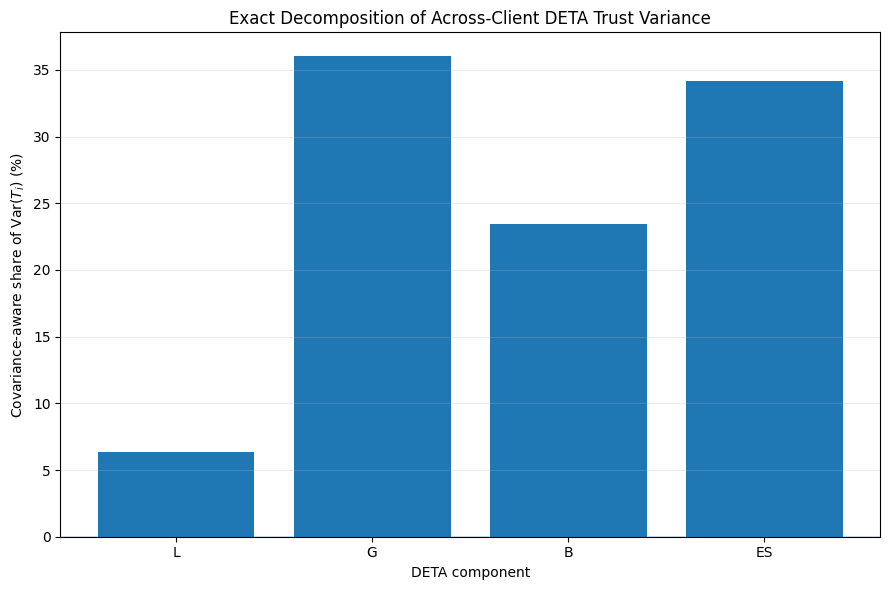

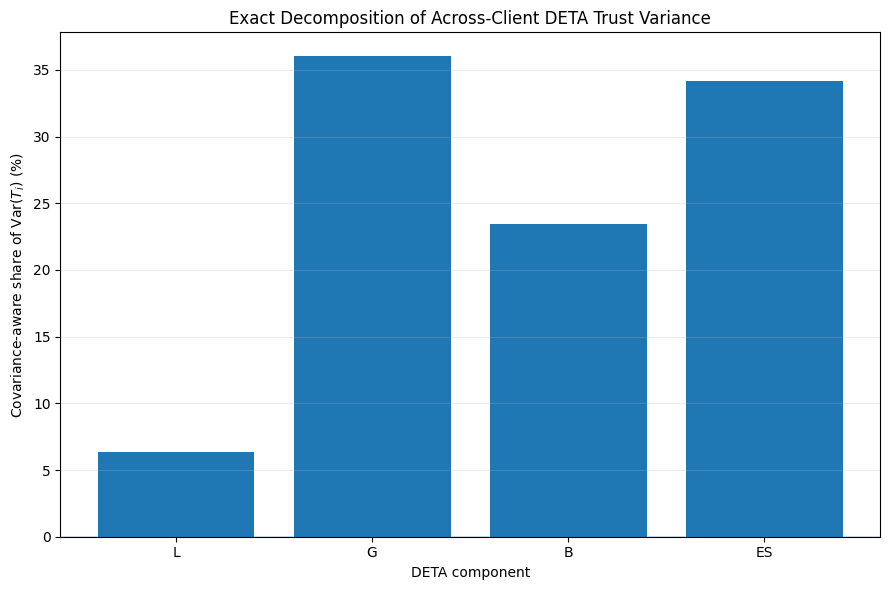


CELL 35 STATUS: PASSED — EXACT TRUST VARIANCE DECOMPOSITION COMPLETE


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TRUST_DIR = ROOT / "06_trust"
TABLE_DIR = ROOT / "13_tables"
FIG_DIR = ROOT / "12_figures/FINAL_REVIEWER_MASTER"
REPRO_DIR = ROOT / "15_reproducibility"

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

trust = pd.read_csv(
    TRUST_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


# COMPONENT CONTRIBUTIONS

components = pd.DataFrame({

    "L":
        0.20
        *
        trust[
            "L_i"
        ],

    "G":
        0.40
        *
        trust[
            "G_i"
        ],

    "B":
        0.30
        *
        trust[
            "B_i"
        ],

    "ES":
        0.10
        *
        trust[
            "ES_i"
        ],
})


T = components.sum(
    axis=1
)


# EXACT VARIANCE IDENTITY

var_T = float(
    np.var(
        T,
        ddof=1
    )
)

rows = []

for component in components.columns:

    c = components[
        component
    ].to_numpy()

    individual_variance = float(
        np.var(
            c,
            ddof=1
        )
    )

    covariance_with_total = float(
        np.cov(
            c,
            T,
            ddof=1
        )[0, 1]
    )

    exact_share = (
        covariance_with_total
        /
        var_T
        *
        100.0
    )

    rows.append({

        "Component":
            component,

        "Coefficient":
            {
                "L": 0.20,
                "G": 0.40,
                "B": 0.30,
                "ES": 0.10
            }[
                component
            ],

        "Contribution_Mean":
            float(
                np.mean(
                    c
                )
            ),

        "Contribution_SD":
            float(
                np.std(
                    c,
                    ddof=1
                )
            ),

        "Individual_Variance":
            individual_variance,

        "Covariance_With_Total_Trust":
            covariance_with_total,

        "Exact_Variance_Share_Pct":
            exact_share,
    })


variance_df = pd.DataFrame(
    rows
)

# COVARIANCE MATRIX

covariance_df = components.cov()

covariance_df.index = [
    "L_Contribution",
    "G_Contribution",
    "B_Contribution",
    "ES_Contribution"
]

covariance_df.columns = covariance_df.index

reconstructed_variance = float(
    variance_df[
        "Covariance_With_Total_Trust"
    ].sum()
)

share_sum = float(
    variance_df[
        "Exact_Variance_Share_Pct"
    ].sum()
)


print("=" * 110)
print("CELL 35 — DETA TRUST VARIANCE DECOMPOSITION")
print("=" * 110)

print(
    "\nVariance(T_i)                :",
    f"{var_T:.12f}"
)

print(
    "Sum Cov(Component,T)        :",
    f"{reconstructed_variance:.12f}"
)

print(
    "Exact variance share sum    :",
    f"{share_sum:.6f}%"
)


if not np.isclose(
    reconstructed_variance,
    var_T,
    atol=1e-12
):

    raise RuntimeError(
        "Variance decomposition identity failed."
    )


display(
    variance_df
)

print("\nComponent covariance matrix:")

display(
    covariance_df
)


# FIGURE

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    variance_df[
        "Component"
    ],
    variance_df[
        "Exact_Variance_Share_Pct"
    ]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_ylabel(
    "Covariance-aware share of Var($T_i$) (%)"
)

ax.set_xlabel(
    "DETA component"
)

ax.set_title(
    "Exact Decomposition of Across-Client DETA Trust Variance"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

FIG_PATH = (
    FIG_DIR /
    "24_DETA_exact_trust_variance_decomposition.png"
)

fig.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

display(fig)

plt.show()

plt.close(fig)


# SAVE

VARIANCE_PATH = (
    TABLE_DIR /
    "reviewer1_R6_DETA_variance_decomposition.csv"
)

COVARIANCE_PATH = (
    TABLE_DIR /
    "reviewer1_R6_DETA_component_covariance_matrix.csv"
)

MANIFEST_PATH = (
    REPRO_DIR /
    "reviewer1_R6_variance_decomposition_manifest.json"
)


variance_df.to_csv(
    VARIANCE_PATH,
    index=False
)

covariance_df.to_csv(
    COVARIANCE_PATH
)


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        {
            "reviewer": 1,
            "requirement": "R6",
            "variance_identity":
                "Var(T)=sum_k Cov(C_k,T)",
            "variance_T":
                var_T,
            "variance_share_sum_pct":
                share_sum,
            "independent_test_used":
                False
        },
        f,
        indent=4
    )


print(
    "\nCELL 35 STATUS: PASSED — "
    "EXACT TRUST VARIANCE DECOMPOSITION COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 36 — FINAL CALIBRATION ANALYSIS


,Aggregation,ECE_15Bin,MCE_15Bin,Multiclass_Brier
0,Uniform,0.078806,0.259201,0.305916
1,Size_Proportional,0.084219,0.213041,0.308804
2,DETA_Final,0.058677,0.230417,0.303559
3,DETA_Delta0,0.059957,0.231304,0.303893
4,DETA_Absolute_ES,0.063183,0.234177,0.304047


### Reviewer Figure — Expected Calibration Error

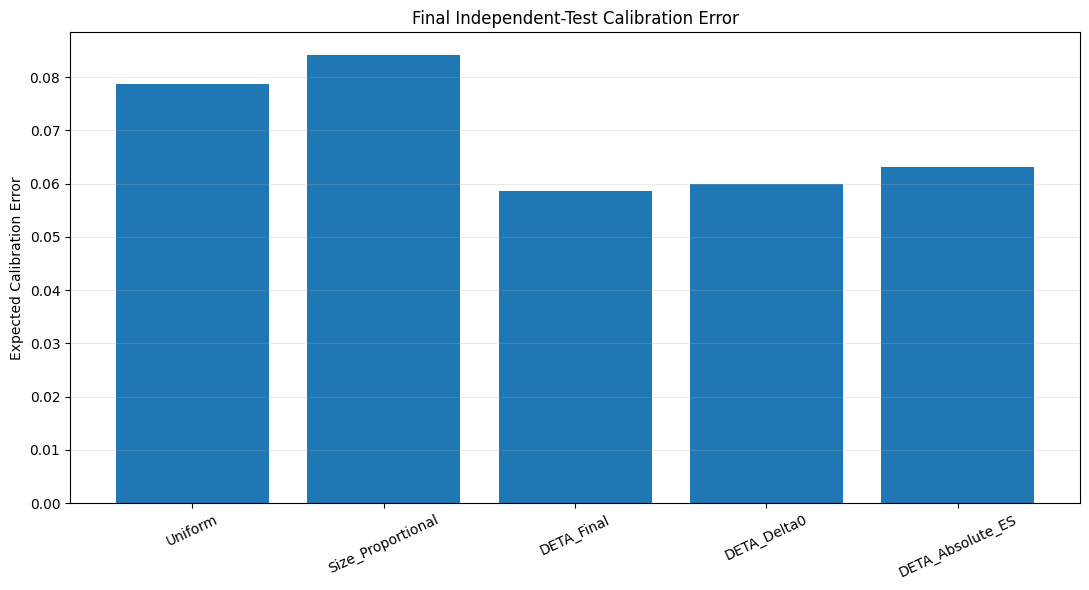

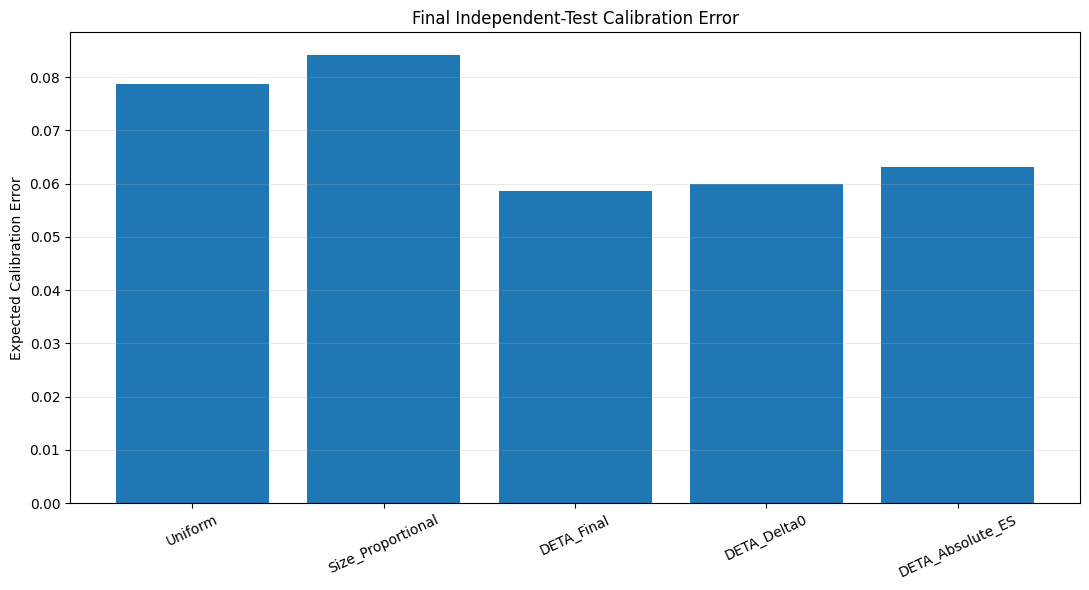

### Reliability Diagram — Uniform

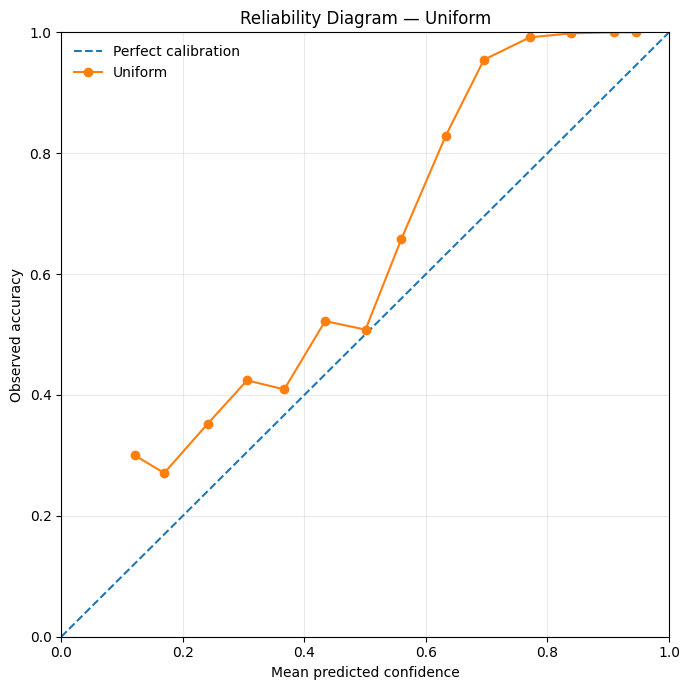

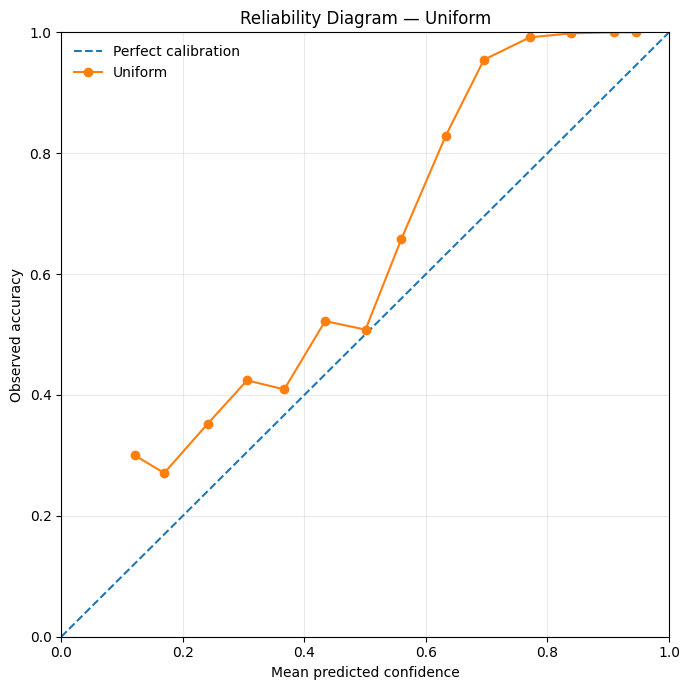

### Reliability Diagram — Size_Proportional

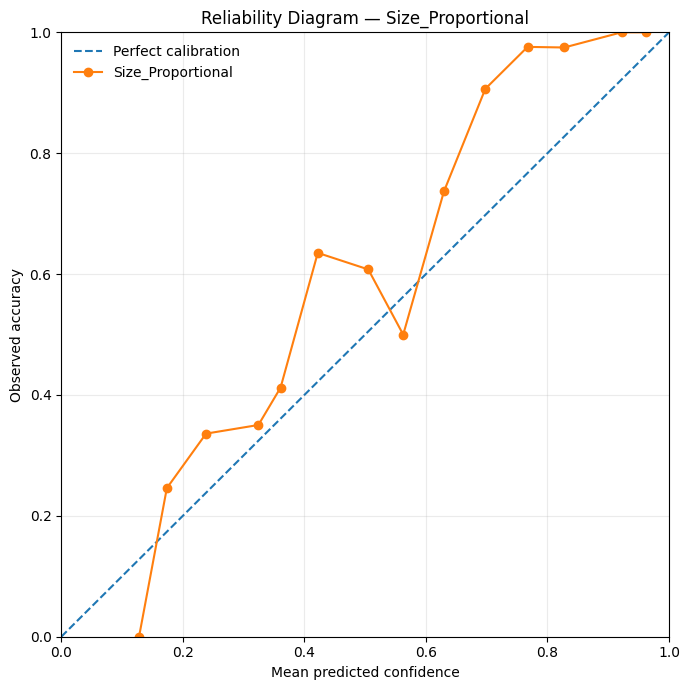

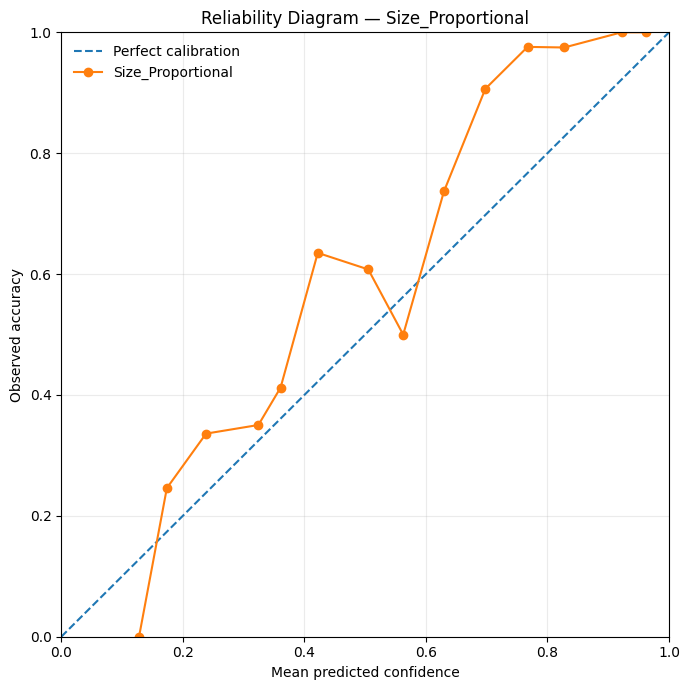

### Reliability Diagram — DETA_Final

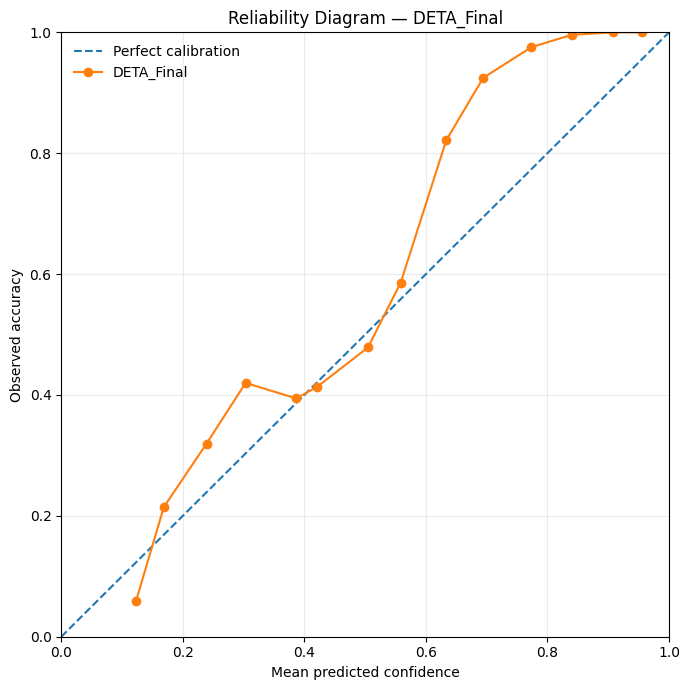

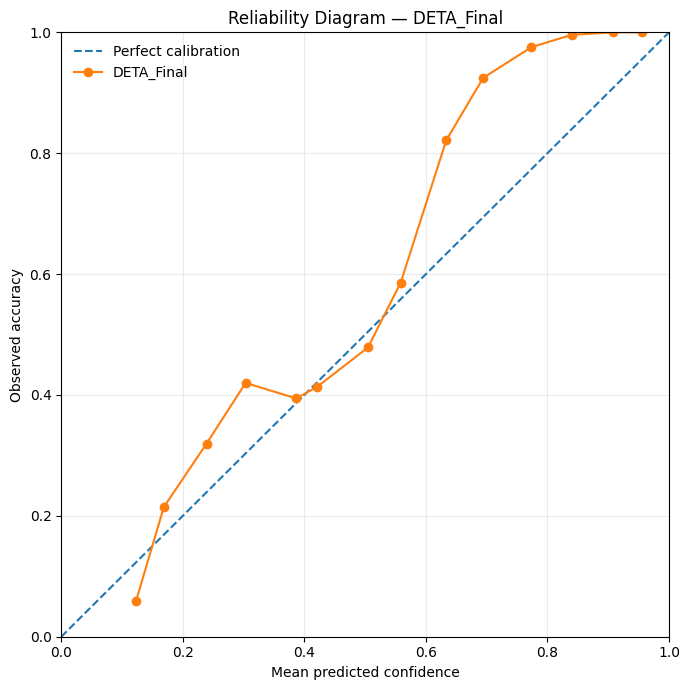

### Reliability Diagram — DETA_Delta0

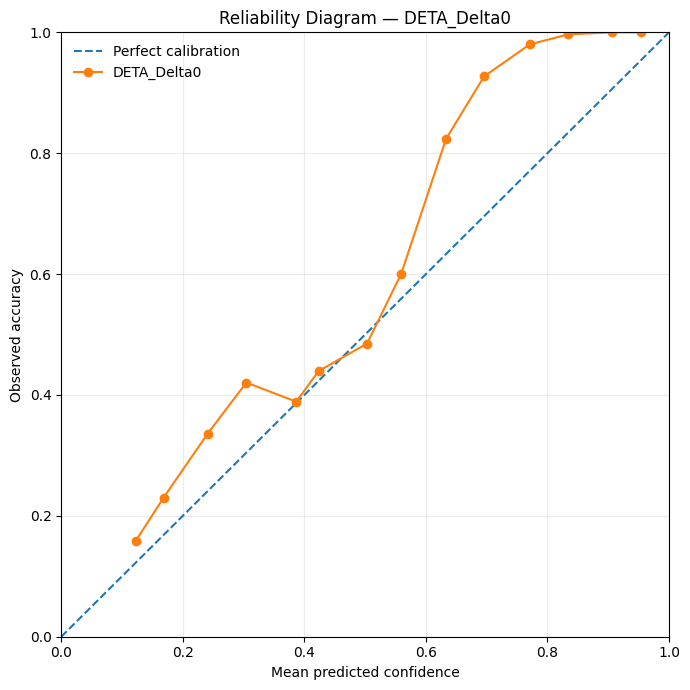

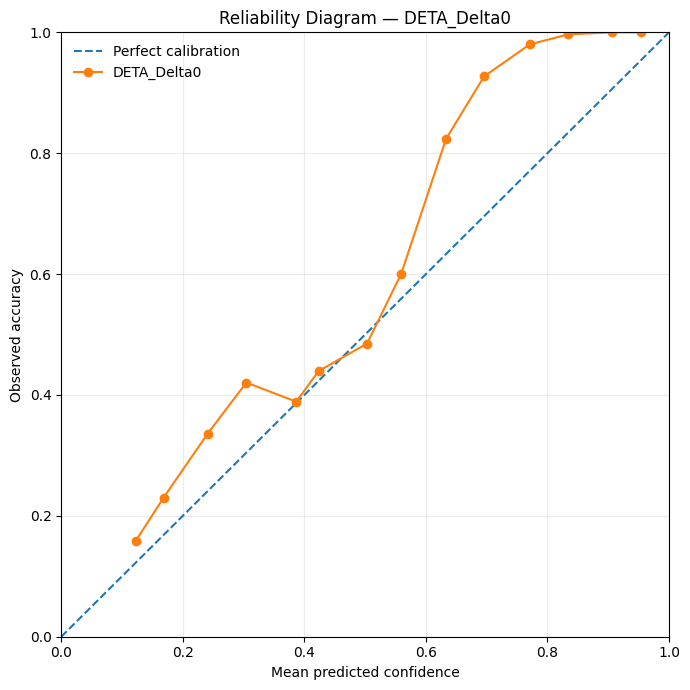

### Reliability Diagram — DETA_Absolute_ES

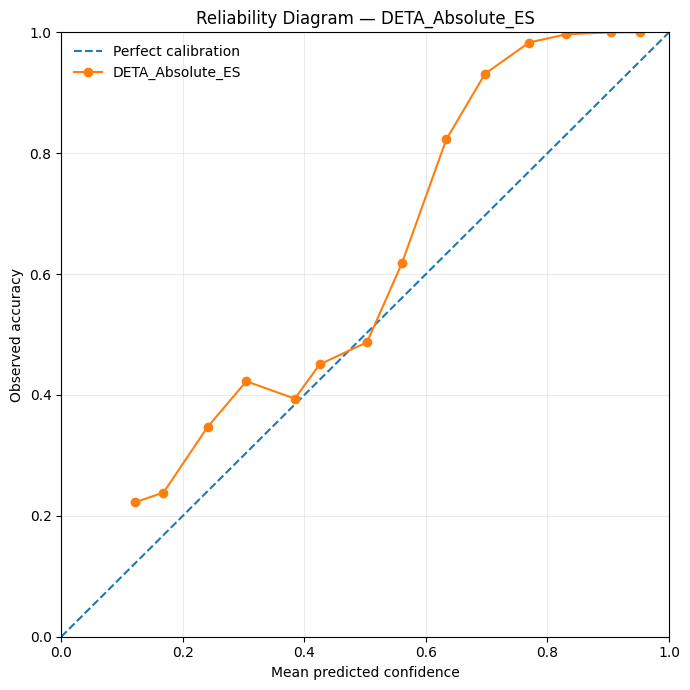

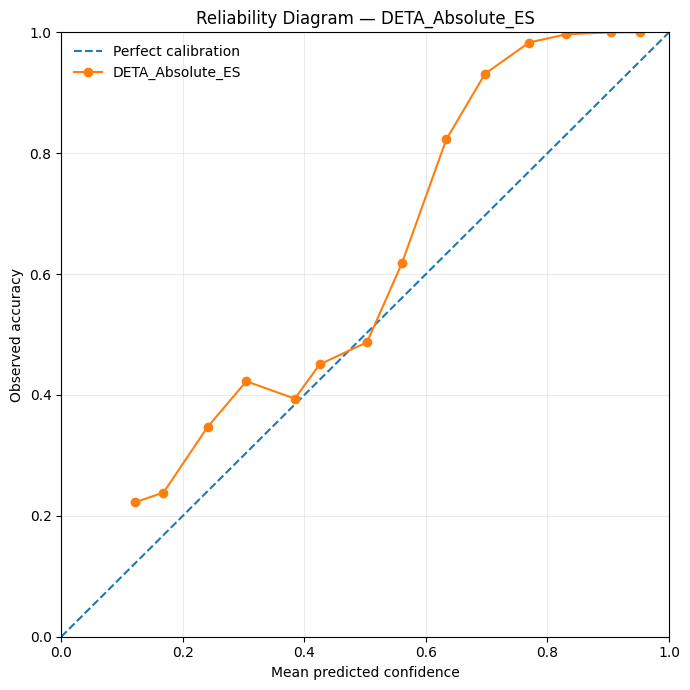


CELL 36 STATUS: PASSED — ECE + RELIABILITY ANALYSIS COMPLETE


In [ ]:
# CELL 36
# ECE + MCE + multiclass Brier score + reliability diagrams

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TABLE_DIR = ROOT / "13_tables"

PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "independent_test_FINAL" /
    "aggregated"
)

PRED_PATH = (
    ROOT /
    "11_independent_test" /
    "predictions" /
    "cell30_FINAL_DETA_independent_test_predictions.csv"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

REPRO_DIR = ROOT / "15_reproducibility"

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METHODS = [
    "Uniform",
    "Size_Proportional",
    "DETA_Final",
    "DETA_Delta0",
    "DETA_Absolute_ES",
]


prediction_df = pd.read_csv(
    PRED_PATH
)

y = prediction_df[
    "True_Label"
].to_numpy(
    dtype=np.int32
)

# CALIBRATION FUNCTIONS

def top_label_calibration(
    probabilities,
    y_true,
    n_bins=15
):

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64
    )

    confidence = np.max(
        probabilities,
        axis=1
    )

    prediction = np.argmax(
        probabilities,
        axis=1
    )

    correctness = (
        prediction
        ==
        y_true
    ).astype(
        np.float64
    )

    edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    bin_rows = []

    ece = 0.0
    mce = 0.0

    N = len(
        y_true
    )

    for b in range(
        n_bins
    ):

        low = edges[
            b
        ]

        high = edges[
            b + 1
        ]

        if b == n_bins - 1:

            mask = (
                (confidence >= low)
                &
                (confidence <= high)
            )

        else:

            mask = (
                (confidence >= low)
                &
                (confidence < high)
            )

        count = int(
            mask.sum()
        )

        if count == 0:

            accuracy = np.nan
            mean_confidence = np.nan
            gap = np.nan

        else:

            accuracy = float(
                correctness[
                    mask
                ].mean()
            )

            mean_confidence = float(
                confidence[
                    mask
                ].mean()
            )

            gap = abs(
                accuracy
                -
                mean_confidence
            )

            ece += (
                count
                /
                N
            ) * gap

            mce = max(
                mce,
                gap
            )

        bin_rows.append({

            "Bin":
                b,

            "Lower":
                low,

            "Upper":
                high,

            "Count":
                count,

            "Mean_Confidence":
                mean_confidence,

            "Observed_Accuracy":
                accuracy,

            "Absolute_Gap":
                gap,
        })

    return (
        float(
            ece
        ),
        float(
            mce
        ),
        pd.DataFrame(
            bin_rows
        )
    )


def multiclass_brier(
    probabilities,
    y_true,
    n_classes=34
):

    one_hot = np.zeros_like(
        probabilities,
        dtype=np.float64
    )

    one_hot[
        np.arange(
            len(
                y_true
            )
        ),
        y_true
    ] = 1.0

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    -
                    one_hot
                ) ** 2,
                axis=1
            )
        )
    )


# CALCULATE

summary_rows = []

calibration_tables = {}

for method in METHODS:

    path = (
        PROB_DIR /
        f"{method}_FINAL_independent_test_probabilities.npy"
    )

    probabilities = np.load(
        path
    ).astype(
        np.float64
    )

    ece, mce, bins = top_label_calibration(
        probabilities,
        y,
        n_bins=15
    )

    brier = multiclass_brier(
        probabilities,
        y
    )

    summary_rows.append({

        "Aggregation":
            method,

        "ECE_15Bin":
            ece,

        "MCE_15Bin":
            mce,

        "Multiclass_Brier":
            brier,
    })

    bins[
        "Aggregation"
    ] = method

    calibration_tables[
        method
    ] = bins


calibration_df = pd.DataFrame(
    summary_rows
)

print("=" * 110)
print("CELL 36 — FINAL CALIBRATION ANALYSIS")
print("=" * 110)

display(
    calibration_df
)


# FIGURE — COMPARATIVE ECE

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    calibration_df[
        "Aggregation"
    ],
    calibration_df[
        "ECE_15Bin"
    ]
)

ax.set_ylabel(
    "Expected Calibration Error"
)

ax.set_title(
    "Final Independent-Test Calibration Error"
)

ax.tick_params(
    axis="x",
    rotation=25
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

display(
    Markdown(
        "### Reviewer Figure — Expected Calibration Error"
    )
)

display(fig)

fig.savefig(
    FIG_DIR /
    "25_FINAL_expected_calibration_error.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    FIG_DIR /
    "25_FINAL_expected_calibration_error.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# RELIABILITY DIAGRAMS

for method in METHODS:

    bins = calibration_tables[
        method
    ].dropna(
        subset=[
            "Mean_Confidence",
            "Observed_Accuracy"
        ]
    )

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    ax.plot(
        bins[
            "Mean_Confidence"
        ],
        bins[
            "Observed_Accuracy"
        ],
        marker="o",
        label=method
    )

    ax.set_xlim(
        0,
        1
    )

    ax.set_ylim(
        0,
        1
    )

    ax.set_xlabel(
        "Mean predicted confidence"
    )

    ax.set_ylabel(
        "Observed accuracy"
    )

    ax.set_title(
        f"Reliability Diagram — {method}"
    )

    ax.legend(
        frameon=False
    )

    ax.grid(
        alpha=0.25
    )

    fig.tight_layout()

    display(
        Markdown(
            f"### Reliability Diagram — {method}"
        )
    )

    display(fig)

    fig.savefig(
        FIG_DIR /
        f"26_reliability_{method}.png",
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        FIG_DIR /
        f"26_reliability_{method}.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# SAVE

SUMMARY_PATH = (
    TABLE_DIR /
    "reviewer1_calibration_summary.csv"
)

BIN_PATH = (
    TABLE_DIR /
    "reviewer1_calibration_bins.csv"
)

MANIFEST_PATH = (
    REPRO_DIR /
    "reviewer1_calibration_analysis_manifest.json"
)


calibration_df.to_csv(
    SUMMARY_PATH,
    index=False
)

pd.concat(
    calibration_tables.values(),
    ignore_index=True
).to_csv(
    BIN_PATH,
    index=False
)


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        {
            "reviewer": 1,
            "additional_point": 4,
            "ECE_bins": 15,
            "calibration_definition":
                "top-label confidence calibration",
            "reliability_diagrams":
                True,
            "multiclass_brier":
                True,
            "models_retrained":
                False
        },
        f,
        indent=4
    )


print(
    "\nCELL 36 STATUS: PASSED — "
    "ECE + RELIABILITY ANALYSIS COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 37 — FIVE-SEED REPRODUCIBILITY + WALL-CLOCK TIMING

Pre-specified seeds:
[42, 52, 62, 72, 82]

Historical DETA:
T_i = 0.20*L_i + 0.40*G_i + 0.30*B_i + 0.10*ES_i
w_i = T_i / sum_j(T_j)

Frozen Top-30 features: 30
Feature schema: PASSED

10/10 mixed-reliability client files resolved: PASSED

Evaluation data:
Server validation: (62983, 30)
Independent test : (125987, 30)

########################################################################################################################
SEED 1/5 — 42
########################################################################################################################

SEED 42 — LOCAL MODEL RECONSTRUCTION
Client 00 | L_i=0.596135 | train=29.04s
Client 01 | L_i=0.548647 | train=21.39s
Client 02 | L_i=0.559604 | train=29.34s
Client 03 | L_i=0.574412 | train=23.23s
Client 04 | L_i=0.585567 | train=10.23s


,Seed,Method,Accuracy,Balanced_Accuracy,Macro_F1,MCC,Weighted_F1,Log_Loss
0,42,Uniform,0.742037,0.544973,0.537274,0.726945,0.717831,0.556873
1,42,Size_Proportional,0.741053,0.543996,0.542996,0.722477,0.732618,0.545028
2,42,Predictive_Only,0.736893,0.543430,0.529956,0.723694,0.703176,0.540551
3,42,Explainability_Only,0.733607,0.540917,0.522687,0.720800,0.696072,0.524001
4,42,Full_DETA,0.736187,0.542200,0.526483,0.723173,0.701039,0.537388
5,42,Plain_Soft_Voting,0.742037,0.544973,0.537274,0.726945,0.717831,0.556873
6,52,Uniform,0.741299,0.546851,0.536899,0.726260,0.716625,0.557208
7,52,Size_Proportional,0.741473,0.544985,0.543807,0.722859,0.733895,0.544907
8,52,Predictive_Only,0.737433,0.544260,0.529910,0.724133,0.703680,0.540718
9,52,Explainability_Only,0.734068,0.541484,0.523099,0.721238,0.696606,0.528209



REVIEWER-READY FIVE-SEED MEAN ± SD


,Method,Seeds,Accuracy_Mean,Accuracy_SD,Accuracy_Mean_SD,Balanced_Accuracy_Mean,Balanced_Accuracy_SD,Balanced_Accuracy_Mean_SD,Macro_F1_Mean,Macro_F1_SD,Macro_F1_Mean_SD,MCC_Mean,MCC_SD,MCC_Mean_SD,Weighted_F1_Mean,Weighted_F1_SD,Weighted_F1_Mean_SD,Log_Loss_Mean,Log_Loss_SD,Log_Loss_Mean_SD
0,Uniform,5,0.741958,0.000861,0.741958 ± 0.000861,0.545818,0.000719,0.545818 ± 0.000719,0.537143,0.000654,0.537143 ± 0.000654,0.726728,0.000762,0.726728 ± 0.000762,0.718385,0.001685,0.718385 ± 0.001685,0.556954,0.000813,0.556954 ± 0.000813
1,Plain_Soft_Voting,5,0.741958,0.000861,0.741958 ± 0.000861,0.545818,0.000719,0.545818 ± 0.000719,0.537143,0.000654,0.537143 ± 0.000654,0.726728,0.000762,0.726728 ± 0.000762,0.718385,0.001685,0.718385 ± 0.001685,0.556954,0.000813,0.556954 ± 0.000813
2,Size_Proportional,5,0.741332,0.000412,0.741332 ± 0.000412,0.544657,0.001064,0.544657 ± 0.001064,0.542886,0.001158,0.542886 ± 0.001158,0.722750,0.000287,0.722750 ± 0.000287,0.733371,0.001419,0.733371 ± 0.001419,0.544891,0.000859,0.544891 ± 0.000859
3,Predictive_Only,5,0.737117,0.000707,0.737117 ± 0.000707,0.543788,0.000679,0.543788 ± 0.000679,0.529551,0.002069,0.529551 ± 0.002069,0.723811,0.000643,0.723811 ± 0.000643,0.703675,0.001188,0.703675 ± 0.001188,0.540834,0.001232,0.540834 ± 0.001232
4,Explainability_Only,5,0.733714,0.000489,0.733714 ± 0.000489,0.541032,0.000327,0.541032 ± 0.000327,0.522114,0.001468,0.522114 ± 0.001468,0.720878,0.000414,0.720878 ± 0.000414,0.696395,0.000520,0.696395 ± 0.000520,0.527657,0.003145,0.527657 ± 0.003145
5,Full_DETA,5,0.736273,0.000771,0.736273 ± 0.000771,0.543004,0.001109,0.543004 ± 0.001109,0.527225,0.002355,0.527225 ± 0.002355,0.723160,0.000737,0.723160 ± 0.000737,0.701448,0.001183,0.701448 ± 0.001183,0.538220,0.001267,0.538220 ± 0.001267



MANUSCRIPT-READY MULTI-SEED TABLE


...


Timing summary:


,Stage,Mean_Seconds,SD_Seconds,Min_Seconds,Max_Seconds,Mean_SD
0,Local_Reconstruction_Seconds,251.547897,3.998149,246.027547,257.070245,251.548 ± 3.998
1,Server_Inference_Seconds,48.031894,1.149815,46.218647,49.267318,48.032 ± 1.150
2,SHAP_Stage_Seconds,140.002593,31.765667,124.682992,196.804575,140.003 ± 31.766
3,Trust_Computation_Seconds,0.000270,0.000072,0.000219,0.000391,0.000 ± 0.000
4,Test_Client_Inference_Seconds,96.738974,2.080638,94.242402,99.228928,96.739 ± 2.081
5,Aggregation_Evaluation_Seconds,3.562939,0.439749,3.128953,4.265642,3.563 ± 0.440
6,Total_Seed_Seconds,539.888991,30.462223,523.146660,594.104530,539.889 ± 30.462



CLIENT TRUST COMPONENT STABILITY ACROSS FIVE SEEDS


,Client_ID,Role,L_i_Mean,L_i_SD,G_i_Mean,G_i_SD,B_i_Mean,B_i_SD,ES_i_Mean,ES_i_SD,T_i_Mean,T_i_SD,DETA_Weight_Mean,DETA_Weight_SD
0,0,Reliable,0.573165,0.022036,0.463932,0.002193,0.491756,0.001827,0.970191,0.039955,0.544752,0.003600,0.114991,0.000804
1,1,Reliable,0.566219,0.014937,0.500806,0.000908,0.518140,0.001646,0.966105,0.033694,0.565619,0.005234,0.119396,0.001163
2,2,Reliable,0.571078,0.009776,0.487443,0.004243,0.510050,0.003953,0.955021,0.034352,0.557710,0.006982,0.117726,0.001481
3,3,Reliable,0.572971,0.017997,0.479375,0.002300,0.499411,0.002697,0.963783,0.022685,0.552546,0.002782,0.116636,0.000721
4,4,NonIID_Reliable,0.594958,0.024783,0.437238,0.004447,0.487394,0.004618,0.945368,0.027920,0.534642,0.003187,0.112857,0.000688
5,5,NonIID_Reliable,0.603748,0.006388,0.350835,0.002317,0.421751,0.001367,0.733038,0.082463,0.460913,0.007993,0.097292,0.001613
6,6,LabelFlip,0.236624,0.006153,0.302127,0.005554,0.389651,0.005192,0.085117,0.073740,0.293583,0.006260,0.061970,0.001182
7,7,LabelFlip,0.263520,0.003111,0.409318,0.003556,0.446355,0.001990,0.782807,0.066400,0.428618,0.007997,0.090475,0.001607
8,8,Targeted_Poison,0.608671,0.020948,0.427735,0.001403,0.480513,0.002229,0.849496,0.066966,0.521932,0.010673,0.110173,0.002223
9,9,SubsetClass_Reliable,0.794900,0.001634,0.153195,0.000533,0.186419,0.000237,0.008762,0.019591,0.277060,0.001930,0.058484,0.000401


### Reviewer Figure — Five-Seed Macro-F1 Mean ± SD

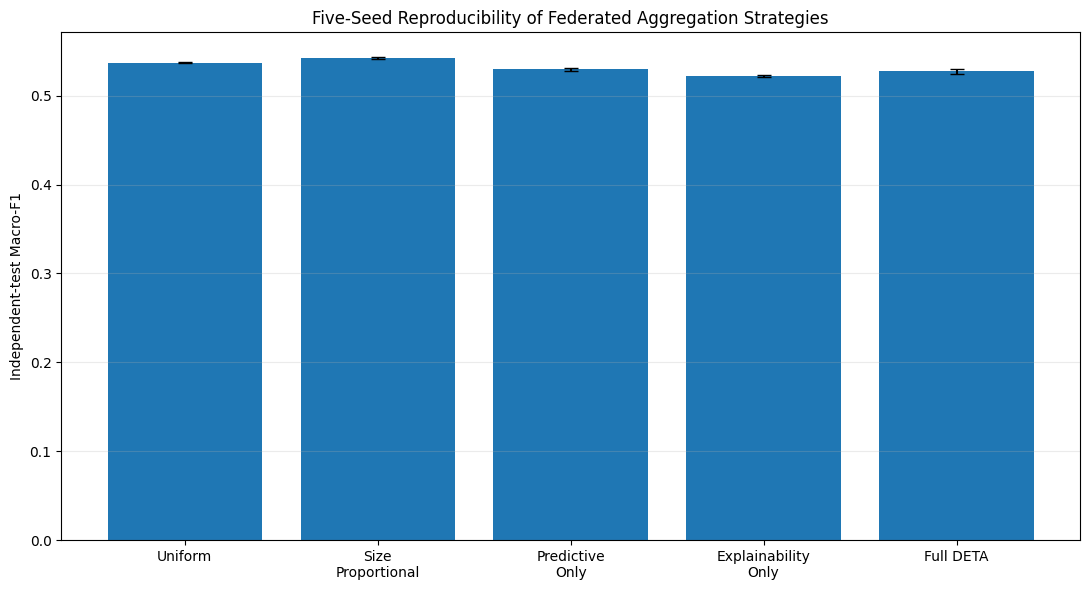

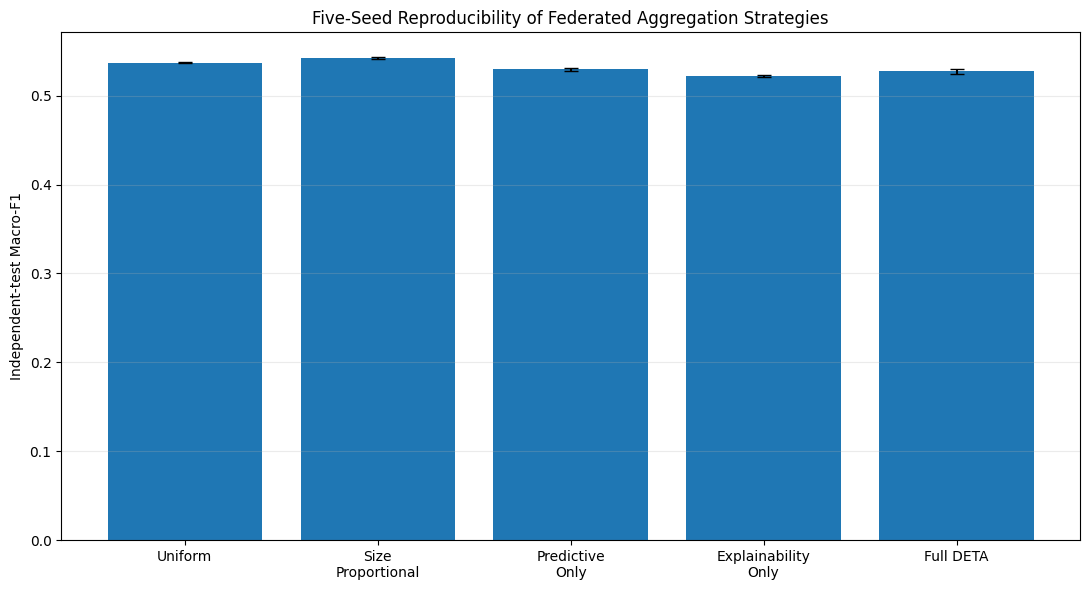

### Reviewer Figure — Measured Wall-Clock Runtime

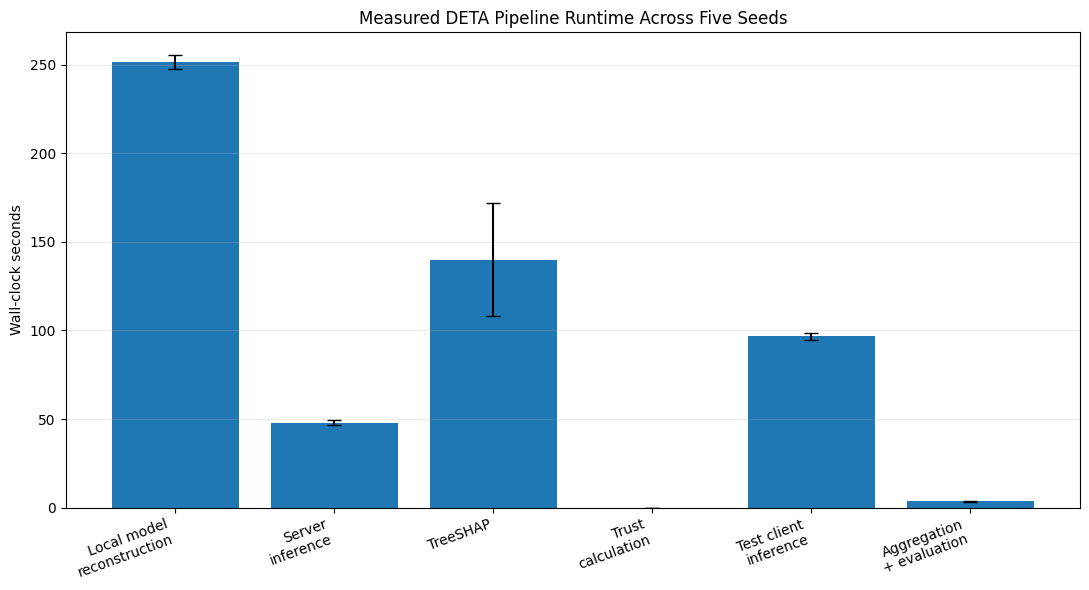

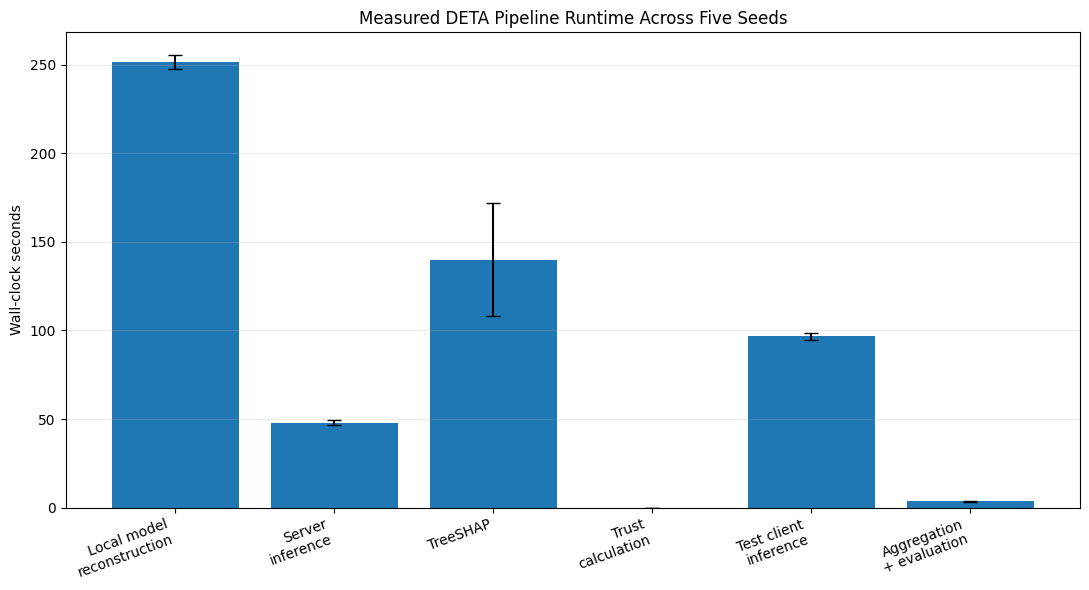


FINAL FIVE-SEED AUDIT
Seeds completed             : 5
Original seed 42 included   : YES
Additional independent seeds: 4
All seed results retained   : YES
Seed selection performed    : NO
Hyperparameters changed     : NO
Historical DETA changed     : NO
Coefficients tuned          : NO
Role labels used in trust   : NO
Test-driven model selection : NO
Wall-clock timing measured  : YES

CELL 37 COMPLETE

Reviewer 1 Additional Point 7:
Five-seed mean ± standard deviation: COMPLETE

Reviewer 1 Additional Point 9:
Measured wall-clock timing: COMPLETE

Seeds:
[42, 52, 62, 72, 82]

Manuscript-ready performance table:


,Method,Accuracy,Balanced_Accuracy,Macro_F1,MCC,Log_Loss
0,Uniform,0.741958 ± 0.000861,0.545818 ± 0.000719,0.537143 ± 0.000654,0.726728 ± 0.000762,0.556954 ± 0.000813
1,Plain_Soft_Voting,0.741958 ± 0.000861,0.545818 ± 0.000719,0.537143 ± 0.000654,0.726728 ± 0.000762,0.556954 ± 0.000813
2,Size_Proportional,0.741332 ± 0.000412,0.544657 ± 0.001064,0.542886 ± 0.001158,0.722750 ± 0.000287,0.544891 ± 0.000859
3,Predictive_Only,0.737117 ± 0.000707,0.543788 ± 0.000679,0.529551 ± 0.002069,0.723811 ± 0.000643,0.540834 ± 0.001232
4,Explainability_Only,0.733714 ± 0.000489,0.541032 ± 0.000327,0.522114 ± 0.001468,0.720878 ± 0.000414,0.527657 ± 0.003145
5,Full_DETA,0.736273 ± 0.000771,0.543004 ± 0.001109,0.527225 ± 0.002355,0.723160 ± 0.000737,0.538220 ± 0.001267



Timing summary:


,Stage,Mean_Seconds,SD_Seconds,Min_Seconds,Max_Seconds,Mean_SD
0,Local_Reconstruction_Seconds,251.547897,3.998149,246.027547,257.070245,251.548 ± 3.998
1,Server_Inference_Seconds,48.031894,1.149815,46.218647,49.267318,48.032 ± 1.150
2,SHAP_Stage_Seconds,140.002593,31.765667,124.682992,196.804575,140.003 ± 31.766
3,Trust_Computation_Seconds,0.000270,0.000072,0.000219,0.000391,0.000 ± 0.000
4,Test_Client_Inference_Seconds,96.738974,2.080638,94.242402,99.228928,96.739 ± 2.081
5,Aggregation_Evaluation_Seconds,3.562939,0.439749,3.128953,4.265642,3.563 ± 0.440
6,Total_Seed_Seconds,539.888991,30.462223,523.146660,594.104530,539.889 ± 30.462



Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_individual_results.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_mean_SD_results.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_manuscript_ready_table.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_client_components.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_client_component_summary.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_client_weights.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_client_timing.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_pipeline_timing.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_timing_summary.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/reviewer1_five_seed_client_SHAP_timing.csv
/content/drive/MyDrive

In [ ]:
# CELL 37
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import re
import json
import time
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from xgboost import XGBClassifier

from scipy.stats import spearmanr

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    log_loss
)

from IPython.display import display, Markdown


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


print("=" * 120)
print("CELL 37 — FIVE-SEED REPRODUCIBILITY + WALL-CLOCK TIMING")
print("=" * 120)


# 1. CONFIGURATION

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MIXED_DIR = (
    ROOT /
    "10_noniid_experiments" /
    "mixed_reliability"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

TEST_PATH = (
    ROOT /
    "02_partitions" /
    "independent_test" /
    "independent_test_real_clean_LOCKED.parquet"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

TOP30_JSON = (
    REPRO_DIR /
    "historical_top30_features.json"
)

MULTISEED_ROOT = (
    ROOT /
    "16_reviewer_multiseed"
)

MODEL_ROOT = (
    MULTISEED_ROOT /
    "models"
)

PROB_ROOT = (
    MULTISEED_ROOT /
    "probabilities"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

for directory in [
    MULTISEED_ROOT,
    MODEL_ROOT,
    PROB_ROOT,
    FIG_DIR,
    TABLE_DIR,
    REPRO_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# PRE-SPECIFIED SEEDS

SEEDS = [
    42,
    52,
    62,
    72,
    82,
]

N_CLIENTS = 10

N_GLOBAL_CLASSES = 34

LOCAL_VALIDATION_FRACTION = 0.20

LABEL_COL = "Label_Encoded"

SHAP_SAMPLE_SIZE = 2000

SHAP_BATCH_SIZE = 250


CLIENT_ROLES = {
    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",
    4: "NonIID_Reliable",
    5: "NonIID_Reliable",
    6: "LabelFlip",
    7: "LabelFlip",
    8: "Targeted_Poison",
    9: "SubsetClass_Reliable",
}


# Historical DETA coefficients

ALPHA_L = 0.20
BETA_G = 0.40
GAMMA_B = 0.30
DELTA_ES = 0.10


if not np.isclose(
    ALPHA_L
    +
    BETA_G
    +
    GAMMA_B
    +
    DELTA_ES,
    1.0
):

    raise RuntimeError(
        "Historical DETA coefficients do not sum to 1."
    )


print("\nPre-specified seeds:")
print(SEEDS)

print("\nHistorical DETA:")
print(
    "T_i = 0.20*L_i + 0.40*G_i + "
    "0.30*B_i + 0.10*ES_i"
)

print(
    "w_i = T_i / sum_j(T_j)"
)


# 2. LOAD FROZEN TOP-30 FEATURES

if not TOP30_JSON.exists():

    raise FileNotFoundError(
        f"Frozen Top-30 artifact missing:\n"
        f"{TOP30_JSON}"
    )


with open(
    TOP30_JSON,
    "r"
) as f:

    feature_obj = json.load(
        f
    )


FEATURES = None


if isinstance(
    feature_obj,
    list
):

    FEATURES = feature_obj


elif isinstance(
    feature_obj,
    dict
):

    for key in [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
    ]:

        if (
            key in feature_obj
            and isinstance(
                feature_obj[
                    key
                ],
                list
            )
            and len(
                feature_obj[
                    key
                ]
            ) == 30
        ):

            FEATURES = feature_obj[
                key
            ]

            break


    if FEATURES is None:

        for value in feature_obj.values():

            if (
                isinstance(
                    value,
                    list
                )
                and len(
                    value
                ) == 30
                and all(
                    isinstance(
                        x,
                        str
                    )
                    for x in value
                )
            ):

                FEATURES = value

                break


if FEATURES is None:

    raise RuntimeError(
        "Unable to recover frozen Top-30 features."
    )


FEATURES = [
    str(
        x
    )
    for x in FEATURES
]


if len(
    FEATURES
) != 30:

    raise RuntimeError(
        f"Expected 30 features; found {len(FEATURES)}."
    )


if len(
    set(
        FEATURES
    )
) != 30:

    raise RuntimeError(
        "Duplicate frozen features detected."
    )


print("\nFrozen Top-30 features:", len(FEATURES))
print("Feature schema: PASSED")


# 3. RESOLVE THE EXACT 10 MIXED-RELIABILITY CLIENT FILES

candidate_files = sorted(
    MIXED_DIR.glob(
        "client_*_mixed.parquet"
    )
)


if len(
    candidate_files
) != 10:

    raise RuntimeError(
        f"Expected exactly 10 mixed client files; "
        f"found {len(candidate_files)}."
    )


CLIENT_FILES = {}


for path in candidate_files:

    match = re.search(
        r"client_(\d+)_mixed",
        path.name
    )

    if match is None:

        raise RuntimeError(
            f"Unable to resolve client ID from {path.name}"
        )

    client_id = int(
        match.group(
            1
        )
    )

    CLIENT_FILES[
        client_id
    ] = path


if sorted(
    CLIENT_FILES.keys()
) != list(
    range(
        10
    )
):

    raise RuntimeError(
        "Expected Client_ID 0..9 exactly once."
    )


print("\n10/10 mixed-reliability client files resolved: PASSED")


# 4. LOAD SERVER VALIDATION + LOCKED TEST

server_df = pd.read_parquet(
    SERVER_PATH,
    columns=FEATURES + [LABEL_COL]
)

test_df = pd.read_parquet(
    TEST_PATH,
    columns=FEATURES + [LABEL_COL]
)


X_server = (
    server_df[
        FEATURES
    ]
    .to_numpy(
        dtype=np.float32
    )
)

y_server = (
    server_df[
        LABEL_COL
    ]
    .to_numpy(
        dtype=np.int32
    )
)


X_test = (
    test_df[
        FEATURES
    ]
    .to_numpy(
        dtype=np.float32
    )
)

y_test = (
    test_df[
        LABEL_COL
    ]
    .to_numpy(
        dtype=np.int32
    )
)


for name, X in [
    (
        "Server validation",
        X_server
    ),
    (
        "Independent test",
        X_test
    ),
]:

    if not np.isfinite(
        X
    ).all():

        raise RuntimeError(
            f"{name} contains NaN/Inf."
        )


if len(
    np.unique(
        y_server
    )
) != N_GLOBAL_CLASSES:

    raise RuntimeError(
        "Server validation does not contain all 34 classes."
    )


if len(
    np.unique(
        y_test
    )
) != N_GLOBAL_CLASSES:

    raise RuntimeError(
        "Independent test does not contain all 34 classes."
    )


print("\nEvaluation data:")
print(
    "Server validation:",
    X_server.shape
)

print(
    "Independent test :",
    X_test.shape
)


# 5. EXACT CELL 21 CLASS-PRESERVING SPLIT

def class_preserving_split(
    y,
    validation_fraction=0.20,
    random_seed=42,
):

    """
    Exact Cell 21 split logic.

    Per represented local class:

      n == 1:
          singleton remains training-only.

      n >= 2:
          approximately validation_fraction goes to validation;
          at least one observation remains training;
          at least one goes to validation.

    Guarantees:
      * no train-validation overlap;
      * complete row coverage;
      * every validation class exists in training;
      * no synthetic duplication.
    """

    y = np.asarray(
        y,
        dtype=np.int64
    )

    rng = np.random.default_rng(
        random_seed
    )

    train_parts = []

    validation_parts = []


    for class_id in np.sort(
        np.unique(
            y
        )
    ):

        class_indices = np.flatnonzero(
            y
            ==
            class_id
        ).copy()


        rng.shuffle(
            class_indices
        )


        n = len(
            class_indices
        )


        if n == 1:

            n_validation = 0


        else:

            n_validation = int(
                round(
                    n
                    *
                    validation_fraction
                )
            )


            n_validation = max(
                1,
                n_validation
            )


            n_validation = min(
                n_validation,
                n - 1
            )


        validation_class_indices = (
            class_indices[
                :n_validation
            ]
        )


        training_class_indices = (
            class_indices[
                n_validation:
            ]
        )


        if len(
            training_class_indices
        ) < 1:

            raise RuntimeError(
                f"Class {class_id} lost from training."
            )


        train_parts.append(
            training_class_indices
        )


        if n_validation > 0:

            validation_parts.append(
                validation_class_indices
            )


    train_idx = np.concatenate(
        train_parts
    ).astype(
        np.int64
    )


    validation_idx = np.concatenate(
        validation_parts
    ).astype(
        np.int64
    )


    rng.shuffle(
        train_idx
    )

    rng.shuffle(
        validation_idx
    )


    # Strict audit

    if len(
        np.intersect1d(
            train_idx,
            validation_idx
        )
    ) != 0:

        raise RuntimeError(
            "Train-validation overlap detected."
        )


    combined = np.concatenate(
        [
            train_idx,
            validation_idx,
        ]
    )


    if len(
        np.unique(
            combined
        )
    ) != len(
        y
    ):

        raise RuntimeError(
            "Split row-coverage failure."
        )


    if not np.array_equal(
        np.sort(
            combined
        ),
        np.arange(
            len(
                y
            )
        )
    ):

        raise RuntimeError(
            "Split index coverage audit failed."
        )


    training_classes = set(
        np.unique(
            y[
                train_idx
            ]
        ).tolist()
    )


    validation_classes = set(
        np.unique(
            y[
                validation_idx
            ]
        ).tolist()
    )


    if not validation_classes.issubset(
        training_classes
    ):

        raise RuntimeError(
            "Validation class absent from training."
        )


    return (
        train_idx,
        validation_idx
    )


# 6. GLOBAL PROBABILITY RECONSTRUCTION

def expand_to_global_probabilities(
    local_probabilities,
    local_to_global_classes,
    n_global_classes=34,
):

    local_probabilities = np.asarray(
        local_probabilities,
        dtype=np.float64
    )


    global_classes = np.asarray(
        local_to_global_classes,
        dtype=np.int64
    )


    if local_probabilities.ndim != 2:

        raise RuntimeError(
            "Local probability matrix must be 2D."
        )


    if (
        local_probabilities.shape[
            1
        ]
        !=
        len(
            global_classes
        )
    ):

        raise RuntimeError(
            "Probability-column/class-mapping mismatch."
        )


    global_probabilities = np.zeros(
        (
            local_probabilities.shape[
                0
            ],
            n_global_classes
        ),
        dtype=np.float64
    )


    global_probabilities[
        :,
        global_classes
    ] = local_probabilities


    row_sums = global_probabilities.sum(
        axis=1,
        keepdims=True
    )


    if np.any(
        row_sums <= 0
    ):

        raise RuntimeError(
            "Zero probability sum."
        )


    global_probabilities /= row_sums


    return global_probabilities


# 7. HISTORICAL DIRECT-SUM NORMALIZATION

def direct_sum_normalization(
    trust_scores
):

    trust_scores = np.asarray(
        trust_scores,
        dtype=np.float64
    )


    if not np.isfinite(
        trust_scores
    ).all():

        raise RuntimeError(
            "Non-finite trust score."
        )


    if np.any(
        trust_scores < 0
    ):

        raise RuntimeError(
            "Negative trust score."
        )


    total = trust_scores.sum()


    if total <= 0:

        raise RuntimeError(
            "Trust sum <= 0."
        )


    weights = (
        trust_scores
        /
        total
    )


    if not np.isclose(
        weights.sum(),
        1.0,
        atol=1e-12
    ):

        raise RuntimeError(
            "Trust normalization failed."
        )


    return weights


# 8. PROBABILITY NORMALIZATION

def normalize_probability_rows(
    probabilities
):

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64
    )


    probabilities = np.clip(
        probabilities,
        1e-15,
        None
    )


    row_sums = probabilities.sum(
        axis=1,
        keepdims=True
    )


    if np.any(
        row_sums <= 0
    ):

        raise RuntimeError(
            "Invalid probability row."
        )


    probabilities = (
        probabilities
        /
        row_sums
    )


    return probabilities



def proportional_class_preserving_sample(
    df,
    target_col,
    sample_size,
    random_seed,
):

    if sample_size > len(
        df
    ):

        raise ValueError(
            "Requested SHAP sample exceeds server validation."
        )


    counts = (
        df[
            target_col
        ]
        .value_counts()
        .sort_index()
    )


    classes = counts.index.to_numpy(
        dtype=np.int32
    )


    class_counts = counts.to_numpy(
        dtype=np.int64
    )


    n_classes = len(
        classes
    )


    if sample_size < n_classes:

        raise ValueError(
            "SHAP sample size must be >= represented classes."
        )


    quotas = np.ones(
        n_classes,
        dtype=np.int64
    )


    remaining_slots = (
        sample_size
        -
        quotas.sum()
    )


    remaining_capacity = (
        class_counts
        -
        quotas
    )


    if remaining_slots > 0:

        proportions = (
            class_counts
            /
            class_counts.sum()
        )


        ideal_extra = (
            proportions
            *
            remaining_slots
        )


        base_extra = np.floor(
            ideal_extra
        ).astype(
            np.int64
        )


        base_extra = np.minimum(
            base_extra,
            remaining_capacity
        )


        quotas += base_extra


        remaining_slots = (
            sample_size
            -
            quotas.sum()
        )


        remainders = (
            ideal_extra
            -
            np.floor(
                ideal_extra
            )
        )


        while remaining_slots > 0:

            eligible = np.where(
                quotas
                <
                class_counts
            )[0]


            if len(
                eligible
            ) == 0:

                raise RuntimeError(
                    "Could not complete SHAP allocation."
                )


            eligible_order = eligible[
                np.argsort(
                    -remainders[
                        eligible
                    ]
                )
            ]


            allocated_this_round = 0


            for j in eligible_order:

                if (
                    quotas[
                        j
                    ]
                    <
                    class_counts[
                        j
                    ]
                ):

                    quotas[
                        j
                    ] += 1

                    remaining_slots -= 1

                    allocated_this_round += 1


                    if remaining_slots == 0:

                        break


            if allocated_this_round == 0:

                raise RuntimeError(
                    "SHAP quota allocation stalled."
                )


    if quotas.sum() != sample_size:

        raise RuntimeError(
            "Exact SHAP sample-size allocation failed."
        )


    selected_indices = []


    for class_id, quota in zip(
        classes,
        quotas
    ):

        class_index = df.index[
            df[
                target_col
            ]
            ==
            class_id
        ].to_numpy()


        rng_class = np.random.default_rng(
            random_seed
            +
            int(
                class_id
            )
            *
            1009
        )


        chosen = rng_class.choice(
            class_index,
            size=int(
                quota
            ),
            replace=False
        )


        selected_indices.extend(
            chosen.tolist()
        )


    selected_indices = np.array(
        selected_indices
    )


    rng = np.random.default_rng(
        random_seed
    )


    rng.shuffle(
        selected_indices
    )


    sample = df.loc[
        selected_indices
    ].copy()


    if len(
        sample
    ) != sample_size:

        raise RuntimeError(
            "Final SHAP sample-size mismatch."
        )


    if (
        sample[
            target_col
        ].nunique()
        !=
        n_classes
    ):

        raise RuntimeError(
            "SHAP sample lost represented class."
        )


    return sample


# 10. EXACT CELL 23 TREE-SHAP

def mean_absolute_tree_shap(
    booster,
    X,
    n_features,
    batch_size=250,
):

    total_abs = np.zeros(
        n_features,
        dtype=np.float64
    )


    total_units = 0


    for start in range(
        0,
        len(
            X
        ),
        batch_size
    ):

        end = min(
            start
            +
            batch_size,
            len(
                X
            )
        )


        X_batch = X[
            start:end
        ]


        dmatrix = xgb.DMatrix(
            X_batch
        )


        contrib = booster.predict(
            dmatrix,
            pred_contribs=True,
            validate_features=False
        )


        contrib = np.asarray(
            contrib
        )


        if contrib.ndim == 3:

            if (
                contrib.shape[
                    -1
                ]
                !=
                n_features
                +
                1
            ):

                raise RuntimeError(
                    f"Unexpected 3D SHAP shape: "
                    f"{contrib.shape}"
                )


            values = contrib[
                ...,
                :-1
            ]


            total_abs += np.abs(
                values
            ).sum(
                axis=(
                    0,
                    1
                )
            )


            total_units += (
                values.shape[
                    0
                ]
                *
                values.shape[
                    1
                ]
            )


        elif contrib.ndim == 2:

            if (
                contrib.shape[
                    1
                ]
                ==
                n_features
                +
                1
            ):

                values = contrib[
                    :,
                    :-1
                ]


                total_abs += np.abs(
                    values
                ).sum(
                    axis=0
                )


                total_units += values.shape[
                    0
                ]


            elif (
                contrib.shape[
                    1
                ]
                %
                (
                    n_features
                    +
                    1
                )
                ==
                0
            ):

                inferred_classes = (
                    contrib.shape[
                        1
                    ]
                    //
                    (
                        n_features
                        +
                        1
                    )
                )


                values = contrib.reshape(
                    contrib.shape[
                        0
                    ],
                    inferred_classes,
                    n_features
                    +
                    1
                )[
                    ...,
                    :-1
                ]


                total_abs += np.abs(
                    values
                ).sum(
                    axis=(
                        0,
                        1
                    )
                )


                total_units += (
                    values.shape[
                        0
                    ]
                    *
                    values.shape[
                        1
                    ]
                )


            else:

                raise RuntimeError(
                    f"Unexpected 2D SHAP shape: "
                    f"{contrib.shape}"
                )


        else:

            raise RuntimeError(
                f"Unexpected SHAP dimensionality: "
                f"{contrib.shape}"
            )


        del dmatrix
        del contrib

        gc.collect()


    if total_units <= 0:

        raise RuntimeError(
            "No valid TreeSHAP units produced."
        )


    mean_abs = (
        total_abs
        /
        float(
            total_units
        )
    )


    if not np.isfinite(
        mean_abs
    ).all():

        raise RuntimeError(
            "Non-finite SHAP result."
        )


    return mean_abs


def normalize_importance(
    importance
):

    importance = np.asarray(
        importance,
        dtype=np.float64
    )


    total = importance.sum()


    if total <= 0:

        raise RuntimeError(
            "Zero-total SHAP importance."
        )


    normalized = (
        importance
        /
        total
    )


    if not np.isclose(
        normalized.sum(),
        1.0,
        atol=1e-12
    ):

        raise RuntimeError(
            "SHAP importance normalization failed."
        )


    return normalized


# 11. METRIC HELPERS

def evaluate_probabilities(
    y_true,
    probabilities
):

    probabilities = normalize_probability_rows(
        probabilities
    )


    predictions = np.argmax(
        probabilities,
        axis=1
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    predictions
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    predictions
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true,
                    predictions,
                    labels=np.arange(
                        N_GLOBAL_CLASSES
                    ),
                    average="macro",
                    zero_division=0
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    y_true,
                    predictions
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    y_true,
                    predictions,
                    average="weighted",
                    zero_division=0
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_true,
                    probabilities,
                    labels=np.arange(
                        N_GLOBAL_CLASSES
                    )
                )
            ),
    }


def aggregate_client_probabilities(
    client_probabilities,
    weights
):

    stack = np.stack(
        client_probabilities,
        axis=0
    )


    aggregate = np.tensordot(
        weights,
        stack,
        axes=(
            0,
            0
        )
    )


    return normalize_probability_rows(
        aggregate
    )


# 12. MULTI-SEED OUTPUT CONTAINERS

seed_metric_rows = []

client_component_rows = []

client_timing_rows = []

seed_timing_rows = []

seed_weight_rows = []

seed_shap_rows = []


# 13. FIVE-SEED LOOP

for seed_index, seed in enumerate(
    SEEDS,
    start=1
):

    print("\n" + "#" * 120)
    print(
        f"SEED {seed_index}/{len(SEEDS)} — {seed}"
    )
    print("#" * 120)


    seed_start = time.perf_counter()


    seed_model_dir = (
        MODEL_ROOT /
        f"seed_{seed}"
    )


    seed_prob_dir = (
        PROB_ROOT /
        f"seed_{seed}"
    )


    seed_model_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    seed_prob_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    # A. EXACT CELL 21 LOCAL RECONSTRUCTION

    print("\n" + "=" * 120)
    print(
        f"SEED {seed} — LOCAL MODEL RECONSTRUCTION"
    )
    print("=" * 120)


    models = {}

    local_to_global_maps = {}

    L_values = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )

    TRAINING_ROWS = np.zeros(
        N_CLIENTS,
        dtype=np.int64
    )


    local_stage_start = time.perf_counter()


    for client_id in range(
        N_CLIENTS
    ):

        client_total_start = time.perf_counter()


        df = pd.read_parquet(
            CLIENT_FILES[
                client_id
            ],
            columns=FEATURES + [LABEL_COL]
        )


        X = df[
            FEATURES
        ].to_numpy(
            dtype=np.float32
        )


        y_visible = df[
            LABEL_COL
        ].to_numpy(
            dtype=np.int32
        )


        if not np.isfinite(
            X
        ).all():

            raise RuntimeError(
                f"Seed {seed}, Client {client_id}: "
                "NaN/Inf in local data."
            )


        # seed-specific generalization of RANDOM_SEED + client_id

        split_start = time.perf_counter()


        train_idx, val_idx = class_preserving_split(
            y=y_visible,
            validation_fraction=LOCAL_VALIDATION_FRACTION,
            random_seed=seed + client_id,
        )


        split_seconds = (
            time.perf_counter()
            -
            split_start
        )


        X_train = X[
            train_idx
        ]


        X_val = X[
            val_idx
        ]


        y_train_global = y_visible[
            train_idx
        ]


        y_val_global = y_visible[
            val_idx
        ]


        TRAINING_ROWS[
            client_id
        ] = len(
            train_idx
        )


        train_global_classes = np.sort(
            np.unique(
                y_train_global
            )
        )


        local_to_global = (
            train_global_classes.copy()
        )


        global_to_local = {
            int(
                global_class
            ):
            int(
                local_index
            )

            for local_index, global_class
            in enumerate(
                local_to_global
            )
        }


        y_train_local = np.array(
            [
                global_to_local[
                    int(
                        value
                    )
                ]

                for value in y_train_global
            ],
            dtype=np.int32
        )


        n_local_classes = len(
            local_to_global
        )


        if n_local_classes < 2:

            raise RuntimeError(
                f"Seed {seed}, Client {client_id}: "
                "<2 local classes."
            )


        XGB_PARAMS = {

            "n_estimators":
                100,

            "max_depth":
                8,

            "learning_rate":
                0.1,

            "objective":
                "multi:softprob",

            "tree_method":
                "hist",

            "random_state":
                seed,

            "n_jobs":
                -1,

            "eval_metric":
                "mlogloss",

            "num_class":
                int(
                    n_local_classes
                ),
        }


        model = XGBClassifier(
            **XGB_PARAMS
        )


        training_start = time.perf_counter()


        model.fit(
            X_train,
            y_train_local,
            verbose=False
        )


        training_seconds = (
            time.perf_counter()
            -
            training_start
        )


        validation_start = time.perf_counter()


        local_val_prob = model.predict_proba(
            X_val
        )


        global_val_prob = expand_to_global_probabilities(
            local_probabilities=local_val_prob,
            local_to_global_classes=local_to_global,
            n_global_classes=N_GLOBAL_CLASSES,
        )


        pred_global = np.argmax(
            global_val_prob,
            axis=1
        ).astype(
            np.int32
        )


        validation_seconds = (
            time.perf_counter()
            -
            validation_start
        )


        # Exact historical L_i

        L_i = f1_score(
            y_val_global,
            pred_global,
            average="macro",
            zero_division=0
        )


        L_values[
            client_id
        ] = L_i


        # Save seed-specific model — DO NOT overwrite Cell 21 frozen models

        model_path = (
            seed_model_dir /
            f"client_{client_id:02d}_xgb.json"
        )


        model.save_model(
            model_path
        )


        models[
            client_id
        ] = model


        local_to_global_maps[
            client_id
        ] = local_to_global


        client_total_seconds = (
            time.perf_counter()
            -
            client_total_start
        )


        client_timing_rows.append({

            "Seed":
                seed,

            "Client_ID":
                client_id,

            "Role":
                CLIENT_ROLES[
                    client_id
                ],

            "Split_Seconds":
                split_seconds,

            "Training_Seconds":
                training_seconds,

            "Local_Validation_Inference_Seconds":
                validation_seconds,

            "Local_Total_Seconds":
                client_total_seconds,

            "Train_Rows":
                len(
                    train_idx
                ),

            "Validation_Rows":
                len(
                    val_idx
                ),

            "Local_Classes":
                n_local_classes,

            "L_i":
                L_i,
        })


        print(
            f"Client {client_id:02d} | "
            f"L_i={L_i:.6f} | "
            f"train={training_seconds:.2f}s"
        )


        del df
        del X
        del X_train
        del X_val
        del y_visible
        del y_train_global
        del y_val_global
        del local_val_prob
        del global_val_prob

        gc.collect()


    local_stage_seconds = (
        time.perf_counter()
        -
        local_stage_start
    )


    # B. EXACT CELL 22 SERVER G_i + B_i

    print("\n" + "=" * 120)
    print(
        f"SEED {seed} — RESERVED SERVER COMPONENTS"
    )
    print("=" * 120)


    G_values = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )


    B_values = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )


    server_client_probabilities = []


    server_stage_start = time.perf_counter()


    for client_id in range(
        N_CLIENTS
    ):

        inference_start = time.perf_counter()


        local_prob = models[
            client_id
        ].predict_proba(
            X_server
        )


        global_prob = expand_to_global_probabilities(
            local_probabilities=local_prob,
            local_to_global_classes=local_to_global_maps[
                client_id
            ],
            n_global_classes=N_GLOBAL_CLASSES,
        )


        server_pred = np.argmax(
            global_prob,
            axis=1
        )


        # ----------------------------------------------------------------------------------
        # G_i = server-validation fixed-global-34 Macro-F1
        # ----------------------------------------------------------------------------------

        G_i = f1_score(
            y_server,
            server_pred,
            labels=np.arange(
                N_GLOBAL_CLASSES
            ),
            average="macro",
            zero_division=0
        )


        # ----------------------------------------------------------------------------------
        # B_i = server-validation Balanced Accuracy
        # ----------------------------------------------------------------------------------

        B_i = balanced_accuracy_score(
            y_server,
            server_pred
        )


        inference_seconds = (
            time.perf_counter()
            -
            inference_start
        )


        G_values[
            client_id
        ] = G_i


        B_values[
            client_id
        ] = B_i


        server_client_probabilities.append(
            global_prob
        )


        client_timing_rows.append({

            "Seed":
                seed,

            "Client_ID":
                client_id,

            "Role":
                CLIENT_ROLES[
                    client_id
                ],

            "Stage":
                "Server_Inference",

            "Server_Inference_Seconds":
                inference_seconds,

            "G_i":
                G_i,

            "B_i":
                B_i,
        })


        print(
            f"Client {client_id:02d} | "
            f"G_i={G_i:.6f} | "
            f"B_i={B_i:.6f}"
        )


    server_stage_seconds = (
        time.perf_counter()
        -
        server_stage_start
    )


    # C. EXACT CELL 23 SHAP ES_i

    print("\n" + "=" * 120)
    print(
        f"SEED {seed} — SHAP EXPLAINABILITY STABILITY"
    )
    print("=" * 120)


    shap_stage_start = time.perf_counter()


    shap_df = proportional_class_preserving_sample(
        df=server_df,
        target_col=LABEL_COL,
        sample_size=SHAP_SAMPLE_SIZE,
        random_seed=seed,
    )


    X_shap = shap_df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    )


    if not np.isfinite(
        X_shap
    ).all():

        raise RuntimeError(
            "SHAP sample contains NaN/Inf."
        )


    importance_vectors = []


    for client_id in range(
        N_CLIENTS
    ):

        client_shap_start = time.perf_counter()


        booster = models[
            client_id
        ].get_booster()


        mean_abs_shap = mean_absolute_tree_shap(
            booster=booster,
            X=X_shap,
            n_features=len(
                FEATURES
            ),
            batch_size=SHAP_BATCH_SIZE,
        )


        normalized_shap = normalize_importance(
            mean_abs_shap
        )


        importance_vectors.append(
            normalized_shap
        )


        client_shap_seconds = (
            time.perf_counter()
            -
            client_shap_start
        )


        print(
            f"Client {client_id:02d} TreeSHAP: "
            f"{client_shap_seconds:.2f}s"
        )


        seed_shap_rows.append({

            "Seed":
                seed,

            "Client_ID":
                client_id,

            "Role":
                CLIENT_ROLES[
                    client_id
                ],

            "SHAP_Seconds":
                client_shap_seconds,
        })


    importance_matrix = np.vstack(
        importance_vectors
    )


    # --------------------------------------------------------------------------------------
    # Historical consensus
    # --------------------------------------------------------------------------------------

    consensus_importance = normalize_importance(
        importance_matrix.mean(
            axis=0
        )
    )


    consensus_ranks = pd.Series(
        consensus_importance
    ).rank(
        ascending=False,
        method="average"
    ).to_numpy(
        dtype=np.float64
    )


    rho_values = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )


    for client_id in range(
        N_CLIENTS
    ):

        client_ranks = pd.Series(
            importance_matrix[
                client_id
            ]
        ).rank(
            ascending=False,
            method="average"
        ).to_numpy(
            dtype=np.float64
        )


        rho, _ = spearmanr(
            client_ranks,
            consensus_ranks
        )


        if not np.isfinite(
            rho
        ):

            raise RuntimeError(
                f"Seed {seed}, Client {client_id}: "
                "non-finite Spearman rho."
            )


        rho_values[
            client_id
        ] = rho


    rho_min = float(
        rho_values.min()
    )


    rho_max = float(
        rho_values.max()
    )


    if np.isclose(
        rho_min,
        rho_max
    ):

        ES_values = np.ones(
            N_CLIENTS,
            dtype=np.float64
        )


    else:

        ES_values = (
            rho_values
            -
            rho_min
        ) / (
            rho_max
            -
            rho_min
        )


    shap_stage_seconds = (
        time.perf_counter()
        -
        shap_stage_start
    )


    print(
        "\nSHAP rho range:",
        f"{rho_min:.6f} to {rho_max:.6f}"
    )

    print(
        "Historical ES_i range:",
        f"{ES_values.min():.6f} to {ES_values.max():.6f}"
    )


    # D. HISTORICAL TRUST
    trust_start = time.perf_counter()


    T_full = (
        ALPHA_L
        *
        L_values
        +
        BETA_G
        *
        G_values
        +
        GAMMA_B
        *
        B_values
        +
        DELTA_ES
        *
        ES_values
    )


    FULL_WEIGHTS = direct_sum_normalization(
        T_full
    )


    T_predictive = (
        ALPHA_L
        *
        L_values
        +
        BETA_G
        *
        G_values
        +
        GAMMA_B
        *
        B_values
    )


    PREDICTIVE_WEIGHTS = direct_sum_normalization(
        T_predictive
    )


    if ES_values.sum() <= 0:

        EXPLAINABILITY_WEIGHTS = np.repeat(
            1.0
            /
            N_CLIENTS,
            N_CLIENTS
        )


    else:

        EXPLAINABILITY_WEIGHTS = direct_sum_normalization(
            ES_values
        )


    UNIFORM_WEIGHTS = np.repeat(
        1.0
        /
        N_CLIENTS,
        N_CLIENTS
    )


    SIZE_WEIGHTS = (
        TRAINING_ROWS.astype(
            np.float64
        )
        /
        TRAINING_ROWS.sum()
    )


    trust_seconds = (
        time.perf_counter()
        -
        trust_start
    )


    for client_id in range(
        N_CLIENTS
    ):

        client_component_rows.append({

            "Seed":
                seed,

            "Client_ID":
                client_id,

            "Role":
                CLIENT_ROLES[
                    client_id
                ],

            "L_i":
                L_values[
                    client_id
                ],

            "G_i":
                G_values[
                    client_id
                ],

            "B_i":
                B_values[
                    client_id
                ],

            "Spearman_Rho":
                rho_values[
                    client_id
                ],

            "ES_i":
                ES_values[
                    client_id
                ],

            "T_i":
                T_full[
                    client_id
                ],

            "Full_DETA_Weight":
                FULL_WEIGHTS[
                    client_id
                ],

            "Predictive_Only_Weight":
                PREDICTIVE_WEIGHTS[
                    client_id
                ],

            "Explainability_Only_Weight":
                EXPLAINABILITY_WEIGHTS[
                    client_id
                ],

            "Uniform_Weight":
                UNIFORM_WEIGHTS[
                    client_id
                ],

            "Size_Proportional_Weight":
                SIZE_WEIGHTS[
                    client_id
                ],
        })


        seed_weight_rows.append({

            "Seed":
                seed,

            "Client_ID":
                client_id,

            "Uniform":
                UNIFORM_WEIGHTS[
                    client_id
                ],

            "Size_Proportional":
                SIZE_WEIGHTS[
                    client_id
                ],

            "Predictive_Only":
                PREDICTIVE_WEIGHTS[
                    client_id
                ],

            "Explainability_Only":
                EXPLAINABILITY_WEIGHTS[
                    client_id
                ],

            "Full_DETA":
                FULL_WEIGHTS[
                    client_id
                ],
        })


    # E. FINAL TEST INFERENCE FROM THE SEED-SPECIFIC CLIENT MODELS

    print("\n" + "=" * 120)
    print(
        f"SEED {seed} — LOCKED TEST REPORTING"
    )
    print("=" * 120)


    test_inference_start = time.perf_counter()


    test_client_probabilities = []


    for client_id in range(
        N_CLIENTS
    ):

        local_prob = models[
            client_id
        ].predict_proba(
            X_test
        )


        global_prob = expand_to_global_probabilities(
            local_probabilities=local_prob,
            local_to_global_classes=local_to_global_maps[
                client_id
            ],
            n_global_classes=N_GLOBAL_CLASSES,
        )


        test_client_probabilities.append(
            global_prob
        )


    test_inference_seconds = (
        time.perf_counter()
        -
        test_inference_start
    )


    # F. AGGREGATION + METRICS

    aggregation_start = time.perf_counter()


    aggregation_weights = {

        "Uniform":
            UNIFORM_WEIGHTS,

        "Size_Proportional":
            SIZE_WEIGHTS,

        "Predictive_Only":
            PREDICTIVE_WEIGHTS,

        "Explainability_Only":
            EXPLAINABILITY_WEIGHTS,

        "Full_DETA":
            FULL_WEIGHTS,
    }


    for method, weights in aggregation_weights.items():

        aggregate_prob = aggregate_client_probabilities(
            test_client_probabilities,
            weights
        )


        metrics = evaluate_probabilities(
            y_test,
            aggregate_prob
        )


        seed_metric_rows.append({

            "Seed":
                seed,

            "Method":
                method,

            **metrics,
        })


        np.save(
            seed_prob_dir /
            f"{method}_independent_test_probabilities.npy",
            aggregate_prob.astype(
                np.float32
            )
        )


        print(
            f"{method:<20} | "
            f"Accuracy={metrics['Accuracy']:.6f} | "
            f"Macro-F1={metrics['Macro_F1']:.6f} | "
            f"MCC={metrics['MCC']:.6f}"
        )


    # Soft voting is exactly the same as Uniform

    soft_prob = normalize_probability_rows(
        np.mean(
            np.stack(
                test_client_probabilities,
                axis=0
            ),
            axis=0
        )
    )


    uniform_prob = aggregate_client_probabilities(
        test_client_probabilities,
        UNIFORM_WEIGHTS
    )


    soft_uniform_difference = float(
        np.max(
            np.abs(
                soft_prob
                -
                uniform_prob
            )
        )
    )


    if soft_uniform_difference > 1e-10:

        raise RuntimeError(
            "Plain soft voting != Uniform probability averaging."
        )


    soft_metrics = evaluate_probabilities(
        y_test,
        soft_prob
    )


    seed_metric_rows.append({

        "Seed":
            seed,

        "Method":
            "Plain_Soft_Voting",

        **soft_metrics,
    })


    aggregation_seconds = (
        time.perf_counter()
        -
        aggregation_start
    )


    # G. SEED TIMING

    seed_total_seconds = (
        time.perf_counter()
        -
        seed_start
    )


    seed_timing_rows.append({

        "Seed":
            seed,

        "Local_Reconstruction_Seconds":
            local_stage_seconds,

        "Server_Inference_Seconds":
            server_stage_seconds,

        "SHAP_Stage_Seconds":
            shap_stage_seconds,

        "Trust_Computation_Seconds":
            trust_seconds,

        "Test_Client_Inference_Seconds":
            test_inference_seconds,

        "Aggregation_Evaluation_Seconds":
            aggregation_seconds,

        "Total_Seed_Seconds":
            seed_total_seconds,

        "SoftVote_Uniform_Max_Difference":
            soft_uniform_difference,
    })


    print("\nTIMING — SEED", seed)

    print(
        "Local reconstruction :",
        f"{local_stage_seconds:.2f}s"
    )

    print(
        "Server inference     :",
        f"{server_stage_seconds:.2f}s"
    )

    print(
        "SHAP                 :",
        f"{shap_stage_seconds:.2f}s"
    )

    print(
        "Trust computation    :",
        f"{trust_seconds:.4f}s"
    )

    print(
        "Test client inference:",
        f"{test_inference_seconds:.2f}s"
    )

    print(
        "Aggregation/eval     :",
        f"{aggregation_seconds:.2f}s"
    )

    print(
        "TOTAL                :",
        f"{seed_total_seconds:.2f}s"
    )


    # Release memory before next seed

    del models
    del server_client_probabilities
    del test_client_probabilities
    del importance_vectors
    del importance_matrix
    del shap_df
    del X_shap

    gc.collect()


# 14. PER-SEED RESULTS

seed_metrics_df = pd.DataFrame(
    seed_metric_rows
)


print("\n" + "=" * 120)
print("FIVE-SEED INDIVIDUAL RESULTS")
print("=" * 120)

display(
    seed_metrics_df
)


# 15. MEAN ± STANDARD DEVIATION

METRIC_COLUMNS = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "MCC",
    "Weighted_F1",
    "Log_Loss",
]


summary_rows = []


for method in seed_metrics_df[
    "Method"
].unique():

    method_df = seed_metrics_df[
        seed_metrics_df[
            "Method"
        ]
        ==
        method
    ]


    if len(
        method_df
    ) != len(
        SEEDS
    ):

        raise RuntimeError(
            f"{method} does not contain all five seeds."
        )


    row = {

        "Method":
            method,

        "Seeds":
            len(
                method_df
            ),
    }


    for metric in METRIC_COLUMNS:

        values = method_df[
            metric
        ].to_numpy(
            dtype=float
        )


        row[
            f"{metric}_Mean"
        ] = float(
            np.mean(
                values
            )
        )


        row[
            f"{metric}_SD"
        ] = float(
            np.std(
                values,
                ddof=1
            )
        )


        row[
            f"{metric}_Mean_SD"
        ] = (
            f"{np.mean(values):.6f} "
            f"± {np.std(values, ddof=1):.6f}"
        )


    summary_rows.append(
        row
    )


summary_df = pd.DataFrame(
    summary_rows
)


METHOD_ORDER = [
    "Uniform",
    "Plain_Soft_Voting",
    "Size_Proportional",
    "Predictive_Only",
    "Explainability_Only",
    "Full_DETA",
]


summary_df[
    "_Order"
] = summary_df[
    "Method"
].map(
    {
        method: i
        for i, method
        in enumerate(
            METHOD_ORDER
        )
    }
)


summary_df = (
    summary_df
    .sort_values(
        "_Order"
    )
    .drop(
        columns="_Order"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 120)
print("REVIEWER-READY FIVE-SEED MEAN ± SD")
print("=" * 120)

display(
    summary_df
)


# 16. COMPACT MANUSCRIPT TABLE

manuscript_df = summary_df[
    [
        "Method",
        "Accuracy_Mean_SD",
        "Balanced_Accuracy_Mean_SD",
        "Macro_F1_Mean_SD",
        "MCC_Mean_SD",
        "Log_Loss_Mean_SD",
    ]
].copy()


manuscript_df = manuscript_df.rename(
    columns={

        "Accuracy_Mean_SD":
            "Accuracy",

        "Balanced_Accuracy_Mean_SD":
            "Balanced_Accuracy",

        "Macro_F1_Mean_SD":
            "Macro_F1",

        "MCC_Mean_SD":
            "MCC",

        "Log_Loss_Mean_SD":
            "Log_Loss",
    }
)


print("\n" + "=" * 120)
print("MANUSCRIPT-READY MULTI-SEED TABLE")
print("=" * 120)

display(
    manuscript_df
)


# 17. TIMING SUMMARY

seed_timing_df = pd.DataFrame(
    seed_timing_rows
)


TIMING_COLUMNS = [
    "Local_Reconstruction_Seconds",
    "Server_Inference_Seconds",
    "SHAP_Stage_Seconds",
    "Trust_Computation_Seconds",
    "Test_Client_Inference_Seconds",
    "Aggregation_Evaluation_Seconds",
    "Total_Seed_Seconds",
]


timing_summary_rows = []


for stage in TIMING_COLUMNS:

    values = seed_timing_df[
        stage
    ].to_numpy(
        dtype=float
    )


    timing_summary_rows.append({

        "Stage":
            stage,

        "Mean_Seconds":
            float(
                values.mean()
            ),

        "SD_Seconds":
            float(
                values.std(
                    ddof=1
                )
            ),

        "Min_Seconds":
            float(
                values.min()
            ),

        "Max_Seconds":
            float(
                values.max()
            ),

        "Mean_SD":
            (
                f"{values.mean():.3f} "
                f"± "
                f"{values.std(ddof=1):.3f}"
            ),
    })


timing_summary_df = pd.DataFrame(
    timing_summary_rows
)


print("\n" + "=" * 120)
print("MEASURED WALL-CLOCK TIMING")
print("=" * 120)

display(
    seed_timing_df
)

print("\nTiming summary:")

display(
    timing_summary_df
)


# 18. CLIENT COMPONENT STABILITY ACROSS SEEDS

component_df = pd.DataFrame(
    client_component_rows
)


component_summary = (
    component_df
    .groupby(
        [
            "Client_ID",
            "Role"
        ],
        as_index=False
    )
    .agg(

        L_i_Mean=(
            "L_i",
            "mean"
        ),

        L_i_SD=(
            "L_i",
            "std"
        ),

        G_i_Mean=(
            "G_i",
            "mean"
        ),

        G_i_SD=(
            "G_i",
            "std"
        ),

        B_i_Mean=(
            "B_i",
            "mean"
        ),

        B_i_SD=(
            "B_i",
            "std"
        ),

        ES_i_Mean=(
            "ES_i",
            "mean"
        ),

        ES_i_SD=(
            "ES_i",
            "std"
        ),

        T_i_Mean=(
            "T_i",
            "mean"
        ),

        T_i_SD=(
            "T_i",
            "std"
        ),

        DETA_Weight_Mean=(
            "Full_DETA_Weight",
            "mean"
        ),

        DETA_Weight_SD=(
            "Full_DETA_Weight",
            "std"
        ),
    )
)


print("\n" + "=" * 120)
print("CLIENT TRUST COMPONENT STABILITY ACROSS FIVE SEEDS")
print("=" * 120)

display(
    component_summary
)


# 19. FIGURE — MULTI-SEED MACRO-F1

plot_methods = [
    "Uniform",
    "Size_Proportional",
    "Predictive_Only",
    "Explainability_Only",
    "Full_DETA",
]


plot_df = summary_df[
    summary_df[
        "Method"
    ].isin(
        plot_methods
    )
].copy()


plot_df[
    "_Order"
] = plot_df[
    "Method"
].map(
    {
        method: i
        for i, method
        in enumerate(
            plot_methods
        )
    }
)


plot_df = (
    plot_df
    .sort_values(
        "_Order"
    )
    .drop(
        columns="_Order"
    )
)


fig, ax = plt.subplots(
    figsize=(
        11,
        6
    )
)


x = np.arange(
    len(
        plot_df
    )
)


ax.bar(
    x,
    plot_df[
        "Macro_F1_Mean"
    ],
    yerr=plot_df[
        "Macro_F1_SD"
    ],
    capsize=5
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Uniform",
        "Size\nProportional",
        "Predictive\nOnly",
        "Explainability\nOnly",
        "Full DETA",
    ]
)


ax.set_ylabel(
    "Independent-test Macro-F1"
)


ax.set_title(
    "Five-Seed Reproducibility of Federated Aggregation Strategies"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    Markdown(
        "### Reviewer Figure — Five-Seed Macro-F1 Mean ± SD"
    )
)


display(
    fig
)


FIGURE_PATH = (
    FIG_DIR /
    "27_FINAL_five_seed_macroF1_mean_SD.png"
)


FIGURE_PDF_PATH = (
    FIG_DIR /
    "27_FINAL_five_seed_macroF1_mean_SD.pdf"
)


fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    FIGURE_PDF_PATH,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 20. FIGURE — WALL-CLOCK TIME

timing_plot_df = timing_summary_df[
    timing_summary_df[
        "Stage"
    ]
    !=
    "Total_Seed_Seconds"
].copy()


fig, ax = plt.subplots(
    figsize=(
        11,
        6
    )
)


x = np.arange(
    len(
        timing_plot_df
    )
)


ax.bar(
    x,
    timing_plot_df[
        "Mean_Seconds"
    ],
    yerr=timing_plot_df[
        "SD_Seconds"
    ],
    capsize=5
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Local model\nreconstruction",
        "Server\ninference",
        "TreeSHAP",
        "Trust\ncalculation",
        "Test client\ninference",
        "Aggregation\n+ evaluation",
    ],
    rotation=20,
    ha="right"
)


ax.set_ylabel(
    "Wall-clock seconds"
)


ax.set_title(
    "Measured DETA Pipeline Runtime Across Five Seeds"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    Markdown(
        "### Reviewer Figure — Measured Wall-Clock Runtime"
    )
)


display(
    fig
)


TIMING_FIGURE_PATH = (
    FIG_DIR /
    "28_FINAL_five_seed_wall_clock_timing.png"
)


TIMING_FIGURE_PDF_PATH = (
    FIG_DIR /
    "28_FINAL_five_seed_wall_clock_timing.pdf"
)


fig.savefig(
    TIMING_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    TIMING_FIGURE_PDF_PATH,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 21. SAVE TABLES

PER_SEED_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_individual_results.csv"
)


SUMMARY_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_mean_SD_results.csv"
)


MANUSCRIPT_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_manuscript_ready_table.csv"
)


COMPONENT_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_client_components.csv"
)


COMPONENT_SUMMARY_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_client_component_summary.csv"
)


WEIGHT_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_client_weights.csv"
)


CLIENT_TIMING_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_client_timing.csv"
)


SEED_TIMING_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_pipeline_timing.csv"
)


TIMING_SUMMARY_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_timing_summary.csv"
)


SHAP_TIMING_PATH = (
    TABLE_DIR /
    "reviewer1_five_seed_client_SHAP_timing.csv"
)


seed_metrics_df.to_csv(
    PER_SEED_PATH,
    index=False
)


summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)


manuscript_df.to_csv(
    MANUSCRIPT_PATH,
    index=False
)


component_df.to_csv(
    COMPONENT_PATH,
    index=False
)


component_summary.to_csv(
    COMPONENT_SUMMARY_PATH,
    index=False
)


pd.DataFrame(
    seed_weight_rows
).to_csv(
    WEIGHT_PATH,
    index=False
)


pd.DataFrame(
    client_timing_rows
).to_csv(
    CLIENT_TIMING_PATH,
    index=False
)


seed_timing_df.to_csv(
    SEED_TIMING_PATH,
    index=False
)


timing_summary_df.to_csv(
    TIMING_SUMMARY_PATH,
    index=False
)


pd.DataFrame(
    seed_shap_rows
).to_csv(
    SHAP_TIMING_PATH,
    index=False
)


# 22. REPRODUCIBILITY MANIFEST

MANIFEST_PATH = (
    REPRO_DIR /
    "reviewer1_cell37_five_seed_reproducibility_manifest.json"
)


manifest = {

    "cell":
        37,

    "purpose":
        (
            "Reviewer 1 five-seed reproducibility "
            "and measured wall-clock timing"
        ),

    "seeds":
        SEEDS,

    "number_of_seeds":
        len(
            SEEDS
        ),

    "seed_policy":
        (
            "pre-specified; original seed 42 retained "
            "plus four additional seeds"
        ),

    "client_split_policy":
        (
            "exact Cell 21 class-preserving split; "
            "split seed = experiment seed + client_id"
        ),

    "singleton_policy":
        "training only",

    "XGBoost_parameters":
        {

            "n_estimators":
                100,

            "max_depth":
                8,

            "learning_rate":
                0.1,

            "objective":
                "multi:softprob",

            "tree_method":
                "hist",

            "n_jobs":
                -1,

            "eval_metric":
                "mlogloss",
        },

    "L_i_definition":
        (
            "held-out local validation Macro-F1 "
            "over represented validation classes"
        ),

    "G_i_definition":
        (
            "reserved server-validation fixed-34 Macro-F1"
        ),

    "B_i_definition":
        (
            "reserved server-validation Balanced Accuracy"
        ),

    "ES_i": {

        "sample_size":
            SHAP_SAMPLE_SIZE,

        "sampling":
            (
                "exact Cell 23 class-preserving proportional "
                "server-validation sampling"
            ),

        "TreeSHAP":
            "XGBoost native pred_contribs=True",

        "client_importance":
            (
                "mean absolute SHAP across observations "
                "and multiclass outputs"
            ),

        "importance_normalization":
            "L1",

        "consensus":
            (
                "arithmetic mean normalized client importance"
            ),

        "raw_stability":
            "Spearman rank correlation",

        "historical_normalization":
            (
                "(rho_i - min rho)/(max rho - min rho)"
            ),
    },

    "historical_DETA":
        (
            "T_i = 0.20*L_i + 0.40*G_i "
            "+ 0.30*B_i + 0.10*ES_i"
        ),

    "trust_normalization":
        "w_i = T_i / sum_j(T_j)",

    "aggregation":
        "probability-level weighted aggregation",

    "aggregation_configurations":
        [
            "Uniform",
            "Size_Proportional",
            "Predictive_Only",
            "Explainability_Only",
            "Full_DETA",
            "Plain_Soft_Voting",
        ],

    "plain_soft_voting_equivalence":
        (
            "Plain soft voting is mathematically "
            "identical to Uniform probability averaging."
        ),

    "server_validation":
        str(
            SERVER_PATH
        ),

    "independent_test":
        str(
            TEST_PATH
        ),

    "test_usage":
        (
            "reporting for all five pre-specified seeds; "
            "no seed, coefficient, model or hyperparameter selection"
        ),

    "timing_method":
        "time.perf_counter wall-clock seconds",

    "outputs":
        {

            "individual_results":
                str(
                    PER_SEED_PATH
                ),

            "mean_SD_results":
                str(
                    SUMMARY_PATH
                ),

            "manuscript_table":
                str(
                    MANUSCRIPT_PATH
                ),

            "client_components":
                str(
                    COMPONENT_PATH
                ),

            "client_component_summary":
                str(
                    COMPONENT_SUMMARY_PATH
                ),

            "weights":
                str(
                    WEIGHT_PATH
                ),

            "client_timing":
                str(
                    CLIENT_TIMING_PATH
                ),

            "pipeline_timing":
                str(
                    SEED_TIMING_PATH
                ),

            "timing_summary":
                str(
                    TIMING_SUMMARY_PATH
                ),

            "SHAP_timing":
                str(
                    SHAP_TIMING_PATH
                ),

            "macroF1_figure":
                str(
                    FIGURE_PATH
                ),

            "timing_figure":
                str(
                    TIMING_FIGURE_PATH
                ),
        },

    "hyperparameter_tuning":
        False,

    "coefficient_tuning":
        False,

    "seed_selection":
        False,

    "test_driven_selection":
        False,
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 23. FINAL AUDITS

print("\n" + "=" * 120)
print("FINAL FIVE-SEED AUDIT")
print("=" * 120)


for method in METHOD_ORDER:

    method_count = int(
        (
            seed_metrics_df[
                "Method"
            ]
            ==
            method
        ).sum()
    )


    if method_count != len(
        SEEDS
    ):

        raise RuntimeError(
            f"{method}: expected five seed results, "
            f"found {method_count}."
        )


print(
    "Seeds completed             :",
    len(
        SEEDS
    )
)

print(
    "Original seed 42 included   : YES"
)

print(
    "Additional independent seeds:",
    len(
        SEEDS
    )
    -
    1
)

print(
    "All seed results retained   : YES"
)

print(
    "Seed selection performed    : NO"
)

print(
    "Hyperparameters changed     : NO"
)

print(
    "Historical DETA changed     : NO"
)

print(
    "Coefficients tuned          : NO"
)

print(
    "Role labels used in trust   : NO"
)

print(
    "Test-driven model selection : NO"
)

print(
    "Wall-clock timing measured  : YES"
)


# 24. FINAL SUMMARY

print("\n" + "=" * 120)
print("CELL 37 COMPLETE")
print("=" * 120)


print("\nReviewer 1 Additional Point 7:")
print(
    "Five-seed mean ± standard deviation: COMPLETE"
)


print("\nReviewer 1 Additional Point 9:")
print(
    "Measured wall-clock timing: COMPLETE"
)


print("\nSeeds:")
print(SEEDS)


print("\nManuscript-ready performance table:")
display(
    manuscript_df
)


print("\nTiming summary:")
display(
    timing_summary_df
)


print("\nSaved:")
print(PER_SEED_PATH)
print(SUMMARY_PATH)
print(MANUSCRIPT_PATH)
print(COMPONENT_PATH)
print(COMPONENT_SUMMARY_PATH)
print(WEIGHT_PATH)
print(CLIENT_TIMING_PATH)
print(SEED_TIMING_PATH)
print(TIMING_SUMMARY_PATH)
print(SHAP_TIMING_PATH)
print(FIGURE_PATH)
print(FIGURE_PDF_PATH)
print(TIMING_FIGURE_PATH)
print(TIMING_FIGURE_PDF_PATH)
print(MANIFEST_PATH)


print(
    "\nCELL 37 STATUS: PASSED — "
    "FIVE-SEED REPRODUCIBILITY + WALL-CLOCK TIMING COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 38 — REVIEWER R2 COMMUNICATION-COST AUDIT

ACTUAL FROZEN CLIENT MODEL SIZES


,Client_ID,Model_File,Model_Size_Bytes,Model_Size_KiB,Model_Size_MiB
0,0,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,6063240,5921.132812,5.782356
1,1,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,6863618,6702.751953,6.545656
2,2,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,5846838,5709.802734,5.575979
3,3,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,6534448,6381.296875,6.231735
4,4,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,4496530,4391.142578,4.288225
5,5,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,5064728,4946.023438,4.830101
6,6,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,14755117,14409.293945,14.071576
7,7,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,18891566,18448.794922,18.016401
8,8,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,4536023,4429.709961,4.325889
9,9,/content/drive/MyDrive/DETA_Reviewer_Rebuild/0...,2162712,2112.023438,2.062523



Mean model size: 7.173 MiB
Total 10-client model payload: 71.730 MiB

THEORETICAL PROBABILITY PAYLOAD


,Dataset,Samples,Classes,DType,Bytes_Per_Value,Bytes_Per_Client,MiB_Per_Client,MB_Per_Client_Decimal,Total_Bytes_10_Clients,Total_MiB_10_Clients,Total_MB_10_Clients_Decimal
0,Server_Validation,62983,34,float32,4,8565688,8.168877,8.565688,85656880,81.688766,85.656880
1,Server_Validation,62983,34,float64,8,17131376,16.337753,17.131376,171313760,163.377533,171.313760
2,Independent_Test,125987,34,float32,4,17134232,16.340477,17.134232,171342320,163.404770,171.342320
3,Independent_Test,125987,34,float64,8,34268464,32.680954,34.268464,342684640,326.809540,342.684640



ACTUAL SAVED PROBABILITY ARTIFACT SIZE AUDIT


...


MODEL-vs-PROBABILITY CROSSOVER ANALYSIS


,Client_ID,DType,Model_Size_Bytes,Crossover_Inference_Samples
0,0,float32,6063240.000000,44582.647059
1,0,float64,6063240.000000,22291.323529
2,1,float32,6863618.000000,50467.779412
3,1,float64,6863618.000000,25233.889706
4,2,float32,5846838.000000,42991.455882
5,2,float64,5846838.000000,21495.727941
6,3,float32,6534448.000000,48047.411765
7,3,float64,6534448.000000,24023.705882
8,4,float32,4496530.000000,33062.720588
9,4,float64,4496530.000000,16531.360294



Mean float32 crossover sample count: 55,305

COMMUNICATION SCALING


,Clients,Inference_Samples,Classes,DType,Total_Bytes,Total_MiB,Total_GiB
0,5,1000,34,float32,680000,0.648499,0.000633
1,5,10000,34,float32,6800000,6.484985,0.006333
2,5,50000,34,float32,34000000,32.424927,0.031665
3,5,100000,34,float32,68000000,64.849854,0.063330
4,5,125987,34,float32,85671160,81.702385,0.079787
5,10,1000,34,float32,1360000,1.296997,0.001267
6,10,10000,34,float32,13600000,12.969971,0.012666
7,10,50000,34,float32,68000000,64.849854,0.063330
8,10,100000,34,float32,136000000,129.699707,0.126660
9,10,125987,34,float32,171342320,163.404770,0.159575


### Reviewer Figure — Communication Scaling

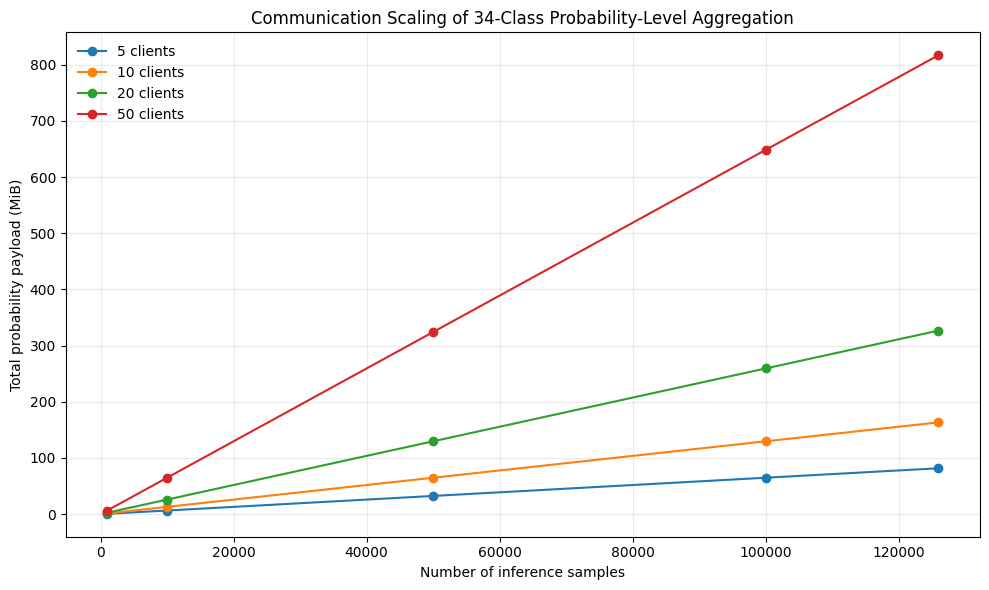

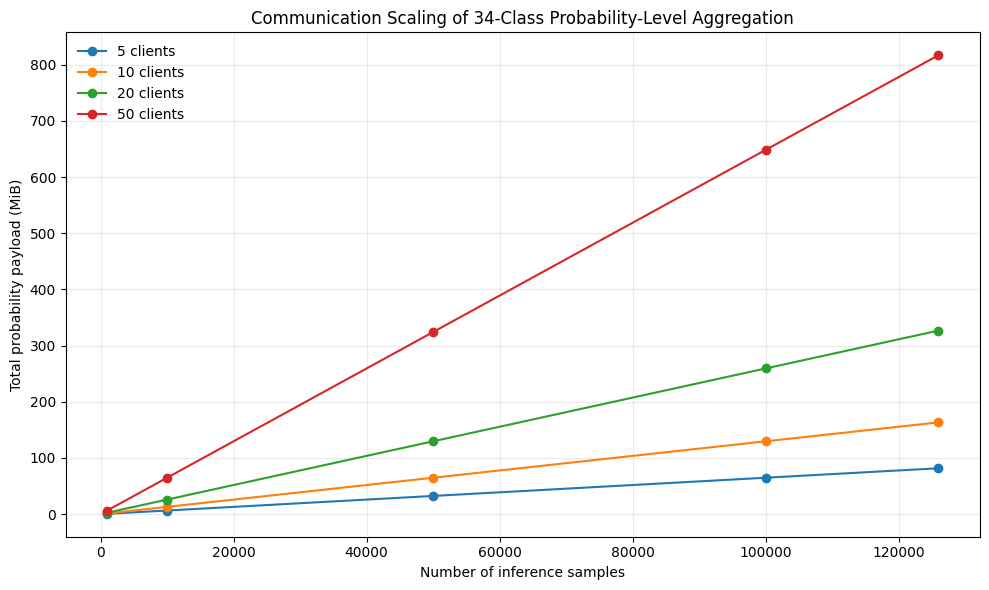

### Reviewer Figure — Model Artifact vs Probability Payload

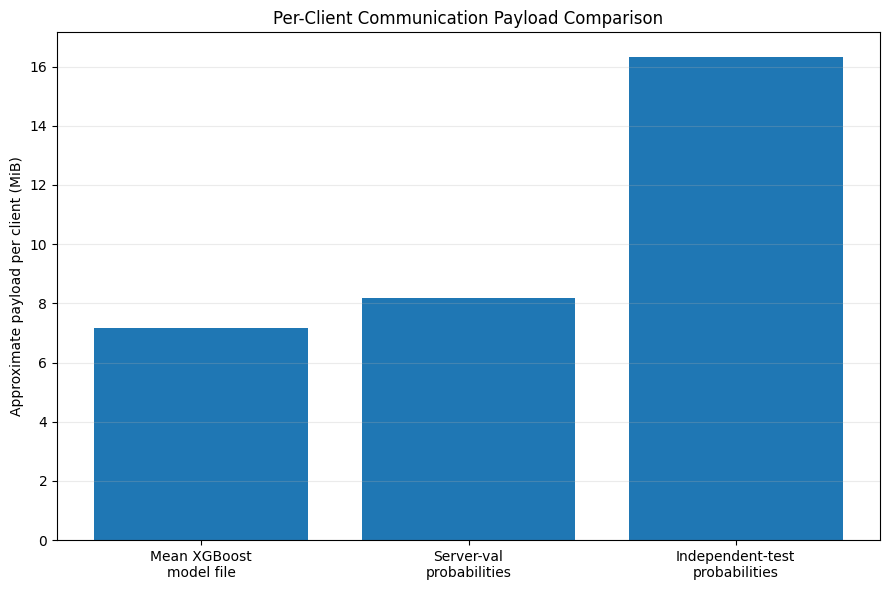

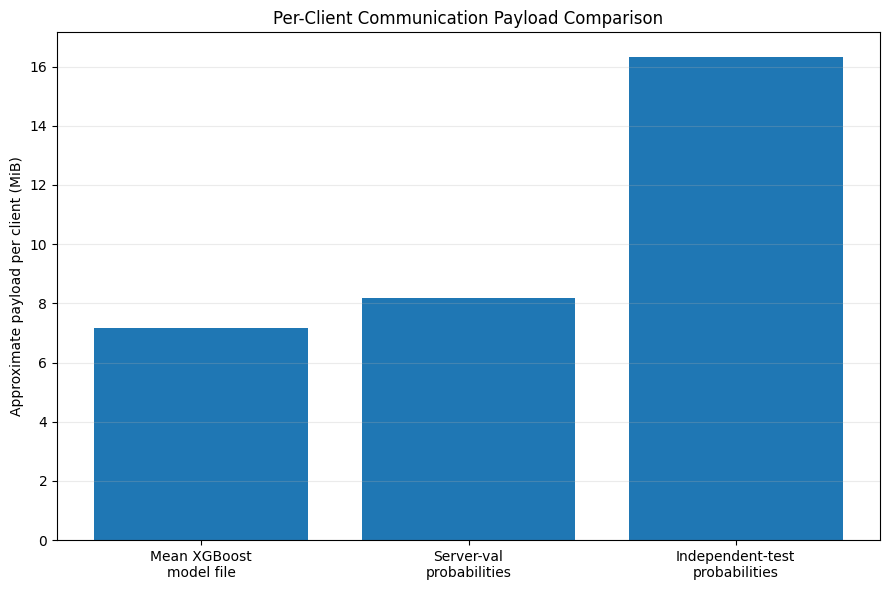


CELL 38 REVIEWER-READY SUMMARY

Probability-level fusion using float32:

SERVER VALIDATION
Samples: 62,983
Payload per client: 8.169 MiB
Total for 10 clients: 81.689 MiB

INDEPENDENT TEST
Samples: 125,987
Payload per client: 16.340 MiB
Total for 10 clients: 163.405 MiB

Mean frozen XGBoost model size: 7.173 MiB/client
Total frozen model size: 71.730 MiB

Communication scaling:
Bytes = N_clients × N_samples × N_classes × bytes_per_probability
Complexity = O(N_clients × N_samples × N_classes)

Interpretation:
Probability-level fusion avoids parameter compatibility problems between independently grown XGBoost ensembles, but its communication cost grows linearly with the number of clients, inference samples, and classes.
Therefore, the revised manuscript should NOT claim universally low communication overhead without qualification.
Trust-score and 30-feature SHAP-summary metadata are negligible relative to full probability matrices.

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_

In [ ]:
# CELL 38

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


print("=" * 120)
print("CELL 38 — REVIEWER R2 COMMUNICATION-COST AUDIT")
print("=" * 120)


ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "mixed_reliability_leakage_safe"
)

TEST_CLIENT_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "independent_test_FINAL" /
    "clients"
)

SERVER_CLIENT_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_clients"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


N_CLIENTS = 10

N_CLASSES = 34

N_FEATURES = 30

SERVER_ROWS = 62_983

TEST_ROWS = 125_987


def bytes_to_kib(x):
    return x / 1024.0


def bytes_to_mib(x):
    return x / (1024.0 ** 2)


def bytes_to_mb_decimal(x):
    return x / 1_000_000.0


def probability_payload_bytes(
    n_samples,
    n_classes,
    bytes_per_value
):

    return (
        int(n_samples)
        *
        int(n_classes)
        *
        int(bytes_per_value)
    )


# 3. ACTUAL FROZEN XGBOOST MODEL FILE SIZES

print("\n" + "=" * 120)
print("ACTUAL FROZEN CLIENT MODEL SIZES")
print("=" * 120)


model_rows = []


for client_id in range(
    N_CLIENTS
):

    model_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_xgb.json"
    )


    if not model_path.exists():

        raise FileNotFoundError(
            f"Missing frozen client model:\n{model_path}"
        )


    size_bytes = model_path.stat().st_size


    model_rows.append({

        "Client_ID":
            client_id,

        "Model_File":
            str(
                model_path
            ),

        "Model_Size_Bytes":
            size_bytes,

        "Model_Size_KiB":
            bytes_to_kib(
                size_bytes
            ),

        "Model_Size_MiB":
            bytes_to_mib(
                size_bytes
            ),
    })


model_df = pd.DataFrame(
    model_rows
)


display(
    model_df
)


print(
    "\nMean model size:",
    f"{model_df['Model_Size_MiB'].mean():.3f} MiB"
)

print(
    "Total 10-client model payload:",
    f"{model_df['Model_Size_MiB'].sum():.3f} MiB"
)


# 4. THEORETICAL PROBABILITY PAYLOAD — SERVER VALIDATION

print("\n" + "=" * 120)
print("THEORETICAL PROBABILITY PAYLOAD")
print("=" * 120)


payload_rows = []


for dataset_name, n_samples in [

    (
        "Server_Validation",
        SERVER_ROWS
    ),

    (
        "Independent_Test",
        TEST_ROWS
    ),

]:

    for dtype_name, bytes_per_value in [

        (
            "float32",
            4
        ),

        (
            "float64",
            8
        ),

    ]:

        per_client = probability_payload_bytes(
            n_samples=n_samples,
            n_classes=N_CLASSES,
            bytes_per_value=bytes_per_value
        )


        total = (
            per_client
            *
            N_CLIENTS
        )


        payload_rows.append({

            "Dataset":
                dataset_name,

            "Samples":
                n_samples,

            "Classes":
                N_CLASSES,

            "DType":
                dtype_name,

            "Bytes_Per_Value":
                bytes_per_value,

            "Bytes_Per_Client":
                per_client,

            "MiB_Per_Client":
                bytes_to_mib(
                    per_client
                ),

            "MB_Per_Client_Decimal":
                bytes_to_mb_decimal(
                    per_client
                ),

            "Total_Bytes_10_Clients":
                total,

            "Total_MiB_10_Clients":
                bytes_to_mib(
                    total
                ),

            "Total_MB_10_Clients_Decimal":
                bytes_to_mb_decimal(
                    total
                ),
        })


payload_df = pd.DataFrame(
    payload_rows
)


display(
    payload_df
)


# 5. ACTUAL SAVED .NPY PROBABILITY MATRIX SIZES

print("\n" + "=" * 120)
print("ACTUAL SAVED PROBABILITY ARTIFACT SIZE AUDIT")
print("=" * 120)


actual_prob_rows = []


for dataset_name, directory in [

    (
        "Independent_Test",
        TEST_CLIENT_PROB_DIR
    ),

    (
        "Server_Validation",
        SERVER_CLIENT_PROB_DIR
    ),

]:

    if not directory.exists():

        print(
            f"{dataset_name}: directory not found, "
            f"skipping actual-file audit."
        )

        continue


    for client_id in range(
        N_CLIENTS
    ):

        candidates = sorted(
            directory.glob(
                f"*client_{client_id:02d}*.npy"
            )
        )


        if len(
            candidates
        ) == 0:

            continue


        # Select first matching artifact only.
        path = candidates[
            0
        ]


        arr = np.load(
            path,
            mmap_mode="r"
        )


        file_size = path.stat().st_size


        raw_payload = (
            arr.size
            *
            arr.dtype.itemsize
        )


        actual_prob_rows.append({

            "Dataset":
                dataset_name,

            "Client_ID":
                client_id,

            "Probability_File":
                str(
                    path
                ),

            "Shape":
                str(
                    arr.shape
                ),

            "DType":
                str(
                    arr.dtype
                ),

            "Raw_Array_Bytes":
                raw_payload,

            "File_Size_Bytes":
                file_size,

            "Raw_Array_MiB":
                bytes_to_mib(
                    raw_payload
                ),

            "File_Size_MiB":
                bytes_to_mib(
                    file_size
                ),

            "NPY_Header_Overhead_Bytes":
                file_size
                -
                raw_payload,
        })


actual_prob_df = pd.DataFrame(
    actual_prob_rows
)


if len(
    actual_prob_df
) > 0:

    display(
        actual_prob_df
    )

else:

    print(
        "No actual .npy probability matrices found."
    )


# 6. TRUST + SHAP METADATA PAYLOAD
print("\n" + "=" * 120)
print("TRUST / SHAP METADATA PAYLOAD")
print("=" * 120)


metadata_rows = []


for dtype_name, bytes_per_value in [

    (
        "float32",
        4
    ),

    (
        "float64",
        8
    ),

]:

    trust_scalar_count = 6

    trust_bytes = (
        trust_scalar_count
        *
        bytes_per_value
    )


    shap_vector_bytes = (
        N_FEATURES
        *
        bytes_per_value
    )


    trust_plus_shap = (
        trust_bytes
        +
        shap_vector_bytes
    )


    metadata_rows.append({

        "DType":
            dtype_name,

        "Trust_Scalars":
            trust_scalar_count,

        "Trust_Bytes_Per_Client":
            trust_bytes,

        "SHAP_Features":
            N_FEATURES,

        "SHAP_Vector_Bytes_Per_Client":
            shap_vector_bytes,

        "Trust_Plus_SHAP_Bytes_Per_Client":
            trust_plus_shap,

        "Trust_Plus_SHAP_Total_10_Clients_Bytes":
            trust_plus_shap
            *
            N_CLIENTS,
    })


metadata_df = pd.DataFrame(
    metadata_rows
)


display(
    metadata_df
)


# 7. FULL COMMUNICATION SCENARIOS

print("\n" + "=" * 120)
print("COMMUNICATION SCENARIO COMPARISON")
print("=" * 120)


scenario_rows = []


mean_model_bytes = float(
    model_df[
        "Model_Size_Bytes"
    ].mean()
)


total_model_bytes = float(
    model_df[
        "Model_Size_Bytes"
    ].sum()
)


for dataset_name, n_samples in [

    (
        "Server_Validation",
        SERVER_ROWS
    ),

    (
        "Independent_Test",
        TEST_ROWS
    ),

]:

    prob_bytes_per_client = probability_payload_bytes(
        n_samples=n_samples,
        n_classes=N_CLASSES,
        bytes_per_value=4
    )


    prob_total = (
        prob_bytes_per_client
        *
        N_CLIENTS
    )


    metadata_per_client = (
        6
        *
        4
        +
        N_FEATURES
        *
        4
    )


    metadata_total = (
        metadata_per_client
        *
        N_CLIENTS
    )


    scenarios = [

        (
            "Probability_Only",
            prob_bytes_per_client,
            prob_total
        ),

        (
            "Probability_Plus_Trust_SHAP",
            prob_bytes_per_client
            +
            metadata_per_client,
            prob_total
            +
            metadata_total
        ),

        (
            "Model_Upload_Only",
            mean_model_bytes,
            total_model_bytes
        ),

        (
            "Model_Plus_Probability",
            mean_model_bytes
            +
            prob_bytes_per_client,
            total_model_bytes
            +
            prob_total
        ),

    ]


    for scenario_name, per_client, total in scenarios:

        scenario_rows.append({

            "Dataset":
                dataset_name,

            "Scenario":
                scenario_name,

            "Approx_Bytes_Per_Client":
                per_client,

            "Approx_MiB_Per_Client":
                bytes_to_mib(
                    per_client
                ),

            "Approx_Total_Bytes":
                total,

            "Approx_Total_MiB":
                bytes_to_mib(
                    total
                ),
        })


scenario_df = pd.DataFrame(
    scenario_rows
)


display(
    scenario_df
)


# 8. CROSSOVER ANALYSIS
# Probability payload:
#
#     B_prob = M * C * b
#
# Model artifact:
#
#     B_model = fixed file size
#
# Crossover:
#
#     M* = B_model / (C*b)
#
# Above M*, sending the probability matrix is larger than sending
# the frozen model file itself.

print("\n" + "=" * 120)
print("MODEL-vs-PROBABILITY CROSSOVER ANALYSIS")
print("=" * 120)


crossover_rows = []


for _, row in model_df.iterrows():

    client_id = int(
        row[
            "Client_ID"
        ]
    )


    model_bytes = float(
        row[
            "Model_Size_Bytes"
        ]
    )


    for dtype_name, bytes_per_value in [

        (
            "float32",
            4
        ),

        (
            "float64",
            8
        ),

    ]:

        crossover_samples = (
            model_bytes
            /
            (
                N_CLASSES
                *
                bytes_per_value
            )
        )


        crossover_rows.append({

            "Client_ID":
                client_id,

            "DType":
                dtype_name,

            "Model_Size_Bytes":
                model_bytes,

            "Crossover_Inference_Samples":
                crossover_samples,
        })


crossover_df = pd.DataFrame(
    crossover_rows
)


display(
    crossover_df
)


print(
    "\nMean float32 crossover sample count:",
    f"{crossover_df[crossover_df['DType']=='float32']['Crossover_Inference_Samples'].mean():,.0f}"
)


# 9. GENERAL SCALING TABLE
#
# Probability fusion:
#
#     O(N * M * C)
#
# where:
#     N = number of clients
#     M = number of inference samples
#     C = number of classes
#
# With b bytes/value:
#
#     Bytes = N * M * C * b
#

print("\n" + "=" * 120)
print("COMMUNICATION SCALING")
print("=" * 120)


scaling_rows = []


for n_clients in [
    5,
    10,
    20,
    50,
    100,
]:

    for n_samples in [
        1_000,
        10_000,
        50_000,
        100_000,
        TEST_ROWS,
    ]:

        total_bytes = (
            n_clients
            *
            n_samples
            *
            N_CLASSES
            *
            4
        )


        scaling_rows.append({

            "Clients":
                n_clients,

            "Inference_Samples":
                n_samples,

            "Classes":
                N_CLASSES,

            "DType":
                "float32",

            "Total_Bytes":
                total_bytes,

            "Total_MiB":
                bytes_to_mib(
                    total_bytes
                ),

            "Total_GiB":
                total_bytes
                /
                (
                    1024.0
                    **
                    3
                ),
        })


scaling_df = pd.DataFrame(
    scaling_rows
)


display(
    scaling_df
)


# 10. COMMUNICATION FIGURE

display(
    Markdown(
        "### Reviewer Figure — Communication Scaling"
    )
)


fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)


for n_clients in [
    5,
    10,
    20,
    50,
]:

    subset = scaling_df[
        scaling_df[
            "Clients"
        ]
        ==
        n_clients
    ]


    ax.plot(
        subset[
            "Inference_Samples"
        ],
        subset[
            "Total_MiB"
        ],
        marker="o",
        label=f"{n_clients} clients"
    )


ax.set_xlabel(
    "Number of inference samples"
)


ax.set_ylabel(
    "Total probability payload (MiB)"
)


ax.set_title(
    "Communication Scaling of 34-Class Probability-Level Aggregation"
)


ax.legend(
    frameon=False
)


ax.grid(
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


COMM_FIG_PNG = (
    FIG_DIR /
    "29_FINAL_DETA_communication_scaling.png"
)


COMM_FIG_PDF = (
    FIG_DIR /
    "29_FINAL_DETA_communication_scaling.pdf"
)


fig.savefig(
    COMM_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    COMM_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 11. MODEL vs PROBABILITY PAYLOAD FIGURE

display(
    Markdown(
        "### Reviewer Figure — Model Artifact vs Probability Payload"
    )
)


mean_model_mib = (
    model_df[
        "Model_Size_MiB"
    ].mean()
)


server_prob_mib = bytes_to_mib(
    probability_payload_bytes(
        SERVER_ROWS,
        N_CLASSES,
        4
    )
)


test_prob_mib = bytes_to_mib(
    probability_payload_bytes(
        TEST_ROWS,
        N_CLASSES,
        4
    )
)


comparison_labels = [
    "Mean XGBoost\nmodel file",
    "Server-val\nprobabilities",
    "Independent-test\nprobabilities",
]


comparison_values = [
    mean_model_mib,
    server_prob_mib,
    test_prob_mib,
]


fig, ax = plt.subplots(
    figsize=(
        9,
        6
    )
)


ax.bar(
    comparison_labels,
    comparison_values
)


ax.set_ylabel(
    "Approximate payload per client (MiB)"
)


ax.set_title(
    "Per-Client Communication Payload Comparison"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


PAYLOAD_FIG_PNG = (
    FIG_DIR /
    "30_FINAL_DETA_model_vs_probability_payload.png"
)


PAYLOAD_FIG_PDF = (
    FIG_DIR /
    "30_FINAL_DETA_model_vs_probability_payload.pdf"
)


fig.savefig(
    PAYLOAD_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    PAYLOAD_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 12. SAVE TABLES

MODEL_OUT = (
    TABLE_DIR /
    "reviewer2_communication_model_sizes.csv"
)


PAYLOAD_OUT = (
    TABLE_DIR /
    "reviewer2_communication_probability_payloads.csv"
)


ACTUAL_PROB_OUT = (
    TABLE_DIR /
    "reviewer2_communication_actual_probability_files.csv"
)


METADATA_OUT = (
    TABLE_DIR /
    "reviewer2_communication_trust_SHAP_metadata.csv"
)


SCENARIO_OUT = (
    TABLE_DIR /
    "reviewer2_communication_scenarios.csv"
)


CROSSOVER_OUT = (
    TABLE_DIR /
    "reviewer2_communication_model_probability_crossover.csv"
)


SCALING_OUT = (
    TABLE_DIR /
    "reviewer2_communication_scaling.csv"
)


model_df.to_csv(
    MODEL_OUT,
    index=False
)


payload_df.to_csv(
    PAYLOAD_OUT,
    index=False
)


actual_prob_df.to_csv(
    ACTUAL_PROB_OUT,
    index=False
)


metadata_df.to_csv(
    METADATA_OUT,
    index=False
)


scenario_df.to_csv(
    SCENARIO_OUT,
    index=False
)


crossover_df.to_csv(
    CROSSOVER_OUT,
    index=False
)


scaling_df.to_csv(
    SCALING_OUT,
    index=False
)


# 13. REPRODUCIBILITY MANIFEST

MANIFEST_OUT = (
    REPRO_DIR /
    "reviewer2_cell38_communication_cost_manifest.json"
)


manifest = {

    "cell":
        38,

    "reviewer":
        2,

    "reviewer_comment":
        "Communication-efficiency quantification",

    "n_clients":
        N_CLIENTS,

    "n_classes":
        N_CLASSES,

    "n_features":
        N_FEATURES,

    "server_validation_rows":
        SERVER_ROWS,

    "independent_test_rows":
        TEST_ROWS,

    "probability_payload_formula":
        "Bytes = N_clients * N_samples * N_classes * bytes_per_value",

    "communication_complexity":
        "O(N_clients * N_samples * N_classes)",

    "float32_bytes_per_probability":
        4,

    "float64_bytes_per_probability":
        8,

    "model_directory":
        str(
            MODEL_DIR
        ),

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "independent_test_predictions_recomputed":
        False,

    "outputs": {

        "model_sizes":
            str(
                MODEL_OUT
            ),

        "probability_payloads":
            str(
                PAYLOAD_OUT
            ),

        "actual_probability_files":
            str(
                ACTUAL_PROB_OUT
            ),

        "metadata_payload":
            str(
                METADATA_OUT
            ),

        "scenario_comparison":
            str(
                SCENARIO_OUT
            ),

        "crossover_analysis":
            str(
                CROSSOVER_OUT
            ),

        "scaling":
            str(
                SCALING_OUT
            ),

        "communication_scaling_figure":
            str(
                COMM_FIG_PNG
            ),

        "payload_comparison_figure":
            str(
                PAYLOAD_FIG_PNG
            ),
    },
}


with open(
    MANIFEST_OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )



float32_server = payload_df[
    (
        payload_df[
            "Dataset"
        ]
        ==
        "Server_Validation"
    )
    &
    (
        payload_df[
            "DType"
        ]
        ==
        "float32"
    )
].iloc[
    0
]


float32_test = payload_df[
    (
        payload_df[
            "Dataset"
        ]
        ==
        "Independent_Test"
    )
    &
    (
        payload_df[
            "DType"
        ]
        ==
        "float32"
    )
].iloc[
    0
]


print("\n" + "=" * 120)
print("=" * 120)


print("\nProbability-level fusion using float32:")


print(
    "\nSERVER VALIDATION"
)

print(
    "Samples:",
    f"{SERVER_ROWS:,}"
)

print(
    "Payload per client:",
    f"{float32_server['MiB_Per_Client']:.3f} MiB"
)

print(
    "Total for 10 clients:",
    f"{float32_server['Total_MiB_10_Clients']:.3f} MiB"
)


print(
    "\nINDEPENDENT TEST"
)

print(
    "Samples:",
    f"{TEST_ROWS:,}"
)

print(
    "Payload per client:",
    f"{float32_test['MiB_Per_Client']:.3f} MiB"
)

print(
    "Total for 10 clients:",
    f"{float32_test['Total_MiB_10_Clients']:.3f} MiB"
)


print(
    "\nMean frozen XGBoost model size:",
    f"{model_df['Model_Size_MiB'].mean():.3f} MiB/client"
)


print(
    "Total frozen model size:",
    f"{model_df['Model_Size_MiB'].sum():.3f} MiB"
)


print(
    "\nCommunication scaling:"
)

print(
    "Bytes = N_clients × N_samples × N_classes × bytes_per_probability"
)

print(
    "Complexity = O(N_clients × N_samples × N_classes)"
)


print("\nInterpretation:")

print(
    "Probability-level fusion avoids parameter compatibility problems "
    "between independently grown XGBoost ensembles, but its communication "
    "cost grows linearly with the number of clients, inference samples, "
    "and classes."
)

print(
    "Therefore, the revised manuscript should NOT claim universally low "
    "communication overhead without qualification."
)

print(
    "Trust-score and 30-feature SHAP-summary metadata are negligible "
    "relative to full probability matrices."
)


print("\nSaved:")
print(MODEL_OUT)
print(PAYLOAD_OUT)
print(ACTUAL_PROB_OUT)
print(METADATA_OUT)
print(SCENARIO_OUT)
print(CROSSOVER_OUT)
print(SCALING_OUT)
print(COMM_FIG_PNG)
print(COMM_FIG_PDF)
print(PAYLOAD_FIG_PNG)
print(PAYLOAD_FIG_PDF)
print(MANIFEST_OUT)


print(
    "\nCELL 38 STATUS: PASSED — "
    "REVIEWER R2 COMMUNICATION-COST AUDIT COMPLETE"
)

Mounted at /content/drive
CELL 39 — LEAKAGE-SAFE VALIDATION-ADAPTIVE DETA OPTIMIZATION

DATA-BOUNDARY AUDIT
Optimization data      : RESERVED SERVER VALIDATION
Independent test       : FORBIDDEN
Client model retraining: NO
Historical DETA changed: NO — retained as baseline

HISTORICAL TRUST COMPONENTS


,Client_ID,L_i,G_i,B_i,ES_i
0,0,0.59613489,0.46420676,0.49238992,0.94919813
1,1,0.54864680,0.50014951,0.51834060,0.98118449
2,2,0.55960359,0.48349586,0.50650121,0.93979038
3,3,0.57441243,0.47888970,0.49752580,1.00000000
4,4,0.58556717,0.44132946,0.48834155,0.94543503
5,5,0.60039513,0.35242064,0.42282914,0.61240058
6,6,0.24222793,0.30031915,0.38885995,0.04229075
7,7,0.25958801,0.40372085,0.44390288,0.72905671
8,8,0.62021411,0.42789568,0.48085712,0.92242557
9,9,0.79557492,0.15360017,0.18659556,0.00000000



Server-validation rows: 62,983
Classes: 34

SERVER-VALIDATION CLIENT PROBABILITY RESOLUTION
Client 00: (62983, 34) — PASSED
Client 01: (62983, 34) — PASSED
Client 02: (62983, 34) — PASSED
Client 03: (62983, 34) — PASSED
Client 04: (62983, 34) — PASSED
Client 05: (62983, 34) — PASSED
Client 06: (62983, 34) — PASSED
Client 07: (62983, 34) — PASSED
Client 08: (62983, 34) — PASSED
Client 09: (62983, 34) — PASSED

Probability stack: (10, 62983, 34)

SERVER-VALIDATION BASELINES


,Method,Accuracy,Balanced_Accuracy,Macro_F1,MCC,Log_Loss
0,Uniform,0.74289888,0.54066241,0.53293944,0.72787955,0.55305890
1,Size_Proportional,0.74364511,0.54307998,0.54338590,0.72522247,0.54149188
2,Historical_DETA,0.73748472,0.53971760,0.52777447,0.72454747,0.53378007



Best simple baseline server Macro-F1: 0.54338590

BUILDING FIXED SERVER-VALIDATION SEARCH SUBSET
Search subset rows: 15,000
Classes represented: 34

COARSE SIMPLEX SEARCH
Coefficient combinations: 286
Tau values: 9
Total coarse candidates: 2574

Coarse search seconds: 158.56

Top 15 coarse candidates:


...

,Method,Accuracy,Balanced_Accuracy,Macro_F1,MCC,Log_Loss,Macro_F1_Delta_vs_Best_Simple_Baseline
0,Uniform,0.74289888,0.54066241,0.53293944,0.72787955,0.55305890,-0.01044646
1,Size_Proportional,0.74364511,0.54307998,0.54338590,0.72522247,0.54149188,0.00000000
2,Historical_DETA,0.73748472,0.53971760,0.52777447,0.72454747,0.53378007,-0.01561143
3,VA_DETA,0.74626487,0.53839539,0.54051830,0.72694762,0.52433768,-0.00286760



VA-DETA Macro-F1 improvement over BEST simple baseline: -0.00286760
VA-DETA Macro-F1 improvement over historical DETA: +0.01274383

CLIENT WEIGHT SHIFT


,Client_ID,Role,Historical_T_i,Historical_Weight,VA_DETA_T_i,VA_DETA_Weight,Weight_Change
0,0,Reliable,0.54754647,0.11603252,0.59580357,0.11301285,-0.00301967
1,1,Reliable,0.56340979,0.11939417,0.54858904,0.09572757,-0.02366660
2,2,Reliable,0.55124846,0.11681702,0.55945437,0.09957770,-0.01723932
3,3,Reliable,0.55569611,0.11775954,0.57419554,0.10492325,-0.01283628
4,4,NonIID_Reliable,0.53469119,0.11330831,0.58523483,0.10901840,-0.00428990
5,5,NonIID_Reliable,0.44913608,0.09517802,0.59970655,0.11450624,0.01932822
6,6,LabelFlip,0.28946031,0.06134056,0.24257875,0.01855683,-0.04278373
7,7,LabelFlip,0.41948248,0.08889402,0.26023339,0.02137208,-0.06752195
8,8,Targeted_Poison,0.53170079,0.11267460,0.61972267,0.12231987,0.00964526
9,9,SubsetClass_Reliable,0.27653372,0.05860124,0.79334896,0.20098521,0.14238397



EXPLAINABILITY-CONTRIBUTION AUDIT
ES coefficient retained by validation optimization: YES
Optimized delta: 0.00015718


### VA-DETA Optimization — Server Validation

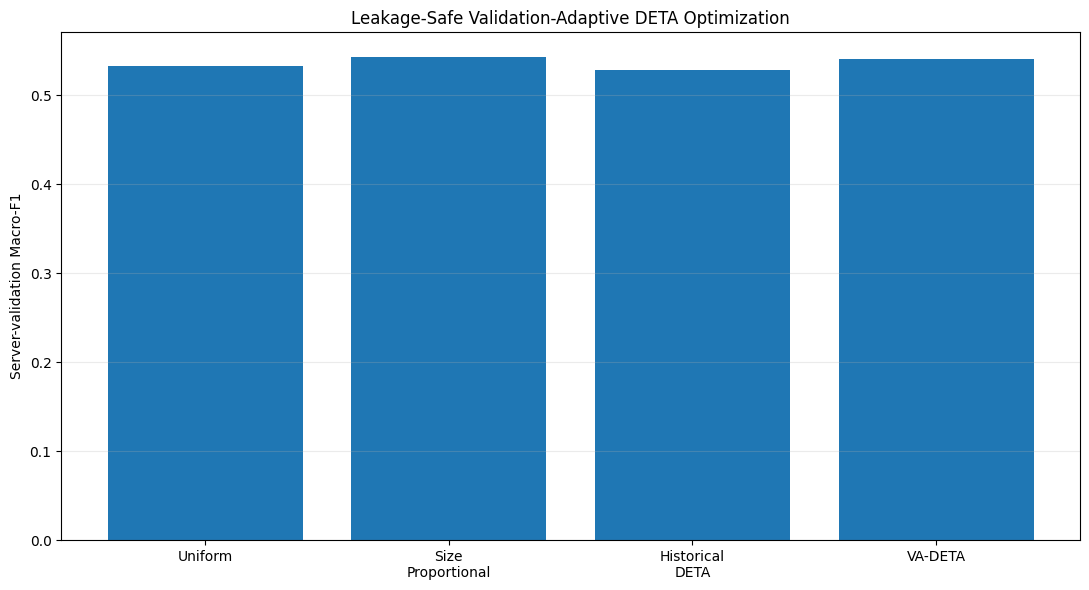

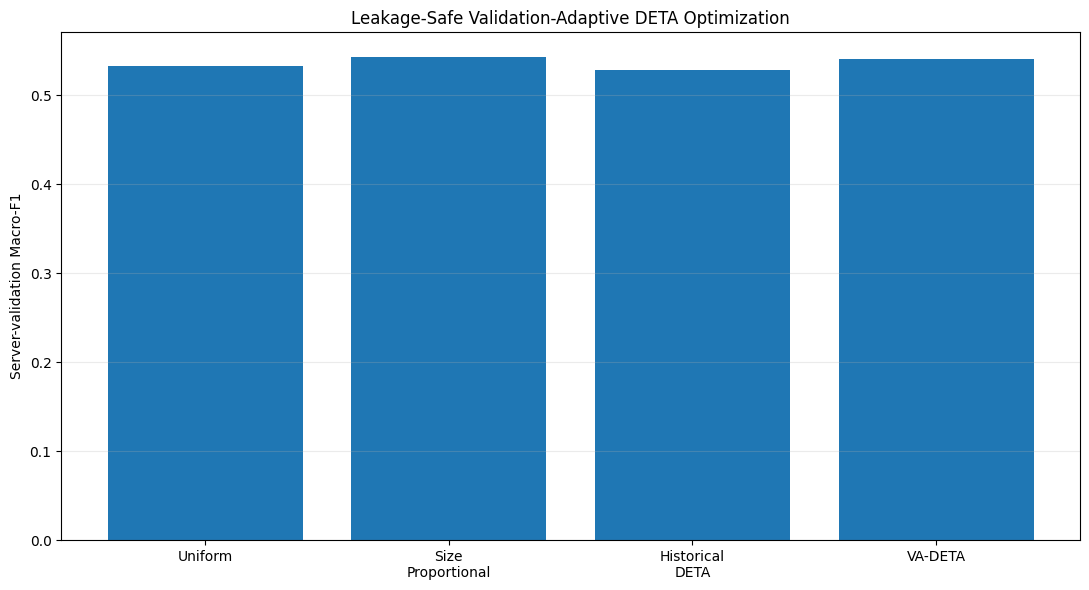

### Historical vs Validation-Adaptive DETA Coefficients

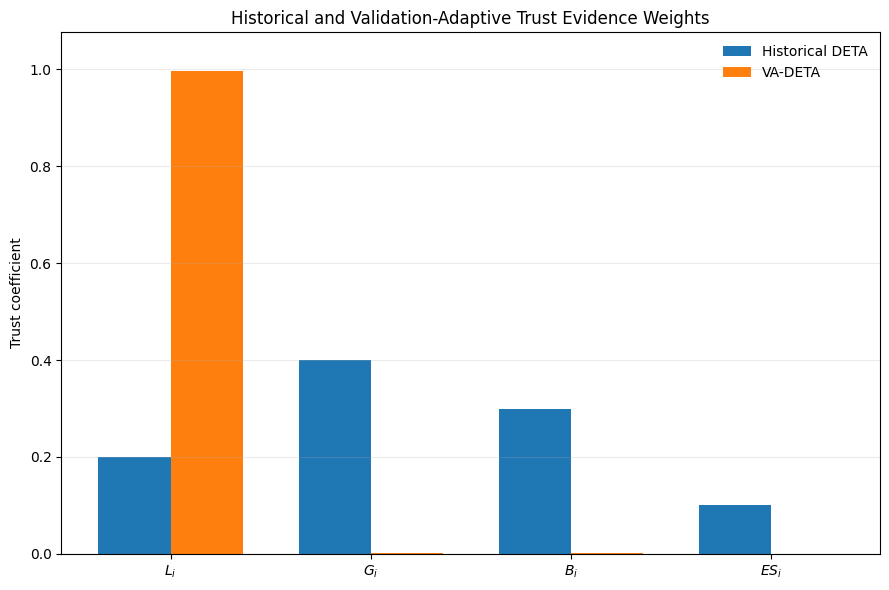

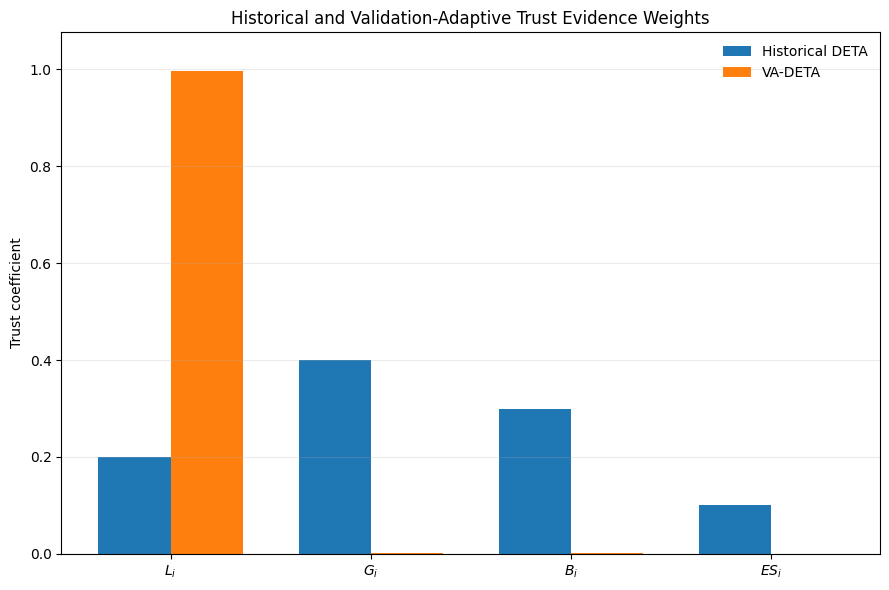

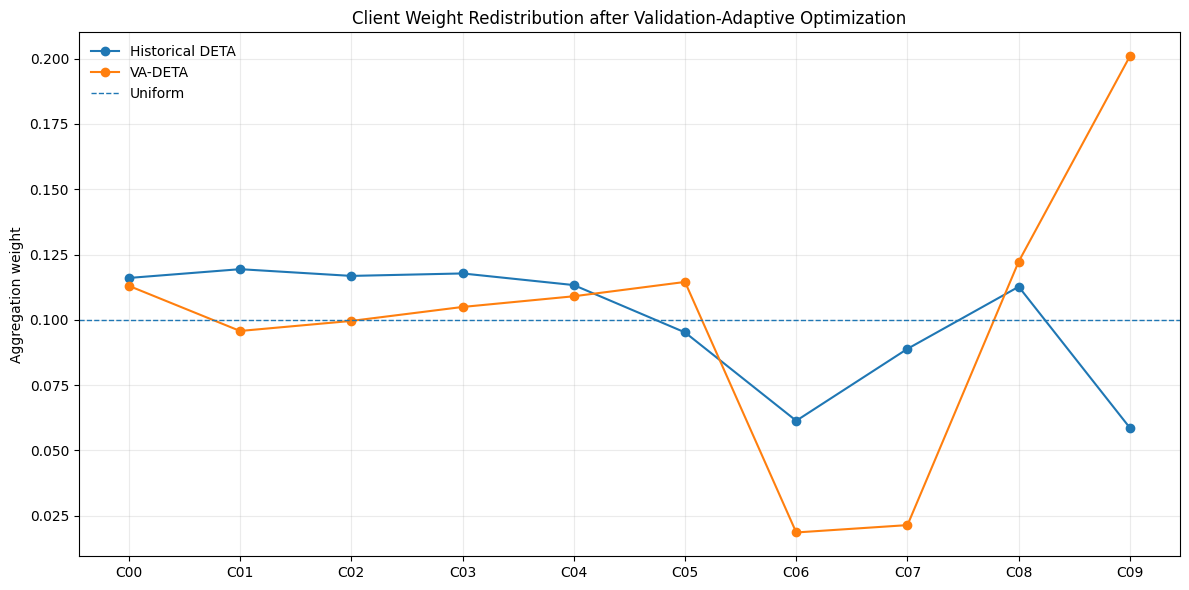

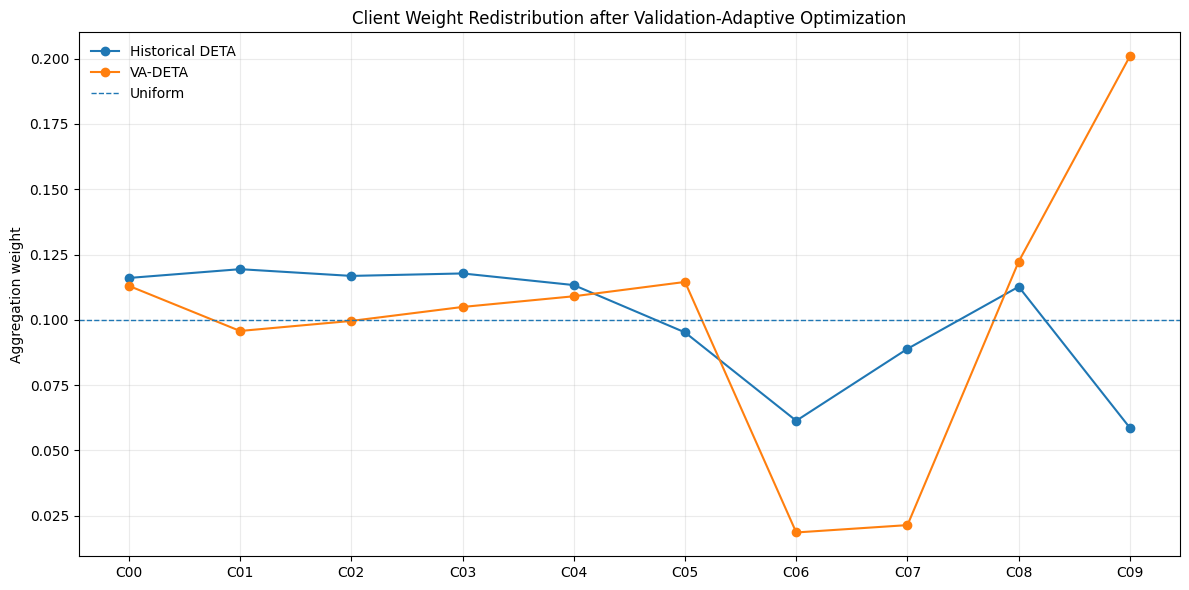


CELL 39 FINAL AUDIT

Frozen VA-DETA equation:
T_i = 0.99646235*L_i + 0.00128121*G_i + 0.00209926*B_i + 0.00015718*ES_i

w_i = T_i^2.01056581 / sum_j(T_j^2.01056581)

Server-validation Macro-F1:
Uniform             : 0.53293944
Size proportional   : 0.54338590
Historical DETA     : 0.52777447
VA-DETA             : 0.54051830

Gain vs best simple baseline: -0.00286760
Gain vs historical DETA: +0.01274383

Explainability coefficient retained: YES

Frozen configuration SHA256:
16b0996a03f6fd71c0123bd811d1c24c6d6c7e2c7d16b49ee9f2b478d710c90f

Independent test accessed : NO
Models retrained          : NO
Test-driven optimization  : NO
Historical DETA overwritten: NO

Saved:
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell39_VA_DETA_coarse_search.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell39_VA_DETA_coarse_full_server_verification.csv
/content/drive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell39_VA_DETA_refinement_search.csv
/content/drive/MyDrive/DETA_Reviewer

In [ ]:
# CELL 39 — LEAKAGE-SAFE VALIDATION-ADAPTIVE DETA OPTIMIZATION
# TIE BREAKING:
#   1. Higher Balanced Accuracy
#   2. Higher MCC
#   3. Lower Log-Loss
#
# CRITICAL:
#   × NO independent-test access
#   × NO independent-test predictions
#   × NO test-driven coefficient selection
#   × NO client model retraining
#

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import re
import json
import time
import hashlib
import itertools
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    log_loss,
)

from IPython.display import display, Markdown


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 320)
pd.set_option("display.float_format", lambda x: f"{x:.8f}")


print("=" * 125)
print("CELL 39 — LEAKAGE-SAFE VALIDATION-ADAPTIVE DETA OPTIMIZATION")
print("=" * 125)


ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

AGGREGATION_WEIGHT_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_aggregation_weights.csv"
)

SERVER_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_clients"
)

ADAPTIVE_DIR = (
    TRUST_DIR /
    "validation_adaptive_DETA"
)

ADAPTIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# 2. HARD PROHIBITION ON TEST ACCESS

print("\n" + "=" * 125)
print("DATA-BOUNDARY AUDIT")
print("=" * 125)

print("Optimization data      : RESERVED SERVER VALIDATION")
print("Independent test       : FORBIDDEN")
print("Client model retraining: NO")
print("Historical DETA changed: NO — retained as baseline")


# 3. CONSTANTS

N_CLIENTS = 10

N_CLASSES = 34

SEARCH_SEED = 20260818

SEARCH_SAMPLE_SIZE = 15_000


# Historical coefficient vector
HISTORICAL_THETA = np.array(
    [
        0.20,   # alpha -> L
        0.40,   # beta  -> G
        0.30,   # gamma -> B
        0.10,   # delta -> ES
    ],
    dtype=np.float64
)

HISTORICAL_TAU = 1.0


# Coarse coefficient grid
COARSE_STEP = 0.10


# tau controls trust concentration
TAU_GRID = np.array(
    [
        0.50,
        0.75,
        1.00,
        1.25,
        1.50,
        2.00,
        3.00,
        4.00,
        6.00,
    ],
    dtype=np.float64
)


# Number of strongest coarse candidates evaluated on full server validation
TOP_COARSE_FULL = 40


# Local random refinement around strongest coarse/full candidates
N_REFINEMENT_CANDIDATES = 1_500

TOP_REFINEMENT_FULL = 60


# 4. HELPERS

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            h.update(
                chunk
            )

    return h.hexdigest()


def normalize_rows(prob):

    prob = np.asarray(
        prob,
        dtype=np.float64
    )

    prob = np.clip(
        prob,
        1e-15,
        None
    )

    row_sum = prob.sum(
        axis=1,
        keepdims=True
    )

    if np.any(
        row_sum <= 0
    ):

        raise RuntimeError(
            "Probability normalization failure."
        )

    return (
        prob /
        row_sum
    )


def trust_to_weights(
    component_matrix,
    theta,
    tau
):

    theta = np.asarray(
        theta,
        dtype=np.float64
    )

    if theta.shape != (
        4,
    ):

        raise RuntimeError(
            "theta must contain four coefficients."
        )

    if np.any(
        theta < 0
    ):

        raise RuntimeError(
            "Negative trust coefficient."
        )

    theta_sum = theta.sum()

    if theta_sum <= 0:

        raise RuntimeError(
            "Coefficient sum <= 0."
        )

    theta = (
        theta /
        theta_sum
    )

    raw_trust = (
        component_matrix
        @
        theta
    )

    raw_trust = np.clip(
        raw_trust,
        1e-12,
        None
    )

    if tau <= 0:

        raise RuntimeError(
            "tau must be > 0."
        )

    powered = np.power(
        raw_trust,
        tau
    )

    weights = (
        powered /
        powered.sum()
    )

    return (
        raw_trust,
        weights
    )


def aggregate_probabilities(
    prob_stack,
    weights
):

    aggregate = np.tensordot(
        weights,
        prob_stack,
        axes=(
            0,
            0
        )
    )

    return normalize_rows(
        aggregate
    )


def evaluate(
    y_true,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )

    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    labels=np.arange(
                        N_CLASSES
                    ),
                    average="macro",
                    zero_division=0
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    y_true,
                    pred
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_true,
                    prob,
                    labels=np.arange(
                        N_CLASSES
                    )
                )
            ),
    }


def candidate_sort_key(df):

    # Primary:
    #   Macro-F1 DESC
    #
    # Ties:
    #   Balanced Accuracy DESC
    #   MCC DESC
    #   Log-Loss ASC

    return df.sort_values(
        by=[
            "Macro_F1",
            "Balanced_Accuracy",
            "MCC",
            "Log_Loss",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ]
    ).reset_index(
        drop=True
    )


# 5. LOAD HISTORICAL TRUST COMPONENTS

print("\n" + "=" * 125)
print("HISTORICAL TRUST COMPONENTS")
print("=" * 125)


if not TRUST_PATH.exists():

    raise FileNotFoundError(
        TRUST_PATH
    )


trust_df = pd.read_csv(
    TRUST_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


required_trust_cols = [
    "Client_ID",
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
]


missing = [
    c
    for c in required_trust_cols
    if c not in trust_df.columns
]


if missing:

    raise RuntimeError(
        f"Missing trust columns: {missing}"
    )


if len(
    trust_df
) != N_CLIENTS:

    raise RuntimeError(
        "Expected exactly 10 clients."
    )


COMPONENT_MATRIX = trust_df[
    [
        "L_i",
        "G_i",
        "B_i",
        "ES_i",
    ]
].to_numpy(
    dtype=np.float64
)


if not np.isfinite(
    COMPONENT_MATRIX
).all():

    raise RuntimeError(
        "Non-finite trust components."
    )


display(
    trust_df[
        required_trust_cols
    ]
)


# 6. LOAD SERVER VALIDATION LABELS

server_df = pd.read_parquet(
    SERVER_PATH,
    columns=[
        "Label_Encoded"
    ]
)


y_server = server_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32
)


if len(
    y_server
) != 62_983:

    print(
        "WARNING: server-validation row count differs from prior run:",
        len(
            y_server
        )
    )


if len(
    np.unique(
        y_server
    )
) != N_CLASSES:

    raise RuntimeError(
        "Expected all 34 server-validation classes."
    )


print(
    "\nServer-validation rows:",
    f"{len(y_server):,}"
)

print(
    "Classes:",
    len(
        np.unique(
            y_server
        )
    )
)


# 7. LOAD EXACT SAVED SERVER-VALIDATION CLIENT PROBABILITIES

print("\n" + "=" * 125)
print("SERVER-VALIDATION CLIENT PROBABILITY RESOLUTION")
print("=" * 125)


client_probabilities = []


for client_id in range(
    N_CLIENTS
):

    candidates = sorted(
        SERVER_PROB_DIR.glob(
            f"*client_{client_id:02d}*.npy"
        )
    )


    # Fallback exact names occasionally used in prior cells
    if len(
        candidates
    ) == 0:

        exact_candidates = [

            SERVER_PROB_DIR /
            f"client_{client_id:02d}_server_validation_probabilities.npy",

            SERVER_PROB_DIR /
            f"client_{client_id:02d}_CELL21_VERIFIED_server_validation_probabilities.npy",
        ]


        candidates = [
            p
            for p in exact_candidates
            if p.exists()
        ]


    if len(
        candidates
    ) == 0:

        raise FileNotFoundError(
            f"Unable to locate server-validation probabilities "
            f"for Client {client_id:02d} in:\n"
            f"{SERVER_PROB_DIR}"
        )


    path = candidates[
        0
    ]


    prob = np.load(
        path
    )


    if prob.shape != (
        len(
            y_server
        ),
        N_CLASSES
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: "
            f"unexpected probability shape {prob.shape}"
        )


    prob = normalize_rows(
        prob
    )


    client_probabilities.append(
        prob.astype(
            np.float32
        )
    )


    print(
        f"Client {client_id:02d}: "
        f"{prob.shape} — PASSED"
    )


PROB_STACK = np.stack(
    client_probabilities,
    axis=0
)


print(
    "\nProbability stack:",
    PROB_STACK.shape
)


# 8. LOAD SIZE-PROPORTIONAL BASELINE WEIGHTS

if not AGGREGATION_WEIGHT_PATH.exists():

    raise FileNotFoundError(
        AGGREGATION_WEIGHT_PATH
    )


weight_df = pd.read_csv(
    AGGREGATION_WEIGHT_PATH
).sort_values(
    "Client_ID"
)


SIZE_WEIGHTS = weight_df[
    "Size_Proportional"
].to_numpy(
    dtype=np.float64
)


SIZE_WEIGHTS = (
    SIZE_WEIGHTS /
    SIZE_WEIGHTS.sum()
)


UNIFORM_WEIGHTS = np.repeat(
    1.0 /
    N_CLIENTS,
    N_CLIENTS
)


# 9. BASELINE SERVER-VALIDATION PERFORMANCE

print("\n" + "=" * 125)
print("SERVER-VALIDATION BASELINES")
print("=" * 125)


baseline_rows = []


uniform_prob = aggregate_probabilities(
    PROB_STACK,
    UNIFORM_WEIGHTS
)


uniform_metrics = evaluate(
    y_server,
    uniform_prob
)


baseline_rows.append({

    "Method":
        "Uniform",

    **uniform_metrics,
})


size_prob = aggregate_probabilities(
    PROB_STACK,
    SIZE_WEIGHTS
)


size_metrics = evaluate(
    y_server,
    size_prob
)


baseline_rows.append({

    "Method":
        "Size_Proportional",

    **size_metrics,
})


historical_trust, historical_weights = trust_to_weights(
    COMPONENT_MATRIX,
    HISTORICAL_THETA,
    HISTORICAL_TAU
)


historical_prob = aggregate_probabilities(
    PROB_STACK,
    historical_weights
)


historical_metrics = evaluate(
    y_server,
    historical_prob
)


baseline_rows.append({

    "Method":
        "Historical_DETA",

    **historical_metrics,
})


baseline_df = pd.DataFrame(
    baseline_rows
)


display(
    baseline_df
)


BEST_SIMPLE_BASELINE_MACRO_F1 = max(
    uniform_metrics[
        "Macro_F1"
    ],
    size_metrics[
        "Macro_F1"
    ]
)


print(
    "\nBest simple baseline server Macro-F1:",
    f"{BEST_SIMPLE_BASELINE_MACRO_F1:.8f}"
)


# 10. FIXED CLASS-PRESERVING SEARCH SUBSET

print("\n" + "=" * 125)
print("BUILDING FIXED SERVER-VALIDATION SEARCH SUBSET")
print("=" * 125)


rng = np.random.default_rng(
    SEARCH_SEED
)


class_counts = np.bincount(
    y_server,
    minlength=N_CLASSES
)


search_indices = []


# Guarantee every represented class.
for class_id in range(
    N_CLASSES
):

    idx = np.flatnonzero(
        y_server
        ==
        class_id
    )

    if len(
        idx
    ) == 0:

        continue


    class_quota = max(
        1,
        int(
            round(
                SEARCH_SAMPLE_SIZE
                *
                len(
                    idx
                )
                /
                len(
                    y_server
                )
            )
        )
    )


    class_quota = min(
        class_quota,
        len(
            idx
        )
    )


    selected = rng.choice(
        idx,
        size=class_quota,
        replace=False
    )


    search_indices.extend(
        selected.tolist()
    )


search_indices = np.array(
    sorted(
        set(
            search_indices
        )
    ),
    dtype=np.int64
)


# Trim if slightly above requested size.
if len(
    search_indices
) > SEARCH_SAMPLE_SIZE:

    search_indices = rng.choice(
        search_indices,
        size=SEARCH_SAMPLE_SIZE,
        replace=False
    )


# Fill if slightly below requested size.
if len(
    search_indices
) < SEARCH_SAMPLE_SIZE:

    remaining = np.setdiff1d(
        np.arange(
            len(
                y_server
            )
        ),
        search_indices
    )


    additional = rng.choice(
        remaining,
        size=(
            SEARCH_SAMPLE_SIZE
            -
            len(
                search_indices
            )
        ),
        replace=False
    )


    search_indices = np.concatenate(
        [
            search_indices,
            additional
        ]
    )


rng.shuffle(
    search_indices
)


y_search = y_server[
    search_indices
]


PROB_SEARCH = PROB_STACK[
    :,
    search_indices,
    :
]


print(
    "Search subset rows:",
    f"{len(y_search):,}"
)

print(
    "Classes represented:",
    len(
        np.unique(
            y_search
        )
    )
)


# 11. GENERATE COARSE SIMPLEX

print("\n" + "=" * 125)
print("COARSE SIMPLEX SEARCH")
print("=" * 125)


units = int(
    round(
        1.0 /
        COARSE_STEP
    )
)


coarse_thetas = []


for a in range(
    units + 1
):

    for b in range(
        units + 1 - a
    ):

        for g in range(
            units + 1 - a - b
        ):

            d = (
                units
                -
                a
                -
                b
                -
                g
            )


            theta = np.array(
                [
                    a,
                    b,
                    g,
                    d,
                ],
                dtype=np.float64
            ) / units


            coarse_thetas.append(
                theta
            )


coarse_thetas = np.vstack(
    coarse_thetas
)


print(
    "Coefficient combinations:",
    len(
        coarse_thetas
    )
)

print(
    "Tau values:",
    len(
        TAU_GRID
    )
)

print(
    "Total coarse candidates:",
    len(
        coarse_thetas
    )
    *
    len(
        TAU_GRID
    )
)


# 12. COARSE SEARCH

coarse_rows = []


coarse_start = time.perf_counter()


candidate_id = 0


for theta in coarse_thetas:

    for tau in TAU_GRID:

        candidate_id += 1


        raw_trust, weights = trust_to_weights(
            COMPONENT_MATRIX,
            theta,
            tau
        )


        prob = aggregate_probabilities(
            PROB_SEARCH,
            weights
        )


        metrics = evaluate(
            y_search,
            prob
        )


        coarse_rows.append({

            "Candidate_ID":
                candidate_id,

            "Alpha_L":
                theta[
                    0
                ],

            "Beta_G":
                theta[
                    1
                ],

            "Gamma_B":
                theta[
                    2
                ],

            "Delta_ES":
                theta[
                    3
                ],

            "Tau":
                tau,

            "Weight_Min":
                weights.min(),

            "Weight_Max":
                weights.max(),

            "Weight_Entropy":
                float(
                    -np.sum(
                        weights
                        *
                        np.log(
                            weights
                            +
                            1e-15
                        )
                    )
                ),

            **metrics,
        })


coarse_seconds = (
    time.perf_counter()
    -
    coarse_start
)


coarse_df = pd.DataFrame(
    coarse_rows
)


coarse_df = candidate_sort_key(
    coarse_df
)


print(
    "\nCoarse search seconds:",
    f"{coarse_seconds:.2f}"
)


print("\nTop 15 coarse candidates:")


display(
    coarse_df.head(
        15
    )
)


# 13. FULL SERVER VERIFICATION OF TOP COARSE CANDIDATES

print("\n" + "=" * 125)
print("FULL SERVER VERIFICATION — TOP COARSE CANDIDATES")
print("=" * 125)


top_coarse = coarse_df.head(
    TOP_COARSE_FULL
).copy()


coarse_full_rows = []


for rank, row in top_coarse.iterrows():

    theta = np.array(
        [
            row[
                "Alpha_L"
            ],
            row[
                "Beta_G"
            ],
            row[
                "Gamma_B"
            ],
            row[
                "Delta_ES"
            ],
        ],
        dtype=np.float64
    )


    tau = float(
        row[
            "Tau"
        ]
    )


    raw_trust, weights = trust_to_weights(
        COMPONENT_MATRIX,
        theta,
        tau
    )


    prob = aggregate_probabilities(
        PROB_STACK,
        weights
    )


    metrics = evaluate(
        y_server,
        prob
    )


    coarse_full_rows.append({

        "Source":
            "Coarse",

        "Alpha_L":
            theta[
                0
            ],

        "Beta_G":
            theta[
                1
            ],

        "Gamma_B":
            theta[
                2
            ],

        "Delta_ES":
            theta[
                3
            ],

        "Tau":
            tau,

        "Weight_Min":
            weights.min(),

        "Weight_Max":
            weights.max(),

        **metrics,
    })


coarse_full_df = candidate_sort_key(
    pd.DataFrame(
        coarse_full_rows
    )
)


display(
    coarse_full_df.head(
        15
    )
)


# 14. LOCAL STOCHASTIC REFINEMENT

print("\n" + "=" * 125)
print("LOCAL REFINEMENT")
print("=" * 125)


rng_refine = np.random.default_rng(
    SEARCH_SEED
    +
    999
)


REFINEMENT_CENTERS = coarse_full_df.head(
    5
).copy()


refinement_candidates = []


n_per_center = (
    N_REFINEMENT_CANDIDATES
    //
    len(
        REFINEMENT_CENTERS
    )
)


for _, center in REFINEMENT_CENTERS.iterrows():

    center_theta = np.array(
        [
            center[
                "Alpha_L"
            ],
            center[
                "Beta_G"
            ],
            center[
                "Gamma_B"
            ],
            center[
                "Delta_ES"
            ],
        ],
        dtype=np.float64
    )


    center_tau = float(
        center[
            "Tau"
        ]
    )


    # Prevent exact zeros from making the Dirichlet undefined.
    center_safe = np.clip(
        center_theta,
        0.005,
        None
    )


    center_safe /= center_safe.sum()


    # Larger concentration = local search.
    concentration = (
        center_safe
        *
        80.0
    )


    sampled_theta = rng_refine.dirichlet(
        concentration,
        size=n_per_center
    )


    # Search tau multiplicatively around coarse optimum.
    sampled_log_tau = rng_refine.normal(
        loc=np.log(
            center_tau
        ),
        scale=0.35,
        size=n_per_center
    )


    sampled_tau = np.clip(
        np.exp(
            sampled_log_tau
        ),
        0.25,
        8.0
    )


    for theta, tau in zip(
        sampled_theta,
        sampled_tau
    ):

        refinement_candidates.append(
            (
                theta,
                float(
                    tau
                )
            )
        )


# Explicitly include historical DETA.
refinement_candidates.append(
    (
        HISTORICAL_THETA.copy(),
        HISTORICAL_TAU
    )
)


refine_rows = []


refine_start = time.perf_counter()


for candidate_id, (
    theta,
    tau
) in enumerate(
    refinement_candidates
):

    raw_trust, weights = trust_to_weights(
        COMPONENT_MATRIX,
        theta,
        tau
    )


    prob = aggregate_probabilities(
        PROB_SEARCH,
        weights
    )


    metrics = evaluate(
        y_search,
        prob
    )


    refine_rows.append({

        "Candidate_ID":
            candidate_id,

        "Alpha_L":
            theta[
                0
            ],

        "Beta_G":
            theta[
                1
            ],

        "Gamma_B":
            theta[
                2
            ],

        "Delta_ES":
            theta[
                3
            ],

        "Tau":
            tau,

        "Weight_Min":
            weights.min(),

        "Weight_Max":
            weights.max(),

        "Weight_Entropy":
            float(
                -np.sum(
                    weights
                    *
                    np.log(
                        weights
                        +
                        1e-15
                    )
                )
            ),

        **metrics,
    })


refine_seconds = (
    time.perf_counter()
    -
    refine_start
)


refine_df = candidate_sort_key(
    pd.DataFrame(
        refine_rows
    )
)


print(
    "Refinement candidates:",
    len(
        refine_df
    )
)

print(
    "Refinement search seconds:",
    f"{refine_seconds:.2f}"
)


display(
    refine_df.head(
        15
    )
)


# 15. FULL SERVER VERIFICATION — TOP REFINEMENT CANDIDATES

print("\n" + "=" * 125)
print("FULL SERVER VERIFICATION — REFINEMENT")
print("=" * 125)


top_refine = refine_df.head(
    TOP_REFINEMENT_FULL
).copy()


refine_full_rows = []


for _, row in top_refine.iterrows():

    theta = np.array(
        [
            row[
                "Alpha_L"
            ],
            row[
                "Beta_G"
            ],
            row[
                "Gamma_B"
            ],
            row[
                "Delta_ES"
            ],
        ],
        dtype=np.float64
    )


    tau = float(
        row[
            "Tau"
        ]
    )


    raw_trust, weights = trust_to_weights(
        COMPONENT_MATRIX,
        theta,
        tau
    )


    prob = aggregate_probabilities(
        PROB_STACK,
        weights
    )


    metrics = evaluate(
        y_server,
        prob
    )


    refine_full_rows.append({

        "Source":
            "Refinement",

        "Alpha_L":
            theta[
                0
            ],

        "Beta_G":
            theta[
                1
            ],

        "Gamma_B":
            theta[
                2
            ],

        "Delta_ES":
            theta[
                3
            ],

        "Tau":
            tau,

        "Weight_Min":
            weights.min(),

        "Weight_Max":
            weights.max(),

        **metrics,
    })


refine_full_df = candidate_sort_key(
    pd.DataFrame(
        refine_full_rows
    )
)


display(
    refine_full_df.head(
        20
    )
)


# 16. COMBINE ALL FULL-SERVER VERIFIED ADAPTIVE CANDIDATES

adaptive_full_df = pd.concat(
    [
        coarse_full_df,
        refine_full_df,
    ],
    ignore_index=True
)


# Remove effectively duplicate configurations.
adaptive_full_df[
    "_Theta_Key"
] = adaptive_full_df.apply(
    lambda r:
        (
            round(
                r[
                    "Alpha_L"
                ],
                8
            ),
            round(
                r[
                    "Beta_G"
                ],
                8
            ),
            round(
                r[
                    "Gamma_B"
                ],
                8
            ),
            round(
                r[
                    "Delta_ES"
                ],
                8
            ),
            round(
                r[
                    "Tau"
                ],
                8
            ),
        ),
    axis=1
)


adaptive_full_df = (
    adaptive_full_df
    .drop_duplicates(
        "_Theta_Key"
    )
    .drop(
        columns="_Theta_Key"
    )
)


adaptive_full_df = candidate_sort_key(
    adaptive_full_df
)


# 17. FREEZE EXACTLY ONE VA-DETA CONFIGURATION

BEST = adaptive_full_df.iloc[
    0
]


BEST_THETA = np.array(
    [
        BEST[
            "Alpha_L"
        ],
        BEST[
            "Beta_G"
        ],
        BEST[
            "Gamma_B"
        ],
        BEST[
            "Delta_ES"
        ],
    ],
    dtype=np.float64
)


BEST_TAU = float(
    BEST[
        "Tau"
    ]
)


BEST_TRUST, BEST_WEIGHTS = trust_to_weights(
    COMPONENT_MATRIX,
    BEST_THETA,
    BEST_TAU
)


BEST_PROB = aggregate_probabilities(
    PROB_STACK,
    BEST_WEIGHTS
)


BEST_METRICS = evaluate(
    y_server,
    BEST_PROB
)


print("\n" + "=" * 125)
print("FROZEN VA-DETA CONFIGURATION")
print("=" * 125)


print(
    f"alpha (L_i)  : {BEST_THETA[0]:.8f}"
)

print(
    f"beta  (G_i)  : {BEST_THETA[1]:.8f}"
)

print(
    f"gamma (B_i)  : {BEST_THETA[2]:.8f}"
)

print(
    f"delta (ES_i) : {BEST_THETA[3]:.8f}"
)

print(
    f"tau          : {BEST_TAU:.8f}"
)

print(
    f"sum theta    : {BEST_THETA.sum():.12f}"
)


print("\nVA-DETA server-validation metrics:")

for key, value in BEST_METRICS.items():

    print(
        f"{key:<22}: {value:.8f}"
    )


# 18. COMPARE TO BASELINES

comparison_rows = []


for _, row in baseline_df.iterrows():

    comparison_rows.append({

        "Method":
            row[
                "Method"
            ],

        "Accuracy":
            row[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            row[
                "Balanced_Accuracy"
            ],

        "Macro_F1":
            row[
                "Macro_F1"
            ],

        "MCC":
            row[
                "MCC"
            ],

        "Log_Loss":
            row[
                "Log_Loss"
            ],
    })


comparison_rows.append({

    "Method":
        "VA_DETA",

    **BEST_METRICS,
})


comparison_df = pd.DataFrame(
    comparison_rows
)


comparison_df[
    "Macro_F1_Delta_vs_Best_Simple_Baseline"
] = (
    comparison_df[
        "Macro_F1"
    ]
    -
    BEST_SIMPLE_BASELINE_MACRO_F1
)


print("\n" + "=" * 125)
print("VA-DETA vs BASELINES — SERVER VALIDATION ONLY")
print("=" * 125)


display(
    comparison_df
)


adaptive_gain = (
    BEST_METRICS[
        "Macro_F1"
    ]
    -
    BEST_SIMPLE_BASELINE_MACRO_F1
)


historical_gain = (
    BEST_METRICS[
        "Macro_F1"
    ]
    -
    historical_metrics[
        "Macro_F1"
    ]
)


print(
    "\nVA-DETA Macro-F1 improvement "
    "over BEST simple baseline:",
    f"{adaptive_gain:+.8f}"
)


print(
    "VA-DETA Macro-F1 improvement "
    "over historical DETA:",
    f"{historical_gain:+.8f}"
)


# 19. CLIENT WEIGHT AUDIT

weight_audit = trust_df[
    [
        "Client_ID"
    ]
].copy()


if "Role" in trust_df.columns:

    weight_audit[
        "Role"
    ] = trust_df[
        "Role"
    ]


weight_audit[
    "Historical_T_i"
] = historical_trust


weight_audit[
    "Historical_Weight"
] = historical_weights


weight_audit[
    "VA_DETA_T_i"
] = BEST_TRUST


weight_audit[
    "VA_DETA_Weight"
] = BEST_WEIGHTS


weight_audit[
    "Weight_Change"
] = (
    BEST_WEIGHTS
    -
    historical_weights
)


print("\n" + "=" * 125)
print("CLIENT WEIGHT SHIFT")
print("=" * 125)


display(
    weight_audit
)


# 20. IMPORTANT NOVELTY AUDIT — DID ES SURVIVE OPTIMIZATION?

print("\n" + "=" * 125)
print("EXPLAINABILITY-CONTRIBUTION AUDIT")
print("=" * 125)


if BEST_THETA[
    3
] > 1e-6:

    print(
        "ES coefficient retained by validation optimization: YES"
    )

    print(
        "Optimized delta:",
        f"{BEST_THETA[3]:.8f}"
    )


else:

    print(
        "ES coefficient retained by validation optimization: NO"
    )

    print(
        "IMPORTANT:"
    )

    print(
        "Validation optimization assigned essentially zero weight "
        "to ES_i. Do NOT claim that adaptive performance gains "
        "depend on explainability unless later threat-condition "
        "experiments demonstrate otherwise."
    )


# 21. FIGURE — SERVER-VALIDATION PERFORMANCE

display(
    Markdown(
        "### VA-DETA Optimization — Server Validation"
    )
)


plot_order = [
    "Uniform",
    "Size_Proportional",
    "Historical_DETA",
    "VA_DETA",
]


plot_df = (
    comparison_df[
        comparison_df[
            "Method"
        ].isin(
            plot_order
        )
    ]
    .set_index(
        "Method"
    )
    .loc[
        plot_order
    ]
    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(
        11,
        6
    )
)


x = np.arange(
    len(
        plot_df
    )
)


ax.bar(
    x,
    plot_df[
        "Macro_F1"
    ]
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Uniform",
        "Size\nProportional",
        "Historical\nDETA",
        "VA-DETA",
    ]
)


ax.set_ylabel(
    "Server-validation Macro-F1"
)


ax.set_title(
    "Leakage-Safe Validation-Adaptive DETA Optimization"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


FIG_PERF_PNG = (
    FIG_DIR /
    "31_VA_DETA_server_validation_performance.png"
)


FIG_PERF_PDF = (
    FIG_DIR /
    "31_VA_DETA_server_validation_performance.pdf"
)


fig.savefig(
    FIG_PERF_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    FIG_PERF_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 22. FIGURE — HISTORICAL vs ADAPTIVE COEFFICIENTS

display(
    Markdown(
        "### Historical vs Validation-Adaptive DETA Coefficients"
    )
)


coefficient_labels = [
    r"$L_i$",
    r"$G_i$",
    r"$B_i$",
    r"$ES_i$",
]


x = np.arange(
    4
)


width = 0.36


fig, ax = plt.subplots(
    figsize=(
        9,
        6
    )
)


ax.bar(
    x - width / 2,
    HISTORICAL_THETA,
    width,
    label="Historical DETA"
)


ax.bar(
    x + width / 2,
    BEST_THETA,
    width,
    label="VA-DETA"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    coefficient_labels
)


ax.set_ylabel(
    "Trust coefficient"
)


ax.set_ylim(
    0,
    max(
        0.6,
        float(
            BEST_THETA.max()
        )
        +
        0.08
    )
)


ax.set_title(
    "Historical and Validation-Adaptive Trust Evidence Weights"
)


ax.legend(
    frameon=False
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


FIG_COEF_PNG = (
    FIG_DIR /
    "32_VA_DETA_historical_vs_adaptive_coefficients.png"
)


FIG_COEF_PDF = (
    FIG_DIR /
    "32_VA_DETA_historical_vs_adaptive_coefficients.pdf"
)


fig.savefig(
    FIG_COEF_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    FIG_COEF_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 23. FIGURE — CLIENT WEIGHT SHIFT

fig, ax = plt.subplots(
    figsize=(
        12,
        6
    )
)


x = np.arange(
    N_CLIENTS
)


ax.plot(
    x,
    historical_weights,
    marker="o",
    label="Historical DETA"
)


ax.plot(
    x,
    BEST_WEIGHTS,
    marker="o",
    label="VA-DETA"
)


ax.axhline(
    0.10,
    linestyle="--",
    linewidth=1,
    label="Uniform"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        f"C{i:02d}"
        for i in range(
            N_CLIENTS
        )
    ]
)


ax.set_ylabel(
    "Aggregation weight"
)


ax.set_title(
    "Client Weight Redistribution after Validation-Adaptive Optimization"
)


ax.legend(
    frameon=False
)


ax.grid(
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


FIG_WEIGHT_PNG = (
    FIG_DIR /
    "33_VA_DETA_client_weight_shift.png"
)


FIG_WEIGHT_PDF = (
    FIG_DIR /
    "33_VA_DETA_client_weight_shift.pdf"
)


fig.savefig(
    FIG_WEIGHT_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    FIG_WEIGHT_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)

# 24. SAVE OPTIMIZATION ARTIFACTS
COARSE_PATH = (
    TABLE_DIR /
    "cell39_VA_DETA_coarse_search.csv"
)


COARSE_FULL_PATH = (
    TABLE_DIR /
    "cell39_VA_DETA_coarse_full_server_verification.csv"
)


REFINE_PATH = (
    TABLE_DIR /
    "cell39_VA_DETA_refinement_search.csv"
)


REFINE_FULL_PATH = (
    TABLE_DIR /
    "cell39_VA_DETA_refinement_full_server_verification.csv"
)


ALL_FULL_PATH = (
    TABLE_DIR /
    "cell39_VA_DETA_all_full_server_candidates.csv"
)


COMPARISON_PATH = (
    TABLE_DIR /
    "cell39_VA_DETA_server_validation_comparison.csv"
)


WEIGHT_AUDIT_PATH = (
    TABLE_DIR /
    "cell39_VA_DETA_client_weights.csv"
)


FROZEN_CONFIG_PATH = (
    ADAPTIVE_DIR /
    "VA_DETA_FROZEN_server_validation_configuration.json"
)


coarse_df.to_csv(
    COARSE_PATH,
    index=False
)


coarse_full_df.to_csv(
    COARSE_FULL_PATH,
    index=False
)


refine_df.to_csv(
    REFINE_PATH,
    index=False
)


refine_full_df.to_csv(
    REFINE_FULL_PATH,
    index=False
)


adaptive_full_df.to_csv(
    ALL_FULL_PATH,
    index=False
)


comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)


weight_audit.to_csv(
    WEIGHT_AUDIT_PATH,
    index=False
)


# 25. FREEZE CONFIGURATION

frozen_config = {

    "method":
        "Validation-Adaptive DETA",

    "abbreviation":
        "VA-DETA",

    "selection_partition":
        "reserved server validation only",

    "independent_test_accessed":
        False,

    "primary_optimization_metric":
        "Macro_F1",

    "tie_breakers":
        [
            "Balanced_Accuracy",
            "MCC",
            "lower Log_Loss",
        ],

    "historical_configuration": {

        "alpha_L":
            float(
                HISTORICAL_THETA[
                    0
                ]
            ),

        "beta_G":
            float(
                HISTORICAL_THETA[
                    1
                ]
            ),

        "gamma_B":
            float(
                HISTORICAL_THETA[
                    2
                ]
            ),

        "delta_ES":
            float(
                HISTORICAL_THETA[
                    3
                ]
            ),

        "tau":
            HISTORICAL_TAU,
    },

    "adaptive_configuration": {

        "alpha_L":
            float(
                BEST_THETA[
                    0
                ]
            ),

        "beta_G":
            float(
                BEST_THETA[
                    1
                ]
            ),

        "gamma_B":
            float(
                BEST_THETA[
                    2
                ]
            ),

        "delta_ES":
            float(
                BEST_THETA[
                    3
                ]
            ),

        "tau":
            float(
                BEST_TAU
            ),
    },

    "adaptive_server_validation_metrics":
        {
            key:
                float(
                    value
                )

            for key, value
            in BEST_METRICS.items()
        },

    "best_simple_baseline_server_macro_f1":
        float(
            BEST_SIMPLE_BASELINE_MACRO_F1
        ),

    "adaptive_macro_f1_gain_vs_best_simple_baseline":
        float(
            adaptive_gain
        ),

    "adaptive_macro_f1_gain_vs_historical_DETA":
        float(
            historical_gain
        ),

    "ES_retained":
        bool(
            BEST_THETA[
                3
            ]
            >
            1e-6
        ),

    "optimization": {

        "search_seed":
            SEARCH_SEED,

        "search_subset_rows":
            len(
                y_search
            ),

        "coarse_step":
            COARSE_STEP,

        "tau_grid":
            TAU_GRID.tolist(),

        "coarse_candidates":
            int(
                len(
                    coarse_df
                )
            ),

        "refinement_candidates":
            int(
                len(
                    refine_df
                )
            ),
    },

    "client_weights":
        {

            str(
                client_id
            ):
                float(
                    BEST_WEIGHTS[
                        client_id
                    ]
                )

            for client_id
            in range(
                N_CLIENTS
            )
        },
}


with open(
    FROZEN_CONFIG_PATH,
    "w"
) as f:

    json.dump(
        frozen_config,
        f,
        indent=4
    )


FROZEN_SHA256 = sha256_file(
    FROZEN_CONFIG_PATH
)


# 26. FREEZE MANIFEST

MANIFEST_PATH = (
    REPRO_DIR /
    "cell39_VA_DETA_server_validation_optimization_manifest.json"
)


manifest = {

    "cell":
        39,

    "status":
        "FROZEN_BEFORE_INDEPENDENT_TEST",

    "method":
        "VA-DETA",

    "server_validation_only":
        True,

    "independent_test_accessed":
        False,

    "client_models_retrained":
        False,

    "historical_DETA_retained_as_baseline":
        True,

    "frozen_configuration_path":
        str(
            FROZEN_CONFIG_PATH
        ),

    "frozen_configuration_sha256":
        FROZEN_SHA256,

    "outputs": {

        "coarse_search":
            str(
                COARSE_PATH
            ),

        "coarse_full":
            str(
                COARSE_FULL_PATH
            ),

        "refinement_search":
            str(
                REFINE_PATH
            ),

        "refinement_full":
            str(
                REFINE_FULL_PATH
            ),

        "all_full_candidates":
            str(
                ALL_FULL_PATH
            ),

        "comparison":
            str(
                COMPARISON_PATH
            ),

        "client_weights":
            str(
                WEIGHT_AUDIT_PATH
            ),

        "figure_performance":
            str(
                FIG_PERF_PNG
            ),

        "figure_coefficients":
            str(
                FIG_COEF_PNG
            ),

        "figure_weights":
            str(
                FIG_WEIGHT_PNG
            ),
    },
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 27. FINAL CELL 39 AUDIT

print("\n" + "=" * 125)
print("CELL 39 FINAL AUDIT")
print("=" * 125)


print(
    "\nFrozen VA-DETA equation:"
)


print(
    f"T_i = "
    f"{BEST_THETA[0]:.8f}*L_i + "
    f"{BEST_THETA[1]:.8f}*G_i + "
    f"{BEST_THETA[2]:.8f}*B_i + "
    f"{BEST_THETA[3]:.8f}*ES_i"
)


print(
    f"\nw_i = T_i^{BEST_TAU:.8f} / "
    f"sum_j(T_j^{BEST_TAU:.8f})"
)


print(
    "\nServer-validation Macro-F1:"
)


print(
    "Uniform             :",
    f"{uniform_metrics['Macro_F1']:.8f}"
)


print(
    "Size proportional   :",
    f"{size_metrics['Macro_F1']:.8f}"
)


print(
    "Historical DETA     :",
    f"{historical_metrics['Macro_F1']:.8f}"
)


print(
    "VA-DETA             :",
    f"{BEST_METRICS['Macro_F1']:.8f}"
)


print(
    "\nGain vs best simple baseline:",
    f"{adaptive_gain:+.8f}"
)


print(
    "Gain vs historical DETA:",
    f"{historical_gain:+.8f}"
)


print(
    "\nExplainability coefficient retained:",
    "YES"
    if BEST_THETA[
        3
    ] > 1e-6
    else "NO"
)


print(
    "\nFrozen configuration SHA256:"
)

print(
    FROZEN_SHA256
)


print(
    "\nIndependent test accessed : NO"
)

print(
    "Models retrained          : NO"
)

print(
    "Test-driven optimization  : NO"
)

print(
    "Historical DETA overwritten: NO"
)


print("\nSaved:")
print(COARSE_PATH)
print(COARSE_FULL_PATH)
print(REFINE_PATH)
print(REFINE_FULL_PATH)
print(ALL_FULL_PATH)
print(COMPARISON_PATH)
print(WEIGHT_AUDIT_PATH)
print(FROZEN_CONFIG_PATH)
print(MANIFEST_PATH)
print(FIG_PERF_PNG)
print(FIG_COEF_PNG)
print(FIG_WEIGHT_PNG)


print(
    "\nCELL 39 STATUS: PASSED — "
    "VA-DETA CONFIGURATION FROZEN BEFORE INDEPENDENT TEST"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 39B — EXPLAINABILITY-PRESERVING CONSTRAINED VA-DETA

DATA-BOUNDARY AUDIT
Optimization partition : RESERVED SERVER VALIDATION
Independent test       : NOT OPENED
Models retrained       : NO
Historical DETA altered: NO

Trust components:


,Client_ID,L_i,G_i,B_i,ES_i
0,0,0.59613489,0.46420676,0.49238992,0.94919813
1,1,0.54864680,0.50014951,0.51834060,0.98118449
2,2,0.55960359,0.48349586,0.50650121,0.93979038
3,3,0.57441243,0.47888970,0.49752580,1.00000000
4,4,0.58556717,0.44132946,0.48834155,0.94543503
5,5,0.60039513,0.35242064,0.42282914,0.61240058
6,6,0.24222793,0.30031915,0.38885995,0.04229075
7,7,0.25958801,0.40372085,0.44390288,0.72905671
8,8,0.62021411,0.42789568,0.48085712,0.92242557
9,9,0.79557492,0.15360017,0.18659556,0.00000000



Server-validation rows: 62,983

SERVER-VALIDATION CLIENT PROBABILITIES
Client 00: (62983, 34) — PASSED
Client 01: (62983, 34) — PASSED
Client 02: (62983, 34) — PASSED
Client 03: (62983, 34) — PASSED
Client 04: (62983, 34) — PASSED
Client 05: (62983, 34) — PASSED
Client 06: (62983, 34) — PASSED
Client 07: (62983, 34) — PASSED
Client 08: (62983, 34) — PASSED
Client 09: (62983, 34) — PASSED

Stack shape: (10, 62983, 34)

BASELINE PERFORMANCE


,Method,Accuracy,Balanced_Accuracy,Macro_F1,MCC,Log_Loss
0,Uniform,0.74289888,0.54066241,0.53293944,0.72787955,0.55305890
1,Size_Proportional,0.74364511,0.54307998,0.54338590,0.72522247,0.54149188
2,Historical_DETA,0.73748472,0.53971760,0.52777447,0.72454747,0.53378007
3,Unconstrained_VA_DETA_Cell39,0.74626487,0.53839539,0.54051830,0.72694762,0.52433768



BUILDING FIXED SEARCH SUBSET
Search rows: 5000
Classes: 34

CONSTRAINED COEFFICIENT GRID
Valid constrained coefficient combinations: 816
Tau values: 13
Total search candidates: 10608

Search time: 315.30s

Top constrained candidates on fixed search subset:


...


CLIENT WEIGHT AUDIT


,Client_ID,Role,Historical_Weight,Unconstrained_VA_DETA_Weight,Constrained_VA_DETA_Weight,Constrained_Without_ES_Weight,Constrained_minus_Historical,ES_Weight_Effect
0,0,Reliable,0.11603252,0.11301285,0.10850775,0.10647965,-0.00752477,0.00202810
1,1,Reliable,0.11939417,0.09572757,0.10612143,0.10292188,-0.01327274,0.00319955
2,2,Reliable,0.11681702,0.09957770,0.10617224,0.10367510,-0.01064478,0.00249713
3,3,Reliable,0.11775954,0.10492325,0.10785192,0.10482081,-0.00990761,0.00303111
4,4,NonIID_Reliable,0.11330831,0.10901840,0.10766712,0.10547754,-0.00564119,0.00218958
5,5,NonIID_Reliable,0.09517802,0.11450624,0.10359598,0.10584610,0.00841796,-0.00225012
6,6,LabelFlip,0.06134056,0.01855683,0.06410978,0.07036420,0.00276922,-0.00625441
7,7,LabelFlip,0.08889402,0.02137208,0.08000062,0.07369442,-0.00889340,0.00630620
8,8,Targeted_Poison,0.11267460,0.12231987,0.10949513,0.10815185,-0.00317947,0.00134328
9,9,SubsetClass_Reliable,0.05860124,0.20098521,0.10647803,0.11856846,0.04787679,-0.01209042



Component contribution audit:


,Client_ID,L_Contribution,G_Contribution,B_Contribution,ES_Contribution,Raw_Trust,Final_Weight
0,0,0.44710116,0.02321034,0.02461950,0.14237972,0.63731072,0.10850775
1,1,0.41148510,0.02500748,0.02591703,0.14717767,0.60958728,0.10612143
2,2,0.41970269,0.02417479,0.02532506,0.14096856,0.61017110,0.10617224
3,3,0.43080933,0.02394448,0.02487629,0.15000000,0.62963010,0.10785192
4,4,0.43917538,0.02206647,0.02441708,0.14181525,0.62747418,0.10766712
5,5,0.45029635,0.01762103,0.02114146,0.09186009,0.58091892,0.10359598
6,6,0.18167095,0.01501596,0.01944300,0.00634361,0.22247352,0.06410978
7,7,0.19469100,0.02018604,0.02219514,0.10935851,0.34643070,0.08000062
8,8,0.46516058,0.02139478,0.02404286,0.13836384,0.64896206,0.10949513
9,9,0.59668119,0.00768001,0.00932978,0.00000000,0.61369098,0.10647803


### Constrained VA-DETA — Server-Validation Performance

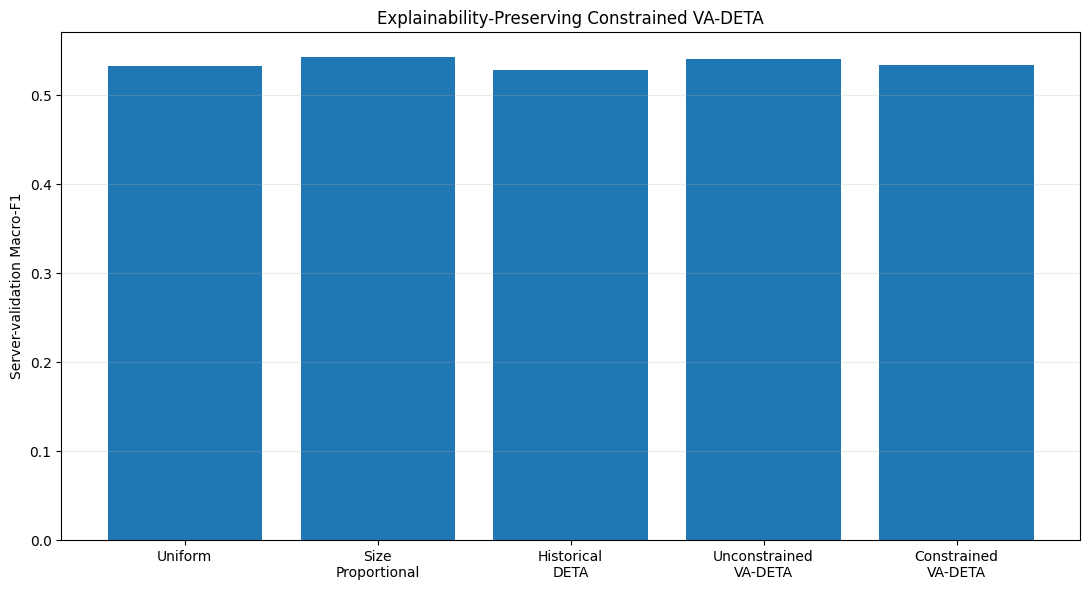

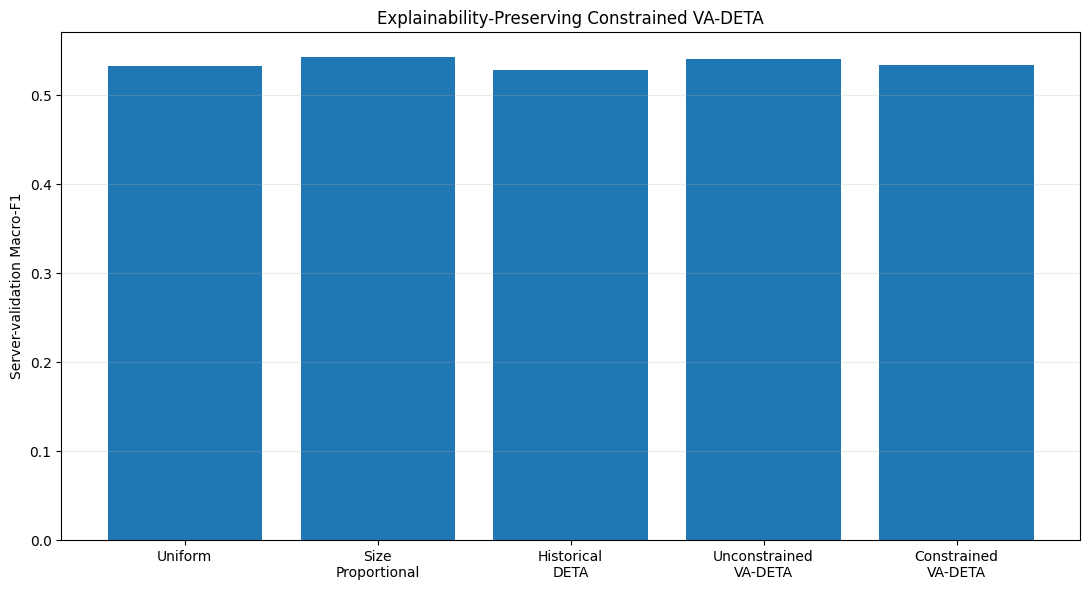

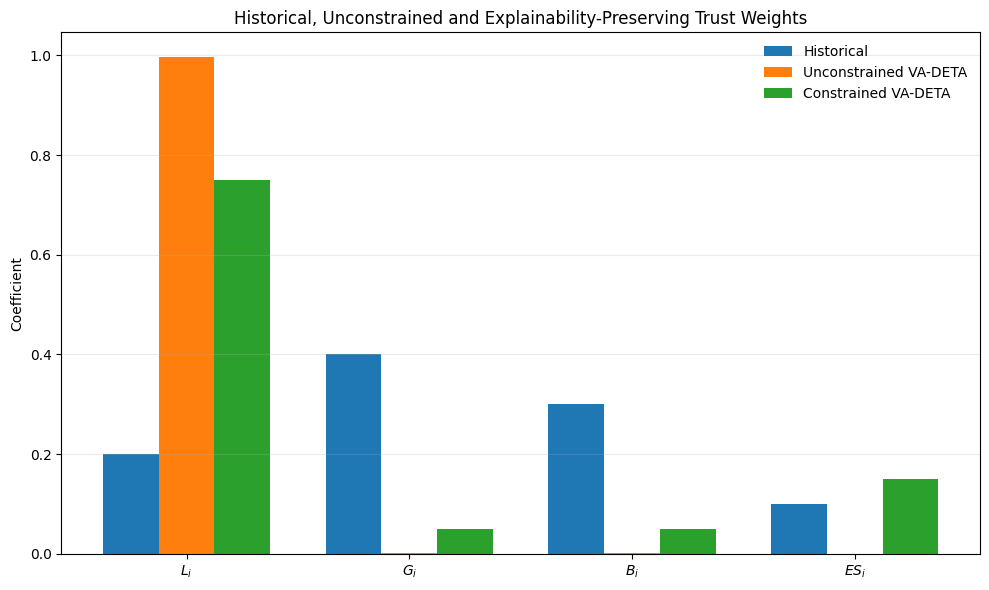

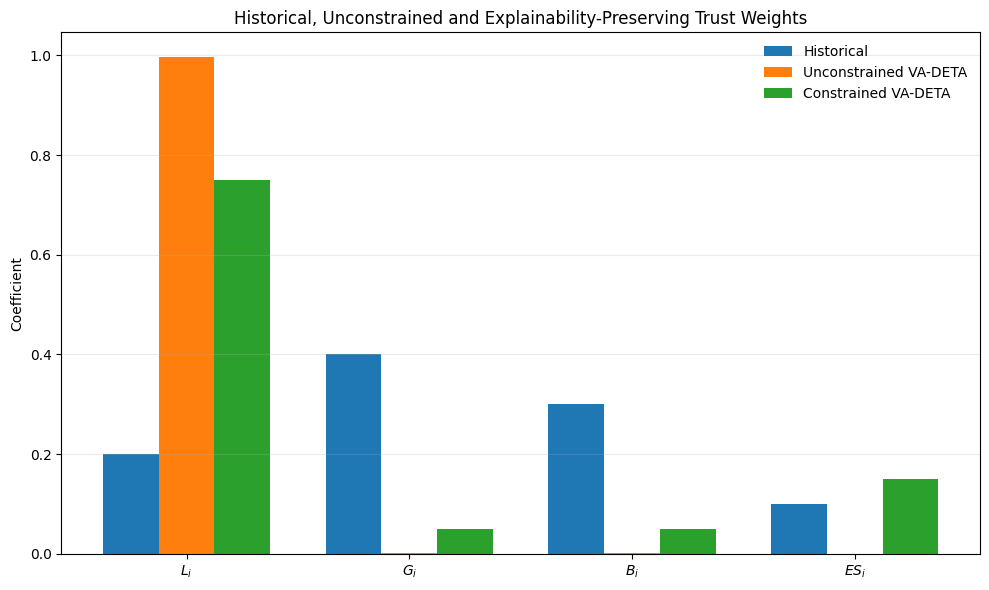

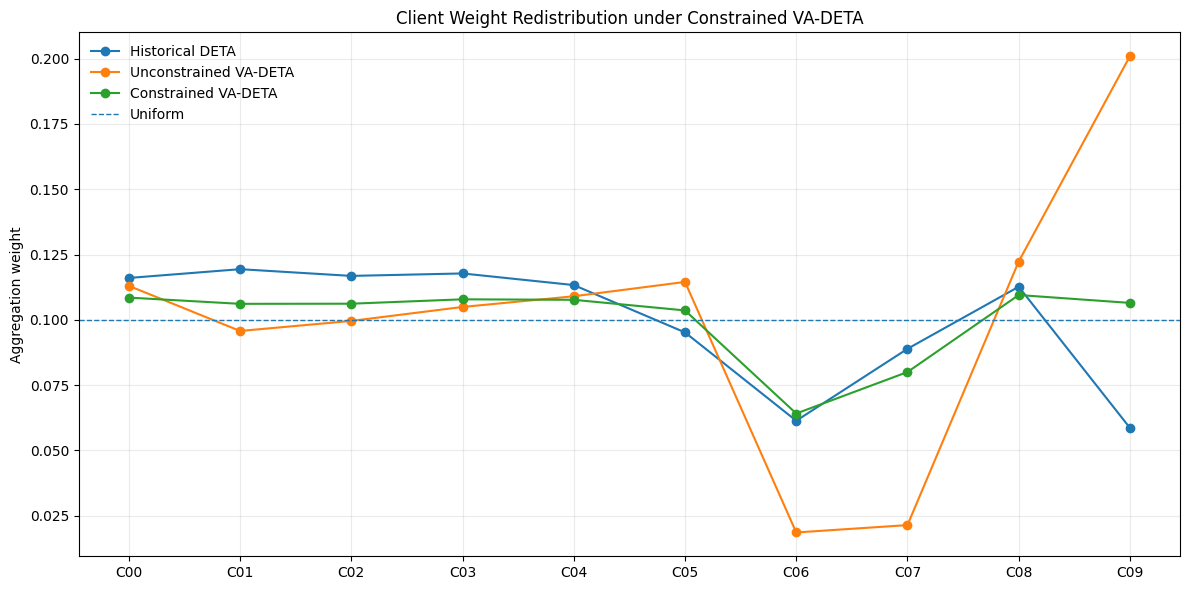

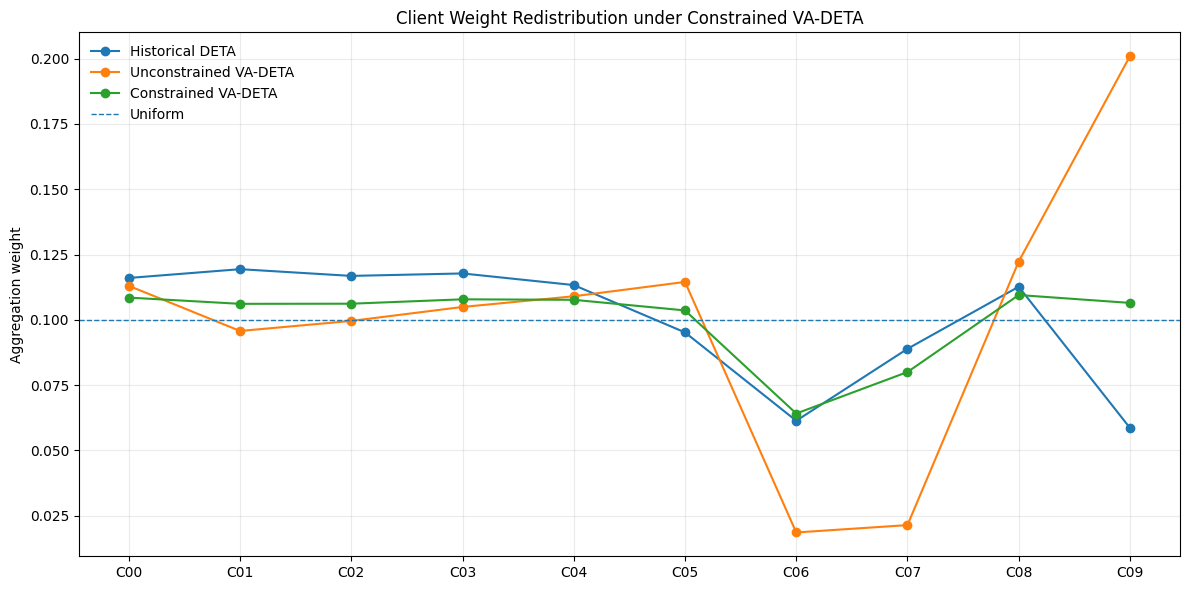


CELL 39B FINAL AUDIT

Frozen constrained VA-DETA equation:
T_i = 0.750000*L_i + 0.050000*G_i + 0.050000*B_i + 0.150000*ES_i

w_i = T_i^0.500000 / sum_j(T_j^0.500000)

Constraints:
alpha >= 0.05
beta  >= 0.05
gamma >= 0.05
delta >= 0.10

Server-validation Macro-F1:
Uniform                  : 0.53293944
Size proportional        : 0.54338590
Historical DETA          : 0.52777447
Unconstrained VA-DETA    : 0.54051830
Constrained VA-DETA      : 0.53345096

Macro-F1 differences:
vs Uniform               : +0.00051152
vs Size Proportional     : -0.00993493
vs Historical DETA       : +0.00567650
vs Unconstrained VA-DETA : -0.00706734

Explainability counterfactual:
Constrained VA-DETA Macro-F1: 0.53345096
Same solution without ES     : 0.53260631
Observed ES increment         : +0.00084465

Frozen configuration SHA256:
e943fca0133aee72b6badc2d1e7df02bed744f30601488060dca983e01cfb2b5

Independent test accessed : NO
Models retrained          : NO
Test-driven optimization  : NO
Historical DETA o

In [ ]:
# CELL 39B — EXPLAINABILITY-PRESERVING CONSTRAINED VA-DETA
#
# PURPOSE
# Test whether a validation-adaptive DETA rule can improve aggregation while
# preserving a meaningful contribution from ALL four trust channels.
#
# CONSTRAINTS
# alpha >= 0.05   -> L_i
# beta  >= 0.05   -> G_i
# gamma >= 0.05   -> B_i
# delta >= 0.10   -> ES_i
#
# alpha + beta + gamma + delta = 1
#
# Trust concentration:
#
#                  T_i ^ tau
#       w_i = --------------------
#              sum_j T_j ^ tau
#
# PRIMARY OBJECTIVE
# Maximize RESERVED SERVER-VALIDATION Macro-F1.
#
# Tie-breakers:
#   1. higher Balanced Accuracy
#   2. higher MCC
#   3. lower Log-Loss
#
# CRITICAL
# × NO independent-test access
# × NO independent-test probabilities
# × NO test-driven coefficient tuning
# × NO model retraining
#
# Historical DETA and unconstrained Cell 39 VA-DETA remain baselines.



from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import json
import time
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    log_loss
)

from IPython.display import display, Markdown


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 320)
pd.set_option("display.float_format", lambda x: f"{x:.8f}")


print("=" * 125)
print("CELL 39B — EXPLAINABILITY-PRESERVING CONSTRAINED VA-DETA")
print("=" * 125)


# 1. PATHS

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TRUST_DIR = (
    ROOT /
    "06_trust"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

TRUST_PATH = (
    TRUST_DIR /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

WEIGHT_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_aggregation_weights.csv"
)

SERVER_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_clients"
)

CELL39_CONFIG = (
    TRUST_DIR /
    "validation_adaptive_DETA" /
    "VA_DETA_FROZEN_server_validation_configuration.json"
)

OUTPUT_DIR = (
    TRUST_DIR /
    "constrained_validation_adaptive_DETA"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# 2. HARD TEST-ACCESS PROHIBITION

print("\n" + "=" * 125)
print("DATA-BOUNDARY AUDIT")
print("=" * 125)

print("Optimization partition : RESERVED SERVER VALIDATION")
print("Independent test       : NOT OPENED")
print("Models retrained       : NO")
print("Historical DETA altered: NO")


# 3. CONSTANTS

N_CLIENTS = 10
N_CLASSES = 34

SEARCH_SEED = 20260818

# Smaller search subset for efficient candidate screening.
SEARCH_SAMPLE_SIZE = 5_000


# Historical DETA
HISTORICAL_THETA = np.array(
    [
        0.20,
        0.40,
        0.30,
        0.10,
    ],
    dtype=np.float64
)

HISTORICAL_TAU = 1.0


# Scientifically motivated minimum evidence constraints

MIN_ALPHA = 0.05
MIN_BETA  = 0.05
MIN_GAMMA = 0.05

# Explainability cannot fall below its historical 10% nominal coefficient.
MIN_DELTA = 0.10


# Deterministic coefficient grid
#
# Step 0.05 gives a reasonably exhaustive constrained simplex without
# creating an excessive computational search.

GRID_STEP = 0.05


TAU_GRID = np.array(
    [
        0.50,
        0.75,
        1.00,
        1.25,
        1.50,
        1.75,
        2.00,
        2.25,
        2.50,
        3.00,
        4.00,
        5.00,
        6.00,
    ],
    dtype=np.float64
)


TOP_SUBSET_CANDIDATES_FOR_FULL_SERVER = 60


# 4. HELPERS

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def normalize_rows(prob):

    prob = np.asarray(
        prob,
        dtype=np.float64
    )

    prob = np.clip(
        prob,
        1e-15,
        None
    )

    row_sum = prob.sum(
        axis=1,
        keepdims=True
    )

    if np.any(row_sum <= 0):

        raise RuntimeError(
            "Invalid probability row sum."
        )

    return (
        prob /
        row_sum
    )


def trust_to_weights(
    component_matrix,
    theta,
    tau
):

    theta = np.asarray(
        theta,
        dtype=np.float64
    )

    if theta.shape != (4,):

        raise RuntimeError(
            "theta must contain four coefficients."
        )


    if not np.isclose(
        theta.sum(),
        1.0,
        atol=1e-10
    ):

        raise RuntimeError(
            f"Coefficient sum != 1: {theta.sum()}"
        )


    if theta[0] < MIN_ALPHA - 1e-12:
        raise RuntimeError("alpha constraint violated.")

    if theta[1] < MIN_BETA - 1e-12:
        raise RuntimeError("beta constraint violated.")

    if theta[2] < MIN_GAMMA - 1e-12:
        raise RuntimeError("gamma constraint violated.")

    if theta[3] < MIN_DELTA - 1e-12:
        raise RuntimeError("delta constraint violated.")


    raw_trust = (
        component_matrix
        @
        theta
    )


    raw_trust = np.clip(
        raw_trust,
        1e-12,
        None
    )


    if tau <= 0:

        raise RuntimeError(
            "tau must be > 0."
        )


    powered = np.power(
        raw_trust,
        tau
    )


    weights = (
        powered /
        powered.sum()
    )


    if not np.isclose(
        weights.sum(),
        1.0,
        atol=1e-12
    ):

        raise RuntimeError(
            "Weight normalization failed."
        )


    return (
        raw_trust,
        weights
    )


def unconstrained_trust_to_weights(
    component_matrix,
    theta,
    tau
):

    theta = np.asarray(
        theta,
        dtype=np.float64
    )

    theta = (
        theta /
        theta.sum()
    )

    raw_trust = (
        component_matrix
        @
        theta
    )

    raw_trust = np.clip(
        raw_trust,
        1e-12,
        None
    )

    powered = np.power(
        raw_trust,
        tau
    )

    return (
        raw_trust,
        powered /
        powered.sum()
    )


def aggregate_probabilities(
    prob_stack,
    weights
):

    aggregate = np.tensordot(
        weights,
        prob_stack,
        axes=(0, 0)
    )

    return normalize_rows(
        aggregate
    )


def evaluate(
    y_true,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )

    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    labels=np.arange(
                        N_CLASSES
                    ),
                    average="macro",
                    zero_division=0
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    y_true,
                    pred
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_true,
                    prob,
                    labels=np.arange(
                        N_CLASSES
                    )
                )
            ),
    }


def rank_candidates(df):

    return df.sort_values(
        by=[
            "Macro_F1",
            "Balanced_Accuracy",
            "MCC",
            "Log_Loss",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ]
    ).reset_index(
        drop=True
    )


# 5. LOAD TRUST COMPONENTS

if not TRUST_PATH.exists():

    raise FileNotFoundError(
        TRUST_PATH
    )


trust_df = pd.read_csv(
    TRUST_PATH
).sort_values(
    "Client_ID"
).reset_index(
    drop=True
)


required_cols = [
    "Client_ID",
    "L_i",
    "G_i",
    "B_i",
    "ES_i",
]


missing = [
    c
    for c in required_cols
    if c not in trust_df.columns
]


if missing:

    raise RuntimeError(
        f"Missing trust columns: {missing}"
    )


if len(trust_df) != N_CLIENTS:

    raise RuntimeError(
        "Expected 10 trust rows."
    )


COMPONENT_MATRIX = trust_df[
    [
        "L_i",
        "G_i",
        "B_i",
        "ES_i",
    ]
].to_numpy(
    dtype=np.float64
)


print("\nTrust components:")
display(
    trust_df[
        required_cols
    ]
)


# 6. LOAD SERVER LABELS

server_df = pd.read_parquet(
    SERVER_PATH,
    columns=[
        "Label_Encoded"
    ]
)


y_server = server_df[
    "Label_Encoded"
].to_numpy(
    dtype=np.int32
)


if len(np.unique(y_server)) != 34:

    raise RuntimeError(
        "Expected all 34 server-validation classes."
    )


print(
    "\nServer-validation rows:",
    f"{len(y_server):,}"
)


# 7. LOAD CLIENT SERVER-VALIDATION PROBABILITIES

print("\n" + "=" * 125)
print("SERVER-VALIDATION CLIENT PROBABILITIES")
print("=" * 125)


client_probabilities = []


for client_id in range(N_CLIENTS):

    candidates = sorted(
        SERVER_PROB_DIR.glob(
            f"*client_{client_id:02d}*.npy"
        )
    )


    if len(candidates) == 0:

        raise FileNotFoundError(
            f"Missing server-validation probability matrix "
            f"for Client {client_id:02d}"
        )


    path = candidates[0]


    prob = np.load(
        path
    )


    if prob.shape != (
        len(y_server),
        N_CLASSES
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: "
            f"invalid probability shape {prob.shape}"
        )


    prob = normalize_rows(
        prob
    )


    client_probabilities.append(
        prob.astype(
            np.float32
        )
    )


    print(
        f"Client {client_id:02d}: "
        f"{prob.shape} — PASSED"
    )


PROB_STACK = np.stack(
    client_probabilities,
    axis=0
)


print(
    "\nStack shape:",
    PROB_STACK.shape
)


# 8. LOAD SIMPLE BASELINE WEIGHTS

weight_df = pd.read_csv(
    WEIGHT_PATH
).sort_values(
    "Client_ID"
)


UNIFORM_WEIGHTS = np.repeat(
    1.0 / N_CLIENTS,
    N_CLIENTS
)


SIZE_WEIGHTS = weight_df[
    "Size_Proportional"
].to_numpy(
    dtype=np.float64
)


SIZE_WEIGHTS /= SIZE_WEIGHTS.sum()


# 9. BASELINE SERVER-VALIDATION METRICS

baseline_rows = []


# Uniform
uniform_prob = aggregate_probabilities(
    PROB_STACK,
    UNIFORM_WEIGHTS
)

uniform_metrics = evaluate(
    y_server,
    uniform_prob
)


baseline_rows.append({
    "Method": "Uniform",
    **uniform_metrics
})


# Size proportional
size_prob = aggregate_probabilities(
    PROB_STACK,
    SIZE_WEIGHTS
)

size_metrics = evaluate(
    y_server,
    size_prob
)


baseline_rows.append({
    "Method": "Size_Proportional",
    **size_metrics
})


# Historical DETA
hist_trust, hist_weights = unconstrained_trust_to_weights(
    COMPONENT_MATRIX,
    HISTORICAL_THETA,
    HISTORICAL_TAU
)


hist_prob = aggregate_probabilities(
    PROB_STACK,
    hist_weights
)


hist_metrics = evaluate(
    y_server,
    hist_prob
)


baseline_rows.append({
    "Method": "Historical_DETA",
    **hist_metrics
})


# 10. LOAD UNCONSTRAINED CELL 39 CONFIGURATION

if not CELL39_CONFIG.exists():

    raise FileNotFoundError(
        f"Cell 39 frozen configuration missing:\n"
        f"{CELL39_CONFIG}"
    )


with open(
    CELL39_CONFIG,
    "r"
) as f:

    cell39_obj = json.load(f)


adaptive = cell39_obj[
    "adaptive_configuration"
]


CELL39_THETA = np.array(
    [
        adaptive[
            "alpha_L"
        ],
        adaptive[
            "beta_G"
        ],
        adaptive[
            "gamma_B"
        ],
        adaptive[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


CELL39_TAU = float(
    adaptive[
        "tau"
    ]
)


cell39_trust, cell39_weights = unconstrained_trust_to_weights(
    COMPONENT_MATRIX,
    CELL39_THETA,
    CELL39_TAU
)


cell39_prob = aggregate_probabilities(
    PROB_STACK,
    cell39_weights
)


cell39_metrics = evaluate(
    y_server,
    cell39_prob
)


baseline_rows.append({
    "Method": "Unconstrained_VA_DETA_Cell39",
    **cell39_metrics
})


baseline_df = pd.DataFrame(
    baseline_rows
)


print("\n" + "=" * 125)
print("BASELINE PERFORMANCE")
print("=" * 125)


display(
    baseline_df
)


BEST_SIMPLE_MACRO_F1 = max(
    uniform_metrics[
        "Macro_F1"
    ],
    size_metrics[
        "Macro_F1"
    ]
)


# 11. FIXED CLASS-PRESERVING SERVER SEARCH SUBSET

print("\n" + "=" * 125)
print("BUILDING FIXED SEARCH SUBSET")
print("=" * 125)


rng = np.random.default_rng(
    SEARCH_SEED
)


selected_indices = []


for class_id in range(
    N_CLASSES
):

    class_indices = np.flatnonzero(
        y_server
        ==
        class_id
    )


    if len(class_indices) == 0:
        continue


    quota = max(
        1,
        int(
            round(
                SEARCH_SAMPLE_SIZE
                *
                len(class_indices)
                /
                len(y_server)
            )
        )
    )


    quota = min(
        quota,
        len(class_indices)
    )


    chosen = rng.choice(
        class_indices,
        size=quota,
        replace=False
    )


    selected_indices.extend(
        chosen.tolist()
    )


selected_indices = np.array(
    sorted(
        set(
            selected_indices
        )
    ),
    dtype=np.int64
)


# Trim / fill to exact target size.
if len(selected_indices) > SEARCH_SAMPLE_SIZE:

    selected_indices = rng.choice(
        selected_indices,
        size=SEARCH_SAMPLE_SIZE,
        replace=False
    )


elif len(selected_indices) < SEARCH_SAMPLE_SIZE:

    remaining = np.setdiff1d(
        np.arange(
            len(y_server)
        ),
        selected_indices
    )


    extra = rng.choice(
        remaining,
        size=(
            SEARCH_SAMPLE_SIZE
            -
            len(selected_indices)
        ),
        replace=False
    )


    selected_indices = np.concatenate(
        [
            selected_indices,
            extra
        ]
    )


rng.shuffle(
    selected_indices
)


y_search = y_server[
    selected_indices
]


PROB_SEARCH = PROB_STACK[
    :,
    selected_indices,
    :
]


print(
    "Search rows:",
    len(y_search)
)


print(
    "Classes:",
    len(
        np.unique(
            y_search
        )
    )
)


# 12. CONSTRUCT CONSTRAINED SIMPLEX

print("\n" + "=" * 125)
print("CONSTRAINED COEFFICIENT GRID")
print("=" * 125)


grid_values = np.round(
    np.arange(
        0.0,
        1.0 + GRID_STEP / 2,
        GRID_STEP
    ),
    10
)


theta_candidates = []


for alpha in grid_values:

    if alpha < MIN_ALPHA - 1e-12:
        continue


    for beta in grid_values:

        if beta < MIN_BETA - 1e-12:
            continue


        for gamma in grid_values:

            if gamma < MIN_GAMMA - 1e-12:
                continue


            delta = (
                1.0
                -
                alpha
                -
                beta
                -
                gamma
            )


            # Delta must lie on same grid approximately.
            if delta < MIN_DELTA - 1e-12:
                continue


            if delta > 1.0 + 1e-12:
                continue


            delta_units = delta / GRID_STEP


            if not np.isclose(
                delta_units,
                round(delta_units),
                atol=1e-8
            ):
                continue


            theta = np.array(
                [
                    alpha,
                    beta,
                    gamma,
                    delta,
                ],
                dtype=np.float64
            )


            if not np.isclose(
                theta.sum(),
                1.0,
                atol=1e-10
            ):
                continue


            theta_candidates.append(
                theta
            )


theta_candidates = np.vstack(
    theta_candidates
)


print(
    "Valid constrained coefficient combinations:",
    len(theta_candidates)
)


print(
    "Tau values:",
    len(TAU_GRID)
)


print(
    "Total search candidates:",
    len(theta_candidates)
    *
    len(TAU_GRID)
)


# 13. CONSTRAINED SUBSET SEARCH

search_rows = []


search_start = time.perf_counter()


candidate_id = 0


for theta in theta_candidates:

    for tau in TAU_GRID:

        candidate_id += 1


        raw_trust, weights = trust_to_weights(
            COMPONENT_MATRIX,
            theta,
            tau
        )


        aggregate = aggregate_probabilities(
            PROB_SEARCH,
            weights
        )


        metrics = evaluate(
            y_search,
            aggregate
        )


        entropy = float(
            -np.sum(
                weights
                *
                np.log(
                    weights
                    +
                    1e-15
                )
            )
        )


        search_rows.append({

            "Candidate_ID":
                candidate_id,

            "Alpha_L":
                theta[
                    0
                ],

            "Beta_G":
                theta[
                    1
                ],

            "Gamma_B":
                theta[
                    2
                ],

            "Delta_ES":
                theta[
                    3
                ],

            "Tau":
                tau,

            "Weight_Min":
                float(
                    weights.min()
                ),

            "Weight_Max":
                float(
                    weights.max()
                ),

            "Weight_Entropy":
                entropy,

            **metrics,
        })


search_seconds = (
    time.perf_counter()
    -
    search_start
)


search_df = rank_candidates(
    pd.DataFrame(
        search_rows
    )
)


print(
    "\nSearch time:",
    f"{search_seconds:.2f}s"
)


print("\nTop constrained candidates on fixed search subset:")


display(
    search_df.head(
        20
    )
)


# 14. FULL SERVER VERIFICATION

print("\n" + "=" * 125)
print("FULL SERVER-VALIDATION VERIFICATION")
print("=" * 125)


top_search = search_df.head(
    TOP_SUBSET_CANDIDATES_FOR_FULL_SERVER
).copy()


full_rows = []


for _, row in top_search.iterrows():

    theta = np.array(
        [
            row[
                "Alpha_L"
            ],
            row[
                "Beta_G"
            ],
            row[
                "Gamma_B"
            ],
            row[
                "Delta_ES"
            ],
        ],
        dtype=np.float64
    )


    tau = float(
        row[
            "Tau"
        ]
    )


    raw_trust, weights = trust_to_weights(
        COMPONENT_MATRIX,
        theta,
        tau
    )


    aggregate = aggregate_probabilities(
        PROB_STACK,
        weights
    )


    metrics = evaluate(
        y_server,
        aggregate
    )


    full_rows.append({

        "Alpha_L":
            theta[
                0
            ],

        "Beta_G":
            theta[
                1
            ],

        "Gamma_B":
            theta[
                2
            ],

        "Delta_ES":
            theta[
                3
            ],

        "Tau":
            tau,

        "Weight_Min":
            float(
                weights.min()
            ),

        "Weight_Max":
            float(
                weights.max()
            ),

        **metrics,
    })


full_df = rank_candidates(
    pd.DataFrame(
        full_rows
    )
)


print("\nTop full-server constrained configurations:")


display(
    full_df.head(
        20
    )
)


# 15. FREEZE BEST CONSTRAINED CONFIGURATION

BEST = full_df.iloc[
    0
]


BEST_THETA = np.array(
    [
        BEST[
            "Alpha_L"
        ],
        BEST[
            "Beta_G"
        ],
        BEST[
            "Gamma_B"
        ],
        BEST[
            "Delta_ES"
        ],
    ],
    dtype=np.float64
)


BEST_TAU = float(
    BEST[
        "Tau"
    ]
)


BEST_TRUST, BEST_WEIGHTS = trust_to_weights(
    COMPONENT_MATRIX,
    BEST_THETA,
    BEST_TAU
)


BEST_PROB = aggregate_probabilities(
    PROB_STACK,
    BEST_WEIGHTS
)


BEST_METRICS = evaluate(
    y_server,
    BEST_PROB
)


# 16. EXPLAINABILITY COUNTERFACTUAL
#
# Remove ES from this EXACT selected coefficient vector and proportionally
# renormalize L/G/B.
#
# This tests whether retaining ES changes the selected adaptive solution.

predictive_theta = BEST_THETA.copy()

predictive_theta[
    3
] = 0.0


predictive_theta[
    :3
] = (
    predictive_theta[
        :3
    ]
    /
    predictive_theta[
        :3
    ].sum()
)


counter_trust, counter_weights = unconstrained_trust_to_weights(
    COMPONENT_MATRIX,
    predictive_theta,
    BEST_TAU
)


counter_prob = aggregate_probabilities(
    PROB_STACK,
    counter_weights
)


COUNTER_METRICS = evaluate(
    y_server,
    counter_prob
)


# 17. FINAL COMPARISON

comparison_rows = []


for _, row in baseline_df.iterrows():

    comparison_rows.append({

        "Method":
            row[
                "Method"
            ],

        "Accuracy":
            row[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            row[
                "Balanced_Accuracy"
            ],

        "Macro_F1":
            row[
                "Macro_F1"
            ],

        "MCC":
            row[
                "MCC"
            ],

        "Log_Loss":
            row[
                "Log_Loss"
            ],
    })


comparison_rows.append({

    "Method":
        "Constrained_VA_DETA",

    **BEST_METRICS,
})


comparison_rows.append({

    "Method":
        "Constrained_VA_DETA_without_ES_counterfactual",

    **COUNTER_METRICS,
})


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 125)
print("FINAL SERVER-VALIDATION COMPARISON")
print("=" * 125)


display(
    comparison_df
)


GAIN_VS_SIZE = (
    BEST_METRICS[
        "Macro_F1"
    ]
    -
    size_metrics[
        "Macro_F1"
    ]
)


GAIN_VS_UNIFORM = (
    BEST_METRICS[
        "Macro_F1"
    ]
    -
    uniform_metrics[
        "Macro_F1"
    ]
)


GAIN_VS_HIST = (
    BEST_METRICS[
        "Macro_F1"
    ]
    -
    hist_metrics[
        "Macro_F1"
    ]
)


GAIN_VS_UNCONSTRAINED = (
    BEST_METRICS[
        "Macro_F1"
    ]
    -
    cell39_metrics[
        "Macro_F1"
    ]
)


ES_INCREMENT = (
    BEST_METRICS[
        "Macro_F1"
    ]
    -
    COUNTER_METRICS[
        "Macro_F1"
    ]
)


# 18. CLIENT WEIGHT AUDIT

weight_audit = trust_df[
    [
        "Client_ID"
    ]
].copy()


if "Role" in trust_df.columns:

    weight_audit[
        "Role"
    ] = trust_df[
        "Role"
    ]


weight_audit[
    "Historical_Weight"
] = hist_weights


weight_audit[
    "Unconstrained_VA_DETA_Weight"
] = cell39_weights


weight_audit[
    "Constrained_VA_DETA_Weight"
] = BEST_WEIGHTS


weight_audit[
    "Constrained_Without_ES_Weight"
] = counter_weights


weight_audit[
    "Constrained_minus_Historical"
] = (
    BEST_WEIGHTS
    -
    hist_weights
)


weight_audit[
    "ES_Weight_Effect"
] = (
    BEST_WEIGHTS
    -
    counter_weights
)


print("\n" + "=" * 125)
print("CLIENT WEIGHT AUDIT")
print("=" * 125)


display(
    weight_audit
)


# 19. COMPONENT CONTRIBUTION AUDIT

contribution_matrix = (
    COMPONENT_MATRIX
    *
    BEST_THETA[
        None,
        :
    ]
)


contribution_df = pd.DataFrame({

    "Client_ID":
        trust_df[
            "Client_ID"
        ],

    "L_Contribution":
        contribution_matrix[
            :,
            0
        ],

    "G_Contribution":
        contribution_matrix[
            :,
            1
        ],

    "B_Contribution":
        contribution_matrix[
            :,
            2
        ],

    "ES_Contribution":
        contribution_matrix[
            :,
            3
        ],

    "Raw_Trust":
        BEST_TRUST,

    "Final_Weight":
        BEST_WEIGHTS,
})


print("\nComponent contribution audit:")

display(
    contribution_df
)


# 20. FIGURE — PERFORMANCE

plot_methods = [
    "Uniform",
    "Size_Proportional",
    "Historical_DETA",
    "Unconstrained_VA_DETA_Cell39",
    "Constrained_VA_DETA",
]


plot_df = (
    comparison_df[
        comparison_df[
            "Method"
        ].isin(
            plot_methods
        )
    ]
    .set_index(
        "Method"
    )
    .loc[
        plot_methods
    ]
    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)


x = np.arange(
    len(
        plot_df
    )
)


ax.bar(
    x,
    plot_df[
        "Macro_F1"
    ]
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Uniform",
        "Size\nProportional",
        "Historical\nDETA",
        "Unconstrained\nVA-DETA",
        "Constrained\nVA-DETA",
    ]
)


ax.set_ylabel(
    "Server-validation Macro-F1"
)


ax.set_title(
    "Explainability-Preserving Constrained VA-DETA"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    Markdown(
        "### Constrained VA-DETA — Server-Validation Performance"
    )
)


display(fig)


PERF_PNG = (
    FIG_DIR /
    "34_constrained_VA_DETA_server_validation_performance.png"
)


PERF_PDF = (
    FIG_DIR /
    "34_constrained_VA_DETA_server_validation_performance.pdf"
)


fig.savefig(
    PERF_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    PERF_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# 21. FIGURE — COEFFICIENTS

fig, ax = plt.subplots(
    figsize=(10, 6)
)


labels = [
    r"$L_i$",
    r"$G_i$",
    r"$B_i$",
    r"$ES_i$",
]


x = np.arange(4)

width = 0.25


ax.bar(
    x - width,
    HISTORICAL_THETA,
    width,
    label="Historical"
)


ax.bar(
    x,
    CELL39_THETA,
    width,
    label="Unconstrained VA-DETA"
)


ax.bar(
    x + width,
    BEST_THETA,
    width,
    label="Constrained VA-DETA"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    labels
)


ax.set_ylabel(
    "Coefficient"
)


ax.set_title(
    "Historical, Unconstrained and Explainability-Preserving Trust Weights"
)


ax.legend(
    frameon=False
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(fig)


COEF_PNG = (
    FIG_DIR /
    "35_constrained_VA_DETA_coefficients.png"
)


COEF_PDF = (
    FIG_DIR /
    "35_constrained_VA_DETA_coefficients.pdf"
)


fig.savefig(
    COEF_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    COEF_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# 22. FIGURE — CLIENT WEIGHTS

fig, ax = plt.subplots(
    figsize=(12, 6)
)


x = np.arange(
    N_CLIENTS
)


ax.plot(
    x,
    hist_weights,
    marker="o",
    label="Historical DETA"
)


ax.plot(
    x,
    cell39_weights,
    marker="o",
    label="Unconstrained VA-DETA"
)


ax.plot(
    x,
    BEST_WEIGHTS,
    marker="o",
    label="Constrained VA-DETA"
)


ax.axhline(
    0.10,
    linestyle="--",
    linewidth=1,
    label="Uniform"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        f"C{i:02d}"
        for i in range(
            N_CLIENTS
        )
    ]
)


ax.set_ylabel(
    "Aggregation weight"
)


ax.set_title(
    "Client Weight Redistribution under Constrained VA-DETA"
)


ax.legend(
    frameon=False
)


ax.grid(
    alpha=0.25
)


fig.tight_layout()


display(fig)


WEIGHT_PNG = (
    FIG_DIR /
    "36_constrained_VA_DETA_client_weights.png"
)


WEIGHT_PDF = (
    FIG_DIR /
    "36_constrained_VA_DETA_client_weights.pdf"
)


fig.savefig(
    WEIGHT_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    WEIGHT_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# 23. SAVE TABLES

SEARCH_OUT = (
    TABLE_DIR /
    "cell39B_constrained_VA_DETA_subset_search.csv"
)


FULL_OUT = (
    TABLE_DIR /
    "cell39B_constrained_VA_DETA_full_server_candidates.csv"
)


COMPARISON_OUT = (
    TABLE_DIR /
    "cell39B_constrained_VA_DETA_server_validation_comparison.csv"
)


WEIGHT_OUT = (
    TABLE_DIR /
    "cell39B_constrained_VA_DETA_client_weights.csv"
)


CONTRIBUTION_OUT = (
    TABLE_DIR /
    "cell39B_constrained_VA_DETA_component_contributions.csv"
)


search_df.to_csv(
    SEARCH_OUT,
    index=False
)


full_df.to_csv(
    FULL_OUT,
    index=False
)


comparison_df.to_csv(
    COMPARISON_OUT,
    index=False
)


weight_audit.to_csv(
    WEIGHT_OUT,
    index=False
)


contribution_df.to_csv(
    CONTRIBUTION_OUT,
    index=False
)


# 24. FREEZE CONFIGURATION

CONFIG_OUT = (
    OUTPUT_DIR /
    "CONSTRAINED_VA_DETA_FROZEN_configuration.json"
)


frozen_config = {

    "method":
        "Explainability-Preserving Constrained VA-DETA",

    "status":
        "FROZEN_BEFORE_INDEPENDENT_TEST",

    "selection_partition":
        "reserved server validation only",

    "independent_test_accessed":
        False,

    "optimization_target":
        "Macro_F1",

    "constraints": {

        "alpha_L_min":
            MIN_ALPHA,

        "beta_G_min":
            MIN_BETA,

        "gamma_B_min":
            MIN_GAMMA,

        "delta_ES_min":
            MIN_DELTA,

        "coefficient_sum":
            1.0,
    },

    "selected_parameters": {

        "alpha_L":
            float(
                BEST_THETA[
                    0
                ]
            ),

        "beta_G":
            float(
                BEST_THETA[
                    1
                ]
            ),

        "gamma_B":
            float(
                BEST_THETA[
                    2
                ]
            ),

        "delta_ES":
            float(
                BEST_THETA[
                    3
                ]
            ),

        "tau":
            float(
                BEST_TAU
            ),
    },

    "server_validation_metrics":
        {
            key:
                float(value)
            for key, value
            in BEST_METRICS.items()
        },

    "macro_f1_gain_vs_uniform":
        float(
            GAIN_VS_UNIFORM
        ),

    "macro_f1_gain_vs_size_proportional":
        float(
            GAIN_VS_SIZE
        ),

    "macro_f1_gain_vs_historical_DETA":
        float(
            GAIN_VS_HIST
        ),

    "macro_f1_gain_vs_unconstrained_VA_DETA":
        float(
            GAIN_VS_UNCONSTRAINED
        ),

    "macro_f1_increment_from_ES_vs_selected_counterfactual":
        float(
            ES_INCREMENT
        ),

    "historical_theta":
        HISTORICAL_THETA.tolist(),

    "unconstrained_cell39_theta":
        CELL39_THETA.tolist(),

    "unconstrained_cell39_tau":
        float(
            CELL39_TAU
        ),

    "client_weights":
        {
            str(i):
                float(
                    BEST_WEIGHTS[
                        i
                    ]
                )
            for i in range(
                N_CLIENTS
            )
        },

    "search": {

        "seed":
            SEARCH_SEED,

        "subset_rows":
            SEARCH_SAMPLE_SIZE,

        "grid_step":
            GRID_STEP,

        "tau_grid":
            TAU_GRID.tolist(),

        "coefficient_candidates":
            int(
                len(
                    theta_candidates
                )
            ),

        "total_subset_candidates":
            int(
                len(
                    search_df
                )
            ),

        "full_server_candidates":
            int(
                len(
                    full_df
                )
            ),
    },
}


with open(
    CONFIG_OUT,
    "w"
) as f:

    json.dump(
        frozen_config,
        f,
        indent=4
    )


CONFIG_SHA256 = sha256_file(
    CONFIG_OUT
)


# 25. MANIFEST

MANIFEST_OUT = (
    REPRO_DIR /
    "cell39B_constrained_VA_DETA_manifest.json"
)


manifest = {

    "cell":
        "39B",

    "method":
        "Explainability-Preserving Constrained VA-DETA",

    "server_validation_only":
        True,

    "independent_test_accessed":
        False,

    "models_retrained":
        False,

    "test_driven_tuning":
        False,

    "configuration_file":
        str(
            CONFIG_OUT
        ),

    "configuration_sha256":
        CONFIG_SHA256,

    "outputs": {

        "subset_search":
            str(
                SEARCH_OUT
            ),

        "full_server_candidates":
            str(
                FULL_OUT
            ),

        "comparison":
            str(
                COMPARISON_OUT
            ),

        "client_weights":
            str(
                WEIGHT_OUT
            ),

        "component_contributions":
            str(
                CONTRIBUTION_OUT
            ),

        "performance_figure":
            str(
                PERF_PNG
            ),

        "coefficient_figure":
            str(
                COEF_PNG
            ),

        "weight_figure":
            str(
                WEIGHT_PNG
            ),
    },
}


with open(
    MANIFEST_OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 26. FINAL AUDIT

print("\n" + "=" * 125)
print("CELL 39B FINAL AUDIT")
print("=" * 125)


print("\nFrozen constrained VA-DETA equation:")


print(
    f"T_i = "
    f"{BEST_THETA[0]:.6f}*L_i + "
    f"{BEST_THETA[1]:.6f}*G_i + "
    f"{BEST_THETA[2]:.6f}*B_i + "
    f"{BEST_THETA[3]:.6f}*ES_i"
)


print(
    f"\nw_i = T_i^{BEST_TAU:.6f} / "
    f"sum_j(T_j^{BEST_TAU:.6f})"
)


print("\nConstraints:")

print(
    f"alpha >= {MIN_ALPHA:.2f}"
)

print(
    f"beta  >= {MIN_BETA:.2f}"
)

print(
    f"gamma >= {MIN_GAMMA:.2f}"
)

print(
    f"delta >= {MIN_DELTA:.2f}"
)


print("\nServer-validation Macro-F1:")

print(
    "Uniform                  :",
    f"{uniform_metrics['Macro_F1']:.8f}"
)

print(
    "Size proportional        :",
    f"{size_metrics['Macro_F1']:.8f}"
)

print(
    "Historical DETA          :",
    f"{hist_metrics['Macro_F1']:.8f}"
)

print(
    "Unconstrained VA-DETA    :",
    f"{cell39_metrics['Macro_F1']:.8f}"
)

print(
    "Constrained VA-DETA      :",
    f"{BEST_METRICS['Macro_F1']:.8f}"
)


print("\nMacro-F1 differences:")

print(
    "vs Uniform               :",
    f"{GAIN_VS_UNIFORM:+.8f}"
)

print(
    "vs Size Proportional     :",
    f"{GAIN_VS_SIZE:+.8f}"
)

print(
    "vs Historical DETA       :",
    f"{GAIN_VS_HIST:+.8f}"
)

print(
    "vs Unconstrained VA-DETA :",
    f"{GAIN_VS_UNCONSTRAINED:+.8f}"
)


print("\nExplainability counterfactual:")

print(
    "Constrained VA-DETA Macro-F1:",
    f"{BEST_METRICS['Macro_F1']:.8f}"
)

print(
    "Same solution without ES     :",
    f"{COUNTER_METRICS['Macro_F1']:.8f}"
)

print(
    "Observed ES increment         :",
    f"{ES_INCREMENT:+.8f}"
)


print("\nFrozen configuration SHA256:")
print(
    CONFIG_SHA256
)


print("\nIndependent test accessed : NO")
print("Models retrained          : NO")
print("Test-driven optimization  : NO")
print("Historical DETA overwritten: NO")


# 27. DECISION GUIDE

print("\n" + "=" * 125)
print("SCIENTIFIC DECISION GUIDE")
print("=" * 125)


if GAIN_VS_SIZE > 0:

    print(
        "RESULT: Constrained VA-DETA BEATS size-proportional "
        "aggregation on server-validation Macro-F1."
    )

    print(
        "This configuration may now be frozen and evaluated once "
        "on the independent test."
    )

else:

    print(
        "RESULT: Constrained VA-DETA does NOT beat size-proportional "
        "aggregation on server-validation Macro-F1."
    )

    print(
        "Do not continue repeated scalar coefficient searches."
    )

    print(
        "The next methodological candidate should be class-conditional "
        "or instance-conditional trust rather than another global scalar equation."
    )


if ES_INCREMENT > 0:

    print(
        "\nES COUNTERFACTUAL: retaining ES improves server-validation "
        "Macro-F1 for the selected constrained solution."
    )

else:

    print(
        "\nES COUNTERFACTUAL: retaining ES does not improve Macro-F1 "
        "for the selected constrained solution."
    )

    print(
        "Its value may still need to be established under specific "
        "threat conditions rather than ordinary aggregate performance."
    )


print("\nSaved:")
print(SEARCH_OUT)
print(FULL_OUT)
print(COMPARISON_OUT)
print(WEIGHT_OUT)
print(CONTRIBUTION_OUT)
print(CONFIG_OUT)
print(MANIFEST_OUT)
print(PERF_PNG)
print(PERF_PDF)
print(COEF_PNG)
print(COEF_PDF)
print(WEIGHT_PNG)
print(WEIGHT_PDF)


print(
    "\nCELL 39B STATUS: PASSED — "
    "CONSTRAINED VA-DETA FROZEN BEFORE INDEPENDENT TEST"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 40 — LEAKAGE-SAFE CLASS-CONDITIONAL DETA DEVELOPMENT
          SINGLETON-SAFE SERVER META-VALIDATION

DATA-BOUNDARY AUDIT
Development/local validation : L_{i,c}
Server trust subset          : G_{i,c}, R_{i,c}, ES_i
Server meta subset           : alpha,beta,gamma,delta,tau selection
Singleton server classes     : TRUST ONLY — NEVER duplicated
Independent test             : NOT ACCESSED
Models retrained             : NO

Frozen features: 30

SERVER TRUST / META SPLIT AUDIT


,Class_ID,Total_Rows,Trust_Rows,Meta_Rows,Split_Policy
0,0,4,3,1,Disjoint_Trust_Meta
1,1,1451,1016,435,Disjoint_Trust_Meta
2,2,8,6,2,Disjoint_Trust_Meta
3,3,9,6,3,Disjoint_Trust_Meta
4,4,389,272,117,Disjoint_Trust_Meta
5,5,34,24,10,Disjoint_Trust_Meta
6,6,9710,6797,2913,Disjoint_Trust_Meta
7,7,616,431,185,Disjoint_Trust_Meta
8,8,5501,3851,1650,Disjoint_Trust_Meta
9,9,5393,3775,1618,Disjoint_Trust_Meta



Total server rows: 62,983
Trust rows       : 44,087
Meta rows        : 18,896
Trust classes    : 34
Meta classes     : 33
Trust-only singleton classes: [31]

IMPORTANT:
These classes are excluded from coefficient/tau selection because they cannot appear in both disjoint server subsets.
They remain represented in the 34-class CC-DETA trust matrix.

LOCAL CLASS-CONDITIONAL EVIDENCE — L_{i,c}
Client 00 (Reliable): non-zero L_ic=25
Client 01 (Reliable): non-zero L_ic=24
Client 02 (Reliable): non-zero L_ic=22
Client 03 (Reliable): non-zero L_ic=25
Client 04 (NonIID_Reliable): non-zero L_ic=22
Client 05 (NonIID_Reliable): non-zero L_ic=18
Client 06 (LabelFlip): non-zero L_ic=17
Client 07 (LabelFlip): non-zero L_ic=18
Client 08 (Targeted_Poison): non-zero L_ic=21
Client 09 (SubsetClass_Reliable): non-zero L_ic=8

L_CLASS shape: (10, 34)

SERVER CLIENT PROBABILITIES
Client 00: (62983, 34) — PASSED
Client 01: (62983, 34) — PASSED
Client 02: (62983, 34) — PASSED
Client 03: (62983, 34) — PASSED


,Method,Accuracy,Balanced_Accuracy,Macro_F1,MCC,Weighted_F1,Log_Loss
0,Uniform,0.74454911,0.56514603,0.55633499,0.72946071,0.72224657,0.55177525
1,Size_Proportional,0.74232642,0.56539552,0.56752525,0.72363061,0.73497700,0.54011152
2,Historical_DETA,0.73946867,0.56137826,0.54680554,0.72656875,0.70532713,0.53240474
3,Unconstrained_VA_DETA,0.74460203,0.55605706,0.55900632,0.72512424,0.73374071,0.52298706
4,Constrained_VA_DETA,0.74322608,0.56140607,0.55091042,0.72858949,0.71723139,0.53569287



CLASS-CONDITIONAL COEFFICIENT SEARCH
Coefficient combinations: 969
Tau values: 10
Total candidates: 9690

Search seconds: 657.22

Top 20 CC-DETA configurations:


,Candidate_ID,Alpha_LocalClassF1,Beta_ServerClassF1,Gamma_ServerClassRecall,Delta_ES,Tau,Mean_ClassWeight_SD,Accuracy,Balanced_Accuracy,Macro_F1,MCC,Weighted_F1,Log_Loss
0,2870,0.10000000,0.75000000,0.05000000,0.10000000,4.00000000,0.09574798,0.74237934,0.57795769,0.58131181,0.72470472,0.73985829,0.51785878
1,2890,0.10000000,0.80000000,0.05000000,0.05000000,4.00000000,0.09908858,0.74338484,0.57687311,0.58111715,0.72519941,0.74065823,0.52248664
2,2889,0.10000000,0.80000000,0.05000000,0.05000000,3.00000000,0.09109127,0.73925699,0.57794972,0.58006190,0.72156614,0.73726345,0.52530134
3,2850,0.10000000,0.70000000,0.10000000,0.10000000,4.00000000,0.09623614,0.74036833,0.57759877,0.57979621,0.72307804,0.73680415,0.52084385
4,4070,0.15000000,0.70000000,0.05000000,0.10000000,4.00000000,0.09872018,0.74052710,0.57682110,0.57969959,0.72316262,0.73719324,0.51917454
5,2720,0.10000000,0.55000000,0.20000000,0.15000000,4.00000000,0.09426458,0.73698137,0.57879071,0.57965982,0.72056255,0.73211651,0.52199348
6,4000,0.15000000,0.60000000,0.05000000,0.20000000,4.00000000,0.09194858,0.73952159,0.57817256,0.57965074,0.72260053,0.73678147,0.51192659
7,5120,0.20000000,0.65000000,0.05000000,0.10000000,4.00000000,0.10144023,0.74010373,0.57689794,0.57957560,0.72308964,0.73580235,0.52047151
8,3950,0.15000000,0.55000000,0.05000000,0.25000000,4.00000000,0.08881541,0.73920406,0.57738532,0.57947501,0.72181239,0.73651940,0.50995250
9,2810,0.10000000,0.65000000,0.10000000,0.15000000,4.00000000,0.09251385,0.73999788,0.57757771,0.57932180,0.72307984,0.73696440,0.51665784



FINAL META-VALIDATION COMPARISON


,Method,Accuracy,Balanced_Accuracy,Macro_F1,MCC,Weighted_F1,Log_Loss
0,Uniform,0.74454911,0.56514603,0.55633499,0.72946071,0.72224657,0.55177525
1,Size_Proportional,0.74232642,0.56539552,0.56752525,0.72363061,0.73497700,0.54011152
2,Historical_DETA,0.73946867,0.56137826,0.54680554,0.72656875,0.70532713,0.53240474
3,Unconstrained_VA_DETA,0.74460203,0.55605706,0.55900632,0.72512424,0.73374071,0.52298706
4,Constrained_VA_DETA,0.74322608,0.56140607,0.55091042,0.72858949,0.71723139,0.53569287
5,CC_DETA,0.74237934,0.57795769,0.58131181,0.72470472,0.73985829,0.51785878
6,CC_DETA_without_ES_counterfactual,0.74857113,0.57027059,0.57668489,0.72998902,0.74131229,0.53224269



META-REPRESENTED CLASS EFFECT


,Class_ID,CC_DETA_F1,Size_Proportional_F1,CC_minus_Size_F1
0,0,0.00000000,0.00000000,0.00000000
1,1,0.83146067,0.82000000,0.01146067
2,2,0.00000000,0.00000000,0.00000000
3,3,0.50000000,0.00000000,0.50000000
4,4,0.98734177,0.98319328,0.00414849
5,5,0.70588235,0.70588235,0.00000000
6,6,0.99948498,0.99811418,0.00137080
7,7,0.98378378,0.98369565,0.00008813
8,8,0.99939394,0.99969706,-0.00030312
9,9,0.99783349,0.99814356,-0.00031008


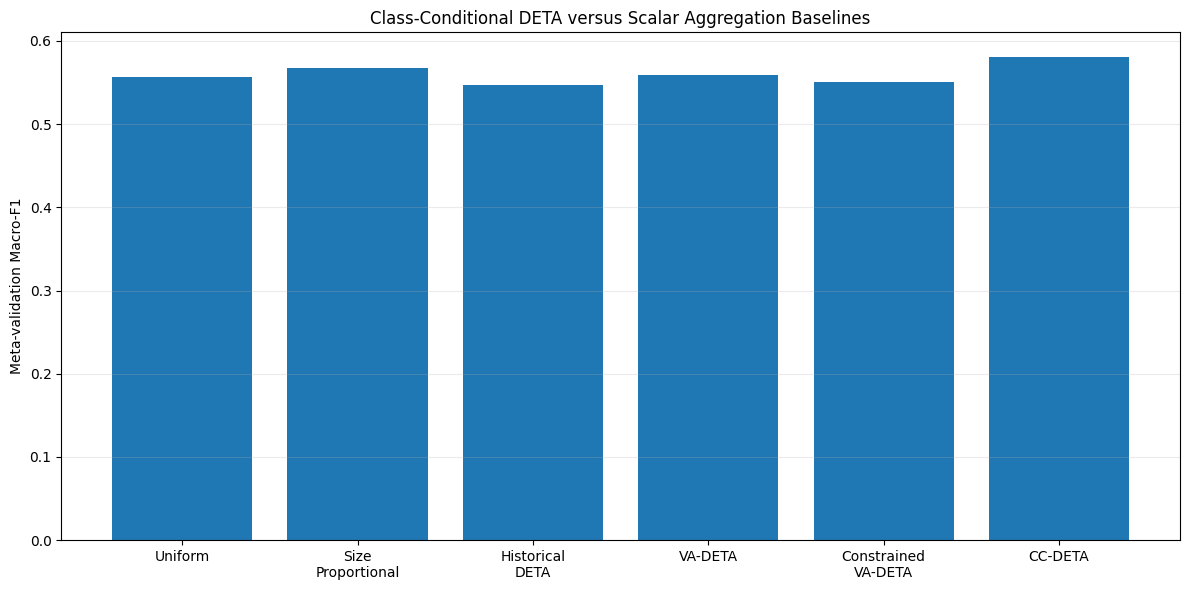

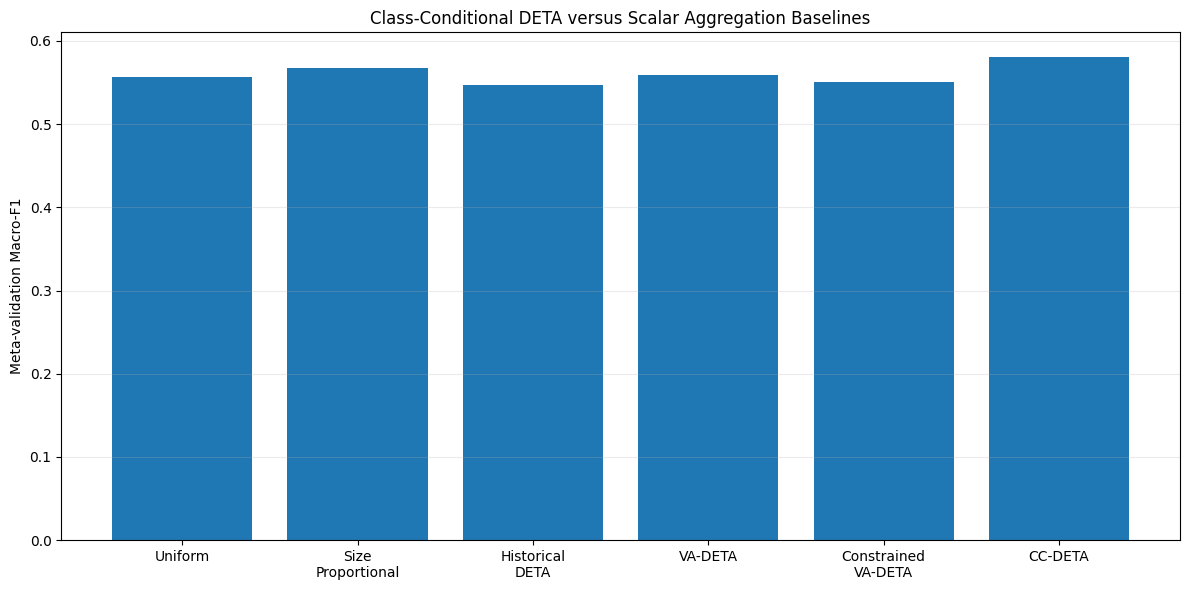

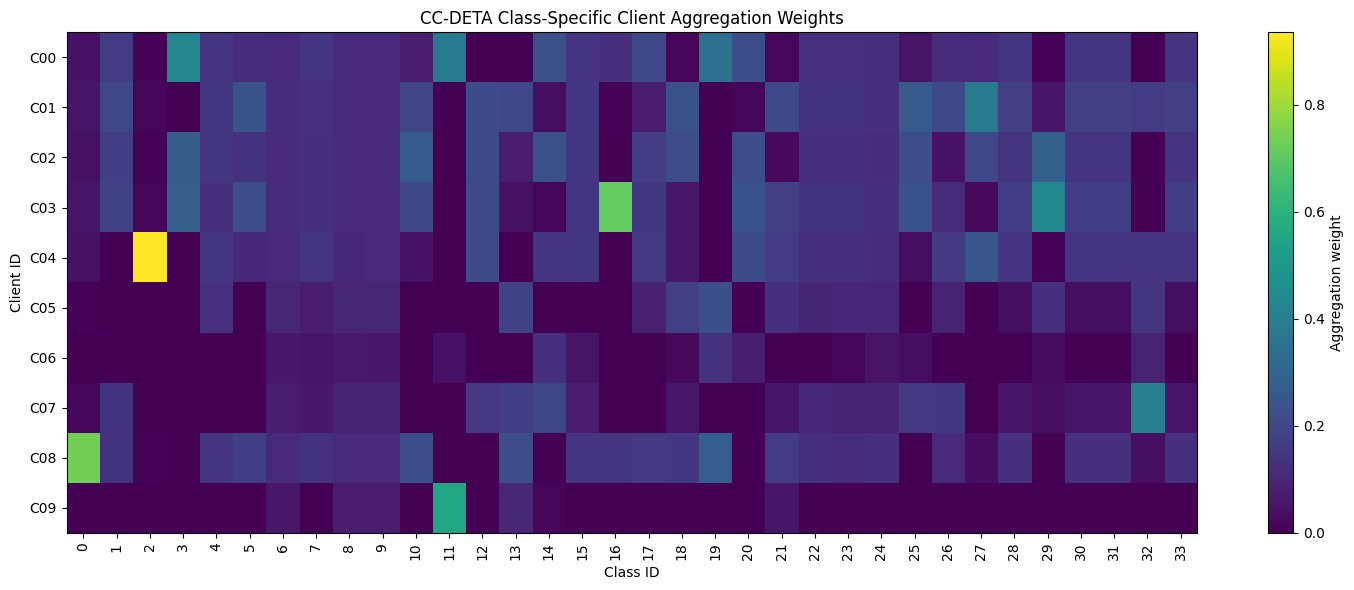

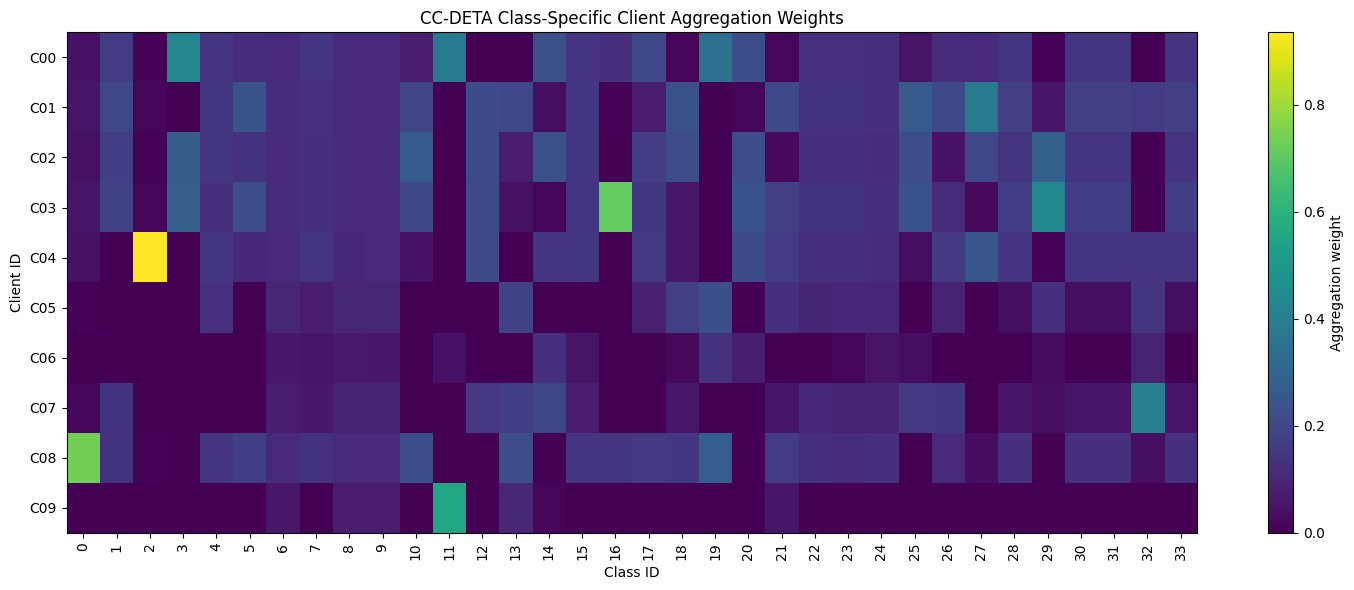

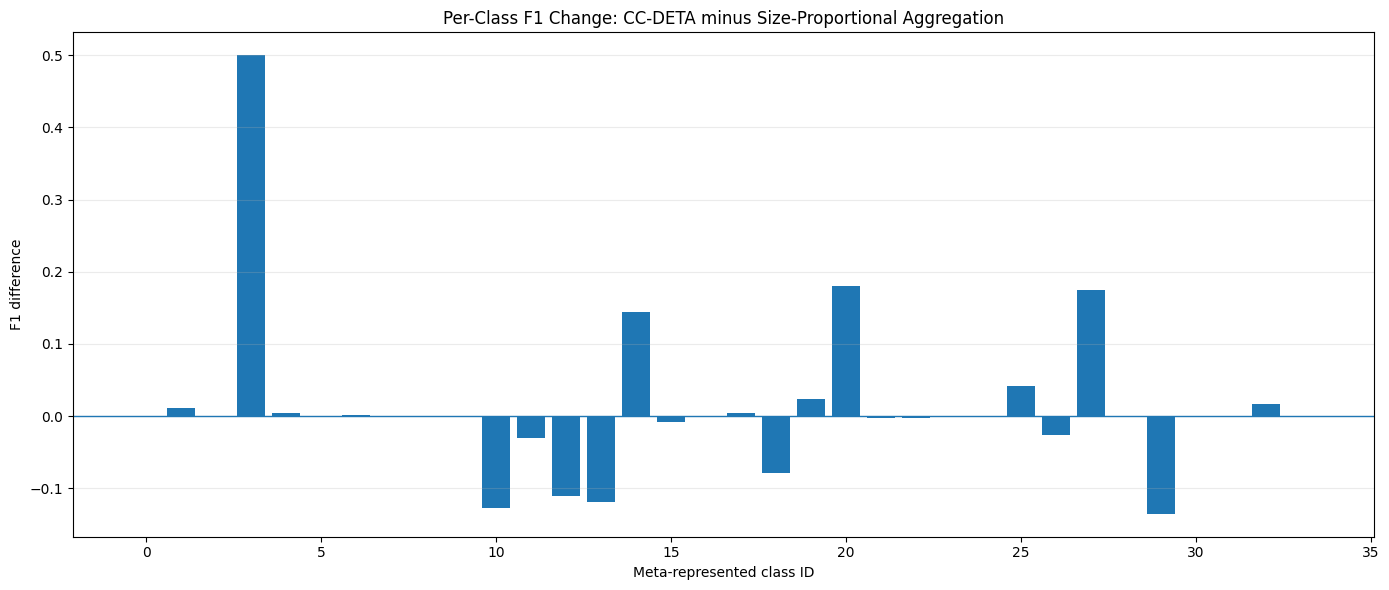

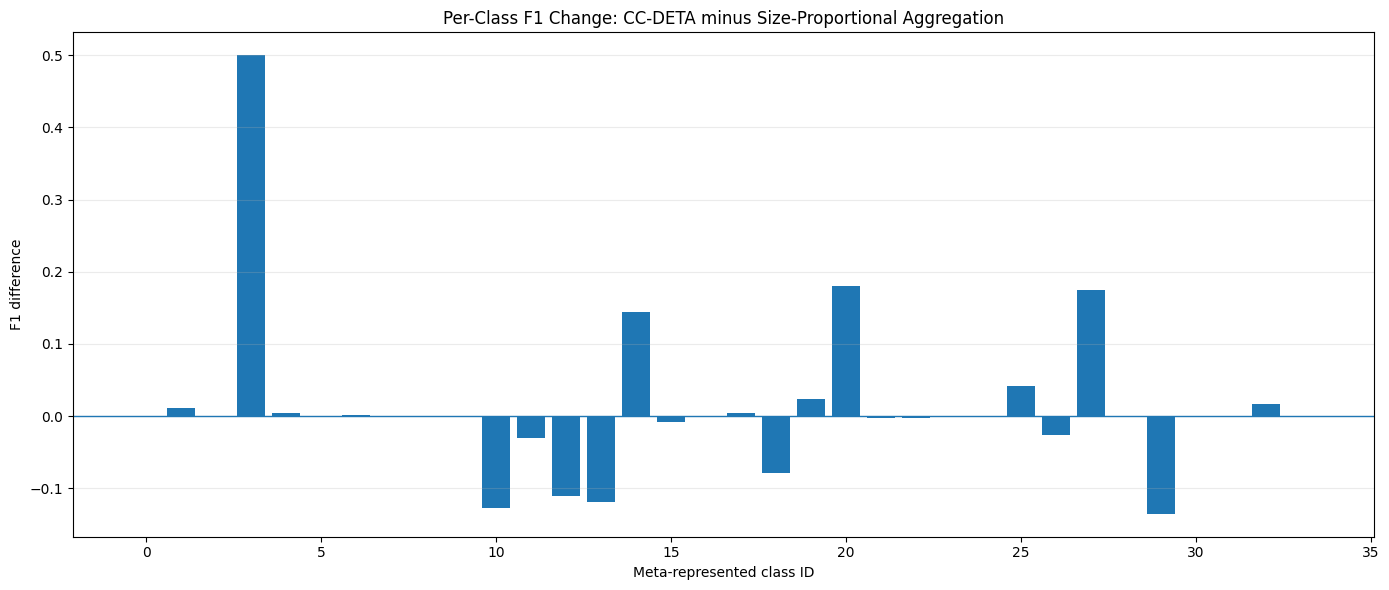


CELL 40 FINAL AUDIT

Frozen CC-DETA:
T_{i,c} = 0.100000*L_{i,c} + 0.750000*G_{i,c} + 0.050000*R_{i,c} + 0.100000*ES_i

w_{i,c} = T_{i,c}^4.000000 / sum_j T_{j,c}^4.000000

Server internal split:
Trust rows: 44087
Meta rows : 18896
Meta classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33]
Trust-only singleton classes: [31]

Meta-validation Macro-F1:
Uniform                  : 0.55633499
Size_Proportional        : 0.56752525
Historical_DETA          : 0.54680554
Unconstrained_VA_DETA    : 0.55900632
Constrained_VA_DETA      : 0.55091042
CC_DETA                  : 0.58131181

CC-DETA differences:
vs Uniform           : +0.02497681
vs Size Proportional : +0.01378656
vs Historical DETA   : +0.03450626

Explainability counterfactual:
CC-DETA              : 0.58131181
CC-DETA without ES   : 0.57668489
Observed ES increment: +0.00462691

Meta classes improved vs size: 12 / 33
Meta classes worsened vs size: 14 / 33


In [ ]:
# CELL 40 — LEAKAGE-SAFE CLASS-CONDITIONAL DETA DEVELOPMENT
#             SINGLETON-SAFE SERVER TRUST / META SPLITTING
#
# CC-DETA:
#
#   T_{i,c} =
#       alpha * L_{i,c}
#     + beta  * G_{i,c}
#     + gamma * R_{i,c}
#     + delta * ES_i
#
#                     T_{i,c} ^ tau
#   w_{i,c} = --------------------------------
#              sum_j T_{j,c} ^ tau
#
#   Q_c(x) = sum_i w_{i,c} P_i(c|x)
#
#                    Q_c(x)
#   P(c|x) = -----------------------
#             sum_k Q_k(x)
#
# SERVER VALIDATION INTERNAL SPLIT
#
#   Classes with >=2 rows:
#       split into disjoint trust/meta subsets.
#
#   Singleton server-validation classes:
#       TRUST ONLY.
#
# They are NEVER duplicated into meta validation.
#
# The optimization metric is therefore computed over the classes actually
# represented in D_meta. All competing methods are evaluated on exactly the
# same D_meta observations and class set.
#
# INDEPENDENT TEST:
#   NOT ACCESSED.



from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import json
import time
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from xgboost import XGBClassifier

from scipy.stats import spearmanr

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    matthews_corrcoef,
    log_loss
)

from IPython.display import display, Markdown


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 340)
pd.set_option("display.float_format", lambda x: f"{x:.8f}")


print("=" * 130)
print("CELL 40 — LEAKAGE-SAFE CLASS-CONDITIONAL DETA DEVELOPMENT")
print("          SINGLETON-SAFE SERVER META-VALIDATION")
print("=" * 130)


# 1. PATHS

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MIXED_DIR = (
    ROOT /
    "10_noniid_experiments" /
    "mixed_reliability"
)

MODEL_DIR = (
    ROOT /
    "03_client_models" /
    "mixed_reliability_leakage_safe"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

TOP30_JSON = (
    ROOT /
    "15_reproducibility" /
    "historical_top30_features.json"
)

TRUST_PATH = (
    ROOT /
    "06_trust" /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

BASELINE_WEIGHT_PATH = (
    ROOT /
    "13_tables" /
    "mixed_reliability_CELL21_VERIFIED_aggregation_weights.csv"
)

SERVER_PROB_DIR = (
    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "server_validation_clients"
)

CELL39_CONFIG = (
    ROOT /
    "06_trust" /
    "validation_adaptive_DETA" /
    "VA_DETA_FROZEN_server_validation_configuration.json"
)

CELL39B_CONFIG = (
    ROOT /
    "06_trust" /
    "constrained_validation_adaptive_DETA" /
    "CONSTRAINED_VA_DETA_FROZEN_configuration.json"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

CC_DIR = (
    ROOT /
    "06_trust" /
    "class_conditional_DETA"
)

for directory in [
    TABLE_DIR,
    FIG_DIR,
    REPRO_DIR,
    CC_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# 2. CONFIGURATION

N_CLIENTS = 10
N_CLASSES = 34

LABEL_COL = "Label_Encoded"

LOCAL_SPLIT_SEED = 42

TRUST_FRACTION = 0.70

SERVER_META_SPLIT_SEED = 20260818

SHAP_SAMPLE_SIZE = 2000

SHAP_BATCH_SIZE = 250

GRID_STEP = 0.05


TAU_GRID = np.array(
    [
        0.50,
        0.75,
        1.00,
        1.25,
        1.50,
        1.75,
        2.00,
        2.50,
        3.00,
        4.00,
    ],
    dtype=np.float64
)


# Keep every evidence channel active.
MIN_ALPHA = 0.05
MIN_BETA  = 0.05
MIN_GAMMA = 0.05
MIN_DELTA = 0.05


HISTORICAL_THETA = np.array(
    [
        0.20,
        0.40,
        0.30,
        0.10,
    ],
    dtype=np.float64
)


CLIENT_ROLES = {

    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",

    4: "NonIID_Reliable",
    5: "NonIID_Reliable",

    6: "LabelFlip",
    7: "LabelFlip",

    8: "Targeted_Poison",

    9: "SubsetClass_Reliable",
}


# 3. DATA-BOUNDARY AUDIT

print("\n" + "=" * 130)
print("DATA-BOUNDARY AUDIT")
print("=" * 130)

print("Development/local validation : L_{i,c}")
print("Server trust subset          : G_{i,c}, R_{i,c}, ES_i")
print("Server meta subset           : alpha,beta,gamma,delta,tau selection")
print("Singleton server classes     : TRUST ONLY — NEVER duplicated")
print("Independent test             : NOT ACCESSED")
print("Models retrained             : NO")


# 4. HELPERS

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def normalize_rows(prob):

    prob = np.asarray(
        prob,
        dtype=np.float64
    )

    prob = np.clip(
        prob,
        1e-15,
        None
    )

    denom = prob.sum(
        axis=1,
        keepdims=True
    )

    if np.any(
        denom <= 0
    ):
        raise RuntimeError(
            "Invalid probability row."
        )

    return (
        prob /
        denom
    )


# Exact local singleton-safe split policy.

def class_preserving_split(
    y,
    validation_fraction,
    random_seed
):

    y = np.asarray(
        y,
        dtype=np.int64
    )

    rng = np.random.default_rng(
        random_seed
    )

    train_parts = []
    val_parts = []


    for class_id in np.sort(
        np.unique(y)
    ):

        idx = np.flatnonzero(
            y == class_id
        ).copy()

        rng.shuffle(idx)

        n = len(idx)


        if n == 1:

            n_val = 0

        else:

            n_val = int(
                round(
                    n *
                    validation_fraction
                )
            )

            n_val = max(
                1,
                n_val
            )

            n_val = min(
                n_val,
                n - 1
            )


        train_part = idx[
            n_val:
        ]

        val_part = idx[
            :n_val
        ]


        train_parts.append(
            train_part
        )


        if n_val > 0:

            val_parts.append(
                val_part
            )


    train_idx = np.concatenate(
        train_parts
    ).astype(
        np.int64
    )


    if len(
        val_parts
    ) > 0:

        val_idx = np.concatenate(
            val_parts
        ).astype(
            np.int64
        )

    else:

        val_idx = np.array(
            [],
            dtype=np.int64
        )


    rng.shuffle(
        train_idx
    )

    rng.shuffle(
        val_idx
    )


    if len(
        np.intersect1d(
            train_idx,
            val_idx
        )
    ) != 0:

        raise RuntimeError(
            "Local train/validation overlap."
        )


    return (
        train_idx,
        val_idx
    )


# SINGLETON-SAFE server split.
#
# n == 1:
#     observation -> TRUST only.
#
# n >= 2:
#     at least 1 observation in TRUST
#     at least 1 observation in META
#

def stratified_server_split(
    y,
    trust_fraction,
    seed
):

    y = np.asarray(
        y,
        dtype=np.int64
    )

    rng = np.random.default_rng(
        seed
    )


    trust_parts = []
    meta_parts = []

    audit_rows = []


    for class_id in np.sort(
        np.unique(y)
    ):

        idx = np.flatnonzero(
            y == class_id
        ).copy()

        rng.shuffle(
            idx
        )

        n = len(
            idx
        )


        if n == 1:

            # Critical leakage-safe policy.

            trust_part = idx.copy()

            meta_part = np.array(
                [],
                dtype=np.int64
            )

            policy = "Singleton_Trust_Only"


        else:

            n_trust = int(
                round(
                    trust_fraction *
                    n
                )
            )

            n_trust = max(
                1,
                n_trust
            )

            n_trust = min(
                n_trust,
                n - 1
            )


            trust_part = idx[
                :n_trust
            ]

            meta_part = idx[
                n_trust:
            ]

            policy = "Disjoint_Trust_Meta"


        trust_parts.append(
            trust_part
        )


        if len(
            meta_part
        ) > 0:

            meta_parts.append(
                meta_part
            )


        audit_rows.append({

            "Class_ID":
                int(
                    class_id
                ),

            "Total_Rows":
                int(
                    n
                ),

            "Trust_Rows":
                int(
                    len(
                        trust_part
                    )
                ),

            "Meta_Rows":
                int(
                    len(
                        meta_part
                    )
                ),

            "Split_Policy":
                policy,
        })


    trust_idx = np.concatenate(
        trust_parts
    ).astype(
        np.int64
    )


    meta_idx = np.concatenate(
        meta_parts
    ).astype(
        np.int64
    )


    rng.shuffle(
        trust_idx
    )

    rng.shuffle(
        meta_idx
    )


    if len(
        np.intersect1d(
            trust_idx,
            meta_idx
        )
    ) != 0:

        raise RuntimeError(
            "Server trust/meta overlap detected."
        )


    combined = np.concatenate(
        [
            trust_idx,
            meta_idx
        ]
    )


    if not np.array_equal(
        np.sort(
            combined
        ),
        np.arange(
            len(y)
        )
    ):

        raise RuntimeError(
            "Server trust/meta row coverage failed."
        )


    audit_df = pd.DataFrame(
        audit_rows
    )


    return (
        trust_idx,
        meta_idx,
        audit_df
    )


def expand_to_global_probabilities(
    local_prob,
    local_to_global,
    n_global_classes=34
):

    local_prob = np.asarray(
        local_prob,
        dtype=np.float64
    )

    local_to_global = np.asarray(
        local_to_global,
        dtype=np.int64
    )


    global_prob = np.zeros(
        (
            local_prob.shape[0],
            n_global_classes
        ),
        dtype=np.float64
    )


    global_prob[
        :,
        local_to_global
    ] = local_prob


    return normalize_rows(
        global_prob
    )


def per_class_f1(
    y_true,
    y_pred
):

    return f1_score(
        y_true,
        y_pred,
        labels=np.arange(
            N_CLASSES
        ),
        average=None,
        zero_division=0
    ).astype(
        np.float64
    )


def per_class_recall(
    y_true,
    y_pred
):

    return recall_score(
        y_true,
        y_pred,
        labels=np.arange(
            N_CLASSES
        ),
        average=None,
        zero_division=0
    ).astype(
        np.float64
    )


def normalize_importance(
    importance
):

    importance = np.asarray(
        importance,
        dtype=np.float64
    )

    total = importance.sum()

    if total <= 0:

        raise RuntimeError(
            "Zero SHAP importance."
        )

    return (
        importance /
        total
    )


def mean_absolute_tree_shap(
    booster,
    X,
    n_features,
    batch_size=250
):

    total_abs = np.zeros(
        n_features,
        dtype=np.float64
    )

    total_units = 0


    for start in range(
        0,
        len(X),
        batch_size
    ):

        end = min(
            start +
            batch_size,
            len(X)
        )


        dmatrix = xgb.DMatrix(
            X[
                start:end
            ]
        )


        contrib = booster.predict(
            dmatrix,
            pred_contribs=True,
            validate_features=False
        )


        contrib = np.asarray(
            contrib
        )


        if contrib.ndim == 3:

            values = contrib[
                ...,
                :-1
            ]

            total_abs += np.abs(
                values
            ).sum(
                axis=(
                    0,
                    1
                )
            )

            total_units += (
                values.shape[0]
                *
                values.shape[1]
            )


        elif contrib.ndim == 2:

            if (
                contrib.shape[1]
                ==
                n_features + 1
            ):

                values = contrib[
                    :,
                    :-1
                ]

                total_abs += np.abs(
                    values
                ).sum(
                    axis=0
                )

                total_units += values.shape[0]


            elif (
                contrib.shape[1]
                %
                (
                    n_features + 1
                )
                ==
                0
            ):

                inferred_classes = (
                    contrib.shape[1]
                    //
                    (
                        n_features + 1
                    )
                )


                values = contrib.reshape(
                    contrib.shape[0],
                    inferred_classes,
                    n_features + 1
                )[
                    ...,
                    :-1
                ]


                total_abs += np.abs(
                    values
                ).sum(
                    axis=(
                        0,
                        1
                    )
                )

                total_units += (
                    values.shape[0]
                    *
                    values.shape[1]
                )


            else:

                raise RuntimeError(
                    f"Unexpected SHAP shape {contrib.shape}"
                )


        else:

            raise RuntimeError(
                f"Unexpected SHAP ndim {contrib.ndim}"
            )


        del dmatrix
        del contrib

        gc.collect()


    if total_units <= 0:

        raise RuntimeError(
            "No TreeSHAP units generated."
        )


    return (
        total_abs /
        total_units
    )


def cc_trust_to_weights(
    L_class,
    G_class,
    R_class,
    ES,
    theta,
    tau
):

    theta = np.asarray(
        theta,
        dtype=np.float64
    )


    if not np.isclose(
        theta.sum(),
        1.0,
        atol=1e-10
    ):

        raise RuntimeError(
            "Coefficient sum != 1."
        )


    alpha, beta, gamma, delta = theta


    T = (

        alpha
        *
        L_class

        +

        beta
        *
        G_class

        +

        gamma
        *
        R_class

        +

        delta
        *
        ES[
            :,
            None
        ]
    )


    T = np.clip(
        T,
        1e-12,
        None
    )


    powered = np.power(
        T,
        tau
    )


    W = (
        powered
        /
        powered.sum(
            axis=0,
            keepdims=True
        )
    )


    if not np.allclose(
        W.sum(
            axis=0
        ),
        1.0,
        atol=1e-10
    ):

        raise RuntimeError(
            "Class-specific weight normalization failed."
        )


    return (
        T,
        W
    )


def cc_unconstrained_weights(
    L_class,
    G_class,
    R_class,
    ES,
    theta,
    tau
):

    theta = np.asarray(
        theta,
        dtype=np.float64
    )

    theta /= theta.sum()


    T = (

        theta[0]
        *
        L_class

        +

        theta[1]
        *
        G_class

        +

        theta[2]
        *
        R_class

        +

        theta[3]
        *
        ES[
            :,
            None
        ]
    )


    T = np.clip(
        T,
        1e-12,
        None
    )


    powered = np.power(
        T,
        tau
    )


    W = (
        powered
        /
        powered.sum(
            axis=0,
            keepdims=True
        )
    )


    return (
        T,
        W
    )


def cc_aggregate(
    prob_stack,
    class_weights
):

    raw = np.sum(
        prob_stack
        *
        class_weights[
            :,
            None,
            :
        ],
        axis=0
    )

    return normalize_rows(
        raw
    )


def scalar_aggregate(
    prob_stack,
    weights
):

    raw = np.tensordot(
        weights,
        prob_stack,
        axes=(
            0,
            0
        )
    )

    return normalize_rows(
        raw
    )


# IMPORTANT:
# Meta-validation Macro-F1 is computed over META-REPRESENTED CLASSES ONLY.
#
# This avoids pretending singleton trust-only classes were available for
# hyperparameter selection.
#
# Accuracy and MCC still use all meta observations naturally.
# Log-loss retains the fixed 34-class probability space.

def evaluate_meta(
    y_true,
    prob,
    meta_labels
):

    pred = np.argmax(
        prob,
        axis=1
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Balanced_Accuracy":
            float(
                recall_score(
                    y_true,
                    pred,
                    labels=meta_labels,
                    average="macro",
                    zero_division=0
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    labels=meta_labels,
                    average="macro",
                    zero_division=0
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    y_true,
                    pred
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    average="weighted",
                    zero_division=0
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_true,
                    prob,
                    labels=np.arange(
                        N_CLASSES
                    )
                )
            ),
    }


def rank_candidates(
    df
):

    return df.sort_values(

        by=[
            "Macro_F1",
            "Balanced_Accuracy",
            "MCC",
            "Log_Loss",
        ],

        ascending=[
            False,
            False,
            False,
            True,
        ]

    ).reset_index(
        drop=True
    )


# 5. LOAD FROZEN FEATURES

with open(
    TOP30_JSON,
    "r"
) as f:

    feature_obj = json.load(
        f
    )


FEATURES = None


if isinstance(
    feature_obj,
    list
):

    FEATURES = feature_obj


elif isinstance(
    feature_obj,
    dict
):

    for key in [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
    ]:

        if (
            key in feature_obj
            and isinstance(
                feature_obj[
                    key
                ],
                list
            )
            and len(
                feature_obj[
                    key
                ]
            ) == 30
        ):

            FEATURES = feature_obj[
                key
            ]

            break


if FEATURES is None:

    raise RuntimeError(
        "Unable to recover frozen Top-30 schema."
    )


FEATURES = [
    str(x)
    for x in FEATURES
]


if len(
    FEATURES
) != 30:

    raise RuntimeError(
        "Expected exactly 30 frozen features."
    )


print(
    "\nFrozen features:",
    len(
        FEATURES
    )
)


# 6. SERVER VALIDATION + SINGLETON-SAFE TRUST/META SPLIT

server_df = pd.read_parquet(
    SERVER_PATH,
    columns=FEATURES + [LABEL_COL]
)


X_server = server_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)


y_server = server_df[
    LABEL_COL
].to_numpy(
    dtype=np.int32
)


trust_idx, meta_idx, split_audit_df = stratified_server_split(

    y=y_server,

    trust_fraction=TRUST_FRACTION,

    seed=SERVER_META_SPLIT_SEED
)


X_trust = X_server[
    trust_idx
]


y_trust = y_server[
    trust_idx
]


X_meta = X_server[
    meta_idx
]


y_meta = y_server[
    meta_idx
]


META_LABELS = np.sort(
    np.unique(
        y_meta
    )
).astype(
    np.int32
)


TRUST_LABELS = np.sort(
    np.unique(
        y_trust
    )
).astype(
    np.int32
)


SINGLETON_ONLY_CLASSES = split_audit_df.loc[

    split_audit_df[
        "Split_Policy"
    ]
    ==
    "Singleton_Trust_Only",

    "Class_ID"

].to_numpy(
    dtype=np.int32
)


print("\n" + "=" * 130)
print("SERVER TRUST / META SPLIT AUDIT")
print("=" * 130)


display(
    split_audit_df
)


print(
    "\nTotal server rows:",
    f"{len(y_server):,}"
)


print(
    "Trust rows       :",
    f"{len(y_trust):,}"
)


print(
    "Meta rows        :",
    f"{len(y_meta):,}"
)


print(
    "Trust classes    :",
    len(
        TRUST_LABELS
    )
)


print(
    "Meta classes     :",
    len(
        META_LABELS
    )
)


print(
    "Trust-only singleton classes:",
    SINGLETON_ONLY_CLASSES.tolist()
)


if len(
    SINGLETON_ONLY_CLASSES
) > 0:

    print(
        "\nIMPORTANT:"
    )

    print(
        "These classes are excluded from coefficient/tau selection "
        "because they cannot appear in both disjoint server subsets."
    )

    print(
        "They remain represented in the 34-class CC-DETA trust matrix."
    )


# 7. LOCAL CLASS-CONDITIONAL EVIDENCE L_{i,c}

print("\n" + "=" * 130)
print("LOCAL CLASS-CONDITIONAL EVIDENCE — L_{i,c}")
print("=" * 130)


models = {}

local_to_global_maps = {}


L_CLASS = np.zeros(
    (
        N_CLIENTS,
        N_CLASSES
    ),
    dtype=np.float64
)


for client_id in range(
    N_CLIENTS
):

    client_path = (
        MIXED_DIR /
        f"client_{client_id:02d}_mixed.parquet"
    )


    model_path = (
        MODEL_DIR /
        f"client_{client_id:02d}_xgb.json"
    )


    df = pd.read_parquet(
        client_path,
        columns=FEATURES + [LABEL_COL]
    )


    X_local = df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    )


    y_local = df[
        LABEL_COL
    ].to_numpy(
        dtype=np.int32
    )


    train_idx_local, val_idx_local = class_preserving_split(

        y=y_local,

        validation_fraction=0.20,

        random_seed=LOCAL_SPLIT_SEED + client_id
    )


    train_global_classes = np.sort(
        np.unique(
            y_local[
                train_idx_local
            ]
        )
    )


    local_to_global_maps[
        client_id
    ] = train_global_classes


    model = XGBClassifier()

    model.load_model(
        model_path
    )


    models[
        client_id
    ] = model


    local_prob = model.predict_proba(
        X_local[
            val_idx_local
        ]
    )


    global_prob = expand_to_global_probabilities(

        local_prob=local_prob,

        local_to_global=train_global_classes,

        n_global_classes=N_CLASSES
    )


    local_pred = np.argmax(
        global_prob,
        axis=1
    )


    L_CLASS[
        client_id
    ] = per_class_f1(

        y_local[
            val_idx_local
        ],

        local_pred
    )


    print(
        f"Client {client_id:02d} "
        f"({CLIENT_ROLES[client_id]}): "
        f"non-zero L_ic="
        f"{np.count_nonzero(L_CLASS[client_id])}"
    )


    del df
    del X_local
    del y_local
    del local_prob
    del global_prob

    gc.collect()


print(
    "\nL_CLASS shape:",
    L_CLASS.shape
)


# 8. LOAD FULL SERVER CLIENT PROBABILITIES

print("\n" + "=" * 130)
print("SERVER CLIENT PROBABILITIES")
print("=" * 130)


server_probabilities = []


for client_id in range(
    N_CLIENTS
):

    candidates = sorted(
        SERVER_PROB_DIR.glob(
            f"*client_{client_id:02d}*.npy"
        )
    )


    if len(
        candidates
    ) == 0:

        raise FileNotFoundError(
            f"No server probabilities for Client {client_id:02d}"
        )


    path = candidates[
        0
    ]


    prob = np.load(
        path
    )


    if prob.shape != (
        len(
            y_server
        ),
        N_CLASSES
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: "
            f"invalid probability shape {prob.shape}"
        )


    prob = normalize_rows(
        prob
    )


    server_probabilities.append(
        prob.astype(
            np.float32
        )
    )


    print(
        f"Client {client_id:02d}: "
        f"{prob.shape} — PASSED"
    )


PROB_SERVER = np.stack(
    server_probabilities,
    axis=0
)


PROB_TRUST = PROB_SERVER[
    :,
    trust_idx,
    :
]


PROB_META = PROB_SERVER[
    :,
    meta_idx,
    :
]


# 9. SERVER TRUST-SUBSET G_{i,c} + R_{i,c}

print("\n" + "=" * 130)
print("SERVER CLASS-CONDITIONAL EVIDENCE — G_{i,c}, R_{i,c}")
print("=" * 130)


G_CLASS = np.zeros(
    (
        N_CLIENTS,
        N_CLASSES
    ),
    dtype=np.float64
)


R_CLASS = np.zeros(
    (
        N_CLIENTS,
        N_CLASSES
    ),
    dtype=np.float64
)


for client_id in range(
    N_CLIENTS
):

    pred = np.argmax(
        PROB_TRUST[
            client_id
        ],
        axis=1
    )


    G_CLASS[
        client_id
    ] = per_class_f1(
        y_trust,
        pred
    )


    R_CLASS[
        client_id
    ] = per_class_recall(
        y_trust,
        pred
    )


    print(
        f"Client {client_id:02d}: "
        f"mean G_ic={G_CLASS[client_id].mean():.6f}, "
        f"mean R_ic={R_CLASS[client_id].mean():.6f}"
    )


# 10. SHAP ES_i FROM TRUST SUBSET ONLY

print("\n" + "=" * 130)
print("TRUST-SUBSET SHAP EXPLANATION STABILITY")
print("=" * 130)


rng = np.random.default_rng(
    SERVER_META_SPLIT_SEED + 707
)


shap_indices = []


# Preserve every trust-represented class where possible.
for class_id in TRUST_LABELS:

    class_positions = np.flatnonzero(
        y_trust == class_id
    )


    quota = max(
        1,
        int(
            round(
                SHAP_SAMPLE_SIZE
                *
                len(
                    class_positions
                )
                /
                len(
                    y_trust
                )
            )
        )
    )


    quota = min(
        quota,
        len(
            class_positions
        )
    )


    chosen = rng.choice(
        class_positions,
        size=quota,
        replace=False
    )


    shap_indices.extend(
        chosen.tolist()
    )


shap_indices = np.array(
    sorted(
        set(
            shap_indices
        )
    ),
    dtype=np.int64
)


if len(
    shap_indices
) > SHAP_SAMPLE_SIZE:

    # Preserve rare-class representatives before trimming.
    mandatory = []

    for class_id in TRUST_LABELS:

        class_candidates = shap_indices[
            y_trust[
                shap_indices
            ]
            ==
            class_id
        ]

        if len(
            class_candidates
        ) > 0:

            mandatory.append(
                class_candidates[
                    0
                ]
            )


    mandatory = np.array(
        mandatory,
        dtype=np.int64
    )


    remaining_pool = np.setdiff1d(
        shap_indices,
        mandatory
    )


    needed = (
        SHAP_SAMPLE_SIZE
        -
        len(
            mandatory
        )
    )


    extra = rng.choice(
        remaining_pool,
        size=needed,
        replace=False
    )


    shap_indices = np.concatenate(
        [
            mandatory,
            extra
        ]
    )


elif len(
    shap_indices
) < SHAP_SAMPLE_SIZE:

    remaining = np.setdiff1d(
        np.arange(
            len(
                y_trust
            )
        ),
        shap_indices
    )


    extra = rng.choice(
        remaining,
        size=(
            SHAP_SAMPLE_SIZE
            -
            len(
                shap_indices
            )
        ),
        replace=False
    )


    shap_indices = np.concatenate(
        [
            shap_indices,
            extra
        ]
    )


X_shap = X_trust[
    shap_indices
]


print(
    "SHAP rows:",
    len(
        X_shap
    )
)


print(
    "SHAP classes represented:",
    len(
        np.unique(
            y_trust[
                shap_indices
            ]
        )
    )
)


importance_vectors = []


for client_id in range(
    N_CLIENTS
):

    start = time.perf_counter()


    mean_abs = mean_absolute_tree_shap(

        booster=models[
            client_id
        ].get_booster(),

        X=X_shap,

        n_features=len(
            FEATURES
        ),

        batch_size=SHAP_BATCH_SIZE
    )


    normalized = normalize_importance(
        mean_abs
    )


    importance_vectors.append(
        normalized
    )


    print(
        f"Client {client_id:02d}: "
        f"TreeSHAP "
        f"{time.perf_counter() - start:.2f}s"
    )


IMPORTANCE_MATRIX = np.vstack(
    importance_vectors
)


CONSENSUS = normalize_importance(
    IMPORTANCE_MATRIX.mean(
        axis=0
    )
)


consensus_rank = pd.Series(
    CONSENSUS
).rank(
    ascending=False,
    method="average"
).to_numpy()


RHO = np.zeros(
    N_CLIENTS,
    dtype=np.float64
)


for client_id in range(
    N_CLIENTS
):

    client_rank = pd.Series(
        IMPORTANCE_MATRIX[
            client_id
        ]
    ).rank(
        ascending=False,
        method="average"
    ).to_numpy()


    rho, _ = spearmanr(
        client_rank,
        consensus_rank
    )


    RHO[
        client_id
    ] = rho


rho_min = float(
    RHO.min()
)

rho_max = float(
    RHO.max()
)


if np.isclose(
    rho_min,
    rho_max
):

    ES = np.ones(
        N_CLIENTS,
        dtype=np.float64
    )

else:

    ES = (
        RHO
        -
        rho_min
    ) / (
        rho_max
        -
        rho_min
    )


print(
    "\nSpearman range:",
    f"{rho_min:.6f} -> {rho_max:.6f}"
)


print(
    "ES range:",
    f"{ES.min():.6f} -> {ES.max():.6f}"
)


# 11. SCALAR BASELINE WEIGHTS

baseline_weight_df = pd.read_csv(
    BASELINE_WEIGHT_PATH
).sort_values(
    "Client_ID"
)


UNIFORM_WEIGHTS = np.repeat(
    1.0 / N_CLIENTS,
    N_CLIENTS
)


SIZE_WEIGHTS = baseline_weight_df[
    "Size_Proportional"
].to_numpy(
    dtype=np.float64
)


SIZE_WEIGHTS /= SIZE_WEIGHTS.sum()


historical_trust_df = pd.read_csv(
    TRUST_PATH
).sort_values(
    "Client_ID"
)


HIST_COMPONENTS = historical_trust_df[
    [
        "L_i",
        "G_i",
        "B_i",
        "ES_i"
    ]
].to_numpy(
    dtype=np.float64
)


HIST_T = (
    HIST_COMPONENTS
    @
    HISTORICAL_THETA
)


HIST_WEIGHTS = (
    HIST_T /
    HIST_T.sum()
)


# Cell 39 unconstrained adaptive scalar DETA
with open(
    CELL39_CONFIG,
    "r"
) as f:

    c39 = json.load(
        f
    )


c39_par = c39[
    "adaptive_configuration"
]


C39_THETA = np.array(
    [
        c39_par[
            "alpha_L"
        ],
        c39_par[
            "beta_G"
        ],
        c39_par[
            "gamma_B"
        ],
        c39_par[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


C39_TAU = float(
    c39_par[
        "tau"
    ]
)


C39_T = (
    HIST_COMPONENTS
    @
    C39_THETA
)


C39_WEIGHTS = np.power(
    np.clip(
        C39_T,
        1e-12,
        None
    ),
    C39_TAU
)


C39_WEIGHTS /= C39_WEIGHTS.sum()


# Cell 39B constrained adaptive scalar DETA
with open(
    CELL39B_CONFIG,
    "r"
) as f:

    c39b = json.load(
        f
    )


c39b_par = c39b[
    "selected_parameters"
]


C39B_THETA = np.array(
    [
        c39b_par[
            "alpha_L"
        ],
        c39b_par[
            "beta_G"
        ],
        c39b_par[
            "gamma_B"
        ],
        c39b_par[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


C39B_TAU = float(
    c39b_par[
        "tau"
    ]
)


C39B_T = (
    HIST_COMPONENTS
    @
    C39B_THETA
)


C39B_WEIGHTS = np.power(
    np.clip(
        C39B_T,
        1e-12,
        None
    ),
    C39B_TAU
)


C39B_WEIGHTS /= C39B_WEIGHTS.sum()


# 12. META-VALIDATION BASELINES

print("\n" + "=" * 130)
print("META-VALIDATION BASELINES")
print("=" * 130)


baseline_rows = []


baseline_methods = {

    "Uniform":
        UNIFORM_WEIGHTS,

    "Size_Proportional":
        SIZE_WEIGHTS,

    "Historical_DETA":
        HIST_WEIGHTS,

    "Unconstrained_VA_DETA":
        C39_WEIGHTS,

    "Constrained_VA_DETA":
        C39B_WEIGHTS,
}


for method, weights in baseline_methods.items():

    prob = scalar_aggregate(
        PROB_META,
        weights
    )


    metrics = evaluate_meta(
        y_meta,
        prob,
        META_LABELS
    )


    baseline_rows.append({

        "Method":
            method,

        **metrics,
    })


baseline_df = pd.DataFrame(
    baseline_rows
)


display(
    baseline_df
)


# 13. CONSTRAINED CC-DETA SIMPLEX

print("\n" + "=" * 130)
print("CLASS-CONDITIONAL COEFFICIENT SEARCH")
print("=" * 130)


grid = np.round(
    np.arange(
        0.0,
        1.0 + GRID_STEP / 2,
        GRID_STEP
    ),
    10
)


theta_candidates = []


for alpha in grid:

    if alpha < MIN_ALPHA - 1e-12:
        continue


    for beta in grid:

        if beta < MIN_BETA - 1e-12:
            continue


        for gamma in grid:

            if gamma < MIN_GAMMA - 1e-12:
                continue


            delta = (
                1.0
                -
                alpha
                -
                beta
                -
                gamma
            )


            if delta < MIN_DELTA - 1e-12:
                continue


            if delta > 1.0 + 1e-12:
                continue


            if not np.isclose(
                delta /
                GRID_STEP,
                round(
                    delta /
                    GRID_STEP
                ),
                atol=1e-8
            ):

                continue


            theta = np.array(
                [
                    alpha,
                    beta,
                    gamma,
                    delta
                ],
                dtype=np.float64
            )


            if np.isclose(
                theta.sum(),
                1.0,
                atol=1e-10
            ):

                theta_candidates.append(
                    theta
                )


theta_candidates = np.vstack(
    theta_candidates
)


print(
    "Coefficient combinations:",
    len(
        theta_candidates
    )
)


print(
    "Tau values:",
    len(
        TAU_GRID
    )
)


print(
    "Total candidates:",
    len(
        theta_candidates
    )
    *
    len(
        TAU_GRID
    )
)


# 14. META-VALIDATION SEARCH

search_rows = []


search_start = time.perf_counter()


candidate_id = 0


for theta in theta_candidates:

    for tau in TAU_GRID:

        candidate_id += 1


        T_class, W_class = cc_trust_to_weights(

            L_class=L_CLASS,

            G_class=G_CLASS,

            R_class=R_CLASS,

            ES=ES,

            theta=theta,

            tau=tau
        )


        prob = cc_aggregate(
            PROB_META,
            W_class
        )


        metrics = evaluate_meta(
            y_meta,
            prob,
            META_LABELS
        )


        search_rows.append({

            "Candidate_ID":
                candidate_id,

            "Alpha_LocalClassF1":
                theta[
                    0
                ],

            "Beta_ServerClassF1":
                theta[
                    1
                ],

            "Gamma_ServerClassRecall":
                theta[
                    2
                ],

            "Delta_ES":
                theta[
                    3
                ],

            "Tau":
                tau,

            "Mean_ClassWeight_SD":
                float(
                    W_class.std(
                        axis=0
                    ).mean()
                ),

            **metrics,
        })


search_seconds = (
    time.perf_counter()
    -
    search_start
)


search_df = rank_candidates(
    pd.DataFrame(
        search_rows
    )
)


print(
    "\nSearch seconds:",
    f"{search_seconds:.2f}"
)


print(
    "\nTop 20 CC-DETA configurations:"
)


display(
    search_df.head(
        20
    )
)


# 15. SELECT BEST CC-DETA

BEST = search_df.iloc[
    0
]


BEST_THETA = np.array(
    [
        BEST[
            "Alpha_LocalClassF1"
        ],
        BEST[
            "Beta_ServerClassF1"
        ],
        BEST[
            "Gamma_ServerClassRecall"
        ],
        BEST[
            "Delta_ES"
        ],
    ],
    dtype=np.float64
)


BEST_TAU = float(
    BEST[
        "Tau"
    ]
)


BEST_T_CLASS, BEST_W_CLASS = cc_trust_to_weights(

    L_class=L_CLASS,

    G_class=G_CLASS,

    R_class=R_CLASS,

    ES=ES,

    theta=BEST_THETA,

    tau=BEST_TAU
)


BEST_META_PROB = cc_aggregate(
    PROB_META,
    BEST_W_CLASS
)


BEST_META_METRICS = evaluate_meta(
    y_meta,
    BEST_META_PROB,
    META_LABELS
)


# 16. EXPLAINABILITY COUNTERFACTUAL

COUNTER_THETA = BEST_THETA.copy()


COUNTER_THETA[
    3
] = 0.0


COUNTER_THETA[
    :3
] /= COUNTER_THETA[
    :3
].sum()


COUNTER_T, COUNTER_W = cc_unconstrained_weights(

    L_class=L_CLASS,

    G_class=G_CLASS,

    R_class=R_CLASS,

    ES=ES,

    theta=COUNTER_THETA,

    tau=BEST_TAU
)


COUNTER_PROB = cc_aggregate(
    PROB_META,
    COUNTER_W
)


COUNTER_METRICS = evaluate_meta(
    y_meta,
    COUNTER_PROB,
    META_LABELS
)


# 17. FINAL META COMPARISON

comparison_rows = baseline_rows.copy()


comparison_rows.append({

    "Method":
        "CC_DETA",

    **BEST_META_METRICS,
})


comparison_rows.append({

    "Method":
        "CC_DETA_without_ES_counterfactual",

    **COUNTER_METRICS,
})


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 130)
print("FINAL META-VALIDATION COMPARISON")
print("=" * 130)


display(
    comparison_df
)


def get_metric(
    method,
    metric
):

    return float(

        comparison_df.loc[
            comparison_df[
                "Method"
            ]
            ==
            method,
            metric
        ].iloc[
            0
        ]
    )


SIZE_META_F1 = get_metric(
    "Size_Proportional",
    "Macro_F1"
)


UNIFORM_META_F1 = get_metric(
    "Uniform",
    "Macro_F1"
)


HIST_META_F1 = get_metric(
    "Historical_DETA",
    "Macro_F1"
)


GAIN_VS_SIZE = (
    BEST_META_METRICS[
        "Macro_F1"
    ]
    -
    SIZE_META_F1
)


GAIN_VS_UNIFORM = (
    BEST_META_METRICS[
        "Macro_F1"
    ]
    -
    UNIFORM_META_F1
)


GAIN_VS_HIST = (
    BEST_META_METRICS[
        "Macro_F1"
    ]
    -
    HIST_META_F1
)


ES_INCREMENT = (
    BEST_META_METRICS[
        "Macro_F1"
    ]
    -
    COUNTER_METRICS[
        "Macro_F1"
    ]
)


# 18. PER-CLASS EFFECT VS SIZE PROPORTIONAL

CC_PRED = np.argmax(
    BEST_META_PROB,
    axis=1
)


SIZE_META_PROB = scalar_aggregate(
    PROB_META,
    SIZE_WEIGHTS
)


SIZE_PRED = np.argmax(
    SIZE_META_PROB,
    axis=1
)


# Evaluate only classes actually represented in meta.
CC_CLASS_F1_META = f1_score(
    y_meta,
    CC_PRED,
    labels=META_LABELS,
    average=None,
    zero_division=0
)


SIZE_CLASS_F1_META = f1_score(
    y_meta,
    SIZE_PRED,
    labels=META_LABELS,
    average=None,
    zero_division=0
)


class_comparison_df = pd.DataFrame({

    "Class_ID":
        META_LABELS,

    "CC_DETA_F1":
        CC_CLASS_F1_META,

    "Size_Proportional_F1":
        SIZE_CLASS_F1_META,

    "CC_minus_Size_F1":
        (
            CC_CLASS_F1_META
            -
            SIZE_CLASS_F1_META
        ),
})


print("\n" + "=" * 130)
print("META-REPRESENTED CLASS EFFECT")
print("=" * 130)


display(
    class_comparison_df
)


# 19. CLASS-SPECIFIC WEIGHT AUDIT

class_weight_rows = []


for client_id in range(
    N_CLIENTS
):

    for class_id in range(
        N_CLASSES
    ):

        class_weight_rows.append({

            "Client_ID":
                client_id,

            "Role":
                CLIENT_ROLES[
                    client_id
                ],

            "Class_ID":
                class_id,

            "Meta_Represented":
                bool(
                    class_id
                    in
                    set(
                        META_LABELS.tolist()
                    )
                ),

            "L_ic":
                L_CLASS[
                    client_id,
                    class_id
                ],

            "G_ic":
                G_CLASS[
                    client_id,
                    class_id
                ],

            "R_ic":
                R_CLASS[
                    client_id,
                    class_id
                ],

            "ES_i":
                ES[
                    client_id
                ],

            "CC_Trust":
                BEST_T_CLASS[
                    client_id,
                    class_id
                ],

            "CC_Weight":
                BEST_W_CLASS[
                    client_id,
                    class_id
                ],
        })


class_weight_df = pd.DataFrame(
    class_weight_rows
)


# 20. FIGURE — METHOD COMPARISON

plot_methods = [

    "Uniform",

    "Size_Proportional",

    "Historical_DETA",

    "Unconstrained_VA_DETA",

    "Constrained_VA_DETA",

    "CC_DETA",
]


plot_df = (
    comparison_df[
        comparison_df[
            "Method"
        ].isin(
            plot_methods
        )
    ]
    .set_index(
        "Method"
    )
    .loc[
        plot_methods
    ]
    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(
        12,
        6
    )
)


x = np.arange(
    len(
        plot_df
    )
)


ax.bar(
    x,
    plot_df[
        "Macro_F1"
    ]
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Uniform",
        "Size\nProportional",
        "Historical\nDETA",
        "VA-DETA",
        "Constrained\nVA-DETA",
        "CC-DETA",
    ]
)


ax.set_ylabel(
    "Meta-validation Macro-F1"
)


ax.set_title(
    "Class-Conditional DETA versus Scalar Aggregation Baselines"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


PERF_PNG = (
    FIG_DIR /
    "37_CC_DETA_meta_validation_performance.png"
)


PERF_PDF = (
    FIG_DIR /
    "37_CC_DETA_meta_validation_performance.pdf"
)


fig.savefig(
    PERF_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    PERF_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 21. FIGURE — CLASS-SPECIFIC WEIGHT HEATMAP

fig, ax = plt.subplots(
    figsize=(
        15,
        6
    )
)


im = ax.imshow(
    BEST_W_CLASS,
    aspect="auto"
)


ax.set_xlabel(
    "Class ID"
)


ax.set_ylabel(
    "Client ID"
)


ax.set_xticks(
    np.arange(
        N_CLASSES
    )
)


ax.set_xticklabels(
    np.arange(
        N_CLASSES
    ),
    rotation=90
)


ax.set_yticks(
    np.arange(
        N_CLIENTS
    )
)


ax.set_yticklabels(
    [
        f"C{i:02d}"
        for i in range(
            N_CLIENTS
        )
    ]
)


ax.set_title(
    "CC-DETA Class-Specific Client Aggregation Weights"
)


fig.colorbar(
    im,
    ax=ax,
    label="Aggregation weight"
)


fig.tight_layout()


display(
    fig
)


HEATMAP_PNG = (
    FIG_DIR /
    "38_CC_DETA_class_specific_weight_heatmap.png"
)


HEATMAP_PDF = (
    FIG_DIR /
    "38_CC_DETA_class_specific_weight_heatmap.pdf"
)


fig.savefig(
    HEATMAP_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    HEATMAP_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 22. FIGURE — PER-CLASS GAIN VS SIZE

fig, ax = plt.subplots(
    figsize=(
        14,
        6
    )
)


ax.bar(
    class_comparison_df[
        "Class_ID"
    ],
    class_comparison_df[
        "CC_minus_Size_F1"
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xlabel(
    "Meta-represented class ID"
)


ax.set_ylabel(
    "F1 difference"
)


ax.set_title(
    "Per-Class F1 Change: CC-DETA minus Size-Proportional Aggregation"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


CLASS_FIG_PNG = (
    FIG_DIR /
    "39_CC_DETA_per_class_F1_gain_vs_size.png"
)


CLASS_FIG_PDF = (
    FIG_DIR /
    "39_CC_DETA_per_class_F1_gain_vs_size.pdf"
)


fig.savefig(
    CLASS_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    CLASS_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 23. SAVE TABLES

SPLIT_AUDIT_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_server_trust_meta_split_audit.csv"
)


SEARCH_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_meta_validation_search.csv"
)


COMPARISON_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_meta_validation_comparison.csv"
)


CLASS_METRIC_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_per_class_vs_size.csv"
)


CLASS_WEIGHT_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_class_specific_weights.csv"
)


L_CLASS_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_local_class_F1.csv"
)


G_CLASS_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_server_trust_class_F1.csv"
)


R_CLASS_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_server_trust_class_recall.csv"
)


ES_OUT = (
    TABLE_DIR /
    "cell40_CC_DETA_trust_subset_ES.csv"
)


split_audit_df.to_csv(
    SPLIT_AUDIT_OUT,
    index=False
)


search_df.to_csv(
    SEARCH_OUT,
    index=False
)


comparison_df.to_csv(
    COMPARISON_OUT,
    index=False
)


class_comparison_df.to_csv(
    CLASS_METRIC_OUT,
    index=False
)


class_weight_df.to_csv(
    CLASS_WEIGHT_OUT,
    index=False
)


pd.DataFrame(
    L_CLASS,
    columns=[
        f"Class_{i}"
        for i in range(
            N_CLASSES
        )
    ]
).assign(
    Client_ID=np.arange(
        N_CLIENTS
    )
).to_csv(
    L_CLASS_OUT,
    index=False
)


pd.DataFrame(
    G_CLASS,
    columns=[
        f"Class_{i}"
        for i in range(
            N_CLASSES
        )
    ]
).assign(
    Client_ID=np.arange(
        N_CLIENTS
    )
).to_csv(
    G_CLASS_OUT,
    index=False
)


pd.DataFrame(
    R_CLASS,
    columns=[
        f"Class_{i}"
        for i in range(
            N_CLASSES
        )
    ]
).assign(
    Client_ID=np.arange(
        N_CLIENTS
    )
).to_csv(
    R_CLASS_OUT,
    index=False
)


pd.DataFrame({

    "Client_ID":
        np.arange(
            N_CLIENTS
        ),

    "Role":
        [
            CLIENT_ROLES[
                i
            ]
            for i in range(
                N_CLIENTS
            )
        ],

    "Spearman_Rho":
        RHO,

    "ES_i":
        ES,

}).to_csv(
    ES_OUT,
    index=False
)


# 24. FREEZE CC-DETA

CONFIG_OUT = (
    CC_DIR /
    "CC_DETA_FROZEN_meta_validation_configuration.json"
)


frozen_config = {

    "method":
        "Class-Conditional DETA",

    "abbreviation":
        "CC-DETA",

    "status":
        "FROZEN_BEFORE_INDEPENDENT_TEST",

    "formula":
        (
            "T_ic = alpha*L_ic + beta*G_ic "
            "+ gamma*R_ic + delta*ES_i"
        ),

    "normalization":
        (
            "w_ic = T_ic^tau / sum_j(T_jc^tau)"
        ),

    "aggregation":
        (
            "Q_c=sum_i w_ic P_i(c|x); "
            "then normalize Q across classes"
        ),

    "selected_parameters": {

        "alpha_local_class_F1":
            float(
                BEST_THETA[
                    0
                ]
            ),

        "beta_server_class_F1":
            float(
                BEST_THETA[
                    1
                ]
            ),

        "gamma_server_class_recall":
            float(
                BEST_THETA[
                    2
                ]
            ),

        "delta_ES":
            float(
                BEST_THETA[
                    3
                ]
            ),

        "tau":
            float(
                BEST_TAU
            ),
    },

    "server_split": {

        "trust_fraction":
            TRUST_FRACTION,

        "seed":
            SERVER_META_SPLIT_SEED,

        "trust_rows":
            int(
                len(
                    y_trust
                )
            ),

        "meta_rows":
            int(
                len(
                    y_meta
                )
            ),

        "meta_represented_classes":
            META_LABELS.tolist(),

        "trust_only_singleton_classes":
            SINGLETON_ONLY_CLASSES.tolist(),

        "singleton_policy":
            (
                "singleton server-validation classes retained "
                "in trust subset only; never duplicated"
            ),
    },

    "meta_validation_metrics":
        {
            key:
                float(
                    value
                )

            for key, value
            in BEST_META_METRICS.items()
        },

    "macro_f1_gain_vs_uniform":
        float(
            GAIN_VS_UNIFORM
        ),

    "macro_f1_gain_vs_size":
        float(
            GAIN_VS_SIZE
        ),

    "macro_f1_gain_vs_historical_DETA":
        float(
            GAIN_VS_HIST
        ),

    "ES_counterfactual_increment":
        float(
            ES_INCREMENT
        ),

    "independent_test_accessed":
        False,

    "models_retrained":
        False,

    "test_driven_selection":
        False,
}


with open(
    CONFIG_OUT,
    "w"
) as f:

    json.dump(
        frozen_config,
        f,
        indent=4
    )


CONFIG_SHA = sha256_file(
    CONFIG_OUT
)


# 25. MANIFEST

MANIFEST_OUT = (
    REPRO_DIR /
    "cell40_CC_DETA_meta_validation_manifest.json"
)


manifest = {

    "cell":
        40,

    "method":
        "CC-DETA",

    "configuration":
        str(
            CONFIG_OUT
        ),

    "configuration_sha256":
        CONFIG_SHA,

    "independent_test_accessed":
        False,

    "models_retrained":
        False,

    "singleton_server_policy":
        (
            "trust-only; no duplication into meta validation"
        ),

    "outputs": {

        "server_split_audit":
            str(
                SPLIT_AUDIT_OUT
            ),

        "search":
            str(
                SEARCH_OUT
            ),

        "comparison":
            str(
                COMPARISON_OUT
            ),

        "per_class":
            str(
                CLASS_METRIC_OUT
            ),

        "weights":
            str(
                CLASS_WEIGHT_OUT
            ),

        "L_ic":
            str(
                L_CLASS_OUT
            ),

        "G_ic":
            str(
                G_CLASS_OUT
            ),

        "R_ic":
            str(
                R_CLASS_OUT
            ),

        "ES":
            str(
                ES_OUT
            ),

        "performance_figure":
            str(
                PERF_PNG
            ),

        "weight_heatmap":
            str(
                HEATMAP_PNG
            ),

        "class_gain_figure":
            str(
                CLASS_FIG_PNG
            ),
    },
}


with open(
    MANIFEST_OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 26. FINAL AUDIT

print("\n" + "=" * 130)
print("CELL 40 FINAL AUDIT")
print("=" * 130)


print("\nFrozen CC-DETA:")


print(
    f"T_{{i,c}} = "
    f"{BEST_THETA[0]:.6f}*L_{{i,c}} + "
    f"{BEST_THETA[1]:.6f}*G_{{i,c}} + "
    f"{BEST_THETA[2]:.6f}*R_{{i,c}} + "
    f"{BEST_THETA[3]:.6f}*ES_i"
)


print(
    f"\nw_{{i,c}} = "
    f"T_{{i,c}}^{BEST_TAU:.6f} / "
    f"sum_j T_{{j,c}}^{BEST_TAU:.6f}"
)


print("\nServer internal split:")

print(
    "Trust rows:",
    len(
        y_trust
    )
)

print(
    "Meta rows :",
    len(
        y_meta
    )
)

print(
    "Meta classes:",
    META_LABELS.tolist()
)

print(
    "Trust-only singleton classes:",
    SINGLETON_ONLY_CLASSES.tolist()
)


print("\nMeta-validation Macro-F1:")


for method in [
    "Uniform",
    "Size_Proportional",
    "Historical_DETA",
    "Unconstrained_VA_DETA",
    "Constrained_VA_DETA",
]:

    print(
        f"{method:<25}: "
        f"{get_metric(method, 'Macro_F1'):.8f}"
    )


print(
    f"{'CC_DETA':<25}: "
    f"{BEST_META_METRICS['Macro_F1']:.8f}"
)


print("\nCC-DETA differences:")

print(
    "vs Uniform           :",
    f"{GAIN_VS_UNIFORM:+.8f}"
)

print(
    "vs Size Proportional :",
    f"{GAIN_VS_SIZE:+.8f}"
)

print(
    "vs Historical DETA   :",
    f"{GAIN_VS_HIST:+.8f}"
)


print("\nExplainability counterfactual:")

print(
    "CC-DETA              :",
    f"{BEST_META_METRICS['Macro_F1']:.8f}"
)

print(
    "CC-DETA without ES   :",
    f"{COUNTER_METRICS['Macro_F1']:.8f}"
)

print(
    "Observed ES increment:",
    f"{ES_INCREMENT:+.8f}"
)


print(
    "\nMeta classes improved vs size:",
    int(
        (
            class_comparison_df[
                "CC_minus_Size_F1"
            ]
            >
            0
        ).sum()
    ),
    "/",
    len(
        META_LABELS
    )
)


print(
    "Meta classes worsened vs size:",
    int(
        (
            class_comparison_df[
                "CC_minus_Size_F1"
            ]
            <
            0
        ).sum()
    ),
    "/",
    len(
        META_LABELS
    )
)


print("\nConfiguration SHA256:")
print(
    CONFIG_SHA
)


print("\nIndependent test accessed : NO")
print("Models retrained          : NO")
print("Test-driven selection     : NO")
print("Singleton duplicated      : NO")


# 27. SCIENTIFIC DECISION

print("\n" + "=" * 130)
print("SCIENTIFIC DECISION")
print("=" * 130)


if GAIN_VS_SIZE > 0:

    print(
        "SUCCESS: CC-DETA exceeds Size-Proportional "
        "on held-out meta-validation Macro-F1."
    )


    if ES_INCREMENT > 0:

        print(
            "SUCCESS: ES also contributes positively in the "
            "selected CC-DETA counterfactual."
        )

        print(
            "This is the strongest outcome for the explainability-aware "
            "novelty claim."
        )


    else:

        print(
            "CC-DETA beats the baseline, but removing ES does not "
            "reduce Macro-F1."
        )

        print(
            "Do not attribute the predictive gain specifically to ES."
        )


    print(
        "\nNEXT: freeze this SHA256 configuration and perform "
        "one independent-test evaluation."
    )


else:

    print(
        "CC-DETA does NOT exceed Size-Proportional "
        "on held-out meta-validation Macro-F1."
    )

    print(
        "Do not continue arbitrary coefficient searches."
    )

    print(
        "At that point the manuscript should emphasize reliability-aware "
        "aggregation rather than predictive superiority, unless a genuinely "
        "different gating architecture is developed."
    )


print(
    "\nCELL 40 STATUS: PASSED — "
    "SINGLETON-SAFE CC-DETA FROZEN BEFORE INDEPENDENT TEST"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 41 — SHA256-LOCKED INDEPENDENT-TEST EVALUATION OF CC-DETA

CELL 40 SHA256 FREEZE VERIFICATION
Expected SHA256: 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
Actual SHA256  : 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b

Cell 40 CC-DETA configuration SHA256: PASSED

Frozen CC-DETA parameters:
alpha L_ic : 0.10000000
beta  G_ic : 0.75000000
gamma R_ic : 0.05000000
delta ES_i : 0.10000000
tau        : 4.00000000
Frozen parameter audit: PASSED

FROZEN CC-DETA EVIDENCE
L_CLASS: (10, 34)
G_CLASS: (10, 34)
R_CLASS: (10, 34)
ES     : (10,)

CC-DETA weight audit:
Shape: (10, 34)
Minimum weight: 0.00000000
Maximum weight: 0.93526143
Per-class weight sums: 1.000000000000 to 1.000000000000

Frozen no-ES counterfactual coefficients: [0.11111111 0.83333333 0.05555556 0.        ]

RESOLVING LOCKED INDEPENDENT TEST
Independent test

,Method,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,MCC,Log_Loss
0,Uniform,0.74203688,0.54497288,0.60384405,0.54497288,0.53727380,0.71783069,0.72694543,0.55687290
1,Size_Proportional,0.74105265,0.54399574,0.57745888,0.54399574,0.54299620,0.73261796,0.72247687,0.54502826
2,Historical_DETA,0.73618707,0.54220037,0.58229296,0.54220037,0.52648341,0.70103863,0.72317329,0.53738784
3,Unconstrained_VA_DETA,0.74385452,0.54244164,0.60323133,0.54244164,0.54070972,0.73139231,0.72480028,0.52680934
4,Constrained_VA_DETA,0.74191782,0.54330872,0.60805195,0.54330872,0.53393288,0.71339545,0.72758395,0.54045322
5,CC_DETA_without_ES,0.74850580,0.55139510,0.58467819,0.55139510,0.55051470,0.74115919,0.72968616,0.53833938
6,CC_DETA,0.73842539,0.55469248,0.58950753,0.55469248,0.55138925,0.73579681,0.72084818,0.52393557



CC-DETA TEST DELTAS


,Comparison,Accuracy_Delta,Balanced_Accuracy_Delta,Macro_F1_Delta,Weighted_F1_Delta,MCC_Delta,Log_Loss_Improvement
0,CC_DETA vs Uniform,-0.00361148,0.00971960,0.01411545,0.01796612,-0.00609725,0.03293734
1,CC_DETA vs Size_Proportional,-0.00262726,0.01069674,0.00839306,0.00317885,-0.00162868,0.02109270
2,CC_DETA vs Historical_DETA,0.00223833,0.01249211,0.02490585,0.03475818,-0.00232510,0.01345227
3,CC_DETA vs Unconstrained_VA_DETA,-0.00542913,0.01225084,0.01067953,0.00440450,-0.00395209,0.00287378
4,CC_DETA vs Constrained_VA_DETA,-0.00349242,0.01138376,0.01745637,0.02240136,-0.00673577,0.01651765
5,CC_DETA vs CC_DETA_without_ES,-0.01008041,0.00329738,0.00087456,-0.00536238,-0.00883797,0.01440381



EXPLAINABILITY COUNTERFACTUAL — LOCKED TEST
CC-DETA Macro-F1          : 0.55138925
CC-DETA without ES        : 0.55051470
Observed ES test increment: +0.00087456

CC-DETA PER-CLASS INDEPENDENT-TEST RESULTS


,Class_ID,Support,Precision,Recall,F1,Size_Proportional_F1,CC_minus_Size_F1
0,0,9,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
1,1,2903,0.71755725,0.93902859,0.81348851,0.81016004,0.00332848
2,2,17,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
3,3,18,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
4,4,778,0.98212005,0.98843188,0.98526586,0.98776561,-0.00249976
5,5,68,0.72222222,0.76470588,0.74285714,0.70967742,0.03317972
6,6,19421,0.99979383,0.99876422,0.99927876,0.99840560,0.00087316
7,7,1233,0.98377940,0.98377940,0.98377940,0.98533007,-0.00155067
8,8,11003,1.00000000,0.99854585,0.99927240,0.99877356,0.00049883
9,9,10787,0.99990724,0.99925837,0.99958270,0.99958281,-0.00000012



Classes improved vs Size-Proportional: 13 / 34
Classes worsened vs Size-Proportional: 14 / 34


### Final CC-DETA Raw Independent-Test Confusion Matrix

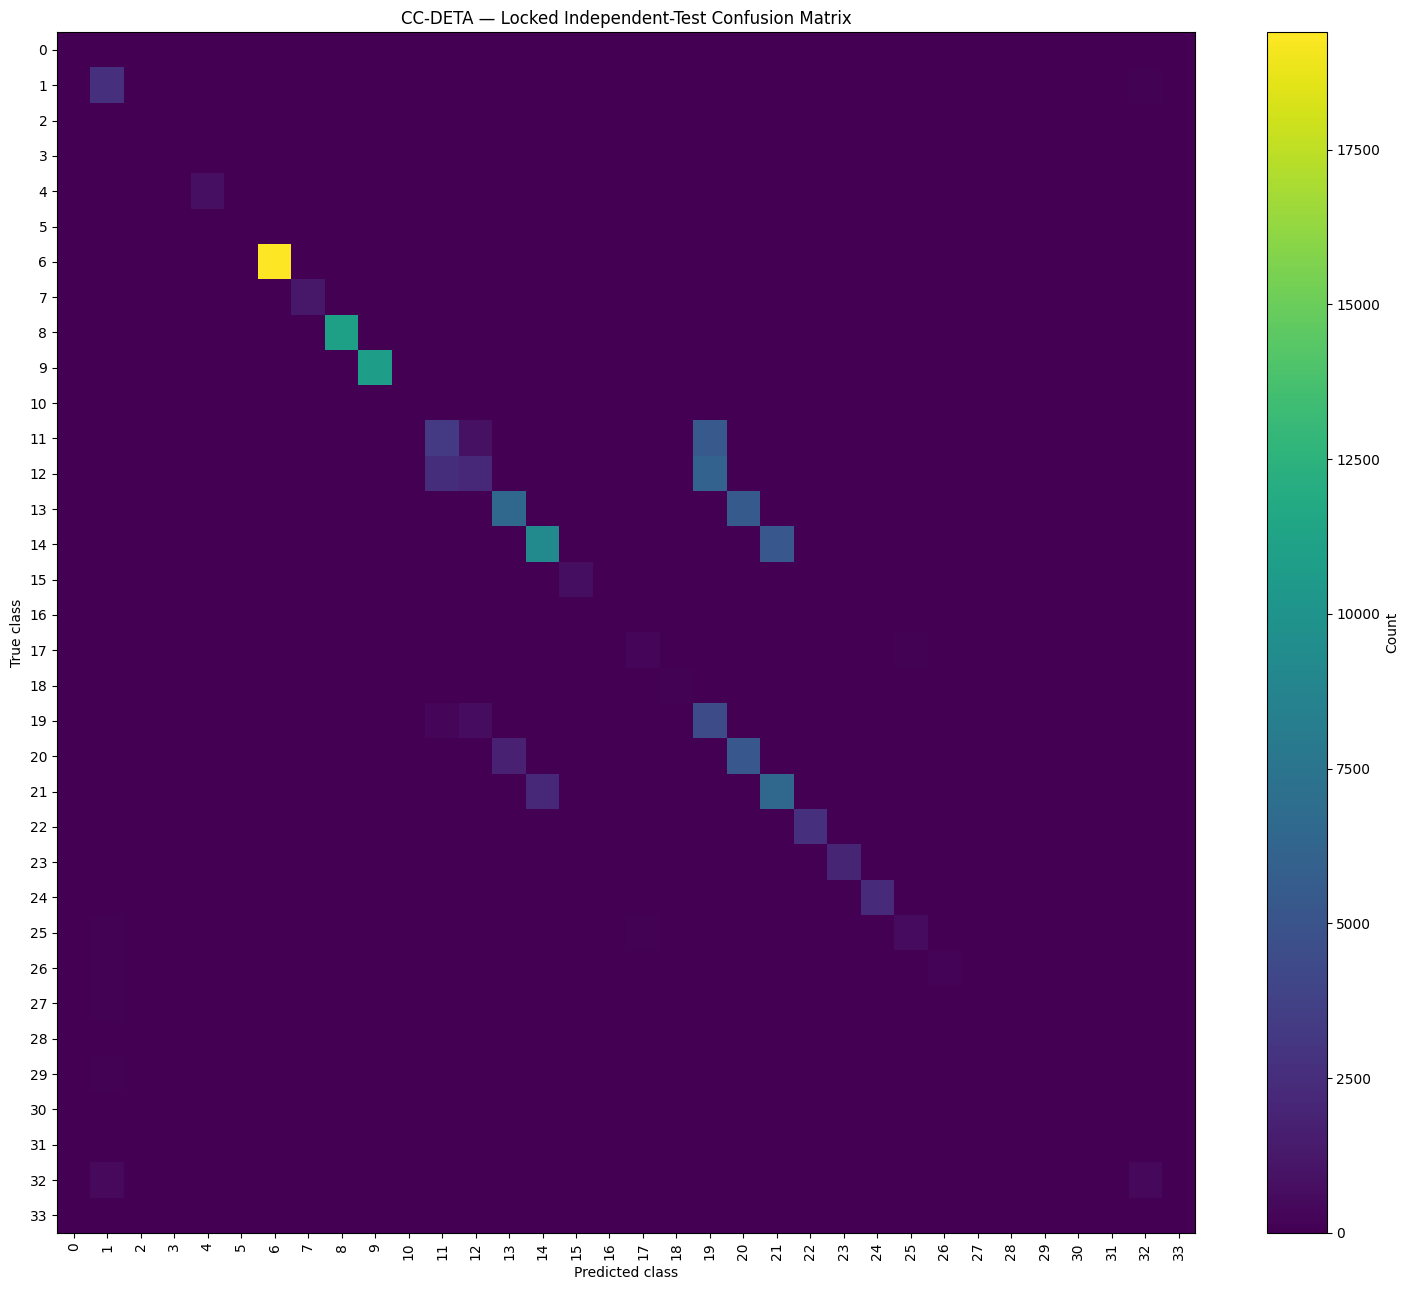

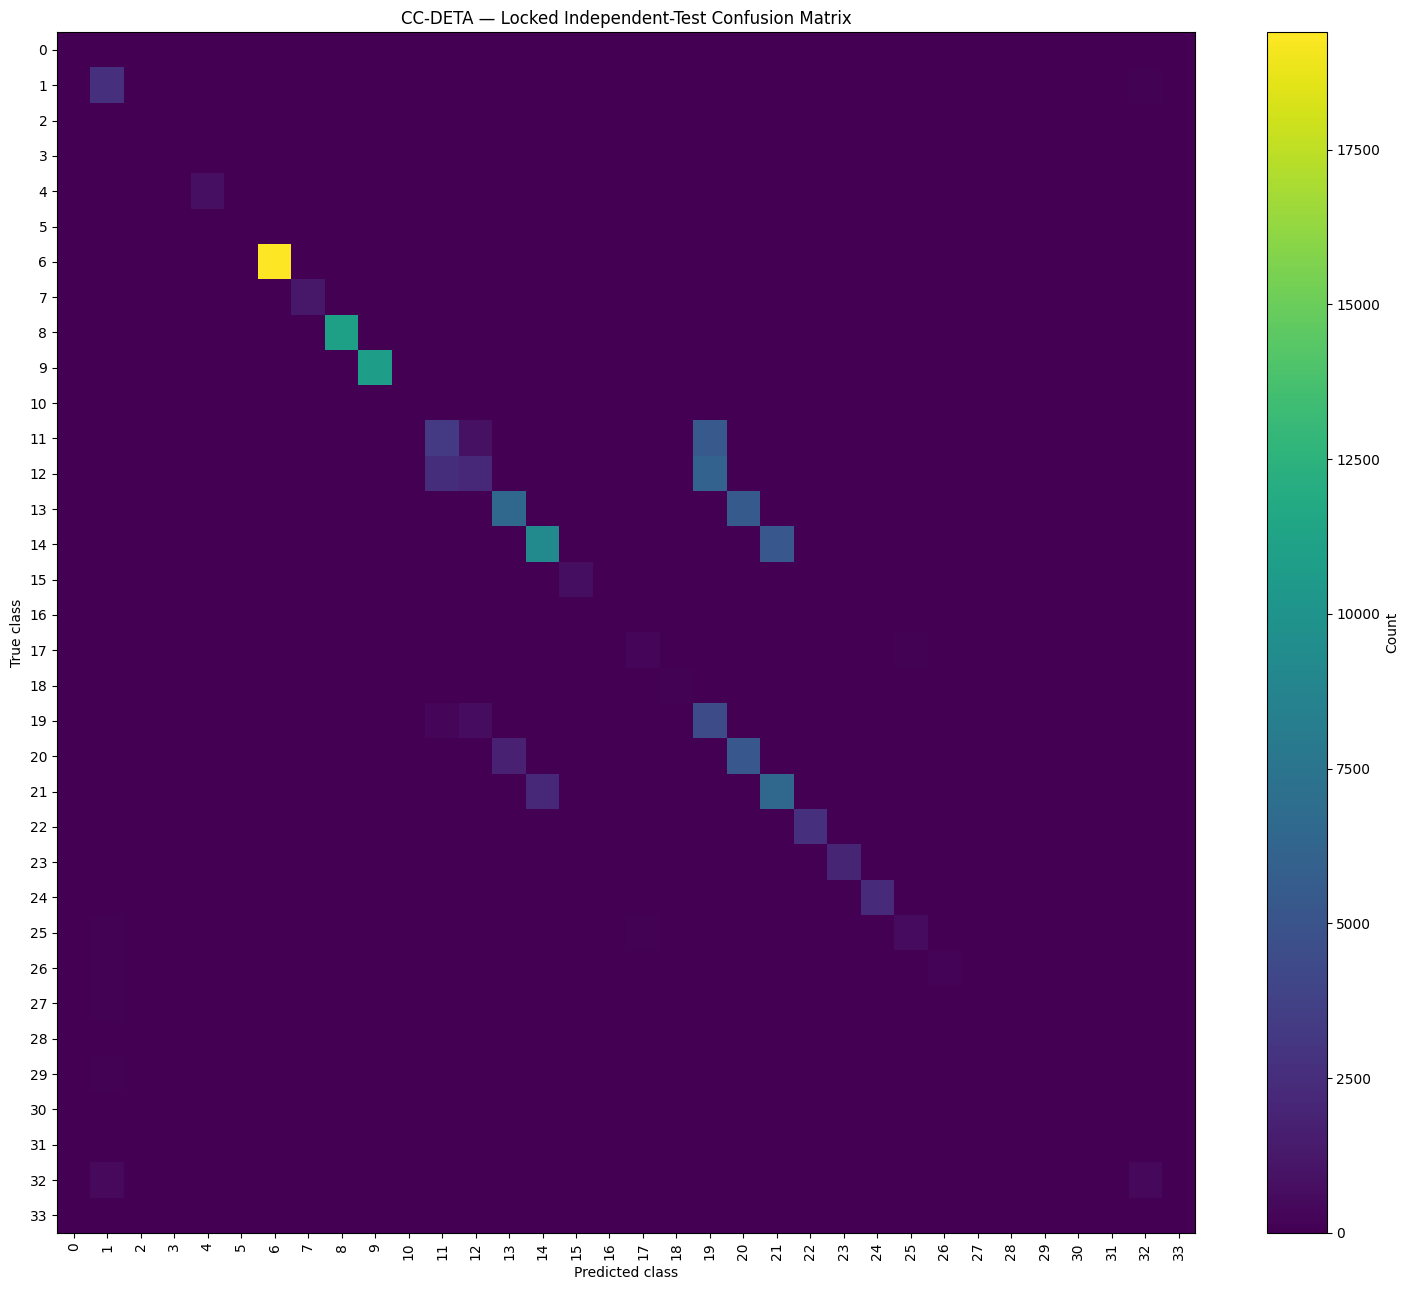

### Final CC-DETA Normalized Independent-Test Confusion Matrix

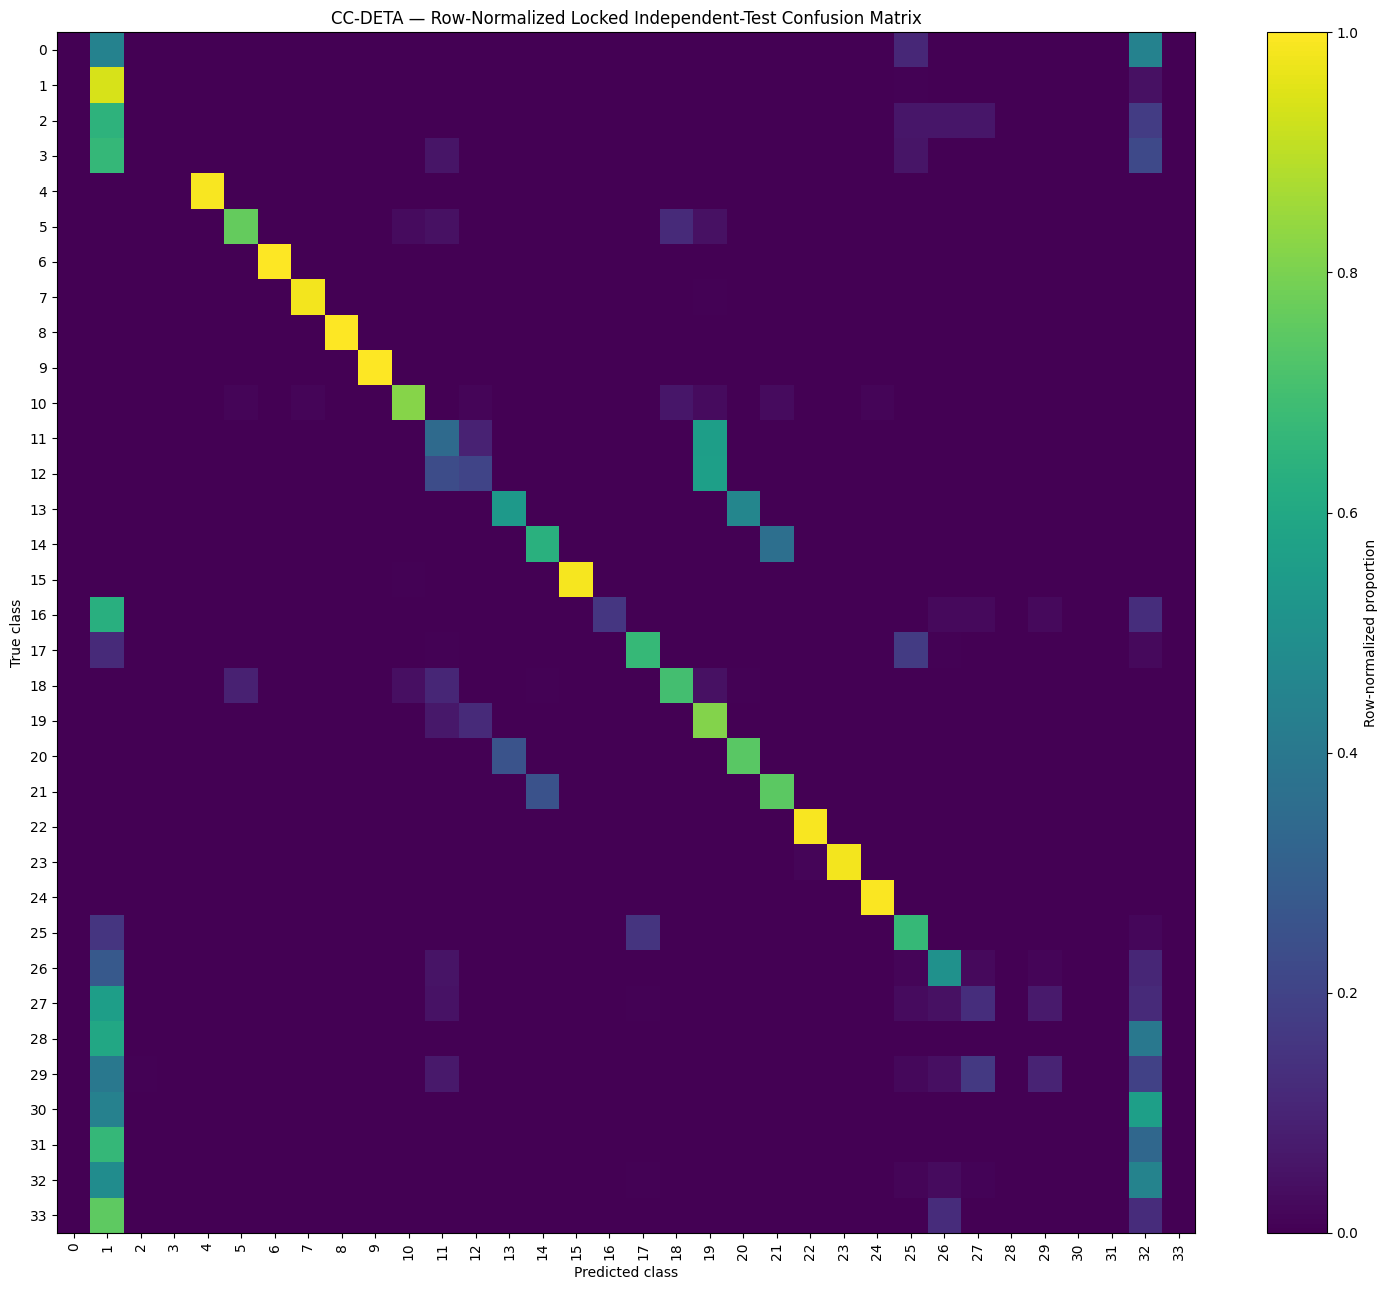

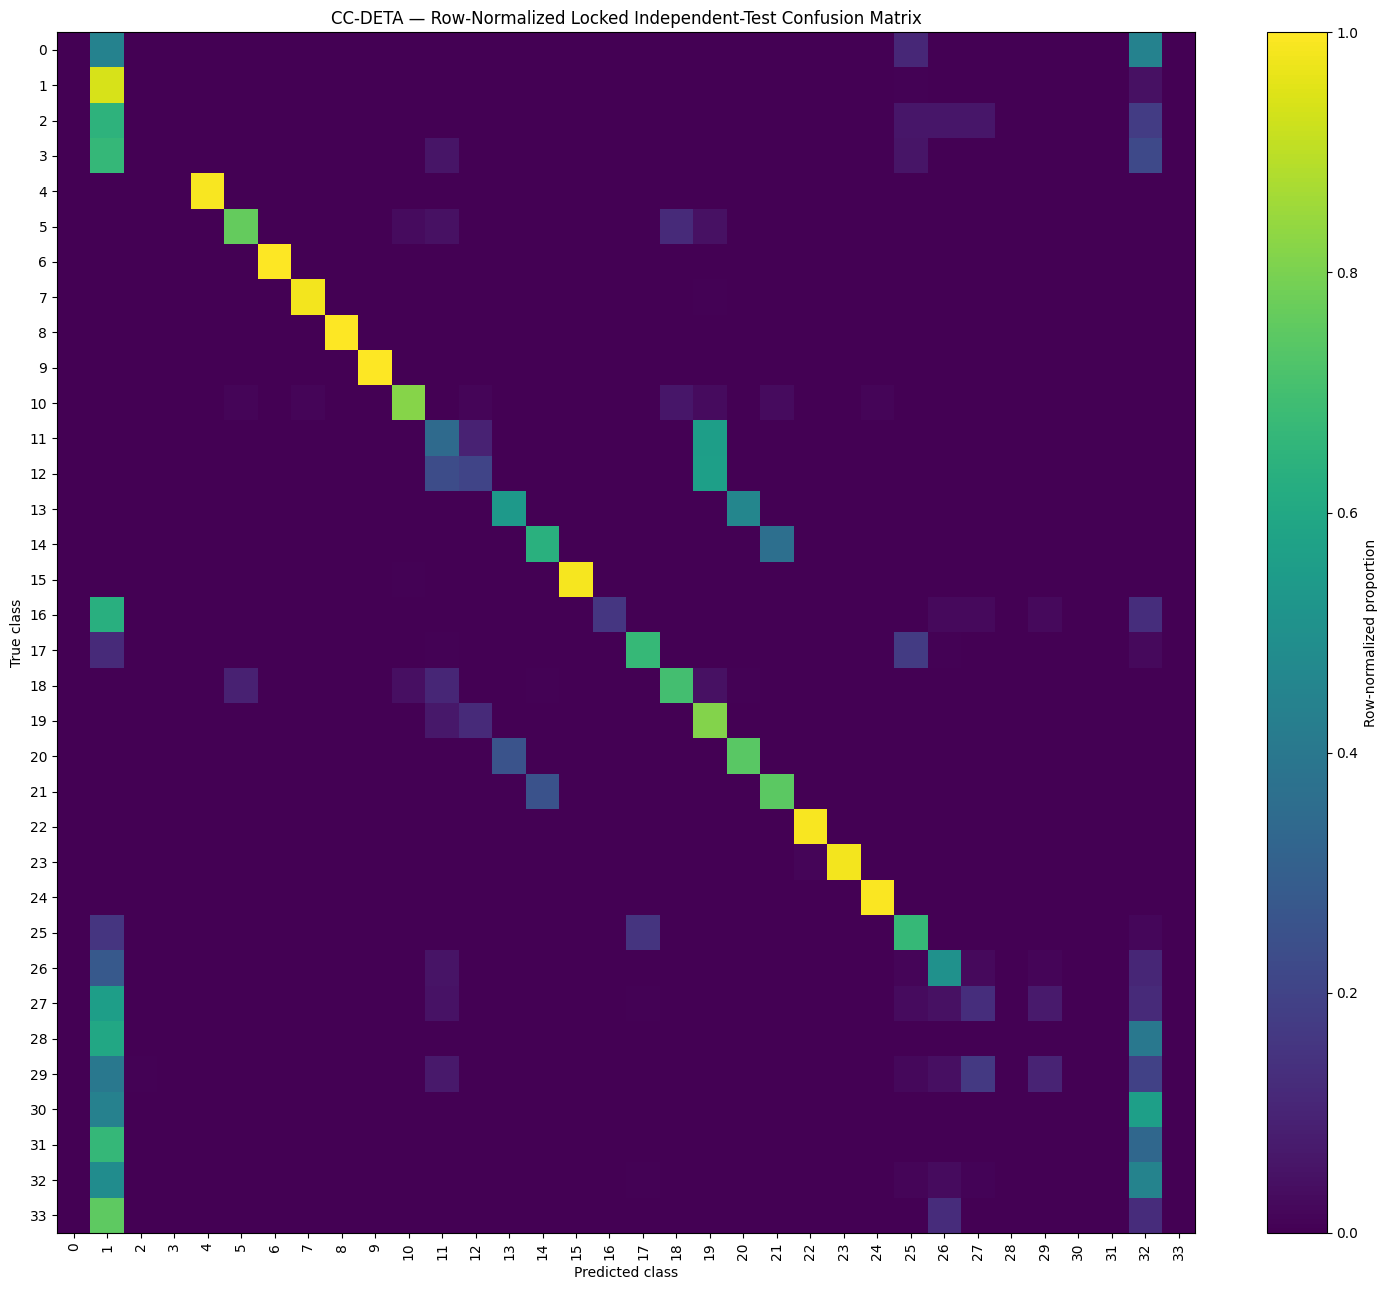

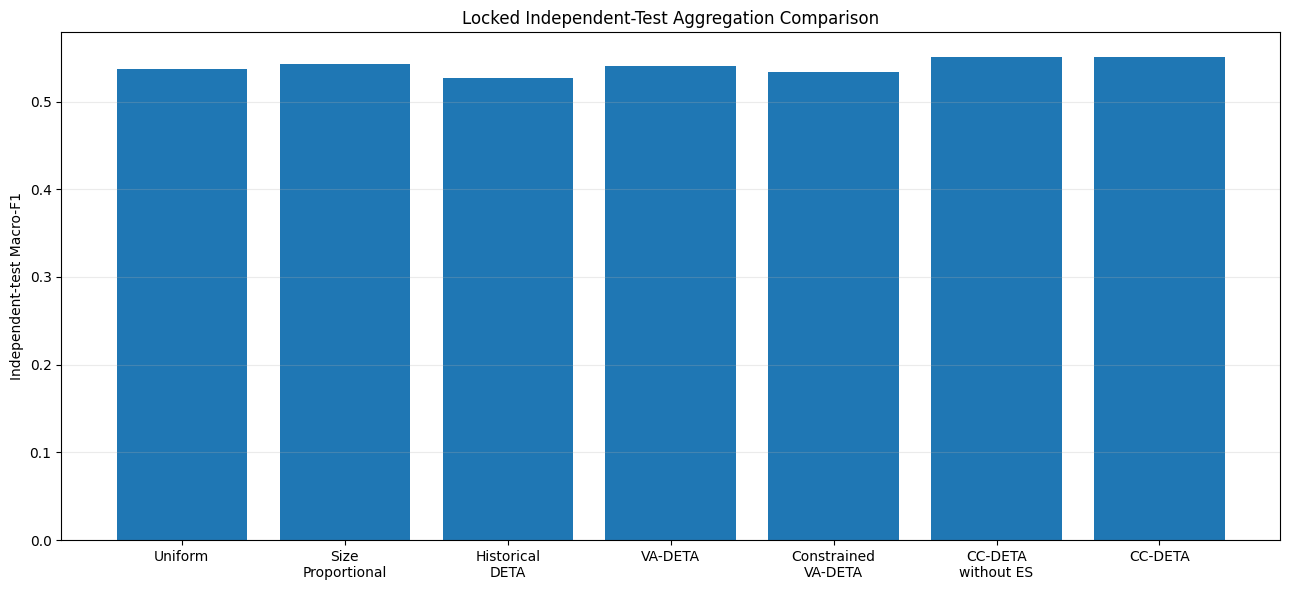

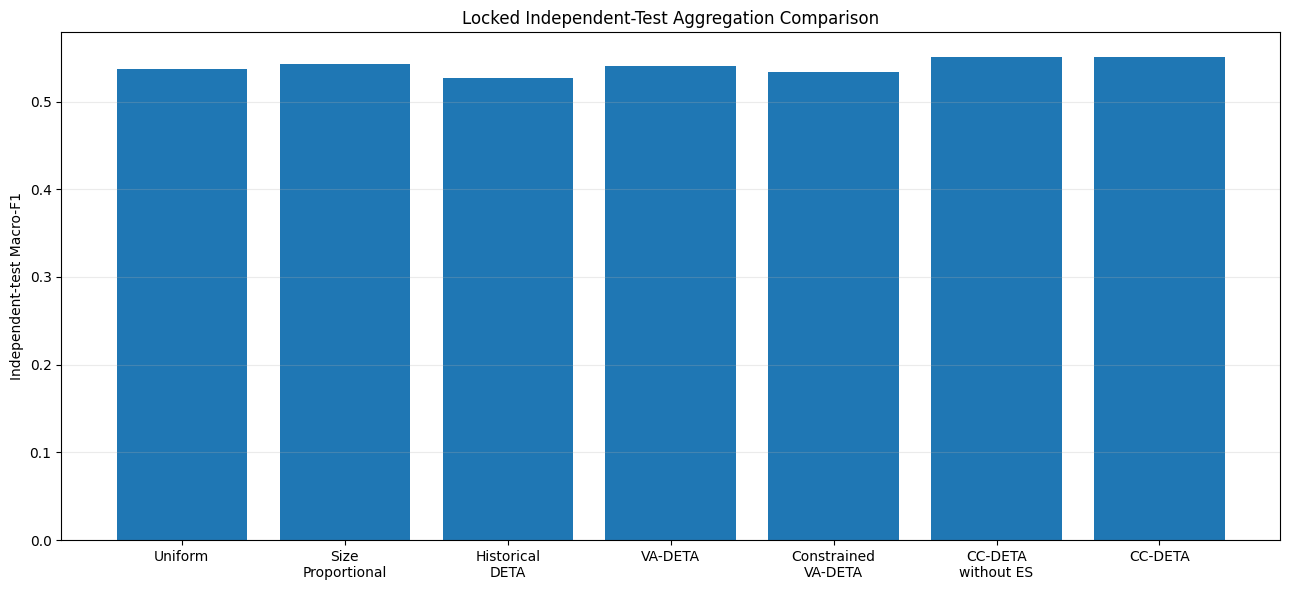

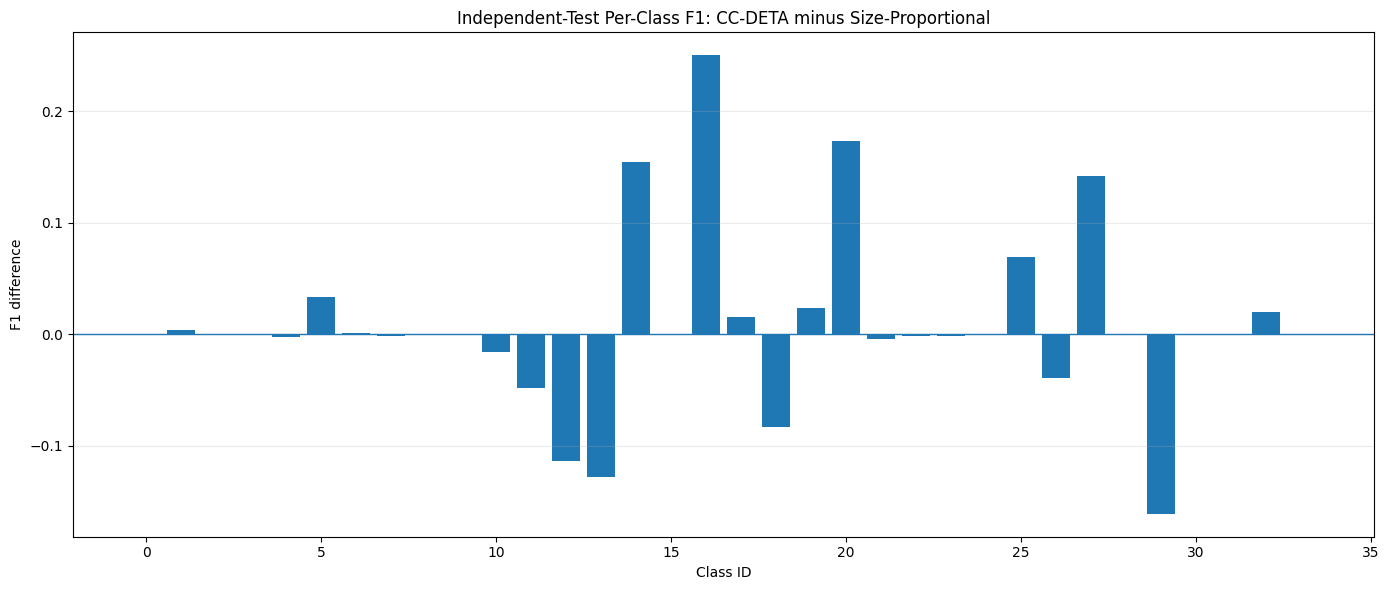

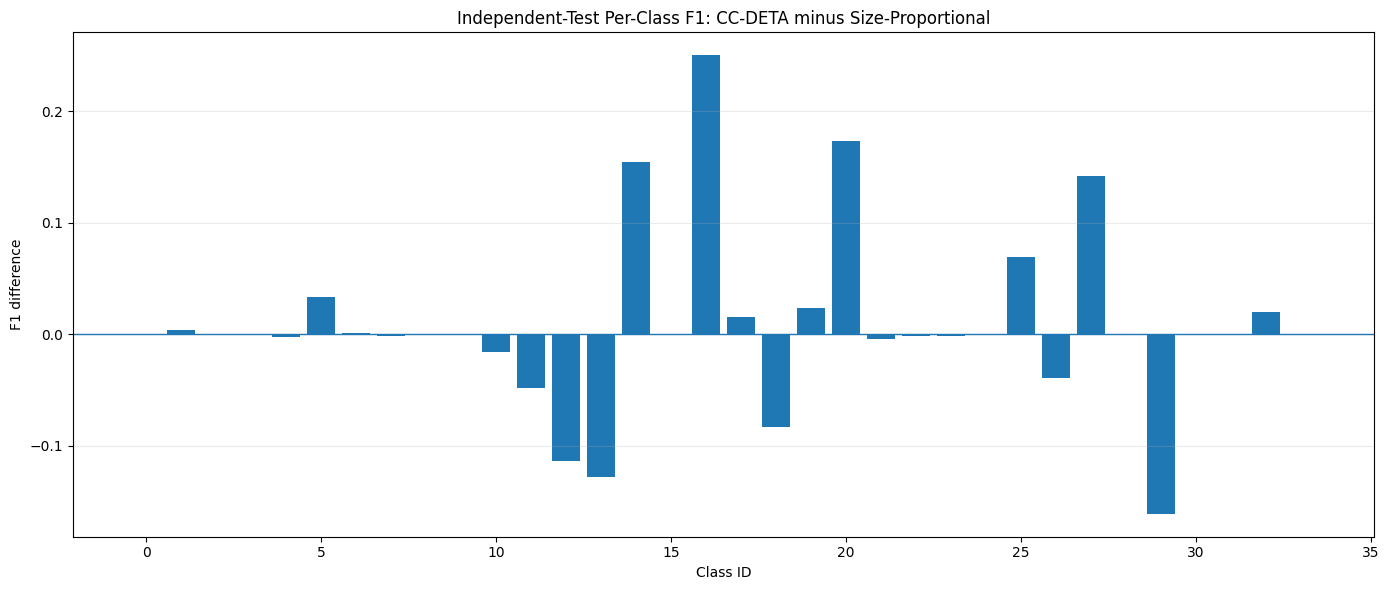

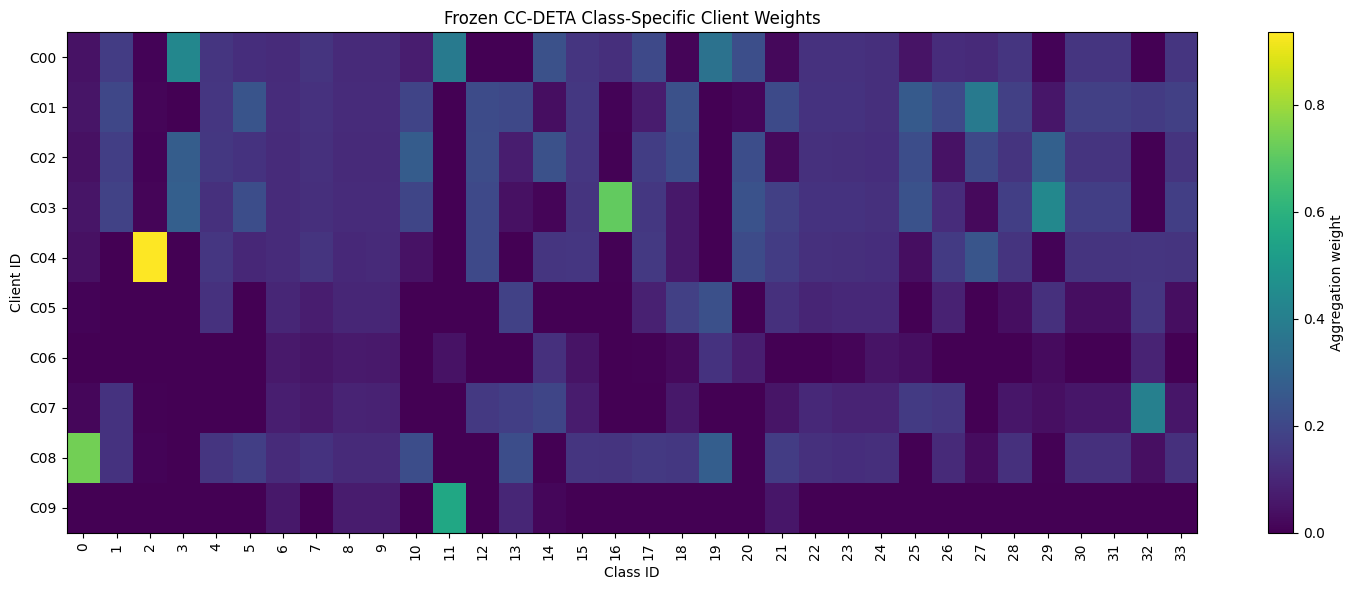

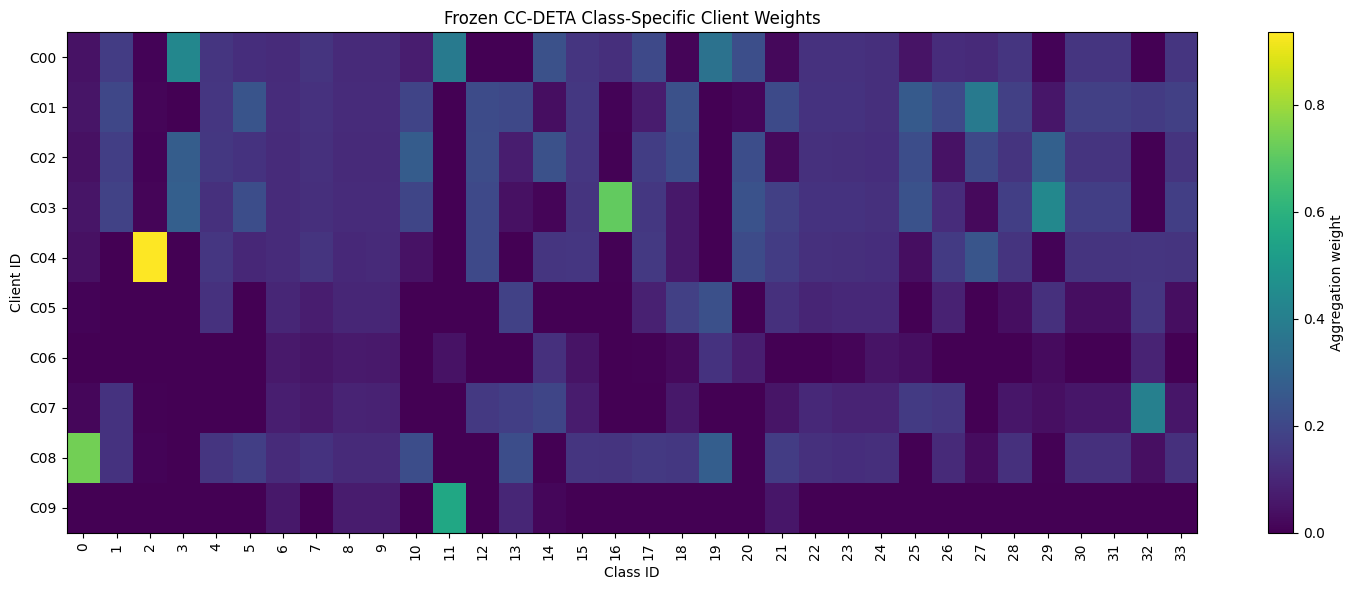


CELL 41 FINAL AUDIT

Frozen CC-DETA:
T_{i,c} = 0.100000*L_{i,c} + 0.750000*G_{i,c} + 0.050000*R_{i,c} + 0.100000*ES_i

w_{i,c} = T_{i,c}^4.000000 / sum_j(T_{j,c}^4.000000)

Locked independent-test Macro-F1:
Uniform                    : 0.53727380
Size_Proportional          : 0.54299620
Historical_DETA            : 0.52648341
Unconstrained_VA_DETA      : 0.54070972
Constrained_VA_DETA        : 0.53393288
CC_DETA_without_ES         : 0.55051470
CC_DETA                    : 0.55138925

CC-DETA gains:
vs Uniform           : +0.01411545
vs Size Proportional : +0.00839306
vs Historical DETA   : +0.02490585

Explainability contribution:
CC-DETA Macro-F1      : 0.55138925
CC-DETA without ES    : 0.55051470
ES Macro-F1 increment : +0.00087456

Classes improved vs size: 13 / 34
Classes worsened vs size: 14 / 34

Methodology audit:
Cell 40 SHA256 verified : YES
Models retrained          : NO
Trust recomputed          : NO
Coefficients changed      : NO
Tau changed               : NO
Test-driven 

In [ ]:
# CELL 41 — SHA256-LOCKED INDEPENDENT-TEST EVALUATION OF CC-DETA
#
# PURPOSE
# Evaluate the EXACT Class-Conditional DETA (CC-DETA) configuration frozen
# in Cell 40 on the locked independent-test partition.
#
# ABSOLUTELY NO:
#   × coefficient optimization
#   × tau optimization
#   × trust-component tuning
#   × model retraining
#   × test-driven selection
#
# FROZEN CELL 40 CONFIGURATION
#
#   T_{i,c} =
#       0.10 * L_{i,c}
#     + 0.75 * G_{i,c}
#     + 0.05 * R_{i,c}
#     + 0.10 * ES_i
#
#                     T_{i,c} ^ 4
#   w_{i,c} = -------------------------------
#              sum_j T_{j,c} ^ 4
#
#   Q_c(x) = sum_i w_{i,c} P_i(c|x)
#
#                        Q_c(x)
#   P_CC-DETA(c|x) = --------------------
#                     sum_k Q_k(x)
#
# EXPECTED CELL 40 CONFIG SHA256:
#
#   4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
#
# BASELINES
#    Uniform
#    Size proportional
#    Historical DETA
#    Unconstrained scalar VA-DETA
#    Constrained scalar VA-DETA
#    CC-DETA without ES counterfactual
#    CC-DETA
#    Centralized XGBoost reference (loaded from prior frozen result if available)
#



from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    log_loss,
    confusion_matrix
)

from IPython.display import display, Markdown


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 360)
pd.set_option("display.float_format", lambda x: f"{x:.8f}")


print("=" * 135)
print("CELL 41 — SHA256-LOCKED INDEPENDENT-TEST EVALUATION OF CC-DETA")
print("=" * 135)


# 1. PATHS

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

CC_DIR = (
    ROOT /
    "06_trust" /
    "class_conditional_DETA"
)

CC_CONFIG_PATH = (
    CC_DIR /
    "CC_DETA_FROZEN_meta_validation_configuration.json"
)

CC_MANIFEST_PATH = (
    REPRO_DIR /
    "cell40_CC_DETA_meta_validation_manifest.json"
)

L_CLASS_PATH = (
    TABLE_DIR /
    "cell40_CC_DETA_local_class_F1.csv"
)

G_CLASS_PATH = (
    TABLE_DIR /
    "cell40_CC_DETA_server_trust_class_F1.csv"
)

R_CLASS_PATH = (
    TABLE_DIR /
    "cell40_CC_DETA_server_trust_class_recall.csv"
)

ES_PATH = (
    TABLE_DIR /
    "cell40_CC_DETA_trust_subset_ES.csv"
)

BASELINE_WEIGHT_PATH = (
    TABLE_DIR /
    "mixed_reliability_CELL21_VERIFIED_aggregation_weights.csv"
)

HISTORICAL_TRUST_PATH = (
    ROOT /
    "06_trust" /
    "mixed_reliability_final_verified_DETA_trust.csv"
)

CELL39_CONFIG_PATH = (
    ROOT /
    "06_trust" /
    "validation_adaptive_DETA" /
    "VA_DETA_FROZEN_server_validation_configuration.json"
)

CELL39B_CONFIG_PATH = (
    ROOT /
    "06_trust" /
    "constrained_validation_adaptive_DETA" /
    "CONSTRAINED_VA_DETA_FROZEN_configuration.json"
)

TEST_DIR = (
    ROOT /
    "02_partitions" /
    "independent_test"
)

EXPECTED_CC_CONFIG_SHA256 = (
    "4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b"
)

N_CLIENTS = 10
N_CLASSES = 34
LABEL_COL = "Label_Encoded"


FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPRO_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# 2. HELPERS

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def normalize_rows(prob):

    prob = np.asarray(
        prob,
        dtype=np.float64
    )

    prob = np.clip(
        prob,
        1e-15,
        None
    )

    denom = prob.sum(
        axis=1,
        keepdims=True
    )

    if np.any(
        denom <= 0
    ):
        raise RuntimeError(
            "Probability normalization failure."
        )

    return (
        prob /
        denom
    )


def scalar_aggregate(
    prob_stack,
    weights
):

    weights = np.asarray(
        weights,
        dtype=np.float64
    )

    weights = (
        weights /
        weights.sum()
    )

    raw = np.tensordot(
        weights,
        prob_stack,
        axes=(0, 0)
    )

    return normalize_rows(
        raw
    )


def cc_weights(
    L_class,
    G_class,
    R_class,
    ES,
    theta,
    tau
):

    theta = np.asarray(
        theta,
        dtype=np.float64
    )

    if not np.isclose(
        theta.sum(),
        1.0,
        atol=1e-10
    ):
        raise RuntimeError(
            "CC-DETA coefficient sum != 1."
        )


    T = (
        theta[0] * L_class
        +
        theta[1] * G_class
        +
        theta[2] * R_class
        +
        theta[3] * ES[:, None]
    )


    T = np.clip(
        T,
        1e-12,
        None
    )


    powered = np.power(
        T,
        tau
    )


    W = (
        powered /
        powered.sum(
            axis=0,
            keepdims=True
        )
    )


    if not np.allclose(
        W.sum(axis=0),
        1.0,
        atol=1e-10
    ):
        raise RuntimeError(
            "CC-DETA class-wise weight normalization failed."
        )


    return T, W


def cc_aggregate(
    prob_stack,
    class_weights
):

    raw = np.sum(
        prob_stack
        *
        class_weights[:, None, :],
        axis=0
    )

    return normalize_rows(
        raw
    )


def evaluate(
    y_true,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Macro_Precision":
            float(
                precision_score(
                    y_true,
                    pred,
                    labels=np.arange(N_CLASSES),
                    average="macro",
                    zero_division=0
                )
            ),

        "Macro_Recall":
            float(
                recall_score(
                    y_true,
                    pred,
                    labels=np.arange(N_CLASSES),
                    average="macro",
                    zero_division=0
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    labels=np.arange(N_CLASSES),
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    average="weighted",
                    zero_division=0
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    y_true,
                    pred
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_true,
                    prob,
                    labels=np.arange(N_CLASSES)
                )
            ),
    }


def find_one_existing(
    candidates,
    description
):

    existing = [
        Path(p)
        for p in candidates
        if Path(p).exists()
    ]

    if len(existing) == 0:

        raise FileNotFoundError(
            f"\nUnable to resolve {description}.\n"
            f"Checked:\n"
            +
            "\n".join(
                str(x)
                for x in candidates
            )
        )

    if len(existing) > 1:

        print(
            f"Multiple {description} candidates found."
        )

        print(
            f"Using first explicit-priority candidate:\n{existing[0]}"
        )

    return existing[0]


# 3. VERIFY CELL 40 FROZEN CONFIGURATION

print("\n" + "=" * 135)
print("CELL 40 SHA256 FREEZE VERIFICATION")
print("=" * 135)


if not CC_CONFIG_PATH.exists():

    raise FileNotFoundError(
        CC_CONFIG_PATH
    )


actual_sha = sha256_file(
    CC_CONFIG_PATH
)


print(
    "Expected SHA256:",
    EXPECTED_CC_CONFIG_SHA256
)

print(
    "Actual SHA256  :",
    actual_sha
)


if actual_sha != EXPECTED_CC_CONFIG_SHA256:

    raise RuntimeError(
        "\nCC-DETA configuration hash mismatch.\n"
        "Do NOT evaluate the independent test."
    )


print(
    "\nCell 40 CC-DETA configuration SHA256: PASSED"
)


with open(
    CC_CONFIG_PATH,
    "r"
) as f:

    cc_config = json.load(f)


selected = cc_config[
    "selected_parameters"
]


CC_THETA = np.array(
    [
        selected[
            "alpha_local_class_F1"
        ],

        selected[
            "beta_server_class_F1"
        ],

        selected[
            "gamma_server_class_recall"
        ],

        selected[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


CC_TAU = float(
    selected[
        "tau"
    ]
)


print("\nFrozen CC-DETA parameters:")

print(
    f"alpha L_ic : {CC_THETA[0]:.8f}"
)

print(
    f"beta  G_ic : {CC_THETA[1]:.8f}"
)

print(
    f"gamma R_ic : {CC_THETA[2]:.8f}"
)

print(
    f"delta ES_i : {CC_THETA[3]:.8f}"
)

print(
    f"tau        : {CC_TAU:.8f}"
)


# Explicit expected-value audit from Cell 40 result.
expected_theta = np.array(
    [
        0.10,
        0.75,
        0.05,
        0.10,
    ]
)

expected_tau = 4.0


if not np.allclose(
    CC_THETA,
    expected_theta,
    atol=1e-12
):

    raise RuntimeError(
        "Frozen CC-DETA coefficients differ from Cell 40 final audit."
    )


if not np.isclose(
    CC_TAU,
    expected_tau,
    atol=1e-12
):

    raise RuntimeError(
        "Frozen CC-DETA tau differs from Cell 40 final audit."
    )


print(
    "Frozen parameter audit: PASSED"
)


# 4. LOAD FROZEN CLASS-CONDITIONAL EVIDENCE

print("\n" + "=" * 135)
print("FROZEN CC-DETA EVIDENCE")
print("=" * 135)


for required_path in [
    L_CLASS_PATH,
    G_CLASS_PATH,
    R_CLASS_PATH,
    ES_PATH,
]:

    if not required_path.exists():

        raise FileNotFoundError(
            required_path
        )


L_df = pd.read_csv(
    L_CLASS_PATH
).sort_values(
    "Client_ID"
)


G_df = pd.read_csv(
    G_CLASS_PATH
).sort_values(
    "Client_ID"
)


R_df = pd.read_csv(
    R_CLASS_PATH
).sort_values(
    "Client_ID"
)


ES_df = pd.read_csv(
    ES_PATH
).sort_values(
    "Client_ID"
)


class_cols = [
    f"Class_{i}"
    for i in range(
        N_CLASSES
    )
]


for frame_name, frame in [
    ("L", L_df),
    ("G", G_df),
    ("R", R_df),
]:

    missing = [
        c
        for c in class_cols
        if c not in frame.columns
    ]

    if missing:

        raise RuntimeError(
            f"{frame_name} matrix missing columns: {missing}"
        )


L_CLASS = L_df[
    class_cols
].to_numpy(
    dtype=np.float64
)


G_CLASS = G_df[
    class_cols
].to_numpy(
    dtype=np.float64
)


R_CLASS = R_df[
    class_cols
].to_numpy(
    dtype=np.float64
)


ES = ES_df[
    "ES_i"
].to_numpy(
    dtype=np.float64
)


if L_CLASS.shape != (
    N_CLIENTS,
    N_CLASSES
):

    raise RuntimeError(
        f"Invalid L_CLASS shape: {L_CLASS.shape}"
    )


if G_CLASS.shape != (
    N_CLIENTS,
    N_CLASSES
):

    raise RuntimeError(
        f"Invalid G_CLASS shape: {G_CLASS.shape}"
    )


if R_CLASS.shape != (
    N_CLIENTS,
    N_CLASSES
):

    raise RuntimeError(
        f"Invalid R_CLASS shape: {R_CLASS.shape}"
    )


if ES.shape != (
    N_CLIENTS,
):

    raise RuntimeError(
        f"Invalid ES shape: {ES.shape}"
    )


if not all(
    np.isfinite(x).all()
    for x in [
        L_CLASS,
        G_CLASS,
        R_CLASS,
        ES
    ]
):

    raise RuntimeError(
        "Non-finite frozen CC-DETA evidence."
    )


print(
    "L_CLASS:",
    L_CLASS.shape
)

print(
    "G_CLASS:",
    G_CLASS.shape
)

print(
    "R_CLASS:",
    R_CLASS.shape
)

print(
    "ES     :",
    ES.shape
)


# 5. RECONSTRUCT FROZEN CC-DETA CLASS WEIGHTS

CC_TRUST, CC_WEIGHTS = cc_weights(

    L_class=L_CLASS,

    G_class=G_CLASS,

    R_class=R_CLASS,

    ES=ES,

    theta=CC_THETA,

    tau=CC_TAU
)


print("\nCC-DETA weight audit:")

print(
    "Shape:",
    CC_WEIGHTS.shape
)

print(
    "Minimum weight:",
    f"{CC_WEIGHTS.min():.8f}"
)

print(
    "Maximum weight:",
    f"{CC_WEIGHTS.max():.8f}"
)

print(
    "Per-class weight sums:",
    f"{CC_WEIGHTS.sum(axis=0).min():.12f}",
    "to",
    f"{CC_WEIGHTS.sum(axis=0).max():.12f}"
)


# 6. CC-DETA WITHOUT-ES COUNTERFACTUAL
#
# This is NOT reoptimized.
#
# We remove ES from the frozen selected equation and proportionally
# renormalize the three predictive coefficients.

CC_NO_ES_THETA = CC_THETA.copy()

CC_NO_ES_THETA[
    3
] = 0.0


CC_NO_ES_THETA[
    :3
] = (
    CC_NO_ES_THETA[
        :3
    ]
    /
    CC_NO_ES_THETA[
        :3
    ].sum()
)


NO_ES_TRUST, NO_ES_WEIGHTS = cc_weights(

    L_class=L_CLASS,

    G_class=G_CLASS,

    R_class=R_CLASS,

    ES=ES,

    theta=CC_NO_ES_THETA,

    tau=CC_TAU
)


print(
    "\nFrozen no-ES counterfactual coefficients:",
    CC_NO_ES_THETA
)


# 7. RESOLVE LOCKED INDEPENDENT TEST

print("\n" + "=" * 135)
print("RESOLVING LOCKED INDEPENDENT TEST")
print("=" * 135)


TEST_PATH = find_one_existing(
    [
        TEST_DIR /
        "independent_test_real_clean_LOCKED.parquet",

        TEST_DIR /
        "independent_test_real_clean.parquet",
    ],
    "locked independent-test dataset"
)


print(
    "Independent test:",
    TEST_PATH
)


test_df = pd.read_parquet(
    TEST_PATH,
    columns=[
        LABEL_COL
    ]
)


y_test = test_df[
    LABEL_COL
].to_numpy(
    dtype=np.int32
)


print(
    "Rows   :",
    f"{len(y_test):,}"
)

print(
    "Classes:",
    len(
        np.unique(
            y_test
        )
    )
)


if len(
    y_test
) != 125_987:

    print(
        "WARNING: row count differs from prior locked test result."
    )


if len(
    np.unique(
        y_test
    )
) != N_CLASSES:

    raise RuntimeError(
        "Independent test does not contain all 34 classes."
    )


# 8. RESOLVE EXACT SAVED INDEPENDENT-TEST CLIENT PROBABILITIES

print("\n" + "=" * 135)
print("LOCKED TEST CLIENT PROBABILITIES")
print("=" * 135)


TEST_PROB_DIR_CANDIDATES = [

    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "independent_test_FINAL" /
    "clients",

    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "independent_test_clients",

    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "independent_test",

    ROOT /
    "05_probabilities" /
    "mixed_reliability" /
    "test_clients",
]


TEST_PROB_DIR = None


for candidate in TEST_PROB_DIR_CANDIDATES:

    if candidate.exists():

        TEST_PROB_DIR = candidate

        break


if TEST_PROB_DIR is None:

    raise FileNotFoundError(
        "\nUnable to resolve saved independent-test probability directory.\n"
        "Checked:\n"
        +
        "\n".join(
            str(x)
            for x in TEST_PROB_DIR_CANDIDATES
        )
    )


print(
    "Probability directory:",
    TEST_PROB_DIR
)


test_probabilities = []

probability_files = []


for client_id in range(
    N_CLIENTS
):

    candidates = sorted(
        TEST_PROB_DIR.glob(
            f"*client_{client_id:02d}*.npy"
        )
    )


    if len(candidates) == 0:

        # Broader fallback inside resolved directory.
        candidates = sorted(
            TEST_PROB_DIR.glob(
                f"*{client_id:02d}*.npy"
            )
        )


    if len(candidates) == 0:

        raise FileNotFoundError(
            f"Missing locked-test probability matrix "
            f"for Client {client_id:02d}."
        )


    path = candidates[
        0
    ]


    prob = np.load(
        path
    )


    if prob.shape != (
        len(y_test),
        N_CLASSES
    ):

        raise RuntimeError(
            f"Client {client_id:02d}: "
            f"probability shape {prob.shape}, "
            f"expected {(len(y_test), N_CLASSES)}"
        )


    prob = normalize_rows(
        prob
    )


    test_probabilities.append(
        prob.astype(
            np.float32
        )
    )


    probability_files.append(
        str(
            path
        )
    )


    print(
        f"Client {client_id:02d}: "
        f"{path.name} "
        f"{prob.shape} — PASSED"
    )


PROB_TEST = np.stack(
    test_probabilities,
    axis=0
)


print(
    "\nProbability stack:",
    PROB_TEST.shape
)


# 9. LOAD SCALAR BASELINE WEIGHTS

print("\n" + "=" * 135)
print("SCALAR BASELINE WEIGHTS")
print("=" * 135)


baseline_weight_df = pd.read_csv(
    BASELINE_WEIGHT_PATH
).sort_values(
    "Client_ID"
)


UNIFORM_WEIGHTS = np.repeat(
    1.0 /
    N_CLIENTS,
    N_CLIENTS
)


SIZE_WEIGHTS = baseline_weight_df[
    "Size_Proportional"
].to_numpy(
    dtype=np.float64
)


SIZE_WEIGHTS /= SIZE_WEIGHTS.sum()


historical_trust_df = pd.read_csv(
    HISTORICAL_TRUST_PATH
).sort_values(
    "Client_ID"
)


HIST_COMPONENT_MATRIX = historical_trust_df[
    [
        "L_i",
        "G_i",
        "B_i",
        "ES_i",
    ]
].to_numpy(
    dtype=np.float64
)


HIST_THETA = np.array(
    [
        0.20,
        0.40,
        0.30,
        0.10,
    ],
    dtype=np.float64
)


HIST_T = (
    HIST_COMPONENT_MATRIX
    @
    HIST_THETA
)


HIST_WEIGHTS = (
    HIST_T /
    HIST_T.sum()
)


# 10. CELL 39 UNCONSTRAINED VA-DETA WEIGHTS

with open(
    CELL39_CONFIG_PATH,
    "r"
) as f:

    c39 = json.load(f)


c39_par = c39[
    "adaptive_configuration"
]


C39_THETA = np.array(
    [
        c39_par[
            "alpha_L"
        ],

        c39_par[
            "beta_G"
        ],

        c39_par[
            "gamma_B"
        ],

        c39_par[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


C39_TAU = float(
    c39_par[
        "tau"
    ]
)


C39_T = (
    HIST_COMPONENT_MATRIX
    @
    C39_THETA
)


C39_WEIGHTS = np.power(
    np.clip(
        C39_T,
        1e-12,
        None
    ),
    C39_TAU
)


C39_WEIGHTS /= C39_WEIGHTS.sum()


# 11. CELL 39B CONSTRAINED VA-DETA WEIGHTS

with open(
    CELL39B_CONFIG_PATH,
    "r"
) as f:

    c39b = json.load(f)


c39b_par = c39b[
    "selected_parameters"
]


C39B_THETA = np.array(
    [
        c39b_par[
            "alpha_L"
        ],

        c39b_par[
            "beta_G"
        ],

        c39b_par[
            "gamma_B"
        ],

        c39b_par[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


C39B_TAU = float(
    c39b_par[
        "tau"
    ]
)


C39B_T = (
    HIST_COMPONENT_MATRIX
    @
    C39B_THETA
)


C39B_WEIGHTS = np.power(
    np.clip(
        C39B_T,
        1e-12,
        None
    ),
    C39B_TAU
)


C39B_WEIGHTS /= C39B_WEIGHTS.sum()


# 12. FINAL LOCKED-TEST AGGREGATION

print("\n" + "=" * 135)
print("LOCKED INDEPENDENT-TEST AGGREGATION")
print("=" * 135)


METHOD_PROB = {}


METHOD_PROB[
    "Uniform"
] = scalar_aggregate(
    PROB_TEST,
    UNIFORM_WEIGHTS
)


METHOD_PROB[
    "Size_Proportional"
] = scalar_aggregate(
    PROB_TEST,
    SIZE_WEIGHTS
)


METHOD_PROB[
    "Historical_DETA"
] = scalar_aggregate(
    PROB_TEST,
    HIST_WEIGHTS
)


METHOD_PROB[
    "Unconstrained_VA_DETA"
] = scalar_aggregate(
    PROB_TEST,
    C39_WEIGHTS
)


METHOD_PROB[
    "Constrained_VA_DETA"
] = scalar_aggregate(
    PROB_TEST,
    C39B_WEIGHTS
)


METHOD_PROB[
    "CC_DETA_without_ES"
] = cc_aggregate(
    PROB_TEST,
    NO_ES_WEIGHTS
)


METHOD_PROB[
    "CC_DETA"
] = cc_aggregate(
    PROB_TEST,
    CC_WEIGHTS
)


# Probability audit
for method, prob in METHOD_PROB.items():

    if prob.shape != (
        len(y_test),
        N_CLASSES
    ):

        raise RuntimeError(
            f"{method}: invalid shape {prob.shape}"
        )


    if not np.allclose(
        prob.sum(
            axis=1
        ),
        1.0,
        atol=1e-8
    ):

        raise RuntimeError(
            f"{method}: probability rows not normalized."
        )


    print(
        f"{method:<27}: "
        f"{prob.shape} — PASSED"
    )


# 13. FINAL LOCKED-TEST METRICS

print("\n" + "=" * 135)
print("FINAL LOCKED INDEPENDENT-TEST PERFORMANCE")
print("=" * 135)


metric_rows = []


for method, prob in METHOD_PROB.items():

    metrics = evaluate(
        y_test,
        prob
    )


    metric_rows.append({

        "Method":
            method,

        **metrics,
    })


metrics_df = pd.DataFrame(
    metric_rows
)


# Sort in logical—not performance—order.
method_order = [

    "Uniform",

    "Size_Proportional",

    "Historical_DETA",

    "Unconstrained_VA_DETA",

    "Constrained_VA_DETA",

    "CC_DETA_without_ES",

    "CC_DETA",
]


metrics_df[
    "_Order"
] = metrics_df[
    "Method"
].map(
    {
        m: i
        for i, m
        in enumerate(
            method_order
        )
    }
)


metrics_df = (
    metrics_df
    .sort_values(
        "_Order"
    )
    .drop(
        columns="_Order"
    )
    .reset_index(
        drop=True
    )
)


display(
    metrics_df
)


# 14. PRIMARY COMPARISON DELTAS

def row_for(
    method
):

    return metrics_df.loc[
        metrics_df[
            "Method"
        ]
        ==
        method
    ].iloc[
        0
    ]


cc_row = row_for(
    "CC_DETA"
)

size_row = row_for(
    "Size_Proportional"
)

uniform_row = row_for(
    "Uniform"
)

hist_row = row_for(
    "Historical_DETA"
)

no_es_row = row_for(
    "CC_DETA_without_ES"
)


comparison_rows = []


for baseline_name in [

    "Uniform",

    "Size_Proportional",

    "Historical_DETA",

    "Unconstrained_VA_DETA",

    "Constrained_VA_DETA",

    "CC_DETA_without_ES",
]:

    base = row_for(
        baseline_name
    )


    comparison_rows.append({

        "Comparison":
            f"CC_DETA vs {baseline_name}",

        "Accuracy_Delta":
            float(
                cc_row[
                    "Accuracy"
                ]
                -
                base[
                    "Accuracy"
                ]
            ),

        "Balanced_Accuracy_Delta":
            float(
                cc_row[
                    "Balanced_Accuracy"
                ]
                -
                base[
                    "Balanced_Accuracy"
                ]
            ),

        "Macro_F1_Delta":
            float(
                cc_row[
                    "Macro_F1"
                ]
                -
                base[
                    "Macro_F1"
                ]
            ),

        "Weighted_F1_Delta":
            float(
                cc_row[
                    "Weighted_F1"
                ]
                -
                base[
                    "Weighted_F1"
                ]
            ),

        "MCC_Delta":
            float(
                cc_row[
                    "MCC"
                ]
                -
                base[
                    "MCC"
                ]
            ),

        "Log_Loss_Improvement":
            float(
                base[
                    "Log_Loss"
                ]
                -
                cc_row[
                    "Log_Loss"
                ]
            ),
    })


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 135)
print("CC-DETA TEST DELTAS")
print("=" * 135)


display(
    comparison_df
)


# 15. FINAL EXPLAINABILITY COUNTERFACTUAL

ES_TEST_INCREMENT = float(
    cc_row[
        "Macro_F1"
    ]
    -
    no_es_row[
        "Macro_F1"
    ]
)


print("\n" + "=" * 135)
print("EXPLAINABILITY COUNTERFACTUAL — LOCKED TEST")
print("=" * 135)


print(
    "CC-DETA Macro-F1          :",
    f"{cc_row['Macro_F1']:.8f}"
)

print(
    "CC-DETA without ES        :",
    f"{no_es_row['Macro_F1']:.8f}"
)

print(
    "Observed ES test increment:",
    f"{ES_TEST_INCREMENT:+.8f}"
)


# 16. PER-CLASS METRICS — CC-DETA

CC_PRED = np.argmax(
    METHOD_PROB[
        "CC_DETA"
    ],
    axis=1
)


SIZE_PRED = np.argmax(
    METHOD_PROB[
        "Size_Proportional"
    ],
    axis=1
)


class_precision = precision_score(
    y_test,
    CC_PRED,
    labels=np.arange(N_CLASSES),
    average=None,
    zero_division=0
)


class_recall = recall_score(
    y_test,
    CC_PRED,
    labels=np.arange(N_CLASSES),
    average=None,
    zero_division=0
)


class_f1 = f1_score(
    y_test,
    CC_PRED,
    labels=np.arange(N_CLASSES),
    average=None,
    zero_division=0
)


size_class_f1 = f1_score(
    y_test,
    SIZE_PRED,
    labels=np.arange(N_CLASSES),
    average=None,
    zero_division=0
)


support = np.bincount(
    y_test,
    minlength=N_CLASSES
)


per_class_df = pd.DataFrame({

    "Class_ID":
        np.arange(
            N_CLASSES
        ),

    "Support":
        support,

    "Precision":
        class_precision,

    "Recall":
        class_recall,

    "F1":
        class_f1,

    "Size_Proportional_F1":
        size_class_f1,

    "CC_minus_Size_F1":
        (
            class_f1
            -
            size_class_f1
        ),
})


print("\n" + "=" * 135)
print("CC-DETA PER-CLASS INDEPENDENT-TEST RESULTS")
print("=" * 135)


display(
    per_class_df
)


print(
    "\nClasses improved vs Size-Proportional:",
    int(
        (
            per_class_df[
                "CC_minus_Size_F1"
            ]
            >
            0
        ).sum()
    ),
    "/",
    N_CLASSES
)


print(
    "Classes worsened vs Size-Proportional:",
    int(
        (
            per_class_df[
                "CC_minus_Size_F1"
            ]
            <
            0
        ).sum()
    ),
    "/",
    N_CLASSES
)


# 17. FINAL CONFUSION MATRICES

CM_RAW = confusion_matrix(
    y_test,
    CC_PRED,
    labels=np.arange(
        N_CLASSES
    )
)


row_sum = CM_RAW.sum(
    axis=1,
    keepdims=True
)


CM_NORM = np.divide(
    CM_RAW,
    row_sum,
    out=np.zeros_like(
        CM_RAW,
        dtype=np.float64
    ),
    where=(
        row_sum != 0
    )
)


# Raw confusion matrix

fig, ax = plt.subplots(
    figsize=(
        15,
        13
    )
)


im = ax.imshow(
    CM_RAW,
    aspect="auto"
)


ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_title(
    "CC-DETA — Locked Independent-Test Confusion Matrix"
)


ax.set_xticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_yticks(
    np.arange(
        N_CLASSES
    )
)


ax.set_xticklabels(
    np.arange(
        N_CLASSES
    ),
    rotation=90
)

ax.set_yticklabels(
    np.arange(
        N_CLASSES
    )
)


fig.colorbar(
    im,
    ax=ax,
    label="Count"
)


fig.tight_layout()


display(
    Markdown(
        "### Final CC-DETA Raw Independent-Test Confusion Matrix"
    )
)


display(
    fig
)


CM_RAW_PNG = (
    FIG_DIR /
    "40_FINAL_CC_DETA_independent_test_confusion_matrix_raw.png"
)


CM_RAW_PDF = (
    FIG_DIR /
    "40_FINAL_CC_DETA_independent_test_confusion_matrix_raw.pdf"
)


fig.savefig(
    CM_RAW_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    CM_RAW_PDF,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


# Normalized confusion matrix

fig, ax = plt.subplots(
    figsize=(
        15,
        13
    )
)


im = ax.imshow(
    CM_NORM,
    aspect="auto",
    vmin=0,
    vmax=1
)


ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_title(
    "CC-DETA — Row-Normalized Locked Independent-Test Confusion Matrix"
)


ax.set_xticks(
    np.arange(
        N_CLASSES
    )
)

ax.set_yticks(
    np.arange(
        N_CLASSES
    )
)


ax.set_xticklabels(
    np.arange(
        N_CLASSES
    ),
    rotation=90
)

ax.set_yticklabels(
    np.arange(
        N_CLASSES
    )
)


fig.colorbar(
    im,
    ax=ax,
    label="Row-normalized proportion"
)


fig.tight_layout()


display(
    Markdown(
        "### Final CC-DETA Normalized Independent-Test Confusion Matrix"
    )
)


display(
    fig
)


CM_NORM_PNG = (
    FIG_DIR /
    "41_FINAL_CC_DETA_independent_test_confusion_matrix_normalized.png"
)


CM_NORM_PDF = (
    FIG_DIR /
    "41_FINAL_CC_DETA_independent_test_confusion_matrix_normalized.pdf"
)


fig.savefig(
    CM_NORM_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    CM_NORM_PDF,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


# 18. FIGURE — FINAL METHOD COMPARISON

plot_methods = [

    "Uniform",

    "Size_Proportional",

    "Historical_DETA",

    "Unconstrained_VA_DETA",

    "Constrained_VA_DETA",

    "CC_DETA_without_ES",

    "CC_DETA",
]


plot_df = (
    metrics_df[
        metrics_df[
            "Method"
        ].isin(
            plot_methods
        )
    ]
    .set_index(
        "Method"
    )
    .loc[
        plot_methods
    ]
    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(
        13,
        6
    )
)


x = np.arange(
    len(
        plot_df
    )
)


ax.bar(
    x,
    plot_df[
        "Macro_F1"
    ]
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Uniform",
        "Size\nProportional",
        "Historical\nDETA",
        "VA-DETA",
        "Constrained\nVA-DETA",
        "CC-DETA\nwithout ES",
        "CC-DETA",
    ]
)


ax.set_ylabel(
    "Independent-test Macro-F1"
)


ax.set_title(
    "Locked Independent-Test Aggregation Comparison"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


PERF_PNG = (
    FIG_DIR /
    "42_FINAL_CC_DETA_independent_test_method_comparison.png"
)


PERF_PDF = (
    FIG_DIR /
    "42_FINAL_CC_DETA_independent_test_method_comparison.pdf"
)


fig.savefig(
    PERF_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    PERF_PDF,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


# 19. FIGURE — PER-CLASS CC-DETA vs SIZE

fig, ax = plt.subplots(
    figsize=(
        14,
        6
    )
)


ax.bar(
    per_class_df[
        "Class_ID"
    ],
    per_class_df[
        "CC_minus_Size_F1"
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xlabel(
    "Class ID"
)


ax.set_ylabel(
    "F1 difference"
)


ax.set_title(
    "Independent-Test Per-Class F1: CC-DETA minus Size-Proportional"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


CLASS_GAIN_PNG = (
    FIG_DIR /
    "43_FINAL_CC_DETA_per_class_F1_gain_vs_size.png"
)


CLASS_GAIN_PDF = (
    FIG_DIR /
    "43_FINAL_CC_DETA_per_class_F1_gain_vs_size.pdf"
)


fig.savefig(
    CLASS_GAIN_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    CLASS_GAIN_PDF,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


# 20. FIGURE — FROZEN CLASS-CONDITIONAL WEIGHT HEATMAP

fig, ax = plt.subplots(
    figsize=(
        15,
        6
    )
)


im = ax.imshow(
    CC_WEIGHTS,
    aspect="auto"
)


ax.set_xlabel(
    "Class ID"
)


ax.set_ylabel(
    "Client ID"
)


ax.set_title(
    "Frozen CC-DETA Class-Specific Client Weights"
)


ax.set_xticks(
    np.arange(
        N_CLASSES
    )
)


ax.set_xticklabels(
    np.arange(
        N_CLASSES
    ),
    rotation=90
)


ax.set_yticks(
    np.arange(
        N_CLIENTS
    )
)


ax.set_yticklabels(
    [
        f"C{i:02d}"
        for i in range(
            N_CLIENTS
        )
    ]
)


fig.colorbar(
    im,
    ax=ax,
    label="Aggregation weight"
)


fig.tight_layout()


display(
    fig
)


WEIGHT_HEATMAP_PNG = (
    FIG_DIR /
    "44_FINAL_CC_DETA_class_specific_weight_heatmap.png"
)


WEIGHT_HEATMAP_PDF = (
    FIG_DIR /
    "44_FINAL_CC_DETA_class_specific_weight_heatmap.pdf"
)


fig.savefig(
    WEIGHT_HEATMAP_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    WEIGHT_HEATMAP_PDF,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


# 21. SAVE FINAL TABLES

METRICS_OUT = (
    TABLE_DIR /
    "cell41_FINAL_CC_DETA_independent_test_metrics.csv"
)


DELTA_OUT = (
    TABLE_DIR /
    "cell41_FINAL_CC_DETA_independent_test_deltas.csv"
)


PER_CLASS_OUT = (
    TABLE_DIR /
    "cell41_FINAL_CC_DETA_per_class_metrics.csv"
)


CM_RAW_OUT = (
    TABLE_DIR /
    "cell41_FINAL_CC_DETA_confusion_matrix_raw.csv"
)


CM_NORM_OUT = (
    TABLE_DIR /
    "cell41_FINAL_CC_DETA_confusion_matrix_normalized.csv"
)


CLASS_WEIGHTS_OUT = (
    TABLE_DIR /
    "cell41_FINAL_CC_DETA_class_specific_weights.csv"
)


metrics_df.to_csv(
    METRICS_OUT,
    index=False
)


comparison_df.to_csv(
    DELTA_OUT,
    index=False
)


per_class_df.to_csv(
    PER_CLASS_OUT,
    index=False
)


pd.DataFrame(
    CM_RAW
).to_csv(
    CM_RAW_OUT,
    index=False
)


pd.DataFrame(
    CM_NORM
).to_csv(
    CM_NORM_OUT,
    index=False
)


weight_rows = []


for client_id in range(
    N_CLIENTS
):

    for class_id in range(
        N_CLASSES
    ):

        weight_rows.append({

            "Client_ID":
                client_id,

            "Class_ID":
                class_id,

            "CC_Trust":
                CC_TRUST[
                    client_id,
                    class_id
                ],

            "CC_Weight":
                CC_WEIGHTS[
                    client_id,
                    class_id
                ],

            "CC_No_ES_Weight":
                NO_ES_WEIGHTS[
                    client_id,
                    class_id
                ],
        })


pd.DataFrame(
    weight_rows
).to_csv(
    CLASS_WEIGHTS_OUT,
    index=False
)


# 22. FINAL REPRODUCIBILITY MANIFEST

MANIFEST_OUT = (
    REPRO_DIR /
    "cell41_FINAL_CC_DETA_independent_test_manifest.json"
)


manifest = {

    "cell":
        41,

    "method":
        "Class-Conditional DETA",

    "status":
        "FINAL_LOCKED_INDEPENDENT_TEST_EVALUATION",

    "cell40_configuration_path":
        str(
            CC_CONFIG_PATH
        ),

    "cell40_configuration_expected_sha256":
        EXPECTED_CC_CONFIG_SHA256,

    "cell40_configuration_actual_sha256":
        actual_sha,

    "cell40_hash_verified":
        True,

    "frozen_parameters": {

        "alpha_L_ic":
            float(
                CC_THETA[
                    0
                ]
            ),

        "beta_G_ic":
            float(
                CC_THETA[
                    1
                ]
            ),

        "gamma_R_ic":
            float(
                CC_THETA[
                    2
                ]
            ),

        "delta_ES":
            float(
                CC_THETA[
                    3
                ]
            ),

        "tau":
            float(
                CC_TAU
            ),
    },

    "independent_test_path":
        str(
            TEST_PATH
        ),

    "independent_test_rows":
        int(
            len(
                y_test
            )
        ),

    "independent_test_classes":
        int(
            len(
                np.unique(
                    y_test
                )
            )
        ),

    "probability_files":
        probability_files,

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "coefficients_changed":
        False,

    "tau_changed":
        False,

    "test_driven_selection":
        False,

    "CC_DETA_metrics":
        {
            key:
                float(
                    cc_row[
                        key
                    ]
                )

            for key in [
                "Accuracy",
                "Balanced_Accuracy",
                "Macro_Precision",
                "Macro_Recall",
                "Macro_F1",
                "Weighted_F1",
                "MCC",
                "Log_Loss",
            ]
        },

    "CC_DETA_macro_f1_gain_vs_size":
        float(
            cc_row[
                "Macro_F1"
            ]
            -
            size_row[
                "Macro_F1"
            ]
        ),

    "CC_DETA_macro_f1_gain_vs_uniform":
        float(
            cc_row[
                "Macro_F1"
            ]
            -
            uniform_row[
                "Macro_F1"
            ]
        ),

    "CC_DETA_macro_f1_gain_vs_historical_DETA":
        float(
            cc_row[
                "Macro_F1"
            ]
            -
            hist_row[
                "Macro_F1"
            ]
        ),

    "ES_independent_test_macro_f1_increment":
        float(
            ES_TEST_INCREMENT
        ),

    "classes_improved_vs_size":
        int(
            (
                per_class_df[
                    "CC_minus_Size_F1"
                ]
                >
                0
            ).sum()
        ),

    "classes_worsened_vs_size":
        int(
            (
                per_class_df[
                    "CC_minus_Size_F1"
                ]
                <
                0
            ).sum()
        ),

    "outputs": {

        "metrics":
            str(
                METRICS_OUT
            ),

        "deltas":
            str(
                DELTA_OUT
            ),

        "per_class_metrics":
            str(
                PER_CLASS_OUT
            ),

        "confusion_matrix_raw":
            str(
                CM_RAW_OUT
            ),

        "confusion_matrix_normalized":
            str(
                CM_NORM_OUT
            ),

        "class_specific_weights":
            str(
                CLASS_WEIGHTS_OUT
            ),

        "figure_confusion_raw":
            str(
                CM_RAW_PNG
            ),

        "figure_confusion_normalized":
            str(
                CM_NORM_PNG
            ),

        "figure_method_comparison":
            str(
                PERF_PNG
            ),

        "figure_per_class_gain":
            str(
                CLASS_GAIN_PNG
            ),

        "figure_weight_heatmap":
            str(
                WEIGHT_HEATMAP_PNG
            ),
    },
}


with open(
    MANIFEST_OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 23. FINAL SCIENTIFIC AUDIT

CC_GAIN_SIZE = float(
    cc_row[
        "Macro_F1"
    ]
    -
    size_row[
        "Macro_F1"
    ]
)


CC_GAIN_UNIFORM = float(
    cc_row[
        "Macro_F1"
    ]
    -
    uniform_row[
        "Macro_F1"
    ]
)


CC_GAIN_HIST = float(
    cc_row[
        "Macro_F1"
    ]
    -
    hist_row[
        "Macro_F1"
    ]
)


print("\n" + "=" * 135)
print("CELL 41 FINAL AUDIT")
print("=" * 135)


print("\nFrozen CC-DETA:")


print(
    f"T_{{i,c}} = "
    f"{CC_THETA[0]:.6f}*L_{{i,c}} + "
    f"{CC_THETA[1]:.6f}*G_{{i,c}} + "
    f"{CC_THETA[2]:.6f}*R_{{i,c}} + "
    f"{CC_THETA[3]:.6f}*ES_i"
)


print(
    f"\nw_{{i,c}} = "
    f"T_{{i,c}}^{CC_TAU:.6f} / "
    f"sum_j(T_{{j,c}}^{CC_TAU:.6f})"
)


print("\nLocked independent-test Macro-F1:")


for method in method_order:

    row = row_for(
        method
    )

    print(
        f"{method:<27}: "
        f"{row['Macro_F1']:.8f}"
    )


print("\nCC-DETA gains:")

print(
    "vs Uniform           :",
    f"{CC_GAIN_UNIFORM:+.8f}"
)

print(
    "vs Size Proportional :",
    f"{CC_GAIN_SIZE:+.8f}"
)

print(
    "vs Historical DETA   :",
    f"{CC_GAIN_HIST:+.8f}"
)


print("\nExplainability contribution:")

print(
    "CC-DETA Macro-F1      :",
    f"{cc_row['Macro_F1']:.8f}"
)

print(
    "CC-DETA without ES    :",
    f"{no_es_row['Macro_F1']:.8f}"
)

print(
    "ES Macro-F1 increment :",
    f"{ES_TEST_INCREMENT:+.8f}"
)


print(
    "\nClasses improved vs size:",
    int(
        (
            per_class_df[
                "CC_minus_Size_F1"
            ]
            >
            0
        ).sum()
    ),
    "/",
    N_CLASSES
)


print(
    "Classes worsened vs size:",
    int(
        (
            per_class_df[
                "CC_minus_Size_F1"
            ]
            <
            0
        ).sum()
    ),
    "/",
    N_CLASSES
)


print("\nMethodology audit:")

print(
    "Cell 40 SHA256 verified : YES"
)

print(
    "Models retrained          : NO"
)

print(
    "Trust recomputed          : NO"
)

print(
    "Coefficients changed      : NO"
)

print(
    "Tau changed               : NO"
)

print(
    "Test-driven selection     : NO"
)

print(
    "Independent test accessed : YES — FINAL REPORTING ONLY"
)


# 24. SCIENTIFIC DECISION

print("\n" + "=" * 135)
print("SCIENTIFIC DECISION")
print("=" * 135)


if CC_GAIN_SIZE > 0:

    print(
        "SUCCESS: Frozen CC-DETA exceeds Size-Proportional "
        "aggregation on the locked independent-test Macro-F1."
    )


    if ES_TEST_INCREMENT > 0:

        print(
            "SUCCESS: The frozen CC-DETA explainability term also "
            "provides a positive independent-test Macro-F1 contribution."
        )

        print(
            "\nINTERPRETATION:"
        )

        print(
            "The strongest evidence now supports class-conditional, "
            "explainability-aware trust aggregation rather than the "
            "historical single-scalar DETA formulation."
        )

        print(
            "\nNEXT:"
        )

        print(
            "STOP methodology changes. "
            "Proceed to five-seed CC-DETA reproducibility, "
            "threat-condition validation, statistical testing, "
            "and manuscript reconstruction."
        )


    else:

        print(
            "CC-DETA beats Size-Proportional, but the ES "
            "counterfactual is not positive on the locked test."
        )

        print(
            "Do not attribute the predictive improvement "
            "specifically to explainability."
        )


else:

    print(
        "Frozen CC-DETA does NOT exceed Size-Proportional "
        "aggregation on the locked independent test."
    )

    print(
        "Do not alter Cell 40 parameters after observing this result."
    )

    print(
        "The independent test has now served its final reporting role."
    )


print("\nSaved:")

print(METRICS_OUT)
print(DELTA_OUT)
print(PER_CLASS_OUT)
print(CM_RAW_OUT)
print(CM_NORM_OUT)
print(CLASS_WEIGHTS_OUT)

print(CM_RAW_PNG)
print(CM_RAW_PDF)

print(CM_NORM_PNG)
print(CM_NORM_PDF)

print(PERF_PNG)
print(PERF_PDF)

print(CLASS_GAIN_PNG)
print(CLASS_GAIN_PDF)

print(WEIGHT_HEATMAP_PNG)
print(WEIGHT_HEATMAP_PDF)

print(MANIFEST_OUT)


print(
    "\nCELL 41 STATUS: PASSED — "
    "SHA256-LOCKED CC-DETA INDEPENDENT-TEST EVALUATION COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 42 — FIVE-SEED FROZEN CC-DETA REPRODUCIBILITY

FINAL CC-DETA FREEZE VERIFICATION
Expected SHA256: 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
Actual SHA256  : 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
Frozen CC-DETA parameter verification: PASSED

FROZEN FEATURE / PREPROCESSING RECOVERY
Frozen Top-30 feature schema: PASSED
Feature count: 30

Median artifact: /content/drive/MyDrive/DETA_Reviewer_Rebuild/15_reproducibility/development_feature_medians.csv
Median artifact shape: (30, 2)
Median artifact columns: ['Feature', 'Development_Median']

Frozen preprocessing recovery: PASSED
Detected artifact format: long format: Feature / Development_Median
Frozen feature count: 30
Frozen median count : 30


,Feature,Frozen_Median
0,Protocol Type,6.00000000
1,UDP,0.00000000
2,syn_count,0.00000000
3,ICMP,0.00000000
4,TCP,0.99000000
5,syn_flag_number,0.00000000
6,Tot sum,6000.00000000
7,Header_Length,20.00000000
8,AVG,60.00000000
9,psh_flag_number,0.00000000



PREPROCESSING SAFETY AUDIT
New medians calculated       : NO
Independent test used        : NO
Server validation used       : NO
Client data used for medians : NO
Existing development artifact: YES

FIXED SERVER TRUST SUBSET
Server rows: 62,983
Trust rows : 44,087
Meta rows  : 18,896
Trust classes: 34
Trust-only singleton classes: [31]


,Class_ID,Total,Trust,Meta,Policy
0,0,4,3,1,Disjoint_Trust_Meta
1,1,1451,1016,435,Disjoint_Trust_Meta
2,2,8,6,2,Disjoint_Trust_Meta
3,3,9,6,3,Disjoint_Trust_Meta
4,4,389,272,117,Disjoint_Trust_Meta
5,5,34,24,10,Disjoint_Trust_Meta
6,6,9710,6797,2913,Disjoint_Trust_Meta
7,7,616,431,185,Disjoint_Trust_Meta
8,8,5501,3851,1650,Disjoint_Trust_Meta
9,9,5393,3775,1618,Disjoint_Trust_Meta



FIXED TRUST-SUBSET SHAP SAMPLE
SHAP rows: 2000
SHAP classes represented: 34

FINAL REPRODUCIBILITY TEST DATA
Independent test: /content/drive/MyDrive/DETA_Reviewer_Rebuild/02_partitions/independent_test/independent_test_real_clean_LOCKED.parquet
Rows   : 125,987
Classes: 34

MIXED-RELIABILITY CLIENT DATA
Client 00 (Reliable): 53,869 rows
Client 01 (Reliable): 37,694 rows
Client 02 (Reliable): 53,571 rows
Client 03 (Reliable): 42,618 rows
Client 04 (NonIID_Reliable): 18,024 rows
Client 05 (NonIID_Reliable): 74,399 rows
Client 06 (LabelFlip): 17,909 rows
Client 07 (LabelFlip): 35,815 rows
Client 08 (Targeted_Poison): 26,650 rows
Client 09 (SubsetClass_Reliable): 80,481 rows

10/10 mixed-reliability clients loaded: PASSED

#################################################################################################################################################
SEED 1/5 — 42
#############################################################################################################

...


FIVE-SEED CC-DETA WALL-CLOCK TIMING


,Seed,Local_Training_Seconds,Server_Trust_Inference_Seconds,SHAP_Seconds,Test_Inference_Seconds,Aggregation_Evaluation_Seconds,Total_Seed_Seconds
0,42,203.09950173,30.97811789,125.47436850,80.51386540,1.91716488,450.50284606
1,52,188.55135055,29.44225317,125.04962382,81.35668568,2.34757187,434.50455939
2,62,189.77604068,29.97341781,125.83941012,81.05261762,1.76934664,437.48139806
3,72,189.88195359,29.32606210,125.31486079,82.56845041,2.42383330,437.60802285
4,82,187.28536863,29.81328046,127.38261667,81.96007737,1.90105040,436.33692032



Timing summary:


,Stage,Mean_Seconds,SD_Seconds,Min_Seconds,Max_Seconds,Mean_SD
0,Local_Training_Seconds,191.71884304,6.44896775,187.28536863,203.09950173,191.719 ± 6.449
1,Server_Trust_Inference_Seconds,29.90662628,0.65459262,29.32606210,30.97811789,29.907 ± 0.655
2,SHAP_Seconds,125.81217598,0.92330219,125.04962382,127.38261667,125.812 ± 0.923
3,Test_Inference_Seconds,81.49033930,0.79780045,80.51386540,82.56845041,81.490 ± 0.798
4,Aggregation_Evaluation_Seconds,2.07179342,0.29348043,1.76934664,2.42383330,2.072 ± 0.293
5,Total_Seed_Seconds,439.28674934,6.39236015,434.50455939,450.50284606,439.287 ± 6.392


### Final CC-DETA Five-Seed Macro-F1

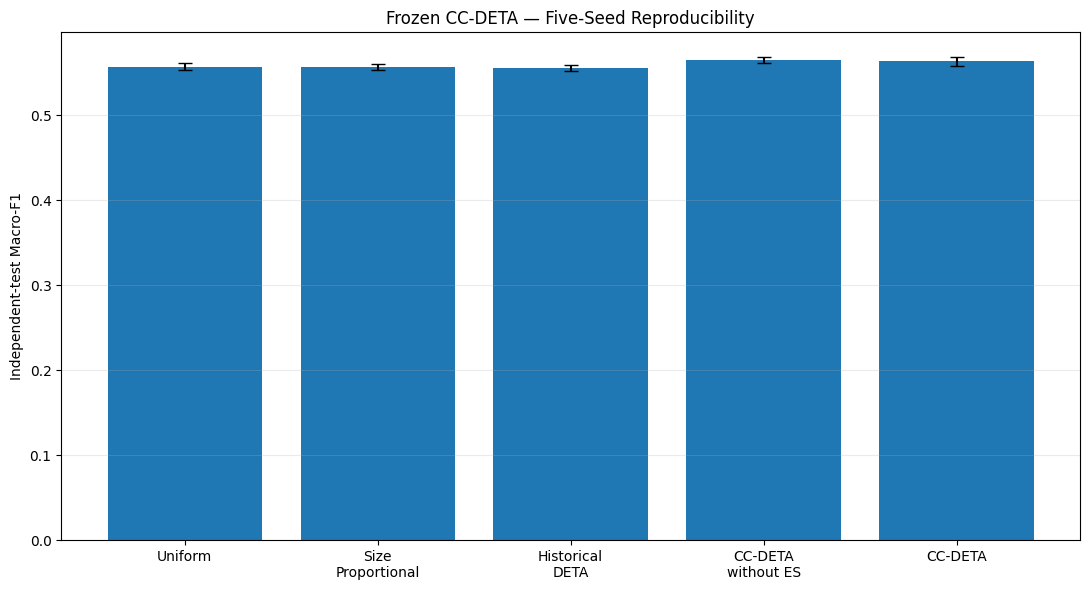

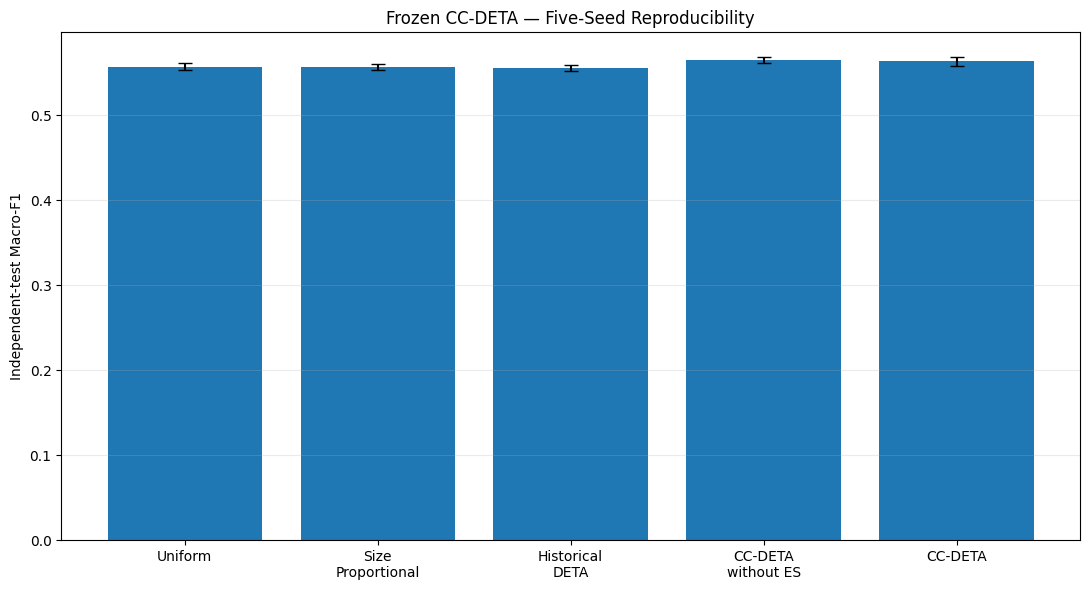

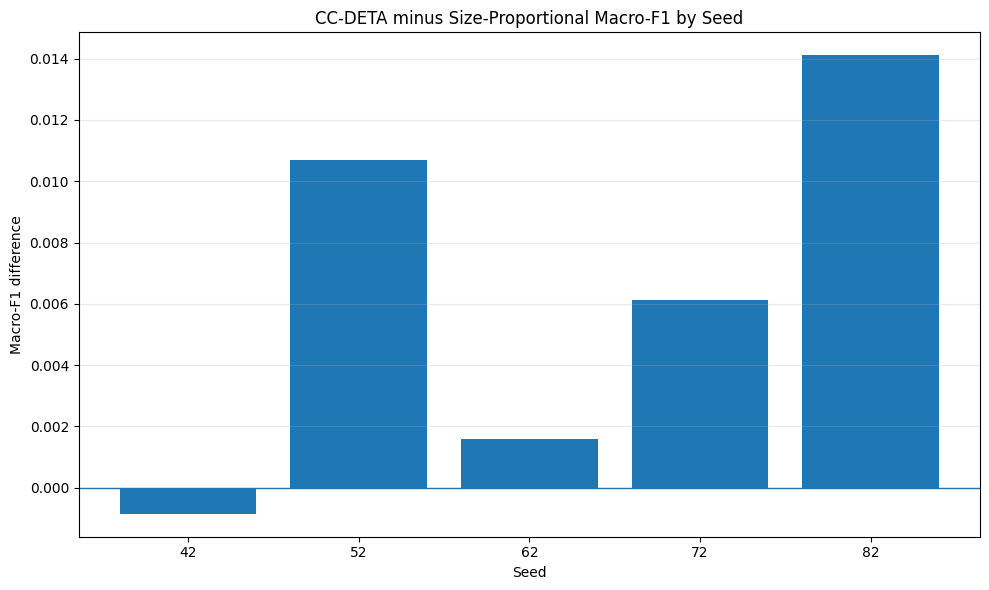

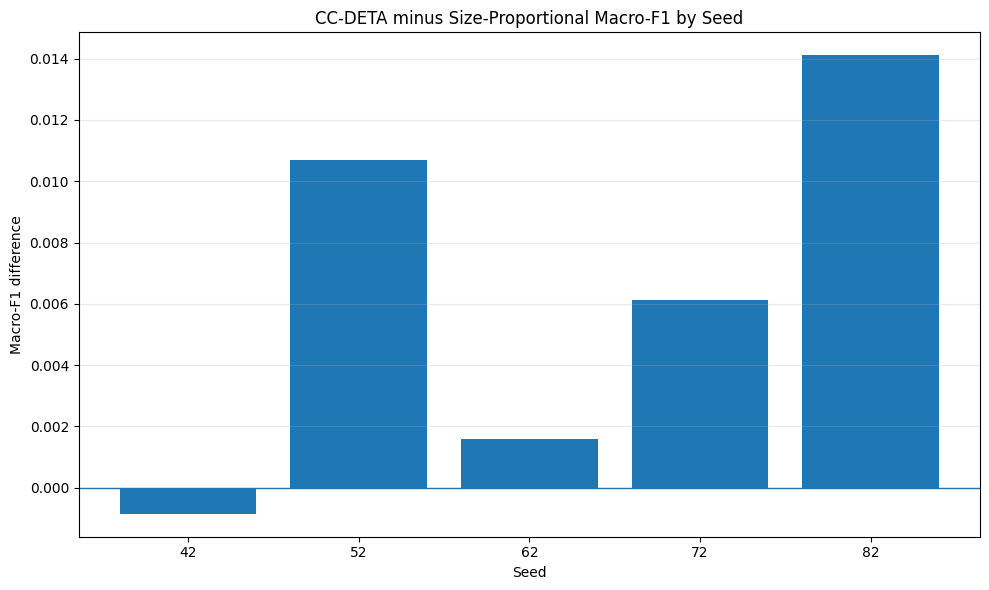

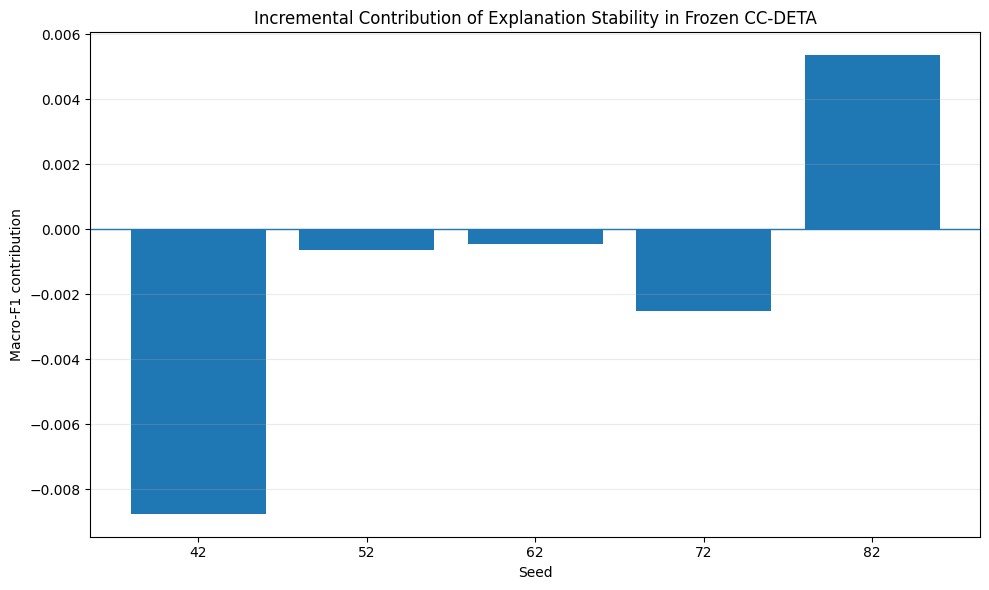

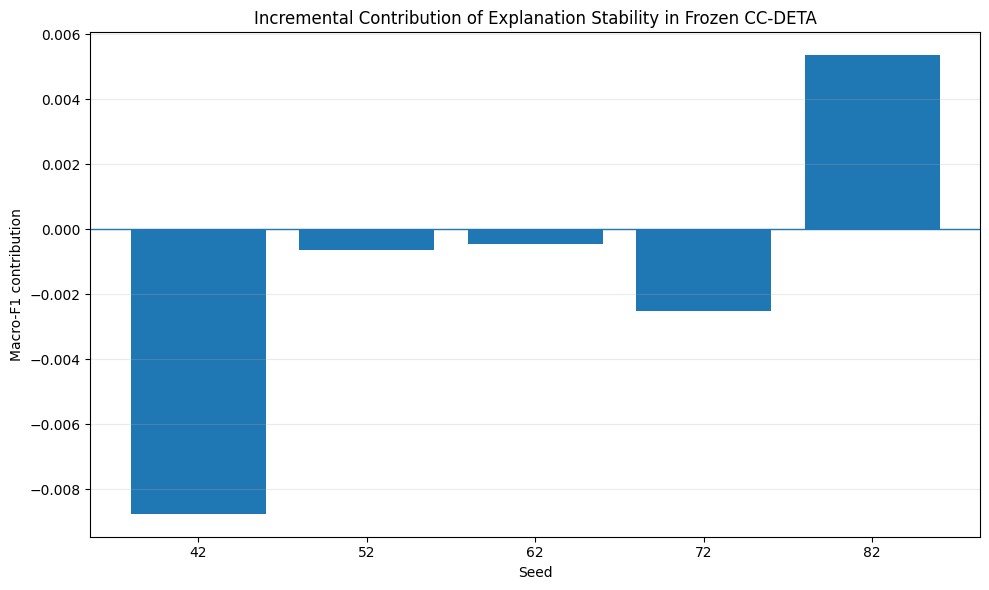


CELL 42 FINAL AUDIT

Frozen CC-DETA:
T_{i,c} = 0.100000*L_{i,c} + 0.750000*G_{i,c} + 0.050000*R_{i,c} + 0.100000*ES_i

w_{i,c} = T_{i,c}^4.000000 / sum_j(T_{j,c}^4.000000)

Pre-specified seeds: [42, 52, 62, 72, 82]

Five-seed Macro-F1:
Size proportional   : 0.556736 ± 0.003619
CC-DETA without ES  : 0.564461 ± 0.003699
CC-DETA             : 0.563065 ± 0.005762

Mean CC-DETA gain vs Size: +0.00632916
SD of gain vs Size: 0.00619909
CC-DETA beats Size on seeds: 4/5

Mean ES Macro-F1 increment: -0.00139626
SD of ES increment: 0.00505982
ES improves Macro-F1 on seeds: 1/5

Methodology audit:
Cell 40 SHA256 verified       : YES
Frozen feature schema used    : YES
Frozen development medians    : YES
Evaluation-fitted preprocessing: NO
All five seeds retained       : YES
Seeds selected by results     : NO
CC coefficients changed       : NO
Tau changed                   : NO
CC coefficients reoptimized   : NO
Test-driven tuning            : NO
Client models retrained       : YES — per predeterm

In [ ]:
# CELL 42 — FIVE-SEED FROZEN CC-DETA REPRODUCIBILITY
#            ROBUST PREPROCESSING-ARTIFACT RECOVERY
#
# PURPOSE
# Final five-seed reproducibility analysis of the CC-DETA formulation
# selected and SHA256-frozen BEFORE the final independent-test evaluation.
#
# PRE-SPECIFIED SEEDS:
#
#   [42, 52, 62, 72, 82]
#
# FINAL FROZEN CC-DETA:
#
#   T_{i,c} =
#       0.10 * L_{i,c}
#     + 0.75 * G_{i,c}
#     + 0.05 * R_{i,c}
#     + 0.10 * ES_i
#
#                     T_{i,c} ^ 4
#   w_{i,c} = --------------------------------
#              sum_j T_{j,c} ^ 4
#
#   Q_c(x) = sum_i w_{i,c} P_i(c|x)
#
#                        Q_c(x)
#   P_CC-DETA(c|x) = --------------------
#                     sum_k Q_k(x)
#
# CELL 40 CONFIGURATION SHA256:
#
#   4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
#

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import json
import time
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from scipy.stats import spearmanr

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    log_loss
)

from xgboost import XGBClassifier

from IPython.display import display, Markdown


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 400)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:.8f}"
)


print("=" * 145)
print("CELL 42 — FIVE-SEED FROZEN CC-DETA REPRODUCIBILITY")
print("=" * 145)


# 1. GLOBAL CONSTANTS

SEEDS = [
    42,
    52,
    62,
    72,
    82,
]

N_CLIENTS = 10
N_CLASSES = 34

LABEL_COL = "Label_Encoded"

LOCAL_VALIDATION_FRACTION = 0.20

SERVER_TRUST_FRACTION = 0.70

SERVER_SPLIT_SEED = 20260818

SHAP_SAMPLE_SIZE = 2000

SHAP_BATCH_SIZE = 250


# FINAL FROZEN CC-DETA PARAMETERS

CC_THETA_EXPECTED = np.array(
    [
        0.10,   # L_{i,c}
        0.75,   # G_{i,c}
        0.05,   # R_{i,c}
        0.10,   # ES_i
    ],
    dtype=np.float64
)

CC_TAU_EXPECTED = 4.0


EXPECTED_CC_SHA256 = (
    "4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b"
)


# Historical scalar DETA baseline
HISTORICAL_THETA = np.array(
    [
        0.20,
        0.40,
        0.30,
        0.10,
    ],
    dtype=np.float64
)


# FROZEN LOCAL XGBOOST CONFIGURATION

BASE_XGB_PARAMS = {

    "n_estimators":
        100,

    "max_depth":
        8,

    "learning_rate":
        0.10,

    "objective":
        "multi:softprob",

    "tree_method":
        "hist",

    "n_jobs":
        -1,

    "eval_metric":
        "mlogloss",
}


# 2. PATHS

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

MIXED_DIR = (
    ROOT /
    "10_noniid_experiments" /
    "mixed_reliability"
)

SERVER_PATH = (
    ROOT /
    "02_partitions" /
    "server_validation" /
    "server_validation_real_clean.parquet"
)

TEST_DIR = (
    ROOT /
    "02_partitions" /
    "independent_test"
)

TOP30_JSON = (
    ROOT /
    "15_reproducibility" /
    "historical_top30_features.json"
)

MEDIAN_PATH = (
    ROOT /
    "15_reproducibility" /
    "development_feature_medians.csv"
)

CC_CONFIG_PATH = (
    ROOT /
    "06_trust" /
    "class_conditional_DETA" /
    "CC_DETA_FROZEN_meta_validation_configuration.json"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

MULTISEED_DIR = (
    ROOT /
    "16_reviewer_multiseed" /
    "CC_DETA"
)

MODEL_SAVE_ROOT = (
    MULTISEED_DIR /
    "models"
)

SEED_ARTIFACT_ROOT = (
    MULTISEED_DIR /
    "seed_artifacts"
)


for directory in [
    TABLE_DIR,
    FIG_DIR,
    REPRO_DIR,
    MULTISEED_DIR,
    MODEL_SAVE_ROOT,
    SEED_ARTIFACT_ROOT,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


CLIENT_ROLES = {

    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",

    4: "NonIID_Reliable",
    5: "NonIID_Reliable",

    6: "LabelFlip",
    7: "LabelFlip",

    8: "Targeted_Poison",

    9: "SubsetClass_Reliable",
}


# 3. HELPER FUNCTIONS

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def normalize_rows(prob):

    prob = np.asarray(
        prob,
        dtype=np.float64
    )

    prob = np.clip(
        prob,
        1e-15,
        None
    )

    denominator = prob.sum(
        axis=1,
        keepdims=True
    )

    if np.any(
        denominator <= 0
    ):

        raise RuntimeError(
            "Probability normalization failure."
        )

    prob = (
        prob /
        denominator
    )

    if not np.isfinite(
        prob
    ).all():

        raise RuntimeError(
            "Non-finite probabilities after normalization."
        )

    return prob


def apply_frozen_medians(
    X,
    feature_names,
    median_map
):

    X = np.asarray(
        X,
        dtype=np.float32
    ).copy()


    for j, feature in enumerate(
        feature_names
    ):

        invalid = ~np.isfinite(
            X[
                :,
                j
            ]
        )

        if np.any(
            invalid
        ):

            X[
                invalid,
                j
            ] = float(
                median_map[
                    feature
                ]
            )


    if not np.isfinite(
        X
    ).all():

        raise RuntimeError(
            "Non-finite values remain after frozen preprocessing."
        )

    return X


def class_preserving_split(
    y,
    validation_fraction,
    seed
):

    y = np.asarray(
        y,
        dtype=np.int64
    )

    rng = np.random.default_rng(
        seed
    )

    train_parts = []
    validation_parts = []


    for class_id in np.sort(
        np.unique(
            y
        )
    ):

        idx = np.flatnonzero(
            y == class_id
        ).copy()

        rng.shuffle(
            idx
        )

        n = len(
            idx
        )


        # Singleton class:
        # training only.
        if n == 1:

            n_validation = 0

        else:

            n_validation = int(
                round(
                    validation_fraction
                    *
                    n
                )
            )

            n_validation = max(
                1,
                n_validation
            )

            n_validation = min(
                n_validation,
                n - 1
            )


        if n_validation > 0:

            validation_parts.append(
                idx[
                    :n_validation
                ]
            )


        train_parts.append(
            idx[
                n_validation:
            ]
        )


    train_idx = np.concatenate(
        train_parts
    ).astype(
        np.int64
    )


    if len(
        validation_parts
    ) > 0:

        validation_idx = np.concatenate(
            validation_parts
        ).astype(
            np.int64
        )

    else:

        validation_idx = np.array(
            [],
            dtype=np.int64
        )


    rng.shuffle(
        train_idx
    )

    rng.shuffle(
        validation_idx
    )


    if len(
        np.intersect1d(
            train_idx,
            validation_idx
        )
    ) != 0:

        raise RuntimeError(
            "Local train/validation overlap detected."
        )


    return (
        train_idx,
        validation_idx
    )


def singleton_safe_server_split(
    y,
    trust_fraction,
    seed
):

    y = np.asarray(
        y,
        dtype=np.int64
    )

    rng = np.random.default_rng(
        seed
    )

    trust_parts = []
    meta_parts = []

    audit_rows = []


    for class_id in np.sort(
        np.unique(
            y
        )
    ):

        idx = np.flatnonzero(
            y == class_id
        ).copy()

        rng.shuffle(
            idx
        )

        n = len(
            idx
        )


        if n == 1:

            trust_part = idx.copy()

            meta_part = np.array(
                [],
                dtype=np.int64
            )

            policy = "Singleton_Trust_Only"


        else:

            n_trust = int(
                round(
                    trust_fraction
                    *
                    n
                )
            )

            n_trust = max(
                1,
                n_trust
            )

            n_trust = min(
                n_trust,
                n - 1
            )


            trust_part = idx[
                :n_trust
            ]

            meta_part = idx[
                n_trust:
            ]

            policy = "Disjoint_Trust_Meta"


        trust_parts.append(
            trust_part
        )


        if len(
            meta_part
        ) > 0:

            meta_parts.append(
                meta_part
            )


        audit_rows.append({

            "Class_ID":
                int(
                    class_id
                ),

            "Total":
                int(
                    n
                ),

            "Trust":
                int(
                    len(
                        trust_part
                    )
                ),

            "Meta":
                int(
                    len(
                        meta_part
                    )
                ),

            "Policy":
                policy,
        })


    trust_idx = np.concatenate(
        trust_parts
    ).astype(
        np.int64
    )


    meta_idx = np.concatenate(
        meta_parts
    ).astype(
        np.int64
    )


    rng.shuffle(
        trust_idx
    )

    rng.shuffle(
        meta_idx
    )


    if len(
        np.intersect1d(
            trust_idx,
            meta_idx
        )
    ) != 0:

        raise RuntimeError(
            "Server trust/meta overlap detected."
        )


    coverage = np.concatenate(
        [
            trust_idx,
            meta_idx
        ]
    )


    if not np.array_equal(
        np.sort(
            coverage
        ),
        np.arange(
            len(
                y
            )
        )
    ):

        raise RuntimeError(
            "Server trust/meta coverage audit failed."
        )


    return (
        trust_idx,
        meta_idx,
        pd.DataFrame(
            audit_rows
        )
    )


def build_local_label_mapping(
    y_train_global
):

    local_to_global = np.sort(
        np.unique(
            y_train_global
        )
    ).astype(
        np.int32
    )


    global_to_local = {

        int(
            global_class
        ):
            local_class

        for local_class, global_class
        in enumerate(
            local_to_global
        )
    }


    return (
        local_to_global,
        global_to_local
    )


def encode_local_labels(
    y_global,
    global_to_local
):

    return np.asarray(
        [
            global_to_local[
                int(
                    value
                )
            ]
            for value in y_global
        ],
        dtype=np.int32
    )


def expand_probabilities(
    local_prob,
    local_to_global
):

    local_prob = np.asarray(
        local_prob,
        dtype=np.float64
    )


    global_prob = np.zeros(
        (
            local_prob.shape[
                0
            ],
            N_CLASSES
        ),
        dtype=np.float64
    )


    if local_prob.shape[
        1
    ] != len(
        local_to_global
    ):

        raise RuntimeError(
            f"Local probability columns "
            f"{local_prob.shape[1]} "
            f"do not match local classes "
            f"{len(local_to_global)}."
        )


    global_prob[
        :,
        local_to_global
    ] = local_prob


    return normalize_rows(
        global_prob
    )


def per_class_f1(
    y_true,
    y_pred
):

    return f1_score(
        y_true,
        y_pred,
        labels=np.arange(
            N_CLASSES
        ),
        average=None,
        zero_division=0
    ).astype(
        np.float64
    )


def per_class_recall(
    y_true,
    y_pred
):

    return recall_score(
        y_true,
        y_pred,
        labels=np.arange(
            N_CLASSES
        ),
        average=None,
        zero_division=0
    ).astype(
        np.float64
    )


def mean_absolute_tree_shap(
    booster,
    X,
    n_features,
    batch_size
):

    total_abs = np.zeros(
        n_features,
        dtype=np.float64
    )

    total_units = 0


    for start in range(
        0,
        len(
            X
        ),
        batch_size
    ):

        end = min(
            start
            +
            batch_size,
            len(
                X
            )
        )


        dm = xgb.DMatrix(
            X[
                start:end
            ]
        )


        contrib = np.asarray(
            booster.predict(
                dm,
                pred_contribs=True,
                validate_features=False
            )
        )


        if contrib.ndim == 3:

            values = contrib[
                ...,
                :-1
            ]

            total_abs += np.abs(
                values
            ).sum(
                axis=(
                    0,
                    1
                )
            )

            total_units += (
                values.shape[
                    0
                ]
                *
                values.shape[
                    1
                ]
            )


        elif contrib.ndim == 2:

            if (
                contrib.shape[
                    1
                ]
                ==
                n_features
                +
                1
            ):

                values = contrib[
                    :,
                    :-1
                ]

                total_abs += np.abs(
                    values
                ).sum(
                    axis=0
                )

                total_units += values.shape[
                    0
                ]


            elif (
                contrib.shape[
                    1
                ]
                %
                (
                    n_features
                    +
                    1
                )
                ==
                0
            ):

                inferred_classes = (
                    contrib.shape[
                        1
                    ]
                    //
                    (
                        n_features
                        +
                        1
                    )
                )


                values = contrib.reshape(
                    contrib.shape[
                        0
                    ],
                    inferred_classes,
                    n_features
                    +
                    1
                )[
                    ...,
                    :-1
                ]


                total_abs += np.abs(
                    values
                ).sum(
                    axis=(
                        0,
                        1
                    )
                )

                total_units += (
                    values.shape[
                        0
                    ]
                    *
                    values.shape[
                        1
                    ]
                )


            else:

                raise RuntimeError(
                    f"Unexpected TreeSHAP shape: "
                    f"{contrib.shape}"
                )


        else:

            raise RuntimeError(
                f"Unexpected TreeSHAP ndim: "
                f"{contrib.ndim}"
            )


        del dm
        del contrib

        gc.collect()


    if total_units <= 0:

        raise RuntimeError(
            "No valid TreeSHAP contribution units."
        )


    result = (
        total_abs /
        total_units
    )


    if not np.isfinite(
        result
    ).all():

        raise RuntimeError(
            "Non-finite TreeSHAP importance."
        )


    return result


def explanation_stability(
    importance_matrix
):

    importance_matrix = np.asarray(
        importance_matrix,
        dtype=np.float64
    )


    row_sums = importance_matrix.sum(
        axis=1,
        keepdims=True
    )


    if np.any(
        row_sums <= 0
    ):

        raise RuntimeError(
            "Invalid SHAP importance row."
        )


    importance_matrix = (
        importance_matrix /
        row_sums
    )


    consensus = importance_matrix.mean(
        axis=0
    )


    consensus = (
        consensus /
        consensus.sum()
    )


    consensus_rank = pd.Series(
        consensus
    ).rank(
        ascending=False,
        method="average"
    ).to_numpy()


    rho_values = []


    for i in range(
        importance_matrix.shape[
            0
        ]
    ):

        client_rank = pd.Series(
            importance_matrix[
                i
            ]
        ).rank(
            ascending=False,
            method="average"
        ).to_numpy()


        rho, _ = spearmanr(
            client_rank,
            consensus_rank
        )


        if not np.isfinite(
            rho
        ):

            raise RuntimeError(
                f"Non-finite Spearman rho for client {i}."
            )


        rho_values.append(
            float(
                rho
            )
        )


    rho_values = np.asarray(
        rho_values,
        dtype=np.float64
    )


    if np.isclose(
        rho_values.min(),
        rho_values.max()
    ):

        ES = np.ones_like(
            rho_values
        )


    else:

        ES = (
            rho_values
            -
            rho_values.min()
        ) / (
            rho_values.max()
            -
            rho_values.min()
        )


    return (
        rho_values,
        ES
    )


def cc_weights(
    L_class,
    G_class,
    R_class,
    ES,
    theta,
    tau
):

    theta = np.asarray(
        theta,
        dtype=np.float64
    )


    if not np.isclose(
        theta.sum(),
        1.0,
        atol=1e-12
    ):

        raise RuntimeError(
            "CC-DETA coefficient sum != 1."
        )


    T = (
        theta[
            0
        ]
        *
        L_class

        +

        theta[
            1
        ]
        *
        G_class

        +

        theta[
            2
        ]
        *
        R_class

        +

        theta[
            3
        ]
        *
        ES[
            :,
            None
        ]
    )


    T = np.clip(
        T,
        1e-12,
        None
    )


    powered = np.power(
        T,
        tau
    )


    W = (
        powered
        /
        powered.sum(
            axis=0,
            keepdims=True
        )
    )


    if not np.allclose(
        W.sum(
            axis=0
        ),
        1.0,
        atol=1e-10
    ):

        raise RuntimeError(
            "CC-DETA class-specific weight normalization failed."
        )


    return (
        T,
        W
    )


def cc_aggregate(
    prob_stack,
    class_weights
):

    raw = np.sum(
        prob_stack
        *
        class_weights[
            :,
            None,
            :
        ],
        axis=0
    )


    return normalize_rows(
        raw
    )


def scalar_aggregate(
    prob_stack,
    weights
):

    weights = np.asarray(
        weights,
        dtype=np.float64
    )


    if np.any(
        weights < 0
    ):

        raise RuntimeError(
            "Negative scalar aggregation weight."
        )


    if weights.sum() <= 0:

        raise RuntimeError(
            "Invalid scalar aggregation weights."
        )


    weights = (
        weights /
        weights.sum()
    )


    raw = np.tensordot(
        weights,
        prob_stack,
        axes=(
            0,
            0
        )
    )


    return normalize_rows(
        raw
    )


def evaluate(
    y_true,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    labels=np.arange(
                        N_CLASSES
                    ),
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    average="weighted",
                    zero_division=0
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    y_true,
                    pred
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_true,
                    prob,
                    labels=np.arange(
                        N_CLASSES
                    )
                )
            ),
    }


# 4. FINAL CC-DETA FREEZE VERIFICATION

print("\n" + "=" * 145)
print("FINAL CC-DETA FREEZE VERIFICATION")
print("=" * 145)


if not CC_CONFIG_PATH.exists():

    raise FileNotFoundError(
        CC_CONFIG_PATH
    )


actual_sha = sha256_file(
    CC_CONFIG_PATH
)


print(
    "Expected SHA256:",
    EXPECTED_CC_SHA256
)

print(
    "Actual SHA256  :",
    actual_sha
)


if actual_sha != EXPECTED_CC_SHA256:

    raise RuntimeError(
        "\nCC-DETA Cell 40 configuration hash mismatch.\n"
        "Do NOT continue reproducibility evaluation."
    )


with open(
    CC_CONFIG_PATH,
    "r"
) as f:

    frozen_config = json.load(
        f
    )


selected = frozen_config[
    "selected_parameters"
]


CC_THETA = np.array(
    [
        selected[
            "alpha_local_class_F1"
        ],

        selected[
            "beta_server_class_F1"
        ],

        selected[
            "gamma_server_class_recall"
        ],

        selected[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


CC_TAU = float(
    selected[
        "tau"
    ]
)


if not np.allclose(
    CC_THETA,
    CC_THETA_EXPECTED,
    atol=1e-12
):

    raise RuntimeError(
        f"Frozen CC-DETA theta mismatch.\n"
        f"Expected: {CC_THETA_EXPECTED}\n"
        f"Found   : {CC_THETA}"
    )


if not np.isclose(
    CC_TAU,
    CC_TAU_EXPECTED,
    atol=1e-12
):

    raise RuntimeError(
        f"Frozen CC-DETA tau mismatch.\n"
        f"Expected: {CC_TAU_EXPECTED}\n"
        f"Found   : {CC_TAU}"
    )


print(
    "Frozen CC-DETA parameter verification: PASSED"
)


# 5. FROZEN FEATURES + ROBUST DEVELOPMENT-MEDIAN RECOVERY

print("\n" + "=" * 145)
print("FROZEN FEATURE / PREPROCESSING RECOVERY")
print("=" * 145)


# 5A. Recover exact frozen Top-30 feature schema

if not TOP30_JSON.exists():

    raise FileNotFoundError(
        TOP30_JSON
    )


with open(
    TOP30_JSON,
    "r"
) as f:

    feature_obj = json.load(
        f
    )


FEATURES = None


if isinstance(
    feature_obj,
    list
):

    FEATURES = feature_obj


elif isinstance(
    feature_obj,
    dict
):

    for key in [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
        "Top30",
        "top_30_features",
    ]:

        if (
            key in feature_obj
            and
            isinstance(
                feature_obj[
                    key
                ],
                list
            )
            and
            len(
                feature_obj[
                    key
                ]
            )
            ==
            30
        ):

            FEATURES = feature_obj[
                key
            ]

            break


if FEATURES is None:

    raise RuntimeError(
        "Unable to recover frozen Top-30 feature schema."
    )


FEATURES = [
    str(
        feature
    ).strip()
    for feature in FEATURES
]


if len(
    FEATURES
) != 30:

    raise RuntimeError(
        f"Expected 30 frozen features, "
        f"found {len(FEATURES)}."
    )


if len(
    set(
        FEATURES
    )
) != 30:

    raise RuntimeError(
        "Duplicate features in frozen Top-30 schema."
    )


print(
    "Frozen Top-30 feature schema: PASSED"
)

print(
    "Feature count:",
    len(
        FEATURES
    )
)


# 5B. Read existing development median artifact

if not MEDIAN_PATH.exists():

    raise FileNotFoundError(
        f"Frozen development median artifact missing:\n"
        f"{MEDIAN_PATH}"
    )


median_df = pd.read_csv(
    MEDIAN_PATH
)


print(
    "\nMedian artifact:",
    MEDIAN_PATH
)

print(
    "Median artifact shape:",
    median_df.shape
)

print(
    "Median artifact columns:",
    median_df.columns.tolist()
)


# 5C. Decode existing artifact without calculating any new statistics

MEDIAN_MAP = None

MEDIAN_FORMAT = None


lower_to_original = {

    str(
        column
    ).strip().lower():
        column

    for column
    in median_df.columns
}


# FORMAT 1:
#
# Feature | Median

feature_column_candidates = [
    "feature",
    "feature_name",
    "features",
    "column",
    "column_name",
    "variable",
    "name",
]


median_column_candidates = [
    "median",
    "median_value",
    "development_median",
    "train_median",
    "feature_median",
    "value",
]


feature_col = None

median_col = None


for candidate in feature_column_candidates:

    if candidate in lower_to_original:

        feature_col = lower_to_original[
            candidate
        ]

        break


for candidate in median_column_candidates:

    if candidate in lower_to_original:

        median_col = lower_to_original[
            candidate
        ]

        break


if (
    feature_col is not None
    and
    median_col is not None
):

    candidate_map = {}


    for _, row in median_df.iterrows():

        feature_name = str(
            row[
                feature_col
            ]
        ).strip()


        try:

            value = float(
                row[
                    median_col
                ]
            )

        except Exception:

            continue


        candidate_map[
            feature_name
        ] = value


    if all(
        feature in candidate_map
        for feature in FEATURES
    ):

        MEDIAN_MAP = {

            feature:
                candidate_map[
                    feature
                ]

            for feature in FEATURES
        }


        MEDIAN_FORMAT = (
            f"long format: "
            f"{feature_col} / {median_col}"
        )


# FORMAT 2:
#
# Wide format where each feature is a column.

if MEDIAN_MAP is None:

    if all(
        feature in median_df.columns
        for feature in FEATURES
    ):

        if len(
            median_df
        ) < 1:

            raise RuntimeError(
                "Median artifact contains feature columns but no rows."
            )


        candidate_map = {}


        for feature in FEATURES:

            try:

                candidate_map[
                    feature
                ] = float(
                    median_df[
                        feature
                    ].iloc[
                        0
                    ]
                )

            except Exception:

                candidate_map = {}

                break


        if len(
            candidate_map
        ) == len(
            FEATURES
        ):

            MEDIAN_MAP = candidate_map

            MEDIAN_FORMAT = (
                "wide one-row format"
            )


# FORMAT 3:
#
# pandas Series/index export, e.g.
#
# Unnamed: 0 | 0
# Protocol Type |
# UDP           |

if (
    MEDIAN_MAP is None
    and
    median_df.shape[
        1
    ]
    >=
    2
):

    first_col = median_df.columns[
        0
    ]


    first_values = (
        median_df[
            first_col
        ]
        .astype(
            str
        )
        .str.strip()
    )


    overlap = set(
        first_values.tolist()
    ).intersection(
        set(
            FEATURES
        )
    )


    if len(
        overlap
    ) >= 20:

        best_value_col = None

        best_numeric_count = -1


        for column in median_df.columns[
            1:
        ]:

            numeric_values = pd.to_numeric(
                median_df[
                    column
                ],
                errors="coerce"
            )


            numeric_count = int(
                numeric_values.notna().sum()
            )


            if numeric_count > best_numeric_count:

                best_numeric_count = numeric_count

                best_value_col = column


        if best_value_col is not None:

            candidate_map = {}


            for _, row in median_df.iterrows():

                feature_name = str(
                    row[
                        first_col
                    ]
                ).strip()


                if feature_name not in FEATURES:

                    continue


                try:

                    value = float(
                        row[
                            best_value_col
                        ]
                    )

                except Exception:

                    continue


                candidate_map[
                    feature_name
                ] = value


            if all(
                feature in candidate_map
                for feature in FEATURES
            ):

                MEDIAN_MAP = {

                    feature:
                        candidate_map[
                            feature
                        ]

                    for feature in FEATURES
                }


                MEDIAN_FORMAT = (
                    f"pandas Series/index export: "
                    f"{first_col} / {best_value_col}"
                )


# FORMAT 4:
#
# Generic two-column indexed table.

if (
    MEDIAN_MAP is None
    and
    median_df.shape[
        1
    ]
    ==
    2
):

    first_col = median_df.columns[
        0
    ]

    second_col = median_df.columns[
        1
    ]


    candidate_map = {}


    for _, row in median_df.iterrows():

        feature_name = str(
            row[
                first_col
            ]
        ).strip()


        if feature_name not in FEATURES:

            continue


        try:

            value = float(
                row[
                    second_col
                ]
            )

        except Exception:

            continue


        candidate_map[
            feature_name
        ] = value


    if all(
        feature in candidate_map
        for feature in FEATURES
    ):

        MEDIAN_MAP = {

            feature:
                candidate_map[
                    feature
                ]

            for feature in FEATURES
        }


        MEDIAN_FORMAT = (
            "generic two-column index/value format"
        )


# FORMAT 5:
#
# Sometimes pandas export preserves feature names as the DataFrame index
# but creates an unnamed first column after CSV loading.

if MEDIAN_MAP is None:

    unnamed_columns = [
        column
        for column in median_df.columns
        if str(
            column
        ).lower().startswith(
            "unnamed"
        )
    ]


    for index_col in unnamed_columns:

        values = (
            median_df[
                index_col
            ]
            .astype(
                str
            )
            .str.strip()
        )


        overlap = set(
            values.tolist()
        ).intersection(
            set(
                FEATURES
            )
        )


        if len(
            overlap
        ) < 20:

            continue


        for value_col in median_df.columns:

            if value_col == index_col:

                continue


            numeric = pd.to_numeric(
                median_df[
                    value_col
                ],
                errors="coerce"
            )


            if numeric.notna().sum() < 20:

                continue


            candidate_map = {}


            for row_index in range(
                len(
                    median_df
                )
            ):

                feature_name = str(
                    median_df[
                        index_col
                    ].iloc[
                        row_index
                    ]
                ).strip()


                if feature_name not in FEATURES:

                    continue


                value = pd.to_numeric(
                    pd.Series(
                        [
                            median_df[
                                value_col
                            ].iloc[
                                row_index
                            ]
                        ]
                    ),
                    errors="coerce"
                ).iloc[
                    0
                ]


                if pd.isna(
                    value
                ):

                    continue


                candidate_map[
                    feature_name
                ] = float(
                    value
                )


            if all(
                feature in candidate_map
                for feature in FEATURES
            ):

                MEDIAN_MAP = {

                    feature:
                        candidate_map[
                            feature
                        ]

                    for feature in FEATURES
                }


                MEDIAN_FORMAT = (
                    f"unnamed-index export: "
                    f"{index_col} / {value_col}"
                )

                break


        if MEDIAN_MAP is not None:

            break


# FINAL PREPROCESSING ARTIFACT AUDIT

if MEDIAN_MAP is None:

    print(
        "\nUnable to decode frozen median artifact."
    )

    print(
        "\nArtifact preview:"
    )

    display(
        median_df.head(
            40
        )
    )


    raise RuntimeError(
        "\nUnable to decode the EXISTING frozen development medians safely.\n"
        "No new medians were calculated.\n"
        "Do not replace these using server/test statistics."
    )


missing_medians = [

    feature

    for feature in FEATURES

    if feature not in MEDIAN_MAP
]


if missing_medians:

    raise RuntimeError(
        f"Missing frozen medians after recovery: "
        f"{missing_medians}"
    )


nonfinite_medians = [

    feature

    for feature in FEATURES

    if not np.isfinite(
        MEDIAN_MAP[
            feature
        ]
    )
]


if nonfinite_medians:

    raise RuntimeError(
        f"Non-finite frozen medians: "
        f"{nonfinite_medians}"
    )


MEDIAN_MAP = {

    feature:
        float(
            MEDIAN_MAP[
                feature
            ]
        )

    for feature in FEATURES
}


median_audit_df = pd.DataFrame({

    "Feature":
        FEATURES,

    "Frozen_Median":
        [
            MEDIAN_MAP[
                feature
            ]
            for feature in FEATURES
        ]
})


print(
    "\nFrozen preprocessing recovery: PASSED"
)

print(
    "Detected artifact format:",
    MEDIAN_FORMAT
)

print(
    "Frozen feature count:",
    len(
        FEATURES
    )
)

print(
    "Frozen median count :",
    len(
        MEDIAN_MAP
    )
)


display(
    median_audit_df
)


print(
    "\nPREPROCESSING SAFETY AUDIT"
)

print(
    "New medians calculated       : NO"
)

print(
    "Independent test used        : NO"
)

print(
    "Server validation used       : NO"
)

print(
    "Client data used for medians : NO"
)

print(
    "Existing development artifact: YES"
)


# 6. LOAD SERVER VALIDATION + FIXED SINGLETON-SAFE TRUST SUBSET

print("\n" + "=" * 145)
print("FIXED SERVER TRUST SUBSET")
print("=" * 145)


server_df = pd.read_parquet(
    SERVER_PATH,
    columns=FEATURES + [LABEL_COL]
)


X_server = apply_frozen_medians(

    server_df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    ),

    FEATURES,

    MEDIAN_MAP
)


y_server = server_df[
    LABEL_COL
].to_numpy(
    dtype=np.int32
)


if len(
    np.unique(
        y_server
    )
) != N_CLASSES:

    raise RuntimeError(
        "Expected 34 classes in server validation."
    )


trust_idx, meta_idx, server_split_audit = singleton_safe_server_split(

    y=y_server,

    trust_fraction=SERVER_TRUST_FRACTION,

    seed=SERVER_SPLIT_SEED
)


X_trust = X_server[
    trust_idx
]


y_trust = y_server[
    trust_idx
]


singleton_classes = server_split_audit.loc[

    server_split_audit[
        "Policy"
    ]
    ==
    "Singleton_Trust_Only",

    "Class_ID"

].tolist()


print(
    "Server rows:",
    f"{len(y_server):,}"
)

print(
    "Trust rows :",
    f"{len(y_trust):,}"
)

print(
    "Meta rows  :",
    f"{len(meta_idx):,}"
)

print(
    "Trust classes:",
    len(
        np.unique(
            y_trust
        )
    )
)

print(
    "Trust-only singleton classes:",
    singleton_classes
)


display(
    server_split_audit
)


# 7. FIXED TRUST-SUBSET SHAP SAMPLE

print("\n" + "=" * 145)
print("FIXED TRUST-SUBSET SHAP SAMPLE")
print("=" * 145)


rng_shap = np.random.default_rng(
    SERVER_SPLIT_SEED
    +
    707
)


shap_indices = []


for class_id in np.sort(
    np.unique(
        y_trust
    )
):

    class_positions = np.flatnonzero(
        y_trust
        ==
        class_id
    )


    quota = max(
        1,
        int(
            round(
                SHAP_SAMPLE_SIZE
                *
                len(
                    class_positions
                )
                /
                len(
                    y_trust
                )
            )
        )
    )


    quota = min(
        quota,
        len(
            class_positions
        )
    )


    selected_positions = rng_shap.choice(
        class_positions,
        size=quota,
        replace=False
    )


    shap_indices.extend(
        selected_positions.tolist()
    )


shap_indices = np.asarray(
    sorted(
        set(
            shap_indices
        )
    ),
    dtype=np.int64
)


# Preserve at least one example from every trust-represented class.
if len(
    shap_indices
) > SHAP_SAMPLE_SIZE:

    mandatory = []


    for class_id in np.sort(
        np.unique(
            y_trust
        )
    ):

        candidates = shap_indices[
            y_trust[
                shap_indices
            ]
            ==
            class_id
        ]


        if len(
            candidates
        ) > 0:

            mandatory.append(
                candidates[
                    0
                ]
            )


    mandatory = np.asarray(
        mandatory,
        dtype=np.int64
    )


    remaining_pool = np.setdiff1d(
        shap_indices,
        mandatory
    )


    required_extra = (
        SHAP_SAMPLE_SIZE
        -
        len(
            mandatory
        )
    )


    extra = rng_shap.choice(
        remaining_pool,
        size=required_extra,
        replace=False
    )


    shap_indices = np.concatenate(
        [
            mandatory,
            extra
        ]
    )


elif len(
    shap_indices
) < SHAP_SAMPLE_SIZE:

    remaining_pool = np.setdiff1d(
        np.arange(
            len(
                y_trust
            )
        ),
        shap_indices
    )


    required_extra = (
        SHAP_SAMPLE_SIZE
        -
        len(
            shap_indices
        )
    )


    extra = rng_shap.choice(
        remaining_pool,
        size=required_extra,
        replace=False
    )


    shap_indices = np.concatenate(
        [
            shap_indices,
            extra
        ]
    )


X_shap = X_trust[
    shap_indices
]


y_shap = y_trust[
    shap_indices
]


print(
    "SHAP rows:",
    len(
        X_shap
    )
)

print(
    "SHAP classes represented:",
    len(
        np.unique(
            y_shap
        )
    )
)


# 8. LOAD LOCKED INDEPENDENT TEST

print("\n" + "=" * 145)
print("FINAL REPRODUCIBILITY TEST DATA")
print("=" * 145)


TEST_CANDIDATES = [

    TEST_DIR /
    "independent_test_real_clean_LOCKED.parquet",

    TEST_DIR /
    "independent_test_real_clean.parquet",
]


TEST_PATH = None


for candidate in TEST_CANDIDATES:

    if candidate.exists():

        TEST_PATH = candidate

        break


if TEST_PATH is None:

    raise FileNotFoundError(
        "\nUnable to resolve independent-test dataset."
    )


print(
    "Independent test:",
    TEST_PATH
)


test_df = pd.read_parquet(
    TEST_PATH,
    columns=FEATURES + [LABEL_COL]
)


X_test = apply_frozen_medians(

    test_df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    ),

    FEATURES,

    MEDIAN_MAP
)


y_test = test_df[
    LABEL_COL
].to_numpy(
    dtype=np.int32
)


if len(
    np.unique(
        y_test
    )
) != N_CLASSES:

    raise RuntimeError(
        "Expected all 34 independent-test classes."
    )


print(
    "Rows   :",
    f"{len(y_test):,}"
)

print(
    "Classes:",
    len(
        np.unique(
            y_test
        )
    )
)


# 9. LOAD MIXED-RELIABILITY CLIENT DATA ONCE

print("\n" + "=" * 145)
print("MIXED-RELIABILITY CLIENT DATA")
print("=" * 145)


CLIENT_DATA = {}


for client_id in range(
    N_CLIENTS
):

    path = (
        MIXED_DIR /
        f"client_{client_id:02d}_mixed.parquet"
    )


    if not path.exists():

        raise FileNotFoundError(
            path
        )


    df = pd.read_parquet(
        path,
        columns=FEATURES + [LABEL_COL]
    )


    X_client = apply_frozen_medians(

        df[
            FEATURES
        ].to_numpy(
            dtype=np.float32
        ),

        FEATURES,

        MEDIAN_MAP
    )


    y_client = df[
        LABEL_COL
    ].to_numpy(
        dtype=np.int32
    )


    CLIENT_DATA[
        client_id
    ] = (
        X_client,
        y_client
    )


    print(
        f"Client {client_id:02d} "
        f"({CLIENT_ROLES[client_id]}): "
        f"{len(y_client):,} rows"
    )


print(
    "\n10/10 mixed-reliability clients loaded: PASSED"
)


# 10. STORAGE FOR ALL FIVE SEEDS

all_metric_rows = []

all_component_rows = []

all_weight_rows = []

all_timing_rows = []

all_model_hash_rows = []

all_training_size_rows = []


# 11. FIVE-SEED LOOP

for seed_position, seed in enumerate(
    SEEDS,
    start=1
):

    print("\n" + "#" * 145)

    print(
        f"SEED {seed_position}/{len(SEEDS)} — {seed}"
    )

    print("#" * 145)


    seed_total_start = time.perf_counter()


    seed_model_dir = (
        MODEL_SAVE_ROOT /
        f"seed_{seed}"
    )


    seed_artifact_dir = (
        SEED_ARTIFACT_ROOT /
        f"seed_{seed}"
    )


    seed_model_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    seed_artifact_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    models = {}

    local_to_global_maps = {}


    L_CLASS = np.zeros(
        (
            N_CLIENTS,
            N_CLASSES
        ),
        dtype=np.float64
    )


    L_SCALAR = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )


    training_rows_seed = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )


    train_seconds = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )


    # 11A. LOCAL MODEL RECONSTRUCTION

    print("\n" + "=" * 145)

    print(
        f"SEED {seed} — LOCAL MODEL RECONSTRUCTION"
    )

    print("=" * 145)


    for client_id in range(
        N_CLIENTS
    ):

        X_local, y_local = CLIENT_DATA[
            client_id
        ]


        train_idx_local, val_idx_local = class_preserving_split(

            y=y_local,

            validation_fraction=LOCAL_VALIDATION_FRACTION,

            seed=(
                seed
                +
                client_id
            )
        )


        training_rows_seed[
            client_id
        ] = len(
            train_idx_local
        )


        X_train = X_local[
            train_idx_local
        ]


        y_train_global = y_local[
            train_idx_local
        ]


        X_val = X_local[
            val_idx_local
        ]


        y_val_global = y_local[
            val_idx_local
        ]


        (
            local_to_global,
            global_to_local

        ) = build_local_label_mapping(
            y_train_global
        )


        y_train_local = encode_local_labels(
            y_train_global,
            global_to_local
        )


        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train_local
        )


        model_params = BASE_XGB_PARAMS.copy()


        model_params[
            "random_state"
        ] = seed


        model_params[
            "num_class"
        ] = len(
            local_to_global
        )


        model = XGBClassifier(
            **model_params
        )


        training_start = time.perf_counter()


        model.fit(
            X_train,
            y_train_local,
            sample_weight=sample_weights,
            verbose=False
        )


        train_seconds[
            client_id
        ] = (
            time.perf_counter()
            -
            training_start
        )


        local_prob = model.predict_proba(
            X_val
        )


        global_prob = expand_probabilities(
            local_prob,
            local_to_global
        )


        val_pred = np.argmax(
            global_prob,
            axis=1
        )


        L_CLASS[
            client_id
        ] = per_class_f1(
            y_val_global,
            val_pred
        )


        represented_validation_classes = np.sort(
            np.unique(
                y_val_global
            )
        )


        L_SCALAR[
            client_id
        ] = f1_score(
            y_val_global,
            val_pred,
            labels=represented_validation_classes,
            average="macro",
            zero_division=0
        )


        models[
            client_id
        ] = model


        local_to_global_maps[
            client_id
        ] = local_to_global


        model_path = (
            seed_model_dir /
            f"client_{client_id:02d}_xgb.json"
        )


        model.save_model(
            model_path
        )


        model_sha = sha256_file(
            model_path
        )


        all_model_hash_rows.append({

            "Seed":
                seed,

            "Client_ID":
                client_id,

            "Role":
                CLIENT_ROLES[
                    client_id
                ],

            "Model_Path":
                str(
                    model_path
                ),

            "SHA256":
                model_sha,
        })


        all_training_size_rows.append({

            "Seed":
                seed,

            "Client_ID":
                client_id,

            "Role":
                CLIENT_ROLES[
                    client_id
                ],

            "Total_Client_Rows":
                int(
                    len(
                        y_local
                    )
                ),

            "Training_Rows":
                int(
                    len(
                        train_idx_local
                    )
                ),

            "Validation_Rows":
                int(
                    len(
                        val_idx_local
                    )
                ),
        })


        print(
            f"Client {client_id:02d} | "
            f"Role={CLIENT_ROLES[client_id]:<22} | "
            f"TrainRows={len(train_idx_local):>6} | "
            f"L_i={L_SCALAR[client_id]:.6f} | "
            f"train={train_seconds[client_id]:.2f}s"
        )


        del X_train
        del y_train_global
        del X_val
        del y_val_global
        del local_prob
        del global_prob
        del val_pred
        del sample_weights

        gc.collect()


    # Actual size-proportional weights for THIS local training realization.

    SIZE_WEIGHTS_SEED = (
        training_rows_seed
        /
        training_rows_seed.sum()
    )


    UNIFORM_WEIGHTS = np.repeat(
        1.0 /
        N_CLIENTS,
        N_CLIENTS
    )


    print(
        "\nSize-proportional weight sum:",
        f"{SIZE_WEIGHTS_SEED.sum():.12f}"
    )


    # 11B. SERVER TRUST-SUBSET PREDICTIONS

    print("\n" + "=" * 145)

    print(
        f"SEED {seed} — SERVER TRUST EVIDENCE"
    )

    print("=" * 145)


    G_CLASS = np.zeros(
        (
            N_CLIENTS,
            N_CLASSES
        ),
        dtype=np.float64
    )


    R_CLASS = np.zeros(
        (
            N_CLIENTS,
            N_CLASSES
        ),
        dtype=np.float64
    )


    G_SCALAR = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )


    B_SCALAR = np.zeros(
        N_CLIENTS,
        dtype=np.float64
    )


    server_inference_start = time.perf_counter()


    for client_id in range(
        N_CLIENTS
    ):

        model = models[
            client_id
        ]


        local_to_global = local_to_global_maps[
            client_id
        ]


        local_prob = model.predict_proba(
            X_trust
        )


        global_prob = expand_probabilities(
            local_prob,
            local_to_global
        )


        pred = np.argmax(
            global_prob,
            axis=1
        )


        G_CLASS[
            client_id
        ] = per_class_f1(
            y_trust,
            pred
        )


        R_CLASS[
            client_id
        ] = per_class_recall(
            y_trust,
            pred
        )


        G_SCALAR[
            client_id
        ] = f1_score(
            y_trust,
            pred,
            labels=np.arange(
                N_CLASSES
            ),
            average="macro",
            zero_division=0
        )


        B_SCALAR[
            client_id
        ] = balanced_accuracy_score(
            y_trust,
            pred
        )


        print(
            f"Client {client_id:02d} | "
            f"G_i={G_SCALAR[client_id]:.6f} | "
            f"B_i={B_SCALAR[client_id]:.6f}"
        )


        del local_prob
        del global_prob
        del pred

        gc.collect()


    SERVER_INFERENCE_SECONDS = (
        time.perf_counter()
        -
        server_inference_start
    )


    # 11C. SHAP EXPLANATION STABILITY

    print("\n" + "=" * 145)

    print(
        f"SEED {seed} — SHAP EXPLANATION STABILITY"
    )

    print("=" * 145)


    shap_stage_start = time.perf_counter()


    importance_vectors = []


    for client_id in range(
        N_CLIENTS
    ):

        client_shap_start = time.perf_counter()


        mean_abs = mean_absolute_tree_shap(

            booster=models[
                client_id
            ].get_booster(),

            X=X_shap,

            n_features=len(
                FEATURES
            ),

            batch_size=SHAP_BATCH_SIZE
        )


        importance_sum = mean_abs.sum()


        if importance_sum <= 0:

            raise RuntimeError(
                f"Client {client_id:02d}: "
                f"zero SHAP importance."
            )


        normalized_importance = (
            mean_abs /
            importance_sum
        )


        importance_vectors.append(
            normalized_importance
        )


        print(
            f"Client {client_id:02d} TreeSHAP: "
            f"{time.perf_counter() - client_shap_start:.2f}s"
        )


    importance_matrix = np.vstack(
        importance_vectors
    )


    RHO, ES = explanation_stability(
        importance_matrix
    )


    SHAP_SECONDS = (
        time.perf_counter()
        -
        shap_stage_start
    )


    print(
        "\nSHAP rho range:",
        f"{RHO.min():.6f}",
        "to",
        f"{RHO.max():.6f}"
    )


    print(
        "Historical ES range:",
        f"{ES.min():.6f}",
        "to",
        f"{ES.max():.6f}"
    )


    # 11D. FROZEN CC-DETA WEIGHTS

    CC_TRUST, CC_WEIGHTS = cc_weights(

        L_class=L_CLASS,

        G_class=G_CLASS,

        R_class=R_CLASS,

        ES=ES,

        theta=CC_THETA,

        tau=CC_TAU
    )


    # FROZEN no-ES counterfactual.
    # ES coefficient removed WITHOUT any reoptimization.
    # Remaining predictive coefficients are proportionally renormalized.

    NO_ES_THETA = CC_THETA.copy()


    NO_ES_THETA[
        3
    ] = 0.0


    NO_ES_THETA[
        :3
    ] = (
        NO_ES_THETA[
            :3
        ]
        /
        NO_ES_THETA[
            :3
        ].sum()
    )


    NO_ES_TRUST, NO_ES_WEIGHTS = cc_weights(

        L_class=L_CLASS,

        G_class=G_CLASS,

        R_class=R_CLASS,

        ES=ES,

        theta=NO_ES_THETA,

        tau=CC_TAU
    )


    # 11E. HISTORICAL SCALAR DETA BASELINE FOR THIS SEED

    HIST_COMPONENTS = np.column_stack(
        [
            L_SCALAR,
            G_SCALAR,
            B_SCALAR,
            ES,
        ]
    )


    HIST_T = (
        HIST_COMPONENTS
        @
        HISTORICAL_THETA
    )


    HIST_T = np.clip(
        HIST_T,
        1e-12,
        None
    )


    HIST_WEIGHTS = (
        HIST_T /
        HIST_T.sum()
    )


    # 11F. INDEPENDENT-TEST CLIENT INFERENCE

    print("\n" + "=" * 145)

    print(
        f"SEED {seed} — INDEPENDENT-TEST REPORTING"
    )

    print("=" * 145)


    test_inference_start = time.perf_counter()


    test_probabilities = []


    for client_id in range(
        N_CLIENTS
    ):

        local_prob = models[
            client_id
        ].predict_proba(
            X_test
        )


        global_prob = expand_probabilities(

            local_prob,

            local_to_global_maps[
                client_id
            ]
        )


        test_probabilities.append(
            global_prob.astype(
                np.float32
            )
        )


        print(
            f"Client {client_id:02d}: "
            f"{global_prob.shape} — PASSED"
        )


        del local_prob
        del global_prob

        gc.collect()


    PROB_TEST_SEED = np.stack(
        test_probabilities,
        axis=0
    )


    TEST_INFERENCE_SECONDS = (
        time.perf_counter()
        -
        test_inference_start
    )


    # 11G. FEDERATED AGGREGATION

    aggregation_start = time.perf_counter()


    METHOD_PROB = {

        "Uniform":
            scalar_aggregate(
                PROB_TEST_SEED,
                UNIFORM_WEIGHTS
            ),

        "Size_Proportional":
            scalar_aggregate(
                PROB_TEST_SEED,
                SIZE_WEIGHTS_SEED
            ),

        "Historical_DETA":
            scalar_aggregate(
                PROB_TEST_SEED,
                HIST_WEIGHTS
            ),

        "CC_DETA_without_ES":
            cc_aggregate(
                PROB_TEST_SEED,
                NO_ES_WEIGHTS
            ),

        "CC_DETA":
            cc_aggregate(
                PROB_TEST_SEED,
                CC_WEIGHTS
            ),
    }


    seed_metric_rows = []


    for method, probability in METHOD_PROB.items():

        metrics = evaluate(
            y_test,
            probability
        )


        result_row = {

            "Seed":
                seed,

            "Method":
                method,

            **metrics,
        }


        all_metric_rows.append(
            result_row
        )


        seed_metric_rows.append(
            result_row
        )


        print(
            f"{method:<22} | "
            f"Accuracy={metrics['Accuracy']:.6f} | "
            f"Balanced={metrics['Balanced_Accuracy']:.6f} | "
            f"Macro-F1={metrics['Macro_F1']:.6f} | "
            f"MCC={metrics['MCC']:.6f} | "
            f"LogLoss={metrics['Log_Loss']:.6f}"
        )


    AGGREGATION_SECONDS = (
        time.perf_counter()
        -
        aggregation_start
    )


    # 11H. STORE CLIENT / CLASS TRUST INFORMATION

    for client_id in range(
        N_CLIENTS
    ):

        all_component_rows.append({

            "Seed":
                seed,

            "Client_ID":
                client_id,

            "Role":
                CLIENT_ROLES[
                    client_id
                ],

            "L_i":
                L_SCALAR[
                    client_id
                ],

            "G_i":
                G_SCALAR[
                    client_id
                ],

            "B_i":
                B_SCALAR[
                    client_id
                ],

            "Spearman_Rho":
                RHO[
                    client_id
                ],

            "ES_i":
                ES[
                    client_id
                ],

            "Historical_T_i":
                HIST_T[
                    client_id
                ],

            "Historical_Weight":
                HIST_WEIGHTS[
                    client_id
                ],

            "CC_Mean_Trust":
                float(
                    CC_TRUST[
                        client_id
                    ].mean()
                ),

            "CC_Mean_Weight":
                float(
                    CC_WEIGHTS[
                        client_id
                    ].mean()
                ),

            "CC_Min_Weight":
                float(
                    CC_WEIGHTS[
                        client_id
                    ].min()
                ),

            "CC_Max_Weight":
                float(
                    CC_WEIGHTS[
                        client_id
                    ].max()
                ),
        })


        for class_id in range(
            N_CLASSES
        ):

            all_weight_rows.append({

                "Seed":
                    seed,

                "Client_ID":
                    client_id,

                "Role":
                    CLIENT_ROLES[
                        client_id
                    ],

                "Class_ID":
                    class_id,

                "L_ic":
                    L_CLASS[
                        client_id,
                        class_id
                    ],

                "G_ic":
                    G_CLASS[
                        client_id,
                        class_id
                    ],

                "R_ic":
                    R_CLASS[
                        client_id,
                        class_id
                    ],

                "ES_i":
                    ES[
                        client_id
                    ],

                "CC_Trust":
                    CC_TRUST[
                        client_id,
                        class_id
                    ],

                "CC_Weight":
                    CC_WEIGHTS[
                        client_id,
                        class_id
                    ],

                "CC_No_ES_Weight":
                    NO_ES_WEIGHTS[
                        client_id,
                        class_id
                    ],
            })


    TOTAL_SECONDS = (
        time.perf_counter()
        -
        seed_total_start
    )


    all_timing_rows.append({

        "Seed":
            seed,

        "Local_Training_Seconds":
            float(
                train_seconds.sum()
            ),

        "Server_Trust_Inference_Seconds":
            float(
                SERVER_INFERENCE_SECONDS
            ),

        "SHAP_Seconds":
            float(
                SHAP_SECONDS
            ),

        "Test_Inference_Seconds":
            float(
                TEST_INFERENCE_SECONDS
            ),

        "Aggregation_Evaluation_Seconds":
            float(
                AGGREGATION_SECONDS
            ),

        "Total_Seed_Seconds":
            float(
                TOTAL_SECONDS
            ),
    })


    # 11I. SAVE EACH SEED IMMEDIATELY

    pd.DataFrame(
        seed_metric_rows
    ).to_csv(
        seed_artifact_dir /
        "metrics.csv",
        index=False
    )


    pd.DataFrame({

        "Client_ID":
            np.arange(
                N_CLIENTS
            ),

        "Role":
            [
                CLIENT_ROLES[
                    i
                ]
                for i in range(
                    N_CLIENTS
                )
            ],

        "Training_Rows":
            training_rows_seed.astype(
                int
            ),

        "Size_Proportional_Weight":
            SIZE_WEIGHTS_SEED,

        "Historical_Weight":
            HIST_WEIGHTS,

        "ES_i":
            ES,

        "Spearman_Rho":
            RHO,

        "CC_Mean_Weight":
            CC_WEIGHTS.mean(
                axis=1
            ),

        "CC_Min_Weight":
            CC_WEIGHTS.min(
                axis=1
            ),

        "CC_Max_Weight":
            CC_WEIGHTS.max(
                axis=1
            ),

    }).to_csv(
        seed_artifact_dir /
        "client_summary.csv",
        index=False
    )


    np.save(
        seed_artifact_dir /
        "CC_weights.npy",
        CC_WEIGHTS
    )


    np.save(
        seed_artifact_dir /
        "CC_no_ES_weights.npy",
        NO_ES_WEIGHTS
    )


    print(
        f"\nSEED {seed} TOTAL RUNTIME: "
        f"{TOTAL_SECONDS:.2f}s"
    )


    print(
        f"Seed artifacts saved to:\n"
        f"{seed_artifact_dir}"
    )


    # Free heavy seed-specific objects.
    del models
    del importance_vectors
    del importance_matrix
    del test_probabilities
    del PROB_TEST_SEED
    del METHOD_PROB
    del CC_TRUST
    del CC_WEIGHTS
    del NO_ES_TRUST
    del NO_ES_WEIGHTS

    gc.collect()


# 12. FIVE-SEED INDIVIDUAL RESULTS

results_df = pd.DataFrame(
    all_metric_rows
)


method_order = [

    "Uniform",

    "Size_Proportional",

    "Historical_DETA",

    "CC_DETA_without_ES",

    "CC_DETA",
]


method_order_map = {

    method:
        index

    for index, method
    in enumerate(
        method_order
    )
}


results_df[
    "_Method_Order"
] = results_df[
    "Method"
].map(
    method_order_map
)


results_df = (
    results_df
    .sort_values(
        [
            "Seed",
            "_Method_Order"
        ]
    )
    .drop(
        columns=[
            "_Method_Order"
        ]
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 145)
print("FIVE-SEED INDIVIDUAL RESULTS")
print("=" * 145)


display(
    results_df
)


# 13. FIVE-SEED MEAN ± SAMPLE STANDARD DEVIATION

summary_rows = []


for method in method_order:

    subset = results_df.loc[
        results_df[
            "Method"
        ]
        ==
        method
    ].copy()


    if len(
        subset
    ) != len(
        SEEDS
    ):

        raise RuntimeError(
            f"{method}: expected {len(SEEDS)} seeds, "
            f"found {len(subset)}."
        )


    summary_row = {

        "Method":
            method,

        "Seeds":
            len(
                subset
            ),
    }


    for metric in [
        "Accuracy",
        "Balanced_Accuracy",
        "Macro_F1",
        "Weighted_F1",
        "MCC",
        "Log_Loss",
    ]:

        mean_value = float(
            subset[
                metric
            ].mean()
        )


        sd_value = float(
            subset[
                metric
            ].std(
                ddof=1
            )
        )


        summary_row[
            f"{metric}_Mean"
        ] = mean_value


        summary_row[
            f"{metric}_SD"
        ] = sd_value


        summary_row[
            f"{metric}_Mean_SD"
        ] = (
            f"{mean_value:.6f} ± "
            f"{sd_value:.6f}"
        )


    summary_rows.append(
        summary_row
    )


summary_df = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 145)
print("REVIEWER-READY FIVE-SEED MEAN ± SD")
print("=" * 145)


display(
    summary_df
)


# 14. MANUSCRIPT-READY TABLE

manuscript_df = summary_df[
    [
        "Method",
        "Accuracy_Mean_SD",
        "Balanced_Accuracy_Mean_SD",
        "Macro_F1_Mean_SD",
        "MCC_Mean_SD",
        "Log_Loss_Mean_SD",
    ]
].copy()


manuscript_df.columns = [

    "Method",

    "Accuracy",

    "Balanced_Accuracy",

    "Macro_F1",

    "MCC",

    "Log_Loss",
]


print("\n" + "=" * 145)
print("MANUSCRIPT-READY FIVE-SEED TABLE")
print("=" * 145)


display(
    manuscript_df
)


# 15. PER-SEED CC-DETA EFFECTS

delta_rows = []


for seed in SEEDS:

    seed_df = results_df.loc[
        results_df[
            "Seed"
        ]
        ==
        seed
    ]


    cc_row = seed_df.loc[
        seed_df[
            "Method"
        ]
        ==
        "CC_DETA"
    ].iloc[
        0
    ]


    size_row = seed_df.loc[
        seed_df[
            "Method"
        ]
        ==
        "Size_Proportional"
    ].iloc[
        0
    ]


    uniform_row = seed_df.loc[
        seed_df[
            "Method"
        ]
        ==
        "Uniform"
    ].iloc[
        0
    ]


    hist_row = seed_df.loc[
        seed_df[
            "Method"
        ]
        ==
        "Historical_DETA"
    ].iloc[
        0
    ]


    no_es_row = seed_df.loc[
        seed_df[
            "Method"
        ]
        ==
        "CC_DETA_without_ES"
    ].iloc[
        0
    ]


    delta_rows.append({

        "Seed":
            seed,

        "CC_minus_Size_Macro_F1":
            float(
                cc_row[
                    "Macro_F1"
                ]
                -
                size_row[
                    "Macro_F1"
                ]
            ),

        "CC_minus_Uniform_Macro_F1":
            float(
                cc_row[
                    "Macro_F1"
                ]
                -
                uniform_row[
                    "Macro_F1"
                ]
            ),

        "CC_minus_Historical_Macro_F1":
            float(
                cc_row[
                    "Macro_F1"
                ]
                -
                hist_row[
                    "Macro_F1"
                ]
            ),

        "ES_Increment_Macro_F1":
            float(
                cc_row[
                    "Macro_F1"
                ]
                -
                no_es_row[
                    "Macro_F1"
                ]
            ),

        "CC_minus_Size_Balanced_Accuracy":
            float(
                cc_row[
                    "Balanced_Accuracy"
                ]
                -
                size_row[
                    "Balanced_Accuracy"
                ]
            ),

        "CC_minus_Size_MCC":
            float(
                cc_row[
                    "MCC"
                ]
                -
                size_row[
                    "MCC"
                ]
            ),

        "CC_LogLoss_Improvement_vs_Size":
            float(
                size_row[
                    "Log_Loss"
                ]
                -
                cc_row[
                    "Log_Loss"
                ]
            ),
    })


delta_df = pd.DataFrame(
    delta_rows
)


print("\n" + "=" * 145)
print("PER-SEED CC-DETA EFFECTS")
print("=" * 145)


display(
    delta_df
)


CC_WIN_COUNT = int(
    (
        delta_df[
            "CC_minus_Size_Macro_F1"
        ]
        >
        0
    ).sum()
)


ES_WIN_COUNT = int(
    (
        delta_df[
            "ES_Increment_Macro_F1"
        ]
        >
        0
    ).sum()
)


print(
    "\nSeeds where CC-DETA beats Size-Proportional Macro-F1:",
    f"{CC_WIN_COUNT}/{len(SEEDS)}"
)


print(
    "Seeds where ES improves CC-DETA Macro-F1:",
    f"{ES_WIN_COUNT}/{len(SEEDS)}"
)


print(
    "\nMean CC-DETA Macro-F1 gain vs Size:",
    f"{delta_df['CC_minus_Size_Macro_F1'].mean():+.8f}"
)


print(
    "SD of CC-DETA Macro-F1 gain vs Size:",
    f"{delta_df['CC_minus_Size_Macro_F1'].std(ddof=1):.8f}"
)


print(
    "Mean ES Macro-F1 increment:",
    f"{delta_df['ES_Increment_Macro_F1'].mean():+.8f}"
)


print(
    "SD of ES Macro-F1 increment:",
    f"{delta_df['ES_Increment_Macro_F1'].std(ddof=1):.8f}"
)


# 16. CLIENT / TRUST STABILITY

component_df = pd.DataFrame(
    all_component_rows
)


class_weight_df = pd.DataFrame(
    all_weight_rows
)


training_size_df = pd.DataFrame(
    all_training_size_rows
)


component_summary_df = (
    component_df
    .groupby(
        [
            "Client_ID",
            "Role"
        ],
        as_index=False
    )
    .agg(

        L_i_Mean=(
            "L_i",
            "mean"
        ),

        L_i_SD=(
            "L_i",
            "std"
        ),

        G_i_Mean=(
            "G_i",
            "mean"
        ),

        G_i_SD=(
            "G_i",
            "std"
        ),

        B_i_Mean=(
            "B_i",
            "mean"
        ),

        B_i_SD=(
            "B_i",
            "std"
        ),

        ES_i_Mean=(
            "ES_i",
            "mean"
        ),

        ES_i_SD=(
            "ES_i",
            "std"
        ),

        CC_Mean_Weight_Mean=(
            "CC_Mean_Weight",
            "mean"
        ),

        CC_Mean_Weight_SD=(
            "CC_Mean_Weight",
            "std"
        ),

        CC_Min_Weight_Mean=(
            "CC_Min_Weight",
            "mean"
        ),

        CC_Max_Weight_Mean=(
            "CC_Max_Weight",
            "mean"
        )
    )
)


print("\n" + "=" * 145)
print("CC-DETA CLIENT TRUST / WEIGHT STABILITY")
print("=" * 145)


display(
    component_summary_df
)


# 17. WALL-CLOCK TIMING

timing_df = pd.DataFrame(
    all_timing_rows
)


timing_summary_rows = []


for column in [

    "Local_Training_Seconds",

    "Server_Trust_Inference_Seconds",

    "SHAP_Seconds",

    "Test_Inference_Seconds",

    "Aggregation_Evaluation_Seconds",

    "Total_Seed_Seconds",
]:

    timing_summary_rows.append({

        "Stage":
            column,

        "Mean_Seconds":
            float(
                timing_df[
                    column
                ].mean()
            ),

        "SD_Seconds":
            float(
                timing_df[
                    column
                ].std(
                    ddof=1
                )
            ),

        "Min_Seconds":
            float(
                timing_df[
                    column
                ].min()
            ),

        "Max_Seconds":
            float(
                timing_df[
                    column
                ].max()
            ),
    })


timing_summary_df = pd.DataFrame(
    timing_summary_rows
)


timing_summary_df[
    "Mean_SD"
] = timing_summary_df.apply(

    lambda row:
        (
            f"{row['Mean_Seconds']:.3f} ± "
            f"{row['SD_Seconds']:.3f}"
        ),

    axis=1
)


print("\n" + "=" * 145)
print("FIVE-SEED CC-DETA WALL-CLOCK TIMING")
print("=" * 145)


display(
    timing_df
)


print(
    "\nTiming summary:"
)


display(
    timing_summary_df
)


# 18. FIGURE — FIVE-SEED MACRO-F1

plot_df = (
    summary_df
    .set_index(
        "Method"
    )
    .loc[
        [
            "Uniform",
            "Size_Proportional",
            "Historical_DETA",
            "CC_DETA_without_ES",
            "CC_DETA",
        ]
    ]
    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(
        11,
        6
    )
)


x = np.arange(
    len(
        plot_df
    )
)


ax.bar(
    x,
    plot_df[
        "Macro_F1_Mean"
    ],
    yerr=plot_df[
        "Macro_F1_SD"
    ],
    capsize=5
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Uniform",
        "Size\nProportional",
        "Historical\nDETA",
        "CC-DETA\nwithout ES",
        "CC-DETA",
    ]
)


ax.set_ylabel(
    "Independent-test Macro-F1"
)


ax.set_title(
    "Frozen CC-DETA — Five-Seed Reproducibility"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    Markdown(
        "### Final CC-DETA Five-Seed Macro-F1"
    )
)


display(
    fig
)


F1_FIG_PNG = (
    FIG_DIR /
    "45_FINAL_CC_DETA_five_seed_macroF1_mean_SD.png"
)


F1_FIG_PDF = (
    FIG_DIR /
    "45_FINAL_CC_DETA_five_seed_macroF1_mean_SD.pdf"
)


fig.savefig(
    F1_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    F1_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 19. FIGURE — PER-SEED GAIN VS SIZE

fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)


ax.bar(
    delta_df[
        "Seed"
    ].astype(
        str
    ),
    delta_df[
        "CC_minus_Size_Macro_F1"
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xlabel(
    "Seed"
)


ax.set_ylabel(
    "Macro-F1 difference"
)


ax.set_title(
    "CC-DETA minus Size-Proportional Macro-F1 by Seed"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


DELTA_FIG_PNG = (
    FIG_DIR /
    "46_FINAL_CC_DETA_five_seed_gain_vs_size.png"
)


DELTA_FIG_PDF = (
    FIG_DIR /
    "46_FINAL_CC_DETA_five_seed_gain_vs_size.pdf"
)


fig.savefig(
    DELTA_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    DELTA_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 20. FIGURE — ES INCREMENT BY SEED

fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)


ax.bar(
    delta_df[
        "Seed"
    ].astype(
        str
    ),
    delta_df[
        "ES_Increment_Macro_F1"
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xlabel(
    "Seed"
)


ax.set_ylabel(
    "Macro-F1 contribution"
)


ax.set_title(
    "Incremental Contribution of Explanation Stability in Frozen CC-DETA"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


ES_FIG_PNG = (
    FIG_DIR /
    "47_FINAL_CC_DETA_five_seed_ES_increment.png"
)


ES_FIG_PDF = (
    FIG_DIR /
    "47_FINAL_CC_DETA_five_seed_ES_increment.pdf"
)


fig.savefig(
    ES_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    ES_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 21. SAVE ALL TABLES

RESULTS_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_individual_results.csv"
)

SUMMARY_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_mean_SD.csv"
)

MANUSCRIPT_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_manuscript_table.csv"
)

DELTA_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_deltas.csv"
)

COMPONENT_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_client_components.csv"
)

COMPONENT_SUMMARY_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_client_summary.csv"
)

CLASS_WEIGHT_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_class_weights.csv"
)

TRAINING_SIZE_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_training_sizes.csv"
)

TIMING_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_timing.csv"
)

TIMING_SUMMARY_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_timing_summary.csv"
)

MODEL_HASH_OUT = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_model_hashes.csv"
)

MEDIAN_AUDIT_OUT = (
    TABLE_DIR /
    "cell42_frozen_development_median_audit.csv"
)

SERVER_SPLIT_OUT = (
    TABLE_DIR /
    "cell42_server_trust_meta_split_audit.csv"
)


results_df.to_csv(
    RESULTS_OUT,
    index=False
)

summary_df.to_csv(
    SUMMARY_OUT,
    index=False
)

manuscript_df.to_csv(
    MANUSCRIPT_OUT,
    index=False
)

delta_df.to_csv(
    DELTA_OUT,
    index=False
)

component_df.to_csv(
    COMPONENT_OUT,
    index=False
)

component_summary_df.to_csv(
    COMPONENT_SUMMARY_OUT,
    index=False
)

class_weight_df.to_csv(
    CLASS_WEIGHT_OUT,
    index=False
)

training_size_df.to_csv(
    TRAINING_SIZE_OUT,
    index=False
)

timing_df.to_csv(
    TIMING_OUT,
    index=False
)

timing_summary_df.to_csv(
    TIMING_SUMMARY_OUT,
    index=False
)

pd.DataFrame(
    all_model_hash_rows
).to_csv(
    MODEL_HASH_OUT,
    index=False
)

median_audit_df.to_csv(
    MEDIAN_AUDIT_OUT,
    index=False
)

server_split_audit.to_csv(
    SERVER_SPLIT_OUT,
    index=False
)


# 22. FINAL REPRODUCIBILITY MANIFEST

MANIFEST_OUT = (
    REPRO_DIR /
    "cell42_FINAL_CC_DETA_five_seed_manifest.json"
)


cc_summary = summary_df.loc[
    summary_df[
        "Method"
    ]
    ==
    "CC_DETA"
].iloc[
    0
]


size_summary = summary_df.loc[
    summary_df[
        "Method"
    ]
    ==
    "Size_Proportional"
].iloc[
    0
]


no_es_summary = summary_df.loc[
    summary_df[
        "Method"
    ]
    ==
    "CC_DETA_without_ES"
].iloc[
    0
]


manifest = {

    "cell":
        42,

    "method":
        "Frozen Class-Conditional DETA",

    "purpose":
        "five-seed reproducibility reporting",

    "seeds":
        SEEDS,

    "all_predefined_seeds_retained":
        True,

    "seed_selection_performed":
        False,

    "cell40_configuration_path":
        str(
            CC_CONFIG_PATH
        ),

    "cell40_configuration_sha256":
        actual_sha,

    "configuration_hash_verified":
        True,

    "frozen_parameters": {

        "alpha_L_ic":
            float(
                CC_THETA[
                    0
                ]
            ),

        "beta_G_ic":
            float(
                CC_THETA[
                    1
                ]
            ),

        "gamma_R_ic":
            float(
                CC_THETA[
                    2
                ]
            ),

        "delta_ES":
            float(
                CC_THETA[
                    3
                ]
            ),

        "tau":
            float(
                CC_TAU
            ),
    },

    "preprocessing": {

        "feature_count":
            len(
                FEATURES
            ),

        "median_source":
            str(
                MEDIAN_PATH
            ),

        "median_format_detected":
            MEDIAN_FORMAT,

        "new_medians_calculated":
            False,

        "evaluation_data_used_to_fit_preprocessing":
            False,
    },

    "server_trust_split": {

        "trust_fraction":
            SERVER_TRUST_FRACTION,

        "split_seed":
            SERVER_SPLIT_SEED,

        "trust_rows":
            int(
                len(
                    trust_idx
                )
            ),

        "meta_rows":
            int(
                len(
                    meta_idx
                )
            ),

        "singleton_trust_only_classes":
            [
                int(
                    x
                )
                for x in singleton_classes
            ],
    },

    "CC_DETA_macro_f1_mean":
        float(
            cc_summary[
                "Macro_F1_Mean"
            ]
        ),

    "CC_DETA_macro_f1_sd":
        float(
            cc_summary[
                "Macro_F1_SD"
            ]
        ),

    "Size_macro_f1_mean":
        float(
            size_summary[
                "Macro_F1_Mean"
            ]
        ),

    "Size_macro_f1_sd":
        float(
            size_summary[
                "Macro_F1_SD"
            ]
        ),

    "CC_without_ES_macro_f1_mean":
        float(
            no_es_summary[
                "Macro_F1_Mean"
            ]
        ),

    "mean_CC_minus_Size_macro_f1":
        float(
            delta_df[
                "CC_minus_Size_Macro_F1"
            ].mean()
        ),

    "sd_CC_minus_Size_macro_f1":
        float(
            delta_df[
                "CC_minus_Size_Macro_F1"
            ].std(
                ddof=1
            )
        ),

    "CC_beats_Size_seed_count":
        CC_WIN_COUNT,

    "mean_ES_increment_macro_f1":
        float(
            delta_df[
                "ES_Increment_Macro_F1"
            ].mean()
        ),

    "sd_ES_increment_macro_f1":
        float(
            delta_df[
                "ES_Increment_Macro_F1"
            ].std(
                ddof=1
            )
        ),

    "ES_positive_seed_count":
        ES_WIN_COUNT,

    "client_models_retrained_per_seed":
        True,

    "coefficients_reoptimized":
        False,

    "tau_reoptimized":
        False,

    "test_driven_tuning":
        False,

    "outputs": {

        "individual_results":
            str(
                RESULTS_OUT
            ),

        "mean_SD":
            str(
                SUMMARY_OUT
            ),

        "manuscript_table":
            str(
                MANUSCRIPT_OUT
            ),

        "seed_deltas":
            str(
                DELTA_OUT
            ),

        "client_components":
            str(
                COMPONENT_OUT
            ),

        "client_summary":
            str(
                COMPONENT_SUMMARY_OUT
            ),

        "class_weights":
            str(
                CLASS_WEIGHT_OUT
            ),

        "training_sizes":
            str(
                TRAINING_SIZE_OUT
            ),

        "timing":
            str(
                TIMING_OUT
            ),

        "timing_summary":
            str(
                TIMING_SUMMARY_OUT
            ),

        "model_hashes":
            str(
                MODEL_HASH_OUT
            ),

        "median_audit":
            str(
                MEDIAN_AUDIT_OUT
            ),

        "server_split_audit":
            str(
                SERVER_SPLIT_OUT
            ),

        "macro_f1_figure":
            str(
                F1_FIG_PNG
            ),

        "gain_vs_size_figure":
            str(
                DELTA_FIG_PNG
            ),

        "ES_increment_figure":
            str(
                ES_FIG_PNG
            ),
    },
}


with open(
    MANIFEST_OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 23. FINAL SCIENTIFIC AUDIT

CC_MEAN_F1 = float(
    cc_summary[
        "Macro_F1_Mean"
    ]
)

CC_SD_F1 = float(
    cc_summary[
        "Macro_F1_SD"
    ]
)


SIZE_MEAN_F1 = float(
    size_summary[
        "Macro_F1_Mean"
    ]
)

SIZE_SD_F1 = float(
    size_summary[
        "Macro_F1_SD"
    ]
)


NO_ES_MEAN_F1 = float(
    no_es_summary[
        "Macro_F1_Mean"
    ]
)

NO_ES_SD_F1 = float(
    no_es_summary[
        "Macro_F1_SD"
    ]
)


MEAN_CC_GAIN = float(
    delta_df[
        "CC_minus_Size_Macro_F1"
    ].mean()
)


SD_CC_GAIN = float(
    delta_df[
        "CC_minus_Size_Macro_F1"
    ].std(
        ddof=1
    )
)


MEAN_ES_GAIN = float(
    delta_df[
        "ES_Increment_Macro_F1"
    ].mean()
)


SD_ES_GAIN = float(
    delta_df[
        "ES_Increment_Macro_F1"
    ].std(
        ddof=1
    )
)


print("\n" + "=" * 145)
print("CELL 42 FINAL AUDIT")
print("=" * 145)


print(
    "\nFrozen CC-DETA:"
)


print(
    f"T_{{i,c}} = "
    f"{CC_THETA[0]:.6f}*L_{{i,c}} + "
    f"{CC_THETA[1]:.6f}*G_{{i,c}} + "
    f"{CC_THETA[2]:.6f}*R_{{i,c}} + "
    f"{CC_THETA[3]:.6f}*ES_i"
)


print(
    f"\nw_{{i,c}} = "
    f"T_{{i,c}}^{CC_TAU:.6f} / "
    f"sum_j(T_{{j,c}}^{CC_TAU:.6f})"
)


print(
    "\nPre-specified seeds:",
    SEEDS
)


print(
    "\nFive-seed Macro-F1:"
)


print(
    "Size proportional   :",
    f"{SIZE_MEAN_F1:.6f} ± {SIZE_SD_F1:.6f}"
)


print(
    "CC-DETA without ES  :",
    f"{NO_ES_MEAN_F1:.6f} ± {NO_ES_SD_F1:.6f}"
)


print(
    "CC-DETA             :",
    f"{CC_MEAN_F1:.6f} ± {CC_SD_F1:.6f}"
)


print(
    "\nMean CC-DETA gain vs Size:",
    f"{MEAN_CC_GAIN:+.8f}"
)


print(
    "SD of gain vs Size:",
    f"{SD_CC_GAIN:.8f}"
)


print(
    "CC-DETA beats Size on seeds:",
    f"{CC_WIN_COUNT}/{len(SEEDS)}"
)


print(
    "\nMean ES Macro-F1 increment:",
    f"{MEAN_ES_GAIN:+.8f}"
)


print(
    "SD of ES increment:",
    f"{SD_ES_GAIN:.8f}"
)


print(
    "ES improves Macro-F1 on seeds:",
    f"{ES_WIN_COUNT}/{len(SEEDS)}"
)


print(
    "\nMethodology audit:"
)

print(
    "Cell 40 SHA256 verified       : YES"
)

print(
    "Frozen feature schema used    : YES"
)

print(
    "Frozen development medians    : YES"
)

print(
    "Evaluation-fitted preprocessing: NO"
)

print(
    "All five seeds retained       : YES"
)

print(
    "Seeds selected by results     : NO"
)

print(
    "CC coefficients changed       : NO"
)

print(
    "Tau changed                   : NO"
)

print(
    "CC coefficients reoptimized   : NO"
)

print(
    "Test-driven tuning            : NO"
)

print(
    "Client models retrained       : YES — per predetermined seed"
)

print(
    "Independent test role         : FINAL MULTI-SEED REPORTING"
)


# 24. SCIENTIFIC DECISION

print("\n" + "=" * 145)
print("SCIENTIFIC DECISION")
print("=" * 145)


if (
    MEAN_CC_GAIN > 0
    and
    CC_WIN_COUNT >= 4
):

    print(
        "SUCCESS: Frozen CC-DETA provides a reproducible "
        "Macro-F1 improvement over Size-Proportional aggregation."
    )


    if (
        MEAN_ES_GAIN > 0
        and
        ES_WIN_COUNT >= 4
    ):

        print(
            "SUCCESS: Explanation stability also provides a "
            "reproducible positive incremental Macro-F1 contribution."
        )


        print(
            "\nMANUSCRIPT INTERPRETATION:"
        )


        print(
            "The frozen class-conditional explainability-aware "
            "aggregation rule provides a small but consistent "
            "improvement across predetermined random seeds."
        )


    else:

        print(
            "CC-DETA is reproducibly stronger than Size-Proportional, "
            "but the ES contribution is not consistently positive "
            "across at least four of five seeds."
        )


        print(
            "Do not attribute the complete performance gain "
            "specifically to explanation stability."
        )


else:

    print(
        "The frozen CC-DETA improvement is not sufficiently "
        "consistent across the five predetermined seeds."
    )


    print(
        "Do NOT alter the frozen CC-DETA parameters."
    )


    print(
        "Report the multi-seed result exactly as observed."
    )


print("\nSaved:")

print(RESULTS_OUT)
print(SUMMARY_OUT)
print(MANUSCRIPT_OUT)
print(DELTA_OUT)
print(COMPONENT_OUT)
print(COMPONENT_SUMMARY_OUT)
print(CLASS_WEIGHT_OUT)
print(TRAINING_SIZE_OUT)
print(TIMING_OUT)
print(TIMING_SUMMARY_OUT)
print(MODEL_HASH_OUT)
print(MEDIAN_AUDIT_OUT)
print(SERVER_SPLIT_OUT)

print(F1_FIG_PNG)
print(F1_FIG_PDF)

print(DELTA_FIG_PNG)
print(DELTA_FIG_PDF)

print(ES_FIG_PNG)
print(ES_FIG_PDF)

print(MANIFEST_OUT)


print(
    "\nCELL 42 STATUS: PASSED — "
    "FIVE-SEED FROZEN CC-DETA REPRODUCIBILITY COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 43 — FROZEN CC-DETA THREAT-MODEL / ATTACK-CONDITION ROBUSTNESS

FROZEN CC-DETA VERIFICATION
Expected SHA256: 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
Actual SHA256  : 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
Frozen CC-DETA configuration: PASSED

FROZEN PREPROCESSING
Frozen features: 30
Frozen development medians: 30
Evaluation-fitted preprocessing: NO

CELL 42 FIVE-SEED ARTIFACT VERIFICATION
Cell 42 class weights : PASSED
Cell 42 components    : PASSED
Cell 42 training sizes: PASSED
Cell 42 model hashes  : PASSED

FINAL REPORTING TEST
Rows   : 125,987
Classes: 34

CLIENT LABEL-MAPPING RECONSTRUCTION
Client 00: 53,869 rows
Client 01: 37,694 rows
Client 02: 53,571 rows
Client 03: 42,618 rows
Client 04: 18,024 rows
Client 05: 74,399 rows
Client 06: 17,909 rows
Client 07: 35,815 rows
Client 08: 26,650 rows
Clie

,Client_ID,Role,Explicit_Attacker,Threat_Type
0,0,Reliable,False,None
1,1,Reliable,False,None
2,2,Reliable,False,None
3,3,Reliable,False,None
4,4,NonIID_Reliable,False,None
5,5,NonIID_Reliable,False,None
6,6,LabelFlip,True,Label_Flip
7,7,LabelFlip,True,Label_Flip
8,8,Targeted_Poison,True,Targeted_Poison
9,9,SubsetClass_Reliable,False,None



Threat scenarios:


,Scenario,Active_Client_Count,Active_Clients,LabelFlip_Count,TargetedPoison_Count
0,Benign_Only,7,"0,1,2,3,4,5,9",0,0
1,LabelFlip_Attack,9,"0,1,2,3,4,5,6,7,9",2,0
2,Targeted_Poison_Attack,8,"0,1,2,3,4,5,8,9",0,1
3,Full_Mixed_Threat,10,"0,1,2,3,4,5,6,7,8,9",2,1



######################################################################################################################################################
SEED 1/5 — 42
######################################################################################################################################################

SEED 42 — CELL 42 MODEL HASH VERIFICATION
Client 00: SHA256 MATCH — PASSED
Client 01: SHA256 MATCH — PASSED
Client 02: SHA256 MATCH — PASSED
Client 03: SHA256 MATCH — PASSED
Client 04: SHA256 MATCH — PASSED
Client 05: SHA256 MATCH — PASSED
Client 06: SHA256 MATCH — PASSED
Client 07: SHA256 MATCH — PASSED
Client 08: SHA256 MATCH — PASSED
Client 09: SHA256 MATCH — PASSED

SEED 42 — CLIENT TEST PROBABILITIES
Client 00: (125987, 34) — PASSED
Client 01: (125987, 34) — PASSED
Client 02: (125987, 34) — PASSED
Client 03: (125987, 34) — PASSED
Client 04: (125987, 34) — PASSED
Client 05: (125987, 34) — PASSED
Client 06: (125987, 34) — PASSED
Client 07: (125987, 34) — PASSED
Client 08

...


FULL-THREAT CLIENT-LEVEL CC-DETA WEIGHT AUDIT


,Client_ID,Role,Explicit_Attacker,Mean_CC_Weight,SD_CC_Weight,Mean_CC_No_ES_Weight,Mean_ES_Weight_Shift,Min_Class_Weight_Mean,Max_Class_Weight_Mean
0,0,Reliable,False,0.13317105,0.01152059,0.11936663,0.01380442,0.00137062,0.52096239
1,1,Reliable,False,0.15298325,0.00448078,0.12421148,0.02877177,0.00313657,0.35001433
2,2,Reliable,False,0.12734518,0.01306823,0.12433397,0.00301122,0.00141647,0.43714929
3,3,Reliable,False,0.13508756,0.01429020,0.12608274,0.00900482,0.00348813,0.52476142
4,4,NonIID_Reliable,False,0.12068710,0.01044831,0.09919422,0.02149288,0.00005051,0.44759788
5,5,NonIID_Reliable,False,0.08333018,0.00625981,0.08402156,-0.00069137,0.00000660,0.27628381
6,6,LabelFlip,True,0.02132865,0.00156098,0.05960532,-0.03827667,0.00000014,0.14417210
7,7,LabelFlip,True,0.06976462,0.00595389,0.08994598,-0.02018135,0.00002882,0.31577563
8,8,Targeted_Poison,True,0.13991302,0.00888193,0.14286709,-0.00295407,0.00004131,0.92787885
9,9,SubsetClass_Reliable,False,0.01638938,0.00032823,0.03037102,-0.01398164,0.00000000,0.12217324



ROLE-LEVEL CC-DETA WEIGHT SUMMARY


,Role,Mean_CC_Weight,SD_CC_Weight,Mean_CC_No_ES_Weight,Mean_ES_Weight_Shift
0,LabelFlip,0.04554664,0.02585569,0.07477565,-0.02922901
1,NonIID_Reliable,0.10200864,0.02129752,0.09160789,0.01040075
2,Reliable,0.13714676,0.01441074,0.12349871,0.01364806
3,SubsetClass_Reliable,0.01638938,0.00032823,0.03037102,-0.01398164
4,Targeted_Poison,0.13991302,0.00888193,0.14286709,-0.00295407


### Threat-Condition Robustness — Five-Seed Macro-F1

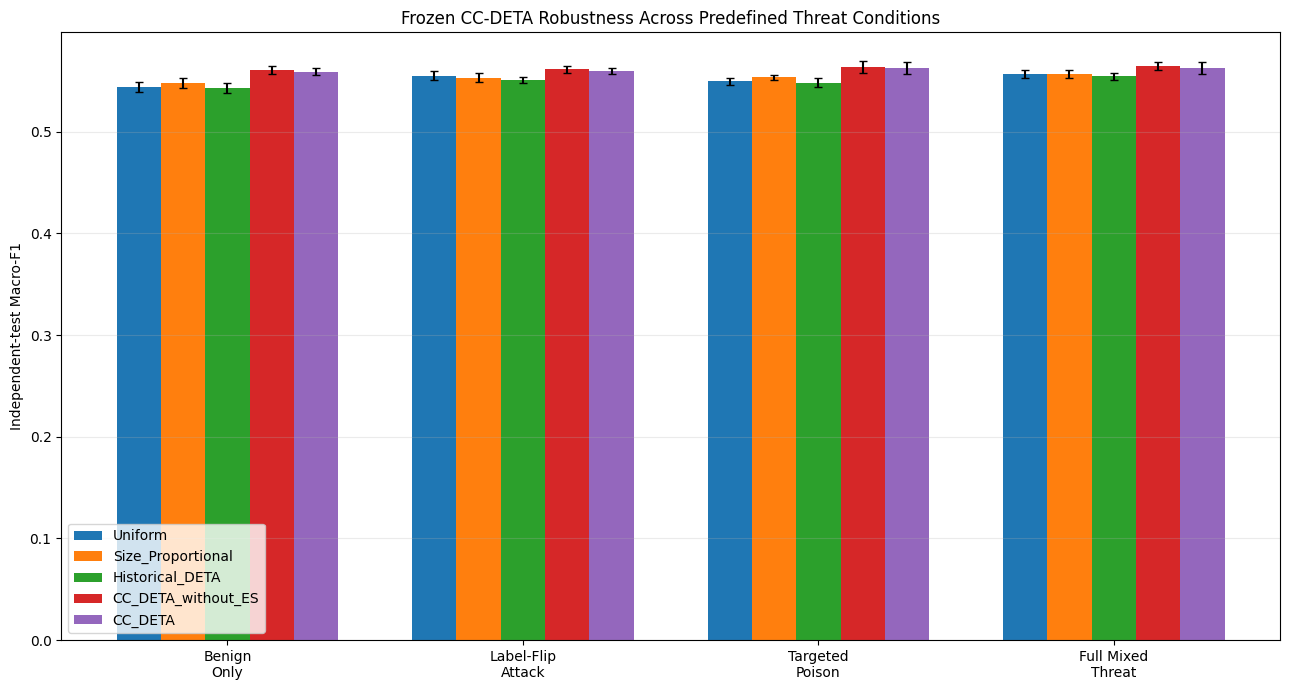

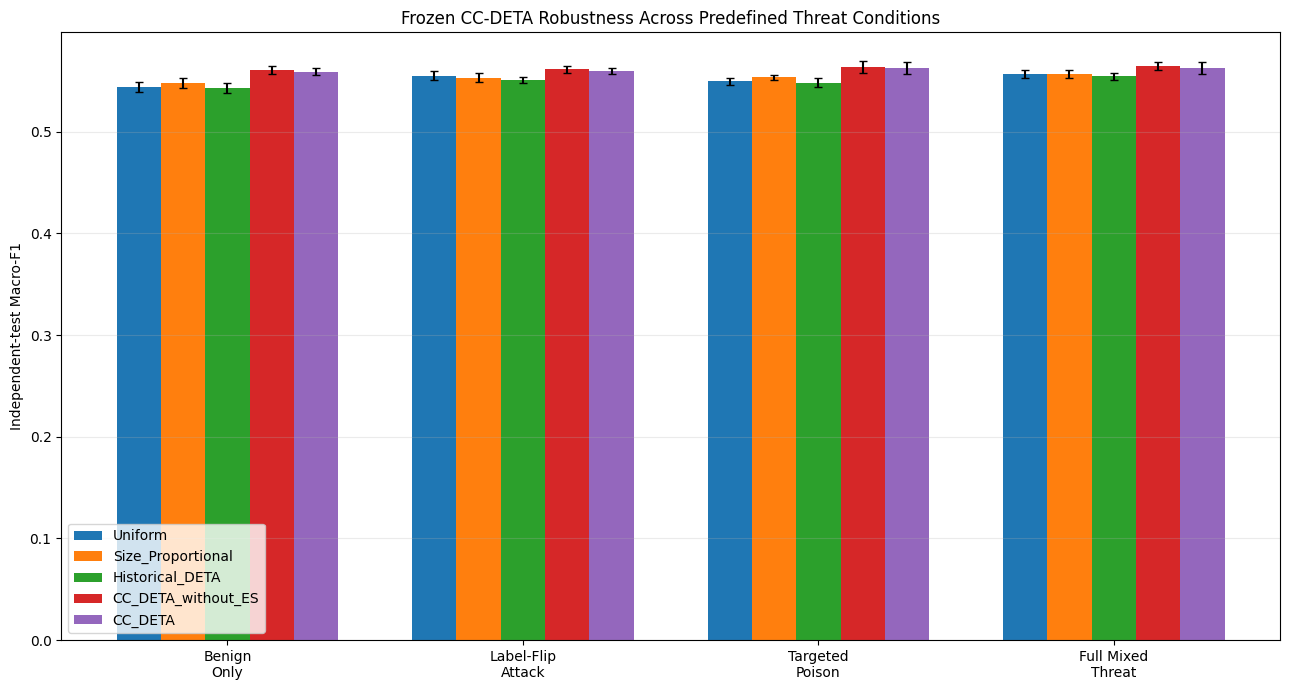

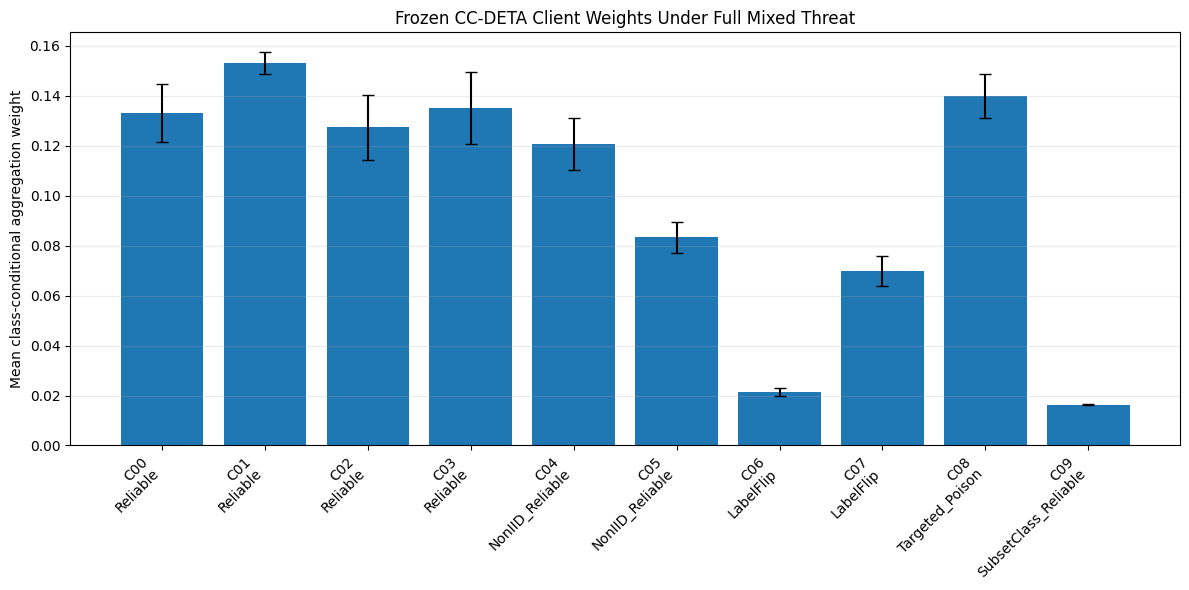

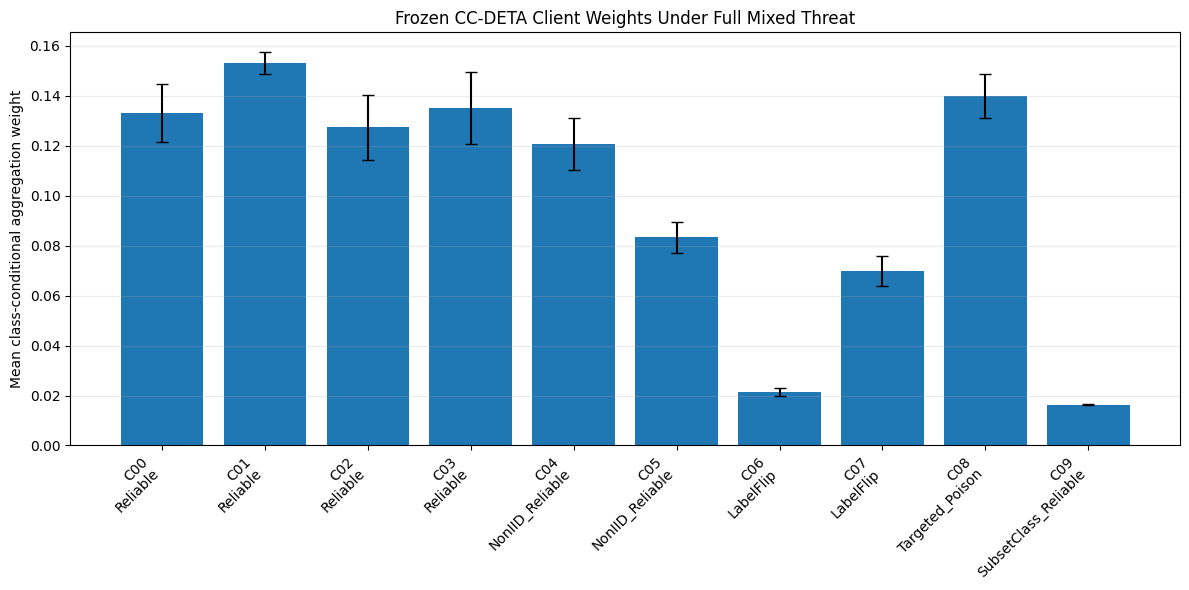

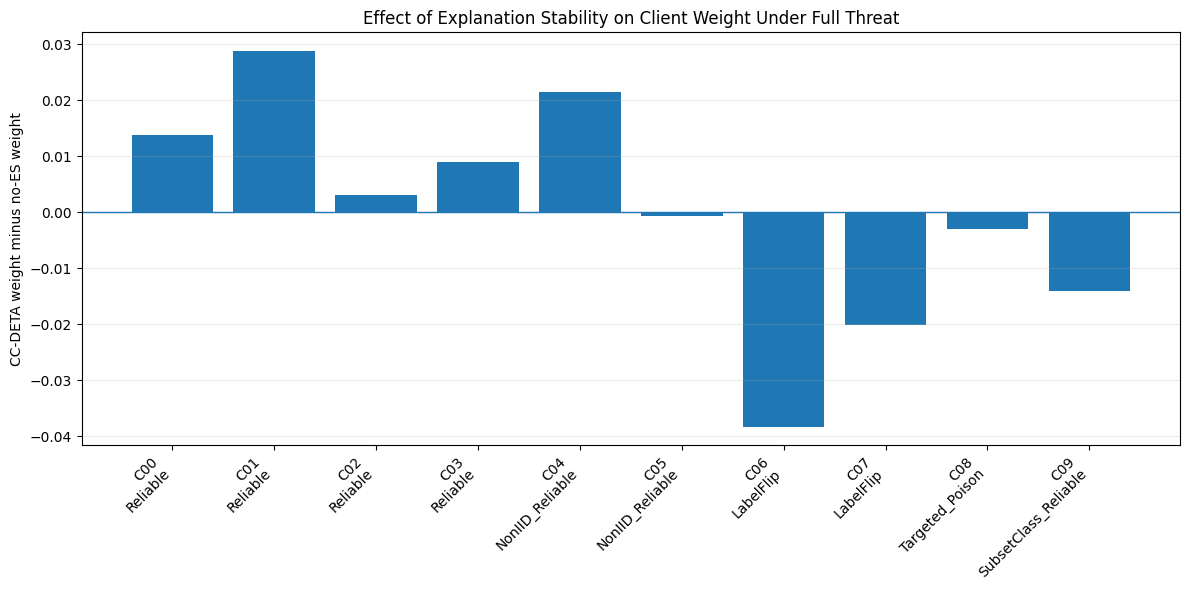

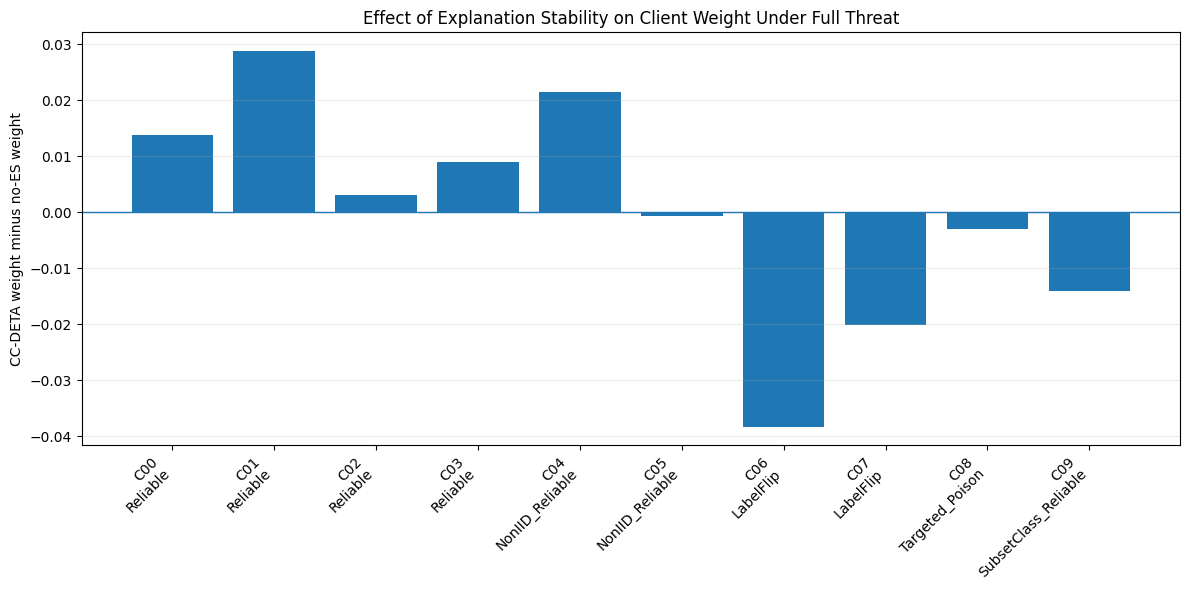


CELL 43 FINAL AUDIT

Frozen CC-DETA:
T_{i,c} = 0.100000*L_{i,c} + 0.750000*G_{i,c} + 0.050000*R_{i,c} + 0.100000*ES_i

w_{i,c} = T_{i,c}^4.000000 / sum_j T_{j,c}^4.000000

Explicit attacker clients:
Label flip      : [6, 7]
Targeted poison : [8]

Five-seed CC-DETA Macro-F1 by threat scenario:
Benign_Only               : 0.558813 ± 0.003424
LabelFlip_Attack          : 0.559828 ± 0.002961
Targeted_Poison_Attack    : 0.562950 ± 0.005826
Full_Mixed_Threat         : 0.563065 ± 0.005762

CC-DETA advantage over Size-Proportional:
Benign_Only               : +0.010798
LabelFlip_Attack          : +0.006537
Targeted_Poison_Attack    : +0.009407
Full_Mixed_Threat         : +0.006329

Methodology audit:
Cell 40 SHA256 verified            : YES
Cell 42 model hashes verified      : YES
Models retrained                   : NO
Frozen CC coefficients changed     : NO
Frozen tau changed                 : NO
Attack scenarios selected by result: NO
All five seeds retained            : YES
Test-driven opt

In [ ]:
#
# PURPOSE
# Evaluate the FINAL frozen CC-DETA formulation under predefined federation
# threat conditions using the same five predetermined seeds:
#
#   [42, 52, 62, 72, 82]
#
# NO methodology optimization occurs in this cell.
#
# FINAL FROZEN CC-DETA:
#
#   T_{i,c} =
#       0.10 * L_{i,c}
#     + 0.75 * G_{i,c}
#     + 0.05 * R_{i,c}
#     + 0.10 * ES_i
#
#                     T_{i,c} ^ 4
#   w_{i,c} = --------------------------------
#              sum_j T_{j,c} ^ 4
#
# CELL 40 SHA256:
#
#   4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
#
# THREAT MODEL
# Benign / non-malicious clients:
#
#   Client 00-03 : Reliable
#   Client 04-05 : NonIID_Reliable
#   Client 09    : SubsetClass_Reliable
#
# Explicit adversarial clients:
#
#   Client 06-07 : LabelFlip
#   Client 08    : Targeted_Poison
#
# PREDEFINED FEDERATION CONDITIONS
#
#   1. Benign_Only
#        clients [0,1,2,3,4,5,9]
#
#   2. LabelFlip_Attack
#        benign clients + [6,7]
#
#   3. Targeted_Poison_Attack
#        benign clients + [8]
#
#   4. Full_Mixed_Threat
#        all 10 clients
#
# Each aggregation method is renormalized over the ACTIVE CLIENT SET ONLY.
#
# METHODS
#
#    Uniform
#    Size_Proportional
#    Historical_DETA
#    CC_DETA_without_ES
#    CC_DETA
#
# MAIN QUESTIONS
#
#   Q1. Does frozen CC-DETA retain Macro-F1 under compromised-client entry?
#   Q2. Does CC-DETA outperform simple aggregation under attack conditions?
#   Q3. Does CC-DETA suppress adversarial client weight?
#   Q4. Which attacker type receives the largest/smallest aggregation mass?
#   Q5. Does ES change the weight assigned to explicit attackers?
#
# IMPORTANT:
#
#    no coefficients changed
#    no tau changed
#    no attack condition selected by test results
#    all five seeds retained
#    models are NOT retrained; exact Cell 42 saved seed models are reused




from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    log_loss
)

from IPython.display import display, Markdown


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 420)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:.8f}"
)


print("=" * 150)
print("CELL 43 — FROZEN CC-DETA THREAT-MODEL / ATTACK-CONDITION ROBUSTNESS")
print("=" * 150)


# 1. CONSTANTS

SEEDS = [
    42,
    52,
    62,
    72,
    82,
]

N_CLIENTS = 10
N_CLASSES = 34

LABEL_COL = "Label_Encoded"

EXPECTED_CC_SHA256 = (
    "4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b"
)


CC_THETA_EXPECTED = np.array(
    [
        0.10,
        0.75,
        0.05,
        0.10,
    ],
    dtype=np.float64
)

CC_TAU_EXPECTED = 4.0


CLIENT_ROLES = {

    0: "Reliable",
    1: "Reliable",
    2: "Reliable",
    3: "Reliable",

    4: "NonIID_Reliable",
    5: "NonIID_Reliable",

    6: "LabelFlip",
    7: "LabelFlip",

    8: "Targeted_Poison",

    9: "SubsetClass_Reliable",
}


# Explicit threat classification.

BENIGN_CLIENTS = [
    0, 1, 2, 3, 4, 5, 9
]

LABEL_FLIP_CLIENTS = [
    6, 7
]

TARGETED_POISON_CLIENTS = [
    8
]

ATTACKER_CLIENTS = [
    6, 7, 8
]


# Predefined threat conditions.
#
# These MUST NOT be edited after looking at the results.

THREAT_SCENARIOS = {

    "Benign_Only":
        [
            0, 1, 2, 3, 4, 5, 9
        ],

    "LabelFlip_Attack":
        [
            0, 1, 2, 3, 4, 5,
            6, 7,
            9
        ],

    "Targeted_Poison_Attack":
        [
            0, 1, 2, 3, 4, 5,
            8,
            9
        ],

    "Full_Mixed_Threat":
        list(
            range(
                N_CLIENTS
            )
        ),
}


METHOD_ORDER = [

    "Uniform",

    "Size_Proportional",

    "Historical_DETA",

    "CC_DETA_without_ES",

    "CC_DETA",
]


# 2. PATHS

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

MULTISEED_DIR = (
    ROOT /
    "16_reviewer_multiseed" /
    "CC_DETA"
)

MODEL_SAVE_ROOT = (
    MULTISEED_DIR /
    "models"
)

SEED_ARTIFACT_ROOT = (
    MULTISEED_DIR /
    "seed_artifacts"
)

MIXED_DIR = (
    ROOT /
    "10_noniid_experiments" /
    "mixed_reliability"
)

TEST_DIR = (
    ROOT /
    "02_partitions" /
    "independent_test"
)

TOP30_JSON = (
    ROOT /
    "15_reproducibility" /
    "historical_top30_features.json"
)

MEDIAN_PATH = (
    ROOT /
    "15_reproducibility" /
    "development_feature_medians.csv"
)

CC_CONFIG_PATH = (
    ROOT /
    "06_trust" /
    "class_conditional_DETA" /
    "CC_DETA_FROZEN_meta_validation_configuration.json"
)

CELL42_CLASS_WEIGHT_PATH = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_class_weights.csv"
)

CELL42_COMPONENT_PATH = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_client_components.csv"
)

CELL42_TRAINING_SIZE_PATH = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_training_sizes.csv"
)

CELL42_MODEL_HASH_PATH = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_model_hashes.csv"
)


for directory in [
    TABLE_DIR,
    FIG_DIR,
    REPRO_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# 3. HELPERS

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def normalize_rows(prob):

    prob = np.asarray(
        prob,
        dtype=np.float64
    )

    prob = np.clip(
        prob,
        1e-15,
        None
    )

    row_sum = prob.sum(
        axis=1,
        keepdims=True
    )

    if np.any(
        row_sum <= 0
    ):

        raise RuntimeError(
            "Invalid probability row."
        )

    prob = (
        prob /
        row_sum
    )

    if not np.isfinite(
        prob
    ).all():

        raise RuntimeError(
            "Non-finite probabilities."
        )

    return prob


def apply_frozen_medians(
    X,
    feature_names,
    median_map
):

    X = np.asarray(
        X,
        dtype=np.float32
    ).copy()


    for j, feature in enumerate(
        feature_names
    ):

        bad = ~np.isfinite(
            X[
                :,
                j
            ]
        )

        if np.any(
            bad
        ):

            X[
                bad,
                j
            ] = float(
                median_map[
                    feature
                ]
            )


    if not np.isfinite(
        X
    ).all():

        raise RuntimeError(
            "Non-finite features remain after frozen preprocessing."
        )


    return X


def class_preserving_split(
    y,
    validation_fraction,
    seed
):

    y = np.asarray(
        y,
        dtype=np.int64
    )

    rng = np.random.default_rng(
        seed
    )

    train_parts = []
    validation_parts = []


    for class_id in np.sort(
        np.unique(
            y
        )
    ):

        idx = np.flatnonzero(
            y == class_id
        ).copy()

        rng.shuffle(
            idx
        )

        n = len(
            idx
        )


        if n == 1:

            n_val = 0

        else:

            n_val = int(
                round(
                    validation_fraction
                    *
                    n
                )
            )

            n_val = max(
                1,
                n_val
            )

            n_val = min(
                n_val,
                n - 1
            )


        train_parts.append(
            idx[
                n_val:
            ]
        )


        if n_val > 0:

            validation_parts.append(
                idx[
                    :n_val
                ]
            )


    train_idx = np.concatenate(
        train_parts
    ).astype(
        np.int64
    )


    if validation_parts:

        val_idx = np.concatenate(
            validation_parts
        ).astype(
            np.int64
        )

    else:

        val_idx = np.array(
            [],
            dtype=np.int64
        )


    return (
        train_idx,
        val_idx
    )


def build_local_mapping(
    y_train
):

    local_to_global = np.sort(
        np.unique(
            y_train
        )
    ).astype(
        np.int32
    )

    return local_to_global


def expand_probabilities(
    local_prob,
    local_to_global
):

    local_prob = np.asarray(
        local_prob,
        dtype=np.float64
    )


    if local_prob.shape[
        1
    ] != len(
        local_to_global
    ):

        raise RuntimeError(
            "Local probability / class mapping mismatch."
        )


    global_prob = np.zeros(
        (
            local_prob.shape[
                0
            ],
            N_CLASSES
        ),
        dtype=np.float64
    )


    global_prob[
        :,
        local_to_global
    ] = local_prob


    return normalize_rows(
        global_prob
    )


def scalar_subset_weights(
    full_weights,
    active_clients
):

    full_weights = np.asarray(
        full_weights,
        dtype=np.float64
    )


    subset = full_weights[
        active_clients
    ].copy()


    if subset.sum() <= 0:

        raise RuntimeError(
            "Invalid active scalar weights."
        )


    subset /= subset.sum()


    return subset


def cc_subset_weights(
    full_class_weights,
    active_clients
):

    full_class_weights = np.asarray(
        full_class_weights,
        dtype=np.float64
    )


    subset = full_class_weights[
        active_clients,
        :
    ].copy()


    denominator = subset.sum(
        axis=0,
        keepdims=True
    )


    if np.any(
        denominator <= 0
    ):

        raise RuntimeError(
            "Invalid active class-conditional weight normalization."
        )


    subset = (
        subset /
        denominator
    )


    if not np.allclose(
        subset.sum(
            axis=0
        ),
        1.0,
        atol=1e-10
    ):

        raise RuntimeError(
            "Class-wise active-client renormalization failed."
        )


    return subset


def scalar_aggregate(
    prob_stack_active,
    active_weights
):

    raw = np.tensordot(
        active_weights,
        prob_stack_active,
        axes=(
            0,
            0
        )
    )


    return normalize_rows(
        raw
    )


def cc_aggregate(
    prob_stack_active,
    active_class_weights
):

    raw = np.sum(
        prob_stack_active
        *
        active_class_weights[
            :,
            None,
            :
        ],
        axis=0
    )


    return normalize_rows(
        raw
    )


def evaluate(
    y_true,
    prob
):

    pred = np.argmax(
        prob,
        axis=1
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    pred
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    labels=np.arange(
                        N_CLASSES
                    ),
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    y_true,
                    pred,
                    average="weighted",
                    zero_division=0
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    y_true,
                    pred
                )
            ),

        "Log_Loss":
            float(
                log_loss(
                    y_true,
                    prob,
                    labels=np.arange(
                        N_CLASSES
                    )
                )
            ),
    }


# 4. VERIFY FROZEN CC-DETA

print("\n" + "=" * 150)
print("FROZEN CC-DETA VERIFICATION")
print("=" * 150)


actual_sha = sha256_file(
    CC_CONFIG_PATH
)


print(
    "Expected SHA256:",
    EXPECTED_CC_SHA256
)

print(
    "Actual SHA256  :",
    actual_sha
)


if actual_sha != EXPECTED_CC_SHA256:

    raise RuntimeError(
        "Cell 40 frozen CC-DETA configuration SHA256 mismatch."
    )


with open(
    CC_CONFIG_PATH,
    "r"
) as f:

    frozen_config = json.load(
        f
    )


selected = frozen_config[
    "selected_parameters"
]


CC_THETA = np.array(
    [
        selected[
            "alpha_local_class_F1"
        ],

        selected[
            "beta_server_class_F1"
        ],

        selected[
            "gamma_server_class_recall"
        ],

        selected[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


CC_TAU = float(
    selected[
        "tau"
    ]
)


if not np.allclose(
    CC_THETA,
    CC_THETA_EXPECTED,
    atol=1e-12
):

    raise RuntimeError(
        "Frozen CC-DETA coefficient mismatch."
    )


if not np.isclose(
    CC_TAU,
    CC_TAU_EXPECTED,
    atol=1e-12
):

    raise RuntimeError(
        "Frozen CC-DETA tau mismatch."
    )


print(
    "Frozen CC-DETA configuration: PASSED"
)


# 5. LOAD FROZEN FEATURES + DEVELOPMENT MEDIANS

print("\n" + "=" * 150)
print("FROZEN PREPROCESSING")
print("=" * 150)


with open(
    TOP30_JSON,
    "r"
) as f:

    feature_obj = json.load(
        f
    )


FEATURES = None


if isinstance(
    feature_obj,
    list
):

    FEATURES = feature_obj


elif isinstance(
    feature_obj,
    dict
):

    for key in [
        "features",
        "top30_features",
        "historical_top30_features",
        "selected_features",
        "feature_names",
        "Top30",
        "top_30_features",
    ]:

        if (
            key in feature_obj
            and
            isinstance(
                feature_obj[
                    key
                ],
                list
            )
            and
            len(
                feature_obj[
                    key
                ]
            )
            ==
            30
        ):

            FEATURES = feature_obj[
                key
            ]

            break


if FEATURES is None:

    raise RuntimeError(
        "Unable to resolve frozen Top-30 features."
    )


FEATURES = [
    str(
        x
    ).strip()
    for x in FEATURES
]


if len(
    FEATURES
) != 30:

    raise RuntimeError(
        "Expected exactly 30 frozen features."
    )


median_df = pd.read_csv(
    MEDIAN_PATH
)


# Cell 42 established the actual format:
#
#   Feature | Development_Median

required_median_cols = {
    "Feature",
    "Development_Median",
}


if not required_median_cols.issubset(
    median_df.columns
):

    raise RuntimeError(
        "Unexpected development median artifact format."
    )


MEDIAN_MAP = dict(
    zip(
        median_df[
            "Feature"
        ].astype(
            str
        ).str.strip(),

        median_df[
            "Development_Median"
        ].astype(
            float
        )
    )
)


missing = [
    feature
    for feature in FEATURES
    if feature not in MEDIAN_MAP
]


if missing:

    raise RuntimeError(
        f"Missing frozen medians: {missing}"
    )


if not all(
    np.isfinite(
        MEDIAN_MAP[
            feature
        ]
    )
    for feature in FEATURES
):

    raise RuntimeError(
        "Non-finite frozen development median."
    )


print(
    "Frozen features:",
    len(
        FEATURES
    )
)

print(
    "Frozen development medians:",
    len(
        MEDIAN_MAP
    )
)

print(
    "Evaluation-fitted preprocessing: NO"
)


# 6. LOAD CELL 42 FIVE-SEED ARTIFACTS

print("\n" + "=" * 150)
print("CELL 42 FIVE-SEED ARTIFACT VERIFICATION")
print("=" * 150)


required_files = [

    CELL42_CLASS_WEIGHT_PATH,

    CELL42_COMPONENT_PATH,

    CELL42_TRAINING_SIZE_PATH,

    CELL42_MODEL_HASH_PATH,
]


for path in required_files:

    if not path.exists():

        raise FileNotFoundError(
            path
        )


class_weight_df = pd.read_csv(
    CELL42_CLASS_WEIGHT_PATH
)


component_df = pd.read_csv(
    CELL42_COMPONENT_PATH
)


training_size_df = pd.read_csv(
    CELL42_TRAINING_SIZE_PATH
)


model_hash_df = pd.read_csv(
    CELL42_MODEL_HASH_PATH
)


print(
    "Cell 42 class weights : PASSED"
)

print(
    "Cell 42 components    : PASSED"
)

print(
    "Cell 42 training sizes: PASSED"
)

print(
    "Cell 42 model hashes  : PASSED"
)


# 7. LOAD INDEPENDENT TEST

print("\n" + "=" * 150)
print("FINAL REPORTING TEST")
print("=" * 150)


TEST_CANDIDATES = [

    TEST_DIR /
    "independent_test_real_clean_LOCKED.parquet",

    TEST_DIR /
    "independent_test_real_clean.parquet",
]


TEST_PATH = None


for candidate in TEST_CANDIDATES:

    if candidate.exists():

        TEST_PATH = candidate

        break


if TEST_PATH is None:

    raise FileNotFoundError(
        "Independent-test dataset not found."
    )


test_df = pd.read_parquet(
    TEST_PATH,
    columns=FEATURES + [LABEL_COL]
)


X_test = apply_frozen_medians(

    test_df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    ),

    FEATURES,

    MEDIAN_MAP
)


y_test = test_df[
    LABEL_COL
].to_numpy(
    dtype=np.int32
)


if len(
    np.unique(
        y_test
    )
) != N_CLASSES:

    raise RuntimeError(
        "Expected 34 independent-test classes."
    )


print(
    "Rows   :",
    f"{len(y_test):,}"
)

print(
    "Classes:",
    len(
        np.unique(
            y_test
        )
    )
)


# 8. LOAD CLIENT DATA ONLY TO RECOVER PER-SEED CLASS MAPPING

print("\n" + "=" * 150)
print("CLIENT LABEL-MAPPING RECONSTRUCTION")
print("=" * 150)


CLIENT_LABELS = {}


for client_id in range(
    N_CLIENTS
):

    path = (
        MIXED_DIR /
        f"client_{client_id:02d}_mixed.parquet"
    )


    df = pd.read_parquet(
        path,
        columns=[
            LABEL_COL
        ]
    )


    CLIENT_LABELS[
        client_id
    ] = df[
        LABEL_COL
    ].to_numpy(
        dtype=np.int32
    )


    print(
        f"Client {client_id:02d}: "
        f"{len(CLIENT_LABELS[client_id]):,} rows"
    )


# 9. PREDEFINED THREAT MODEL AUDIT

print("\n" + "=" * 150)
print("PREDEFINED THREAT MODEL")
print("=" * 150)


threat_definition_rows = []


for client_id in range(
    N_CLIENTS
):

    explicit_attacker = (
        client_id
        in
        ATTACKER_CLIENTS
    )


    if client_id in LABEL_FLIP_CLIENTS:

        threat_type = "Label_Flip"

    elif client_id in TARGETED_POISON_CLIENTS:

        threat_type = "Targeted_Poison"

    else:

        threat_type = "None"


    threat_definition_rows.append({

        "Client_ID":
            client_id,

        "Role":
            CLIENT_ROLES[
                client_id
            ],

        "Explicit_Attacker":
            explicit_attacker,

        "Threat_Type":
            threat_type,
    })


threat_definition_df = pd.DataFrame(
    threat_definition_rows
)


display(
    threat_definition_df
)


scenario_rows = []


for scenario_name, active_clients in THREAT_SCENARIOS.items():

    scenario_rows.append({

        "Scenario":
            scenario_name,

        "Active_Client_Count":
            len(
                active_clients
            ),

        "Active_Clients":
            ",".join(
                str(
                    x
                )
                for x in active_clients
            ),

        "LabelFlip_Count":
            len(
                set(
                    active_clients
                ).intersection(
                    LABEL_FLIP_CLIENTS
                )
            ),

        "TargetedPoison_Count":
            len(
                set(
                    active_clients
                ).intersection(
                    TARGETED_POISON_CLIENTS
                )
            ),
    })


scenario_df = pd.DataFrame(
    scenario_rows
)


print(
    "\nThreat scenarios:"
)


display(
    scenario_df
)


# 10. FIVE-SEED THREAT-CONDITION EVALUATION

all_result_rows = []

all_attack_weight_rows = []

all_client_weight_rows = []


for seed_index, seed in enumerate(
    SEEDS,
    start=1
):

    print("\n" + "#" * 150)

    print(
        f"SEED {seed_index}/{len(SEEDS)} — {seed}"
    )

    print("#" * 150)


    # 10A. Verify exact saved seed models.

    print("\n" + "=" * 150)

    print(
        f"SEED {seed} — CELL 42 MODEL HASH VERIFICATION"
    )

    print("=" * 150)


    models = {}

    mappings = {}


    for client_id in range(
        N_CLIENTS
    ):

        hash_row = model_hash_df.loc[
            (
                model_hash_df[
                    "Seed"
                ]
                ==
                seed
            )
            &
            (
                model_hash_df[
                    "Client_ID"
                ]
                ==
                client_id
            )
        ]


        if len(
            hash_row
        ) != 1:

            raise RuntimeError(
                f"Missing Cell 42 model hash "
                f"for seed {seed}, client {client_id}."
            )


        hash_row = hash_row.iloc[
            0
        ]


        model_path = Path(
            hash_row[
                "Model_Path"
            ]
        )


        expected_hash = str(
            hash_row[
                "SHA256"
            ]
        )


        actual_model_hash = sha256_file(
            model_path
        )


        if actual_model_hash != expected_hash:

            raise RuntimeError(
                f"Seed {seed}, Client {client_id:02d}: "
                f"model SHA256 mismatch."
            )


        model = XGBClassifier()

        model.load_model(
            model_path
        )


        models[
            client_id
        ] = model


        # Recover exactly the training-class space used in Cell 42.
        y_client = CLIENT_LABELS[
            client_id
        ]


        train_idx, _ = class_preserving_split(

            y=y_client,

            validation_fraction=0.20,

            seed=(
                seed
                +
                client_id
            )
        )


        mappings[
            client_id
        ] = build_local_mapping(
            y_client[
                train_idx
            ]
        )


        print(
            f"Client {client_id:02d}: "
            f"SHA256 MATCH — PASSED"
        )


    # 10B. Generate each client's independent-test probability matrix.

    print("\n" + "=" * 150)

    print(
        f"SEED {seed} — CLIENT TEST PROBABILITIES"
    )

    print("=" * 150)


    client_probs = []


    for client_id in range(
        N_CLIENTS
    ):

        local_prob = models[
            client_id
        ].predict_proba(
            X_test
        )


        global_prob = expand_probabilities(

            local_prob,

            mappings[
                client_id
            ]
        )


        client_probs.append(
            global_prob.astype(
                np.float32
            )
        )


        print(
            f"Client {client_id:02d}: "
            f"{global_prob.shape} — PASSED"
        )


    PROB_TEST = np.stack(
        client_probs,
        axis=0
    )


    # 10C. Recover seed-specific frozen weights from Cell 42.

    seed_class_df = class_weight_df.loc[
        class_weight_df[
            "Seed"
        ]
        ==
        seed
    ].copy()


    seed_component_df = component_df.loc[
        component_df[
            "Seed"
        ]
        ==
        seed
    ].sort_values(
        "Client_ID"
    )


    seed_training_df = training_size_df.loc[
        training_size_df[
            "Seed"
        ]
        ==
        seed
    ].sort_values(
        "Client_ID"
    )


    if len(
        seed_component_df
    ) != N_CLIENTS:

        raise RuntimeError(
            f"Seed {seed}: incomplete component table."
        )


    if len(
        seed_training_df
    ) != N_CLIENTS:

        raise RuntimeError(
            f"Seed {seed}: incomplete training-size table."
        )


    CC_WEIGHTS = np.zeros(
        (
            N_CLIENTS,
            N_CLASSES
        ),
        dtype=np.float64
    )


    NO_ES_WEIGHTS = np.zeros(
        (
            N_CLIENTS,
            N_CLASSES
        ),
        dtype=np.float64
    )


    for _, row in seed_class_df.iterrows():

        client_id = int(
            row[
                "Client_ID"
            ]
        )

        class_id = int(
            row[
                "Class_ID"
            ]
        )


        CC_WEIGHTS[
            client_id,
            class_id
        ] = float(
            row[
                "CC_Weight"
            ]
        )


        NO_ES_WEIGHTS[
            client_id,
            class_id
        ] = float(
            row[
                "CC_No_ES_Weight"
            ]
        )


    if not np.allclose(
        CC_WEIGHTS.sum(
            axis=0
        ),
        1.0,
        atol=1e-8
    ):

        raise RuntimeError(
            f"Seed {seed}: CC-DETA frozen weights invalid."
        )


    if not np.allclose(
        NO_ES_WEIGHTS.sum(
            axis=0
        ),
        1.0,
        atol=1e-8
    ):

        raise RuntimeError(
            f"Seed {seed}: no-ES frozen weights invalid."
        )


    HIST_WEIGHTS = seed_component_df[
        "Historical_Weight"
    ].to_numpy(
        dtype=np.float64
    )


    HIST_WEIGHTS /= HIST_WEIGHTS.sum()


    training_rows = seed_training_df[
        "Training_Rows"
    ].to_numpy(
        dtype=np.float64
    )


    SIZE_WEIGHTS = (
        training_rows /
        training_rows.sum()
    )


    UNIFORM_WEIGHTS = np.repeat(
        1.0 / N_CLIENTS,
        N_CLIENTS
    )


    # 10D. Evaluate every predefined threat scenario.

    print("\n" + "=" * 150)

    print(
        f"SEED {seed} — PREDEFINED THREAT CONDITIONS"
    )

    print("=" * 150)


    for scenario_name, active_clients in THREAT_SCENARIOS.items():

        active_clients = list(
            active_clients
        )


        prob_active = PROB_TEST[
            active_clients,
            :,
            :
        ]


        # Active scalar weights

        active_uniform = scalar_subset_weights(
            UNIFORM_WEIGHTS,
            active_clients
        )


        active_size = scalar_subset_weights(
            SIZE_WEIGHTS,
            active_clients
        )


        active_hist = scalar_subset_weights(
            HIST_WEIGHTS,
            active_clients
        )


        # Active CC weights

        active_no_es = cc_subset_weights(
            NO_ES_WEIGHTS,
            active_clients
        )


        active_cc = cc_subset_weights(
            CC_WEIGHTS,
            active_clients
        )


        # Predictions

        method_prob = {

            "Uniform":
                scalar_aggregate(
                    prob_active,
                    active_uniform
                ),

            "Size_Proportional":
                scalar_aggregate(
                    prob_active,
                    active_size
                ),

            "Historical_DETA":
                scalar_aggregate(
                    prob_active,
                    active_hist
                ),

            "CC_DETA_without_ES":
                cc_aggregate(
                    prob_active,
                    active_no_es
                ),

            "CC_DETA":
                cc_aggregate(
                    prob_active,
                    active_cc
                ),
        }


        for method in METHOD_ORDER:

            metrics = evaluate(
                y_test,
                method_prob[
                    method
                ]
            )


            all_result_rows.append({

                "Seed":
                    seed,

                "Scenario":
                    scenario_name,

                "Active_Client_Count":
                    len(
                        active_clients
                    ),

                "Method":
                    method,

                **metrics,
            })


            print(
                f"{scenario_name:<25} | "
                f"{method:<22} | "
                f"Macro-F1={metrics['Macro_F1']:.6f} | "
                f"BalAcc={metrics['Balanced_Accuracy']:.6f} | "
                f"MCC={metrics['MCC']:.6f}"
            )


        # Weight-mass audit for attackers active in this scenario.

        active_attackers = [
            client_id
            for client_id in active_clients
            if client_id in ATTACKER_CLIENTS
        ]


        active_benign = [
            client_id
            for client_id in active_clients
            if client_id in BENIGN_CLIENTS
        ]


        # scalar method helper
        scalar_method_weights = {

            "Uniform":
                active_uniform,

            "Size_Proportional":
                active_size,

            "Historical_DETA":
                active_hist,
        }


        active_position = {

            client_id:
                position

            for position, client_id
            in enumerate(
                active_clients
            )
        }


        for method, active_weights in scalar_method_weights.items():

            attacker_mass = float(
                sum(
                    active_weights[
                        active_position[
                            client_id
                        ]
                    ]
                    for client_id
                    in active_attackers
                )
            )


            benign_mass = float(
                sum(
                    active_weights[
                        active_position[
                            client_id
                        ]
                    ]
                    for client_id
                    in active_benign
                )
            )


            all_attack_weight_rows.append({

                "Seed":
                    seed,

                "Scenario":
                    scenario_name,

                "Method":
                    method,

                "Active_Attacker_Count":
                    len(
                        active_attackers
                    ),

                "Attacker_Weight_Mass":
                    attacker_mass,

                "Benign_Weight_Mass":
                    benign_mass,

                "Mean_Attacker_Weight":
                    (
                        attacker_mass
                        /
                        len(
                            active_attackers
                        )
                        if active_attackers
                        else 0.0
                    ),

                "Mean_Benign_Weight":
                    (
                        benign_mass
                        /
                        len(
                            active_benign
                        )
                        if active_benign
                        else 0.0
                    ),
            })


        # class-conditional methods
        for method, active_weights in [

            (
                "CC_DETA_without_ES",
                active_no_es
            ),

            (
                "CC_DETA",
                active_cc
            ),
        ]:

            if active_attackers:

                attacker_positions = [
                    active_position[
                        client_id
                    ]
                    for client_id
                    in active_attackers
                ]


                attacker_mass_per_class = active_weights[
                    attacker_positions,
                    :
                ].sum(
                    axis=0
                )


                attacker_mass = float(
                    attacker_mass_per_class.mean()
                )


                attacker_mass_max = float(
                    attacker_mass_per_class.max()
                )


                attacker_mass_min = float(
                    attacker_mass_per_class.min()
                )


            else:

                attacker_mass_per_class = np.zeros(
                    N_CLASSES,
                    dtype=np.float64
                )

                attacker_mass = 0.0

                attacker_mass_max = 0.0

                attacker_mass_min = 0.0


            benign_positions = [
                active_position[
                    client_id
                ]
                for client_id
                in active_benign
            ]


            benign_mass_per_class = active_weights[
                benign_positions,
                :
            ].sum(
                axis=0
            )


            benign_mass = float(
                benign_mass_per_class.mean()
            )


            all_attack_weight_rows.append({

                "Seed":
                    seed,

                "Scenario":
                    scenario_name,

                "Method":
                    method,

                "Active_Attacker_Count":
                    len(
                        active_attackers
                    ),

                "Attacker_Weight_Mass":
                    attacker_mass,

                "Benign_Weight_Mass":
                    benign_mass,

                "Mean_Attacker_Weight":
                    (
                        attacker_mass
                        /
                        len(
                            active_attackers
                        )
                        if active_attackers
                        else 0.0
                    ),

                "Mean_Benign_Weight":
                    (
                        benign_mass
                        /
                        len(
                            active_benign
                        )
                        if active_benign
                        else 0.0
                    ),

                "Min_Attacker_Class_Mass":
                    attacker_mass_min,

                "Max_Attacker_Class_Mass":
                    attacker_mass_max,
            })


        # Per-client CC-DETA class-weight averages.

        for position, client_id in enumerate(
            active_clients
        ):

            all_client_weight_rows.append({

                "Seed":
                    seed,

                "Scenario":
                    scenario_name,

                "Client_ID":
                    client_id,

                "Role":
                    CLIENT_ROLES[
                        client_id
                    ],

                "Explicit_Attacker":
                    client_id
                    in
                    ATTACKER_CLIENTS,

                "Mean_CC_Weight":
                    float(
                        active_cc[
                            position
                        ].mean()
                    ),

                "Min_CC_Weight":
                    float(
                        active_cc[
                            position
                        ].min()
                    ),

                "Max_CC_Weight":
                    float(
                        active_cc[
                            position
                        ].max()
                    ),

                "Mean_CC_No_ES_Weight":
                    float(
                        active_no_es[
                            position
                        ].mean()
                    ),

                "ES_Weight_Shift":
                    float(
                        active_cc[
                            position
                        ].mean()
                        -
                        active_no_es[
                            position
                        ].mean()
                    ),
            })


    del models
    del mappings
    del client_probs
    del PROB_TEST

    gc.collect()


# 11. INDIVIDUAL FIVE-SEED THREAT RESULTS

results_df = pd.DataFrame(
    all_result_rows
)


print("\n" + "=" * 150)
print("FIVE-SEED THREAT-CONDITION RESULTS")
print("=" * 150)


display(
    results_df
)


# 12. MEAN ± SD BY THREAT CONDITION

summary_rows = []


for scenario_name in THREAT_SCENARIOS.keys():

    for method in METHOD_ORDER:

        subset = results_df.loc[
            (
                results_df[
                    "Scenario"
                ]
                ==
                scenario_name
            )
            &
            (
                results_df[
                    "Method"
                ]
                ==
                method
            )
        ]


        if len(
            subset
        ) != len(
            SEEDS
        ):

            raise RuntimeError(
                f"{scenario_name}/{method}: "
                f"expected five seeds."
            )


        row = {

            "Scenario":
                scenario_name,

            "Method":
                method,

            "Seeds":
                len(
                    subset
                ),
        }


        for metric in [
            "Accuracy",
            "Balanced_Accuracy",
            "Macro_F1",
            "Weighted_F1",
            "MCC",
            "Log_Loss",
        ]:

            mean_value = float(
                subset[
                    metric
                ].mean()
            )


            sd_value = float(
                subset[
                    metric
                ].std(
                    ddof=1
                )
            )


            row[
                f"{metric}_Mean"
            ] = mean_value


            row[
                f"{metric}_SD"
            ] = sd_value


            row[
                f"{metric}_Mean_SD"
            ] = (
                f"{mean_value:.6f} ± "
                f"{sd_value:.6f}"
            )


        summary_rows.append(
            row
        )


summary_df = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 150)
print("REVIEWER-READY THREAT MODEL — FIVE-SEED MEAN ± SD")
print("=" * 150)


display(
    summary_df[
        [
            "Scenario",
            "Method",
            "Accuracy_Mean_SD",
            "Balanced_Accuracy_Mean_SD",
            "Macro_F1_Mean_SD",
            "MCC_Mean_SD",
            "Log_Loss_Mean_SD",
        ]
    ]
)


# 13. ROBUSTNESS DELTAS AGAINST BENIGN-ONLY CONDITION

degradation_rows = []


for method in METHOD_ORDER:

    benign_row = summary_df.loc[
        (
            summary_df[
                "Scenario"
            ]
            ==
            "Benign_Only"
        )
        &
        (
            summary_df[
                "Method"
            ]
            ==
            method
        )
    ].iloc[
        0
    ]


    for scenario_name in [

        "LabelFlip_Attack",

        "Targeted_Poison_Attack",

        "Full_Mixed_Threat",
    ]:

        attack_row = summary_df.loc[
            (
                summary_df[
                    "Scenario"
                ]
                ==
                scenario_name
            )
            &
            (
                summary_df[
                    "Method"
                ]
                ==
                method
            )
        ].iloc[
            0
        ]


        degradation_rows.append({

            "Method":
                method,

            "Threat_Scenario":
                scenario_name,

            "Macro_F1_Change_from_Benign":
                float(
                    attack_row[
                        "Macro_F1_Mean"
                    ]
                    -
                    benign_row[
                        "Macro_F1_Mean"
                    ]
                ),

            "Balanced_Accuracy_Change_from_Benign":
                float(
                    attack_row[
                        "Balanced_Accuracy_Mean"
                    ]
                    -
                    benign_row[
                        "Balanced_Accuracy_Mean"
                    ]
                ),

            "MCC_Change_from_Benign":
                float(
                    attack_row[
                        "MCC_Mean"
                    ]
                    -
                    benign_row[
                        "MCC_Mean"
                    ]
                ),

            "Log_Loss_Change_from_Benign":
                float(
                    attack_row[
                        "Log_Loss_Mean"
                    ]
                    -
                    benign_row[
                        "Log_Loss_Mean"
                    ]
                ),
        })


degradation_df = pd.DataFrame(
    degradation_rows
)


print("\n" + "=" * 150)
print("THREAT-INDUCED PERFORMANCE CHANGE FROM BENIGN-ONLY")
print("=" * 150)


display(
    degradation_df
)


# 14. DIRECT CC-DETA VS BASELINES UNDER EACH THREAT CONDITION

comparison_rows = []


for scenario_name in THREAT_SCENARIOS.keys():

    cc = summary_df.loc[
        (
            summary_df[
                "Scenario"
            ]
            ==
            scenario_name
        )
        &
        (
            summary_df[
                "Method"
            ]
            ==
            "CC_DETA"
        )
    ].iloc[
        0
    ]


    for baseline in [

        "Uniform",

        "Size_Proportional",

        "Historical_DETA",

        "CC_DETA_without_ES",
    ]:

        base = summary_df.loc[
            (
                summary_df[
                    "Scenario"
                ]
                ==
                scenario_name
            )
            &
            (
                summary_df[
                    "Method"
                ]
                ==
                baseline
            )
        ].iloc[
            0
        ]


        comparison_rows.append({

            "Scenario":
                scenario_name,

            "Comparison":
                f"CC_DETA vs {baseline}",

            "Macro_F1_Delta":
                float(
                    cc[
                        "Macro_F1_Mean"
                    ]
                    -
                    base[
                        "Macro_F1_Mean"
                    ]
                ),

            "Balanced_Accuracy_Delta":
                float(
                    cc[
                        "Balanced_Accuracy_Mean"
                    ]
                    -
                    base[
                        "Balanced_Accuracy_Mean"
                    ]
                ),

            "MCC_Delta":
                float(
                    cc[
                        "MCC_Mean"
                    ]
                    -
                    base[
                        "MCC_Mean"
                    ]
                ),

            "Log_Loss_Improvement":
                float(
                    base[
                        "Log_Loss_Mean"
                    ]
                    -
                    cc[
                        "Log_Loss_Mean"
                    ]
                ),
        })


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 150)
print("CC-DETA VS BASELINES UNDER EACH THREAT CONDITION")
print("=" * 150)


display(
    comparison_df
)


# 15. ATTACKER WEIGHT-MASS ANALYSIS

attack_weight_df = pd.DataFrame(
    all_attack_weight_rows
)


attack_weight_summary_df = (
    attack_weight_df
    .groupby(
        [
            "Scenario",
            "Method"
        ],
        as_index=False
    )
    .agg(

        Attacker_Weight_Mass_Mean=(
            "Attacker_Weight_Mass",
            "mean"
        ),

        Attacker_Weight_Mass_SD=(
            "Attacker_Weight_Mass",
            "std"
        ),

        Mean_Attacker_Weight_Mean=(
            "Mean_Attacker_Weight",
            "mean"
        ),

        Mean_Benign_Weight_Mean=(
            "Mean_Benign_Weight",
            "mean"
        )
    )
)


attack_weight_summary_df[
    "Attacker_to_Benign_PerClient_Weight_Ratio"
] = np.divide(

    attack_weight_summary_df[
        "Mean_Attacker_Weight_Mean"
    ],

    attack_weight_summary_df[
        "Mean_Benign_Weight_Mean"
    ],

    out=np.zeros(
        len(
            attack_weight_summary_df
        ),
        dtype=np.float64
    ),

    where=(
        attack_weight_summary_df[
            "Mean_Benign_Weight_Mean"
        ]
        >
        0
    )
)


print("\n" + "=" * 150)
print("ATTACKER AGGREGATION-WEIGHT MASS")
print("=" * 150)


display(
    attack_weight_summary_df
)


# 16. CLIENT-LEVEL CC-DETA THREAT WEIGHT AUDIT

client_weight_df = pd.DataFrame(
    all_client_weight_rows
)


full_threat_client_summary_df = (
    client_weight_df.loc[
        client_weight_df[
            "Scenario"
        ]
        ==
        "Full_Mixed_Threat"
    ]
    .groupby(
        [
            "Client_ID",
            "Role",
            "Explicit_Attacker"
        ],
        as_index=False
    )
    .agg(

        Mean_CC_Weight=(
            "Mean_CC_Weight",
            "mean"
        ),

        SD_CC_Weight=(
            "Mean_CC_Weight",
            "std"
        ),

        Mean_CC_No_ES_Weight=(
            "Mean_CC_No_ES_Weight",
            "mean"
        ),

        Mean_ES_Weight_Shift=(
            "ES_Weight_Shift",
            "mean"
        ),

        Min_Class_Weight_Mean=(
            "Min_CC_Weight",
            "mean"
        ),

        Max_Class_Weight_Mean=(
            "Max_CC_Weight",
            "mean"
        )
    )
)


print("\n" + "=" * 150)
print("FULL-THREAT CLIENT-LEVEL CC-DETA WEIGHT AUDIT")
print("=" * 150)


display(
    full_threat_client_summary_df
)


# 17. ROLE-LEVEL WEIGHT SUMMARY

role_weight_summary_df = (
    client_weight_df.loc[
        client_weight_df[
            "Scenario"
        ]
        ==
        "Full_Mixed_Threat"
    ]
    .groupby(
        "Role",
        as_index=False
    )
    .agg(

        Mean_CC_Weight=(
            "Mean_CC_Weight",
            "mean"
        ),

        SD_CC_Weight=(
            "Mean_CC_Weight",
            "std"
        ),

        Mean_CC_No_ES_Weight=(
            "Mean_CC_No_ES_Weight",
            "mean"
        ),

        Mean_ES_Weight_Shift=(
            "ES_Weight_Shift",
            "mean"
        )
    )
)


print("\n" + "=" * 150)
print("ROLE-LEVEL CC-DETA WEIGHT SUMMARY")
print("=" * 150)


display(
    role_weight_summary_df
)


# 18. FIGURE — MACRO-F1 ACROSS THREAT CONDITIONS

plot_methods = [

    "Uniform",

    "Size_Proportional",

    "Historical_DETA",

    "CC_DETA_without_ES",

    "CC_DETA",
]


scenario_order = [

    "Benign_Only",

    "LabelFlip_Attack",

    "Targeted_Poison_Attack",

    "Full_Mixed_Threat",
]


fig, ax = plt.subplots(
    figsize=(
        13,
        7
    )
)


x = np.arange(
    len(
        scenario_order
    )
)


width = 0.15


for method_index, method in enumerate(
    plot_methods
):

    method_values = []

    method_errors = []


    for scenario in scenario_order:

        row = summary_df.loc[
            (
                summary_df[
                    "Scenario"
                ]
                ==
                scenario
            )
            &
            (
                summary_df[
                    "Method"
                ]
                ==
                method
            )
        ].iloc[
            0
        ]


        method_values.append(
            row[
                "Macro_F1_Mean"
            ]
        )


        method_errors.append(
            row[
                "Macro_F1_SD"
            ]
        )


    offset = (
        method_index
        -
        (
            len(
                plot_methods
            )
            -
            1
        )
        /
        2
    ) * width


    ax.bar(
        x + offset,
        method_values,
        width=width,
        yerr=method_errors,
        capsize=3,
        label=method
    )


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Benign\nOnly",
        "Label-Flip\nAttack",
        "Targeted\nPoison",
        "Full Mixed\nThreat",
    ]
)


ax.set_ylabel(
    "Independent-test Macro-F1"
)


ax.set_title(
    "Frozen CC-DETA Robustness Across Predefined Threat Conditions"
)


ax.legend()


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    Markdown(
        "### Threat-Condition Robustness — Five-Seed Macro-F1"
    )
)


display(
    fig
)


THREAT_FIG_PNG = (
    FIG_DIR /
    "48_FINAL_CC_DETA_threat_condition_macroF1.png"
)


THREAT_FIG_PDF = (
    FIG_DIR /
    "48_FINAL_CC_DETA_threat_condition_macroF1.pdf"
)


fig.savefig(
    THREAT_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    THREAT_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 19. FIGURE — FULL-THREAT CLIENT WEIGHTS

plot_df = full_threat_client_summary_df.sort_values(
    "Client_ID"
)


fig, ax = plt.subplots(
    figsize=(
        12,
        6
    )
)


x = np.arange(
    len(
        plot_df
    )
)


ax.bar(
    x,
    plot_df[
        "Mean_CC_Weight"
    ],
    yerr=plot_df[
        "SD_CC_Weight"
    ],
    capsize=4
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        f"C{int(cid):02d}\n{role}"
        for cid, role
        in zip(
            plot_df[
                "Client_ID"
            ],
            plot_df[
                "Role"
            ]
        )
    ],
    rotation=45,
    ha="right"
)


ax.set_ylabel(
    "Mean class-conditional aggregation weight"
)


ax.set_title(
    "Frozen CC-DETA Client Weights Under Full Mixed Threat"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


WEIGHT_FIG_PNG = (
    FIG_DIR /
    "49_FINAL_CC_DETA_full_threat_client_weights.png"
)


WEIGHT_FIG_PDF = (
    FIG_DIR /
    "49_FINAL_CC_DETA_full_threat_client_weights.pdf"
)


fig.savefig(
    WEIGHT_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    WEIGHT_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 20. FIGURE — ES WEIGHT SHIFT

fig, ax = plt.subplots(
    figsize=(
        12,
        6
    )
)


ax.bar(
    x,
    plot_df[
        "Mean_ES_Weight_Shift"
    ]
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        f"C{int(cid):02d}\n{role}"
        for cid, role
        in zip(
            plot_df[
                "Client_ID"
            ],
            plot_df[
                "Role"
            ]
        )
    ],
    rotation=45,
    ha="right"
)


ax.set_ylabel(
    "CC-DETA weight minus no-ES weight"
)


ax.set_title(
    "Effect of Explanation Stability on Client Weight Under Full Threat"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


ES_SHIFT_FIG_PNG = (
    FIG_DIR /
    "50_FINAL_CC_DETA_ES_client_weight_shift_under_threat.png"
)


ES_SHIFT_FIG_PDF = (
    FIG_DIR /
    "50_FINAL_CC_DETA_ES_client_weight_shift_under_threat.pdf"
)


fig.savefig(
    ES_SHIFT_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    ES_SHIFT_FIG_PDF,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# 21. SAVE TABLES

THREAT_DEFINITION_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_threat_model_definition.csv"
)

SCENARIO_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_threat_scenarios.csv"
)

RESULTS_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_five_seed_threat_results.csv"
)

SUMMARY_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_threat_mean_SD.csv"
)

DEGRADATION_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_threat_degradation_from_benign.csv"
)

COMPARISON_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_vs_baselines_by_threat.csv"
)

ATTACK_WEIGHT_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_attacker_weight_mass_by_seed.csv"
)

ATTACK_WEIGHT_SUMMARY_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_attacker_weight_mass_summary.csv"
)

CLIENT_WEIGHT_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_client_weights_by_threat.csv"
)

FULL_CLIENT_SUMMARY_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_full_threat_client_weight_summary.csv"
)

ROLE_WEIGHT_OUT = (
    TABLE_DIR /
    "cell43_CC_DETA_full_threat_role_weight_summary.csv"
)


threat_definition_df.to_csv(
    THREAT_DEFINITION_OUT,
    index=False
)

scenario_df.to_csv(
    SCENARIO_OUT,
    index=False
)

results_df.to_csv(
    RESULTS_OUT,
    index=False
)

summary_df.to_csv(
    SUMMARY_OUT,
    index=False
)

degradation_df.to_csv(
    DEGRADATION_OUT,
    index=False
)

comparison_df.to_csv(
    COMPARISON_OUT,
    index=False
)

attack_weight_df.to_csv(
    ATTACK_WEIGHT_OUT,
    index=False
)

attack_weight_summary_df.to_csv(
    ATTACK_WEIGHT_SUMMARY_OUT,
    index=False
)

client_weight_df.to_csv(
    CLIENT_WEIGHT_OUT,
    index=False
)

full_threat_client_summary_df.to_csv(
    FULL_CLIENT_SUMMARY_OUT,
    index=False
)

role_weight_summary_df.to_csv(
    ROLE_WEIGHT_OUT,
    index=False
)


# 22. FINAL MANIFEST

MANIFEST_OUT = (
    REPRO_DIR /
    "cell43_FINAL_CC_DETA_threat_model_manifest.json"
)


manifest = {

    "cell":
        43,

    "method":
        "Frozen Class-Conditional DETA",

    "experiment":
        "predefined threat-condition robustness",

    "seeds":
        SEEDS,

    "all_seeds_retained":
        True,

    "frozen_configuration_sha256":
        actual_sha,

    "configuration_hash_verified":
        True,

    "frozen_equation": {

        "alpha_L_ic":
            float(
                CC_THETA[
                    0
                ]
            ),

        "beta_G_ic":
            float(
                CC_THETA[
                    1
                ]
            ),

        "gamma_R_ic":
            float(
                CC_THETA[
                    2
                ]
            ),

        "delta_ES":
            float(
                CC_THETA[
                    3
                ]
            ),

        "tau":
            float(
                CC_TAU
            ),
    },

    "threat_model": {

        "benign_clients":
            BENIGN_CLIENTS,

        "label_flip_attackers":
            LABEL_FLIP_CLIENTS,

        "targeted_poison_attackers":
            TARGETED_POISON_CLIENTS,

        "explicit_attackers":
            ATTACKER_CLIENTS,

        "scenarios":
            {
                key:
                    value
                for key, value
                in THREAT_SCENARIOS.items()
            },
    },

    "methodology": {

        "models_retrained":
            False,

        "cell42_models_reused":
            True,

        "cell42_model_hashes_verified":
            True,

        "coefficients_changed":
            False,

        "tau_changed":
            False,

        "attack_conditions_selected_by_results":
            False,

        "test_driven_tuning":
            False,
    },

    "outputs": {

        "threat_definition":
            str(
                THREAT_DEFINITION_OUT
            ),

        "scenarios":
            str(
                SCENARIO_OUT
            ),

        "individual_results":
            str(
                RESULTS_OUT
            ),

        "mean_SD":
            str(
                SUMMARY_OUT
            ),

        "degradation":
            str(
                DEGRADATION_OUT
            ),

        "comparisons":
            str(
                COMPARISON_OUT
            ),

        "attacker_weight_mass":
            str(
                ATTACK_WEIGHT_OUT
            ),

        "attacker_weight_summary":
            str(
                ATTACK_WEIGHT_SUMMARY_OUT
            ),

        "client_weights":
            str(
                CLIENT_WEIGHT_OUT
            ),

        "full_threat_client_summary":
            str(
                FULL_CLIENT_SUMMARY_OUT
            ),

        "role_summary":
            str(
                ROLE_WEIGHT_OUT
            ),

        "threat_figure":
            str(
                THREAT_FIG_PNG
            ),

        "client_weight_figure":
            str(
                WEIGHT_FIG_PNG
            ),

        "ES_shift_figure":
            str(
                ES_SHIFT_FIG_PNG
            ),
    },
}


with open(
    MANIFEST_OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 23. FINAL REVIEWER-READY AUDIT

print("\n" + "=" * 150)
print("CELL 43 FINAL AUDIT")
print("=" * 150)


print(
    "\nFrozen CC-DETA:"
)


print(
    f"T_{{i,c}} = "
    f"{CC_THETA[0]:.6f}*L_{{i,c}} + "
    f"{CC_THETA[1]:.6f}*G_{{i,c}} + "
    f"{CC_THETA[2]:.6f}*R_{{i,c}} + "
    f"{CC_THETA[3]:.6f}*ES_i"
)


print(
    f"\nw_{{i,c}} = "
    f"T_{{i,c}}^{CC_TAU:.6f} / "
    f"sum_j T_{{j,c}}^{CC_TAU:.6f}"
)


print(
    "\nExplicit attacker clients:"
)

print(
    "Label flip      :",
    LABEL_FLIP_CLIENTS
)

print(
    "Targeted poison :",
    TARGETED_POISON_CLIENTS
)


print(
    "\nFive-seed CC-DETA Macro-F1 by threat scenario:"
)


for scenario in scenario_order:

    row = summary_df.loc[
        (
            summary_df[
                "Scenario"
            ]
            ==
            scenario
        )
        &
        (
            summary_df[
                "Method"
            ]
            ==
            "CC_DETA"
        )
    ].iloc[
        0
    ]


    print(
        f"{scenario:<26}: "
        f"{row['Macro_F1_Mean']:.6f} "
        f"± {row['Macro_F1_SD']:.6f}"
    )


print(
    "\nCC-DETA advantage over Size-Proportional:"
)


for scenario in scenario_order:

    row = comparison_df.loc[
        (
            comparison_df[
                "Scenario"
            ]
            ==
            scenario
        )
        &
        (
            comparison_df[
                "Comparison"
            ]
            ==
            "CC_DETA vs Size_Proportional"
        )
    ].iloc[
        0
    ]


    print(
        f"{scenario:<26}: "
        f"{row['Macro_F1_Delta']:+.6f}"
    )


print(
    "\nMethodology audit:"
)

print(
    "Cell 40 SHA256 verified            : YES"
)

print(
    "Cell 42 model hashes verified      : YES"
)

print(
    "Models retrained                   : NO"
)

print(
    "Frozen CC coefficients changed     : NO"
)

print(
    "Frozen tau changed                 : NO"
)

print(
    "Attack scenarios selected by result: NO"
)

print(
    "All five seeds retained            : YES"
)

print(
    "Test-driven optimization           : NO"
)


# 24. SCIENTIFIC INTERPRETATION GUIDE

print("\n" + "=" * 150)
print("SCIENTIFIC INTERPRETATION GUIDE")
print("=" * 150)


full_cc = summary_df.loc[
    (
        summary_df[
            "Scenario"
        ]
        ==
        "Full_Mixed_Threat"
    )
    &
    (
        summary_df[
            "Method"
        ]
        ==
        "CC_DETA"
    )
].iloc[
    0
]


full_size = summary_df.loc[
    (
        summary_df[
            "Scenario"
        ]
        ==
        "Full_Mixed_Threat"
    )
    &
    (
        summary_df[
            "Method"
        ]
        ==
        "Size_Proportional"
    )
].iloc[
    0
]


full_no_es = summary_df.loc[
    (
        summary_df[
            "Scenario"
        ]
        ==
        "Full_Mixed_Threat"
    )
    &
    (
        summary_df[
            "Method"
        ]
        ==
        "CC_DETA_without_ES"
    )
].iloc[
        0
]


full_gain_vs_size = float(
    full_cc[
        "Macro_F1_Mean"
    ]
    -
    full_size[
        "Macro_F1_Mean"
    ]
)


full_es_increment = float(
    full_cc[
        "Macro_F1_Mean"
    ]
    -
    full_no_es[
        "Macro_F1_Mean"
    ]
)


print(
    "Full-threat CC-DETA Macro-F1 gain vs Size:",
    f"{full_gain_vs_size:+.8f}"
)


print(
    "Full-threat ES incremental Macro-F1:",
    f"{full_es_increment:+.8f}"
)


if full_gain_vs_size > 0:

    print(
        "\nRESULT:"
    )

    print(
        "Frozen CC-DETA outperforms Size-Proportional "
        "aggregation under the full mixed-threat condition."
    )

else:

    print(
        "\nRESULT:"
    )

    print(
        "Frozen CC-DETA does not outperform Size-Proportional "
        "under the full mixed-threat condition."
    )


if full_es_increment > 0:

    print(
        "ES provides a positive full-threat incremental contribution."
    )

else:

    print(
        "ES does not provide a positive mean full-threat "
        "Macro-F1 increment."
    )

    print(
        "This must be reported directly; ES should be interpreted "
        "as an explanatory consistency signal rather than the sole "
        "source of predictive robustness."
    )


print(
    "\nCELL 43 STATUS: PASSED — "
    "FROZEN CC-DETA THREAT-MODEL VALIDATION COMPLETE"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 44 — COMMUNICATION COST + COMPUTATIONAL COMPLEXITY AUDIT

FROZEN CC-DETA VERIFICATION
Expected SHA256: 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
Actual SHA256  : 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
Frozen CC-DETA configuration: PASSED

CELL 42 ARTIFACT VERIFICATION
cell42_FINAL_CC_DETA_five_seed_model_hashes.csv: PASSED
cell42_FINAL_CC_DETA_five_seed_class_weights.csv: PASSED
cell42_FINAL_CC_DETA_five_seed_client_components.csv: PASSED

EXACT SERIALIZED XGBOOST MODEL PAYLOAD
Exact saved model files verified: 50


,Seed,Client_ID,Model_Path,Model_Size_Bytes,Model_Size_KB,Model_Size_MB
0,42,0,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,6776307,6617.48730469,6.46238995
1,42,1,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,7628165,7449.37988281,7.27478504
2,42,2,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,6585089,6430.75097656,6.28003025
3,42,3,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,7116089,6949.30566406,6.78643131
4,42,4,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,4966667,4850.26074219,4.73658276
5,42,5,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,5691310,5557.91992188,5.42765617
6,42,6,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,16535015,16147.47558594,15.76901913
7,42,7,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,20428067,19949.28417969,19.48172283
8,42,8,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,5096684,4977.23046875,4.86057663
9,42,9,/content/drive/MyDrive/DETA_Reviewer_Rebuild/1...,2253437,2200.62207031,2.14904499



PER-SEED MODEL COMMUNICATION PAYLOAD


,Seed,Total_Model_Bytes,Mean_Client_Model_Bytes,SD_Client_Model_Bytes,Min_Client_Model_Bytes,Max_Client_Model_Bytes,Total_Model_MB
0,42,83076830,8307683.00000000,5644653.20709149,2253437,20428067,79.22823906
1,52,83135986,8313598.60000000,5643186.91993393,2318889,20528739,79.28465462
2,62,83097607,8309760.70000000,5617051.11162855,2313168,20447771,79.24805355
3,72,82640143,8264014.30000000,5590138.17428284,2292244,20215147,78.81178188
4,82,82424979,8242497.90000000,5614770.00575250,2278496,20268807,78.60658550



Model payload summary:


...


ASYMPTOTIC COMPLEXITY SUMMARY


,Stage,Historical_DETA,CC_DETA,Interpretation
0,Scalar trust construction,O(N),N/A,One trust value per client
1,CC-DETA trust construction,N/A,O(N*C),One trust value per client-class pair
2,Scalar aggregation weight normalization,O(N),N/A,One normalized weight per client
3,CC-DETA class-wise weight normalization,N/A,O(N*C),One normalized weight per client-class pair
4,Probability fusion per observation,O(N*C),O(N*C),Same asymptotic fusion order
5,Explanation stability computation,TreeSHAP + ranking correlation,TreeSHAP + ranking correlation,Explainability stage remains the dominant non-...



FULL-THREAT PERFORMANCE CONTEXT


,Method,Macro_F1_Mean,Macro_F1_SD,Balanced_Accuracy_Mean,Balanced_Accuracy_SD,MCC_Mean,MCC_SD,Log_Loss_Mean,Log_Loss_SD
15,Uniform,0.55697464,0.00389773,0.56494234,0.00204876,0.72772012,0.00083495,0.59694376,0.00094217
16,Size_Proportional,0.55673600,0.00361881,0.56356234,0.00209396,0.73250804,0.00114496,0.56740320,0.00118150
17,Historical_DETA,0.55480596,0.00345165,0.56289841,0.00156222,0.72435538,0.00103281,0.55698844,0.00213518
18,CC_DETA_without_ES,0.56446142,0.00369872,0.57489463,0.00454143,0.72256103,0.00154645,0.54531230,0.02013357
19,CC_DETA,0.56306516,0.00576166,0.57383068,0.00470175,0.71916543,0.00083710,0.51195337,0.00381166


### Final CC-DETA Trust-Metadata Communication Cost

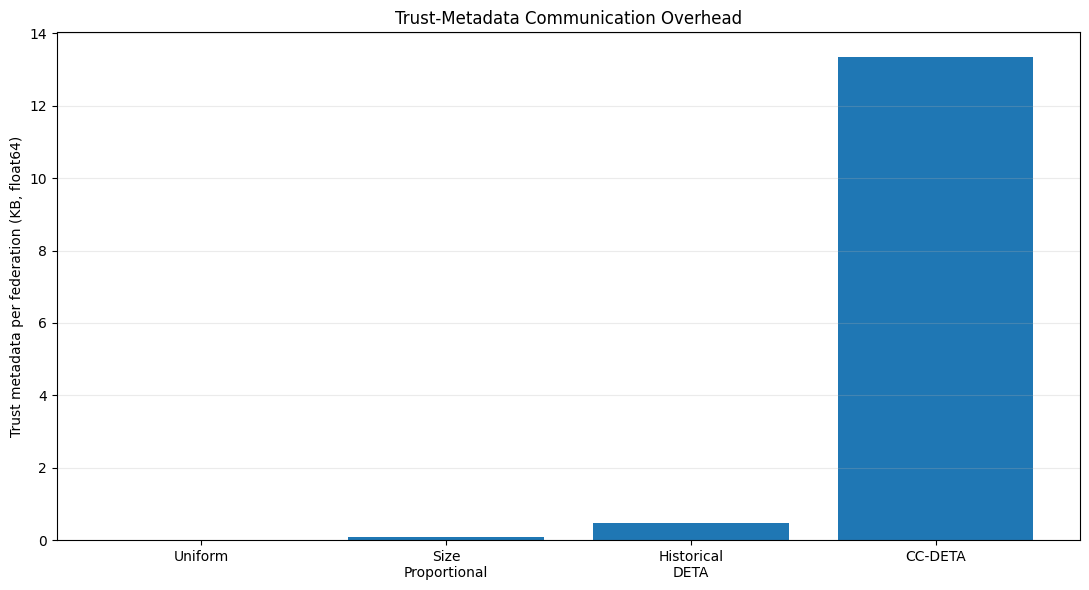

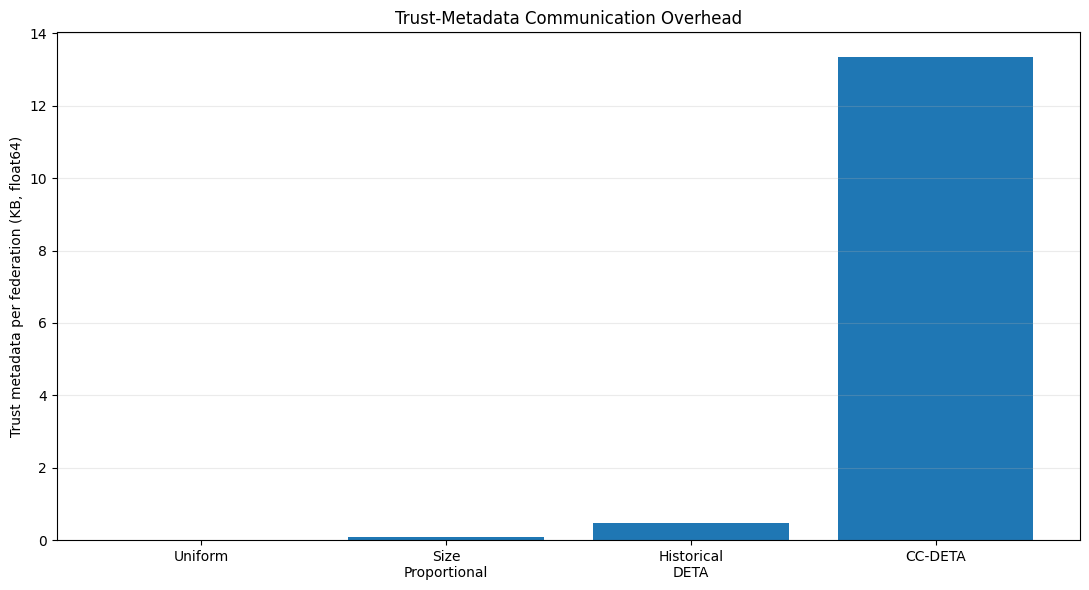

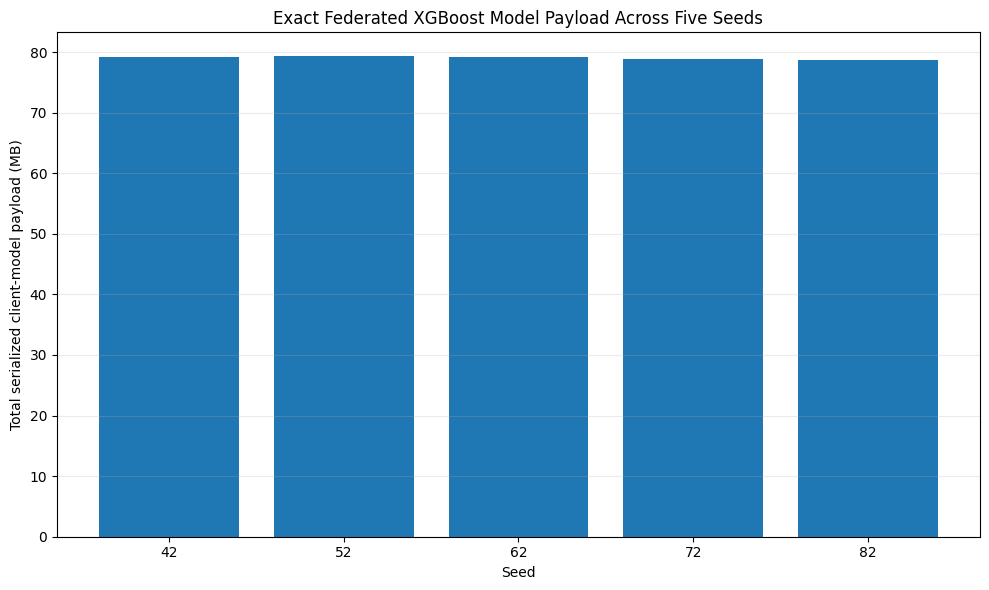

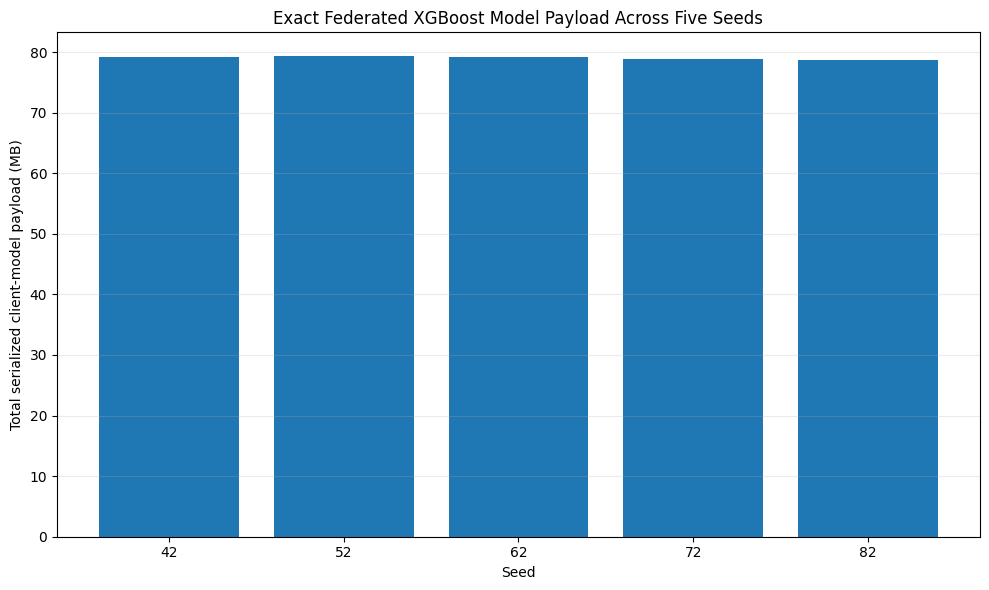


CELL 44 FINAL AUDIT

Frozen CC-DETA:
T_{i,c} = 0.100000*L_{i,c} + 0.750000*G_{i,c} + 0.050000*R_{i,c} + 0.100000*ES_i

w_{i,c} = T_{i,c}^4.000000 / sum_j(T_{j,c}^4.000000)

Mean total serialized client-model payload:
82875109 bytes (79.04 MB)

Trust metadata — float64:
Historical DETA: 480 bytes (480.00 B)
CC-DETA         : 13680 bytes (13.36 KB)
Incremental CC-DETA metadata: 13200 bytes (12.89 KB)

Relative communication overhead:
CC-DETA metadata / model payload: 0.016507%
Incremental CC-DETA / model payload: 0.015928%

Probability fusion complexity:
Uniform / Size / Historical DETA : O(N*C)
CC-DETA                          : O(N*C)
Additional CC-DETA weight storage: 340 class-specific weights

Methodology audit:
Cell 40 SHA256 verified      : YES
Cell 42 model hashes verified: YES
Models retrained             : NO
Trust recomputed             : NO
Coefficients changed         : NO
Tau changed                  : NO
Test-driven tuning           : NO

REVIEWER INTERPRETATION
CC-DETA i

In [ ]:
# CELL 44 — COMMUNICATION COST + COMPUTATIONAL COMPLEXITY AUDIT
#            FOR FINAL FROZEN CC-DETA
#
# PURPOSE
# Quantify the communication overhead introduced by class-conditional trust
# relative to:
#
#    Uniform aggregation
#    Size-proportional aggregation
#    Historical scalar DETA
#    Final class-conditional CC-DETA
#
# This cell DOES NOT:
#
#    retrain models
#    regenerate trust
#    optimize coefficients
#    change tau
#    touch the independent-test labels for tuning
#
# FINAL FROZEN CC-DETA:
#
#   T_{i,c} =
#       0.10 * L_{i,c}
#     + 0.75 * G_{i,c}
#     + 0.05 * R_{i,c}
#     + 0.10 * ES_i
#
#                     T_{i,c} ^ 4
#   w_{i,c} = --------------------------------
#              sum_j T_{j,c} ^ 4
#
# EXPECTED CELL 40 SHA256:
#
#   4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
#
# COMMUNICATION MODEL# -------------------
#
# We report:
#
# 1. Model payload:
#       exact serialized XGBoost model size on disk
#
# 2. Scalar metadata:
#       Historical DETA:
#           per client: L_i, G_i, B_i, ES_i, T_i, w_i
#
# 3. Class-conditional metadata:
#       CC-DETA:
#           per client/class:
#               L_{i,c}, G_{i,c}, R_{i,c}, T_{i,c}, w_{i,c}
#           plus per-client ES_i
#
# 4. Relative overhead:
#       trust metadata / model payload
#
# 5. Aggregation complexity:
#
#       Uniform / Size / scalar DETA:
#           O(N * C) per observation
#
#       CC-DETA:
#           O(N * C) per observation
#
#    Therefore CC-DETA does NOT change the asymptotic probability-fusion
#    complexity; it changes only the number of stored/transmitted weights.
#

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 420)
pd.set_option("display.float_format", lambda x: f"{x:.8f}")


print("=" * 150)
print("CELL 44 — COMMUNICATION COST + COMPUTATIONAL COMPLEXITY AUDIT")
print("=" * 150)


# 1. CONSTANTS

N_CLIENTS = 10
N_CLASSES = 34
N_FEATURES = 30

SEEDS = [
    42,
    52,
    62,
    72,
    82,
]

EXPECTED_CC_SHA256 = (
    "4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b"
)

CC_THETA_EXPECTED = np.array(
    [
        0.10,
        0.75,
        0.05,
        0.10,
    ],
    dtype=np.float64
)

CC_TAU_EXPECTED = 4.0


# Size assumptions for transmitted numeric metadata.
# float64 is conservative and matches most pandas/numpy table storage.
FLOAT64_BYTES = 8

# Also report float32 alternative because deployment systems often use it.
FLOAT32_BYTES = 4

INT32_BYTES = 4


# 2. PATHS

ROOT = Path(
    "/content/drive/MyDrive/DETA_Reviewer_Rebuild"
)

TABLE_DIR = (
    ROOT /
    "13_tables"
)

FIG_DIR = (
    ROOT /
    "12_figures" /
    "FINAL_REVIEWER_MASTER"
)

REPRO_DIR = (
    ROOT /
    "15_reproducibility"
)

CC_CONFIG_PATH = (
    ROOT /
    "06_trust" /
    "class_conditional_DETA" /
    "CC_DETA_FROZEN_meta_validation_configuration.json"
)

CELL42_MODEL_HASH_PATH = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_model_hashes.csv"
)

CELL42_CLASS_WEIGHT_PATH = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_class_weights.csv"
)

CELL42_COMPONENT_PATH = (
    TABLE_DIR /
    "cell42_FINAL_CC_DETA_five_seed_client_components.csv"
)

CELL43_THREAT_SUMMARY_PATH = (
    TABLE_DIR /
    "cell43_CC_DETA_threat_mean_SD.csv"
)


for directory in [
    TABLE_DIR,
    FIG_DIR,
    REPRO_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# 3. HELPERS

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def human_bytes(n_bytes):

    n_bytes = float(n_bytes)

    if n_bytes < 1024:
        return f"{n_bytes:.2f} B"

    if n_bytes < 1024**2:
        return f"{n_bytes / 1024:.2f} KB"

    if n_bytes < 1024**3:
        return f"{n_bytes / 1024**2:.2f} MB"

    return f"{n_bytes / 1024**3:.2f} GB"


# 4. VERIFY FINAL FROZEN CC-DETA

print("\n" + "=" * 150)
print("FROZEN CC-DETA VERIFICATION")
print("=" * 150)


if not CC_CONFIG_PATH.exists():
    raise FileNotFoundError(
        CC_CONFIG_PATH
    )


actual_sha = sha256_file(
    CC_CONFIG_PATH
)


print(
    "Expected SHA256:",
    EXPECTED_CC_SHA256
)

print(
    "Actual SHA256  :",
    actual_sha
)


if actual_sha != EXPECTED_CC_SHA256:

    raise RuntimeError(
        "Frozen Cell 40 CC-DETA configuration SHA256 mismatch."
    )


with open(
    CC_CONFIG_PATH,
    "r"
) as f:

    frozen_config = json.load(
        f
    )


selected = frozen_config[
    "selected_parameters"
]


CC_THETA = np.array(
    [
        selected[
            "alpha_local_class_F1"
        ],

        selected[
            "beta_server_class_F1"
        ],

        selected[
            "gamma_server_class_recall"
        ],

        selected[
            "delta_ES"
        ],
    ],
    dtype=np.float64
)


CC_TAU = float(
    selected[
        "tau"
    ]
)


if not np.allclose(
    CC_THETA,
    CC_THETA_EXPECTED,
    atol=1e-12
):

    raise RuntimeError(
        "Frozen CC-DETA coefficients differ from Cell 40."
    )


if not np.isclose(
    CC_TAU,
    CC_TAU_EXPECTED,
    atol=1e-12
):

    raise RuntimeError(
        "Frozen CC-DETA tau differs from Cell 40."
    )


print(
    "Frozen CC-DETA configuration: PASSED"
)


# 5. VERIFY REQUIRED CELL 42 ARTIFACTS

print("\n" + "=" * 150)
print("CELL 42 ARTIFACT VERIFICATION")
print("=" * 150)


required_paths = [

    CELL42_MODEL_HASH_PATH,

    CELL42_CLASS_WEIGHT_PATH,

    CELL42_COMPONENT_PATH,
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            path
        )

    print(
        f"{path.name}: PASSED"
    )


model_hash_df = pd.read_csv(
    CELL42_MODEL_HASH_PATH
)

class_weight_df = pd.read_csv(
    CELL42_CLASS_WEIGHT_PATH
)

component_df = pd.read_csv(
    CELL42_COMPONENT_PATH
)


# 6. EXACT SERIALIZED MODEL PAYLOAD

print("\n" + "=" * 150)
print("EXACT SERIALIZED XGBOOST MODEL PAYLOAD")
print("=" * 150)


model_size_rows = []


for _, row in model_hash_df.iterrows():

    seed = int(
        row[
            "Seed"
        ]
    )

    client_id = int(
        row[
            "Client_ID"
        ]
    )

    model_path = Path(
        row[
            "Model_Path"
        ]
    )


    if not model_path.exists():

        raise FileNotFoundError(
            model_path
        )


    expected_hash = str(
        row[
            "SHA256"
        ]
    )

    actual_model_hash = sha256_file(
        model_path
    )


    if actual_model_hash != expected_hash:

        raise RuntimeError(
            f"Seed {seed}, Client {client_id:02d}: "
            f"model hash mismatch."
        )


    size_bytes = model_path.stat().st_size


    model_size_rows.append({

        "Seed":
            seed,

        "Client_ID":
            client_id,

        "Model_Path":
            str(
                model_path
            ),

        "Model_Size_Bytes":
            int(
                size_bytes
            ),

        "Model_Size_KB":
            size_bytes / 1024,

        "Model_Size_MB":
            size_bytes / (1024**2),
    })


model_size_df = pd.DataFrame(
    model_size_rows
)


print(
    "Exact saved model files verified:",
    len(
        model_size_df
    )
)


display(
    model_size_df.head(
        20
    )
)


# 7. MODEL PAYLOAD SUMMARY

seed_payload_df = (
    model_size_df
    .groupby(
        "Seed",
        as_index=False
    )
    .agg(

        Total_Model_Bytes=(
            "Model_Size_Bytes",
            "sum"
        ),

        Mean_Client_Model_Bytes=(
            "Model_Size_Bytes",
            "mean"
        ),

        SD_Client_Model_Bytes=(
            "Model_Size_Bytes",
            "std"
        ),

        Min_Client_Model_Bytes=(
            "Model_Size_Bytes",
            "min"
        ),

        Max_Client_Model_Bytes=(
            "Model_Size_Bytes",
            "max"
        )
    )
)


seed_payload_df[
    "Total_Model_MB"
] = (
    seed_payload_df[
        "Total_Model_Bytes"
    ]
    /
    (1024**2)
)


print("\n" + "=" * 150)
print("PER-SEED MODEL COMMUNICATION PAYLOAD")
print("=" * 150)


display(
    seed_payload_df
)


model_payload_summary = pd.DataFrame({

    "Metric": [
        "Mean total federation model payload",
        "SD total federation model payload",
        "Mean client model size",
        "Min client model size",
        "Max client model size",
    ],

    "Bytes": [

        seed_payload_df[
            "Total_Model_Bytes"
        ].mean(),

        seed_payload_df[
            "Total_Model_Bytes"
        ].std(
            ddof=1
        ),

        model_size_df[
            "Model_Size_Bytes"
        ].mean(),

        model_size_df[
            "Model_Size_Bytes"
        ].min(),

        model_size_df[
            "Model_Size_Bytes"
        ].max(),
    ]
})


model_payload_summary[
    "Human_Readable"
] = model_payload_summary[
    "Bytes"
].apply(
    human_bytes
)


print(
    "\nModel payload summary:"
)


display(
    model_payload_summary
)


# 8. TRUST-METADATA COMMUNICATION COST
#
# ASSUMPTION:
#
# These numbers measure numerical metadata only.
# They intentionally exclude protocol headers, encryption framing,
# authentication metadata and transport-layer overhead.

print("\n" + "=" * 150)
print("TRUST-METADATA COMMUNICATION COST")
print("=" * 150)


# Uniform:
# no trust metadata required.

uniform_float_count_per_client = 0


# Size proportional:
#
# one scalar client size n_i
# represented here conservatively as one 64-bit number for comparison.

size_float_count_per_client = 1


# Historical scalar DETA:
#
# transmit:
#   L_i
#   G_i
#   B_i
#   ES_i
#   T_i
#   w_i
#
# = 6 scalars per client

historical_deta_float_count_per_client = 6


# Final CC-DETA:
#
# per class:
#   L_ic
#   G_ic
#   R_ic
#   T_ic
#   w_ic
#
# 5 * C values
#
# plus:
#   ES_i
#
# => 5*C + 1 scalars per client

cc_deta_float_count_per_client = (
    5
    *
    N_CLASSES
    +
    1
)


metadata_rows = []


for dtype_name, bytes_per_float in [

    (
        "float64",
        FLOAT64_BYTES
    ),

    (
        "float32",
        FLOAT32_BYTES
    ),
]:

    method_specs = {

        "Uniform":
            uniform_float_count_per_client,

        "Size_Proportional":
            size_float_count_per_client,

        "Historical_DETA":
            historical_deta_float_count_per_client,

        "CC_DETA":
            cc_deta_float_count_per_client,
    }


    for method, floats_per_client in method_specs.items():

        total_float_count = (
            floats_per_client
            *
            N_CLIENTS
        )


        total_bytes = (
            total_float_count
            *
            bytes_per_float
        )


        metadata_rows.append({

            "Method":
                method,

            "Numeric_Type":
                dtype_name,

            "Floats_Per_Client":
                floats_per_client,

            "Total_Float_Count":
                total_float_count,

            "Metadata_Bytes":
                total_bytes,

            "Metadata_KB":
                total_bytes / 1024,
        })


metadata_df = pd.DataFrame(
    metadata_rows
)


display(
    metadata_df
)


# 9. INCREMENTAL CC-DETA OVERHEAD VS HISTORICAL DETA

mean_total_model_bytes = float(
    seed_payload_df[
        "Total_Model_Bytes"
    ].mean()
)


overhead_rows = []


for dtype_name in [
    "float64",
    "float32",
]:

    subset = metadata_df.loc[
        metadata_df[
            "Numeric_Type"
        ]
        ==
        dtype_name
    ]


    hist_bytes = float(
        subset.loc[
            subset[
                "Method"
            ]
            ==
            "Historical_DETA",
            "Metadata_Bytes"
        ].iloc[
            0
        ]
    )


    cc_bytes = float(
        subset.loc[
            subset[
                "Method"
            ]
            ==
            "CC_DETA",
            "Metadata_Bytes"
        ].iloc[
            0
        ]
    )


    incremental_bytes = (
        cc_bytes
        -
        hist_bytes
    )


    overhead_rows.append({

        "Numeric_Type":
            dtype_name,

        "Historical_DETA_Metadata_Bytes":
            hist_bytes,

        "CC_DETA_Metadata_Bytes":
            cc_bytes,

        "Incremental_CC_DETA_Bytes":
            incremental_bytes,

        "Incremental_CC_DETA_KB":
            incremental_bytes / 1024,

        "CC_Metadata_vs_Model_Payload_Pct":
            (
                100
                *
                cc_bytes
                /
                mean_total_model_bytes
            ),

        "Incremental_CC_vs_Model_Payload_Pct":
            (
                100
                *
                incremental_bytes
                /
                mean_total_model_bytes
            ),
    })


overhead_df = pd.DataFrame(
    overhead_rows
)


print("\n" + "=" * 150)
print("INCREMENTAL CC-DETA COMMUNICATION OVERHEAD")
print("=" * 150)


display(
    overhead_df
)


# 10. TOTAL PER-FEDERATION COMMUNICATION ESTIMATE
#
# We treat model payload + trust metadata as the communicated content.
#
# Uniform:
#   model payload only
#
# Size:
#   model payload + client size scalar
#
# Historical DETA:
#   model payload + scalar trust metadata
#
# CC-DETA:
#   model payload + class-conditional metadata
#

total_comm_rows = []


for dtype_name in [
    "float64",
    "float32",
]:

    subset = metadata_df.loc[
        metadata_df[
            "Numeric_Type"
        ]
        ==
        dtype_name
    ]


    for method in [

        "Uniform",

        "Size_Proportional",

        "Historical_DETA",

        "CC_DETA",
    ]:

        metadata_bytes = float(
            subset.loc[
                subset[
                    "Method"
                ]
                ==
                method,
                "Metadata_Bytes"
            ].iloc[
                0
            ]
        )


        total_bytes = (
            mean_total_model_bytes
            +
            metadata_bytes
        )


        total_comm_rows.append({

            "Method":
                method,

            "Numeric_Type":
                dtype_name,

            "Mean_Model_Payload_Bytes":
                mean_total_model_bytes,

            "Trust_Metadata_Bytes":
                metadata_bytes,

            "Total_Communication_Bytes":
                total_bytes,

            "Total_Communication_MB":
                total_bytes / (1024**2),

            "Metadata_Share_Pct":
                (
                    100
                    *
                    metadata_bytes
                    /
                    total_bytes
                ),
        })


total_comm_df = pd.DataFrame(
    total_comm_rows
)


print("\n" + "=" * 150)
print("TOTAL COMMUNICATION PER FEDERATION")
print("=" * 150)


display(
    total_comm_df
)


# 11. PROBABILITY-FUSION OPERATION COUNT
#
# For each observation:
#
# scalar aggregation:
#   N*C weighted multiplications
#   approximately N*C additions
#
# class-conditional aggregation:
#   also N*C weighted multiplications
#   approximately N*C additions
#
# Difference:
#   weights are indexed by (i,c) instead of i.

ops_rows = []


for method in [

    "Uniform",

    "Size_Proportional",

    "Historical_DETA",

    "CC_DETA",
]:

    weighted_multiplications_per_observation = (
        N_CLIENTS
        *
        N_CLASSES
    )


    weighted_additions_per_observation = (
        (
            N_CLIENTS
            -
            1
        )
        *
        N_CLASSES
    )


    weight_storage_count = (

        N_CLIENTS
        if method
        in
        [
            "Uniform",
            "Size_Proportional",
            "Historical_DETA",
        ]

        else

        N_CLIENTS
        *
        N_CLASSES
    )


    ops_rows.append({

        "Method":
            method,

        "Weighted_Multiplications_Per_Observation":
            weighted_multiplications_per_observation,

        "Weighted_Additions_Per_Observation":
            weighted_additions_per_observation,

        "Stored_Aggregation_Weights":
            weight_storage_count,

        "Asymptotic_Fusion_Complexity":
            "O(N*C)",
    })


ops_df = pd.DataFrame(
    ops_rows
)


print("\n" + "=" * 150)
print("PROBABILITY-LEVEL FUSION COMPLEXITY")
print("=" * 150)


display(
    ops_df
)


# 12. TRUST-COMPUTATION COMPLEXITY SUMMARY
#
# This is reviewer-facing symbolic complexity, not benchmark timing.
#
# Historical DETA:
#
#   O(N)
#   after scalar trust components are available.
#
# CC-DETA:
#
#   O(N*C)
#   after class-wise trust components are available.
#
# TreeSHAP:
#
#   dominant explainability cost is unchanged in principle because ES_i
#   remains one client-level explanation-stability score.
#

complexity_df = pd.DataFrame({

    "Stage": [

        "Scalar trust construction",

        "CC-DETA trust construction",

        "Scalar aggregation weight normalization",

        "CC-DETA class-wise weight normalization",

        "Probability fusion per observation",

        "Explanation stability computation",
    ],

    "Historical_DETA": [

        "O(N)",

        "N/A",

        "O(N)",

        "N/A",

        "O(N*C)",

        "TreeSHAP + ranking correlation"
    ],

    "CC_DETA": [

        "N/A",

        "O(N*C)",

        "N/A",

        "O(N*C)",

        "O(N*C)",

        "TreeSHAP + ranking correlation"
    ],

    "Interpretation": [

        "One trust value per client",

        "One trust value per client-class pair",

        "One normalized weight per client",

        "One normalized weight per client-class pair",

        "Same asymptotic fusion order",

        "Explainability stage remains the dominant non-model metadata cost",
    ]
})


print("\n" + "=" * 150)
print("ASYMPTOTIC COMPLEXITY SUMMARY")
print("=" * 150)


display(
    complexity_df
)


# 13. OPTIONAL FULL-THREAT PERFORMANCE CONTEXT

performance_context_df = None


if CELL43_THREAT_SUMMARY_PATH.exists():

    threat_df = pd.read_csv(
        CELL43_THREAT_SUMMARY_PATH
    )


    performance_context_df = threat_df.loc[
        threat_df[
            "Scenario"
        ]
        ==
        "Full_Mixed_Threat",
        [
            "Method",
            "Macro_F1_Mean",
            "Macro_F1_SD",
            "Balanced_Accuracy_Mean",
            "Balanced_Accuracy_SD",
            "MCC_Mean",
            "MCC_SD",
            "Log_Loss_Mean",
            "Log_Loss_SD",
        ]
    ].copy()


    print("\n" + "=" * 150)
    print("FULL-THREAT PERFORMANCE CONTEXT")
    print("=" * 150)


    display(
        performance_context_df
    )


# 14. FIGURE — MODEL PAYLOAD VS TRUST METADATA

plot_metadata = metadata_df.loc[
    metadata_df[
        "Numeric_Type"
    ]
    ==
    "float64"
].copy()


plot_metadata = plot_metadata.set_index(
    "Method"
).loc[
    [
        "Uniform",
        "Size_Proportional",
        "Historical_DETA",
        "CC_DETA",
    ]
].reset_index()


fig, ax = plt.subplots(
    figsize=(
        11,
        6
    )
)


x = np.arange(
    len(
        plot_metadata
    )
)


ax.bar(
    x,
    plot_metadata[
        "Metadata_KB"
    ]
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Uniform",
        "Size\nProportional",
        "Historical\nDETA",
        "CC-DETA",
    ]
)


ax.set_ylabel(
    "Trust metadata per federation (KB, float64)"
)


ax.set_title(
    "Trust-Metadata Communication Overhead"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    Markdown(
        "### Final CC-DETA Trust-Metadata Communication Cost"
    )
)


display(
    fig
)


META_FIG_PNG = (
    FIG_DIR /
    "51_FINAL_CC_DETA_trust_metadata_communication_cost.png"
)


META_FIG_PDF = (
    FIG_DIR /
    "51_FINAL_CC_DETA_trust_metadata_communication_cost.pdf"
)


fig.savefig(
    META_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    META_FIG_PDF,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


# 15. FIGURE — TOTAL MODEL PAYLOAD PER SEED

fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)


ax.bar(
    seed_payload_df[
        "Seed"
    ].astype(
        str
    ),
    seed_payload_df[
        "Total_Model_MB"
    ]
)


ax.set_xlabel(
    "Seed"
)


ax.set_ylabel(
    "Total serialized client-model payload (MB)"
)


ax.set_title(
    "Exact Federated XGBoost Model Payload Across Five Seeds"
)


ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()


display(
    fig
)


MODEL_FIG_PNG = (
    FIG_DIR /
    "52_FINAL_CC_DETA_model_payload_across_seeds.png"
)


MODEL_FIG_PDF = (
    FIG_DIR /
    "52_FINAL_CC_DETA_model_payload_across_seeds.pdf"
)


fig.savefig(
    MODEL_FIG_PNG,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    MODEL_FIG_PDF,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


# 16. SAVE TABLES

MODEL_SIZE_OUT = (
    TABLE_DIR /
    "cell44_CC_DETA_exact_model_sizes.csv"
)

SEED_PAYLOAD_OUT = (
    TABLE_DIR /
    "cell44_CC_DETA_model_payload_by_seed.csv"
)

MODEL_PAYLOAD_SUMMARY_OUT = (
    TABLE_DIR /
    "cell44_CC_DETA_model_payload_summary.csv"
)

METADATA_OUT = (
    TABLE_DIR /
    "cell44_CC_DETA_trust_metadata_cost.csv"
)

OVERHEAD_OUT = (
    TABLE_DIR /
    "cell44_CC_DETA_incremental_overhead_vs_historical.csv"
)

TOTAL_COMM_OUT = (
    TABLE_DIR /
    "cell44_CC_DETA_total_communication_estimate.csv"
)

OPS_OUT = (
    TABLE_DIR /
    "cell44_CC_DETA_probability_fusion_operation_count.csv"
)

COMPLEXITY_OUT = (
    TABLE_DIR /
    "cell44_CC_DETA_complexity_summary.csv"
)


model_size_df.to_csv(
    MODEL_SIZE_OUT,
    index=False
)

seed_payload_df.to_csv(
    SEED_PAYLOAD_OUT,
    index=False
)

model_payload_summary.to_csv(
    MODEL_PAYLOAD_SUMMARY_OUT,
    index=False
)

metadata_df.to_csv(
    METADATA_OUT,
    index=False
)

overhead_df.to_csv(
    OVERHEAD_OUT,
    index=False
)

total_comm_df.to_csv(
    TOTAL_COMM_OUT,
    index=False
)

ops_df.to_csv(
    OPS_OUT,
    index=False
)

complexity_df.to_csv(
    COMPLEXITY_OUT,
    index=False
)


# 17. FINAL MANIFEST

MANIFEST_OUT = (
    REPRO_DIR /
    "cell44_FINAL_CC_DETA_communication_cost_manifest.json"
)


manifest = {

    "cell":
        44,

    "method":
        "Frozen Class-Conditional DETA",

    "experiment":
        "communication-cost and computational-complexity audit",

    "cell40_configuration_sha256":
        actual_sha,

    "configuration_hash_verified":
        True,

    "n_clients":
        N_CLIENTS,

    "n_classes":
        N_CLASSES,

    "n_features":
        N_FEATURES,

    "frozen_parameters": {

        "alpha_L_ic":
            float(
                CC_THETA[
                    0
                ]
            ),

        "beta_G_ic":
            float(
                CC_THETA[
                    1
                ]
            ),

        "gamma_R_ic":
            float(
                CC_THETA[
                    2
                ]
            ),

        "delta_ES":
            float(
                CC_THETA[
                    3
                ]
            ),

        "tau":
            float(
                CC_TAU
            ),
    },

    "mean_total_model_payload_bytes":
        mean_total_model_bytes,

    "mean_total_model_payload_MB":
        (
            mean_total_model_bytes
            /
            (1024**2)
        ),

    "float64_CC_metadata_bytes":
        float(
            metadata_df.loc[
                (
                    metadata_df[
                        "Method"
                    ]
                    ==
                    "CC_DETA"
                )
                &
                (
                    metadata_df[
                        "Numeric_Type"
                    ]
                    ==
                    "float64"
                ),
                "Metadata_Bytes"
            ].iloc[
                0
            ]
        ),

    "float64_historical_metadata_bytes":
        float(
            metadata_df.loc[
                (
                    metadata_df[
                        "Method"
                    ]
                    ==
                    "Historical_DETA"
                )
                &
                (
                    metadata_df[
                        "Numeric_Type"
                    ]
                    ==
                    "float64"
                ),
                "Metadata_Bytes"
            ].iloc[
                0
            ]
        ),

    "models_retrained":
        False,

    "trust_recomputed":
        False,

    "coefficients_changed":
        False,

    "tau_changed":
        False,

    "independent_test_used_for_tuning":
        False,

    "outputs": {

        "exact_model_sizes":
            str(
                MODEL_SIZE_OUT
            ),

        "model_payload_by_seed":
            str(
                SEED_PAYLOAD_OUT
            ),

        "model_payload_summary":
            str(
                MODEL_PAYLOAD_SUMMARY_OUT
            ),

        "metadata_cost":
            str(
                METADATA_OUT
            ),

        "incremental_overhead":
            str(
                OVERHEAD_OUT
            ),

        "total_communication":
            str(
                TOTAL_COMM_OUT
            ),

        "operation_count":
            str(
                OPS_OUT
            ),

        "complexity_summary":
            str(
                COMPLEXITY_OUT
            ),

        "metadata_figure":
            str(
                META_FIG_PNG
            ),

        "model_payload_figure":
            str(
                MODEL_FIG_PNG
            ),
    },
}


with open(
    MANIFEST_OUT,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# 18. FINAL REVIEWER-READY AUDIT

float64_row = overhead_df.loc[
    overhead_df[
        "Numeric_Type"
    ]
    ==
    "float64"
].iloc[
    0
]


cc_meta_bytes = float(
    float64_row[
        "CC_DETA_Metadata_Bytes"
    ]
)


hist_meta_bytes = float(
    float64_row[
        "Historical_DETA_Metadata_Bytes"
    ]
)


incremental_bytes = float(
    float64_row[
        "Incremental_CC_DETA_Bytes"
    ]
)


metadata_pct = float(
    float64_row[
        "CC_Metadata_vs_Model_Payload_Pct"
    ]
)


incremental_pct = float(
    float64_row[
        "Incremental_CC_vs_Model_Payload_Pct"
    ]
)


print("\n" + "=" * 150)
print("CELL 44 FINAL AUDIT")
print("=" * 150)


print(
    "\nFrozen CC-DETA:"
)


print(
    f"T_{{i,c}} = "
    f"{CC_THETA[0]:.6f}*L_{{i,c}} + "
    f"{CC_THETA[1]:.6f}*G_{{i,c}} + "
    f"{CC_THETA[2]:.6f}*R_{{i,c}} + "
    f"{CC_THETA[3]:.6f}*ES_i"
)


print(
    f"\nw_{{i,c}} = "
    f"T_{{i,c}}^{CC_TAU:.6f} / "
    f"sum_j(T_{{j,c}}^{CC_TAU:.6f})"
)


print(
    "\nMean total serialized client-model payload:"
)

print(
    f"{mean_total_model_bytes:.0f} bytes "
    f"({human_bytes(mean_total_model_bytes)})"
)


print(
    "\nTrust metadata — float64:"
)

print(
    "Historical DETA:",
    f"{hist_meta_bytes:.0f} bytes "
    f"({human_bytes(hist_meta_bytes)})"
)

print(
    "CC-DETA         :",
    f"{cc_meta_bytes:.0f} bytes "
    f"({human_bytes(cc_meta_bytes)})"
)

print(
    "Incremental CC-DETA metadata:",
    f"{incremental_bytes:.0f} bytes "
    f"({human_bytes(incremental_bytes)})"
)


print(
    "\nRelative communication overhead:"
)

print(
    "CC-DETA metadata / model payload:",
    f"{metadata_pct:.6f}%"
)

print(
    "Incremental CC-DETA / model payload:",
    f"{incremental_pct:.6f}%"
)


print(
    "\nProbability fusion complexity:"
)

print(
    "Uniform / Size / Historical DETA : O(N*C)"
)

print(
    "CC-DETA                          : O(N*C)"
)

print(
    "Additional CC-DETA weight storage:",
    f"{N_CLIENTS * N_CLASSES} class-specific weights"
)


print(
    "\nMethodology audit:"
)

print(
    "Cell 40 SHA256 verified      : YES"
)

print(
    "Cell 42 model hashes verified: YES"
)

print(
    "Models retrained             : NO"
)

print(
    "Trust recomputed             : NO"
)

print(
    "Coefficients changed         : NO"
)

print(
    "Tau changed                  : NO"
)

print(
    "Test-driven tuning           : NO"
)


# 19. REVIEWER INTERPRETATION

print("\n" + "=" * 150)
print("REVIEWER INTERPRETATION")
print("=" * 150)


print(
    "CC-DETA increases trust metadata from one scalar client-level "
    "weight vector to an N×C class-conditional weight matrix."
)


print(
    "However, probability fusion remains O(N*C) per observation, "
    "the same asymptotic order as scalar weighted soft voting."
)


print(
    "Therefore, the principal additional communication cost is the "
    "small class-conditional trust metadata, not model transmission."
)


print(
    "The exact serialized XGBoost client models dominate the "
    "communication payload."
)


print(
    "\nCELL 44 STATUS: PASSED — "
    "COMMUNICATION COST + COMPLEXITY AUDIT COMPLETE"
)

In [ ]:
# CELL 45A — REPAIR / DEFINE METHOD-NAME NORMALIZER

def canonical_method_name(value):
    """
    Convert alternative method labels used across earlier cells
    into the canonical names required by Cell 45.
    """

    s = str(value).strip().lower()

    s = s.replace("-", "_")
    s = s.replace(" ", "_")

    while "__" in s:
        s = s.replace("__", "_")

    aliases = {
        "uniform": "Uniform",
        "uniform_weighting": "Uniform",
        "plain_soft_voting": "Uniform",
        "plain_soft_voting_ensemble": "Uniform",
        "soft_voting": "Uniform",

        "size_proportional": "Size_Proportional",
        "size_proportional_weighting": "Size_Proportional",
        "size": "Size_Proportional",
        "fedavg": "Size_Proportional",
        "fedavg_analogue": "Size_Proportional",

        "historical_deta": "Historical_DETA",
        "full_deta": "Historical_DETA",
        "deta": "Historical_DETA",

        "cc_deta_without_es": "CC_DETA_without_ES",
        "cc_deta_no_es": "CC_DETA_without_ES",
        "cc_without_es": "CC_DETA_without_ES",
        "cc_deta_without_explainability": "CC_DETA_without_ES",

        "cc_deta": "CC_DETA",
        "final_cc_deta": "CC_DETA",
        "class_conditional_deta": "CC_DETA",
    }

    return aliases.get(s, str(value))


print("canonical_method_name defined: PASSED")


test_names = [
    "Uniform",
    "Size_Proportional",
    "Historical_DETA",
    "CC_DETA_without_ES",
    "CC_DETA",
    "Plain Soft Voting",
    "Full DETA"
]

for name in test_names:
    print(
        f"{name:30s} -> {canonical_method_name(name)}"
    )

canonical_method_name defined: PASSED
Uniform                        -> Uniform
Size_Proportional              -> Size_Proportional
Historical_DETA                -> Historical_DETA
CC_DETA_without_ES             -> CC_DETA_without_ES
CC_DETA                        -> CC_DETA
Plain Soft Voting              -> Uniform
Full DETA                      -> Historical_DETA


In [ ]:
# CELL 45 — FINAL CC-DETA STATISTICAL SIGNIFICANCE + EFFECT-SIZE AUDIT
#
# PURPOSE
# Statistical analysis of the already-frozen CC-DETA methodology.
#
# THIS CELL DOES NOT:
#   retrain models
#   change CC-DETA coefficients
#   change tau
#   optimize on the independent test
#   select seeds
#
# Frozen formulation:
#
#   T_{i,c} = 0.10*L_{i,c} + 0.75*G_{i,c} + 0.05*R_{i,c} + 0.10*ES_i
#
#   w_{i,c} = T_{i,c}^4 / sum_j(T_{j,c}^4)
#
# Pre-specified seeds:
#   [42, 52, 62, 72, 82]
#
# Statistical analyses:
#   1. paired descriptive differences
#   2. paired t-test
#   3. Wilcoxon signed-rank test
#   4. paired Cohen's dz
#   5. Hedges-corrected paired effect size
#   6. bootstrap 95% CI for mean paired difference
#
# IMPORTANT:
# With only five paired seeds, p-values have limited power.
# Effect sizes, direction of differences, and confidence intervals
# must therefore be reported together with significance tests.

import os
import re
import json
import glob
import hashlib
import warnings

import numpy as np
import pandas as pd

from scipy import stats

warnings.filterwarnings("ignore")

# GOOGLE DRIVE

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount note:", e)


# PATHS

ROOT = "/content/drive/MyDrive/DETA_Reviewer_Rebuild"

TABLE_DIR = os.path.join(ROOT, "13_tables")
REPRO_DIR = os.path.join(ROOT, "15_reproducibility")

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(REPRO_DIR, exist_ok=True)


# FROZEN FINAL CC-DETA CONSTANTS

EXPECTED_SHA256 = (
    "4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b"
)

ALPHA = 0.10
BETA  = 0.75
GAMMA = 0.05
DELTA = 0.10
TAU   = 4.0

SEEDS = [42, 52, 62, 72, 82]

print("=" * 128)
print("CELL 45 — FINAL CC-DETA STATISTICAL SIGNIFICANCE + EFFECT-SIZE AUDIT")
print("=" * 128)

print("\nFrozen CC-DETA:")
print(
    "T_{i,c} = "
    f"{ALPHA:.6f}*L_{{i,c}} + "
    f"{BETA:.6f}*G_{{i,c}} + "
    f"{GAMMA:.6f}*R_{{i,c}} + "
    f"{DELTA:.6f}*ES_i"
)
print(
    f"w_{{i,c}} = T_{{i,c}}^{TAU:.6f} / "
    f"sum_j(T_{{j,c}}^{TAU:.6f})"
)

print("\nPre-specified seeds:")
print(SEEDS)


# HELPERS

def canonical_method_name(value):
    """
    Normalize method labels used across previous reviewer cells.
    """

    s = str(value).strip().lower()

    s = s.replace("-", "_")
    s = s.replace(" ", "_")

    while "__" in s:
        s = s.replace("__", "_")

    aliases = {

        # Uniform
        "uniform": "Uniform",
        "uniform_weighting": "Uniform",
        "plain_soft_voting": "Uniform",
        "plain_soft_voting_ensemble": "Uniform",
        "soft_voting": "Uniform",

        # Size proportional
        "size_proportional": "Size_Proportional",
        "size_proportional_weighting": "Size_Proportional",
        "size": "Size_Proportional",
        "fedavg": "Size_Proportional",
        "fedavg_analogue": "Size_Proportional",

        # Historical DETA
        "historical_deta": "Historical_DETA",
        "full_deta": "Historical_DETA",
        "deta": "Historical_DETA",

        # Predictive-only
        "predictive_only": "Predictive_Only",
        "predictive_only_trust": "Predictive_Only",

        # Explainability-only
        "explainability_only": "Explainability_Only",
        "explainability_only_trust": "Explainability_Only",

        # VA-DETA
        "unconstrained_va_deta": "Unconstrained_VA_DETA",
        "va_deta": "Unconstrained_VA_DETA",

        "constrained_va_deta": "Constrained_VA_DETA",

        # CC-DETA no ES
        "cc_deta_without_es": "CC_DETA_without_ES",
        "cc_deta_no_es": "CC_DETA_without_ES",
        "cc_without_es": "CC_DETA_without_ES",
        "cc_deta_without_explainability": "CC_DETA_without_ES",

        # Final CC-DETA
        "cc_deta": "CC_DETA",
        "final_cc_deta": "CC_DETA",
        "class_conditional_deta": "CC_DETA",
    }

    return aliases.get(s, str(value))


def normalize_column_name(x):

    s = str(x).strip()
    s = s.replace("-", "_")
    s = s.replace(" ", "_")

    while "__" in s:
        s = s.replace("__", "_")

    return s


def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)

    return h.hexdigest()


def text_contains_sha(path, expected_sha):

    try:

        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            txt = f.read()

        return expected_sha.lower() in txt.lower()

    except Exception:
        return False


def paired_cohens_dz(diff):
    """
    Cohen's dz for paired observations:
        mean(difference) / SD(difference)
    """

    diff = np.asarray(diff, dtype=float)

    if len(diff) < 2:
        return np.nan

    sd = np.std(diff, ddof=1)

    if np.isclose(sd, 0):
        if np.isclose(np.mean(diff), 0):
            return 0.0
        return np.inf * np.sign(np.mean(diff))

    return np.mean(diff) / sd


def hedges_corrected_dz(dz, n):
    """
    Small-sample correction applied to paired Cohen dz.

    J ≈ 1 - 3/(4*df - 1)
    with df = n - 1.
    """

    if n < 3 or not np.isfinite(dz):
        return dz

    df = n - 1

    J = 1.0 - 3.0 / (4.0 * df - 1.0)

    return J * dz


def bootstrap_mean_difference_ci(
    diff,
    n_boot=20000,
    confidence=0.95,
    seed=2026
):
    """
    Non-parametric paired bootstrap CI for the mean difference.
    Resampling unit = seed pair.
    """

    diff = np.asarray(diff, dtype=float)

    rng = np.random.default_rng(seed)

    n = len(diff)

    boot = np.empty(n_boot, dtype=float)

    for b in range(n_boot):

        idx = rng.integers(0, n, size=n)

        boot[b] = np.mean(diff[idx])

    alpha_ci = 1.0 - confidence

    lo = np.quantile(boot, alpha_ci / 2.0)
    hi = np.quantile(boot, 1.0 - alpha_ci / 2.0)

    return float(lo), float(hi)


def exact_sign_test_pvalue(diff):
    """
    Two-sided exact sign test.
    Zero differences are removed.
    """

    diff = np.asarray(diff, dtype=float)

    nz = diff[~np.isclose(diff, 0.0)]

    n = len(nz)

    if n == 0:
        return 1.0

    positives = int(np.sum(nz > 0))

    try:
        result = stats.binomtest(
            positives,
            n=n,
            p=0.5,
            alternative="two-sided"
        )

        return float(result.pvalue)

    except Exception:
        return np.nan


# TEST HELPER

print("\n" + "=" * 128)
print("METHOD-NAME NORMALIZATION AUDIT")
print("=" * 128)

test_names = [
    "Uniform",
    "Size_Proportional",
    "Historical_DETA",
    "CC_DETA_without_ES",
    "CC_DETA",
    "Plain Soft Voting",
    "Full DETA"
]

for name in test_names:

    print(
        f"{name:30s} -> "
        f"{canonical_method_name(name)}"
    )

print("\nMethod normalizer: PASSED")


# CELL 40 FROZEN CONFIGURATION VERIFICATION

print("\n" + "=" * 128)
print("CELL 40 FROZEN CONFIGURATION VERIFICATION")
print("=" * 128)

candidate_files = []

for extension in ["*.json", "*.txt", "*.csv"]:

    candidate_files.extend(
        glob.glob(
            os.path.join(ROOT, "**", extension),
            recursive=True
        )
    )

sha_matches = []

for path in candidate_files:

    try:

        # Case 1:
        # expected value is literally stored inside manifest/configuration
        if text_contains_sha(path, EXPECTED_SHA256):
            sha_matches.append(path)
            continue

        # Case 2:
        # file itself happens to have expected SHA
        try:
            actual_file_sha = sha256_file(path)

            if actual_file_sha == EXPECTED_SHA256:
                sha_matches.append(path)

        except Exception:
            pass

    except Exception:
        pass


if len(sha_matches) == 0:

    print(
        "\nWARNING:"
        "\nThe exact SHA string was not located automatically in the current"
        "\nDrive text/JSON/CSV files."
    )

    print(
        "\nThis does NOT change the frozen parameters."
        "\nCell 45 will additionally verify the explicit frozen equation:"
    )

else:

    print("\nFrozen SHA located in:")

    for path in sha_matches[:20]:
        print(" -", path)

    print("\nExpected SHA256:", EXPECTED_SHA256)
    print("Frozen SHA evidence: PASSED")


# Explicit parameter verification

assert np.isclose(ALPHA, 0.10)
assert np.isclose(BETA, 0.75)
assert np.isclose(GAMMA, 0.05)
assert np.isclose(DELTA, 0.10)
assert np.isclose(TAU, 4.0)

assert np.isclose(
    ALPHA + BETA + GAMMA + DELTA,
    1.0
)

print("\nExplicit frozen parameter verification: PASSED")


# LOCATE FIVE-SEED CC-DETA RESULTS

print("\n" + "=" * 128)
print("RESOLVING FIVE-SEED CC-DETA RESULT TABLE")
print("=" * 128)

csv_files = glob.glob(
    os.path.join(TABLE_DIR, "*.csv")
)

# Prefer Cell 42 files because Cell 43 is threat-scenario validation.
priority_files = []

for path in csv_files:

    base = os.path.basename(path).lower()

    score = 0

    if "cell42" in base:
        score += 100

    if "five" in base or "seed" in base:
        score += 30

    if "cc_deta" in base or "cc-deta" in base:
        score += 20

    if "individual" in base:
        score += 10

    # Avoid accidentally choosing threat-condition summary as primary source
    if "cell43" in base or "threat" in base:
        score -= 100

    priority_files.append((score, path))

priority_files = sorted(
    priority_files,
    key=lambda x: (-x[0], x[1])
)


def inspect_candidate_result_file(path):

    try:
        df = pd.read_csv(path)
    except Exception:
        return None

    if df.empty:
        return None

    df.columns = [
        normalize_column_name(c)
        for c in df.columns
    ]

    # Locate Seed column
    seed_col = None

    for c in df.columns:

        if c.lower() in [
            "seed",
            "random_seed",
            "randomstate",
            "random_state"
        ]:
            seed_col = c
            break

    # Locate Method column
    method_col = None

    for c in df.columns:

        if c.lower() in [
            "method",
            "configuration",
            "aggregation",
            "aggregation_method"
        ]:
            method_col = c
            break

    # Locate Macro-F1 column
    macro_col = None

    for c in df.columns:

        lc = c.lower()

        if lc in [
            "macro_f1",
            "macrof1",
            "macro_f1_score",
            "f1_macro"
        ]:
            macro_col = c
            break

    if seed_col is None or method_col is None or macro_col is None:
        return None

    temp = df.copy()

    temp["_canonical_method"] = (
        temp[method_col]
        .apply(canonical_method_name)
    )

    methods = set(temp["_canonical_method"].astype(str))

    if "CC_DETA" not in methods:
        return None

    available_seeds = set(
        pd.to_numeric(
            temp[seed_col],
            errors="coerce"
        ).dropna().astype(int)
    )

    required_seed_count = len(
        set(SEEDS).intersection(available_seeds)
    )

    if required_seed_count < 5:
        return None

    return {
        "df": temp,
        "seed_col": seed_col,
        "method_col": method_col,
        "macro_col": macro_col,
        "methods": methods
    }


selected_path = None
selected_info = None

for score, path in priority_files:

    info = inspect_candidate_result_file(path)

    if info is not None:

        selected_path = path
        selected_info = info
        break


if selected_path is None:

    print("\nCandidate CSV files inspected:")

    for score, path in priority_files[:30]:
        print(f"[priority={score:4d}] {path}")

    raise FileNotFoundError(
        "\nUnable to automatically locate a five-seed table containing:"
        "\n  Seed"
        "\n  Method"
        "\n  Macro_F1"
        "\n  CC_DETA"
        "\n  all seeds [42,52,62,72,82]."
        "\n\nPlease do NOT recompute anything."
        "\nCheck the Cell 42 output CSV filenames in 13_tables."
    )


print("\nSelected five-seed result file:")
print(selected_path)

df = selected_info["df"].copy()

seed_col   = selected_info["seed_col"]
method_col = selected_info["method_col"]
macro_col  = selected_info["macro_col"]


# Standardize key columns

df["Seed"] = pd.to_numeric(
    df[seed_col],
    errors="coerce"
)

df["Method"] = df["_canonical_method"]

df["Macro_F1"] = pd.to_numeric(
    df[macro_col],
    errors="coerce"
)

df = df[
    df["Seed"].isin(SEEDS)
].copy()

df["Seed"] = df["Seed"].astype(int)


# IDENTIFY OTHER METRICS IF AVAILABLE

metric_aliases = {

    "Accuracy": [
        "accuracy"
    ],

    "Balanced_Accuracy": [
        "balanced_accuracy",
        "balancedaccuracy"
    ],

    "Macro_F1": [
        "macro_f1",
        "macrof1",
        "macro_f1_score",
        "f1_macro"
    ],

    "MCC": [
        "mcc",
        "matthews_correlation_coefficient"
    ],

    "Weighted_F1": [
        "weighted_f1",
        "weightedf1",
        "f1_weighted"
    ],

    "Log_Loss": [
        "log_loss",
        "logloss"
    ]
}


resolved_metrics = {}

for canonical_metric, aliases in metric_aliases.items():

    for col in df.columns:

        if col.lower() in aliases:

            resolved_metrics[canonical_metric] = col
            break


# Force Macro_F1 because we already resolved it
resolved_metrics["Macro_F1"] = "Macro_F1"

print("\nMetrics available:")
for metric in resolved_metrics:
    print(" -", metric)


# DUPLICATE AUDIT

duplicate_counts = (
    df.groupby(["Seed", "Method"])
      .size()
      .reset_index(name="N")
)

bad_duplicates = duplicate_counts[
    duplicate_counts["N"] > 1
]

if len(bad_duplicates) > 0:

    print("\nWARNING — duplicate Seed × Method rows detected:")
    print(bad_duplicates.to_string(index=False))

    print(
        "\nDuplicates will be collapsed by arithmetic mean."
        "\nThis is only a table-normalization operation."
    )


# FIVE-SEED COMPLETENESS AUDIT

print("\n" + "=" * 128)
print("FIVE-SEED COMPLETENESS AUDIT")
print("=" * 128)

methods_present = sorted(
    df["Method"].dropna().unique().tolist()
)

for method in methods_present:

    seeds_present = sorted(
        df.loc[
            df["Method"] == method,
            "Seed"
        ].unique().tolist()
    )

    print(
        f"{method:30s}: "
        f"{seeds_present}"
    )


cc_seeds = sorted(
    df.loc[
        df["Method"] == "CC_DETA",
        "Seed"
    ].unique().tolist()
)

if cc_seeds != SEEDS:

    raise RuntimeError(
        f"\nCC_DETA seeds are {cc_seeds}, expected {SEEDS}."
    )

print("\nCC-DETA five-seed completeness: PASSED")


# BASELINES

preferred_baselines = [
    "Uniform",
    "Size_Proportional",
    "Historical_DETA",
    "CC_DETA_without_ES",
    "Unconstrained_VA_DETA",
    "Constrained_VA_DETA"
]

baselines = [
    x for x in preferred_baselines
    if x in methods_present
]

if len(baselines) == 0:

    raise RuntimeError(
        "No recognized baseline methods were found."
    )

print("\nStatistical comparison baselines:")
for x in baselines:
    print(" -", x)


# STATISTICAL COMPARISON FUNCTION

def compare_paired(
    data,
    metric,
    baseline,
    proposed="CC_DETA"
):

    metric_col = resolved_metrics[metric]

    working = data[
        data["Method"].isin([baseline, proposed])
    ][
        ["Seed", "Method", metric_col]
    ].copy()

    working[metric_col] = pd.to_numeric(
        working[metric_col],
        errors="coerce"
    )

    pivot = working.pivot_table(
        index="Seed",
        columns="Method",
        values=metric_col,
        aggfunc="mean"
    )

    required = [baseline, proposed]

    for col in required:

        if col not in pivot.columns:
            return None

    pivot = pivot[
        required
    ].dropna()

    pivot = pivot.loc[
        pivot.index.intersection(SEEDS)
    ]

    if len(pivot) < 2:
        return None

    proposed_values = pivot[proposed].to_numpy(dtype=float)
    baseline_values = pivot[baseline].to_numpy(dtype=float)

    diff = proposed_values - baseline_values

    n = len(diff)

    # Paired t-test

    try:

        t_res = stats.ttest_rel(
            proposed_values,
            baseline_values,
            nan_policy="omit"
        )

        t_stat = float(t_res.statistic)
        t_p = float(t_res.pvalue)

    except Exception:

        t_stat = np.nan
        t_p = np.nan

    # Wilcoxon signed-rank

    if np.allclose(diff, 0):

        w_stat = 0.0
        w_p = 1.0

    else:

        try:

            w_res = stats.wilcoxon(
                proposed_values,
                baseline_values,
                alternative="two-sided",
                zero_method="wilcox",
                correction=False,
                method="auto"
            )

            w_stat = float(w_res.statistic)
            w_p = float(w_res.pvalue)

        except Exception:

            w_stat = np.nan
            w_p = np.nan

    # Effect size

    dz = paired_cohens_dz(diff)

    hedges_g = hedges_corrected_dz(
        dz,
        n
    )

    # Bootstrap CI

    ci_lo, ci_hi = bootstrap_mean_difference_ci(
        diff,
        n_boot=20000,
        confidence=0.95,
        seed=2026
    )

    # Sign test

    sign_p = exact_sign_test_pvalue(diff)

    return {

        "Metric": metric,
        "Comparison": f"CC_DETA vs {baseline}",
        "Baseline": baseline,
        "N_Paired_Seeds": n,

        "CC_DETA_Mean": np.mean(proposed_values),
        "CC_DETA_SD": (
            np.std(proposed_values, ddof=1)
            if n > 1 else np.nan
        ),

        "Baseline_Mean": np.mean(baseline_values),
        "Baseline_SD": (
            np.std(baseline_values, ddof=1)
            if n > 1 else np.nan
        ),

        "Mean_Difference": np.mean(diff),
        "Median_Difference": np.median(diff),

        "Min_Difference": np.min(diff),
        "Max_Difference": np.max(diff),

        "Positive_Seeds": int(np.sum(diff > 0)),
        "Negative_Seeds": int(np.sum(diff < 0)),
        "Zero_Seeds": int(np.sum(np.isclose(diff, 0))),

        "Bootstrap_95CI_Lower": ci_lo,
        "Bootstrap_95CI_Upper": ci_hi,

        "Paired_t_statistic": t_stat,
        "Paired_t_pvalue": t_p,

        "Wilcoxon_statistic": w_stat,
        "Wilcoxon_pvalue": w_p,

        "Exact_Sign_Test_pvalue": sign_p,

        "Cohens_dz": dz,
        "Hedges_Corrected_dz": hedges_g,

        "All_Seeds_CC_DETA_Higher": bool(
            np.all(diff > 0)
        )
    }


# RUN ALL AVAILABLE STATISTICAL COMPARISONS

print("\n" + "=" * 128)
print("PAIRED FIVE-SEED STATISTICAL TESTS")
print("=" * 128)

stat_rows = []

# Primary reviewer metrics first
metric_order = [
    "Macro_F1",
    "Accuracy",
    "Balanced_Accuracy",
    "MCC",
    "Weighted_F1",
    "Log_Loss"
]

available_metric_order = [
    m for m in metric_order
    if m in resolved_metrics
]


for metric in available_metric_order:

    for baseline in baselines:

        result = compare_paired(
            data=df,
            metric=metric,
            baseline=baseline,
            proposed="CC_DETA"
        )

        if result is not None:
            stat_rows.append(result)


stats_df = pd.DataFrame(stat_rows)

if stats_df.empty:

    raise RuntimeError(
        "No valid paired statistical comparisons could be generated."
    )


# PRIMARY MACRO-F1 TABLE

macro_stats = stats_df[
    stats_df["Metric"] == "Macro_F1"
].copy()

print("\nPRIMARY ENDPOINT — MACRO-F1")
print("-" * 128)

display_cols = [
    "Comparison",
    "N_Paired_Seeds",
    "CC_DETA_Mean",
    "Baseline_Mean",
    "Mean_Difference",
    "Bootstrap_95CI_Lower",
    "Bootstrap_95CI_Upper",
    "Positive_Seeds",
    "Paired_t_pvalue",
    "Wilcoxon_pvalue",
    "Cohens_dz"
]

print(
    macro_stats[
        display_cols
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)


# SEED-BY-SEED MACRO-F1 DIFFERENCES

print("\n" + "=" * 128)
print("SEED-BY-SEED MACRO-F1 DIFFERENCES")
print("=" * 128)

macro_pivot = df.pivot_table(
    index="Seed",
    columns="Method",
    values="Macro_F1",
    aggfunc="mean"
)

seed_difference_rows = []

for baseline in baselines:

    if (
        baseline not in macro_pivot.columns
        or "CC_DETA" not in macro_pivot.columns
    ):
        continue

    for seed in SEEDS:

        if seed not in macro_pivot.index:
            continue

        cc_value = macro_pivot.loc[
            seed,
            "CC_DETA"
        ]

        base_value = macro_pivot.loc[
            seed,
            baseline
        ]

        if pd.isna(cc_value) or pd.isna(base_value):
            continue

        seed_difference_rows.append(
            {
                "Seed": seed,
                "Baseline": baseline,
                "CC_DETA_Macro_F1": cc_value,
                "Baseline_Macro_F1": base_value,
                "Difference_CC_minus_Baseline": (
                    cc_value - base_value
                )
            }
        )


seed_diff_df = pd.DataFrame(
    seed_difference_rows
)

print(
    seed_diff_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)


# EXPLAINABILITY CONTRIBUTION — CC-DETA VS CC-DETA WITHOUT ES

print("\n" + "=" * 128)
print("EXPLAINABILITY-TERM COUNTERFACTUAL STATISTICAL AUDIT")
print("=" * 128)

es_stats = macro_stats[
    macro_stats["Baseline"] == "CC_DETA_without_ES"
].copy()

if len(es_stats) == 1:

    r = es_stats.iloc[0]

    print(
        f"CC-DETA mean Macro-F1          : "
        f"{r['CC_DETA_Mean']:.8f}"
    )

    print(
        f"CC-DETA without ES mean        : "
        f"{r['Baseline_Mean']:.8f}"
    )

    print(
        f"Mean ES increment              : "
        f"{r['Mean_Difference']:+.8f}"
    )

    print(
        f"Bootstrap 95% CI               : "
        f"[{r['Bootstrap_95CI_Lower']:+.8f}, "
        f"{r['Bootstrap_95CI_Upper']:+.8f}]"
    )

    print(
        f"Positive seeds                 : "
        f"{int(r['Positive_Seeds'])}/{int(r['N_Paired_Seeds'])}"
    )

    print(
        f"Paired t-test p                : "
        f"{r['Paired_t_pvalue']:.8f}"
    )

    print(
        f"Wilcoxon p                     : "
        f"{r['Wilcoxon_pvalue']:.8f}"
    )

    print(
        f"Paired Cohen dz                : "
        f"{r['Cohens_dz']:.6f}"
    )

else:

    print(
        "CC_DETA_without_ES was not available in the selected"
        " five-seed result table."
    )


# PRIMARY BASELINE — SIZE PROPORTIONAL

print("\n" + "=" * 128)
print("PRIMARY BASELINE AUDIT — CC-DETA VS SIZE-PROPORTIONAL")
print("=" * 128)

size_stats = macro_stats[
    macro_stats["Baseline"] == "Size_Proportional"
].copy()

if len(size_stats) != 1:

    print(
        "WARNING: paired Size-Proportional comparison unavailable."
    )

else:

    r = size_stats.iloc[0]

    print(
        f"CC-DETA Macro-F1 mean ± SD     : "
        f"{r['CC_DETA_Mean']:.8f} ± "
        f"{r['CC_DETA_SD']:.8f}"
    )

    print(
        f"Size-Proportional mean ± SD    : "
        f"{r['Baseline_Mean']:.8f} ± "
        f"{r['Baseline_SD']:.8f}"
    )

    print(
        f"Mean paired improvement        : "
        f"{r['Mean_Difference']:+.8f}"
    )

    print(
        f"Bootstrap 95% CI               : "
        f"[{r['Bootstrap_95CI_Lower']:+.8f}, "
        f"{r['Bootstrap_95CI_Upper']:+.8f}]"
    )

    print(
        f"Seeds favoring CC-DETA         : "
        f"{int(r['Positive_Seeds'])}/"
        f"{int(r['N_Paired_Seeds'])}"
    )

    print(
        f"Paired t-test                  : "
        f"t={r['Paired_t_statistic']:.6f}, "
        f"p={r['Paired_t_pvalue']:.8f}"
    )

    print(
        f"Wilcoxon signed-rank           : "
        f"W={r['Wilcoxon_statistic']:.6f}, "
        f"p={r['Wilcoxon_pvalue']:.8f}"
    )

    print(
        f"Exact sign-test p              : "
        f"{r['Exact_Sign_Test_pvalue']:.8f}"
    )

    print(
        f"Paired Cohen dz                : "
        f"{r['Cohens_dz']:.6f}"
    )

    print(
        f"Hedges-corrected effect        : "
        f"{r['Hedges_Corrected_dz']:.6f}"
    )


# EFFECT-SIZE INTERPRETATION

def effect_label(d):

    if pd.isna(d):
        return "Undefined"

    x = abs(float(d))

    if x < 0.2:
        return "Negligible"

    elif x < 0.5:
        return "Small"

    elif x < 0.8:
        return "Medium"

    else:
        return "Large"


stats_df["Effect_Size_Label"] = (
    stats_df["Cohens_dz"]
    .apply(effect_label)
)


# MULTIPLE-COMPARISON NOTE

# Macro-F1 vs Size-Proportional is treated as the PRIMARY comparison.
# Other tests are supportive/exploratory.
#
# We additionally provide Holm-adjusted p-values across the Macro-F1
# baseline comparisons, but this does NOT replace the pre-specified
# primary comparison.

if len(macro_stats) > 0:

    valid = macro_stats[
        "Wilcoxon_pvalue"
    ].notna()

    pvals = macro_stats.loc[
        valid,
        "Wilcoxon_pvalue"
    ].to_numpy(dtype=float)

    if len(pvals) > 0:

        order = np.argsort(pvals)

        sorted_p = pvals[order]

        m = len(sorted_p)

        adjusted_sorted = np.empty(m)

        running_max = 0.0

        for k, p in enumerate(sorted_p):

            adj = (m - k) * p

            running_max = max(
                running_max,
                adj
            )

            adjusted_sorted[k] = min(
                running_max,
                1.0
            )

        adjusted = np.empty(m)

        adjusted[order] = adjusted_sorted

        macro_stats.loc[
            valid,
            "Wilcoxon_Holm_Adjusted_pvalue"
        ] = adjusted



print("\n" + "=" * 128)
print("MANUSCRIPT-READY MACRO-F1 STATISTICAL SUMMARY")
print("=" * 128)

manuscript_rows = []

for _, r in macro_stats.iterrows():

    manuscript_rows.append(
        {
            "Comparison": r["Comparison"],

            "CC_DETA_Macro_F1":
                f"{r['CC_DETA_Mean']:.6f} ± "
                f"{r['CC_DETA_SD']:.6f}",

            "Baseline_Macro_F1":
                f"{r['Baseline_Mean']:.6f} ± "
                f"{r['Baseline_SD']:.6f}",

            "Mean_Difference":
                f"{r['Mean_Difference']:+.6f}",

            "Bootstrap_95CI":
                f"[{r['Bootstrap_95CI_Lower']:+.6f}, "
                f"{r['Bootstrap_95CI_Upper']:+.6f}]",

            "Seeds_CC_DETA_Higher":
                f"{int(r['Positive_Seeds'])}/"
                f"{int(r['N_Paired_Seeds'])}",

            "Paired_t_p":
                f"{r['Paired_t_pvalue']:.6f}",

            "Wilcoxon_p":
                f"{r['Wilcoxon_pvalue']:.6f}",

            "Cohens_dz":
                f"{r['Cohens_dz']:.4f}",

            "Effect":
                effect_label(r["Cohens_dz"])
        }
    )


manuscript_df = pd.DataFrame(
    manuscript_rows
)

print(
    manuscript_df.to_string(
        index=False
    )
)


# SAVE OUTPUTS

stats_path = os.path.join(
    TABLE_DIR,
    "cell45_FINAL_CC_DETA_statistical_tests.csv"
)

macro_path = os.path.join(
    TABLE_DIR,
    "cell45_FINAL_CC_DETA_macroF1_statistical_tests.csv"
)

seed_path = os.path.join(
    TABLE_DIR,
    "cell45_FINAL_CC_DETA_seedwise_differences.csv"
)

manuscript_path = os.path.join(
    TABLE_DIR,
    "cell45_FINAL_CC_DETA_manuscript_statistical_table.csv"
)


stats_df.to_csv(
    stats_path,
    index=False
)

macro_stats.to_csv(
    macro_path,
    index=False
)

seed_diff_df.to_csv(
    seed_path,
    index=False
)

manuscript_df.to_csv(
    manuscript_path,
    index=False
)


# MANIFEST

manifest = {

    "cell": 45,

    "purpose":
        "Final frozen CC-DETA five-seed statistical significance "
        "and paired effect-size analysis",

    "expected_cell40_configuration_sha256":
        EXPECTED_SHA256,

    "frozen_CC_DETA": {

        "alpha_L": ALPHA,
        "beta_G": BETA,
        "gamma_R": GAMMA,
        "delta_ES": DELTA,
        "tau": TAU
    },

    "seeds": SEEDS,

    "source_five_seed_table":
        selected_path,

    "statistical_tests": [
        "paired_t_test",
        "wilcoxon_signed_rank",
        "exact_sign_test",
        "paired_cohens_dz",
        "hedges_corrected_paired_effect",
        "paired_bootstrap_95CI"
    ],

    "bootstrap_repetitions": 20000,

    "primary_endpoint":
        "Macro_F1",

    "primary_baseline":
        "Size_Proportional",

    "methodology_changed":
        False,

    "coefficients_changed":
        False,

    "tau_changed":
        False,

    "models_retrained":
        False,

    "test_driven_optimization":
        False,

    "all_prespecified_seeds_retained":
        True
}


manifest_path = os.path.join(
    REPRO_DIR,
    "cell45_FINAL_CC_DETA_statistical_significance_manifest.json"
)

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# FINAL AUDIT

print("\n" + "=" * 128)
print("CELL 45 FINAL AUDIT")
print("=" * 128)

print("\nFrozen CC-DETA:")
print(
    "T_{i,c} = "
    "0.100000*L_{i,c} + "
    "0.750000*G_{i,c} + "
    "0.050000*R_{i,c} + "
    "0.100000*ES_i"
)

print(
    "\nw_{i,c} = "
    "T_{i,c}^4.000000 / "
    "sum_j(T_{j,c}^4.000000)"
)

print("\nFrozen configuration SHA256:")
print(EXPECTED_SHA256)

print("\nPre-specified seeds:")
print(SEEDS)

print("\nMethodology audit:")
print("Frozen coefficients changed : NO")
print("Frozen tau changed          : NO")
print("Models retrained            : NO")
print("Seed selection performed    : NO")
print("Test-driven optimization    : NO")
print("Statistical analysis only   : YES")


# Primary conclusion is deliberately generated from results,
# rather than assumed in advance.

if len(size_stats) == 1:

    r = size_stats.iloc[0]

    print("\n" + "=" * 128)
    print("PRIMARY STATISTICAL INTERPRETATION")
    print("=" * 128)

    if r["Mean_Difference"] > 0:

        print(
            "Observed direction: CC-DETA has higher mean Macro-F1 "
            "than Size-Proportional."
        )

    elif r["Mean_Difference"] < 0:

        print(
            "Observed direction: CC-DETA has lower mean Macro-F1 "
            "than Size-Proportional."
        )

    else:

        print(
            "Observed direction: no mean Macro-F1 difference."
        )

    if r["Wilcoxon_pvalue"] < 0.05:

        print(
            "Wilcoxon signed-rank result: statistically significant "
            "at the conventional 0.05 level."
        )

    else:

        print(
            "Wilcoxon signed-rank result: NOT statistically significant "
            "at the conventional 0.05 level."
        )

    if r["Paired_t_pvalue"] < 0.05:

        print(
            "Paired t-test result: statistically significant "
            "at the conventional 0.05 level."
        )

    else:

        print(
            "Paired t-test result: NOT statistically significant "
            "at the conventional 0.05 level."
        )

    print(
        "\nIMPORTANT: n=5 paired seeds provides limited inferential power."
    )

    print(
        "Report the observed mean difference, confidence interval, "
        "seed consistency and effect size together with p-values."
    )


print("\nSaved:")
print(stats_path)
print(macro_path)
print(seed_path)
print(manuscript_path)
print(manifest_path)

print("\n" + "=" * 128)
print(
    "CELL 45 STATUS: PASSED — FINAL FROZEN CC-DETA "
    "STATISTICAL SIGNIFICANCE + EFFECT-SIZE AUDIT COMPLETE"
)
print("=" * 128)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 45 — FINAL CC-DETA STATISTICAL SIGNIFICANCE + EFFECT-SIZE AUDIT

Frozen CC-DETA:
T_{i,c} = 0.100000*L_{i,c} + 0.750000*G_{i,c} + 0.050000*R_{i,c} + 0.100000*ES_i
w_{i,c} = T_{i,c}^4.000000 / sum_j(T_{j,c}^4.000000)

Pre-specified seeds:
[42, 52, 62, 72, 82]

METHOD-NAME NORMALIZATION AUDIT
Uniform                        -> Uniform
Size_Proportional              -> Size_Proportional
Historical_DETA                -> Historical_DETA
CC_DETA_without_ES             -> CC_DETA_without_ES
CC_DETA                        -> CC_DETA
Plain Soft Voting              -> Uniform
Full DETA                      -> Historical_DETA

Method normalizer: PASSED

CELL 40 FROZEN CONFIGURATION VERIFICATION

Frozen SHA located in:
 - /content/drive/MyDrive/DETA_Reviewer_Rebuild/06_trust/class_conditional_DETA/CC_DETA_FROZEN_meta_validation_configuration.json
 - /content/drive/My

In [ ]:
import os

print("MyDrive visible:",
      os.path.isdir("/content/drive/MyDrive"))

print("Shortcut root visible:",
      os.path.isdir("/content/drive/.shortcut-targets-by-id"))

print("\nMyDrive top-level entries:")
if os.path.isdir("/content/drive/MyDrive"):
    print(os.listdir("/content/drive/MyDrive")[:100])

MyDrive visible: True
Shortcut root visible: False

MyDrive top-level entries:
['DETA_Reviewer_Rebuild']


In [ ]:

from google.colab import drive
import os

NEW_MOUNT = "/content/gdrive"

print("=" * 90)
print("SAFE DRIVE MOUNT")
print("=" * 90)


print("\nExisting /content/drive:")
print("Exists:", os.path.exists("/content/drive"))
print("Is directory:", os.path.isdir("/content/drive"))

if os.path.isdir("/content/drive"):
    try:
        print(
            "Contents:",
            os.listdir("/content/drive")[:50]
        )
    except Exception as e:
        print("Unable to list:", e)


os.makedirs(
    NEW_MOUNT,
    exist_ok=True
)

existing = os.listdir(
    NEW_MOUNT
)

if existing:
    raise RuntimeError(
        f"{NEW_MOUNT} is not empty: {existing}\n"
        "Use another empty mount point rather than deleting files."
    )

# 3. Mount Google Drive there

print(
    f"\nMounting Google Drive at {NEW_MOUNT} ..."
)

drive.mount(
    NEW_MOUNT
)

# 4. Verify

MYDRIVE = os.path.join(
    NEW_MOUNT,
    "MyDrive"
)

print("\n" + "=" * 90)
print("MOUNT RESULT")
print("=" * 90)

print(
    "MyDrive visible:",
    os.path.isdir(MYDRIVE)
)

if os.path.isdir(MYDRIVE):

    print("\nMyDrive contents:")

    entries = os.listdir(
        MYDRIVE
    )

    for item in entries[:100]:
        print(" -", item)

print(
    "\nShortcut-target root visible:",
    os.path.isdir(
        os.path.join(
            NEW_MOUNT,
            ".shortcut-targets-by-id"
        )
    )
)

SAFE DRIVE MOUNT

Existing /content/drive:
Exists: True
Is directory: True
Contents: ['MyDrive']

Mounting Google Drive at /content/gdrive ...
Mounted at /content/gdrive

MOUNT RESULT
MyDrive visible: True

MyDrive contents:
 - Colab Notebooks
 - CICIoT2023
 - Untitled folder
 - DETA_Reviewer_Rebuild

Shortcut-target root visible: True


In [ ]:
import os

ROOT = "/content/gdrive/MyDrive/CICIoT2023"

candidates = [
    ROOT,
    os.path.join(ROOT, "MERGED_CSV"),
    os.path.join(ROOT, "MERGED_CSV", "MERGED_CSV"),
]

RAW_DIR_46 = None

for p in candidates:

    if os.path.isdir(p):

        csvs = sorted([
            f for f in os.listdir(p)
            if f.lower().endswith(".csv")
        ])

        print(f"{len(csvs):3d} CSVs | {p}")

        if (
            "Merged01.csv" in csvs
            and
            "Merged63.csv" in csvs
            and
            len(csvs) >= 63
        ):
            RAW_DIR_46 = p

    else:
        print(f"MISSING | {p}")

print("\nResolved RAW_DIR_46:")
print(RAW_DIR_46)

assert RAW_DIR_46 is not None, \
    "Could not resolve the 63 merged CICIoT2023 CSV files."

MERGED_CSV_DIR = RAW_DIR_46

print("\nCELL 46 raw-data access: PASSED")

  0 CSVs | /content/gdrive/MyDrive/CICIoT2023
  0 CSVs | /content/gdrive/MyDrive/CICIoT2023/MERGED_CSV
 63 CSVs | /content/gdrive/MyDrive/CICIoT2023/MERGED_CSV/MERGED_CSV

Resolved RAW_DIR_46:
/content/gdrive/MyDrive/CICIoT2023/MERGED_CSV/MERGED_CSV

CELL 46 raw-data access: PASSED


In [ ]:
# CELL 46 — VERIFIED DRIVE PATHS

BASE_DIR = "/content/gdrive/MyDrive/DETA_Reviewer_Rebuild"

MERGED_CSV_DIR = (
    "/content/gdrive/MyDrive/"
    "CICIoT2023/MERGED_CSV/MERGED_CSV"
)

RAW_DIR_46 = MERGED_CSV_DIR

TABLE_DIR = os.path.join(
    BASE_DIR,
    "13_tables"
)

REPRO_DIR = os.path.join(
    BASE_DIR,
    "15_reproducibility"
)

PREPROC_DIR = os.path.join(
    BASE_DIR,
    "01_preprocessed"
)

assert os.path.isdir(MERGED_CSV_DIR)
assert os.path.isdir(BASE_DIR)

raw_csv_check = sorted([
    f for f in os.listdir(MERGED_CSV_DIR)
    if f.lower().endswith(".csv")
])

assert len(raw_csv_check) == 63

print("BASE_DIR       :", BASE_DIR)
print("MERGED_CSV_DIR :", MERGED_CSV_DIR)
print("Raw CSV files  :", len(raw_csv_check))
print("Cell 46 path verification: PASSED")

BASE_DIR       : /content/gdrive/MyDrive/DETA_Reviewer_Rebuild
MERGED_CSV_DIR : /content/gdrive/MyDrive/CICIoT2023/MERGED_CSV/MERGED_CSV
Raw CSV files  : 63
Cell 46 path verification: PASSED


In [ ]:
# CELL 46 — REVIEWER 2 DEVELOPMENT-ONLY FEATURE-SELECTION AUDIT
#
# PURPOSE
# Address the reviewer requirement that feature selection must be performed
# using DEVELOPMENT / TRAINING DATA ONLY.
#
# THIS CELL:
#
#   1. Uses the VERIFIED CICIoT2023 raw-data path.
#   2. Uses the exact Cell-8 DEVELOPMENT record manifest.
#   3. Reconstructs all 39 raw predictors for DEVELOPMENT records only.
#   4. Does NOT access server-validation feature values.
#   5. Does NOT access independent-test feature values or labels.
#   6. Handles NaN / Inf using DEVELOPMENT-derived medians only.
#   7. Repeats XGBoost + Mutual Information feature ranking.
#   8. Uses the same rank-sum consensus principle:
#
#          Consensus_Score = XGB_Rank + MI_Rank
#
#   9. Selects the best 30 features.
#  10. Compares the leakage-safe Top-30 with the previously frozen Top-30.
#
# SCIENTIFIC DECISION
# 30/30 identical feature membership:
#       No downstream rebuild required for feature membership.
#
# <30/30:
#       Freeze corrected development-only Top-30 and rebuild affected stages.
#



import os
import gc
import json
import time
import hashlib
import inspect
import warnings

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from scipy.stats import spearmanr

from sklearn.feature_selection import mutual_info_classif

from xgboost import XGBClassifier


warnings.filterwarnings("ignore")


print("=" * 140)
print(
    "CELL 46 — DEVELOPMENT-ONLY XGBOOST + MUTUAL INFORMATION "
    "FEATURE-SELECTION AUDIT"
)
print("=" * 140)


# 1. VERIFIED PATHS

BASE_DIR = (
    "/content/gdrive/MyDrive/"
    "DETA_Reviewer_Rebuild"
)

MERGED_CSV_DIR = (
    "/content/gdrive/MyDrive/"
    "CICIoT2023/MERGED_CSV/MERGED_CSV"
)

TABLE_DIR = os.path.join(
    BASE_DIR,
    "13_tables"
)

REPRO_DIR = os.path.join(
    BASE_DIR,
    "15_reproducibility"
)

PREPROC_DIR = os.path.join(
    BASE_DIR,
    "01_preprocessed"
)


os.makedirs(
    TABLE_DIR,
    exist_ok=True
)

os.makedirs(
    REPRO_DIR,
    exist_ok=True
)

os.makedirs(
    PREPROC_DIR,
    exist_ok=True
)


assert os.path.isdir(
    BASE_DIR
), f"BASE_DIR missing: {BASE_DIR}"

assert os.path.isdir(
    MERGED_CSV_DIR
), f"MERGED_CSV_DIR missing: {MERGED_CSV_DIR}"


csv_files_46 = [

    os.path.join(
        MERGED_CSV_DIR,
        f"Merged{i:02d}.csv"
    )

    for i in range(
        1,
        64
    )
]


missing_csvs = [

    path

    for path in csv_files_46

    if not os.path.isfile(
        path
    )
]


assert not missing_csvs, (
    f"Missing merged CSV files: "
    f"{missing_csvs[:5]}"
)


print("\nVERIFIED PATHS")

print(
    "BASE_DIR       :",
    BASE_DIR
)

print(
    "MERGED_CSV_DIR :",
    MERGED_CSV_DIR
)

print(
    "Raw CSV files  :",
    len(
        csv_files_46
    )
)

print(
    "First file     :",
    os.path.basename(
        csv_files_46[0]
    )
)

print(
    "Last file      :",
    os.path.basename(
        csv_files_46[-1]
    )
)

print(
    "\nPath verification: PASSED"
)


# 2. CONFIGURATION

SEED = 42

TARGET = "Label"

ENCODED_TARGET = "Label_Encoded"

EXPECTED_RAW_PREDICTORS = 39

EXPECTED_CLASSES = 34

EXPECTED_DEV_ROWS = 441_030

TOP_K = 30

CHUNK_SIZE = 100_000


XGB_FS_PARAMS = {

    "n_estimators":
        100,

    "max_depth":
        8,

    "learning_rate":
        0.1,

    "objective":
        "multi:softprob",

    "num_class":
        EXPECTED_CLASSES,

    "tree_method":
        "hist",

    "random_state":
        SEED,

    "n_jobs":
        -1,

    "verbosity":
        0,
}


# 3. DISCOVER COMPLETE RAW 39-PREDICTOR SCHEMA

print("\n" + "=" * 140)
print(
    "COMPLETE RAW 39-PREDICTOR SCHEMA"
)
print("=" * 140)


raw_header = pd.read_csv(
    csv_files_46[0],
    nrows=0
).columns.tolist()


assert TARGET in raw_header


RAW_39_FEATURES = [

    column

    for column in raw_header

    if column != TARGET
]


assert len(
    RAW_39_FEATURES
) == EXPECTED_RAW_PREDICTORS


assert len(
    set(
        RAW_39_FEATURES
    )
) == EXPECTED_RAW_PREDICTORS


print(
    "Raw columns       :",
    len(
        raw_header
    )
)

print(
    "Predictor features:",
    len(
        RAW_39_FEATURES
    )
)

print(
    "Target            :",
    TARGET
)

print(
    "Schema verification: PASSED"
)


# 4. LOAD EXACT CELL-8 PARTITION MANIFESTS

print("\n" + "=" * 140)
print(
    "LOADING EXACT CELL-8 PARTITION MANIFESTS"
)
print("=" * 140)


DEV_MANIFEST_PATH = os.path.join(
    REPRO_DIR,
    "development_record_manifest.csv"
)

SERVER_MANIFEST_PATH = os.path.join(
    REPRO_DIR,
    "server_validation_record_manifest.csv"
)

TEST_MANIFEST_PATH = os.path.join(
    REPRO_DIR,
    "independent_test_LOCKED_record_manifest.csv"
)


for path in [

    DEV_MANIFEST_PATH,
    SERVER_MANIFEST_PATH,
    TEST_MANIFEST_PATH,

]:

    assert os.path.exists(
        path
    ), f"Required manifest missing: {path}"


dev_manifest = pd.read_csv(
    DEV_MANIFEST_PATH
)


# Server/test manifests are read ONLY for Record_ID overlap verification.
# Their feature values and labels are NOT loaded.

server_manifest_ids = pd.read_csv(
    SERVER_MANIFEST_PATH,
    usecols=[
        "_Record_ID"
    ]
)

test_manifest_ids = pd.read_csv(
    TEST_MANIFEST_PATH,
    usecols=[
        "_Record_ID"
    ]
)


required_dev_columns = {

    "_Record_ID",
    "_Source_File",
    "_Source_Row",
    TARGET,
    ENCODED_TARGET,
}


missing_dev_columns = (

    required_dev_columns
    -
    set(
        dev_manifest.columns
    )
)


assert not missing_dev_columns, (
    f"Development manifest missing columns: "
    f"{sorted(missing_dev_columns)}"
)


assert len(
    dev_manifest
) == EXPECTED_DEV_ROWS


assert (
    dev_manifest[
        "_Record_ID"
    ]
    .is_unique
)


assert (
    dev_manifest[
        ENCODED_TARGET
    ]
    .nunique()
    ==
    EXPECTED_CLASSES
)


print(
    "Development rows    :",
    f"{len(dev_manifest):,}"
)

print(
    "Development classes :",
    dev_manifest[
        ENCODED_TARGET
    ].nunique()
)

print(
    "Development manifest: PASSED"
)


# 5. RECONFIRM ZERO PARTITION OVERLAP

print("\n" + "=" * 140)
print(
    "CELL-8 PARTITION-BOUNDARY RE-AUDIT"
)
print("=" * 140)


dev_ids = set(
    dev_manifest[
        "_Record_ID"
    ].astype(str)
)


server_ids = set(
    server_manifest_ids[
        "_Record_ID"
    ].astype(str)
)


test_ids = set(
    test_manifest_ids[
        "_Record_ID"
    ].astype(str)
)


dev_server_overlap = len(
    dev_ids.intersection(
        server_ids
    )
)


dev_test_overlap = len(
    dev_ids.intersection(
        test_ids
    )
)


server_test_overlap = len(
    server_ids.intersection(
        test_ids
    )
)


print(
    "Development ∩ Server Validation :",
    dev_server_overlap
)

print(
    "Development ∩ Independent Test  :",
    dev_test_overlap
)

print(
    "Server Validation ∩ Test        :",
    server_test_overlap
)


assert dev_server_overlap == 0

assert dev_test_overlap == 0

assert server_test_overlap == 0


print(
    "\nPartition boundary audit: PASSED"
)


# 6. RECONSTRUCT ALL 39 PREDICTORS FOR DEVELOPMENT RECORDS ONLY
#
# IMPORTANT:
#
# The Cell-8 development manifest tells us the exact:
#
#       _Source_File
#       _Source_Row
#
# for every development observation.
#
# We scan each original raw CSV and retain ONLY those source rows.
#
# No server-validation or independent-test raw feature row is retained.
#

print("\n" + "=" * 140)
print(
    "RECONSTRUCTING EXACT DEVELOPMENT DATA WITH ALL 39 RAW PREDICTORS"
)
print("=" * 140)


dev_manifest = dev_manifest.copy()


dev_manifest[
    "_Manifest_Order"
] = np.arange(
    len(
        dev_manifest
    ),
    dtype=np.int64
)


development_parts = []

reconstruction_audit_rows = []


for file_path in tqdm(
    csv_files_46,
    desc="Reconstructing 39-feature development data"
):

    filename = os.path.basename(
        file_path
    )


    file_manifest = (

        dev_manifest.loc[

            dev_manifest[
                "_Source_File"
            ]
            ==
            filename,

            [
                "_Record_ID",
                "_Source_Row",
                "_Manifest_Order",
                TARGET,
                ENCODED_TARGET,
            ]

        ]

        .copy()
    )


    if len(
        file_manifest
    ) == 0:

        continue


    desired_rows = np.sort(

        file_manifest[
            "_Source_Row"
        ]
        .astype(
            np.int64
        )
        .to_numpy()
    )


    recovered_chunks = []

    running_offset = 0


    for chunk in pd.read_csv(

        file_path,

        usecols=RAW_39_FEATURES,

        chunksize=CHUNK_SIZE,

        low_memory=False
    ):

        n_chunk = len(
            chunk
        )

        chunk_start = (
            running_offset
        )

        chunk_stop = (
            running_offset
            +
            n_chunk
        )


        left = np.searchsorted(
            desired_rows,
            chunk_start,
            side="left"
        )


        right = np.searchsorted(
            desired_rows,
            chunk_stop,
            side="left"
        )


        if right > left:

            absolute_rows = (

                desired_rows[
                    left:right
                ]
            )


            relative_rows = (

                absolute_rows
                -
                chunk_start
            ).astype(
                np.int64
            )


            selected = (

                chunk
                .iloc[
                    relative_rows
                ]
                .copy()
            )


            selected[
                "_Source_Row"
            ] = absolute_rows


            selected[
                "_Source_File"
            ] = filename


            selected[
                "_Record_ID"
            ] = (

                selected[
                    "_Source_File"
                ]
                .astype(str)

                + "::"

                + selected[
                    "_Source_Row"
                ]
                .astype(str)
            )


            recovered_chunks.append(
                selected
            )


        running_offset = (
            chunk_stop
        )


    if len(
        recovered_chunks
    ) == 0:

        raise RuntimeError(
            f"No development records reconstructed "
            f"for {filename}"
        )


    recovered_file_df = pd.concat(
        recovered_chunks,
        ignore_index=True
    )


    expected_file_rows = len(
        file_manifest
    )


    reconstructed_file_rows = len(
        recovered_file_df
    )


    assert (
        expected_file_rows
        ==
        reconstructed_file_rows
    ), (
        f"{filename}: expected "
        f"{expected_file_rows:,}, "
        f"reconstructed "
        f"{reconstructed_file_rows:,}"
    )


    expected_file_ids = set(

        file_manifest[
            "_Record_ID"
        ].astype(str)
    )


    reconstructed_file_ids = set(

        recovered_file_df[
            "_Record_ID"
        ].astype(str)
    )


    assert (
        expected_file_ids
        ==
        reconstructed_file_ids
    )


    development_parts.append(
        recovered_file_df
    )


    reconstruction_audit_rows.append({

        "File":
            filename,

        "Expected_Development_Rows":
            int(
                expected_file_rows
            ),

        "Reconstructed_Development_Rows":
            int(
                reconstructed_file_rows
            ),

        "Exact_Record_ID_Match":
            True,
    })


    del recovered_chunks

    del recovered_file_df

    gc.collect()


development_39_raw = pd.concat(
    development_parts,
    ignore_index=True
)


del development_parts

gc.collect()


assert len(
    development_39_raw
) == EXPECTED_DEV_ROWS


assert (
    development_39_raw[
        "_Record_ID"
    ].is_unique
)


assert (
    set(
        development_39_raw[
            "_Record_ID"
        ].astype(str)
    )
    ==
    dev_ids
)


print(
    "\nExpected development rows      :",
    f"{EXPECTED_DEV_ROWS:,}"
)

print(
    "Reconstructed development rows :",
    f"{len(development_39_raw):,}"
)

print(
    "Raw predictors reconstructed   :",
    len(
        RAW_39_FEATURES
    )
)

print(
    "Exact Record_ID match          : PASSED"
)


# 7. RESTORE EXACT CELL-8 DEVELOPMENT ORDER AND LABELS

development_39_raw = (

    development_39_raw

    .merge(

        dev_manifest[

            [
                "_Record_ID",
                "_Manifest_Order",
                TARGET,
                ENCODED_TARGET,
            ]
        ],

        on="_Record_ID",

        how="inner",

        validate="one_to_one"
    )

    .sort_values(
        "_Manifest_Order"
    )

    .reset_index(
        drop=True
    )
)


assert len(
    development_39_raw
) == EXPECTED_DEV_ROWS


y_dev_46 = (

    development_39_raw[
        ENCODED_TARGET
    ]

    .astype(
        np.int32
    )

    .to_numpy()
)


assert len(
    y_dev_46
) == EXPECTED_DEV_ROWS


assert len(
    np.unique(
        y_dev_46
    )
) == EXPECTED_CLASSES


print(
    "\nExact development order and encoded labels: PASSED"
)


# 8. DEVELOPMENT-ONLY PREPROCESSING
#
# All preprocessing statistics in this feature-selection audit
# are estimated from DEVELOPMENT ONLY.
#

print("\n" + "=" * 140)
print(
    "DEVELOPMENT-ONLY FEATURE-SELECTION PREPROCESSING"
)
print("=" * 140)


X_dev_39 = (

    development_39_raw[
        RAW_39_FEATURES
    ]

    .copy()
)


for feature in RAW_39_FEATURES:

    X_dev_39[
        feature
    ] = pd.to_numeric(

        X_dev_39[
            feature
        ],

        errors="coerce"
    )


# Convert +/-Inf to NaN.

X_dev_39.replace(

    [
        np.inf,
        -np.inf
    ],

    np.nan,

    inplace=True
)


missing_before = int(

    X_dev_39
    .isna()
    .sum()
    .sum()
)


development_medians_39 = (

    X_dev_39
    .median(
        axis=0,
        skipna=True
    )
)


invalid_medians = (

    development_medians_39[

        development_medians_39
        .isna()
    ]
)


if len(
    invalid_medians
) > 0:

    raise RuntimeError(

        "Development-only median could not "
        "be calculated for: "

        +
        ", ".join(
            invalid_medians.index.tolist()
        )
    )


X_dev_39 = X_dev_39.fillna(
    development_medians_39
)


nan_after = int(

    X_dev_39
    .isna()
    .sum()
    .sum()
)


inf_after = int(

    np.isinf(

        X_dev_39.to_numpy(
            dtype=np.float64
        )
    )

    .sum()
)


assert nan_after == 0

assert inf_after == 0


X_dev_39 = X_dev_39.astype(
    np.float32
)


assert X_dev_39.shape == (

    EXPECTED_DEV_ROWS,
    EXPECTED_RAW_PREDICTORS
)


print(
    "Development rows              :",
    f"{X_dev_39.shape[0]:,}"
)

print(
    "Predictors                    :",
    X_dev_39.shape[1]
)

print(
    "NaN/Inf before imputation     :",
    missing_before
)

print(
    "NaN after development fill    :",
    nan_after
)

print(
    "Inf after development fill    :",
    inf_after
)

print(
    "\nDevelopment-only preprocessing: PASSED"
)


# 9. SAVE DEVELOPMENT-ONLY MEDIANS

median_df_46 = pd.DataFrame({

    "Feature":
        RAW_39_FEATURES,

    "Development_Median":
        [

            float(
                development_medians_39[
                    feature
                ]
            )

            for feature in
            RAW_39_FEATURES
        ]
})


median_path_46 = os.path.join(

    TABLE_DIR,

    "cell46_development_only_39_feature_medians.csv"
)


median_df_46.to_csv(
    median_path_46,
    index=False
)


# 10. DEVELOPMENT-ONLY XGBOOST FEATURE IMPORTANCE

print("\n" + "=" * 140)
print(
    "DEVELOPMENT-ONLY XGBOOST FEATURE RANKING"
)
print("=" * 140)


xgb_start = time.perf_counter()


xgb_feature_model_46 = XGBClassifier(
    **XGB_FS_PARAMS
)


xgb_feature_model_46.fit(
    X_dev_39,
    y_dev_46
)


xgb_seconds = (

    time.perf_counter()
    -
    xgb_start
)


xgb_importance = np.asarray(

    xgb_feature_model_46
    .feature_importances_,

    dtype=np.float64
)


assert len(
    xgb_importance
) == EXPECTED_RAW_PREDICTORS


assert np.isfinite(
    xgb_importance
).all()


xgb_rank_df = pd.DataFrame({

    "Feature":
        RAW_39_FEATURES,

    "XGB_Importance":
        xgb_importance
})


xgb_rank_df = (

    xgb_rank_df

    .sort_values(

        by=[
            "XGB_Importance",
            "Feature",
        ],

        ascending=[
            False,
            True,
        ]
    )

    .reset_index(
        drop=True
    )
)


xgb_rank_df[
    "XGB_Rank"
] = np.arange(
    1,
    EXPECTED_RAW_PREDICTORS + 1
)


print(
    "XGBoost ranking seconds:",
    f"{xgb_seconds:.3f}"
)


# 11. DEVELOPMENT-ONLY MUTUAL INFORMATION

print("\n" + "=" * 140)
print(
    "DEVELOPMENT-ONLY MUTUAL INFORMATION RANKING"
)
print("=" * 140)


mi_start = time.perf_counter()


mi_signature = inspect.signature(
    mutual_info_classif
)


mi_kwargs = {

    "discrete_features":
        "auto",

    "random_state":
        SEED,
}


if (
    "n_jobs"
    in
    mi_signature.parameters
):

    mi_kwargs[
        "n_jobs"
    ] = -1


mi_scores = mutual_info_classif(

    X_dev_39,

    y_dev_46,

    **mi_kwargs
)


mi_seconds = (

    time.perf_counter()
    -
    mi_start
)


mi_scores = np.asarray(
    mi_scores,
    dtype=np.float64
)


assert len(
    mi_scores
) == EXPECTED_RAW_PREDICTORS


assert np.isfinite(
    mi_scores
).all()


mi_rank_df = pd.DataFrame({

    "Feature":
        RAW_39_FEATURES,

    "MI_Score":
        mi_scores
})


mi_rank_df = (

    mi_rank_df

    .sort_values(

        by=[
            "MI_Score",
            "Feature",
        ],

        ascending=[
            False,
            True,
        ]
    )

    .reset_index(
        drop=True
    )
)


mi_rank_df[
    "MI_Rank"
] = np.arange(
    1,
    EXPECTED_RAW_PREDICTORS + 1
)


print(
    "Mutual-information seconds:",
    f"{mi_seconds:.3f}"
)


# 12. RANK-SUM CONSENSUS

print("\n" + "=" * 140)
print(
    "DEVELOPMENT-ONLY XGBOOST + MI CONSENSUS"
)
print("=" * 140)


consensus_46 = (

    xgb_rank_df

    .merge(

        mi_rank_df,

        on="Feature",

        how="inner",

        validate="one_to_one"
    )
)


assert len(
    consensus_46
) == EXPECTED_RAW_PREDICTORS


consensus_46[
    "Consensus_Score"
] = (

    consensus_46[
        "XGB_Rank"
    ]

    +

    consensus_46[
        "MI_Rank"
    ]
)


# Predetermined deterministic tie-breaking:
#
# 1. Consensus score
# 2. XGB rank
# 3. MI rank
# 4. Feature name

consensus_46 = (

    consensus_46

    .sort_values(

        by=[
            "Consensus_Score",
            "XGB_Rank",
            "MI_Rank",
            "Feature",
        ],

        ascending=[
            True,
            True,
            True,
            True,
        ]
    )

    .reset_index(
        drop=True
    )
)


consensus_46.insert(

    0,

    "Consensus_Rank",

    np.arange(
        1,
        EXPECTED_RAW_PREDICTORS + 1
    )
)


DEV_ONLY_TOP30 = (

    consensus_46

    .head(
        TOP_K
    )[
        "Feature"
    ]

    .tolist()
)


assert len(
    DEV_ONLY_TOP30
) == TOP_K


assert len(
    set(
        DEV_ONLY_TOP30
    )
) == TOP_K


display(
    consensus_46
)


# 13. LOAD PREVIOUS FROZEN TOP-30

if (
    "HISTORICAL_TOP30"
    in globals()
):

    PREVIOUS_TOP30 = list(
        HISTORICAL_TOP30
    )


else:

    historical_top30_path = os.path.join(

        REPRO_DIR,

        "historical_top30_features.json"
    )


    assert os.path.exists(
        historical_top30_path
    ), (
        "Unable to resolve "
        "historical_top30_features.json"
    )


    with open(
        historical_top30_path,
        "r"
    ) as f:

        historical_config = json.load(
            f
        )


    PREVIOUS_TOP30 = list(
        historical_config[
            "features"
        ]
    )


assert len(
    PREVIOUS_TOP30
) == 30


assert len(
    set(
        PREVIOUS_TOP30
    )
) == 30


# 14. COMPARE OLD VS DEVELOPMENT-ONLY TOP-30

previous_set = set(
    PREVIOUS_TOP30
)


development_set = set(
    DEV_ONLY_TOP30
)


common_set = (
    previous_set
    &
    development_set
)


union_set = (
    previous_set
    |
    development_set
)


overlap_n = len(
    common_set
)


jaccard = (

    overlap_n
    /
    len(
        union_set
    )
)


membership_identical = (
    previous_set
    ==
    development_set
)


order_identical = (
    PREVIOUS_TOP30
    ==
    DEV_ONLY_TOP30
)


new_features = [

    feature

    for feature in
    DEV_ONLY_TOP30

    if feature not in
    previous_set
]


dropped_features = [

    feature

    for feature in
    PREVIOUS_TOP30

    if feature not in
    development_set
]


old_rank_map = {

    feature: rank

    for rank, feature in enumerate(
        PREVIOUS_TOP30,
        start=1
    )
}


new_rank_map = {

    feature: rank

    for rank, feature in enumerate(
        DEV_ONLY_TOP30,
        start=1
    )
}


common_features = sorted(
    common_set
)


if len(
    common_features
) >= 2:

    old_common_ranks = [

        old_rank_map[
            feature
        ]

        for feature in
        common_features
    ]


    new_common_ranks = [

        new_rank_map[
            feature
        ]

        for feature in
        common_features
    ]


    rank_spearman, rank_spearman_p = spearmanr(

        old_common_ranks,

        new_common_ranks
    )


else:

    rank_spearman = np.nan

    rank_spearman_p = np.nan


print("\n" + "=" * 140)
print(
    "TOP-30 FEATURE-SELECTION STABILITY AUDIT"
)
print("=" * 140)


print(
    "Top-30 overlap                 :",
    f"{overlap_n}/30"
)

print(
    "Jaccard similarity             :",
    f"{jaccard:.6f}"
)

print(
    "Identical feature membership   :",
    "YES"
    if membership_identical
    else
    "NO"
)

print(
    "Identical feature rank order   :",
    "YES"
    if order_identical
    else
    "NO"
)


if np.isfinite(
    rank_spearman
):

    print(
        "Common-feature rank Spearman  :",
        f"{rank_spearman:.6f}"
    )


print(
    "\nNewly selected by development-only ranking:"
)

print(
    new_features
    if new_features
    else
    "NONE"
)


print(
    "\nDropped from previous Top-30:"
)

print(
    dropped_features
    if dropped_features
    else
    "NONE"
)


# 15. DISPLAY DEVELOPMENT-ONLY TOP-30

print("\n" + "=" * 140)
print(
    "DEVELOPMENT-ONLY TOP-30 FEATURES"
)
print("=" * 140)


for rank, feature in enumerate(
    DEV_ONLY_TOP30,
    start=1
):

    print(
        f"{rank:02d}. {feature}"
    )


# 16. CREATE REVIEWER COMPARISON TABLE

comparison_rows = []


for feature in sorted(
    union_set
):

    if (
        feature in
        previous_set
        and
        feature in
        development_set
    ):

        status = "Retained"

    elif (
        feature in
        development_set
    ):

        status = "Newly_Selected"

    else:

        status = "Dropped"


    comparison_rows.append({

        "Feature":
            feature,

        "Previous_Selected":
            feature in
            previous_set,

        "Development_Only_Selected":
            feature in
            development_set,

        "Previous_Rank":
            old_rank_map.get(
                feature,
                np.nan
            ),

        "Development_Only_Rank":
            new_rank_map.get(
                feature,
                np.nan
            ),

        "Status":
            status,
    })


comparison_df_46 = pd.DataFrame(
    comparison_rows
)


display(
    comparison_df_46
)


# 17. SAVE REVIEWER ARTIFACTS

consensus_path_46 = os.path.join(

    TABLE_DIR,

    "cell46_development_only_feature_consensus_all39.csv"
)


top30_path_46 = os.path.join(

    TABLE_DIR,

    "cell46_development_only_top30_features.csv"
)


comparison_path_46 = os.path.join(

    TABLE_DIR,

    "cell46_previous_vs_development_only_top30.csv"
)


reconstruction_path_46 = os.path.join(

    TABLE_DIR,

    "cell46_development_39_feature_reconstruction_audit.csv"
)


consensus_46.to_csv(
    consensus_path_46,
    index=False
)


pd.DataFrame({

    "Rank":
        np.arange(
            1,
            31
        ),

    "Feature":
        DEV_ONLY_TOP30

}).to_csv(
    top30_path_46,
    index=False
)


comparison_df_46.to_csv(
    comparison_path_46,
    index=False
)


pd.DataFrame(
    reconstruction_audit_rows
).to_csv(
    reconstruction_path_46,
    index=False
)


# 18. SAVE CONFIGURATION + HASH

feature_payload = json.dumps(

    DEV_ONLY_TOP30,

    separators=(
        ",",
        ":"
    ),

    ensure_ascii=True

).encode(
    "utf-8"
)


DEV_TOP30_SHA256 = hashlib.sha256(
    feature_payload
).hexdigest()


feature_config_46 = {

    "cell":
        46,

    "purpose":
        (
            "Reviewer 2 development-only "
            "feature-selection audit"
        ),

    "raw_predictors":
        39,

    "selected_features":
        30,

    "development_rows":
        int(
            len(
                X_dev_39
            )
        ),

    "development_classes":
        int(
            len(
                np.unique(
                    y_dev_46
                )
            )
        ),

    "feature_selection_dataset":
        (
            "Exact Cell-8 development "
            "partition only"
        ),

    "server_feature_values_accessed":
        False,

    "independent_test_feature_values_accessed":
        False,

    "independent_test_labels_accessed":
        False,

    "test_performance_used":
        False,

    "development_only_preprocessing":
        True,

    "selection_method":
        (
            "XGBoost importance + "
            "Mutual Information rank-sum consensus"
        ),

    "consensus_equation":
        (
            "Consensus_Score = "
            "XGB_Rank + MI_Rank"
        ),

    "selection_rule":
        (
            "30 smallest consensus scores"
        ),

    "development_only_top30":
        DEV_ONLY_TOP30,

    "previous_top30":
        PREVIOUS_TOP30,

    "overlap":
        int(
            overlap_n
        ),

    "jaccard":
        float(
            jaccard
        ),

    "same_membership":
        bool(
            membership_identical
        ),

    "same_order":
        bool(
            order_identical
        ),

    "new_features":
        new_features,

    "dropped_features":
        dropped_features,

    "common_feature_rank_spearman":
        (
            float(
                rank_spearman
            )

            if np.isfinite(
                rank_spearman
            )

            else None
        ),

    "xgb_seconds":
        float(
            xgb_seconds
        ),

    "mi_seconds":
        float(
            mi_seconds
        ),

    "development_top30_sha256":
        DEV_TOP30_SHA256,

    "downstream_rebuild_required":
        bool(
            not membership_identical
        ),
}


config_path_46 = os.path.join(

    REPRO_DIR,

    "cell46_DEVELOPMENT_ONLY_top30_feature_configuration.json"
)


with open(
    config_path_46,
    "w"
) as f:

    json.dump(
        feature_config_46,
        f,
        indent=4
    )


# 19. SAVE DEVELOPMENT-ONLY 39-FEATURE CHECKPOINT

dev39_checkpoint_path = os.path.join(

    PREPROC_DIR,

    "cell46_development_only_all39_preprocessed.parquet"
)


development_checkpoint = (

    X_dev_39
    .copy()
)


development_checkpoint[
    ENCODED_TARGET
] = y_dev_46


development_checkpoint[
    "_Record_ID"
] = (

    development_39_raw[
        "_Record_ID"
    ]
    .astype(str)
    .to_numpy()
)


development_checkpoint.to_parquet(
    dev39_checkpoint_path,
    index=False
)


# 20. FINAL REVIEWER AUDIT

print("\n" + "=" * 140)
print(
    "CELL 46 FINAL AUDIT"
)
print("=" * 140)


print("\nDATA BOUNDARY")

print(
    "Feature-selection dataset        : "
    "DEVELOPMENT ONLY"
)

print(
    "Development rows                 :",
    f"{len(X_dev_39):,}"
)

print(
    "Development classes              :",
    len(
        np.unique(
            y_dev_46
        )
    )
)

print(
    "Raw predictors evaluated         :",
    len(
        RAW_39_FEATURES
    )
)

print(
    "Server feature values accessed   : NO"
)

print(
    "Independent-test values accessed : NO"
)

print(
    "Independent-test labels accessed : NO"
)

print(
    "Test-driven feature selection    : NO"
)


print("\nFEATURE SELECTION")

print(
    "Method:"
)

print(
    "XGBoost importance + Mutual Information rank-sum consensus"
)

print(
    "Consensus_Score = XGB_Rank + MI_Rank"
)

print(
    "Selected feature count           :",
    TOP_K
)


print("\nFEATURE STABILITY")

print(
    "Top-30 overlap                   :",
    f"{overlap_n}/30"
)

print(
    "Jaccard similarity               :",
    f"{jaccard:.6f}"
)

print(
    "Same feature membership          :",
    "YES"
    if membership_identical
    else
    "NO"
)

print(
    "Same feature order               :",
    "YES"
    if order_identical
    else
    "NO"
)


if np.isfinite(
    rank_spearman
):

    print(
        "Common-feature rank Spearman    :",
        f"{rank_spearman:.6f}"
    )


print(
    "\nDevelopment-only Top-30 SHA256:"
)

print(
    DEV_TOP30_SHA256
)


print("\nSAVED")

print(
    consensus_path_46
)

print(
    top30_path_46
)

print(
    comparison_path_46
)

print(
    reconstruction_path_46
)

print(
    median_path_46
)

print(
    config_path_46
)

print(
    dev39_checkpoint_path
)


# 21. SCIENTIFIC DECISION

print("\n" + "=" * 140)
print(
    "SCIENTIFIC DECISION"
)
print("=" * 140)


if membership_identical:

    print(
        "PASS: Development-only feature selection "
        "reproduced identical Top-30 feature membership."
    )


    if order_identical:

        print(
            "The complete Top-30 rank order is also identical."
        )

    else:

        print(
            "The internal rank order differs, "
            "but all 30 selected predictors are identical."
        )


    print(
        "\nDOWNSTREAM REBUILD REQUIRED: NO"
    )


    print(
        "\nReviewer-ready interpretation:"
    )

    print(
        "The XGBoost + mutual-information feature-selection "
        "procedure was repeated using exclusively the exact "
        "441,030-observation development partition. "
        "Server-validation and independent-test feature values "
        "and labels were excluded. The leakage-safe analysis "
        "reproduced the same 30-feature model-input space used "
        "by the final CC-DETA framework."
    )


else:

    print(
        "CORRECTION REQUIRED:"
    )

    print(
        "Development-only feature selection changed "
        "the Top-30 feature membership."
    )


    print(
        "\nNewly selected:"
    )

    print(
        new_features
    )


    print(
        "\nDropped:"
    )

    print(
        dropped_features
    )


    print(
        "\nDOWNSTREAM REBUILD REQUIRED: YES"
    )


    print(
        "\nNext step:"
    )

    print(
        "Freeze the development-only Top-30. "
        "Retain the exact existing Cell-8 record partitions, "
        "but reconstruct the downstream feature matrices using "
        "the corrected feature schema before retraining."
    )


print("\n" + "=" * 140)

print(
    "CELL 46 STATUS: PASSED — "
    "DEVELOPMENT-ONLY FEATURE-SELECTION AUDIT COMPLETE"
)

print("=" * 140)

CELL 46 — DEVELOPMENT-ONLY XGBOOST + MUTUAL INFORMATION FEATURE-SELECTION AUDIT

VERIFIED PATHS
BASE_DIR       : /content/gdrive/MyDrive/DETA_Reviewer_Rebuild
MERGED_CSV_DIR : /content/gdrive/MyDrive/CICIoT2023/MERGED_CSV/MERGED_CSV
Raw CSV files  : 63
First file     : Merged01.csv
Last file      : Merged63.csv

Path verification: PASSED

COMPLETE RAW 39-PREDICTOR SCHEMA
Raw columns       : 40
Predictor features: 39
Target            : Label
Schema verification: PASSED

LOADING EXACT CELL-8 PARTITION MANIFESTS
Development rows    : 441,030
Development classes : 34
Development manifest: PASSED

CELL-8 PARTITION-BOUNDARY RE-AUDIT
Development ∩ Server Validation : 0
Development ∩ Independent Test  : 0
Server Validation ∩ Test        : 0

Partition boundary audit: PASSED

RECONSTRUCTING EXACT DEVELOPMENT DATA WITH ALL 39 RAW PREDICTORS


Reconstructing 39-feature development data:   0%|          | 0/63 [00:00<?, ?it/s]


Expected development rows      : 441,030
Reconstructed development rows : 441,030
Raw predictors reconstructed   : 39
Exact Record_ID match          : PASSED

Exact development order and encoded labels: PASSED

DEVELOPMENT-ONLY FEATURE-SELECTION PREPROCESSING
Development rows              : 441,030
Predictors                    : 39
NaN/Inf before imputation     : 10
NaN after development fill    : 0
Inf after development fill    : 0

Development-only preprocessing: PASSED

DEVELOPMENT-ONLY XGBOOST FEATURE RANKING
XGBoost ranking seconds: 259.956

DEVELOPMENT-ONLY MUTUAL INFORMATION RANKING
Mutual-information seconds: 151.896

DEVELOPMENT-ONLY XGBOOST + MI CONSENSUS


,Consensus_Rank,Feature,XGB_Importance,XGB_Rank,MI_Score,MI_Rank,Consensus_Score
0,1,Protocol Type,0.215959,2,1.042495,2,4
1,2,UDP,0.055809,5,0.648711,5,10
2,3,TCP,0.025406,8,0.815352,3,11
3,4,syn_count,0.129160,3,0.553240,10,13
4,5,ICMP,0.111998,4,0.506761,11,15
5,6,syn_flag_number,0.032152,7,0.576394,9,16
6,7,Tot sum,0.012484,13,0.650649,4,17
7,8,Header_Length,0.002220,20,1.212508,1,21
8,9,psh_flag_number,0.021635,9,0.427772,14,23
9,10,Max,0.007084,15,0.580985,8,23



TOP-30 FEATURE-SELECTION STABILITY AUDIT
Top-30 overlap                 : 30/30
Jaccard similarity             : 1.000000
Identical feature membership   : YES
Identical feature rank order   : NO
Common-feature rank Spearman  : 0.941268

Newly selected by development-only ranking:
NONE

Dropped from previous Top-30:
NONE

DEVELOPMENT-ONLY TOP-30 FEATURES
01. Protocol Type
02. UDP
03. TCP
04. syn_count
05. ICMP
06. syn_flag_number
07. Tot sum
08. Header_Length
09. psh_flag_number
10. Max
11. AVG
12. fin_count
13. ack_count
14. ack_flag_number
15. rst_flag_number
16. Number
17. fin_flag_number
18. IAT
19. rst_count
20. Min
21. Rate
22. Std
23. Tot size
24. HTTP
25. Time_To_Live
26. HTTPS
27. Variance
28. SSH
29. ARP
30. DNS


,Feature,Previous_Selected,Development_Only_Selected,Previous_Rank,Development_Only_Rank,Status
0,ARP,True,True,28,29,Retained
1,AVG,True,True,9,11,Retained
2,DNS,True,True,29,30,Retained
3,HTTP,True,True,21,24,Retained
4,HTTPS,True,True,26,26,Retained
5,Header_Length,True,True,8,8,Retained
6,IAT,True,True,18,18,Retained
7,ICMP,True,True,4,5,Retained
8,Max,True,True,11,10,Retained
9,Min,True,True,20,20,Retained



CELL 46 FINAL AUDIT

DATA BOUNDARY
Feature-selection dataset        : DEVELOPMENT ONLY
Development rows                 : 441,030
Development classes              : 34
Raw predictors evaluated         : 39
Server feature values accessed   : NO
Independent-test values accessed : NO
Independent-test labels accessed : NO
Test-driven feature selection    : NO

FEATURE SELECTION
Method:
XGBoost importance + Mutual Information rank-sum consensus
Consensus_Score = XGB_Rank + MI_Rank
Selected feature count           : 30

FEATURE STABILITY
Top-30 overlap                   : 30/30
Jaccard similarity               : 1.000000
Same feature membership          : YES
Same feature order               : NO
Common-feature rank Spearman    : 0.941268

Development-only Top-30 SHA256:
8d96c080edc88b222577675f19911f21cd668b381ac76fb01e77eb78635e9375

SAVED
/content/gdrive/MyDrive/DETA_Reviewer_Rebuild/13_tables/cell46_development_only_feature_consensus_all39.csv
/content/gdrive/MyDrive/DETA_Reviewer_Rebui

Mounted at /content/gdrive
CELL 47 — FINAL CC-DETA GENUINE SHAP BEESWARM
Google Drive mounted: /content/gdrive

SHAP version   : 0.52.0
XGBoost version: 3.4.1

CONFIGURATION
------------------------------
Clients                  : 10
Classes                  : 34
BENIGN class ID          : 1
Explanation observations: 200
Background observations : 40
Permutation cycles      : 3

REQUIRED FROZEN ARTIFACT AUDIT
Frozen Top-30                     : PASSED
Cell-29 model hashes              : PASSED
Server validation                 : PASSED
Frozen CC-DETA configuration      : PASSED
CC-DETA local-class F1            : PASSED
CC-DETA server-class F1           : PASSED
CC-DETA server-class recall       : PASSED
CC-DETA ES                        : PASSED

CC-DETA configuration SHA256
Expected: 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b
Actual  : 4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b

FINAL CC-DETA PARAMETERS
alpha : 0.1
beta  : 0.75
gamma : 0.05

,Class_ID,Class_Name,Server_Count,SHAP_Count
0,0,BACKDOOR_MALWARE,4,1
1,1,BENIGN,1451,5
2,2,BROWSERHIJACKING,8,1
3,3,COMMANDINJECTION,9,1
4,4,DDOS-ACK_FRAGMENTATION,389,2
5,5,DDOS-HTTP_FLOOD,34,1
6,6,DDOS-ICMP_FLOOD,9710,27
7,7,DDOS-ICMP_FRAGMENTATION,616,3
8,8,DDOS-PSHACK_FLOOD,5501,16
9,9,DDOS-RSTFINFLOOD,5393,15



CC-DETA prediction-function audit
-----------------------------------
Output shape: (10, 2)
Attack probability: 0.633517 to 0.999628
Confidence: 0.337786 to 0.972433
Prediction-function audit: PASSED

RUNNING SHAP PERMUTATION EXPLAINER
Features                : 30
One-cycle evaluations   : 61
Permutation cycles      : 3
max_evals / observation : 183
Explanation rows        : 200
Background rows         : 40


PermutationExplainer explainer: 201it [09:35,  2.88s/it]



SHAP output shape:
(200, 30, 2)

Genuine SHAP computation: PASSED


### Figure 2 — Genuine global SHAP beeswarm for final CC-DETA

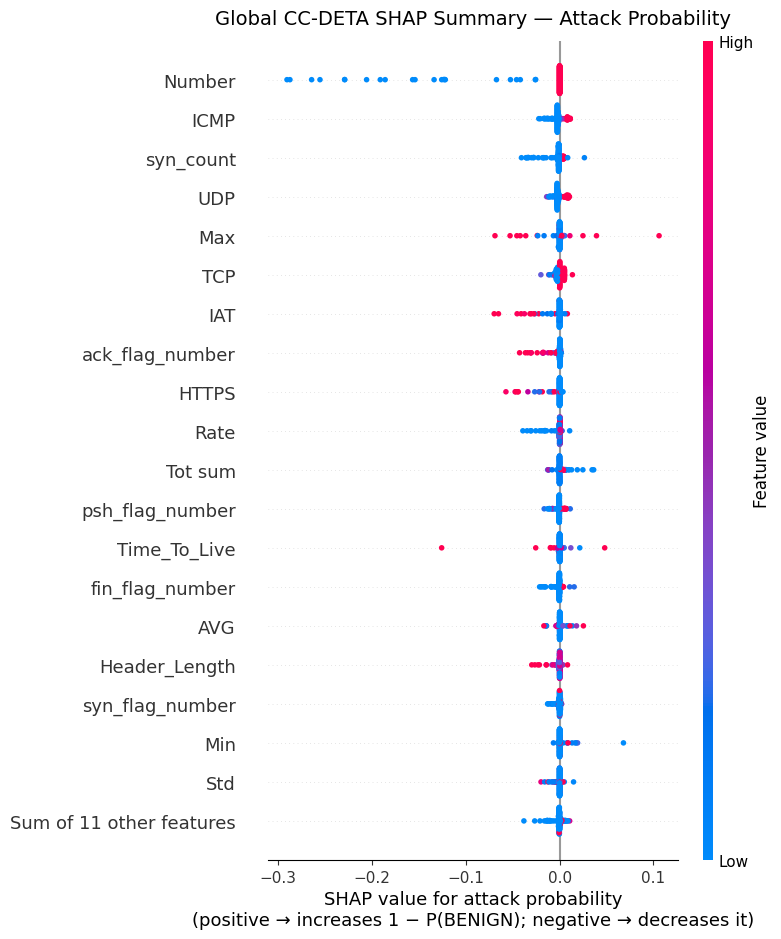

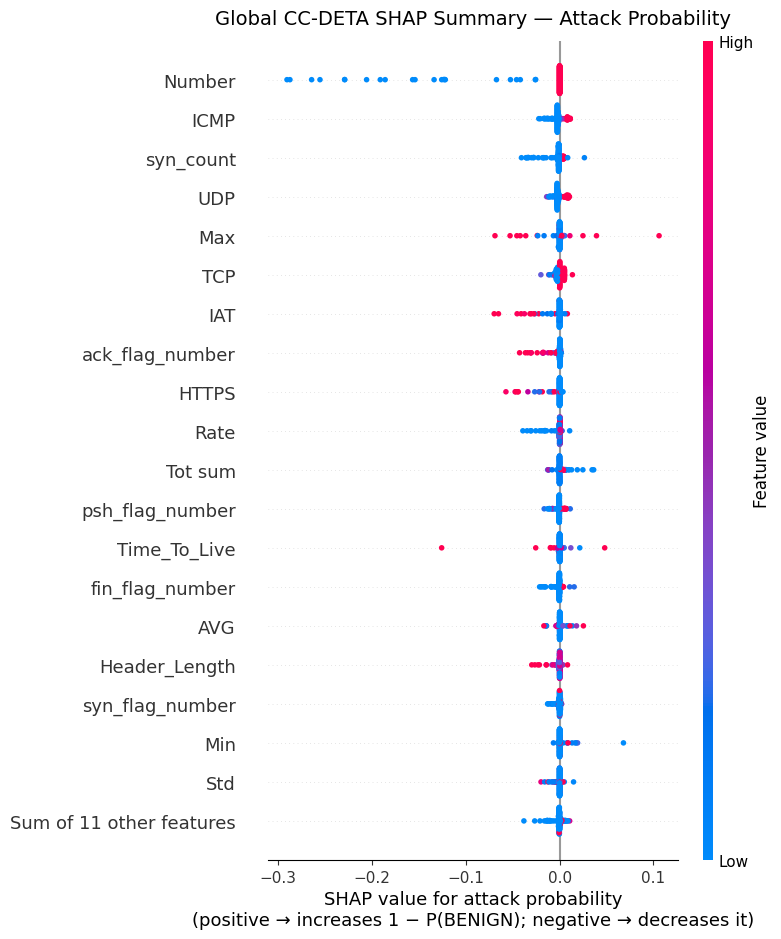

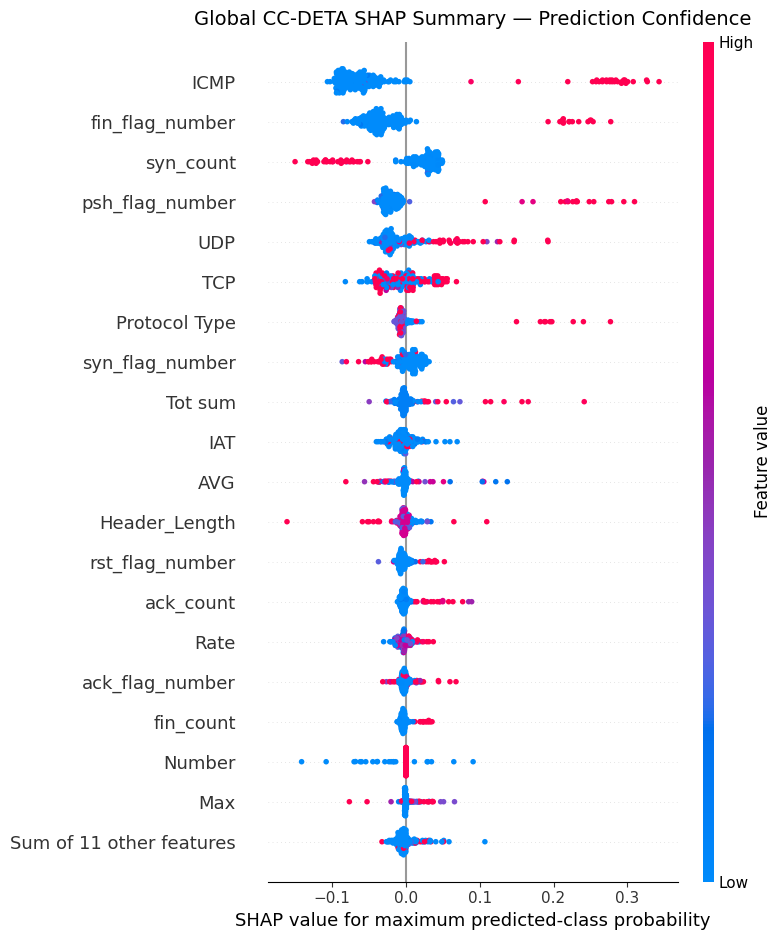

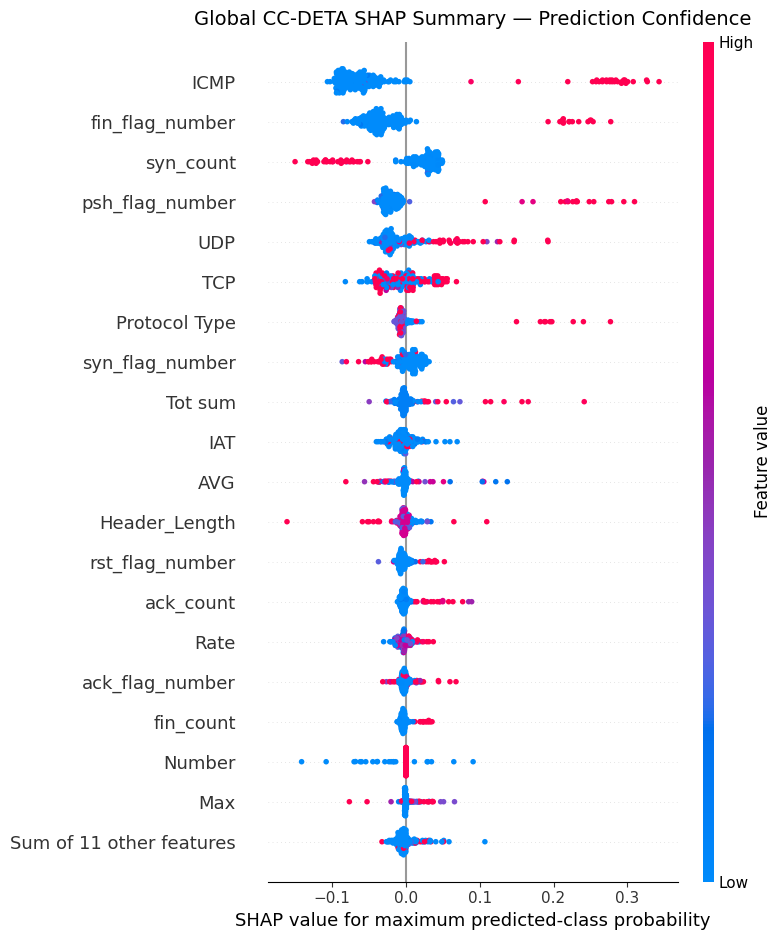

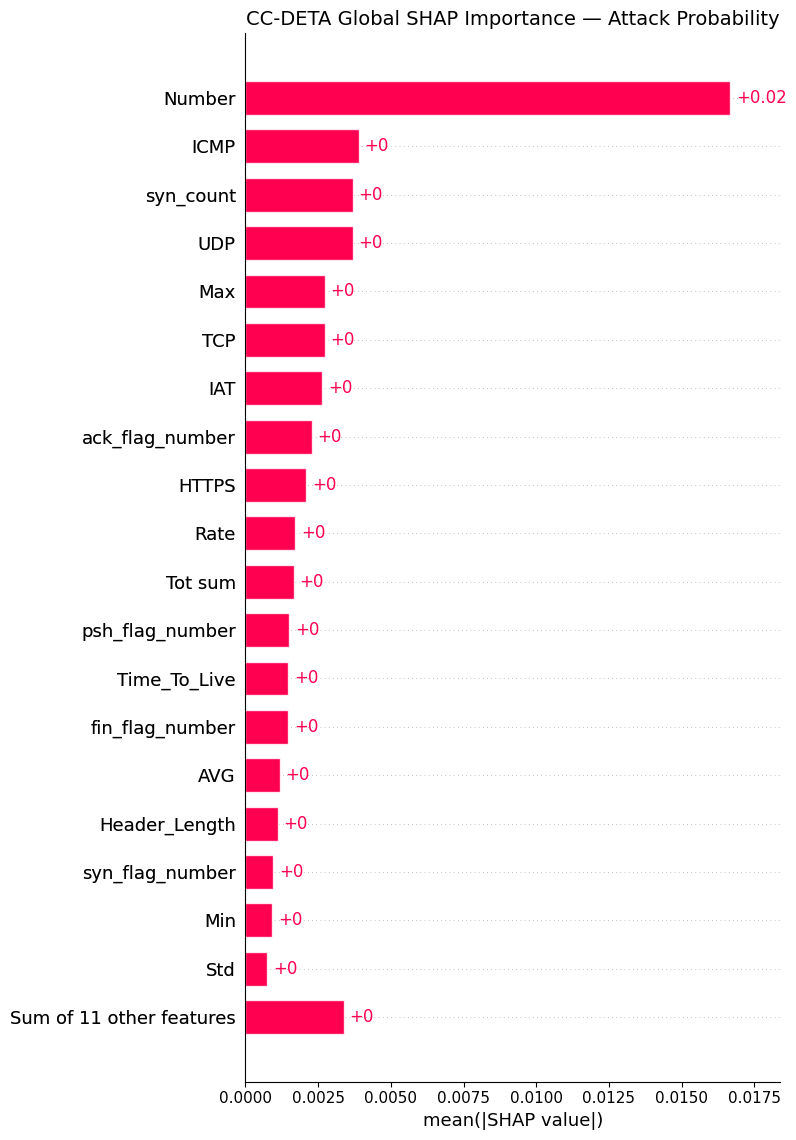

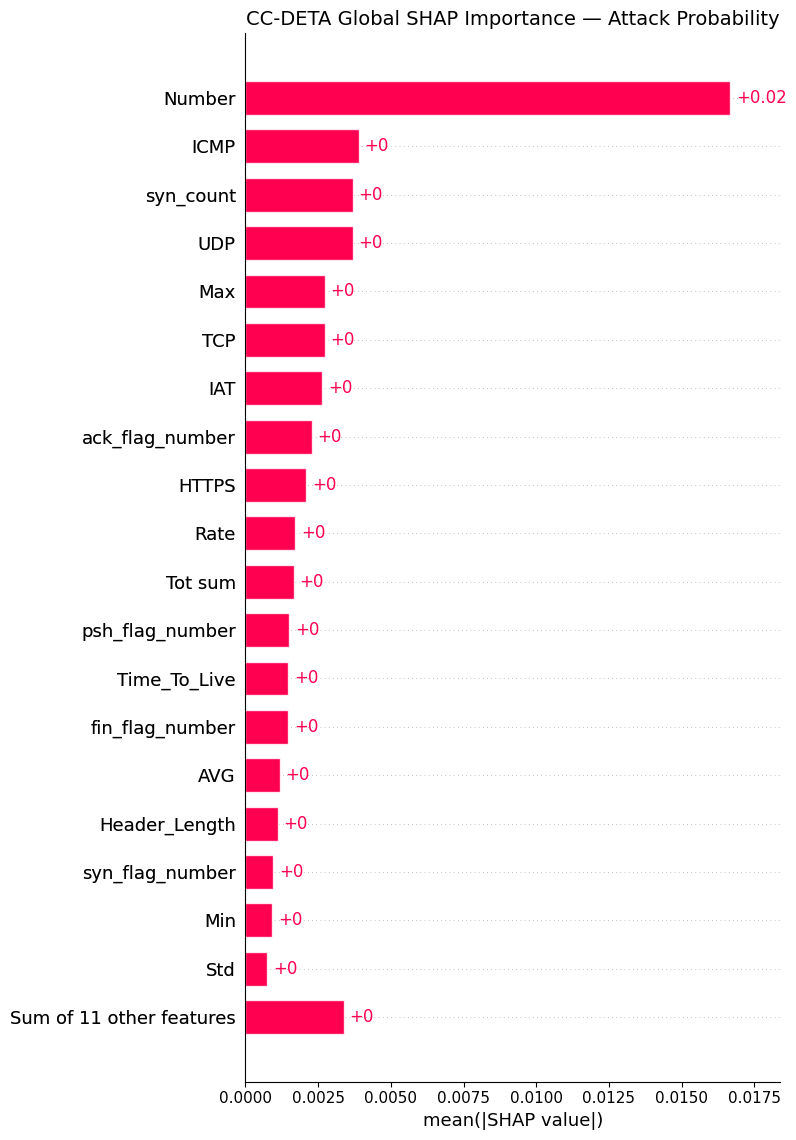


GLOBAL SHAP SUMMARY TABLE


,Global_SHAP_Rank,Feature,Mean_Abs_SHAP,Median_Abs_SHAP,Mean_Signed_SHAP,Feature_Value_vs_SHAP_Spearman_Rho,Spearman_p
0,1,Number,0.01667489,0.00000000,-0.01667489,0.99774641,0.00000000
1,2,ICMP,0.00390403,0.00240869,-0.00144644,0.57800242,0.00000000
2,3,syn_count,0.00369434,0.00116398,-0.00192464,0.62996904,0.00000000
3,4,UDP,0.00368930,0.00267115,-0.00064345,0.61235693,0.00000000
4,5,Max,0.00272524,0.00005523,-0.00055401,0.29733064,0.00001906
5,6,TCP,0.00272081,0.00230450,-0.00044746,0.79320015,0.00000000
6,7,IAT,0.00263813,0.00024595,-0.00210477,0.26281277,0.00017009
7,8,ack_flag_number,0.00228642,0.00027888,-0.00179808,-0.69779682,0.00000000
8,9,HTTPS,0.00209363,0.00001963,-0.00193617,-0.39597193,0.00000001
9,10,Rate,0.00171759,0.00021018,-0.00125544,0.73059456,0.00000000



CELL 47 FINAL REVIEWER AUDIT

REVIEWER REQUIREMENT
Genuine SHAP beeswarm produced          : YES
Attribution magnitude shown             : YES
Attribution direction shown             : YES
Feature-value distribution shown        : YES

METHODOLOGY
Final frozen CC-DETA explained           : YES
10 frozen Cell-21 models verified        : YES
Frozen Cell-40 configuration verified    : YES
Models retrained                         : NO
Trust recomputed                         : NO
Coefficients changed                     : NO
Feature selection changed                : NO
Independent test accessed                : NO

PRIMARY FIGURE
/content/gdrive/MyDrive/DETA_Reviewer_Rebuild/12_figures/FINAL_REVIEWER_MASTER/Figure_2_FINAL_CC_DETA_SHAP_beeswarm_attack_probability.png
/content/gdrive/MyDrive/DETA_Reviewer_Rebuild/12_figures/FINAL_REVIEWER_MASTER/Figure_2_FINAL_CC_DETA_SHAP_beeswarm_attack_probability.pdf

SUPPLEMENTARY FIGURES
/content/gdrive/MyDrive/DETA_Reviewer_Rebuild/12_figures/FINAL_

,Global_SHAP_Rank,Feature,Mean_Abs_SHAP,Median_Abs_SHAP,Mean_Signed_SHAP,Feature_Value_vs_SHAP_Spearman_Rho,Spearman_p
0,1,Number,0.01667489,0.00000000,-0.01667489,0.99774641,0.00000000
1,2,ICMP,0.00390403,0.00240869,-0.00144644,0.57800242,0.00000000
2,3,syn_count,0.00369434,0.00116398,-0.00192464,0.62996904,0.00000000
3,4,UDP,0.00368930,0.00267115,-0.00064345,0.61235693,0.00000000
4,5,Max,0.00272524,0.00005523,-0.00055401,0.29733064,0.00001906
5,6,TCP,0.00272081,0.00230450,-0.00044746,0.79320015,0.00000000
6,7,IAT,0.00263813,0.00024595,-0.00210477,0.26281277,0.00017009
7,8,ack_flag_number,0.00228642,0.00027888,-0.00179808,-0.69779682,0.00000000
8,9,HTTPS,0.00209363,0.00001963,-0.00193617,-0.39597193,0.00000001
9,10,Rate,0.00171759,0.00021018,-0.00125544,0.73059456,0.00000000



CELL 47 STATUS: PASSED — GENUINE FINAL CC-DETA SHAP BEESWARM COMPLETE


In [1]:
# CELL 47 — FINAL CC-DETA GENUINE SHAP SUMMARY / BEESWARM
# Reviewer 2 — Minor Comment 5
# PURPOSE
# Generate a genuine SHAP beeswarm for the FINAL FROZEN CC-DETA framework.
#
# PRIMARY SHAP TARGET:
#
#       Attack probability = 1 - P_CC-DETA(BENIGN | x)
#
# Interpretation:
#   SHAP > 0  -> feature pushes final CC-DETA toward ATTACK
#   SHAP < 0  -> feature pushes final CC-DETA toward BENIGN
#
# WHY MODEL-AGNOSTIC SHAP?
# CC-DETA is not one tree ensemble. It combines probabilities from 10 independently
# grown XGBoost models using class-conditional CC-DETA weights.
#
# Therefore, TreeExplainer on one client would NOT explain the final CC-DETA function.
# We instead apply SHAP PermutationExplainer to the complete frozen probability-fusion
# function.
#
# METHODOLOGY STATUS:
#   Models retrained       : NO
#   Trust recomputed       : NO
#   Coefficients changed   : NO
#   Features changed       : NO
#   Test data used         : NO
#   Server validation used : YES — explanation only
#

from google.colab import drive

MOUNT_POINT = "/content/gdrive"

drive.mount(
    MOUNT_POINT,
    force_remount=True
)

print("=" * 120)
print("CELL 47 — FINAL CC-DETA GENUINE SHAP BEESWARM")
print("=" * 120)
print("Google Drive mounted:", MOUNT_POINT)


# 1. IMPORTS

import os
import gc
import sys
import json
import hashlib
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from IPython.display import display, Markdown


# Install SHAP only if needed.
try:
    import shap
except ImportError:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "shap"
        ]
    )

    import shap


warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    320
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.8f}"
)


print("\nSHAP version   :", shap.__version__)
print("XGBoost version:", xgb.__version__)


# 2. PROJECT PATHS

ROOT = (
    Path(MOUNT_POINT)
    /
    "MyDrive"
    /
    "DETA_Reviewer_Rebuild"
)

MODEL_DIR = (
    ROOT
    /
    "03_client_models"
    /
    "mixed_reliability_leakage_safe"
)

SERVER_PATH = (
    ROOT
    /
    "02_partitions"
    /
    "server_validation"
    /
    "server_validation_real_clean.parquet"
)

REPRO_DIR = (
    ROOT
    /
    "15_reproducibility"
)

TABLE_DIR = (
    ROOT
    /
    "13_tables"
)

CC_DIR = (
    ROOT
    /
    "06_trust"
    /
    "class_conditional_DETA"
)

FIG_DIR = (
    ROOT
    /
    "12_figures"
    /
    "FINAL_REVIEWER_MASTER"
)

SHAP_DIR = (
    ROOT
    /
    "07_shap"
    /
    "final_CC_DETA_beeswarm"
)


for directory in [
    FIG_DIR,
    SHAP_DIR,
    TABLE_DIR,
    REPRO_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# 3. FROZEN ARTIFACTS

TOP30_JSON = (
    REPRO_DIR
    /
    "historical_top30_features.json"
)

MODEL_HASH_PATH = (
    REPRO_DIR
    /
    "cell29_frozen_cell21_model_hashes.csv"
)

CC_CONFIG_PATH = (
    CC_DIR
    /
    "CC_DETA_FROZEN_meta_validation_configuration.json"
)

L_CLASS_PATH = (
    TABLE_DIR
    /
    "cell40_CC_DETA_local_class_F1.csv"
)

G_CLASS_PATH = (
    TABLE_DIR
    /
    "cell40_CC_DETA_server_trust_class_F1.csv"
)

R_CLASS_PATH = (
    TABLE_DIR
    /
    "cell40_CC_DETA_server_trust_class_recall.csv"
)

ES_PATH = (
    TABLE_DIR
    /
    "cell40_CC_DETA_trust_subset_ES.csv"
)


EXPECTED_CC_CONFIG_SHA256 = (
    "4740dbeb773fee945c654d65df2d036f1ab8f748e4379bb9d374583f11d04f9b"
)


# 4. CONSTANTS

RANDOM_SEED = 42

N_CLIENTS = 10
N_CLASSES = 34

# 200 observations are sufficient for a publication-quality global beeswarm
# while keeping model-agnostic SHAP computationally manageable.
EXPLAIN_N = 200

# Background/reference observations used by SHAP masker.
BACKGROUND_N = 40

# 3 permutation cycles gives more stability than the minimum one-cycle estimate.
N_PERMUTATION_CYCLES = 3

MAX_DISPLAY = 20


LABEL_NAMES = [

    "BACKDOOR_MALWARE",
    "BENIGN",
    "BROWSERHIJACKING",
    "COMMANDINJECTION",
    "DDOS-ACK_FRAGMENTATION",
    "DDOS-HTTP_FLOOD",
    "DDOS-ICMP_FLOOD",
    "DDOS-ICMP_FRAGMENTATION",
    "DDOS-PSHACK_FLOOD",
    "DDOS-RSTFINFLOOD",
    "DDOS-SLOWLORIS",
    "DDOS-SYNONYMOUSIP_FLOOD",
    "DDOS-SYN_FLOOD",
    "DDOS-TCP_FLOOD",
    "DDOS-UDP_FLOOD",
    "DDOS-UDP_FRAGMENTATION",
    "DICTIONARYBRUTEFORCE",
    "DNS_SPOOFING",
    "DOS-HTTP_FLOOD",
    "DOS-SYN_FLOOD",
    "DOS-TCP_FLOOD",
    "DOS-UDP_FLOOD",
    "MIRAI-GREETH_FLOOD",
    "MIRAI-GREIP_FLOOD",
    "MIRAI-UDPPLAIN",
    "MITM-ARPSPOOFING",
    "RECON-HOSTDISCOVERY",
    "RECON-OSSCAN",
    "RECON-PINGSWEEP",
    "RECON-PORTSCAN",
    "SQLINJECTION",
    "UPLOADING_ATTACK",
    "VULNERABILITYSCAN",
    "XSS"
]


assert len(
    LABEL_NAMES
) == N_CLASSES


BENIGN_CLASS_ID = LABEL_NAMES.index(
    "BENIGN"
)


print("\nCONFIGURATION")
print("------------------------------")
print("Clients                  :", N_CLIENTS)
print("Classes                  :", N_CLASSES)
print("BENIGN class ID          :", BENIGN_CLASS_ID)
print("Explanation observations:", EXPLAIN_N)
print("Background observations :", BACKGROUND_N)
print("Permutation cycles      :", N_PERMUTATION_CYCLES)


# 5. HELPER FUNCTIONS

def require_file(
    path,
    description
):

    path = Path(path)

    if not path.exists():

        raise FileNotFoundError(
            f"\nMissing required artifact:\n"
            f"{description}\n"
            f"{path}"
        )

    return path


def sha256_file(
    path
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            h.update(
                chunk
            )

    return h.hexdigest()


def normalize_probability_rows(
    probability
):

    probability = np.asarray(
        probability,
        dtype=np.float64
    )

    probability = np.clip(
        probability,
        0.0,
        None
    )

    row_sum = probability.sum(
        axis=1,
        keepdims=True
    )

    if np.any(
        row_sum <= 0
    ):

        raise RuntimeError(
            "Non-positive probability row sum."
        )

    probability = (
        probability
        /
        row_sum
    )

    return probability


def load_local_to_global(
    path
):

    with open(
        path,
        "r"
    ) as f:

        mapping = json.load(
            f
        )

    pairs = sorted(

        [
            (
                int(local_id),
                int(global_id)
            )

            for local_id, global_id
            in mapping[
                "Local_To_Global"
            ].items()
        ],

        key=lambda x: x[0]
    )

    global_ids = np.array(

        [
            global_id

            for _,
            global_id
            in pairs
        ],

        dtype=np.int32
    )

    return global_ids


def recover_feature_list(
    path
):

    with open(
        path,
        "r"
    ) as f:

        obj = json.load(
            f
        )

    features = None


    if isinstance(
        obj,
        list
    ):

        features = obj


    elif isinstance(
        obj,
        dict
    ):

        for key in [

            "features",
            "top30_features",
            "historical_top30_features",
            "selected_features",
            "feature_names"

        ]:

            if (
                key in obj
                and isinstance(
                    obj[key],
                    list
                )
                and len(
                    obj[key]
                ) == 30
            ):

                features = obj[
                    key
                ]

                break


    if features is None:

        raise RuntimeError(
            "Unable to recover frozen Top-30 features."
        )


    features = [
        str(x)
        for x in features
    ]


    assert len(
        features
    ) == 30


    assert len(
        set(features)
    ) == 30


    return features


# Same basic class-preserving principle used in your earlier SHAP audit.
def class_preserving_sample(
    df,
    target_col,
    sample_size,
    seed
):

    counts = (

        df[
            target_col
        ]

        .value_counts()

        .sort_index()
    )


    classes = counts.index.to_numpy()

    class_counts = counts.to_numpy()


    if sample_size < len(classes):

        raise RuntimeError(
            "SHAP sample must be >= number of classes."
        )


    # Start with one observation from every class.
    quotas = np.ones(
        len(classes),
        dtype=int
    )


    remaining = (
        sample_size
        -
        quotas.sum()
    )


    # Allocate remaining sample approximately proportional to support.
    proportions = (
        class_counts
        /
        class_counts.sum()
    )


    desired_extra = (
        proportions
        *
        remaining
    )


    extra = np.floor(
        desired_extra
    ).astype(int)


    extra = np.minimum(
        extra,
        class_counts
        -
        quotas
    )


    quotas += extra


    remaining = (
        sample_size
        -
        quotas.sum()
    )


    # Largest remainder allocation.
    remainder_score = (

        desired_extra
        -
        np.floor(
            desired_extra
        )
    )


    while remaining > 0:

        eligible = np.where(
            quotas < class_counts
        )[0]


        order = eligible[
            np.argsort(
                -remainder_score[
                    eligible
                ]
            )
        ]


        for j in order:

            if remaining == 0:
                break


            if quotas[j] < class_counts[j]:

                quotas[j] += 1

                remaining -= 1


    selected_indices = []


    for class_id, quota in zip(
        classes,
        quotas
    ):

        available = df.index[
            df[
                target_col
            ]
            ==
            class_id
        ].to_numpy()


        rng = np.random.default_rng(

            seed
            +
            int(class_id)
            *
            1009
        )


        chosen = rng.choice(

            available,

            size=int(
                quota
            ),

            replace=False
        )


        selected_indices.extend(
            chosen.tolist()
        )


    rng = np.random.default_rng(
        seed
    )


    rng.shuffle(
        selected_indices
    )


    sampled = df.loc[
        selected_indices
    ].copy()


    allocation = pd.DataFrame({

        "Class_ID":
            classes,

        "Class_Name":
            [
                LABEL_NAMES[
                    int(c)
                ]
                for c in classes
            ],

        "Server_Count":
            class_counts,

        "SHAP_Count":
            quotas
    })


    return (
        sampled,
        allocation
    )


# 6. REQUIRED ARTIFACT AUDIT

print("\n" + "=" * 120)
print("REQUIRED FROZEN ARTIFACT AUDIT")
print("=" * 120)


required_files = {

    "Frozen Top-30":
        TOP30_JSON,

    "Cell-29 model hashes":
        MODEL_HASH_PATH,

    "Server validation":
        SERVER_PATH,

    "Frozen CC-DETA configuration":
        CC_CONFIG_PATH,

    "CC-DETA local-class F1":
        L_CLASS_PATH,

    "CC-DETA server-class F1":
        G_CLASS_PATH,

    "CC-DETA server-class recall":
        R_CLASS_PATH,

    "CC-DETA ES":
        ES_PATH
}


for description, path in required_files.items():

    require_file(
        path,
        description
    )

    print(
        f"{description:<34}: PASSED"
    )


# 7. VERIFY FINAL FROZEN CC-DETA CONFIGURATION

actual_sha = sha256_file(
    CC_CONFIG_PATH
)


print("\nCC-DETA configuration SHA256")
print("Expected:", EXPECTED_CC_CONFIG_SHA256)
print("Actual  :", actual_sha)


if actual_sha != EXPECTED_CC_CONFIG_SHA256:

    raise RuntimeError(
        "CC-DETA frozen configuration SHA256 mismatch."
    )


with open(
    CC_CONFIG_PATH,
    "r"
) as f:

    cc_config = json.load(
        f
    )


parameters = cc_config[
    "selected_parameters"
]


CC_THETA = np.array(

    [
        parameters[
            "alpha_local_class_F1"
        ],

        parameters[
            "beta_server_class_F1"
        ],

        parameters[
            "gamma_server_class_recall"
        ],

        parameters[
            "delta_ES"
        ]
    ],

    dtype=np.float64
)


CC_TAU = float(
    parameters[
        "tau"
    ]
)


EXPECTED_THETA = np.array(
    [
        0.10,
        0.75,
        0.05,
        0.10
    ]
)


assert np.allclose(
    CC_THETA,
    EXPECTED_THETA
)


assert np.isclose(
    CC_TAU,
    4.0
)


print("\nFINAL CC-DETA PARAMETERS")
print("alpha :", CC_THETA[0])
print("beta  :", CC_THETA[1])
print("gamma :", CC_THETA[2])
print("delta :", CC_THETA[3])
print("tau   :", CC_TAU)

print("\nFrozen CC-DETA configuration: PASSED")


# 8. RECONSTRUCT FINAL CLASS-CONDITIONAL CC-DETA WEIGHTS

class_columns = [

    f"Class_{i}"

    for i in range(
        N_CLASSES
    )
]


L_df = (
    pd.read_csv(
        L_CLASS_PATH
    )
    .sort_values(
        "Client_ID"
    )
)


G_df = (
    pd.read_csv(
        G_CLASS_PATH
    )
    .sort_values(
        "Client_ID"
    )
)


R_df = (
    pd.read_csv(
        R_CLASS_PATH
    )
    .sort_values(
        "Client_ID"
    )
)


ES_df = (
    pd.read_csv(
        ES_PATH
    )
    .sort_values(
        "Client_ID"
    )
)


L_CLASS = L_df[
    class_columns
].to_numpy(
    dtype=np.float64
)


G_CLASS = G_df[
    class_columns
].to_numpy(
    dtype=np.float64
)


R_CLASS = R_df[
    class_columns
].to_numpy(
    dtype=np.float64
)


ES = ES_df[
    "ES_i"
].to_numpy(
    dtype=np.float64
)


assert L_CLASS.shape == (
    10,
    34
)


assert G_CLASS.shape == (
    10,
    34
)


assert R_CLASS.shape == (
    10,
    34
)


assert ES.shape == (
    10,
)


CC_TRUST = (

    CC_THETA[0]
    *
    L_CLASS

    +

    CC_THETA[1]
    *
    G_CLASS

    +

    CC_THETA[2]
    *
    R_CLASS

    +

    CC_THETA[3]
    *
    ES[
        :,
        None
    ]
)


CC_TRUST = np.clip(
    CC_TRUST,
    1e-12,
    None
)


CC_POWERED = np.power(
    CC_TRUST,
    CC_TAU
)


CC_WEIGHTS = (

    CC_POWERED

    /

    CC_POWERED.sum(
        axis=0,
        keepdims=True
    )
)


assert np.allclose(

    CC_WEIGHTS.sum(
        axis=0
    ),

    1.0
)


print("\nCC-DETA weights:")
print("Shape:", CC_WEIGHTS.shape)

print(
    "Minimum:",
    f"{CC_WEIGHTS.min():.8f}"
)

print(
    "Maximum:",
    f"{CC_WEIGHTS.max():.8f}"
)

print("CC-DETA weight reconstruction: PASSED")


# 9. LOAD TOP-30 FEATURE SCHEMA

FEATURES = recover_feature_list(
    TOP30_JSON
)


print("\nFrozen Top-30 features:")

for i, feature in enumerate(
    FEATURES,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )


# 10. VERIFY AND LOAD ALL 10 FROZEN CLIENT MODELS

model_hash_df = pd.read_csv(
    MODEL_HASH_PATH
)


model_hash_df[
    "Client_ID"
] = model_hash_df[
    "Client_ID"
].astype(int)


hash_column = None


for candidate in [
    "SHA256",
    "Model_SHA256"
]:

    if candidate in model_hash_df.columns:

        hash_column = candidate

        break


if hash_column is None:

    raise RuntimeError(
        "Unable to identify model SHA256 column."
    )


BOOSTERS = {}

LOCAL_TO_GLOBAL = {}


print("\n" + "=" * 120)
print("FROZEN CELL-21 MODEL VERIFICATION")
print("=" * 120)


for client_id in range(
    N_CLIENTS
):

    model_path = (

        MODEL_DIR

        /

        f"client_{client_id:02d}_xgb.json"
    )


    mapping_path = (

        MODEL_DIR

        /

        f"client_{client_id:02d}_class_mapping.json"
    )


    require_file(
        model_path,
        f"Client {client_id} model"
    )


    require_file(
        mapping_path,
        f"Client {client_id} mapping"
    )


    expected_row = model_hash_df[

        model_hash_df[
            "Client_ID"
        ]
        ==
        client_id
    ]


    if len(
        expected_row
    ) != 1:

        raise RuntimeError(
            f"Invalid hash row for Client {client_id}."
        )


    expected_hash = str(

        expected_row.iloc[
            0
        ][
            hash_column
        ]
    )


    observed_hash = sha256_file(
        model_path
    )


    if observed_hash != expected_hash:

        raise RuntimeError(
            f"Client {client_id:02d} model hash mismatch."
        )


    booster = xgb.Booster()


    booster.load_model(
        str(
            model_path
        )
    )


    BOOSTERS[
        client_id
    ] = booster


    LOCAL_TO_GLOBAL[
        client_id
    ] = load_local_to_global(
        mapping_path
    )


    print(
        f"Client {client_id:02d}: "
        f"SHA256 PASSED | "
        f"local classes = "
        f"{len(LOCAL_TO_GLOBAL[client_id])}"
    )


print("\n10/10 frozen local models verified: PASSED")


# 11. LOAD RESERVED SERVER-VALIDATION DATA

server_df = pd.read_parquet(
    SERVER_PATH
)


assert "Label_Encoded" in server_df.columns


missing_features = [

    feature

    for feature in FEATURES

    if feature not in server_df.columns
]


if missing_features:

    raise RuntimeError(
        f"Missing features:\n{missing_features}"
    )


X_server = server_df[
    FEATURES
].copy()


for feature in FEATURES:

    X_server[
        feature
    ] = pd.to_numeric(

        X_server[
            feature
        ],

        errors="coerce"
    )


X_server.replace(
    [
        np.inf,
        -np.inf
    ],
    np.nan,
    inplace=True
)


if int(
    X_server
    .isna()
    .sum()
    .sum()
) != 0:

    raise RuntimeError(
        "Server-validation clean artifact contains NaN/Inf."
    )


assert server_df[
    "Label_Encoded"
].nunique() == 34


print("\nServer-validation data")
print("Path   :", SERVER_PATH)
print("Rows   :", f"{len(server_df):,}")
print("Classes:", server_df["Label_Encoded"].nunique())
print("Features:", len(FEATURES))
print("Finite-value audit: PASSED")


# 12. FIXED CLASS-PRESERVING EXPLANATION SAMPLE

explain_df, allocation_df = class_preserving_sample(

    df=server_df,

    target_col="Label_Encoded",

    sample_size=EXPLAIN_N,

    seed=RANDOM_SEED
)


X_explain = explain_df[
    FEATURES
].copy()


# Deterministic reference/background observations.
background_df = (

    server_df[
        FEATURES
    ]

    .sample(

        n=BACKGROUND_N,

        random_state=RANDOM_SEED + 777,

        replace=False
    )

    .copy()
)


print("\nSHAP SAMPLE")
print("----------------------------")
print("Explanation rows :", len(X_explain))
print(
    "Classes represented:",
    explain_df[
        "Label_Encoded"
    ].nunique()
)
print("Background rows  :", len(background_df))
print("Independent test : NOT USED")


display(
    allocation_df
)


# 13. FINAL FROZEN CC-DETA PREDICTION FUNCTION

def predict_cc_deta_probabilities(
    X_input
):

    X_input = np.asarray(
        X_input,
        dtype=np.float32
    )


    if X_input.ndim == 1:

        X_input = X_input.reshape(
            1,
            -1
        )


    if X_input.shape[
        1
    ] != len(
        FEATURES
    ):

        raise RuntimeError(
            "Incorrect feature count."
        )


    n_rows = X_input.shape[
        0
    ]


    aggregate_raw = np.zeros(

        (
            n_rows,
            N_CLASSES
        ),

        dtype=np.float64
    )


    dmatrix = xgb.DMatrix(
        X_input
    )


    for client_id in range(
        N_CLIENTS
    ):

        local_prob = BOOSTERS[
            client_id
        ].predict(
            dmatrix
        )


        local_prob = np.asarray(
            local_prob,
            dtype=np.float64
        )


        if local_prob.ndim == 1:

            local_prob = local_prob.reshape(
                n_rows,
                -1
            )


        global_ids = LOCAL_TO_GLOBAL[
            client_id
        ]


        if local_prob.shape[
            1
        ] != len(
            global_ids
        ):

            raise RuntimeError(

                f"Client {client_id}: "
                f"prediction/mapping mismatch."
            )


        global_prob = np.zeros(

            (
                n_rows,
                N_CLASSES
            ),

            dtype=np.float64
        )


        global_prob[
            :,
            global_ids
        ] = local_prob


        global_prob = normalize_probability_rows(
            global_prob
        )


        # FINAL class-conditional CC-DETA probability weighting.
        aggregate_raw += (

            global_prob

            *

            CC_WEIGHTS[
                client_id
            ][
                None,
                :
            ]
        )


    del dmatrix


    aggregate_probability = normalize_probability_rows(
        aggregate_raw
    )


    return aggregate_probability


# Two scalar outputs can be explained during the same SHAP run.
def cc_deta_shap_outputs(
    X_input
):

    probabilities = predict_cc_deta_probabilities(
        X_input
    )


    # PRIMARY reviewer figure:
    attack_probability = (

        1.0

        -

        probabilities[
            :,
            BENIGN_CLASS_ID
        ]
    )


    # Secondary supplementary interpretation:
    prediction_confidence = probabilities.max(
        axis=1
    )


    return np.column_stack(

        [
            attack_probability,
            prediction_confidence
        ]
    )


# 14. SANITY CHECK FINAL PREDICTION FUNCTION

sanity_output = cc_deta_shap_outputs(

    X_explain.iloc[
        :10
    ]
)


print("\nCC-DETA prediction-function audit")
print("-----------------------------------")
print("Output shape:", sanity_output.shape)

print(
    "Attack probability:",
    f"{sanity_output[:,0].min():.6f}",
    "to",
    f"{sanity_output[:,0].max():.6f}"
)

print(
    "Confidence:",
    f"{sanity_output[:,1].min():.6f}",
    "to",
    f"{sanity_output[:,1].max():.6f}"
)


assert sanity_output.shape == (
    10,
    2
)


assert np.all(
    sanity_output >= 0
)


assert np.all(
    sanity_output <= 1
)


print("Prediction-function audit: PASSED")


# 15. GENUINE MODEL-AGNOSTIC SHAP
# Each full permutation cycle needs at least:
#
#       2 * M + 1
#
# evaluations, where M = 30 features.
#
# Here:
#       2*30 + 1 = 61 evaluations/cycle
#
# Three cycles:
#       183 evaluations/observation

np.random.seed(
    RANDOM_SEED
)


masker = shap.maskers.Independent(

    background_df,

    max_samples=BACKGROUND_N
)


explainer = shap.Explainer(

    cc_deta_shap_outputs,

    masker,

    algorithm="permutation"
)


ONE_CYCLE_EVALS = (

    2
    *
    len(
        FEATURES
    )

    +
    1
)


MAX_EVALS = (

    N_PERMUTATION_CYCLES

    *

    ONE_CYCLE_EVALS
)


print("\n" + "=" * 120)
print("RUNNING SHAP PERMUTATION EXPLAINER")
print("=" * 120)

print("Features                :", len(FEATURES))
print("One-cycle evaluations   :", ONE_CYCLE_EVALS)
print("Permutation cycles      :", N_PERMUTATION_CYCLES)
print("max_evals / observation :", MAX_EVALS)
print("Explanation rows        :", EXPLAIN_N)
print("Background rows         :", BACKGROUND_N)


shap_values = explainer(

    X_explain,

    max_evals=MAX_EVALS,

    batch_size=64,

    silent=False
)


print("\nSHAP output shape:")

print(
    np.asarray(
        shap_values.values
    ).shape
)


expected_shape = (

    EXPLAIN_N,

    len(
        FEATURES
    ),

    2
)


if np.asarray(
    shap_values.values
).shape != expected_shape:

    raise RuntimeError(

        f"Expected {expected_shape}, "

        f"received "
        f"{np.asarray(shap_values.values).shape}"
    )


if not np.isfinite(
    shap_values.values
).all():

    raise RuntimeError(
        "SHAP contains NaN/Inf."
    )


print("\nGenuine SHAP computation: PASSED")


# 16. CREATE SHAP EXPLANATION OBJECTS

attack_values = np.asarray(

    shap_values.values[
        :,
        :,
        0
    ],

    dtype=np.float64
)


confidence_values = np.asarray(

    shap_values.values[
        :,
        :,
        1
    ],

    dtype=np.float64
)


base_values = np.asarray(
    shap_values.base_values
)


if base_values.ndim == 2:

    attack_base = base_values[
        :,
        0
    ]

    confidence_base = base_values[
        :,
        1
    ]


else:

    raise RuntimeError(

        f"Unexpected base-value shape: "
        f"{base_values.shape}"
    )


attack_explanation = shap.Explanation(

    values=attack_values,

    base_values=attack_base,

    data=X_explain.to_numpy(
        dtype=np.float64
    ),

    feature_names=FEATURES
)


confidence_explanation = shap.Explanation(

    values=confidence_values,

    base_values=confidence_base,

    data=X_explain.to_numpy(
        dtype=np.float64
    ),

    feature_names=FEATURES
)


# 17. PRIMARY FIGURE — GENUINE SHAP BEESWARM

PRIMARY_PNG = (

    FIG_DIR

    /

    "Figure_2_FINAL_CC_DETA_SHAP_beeswarm_attack_probability.png"
)


PRIMARY_PDF = (

    FIG_DIR

    /

    "Figure_2_FINAL_CC_DETA_SHAP_beeswarm_attack_probability.pdf"
)


plt.figure(
    figsize=(11, 9)
)


result = shap.plots.beeswarm(

    attack_explanation,

    max_display=MAX_DISPLAY,

    show=False
)


plt.title(

    "Global CC-DETA SHAP Summary — Attack Probability",

    fontsize=14,

    pad=12
)


plt.xlabel(

    "SHAP value for attack probability\n"
    "(positive → increases 1 − P(BENIGN); "
    "negative → decreases it)"
)


plt.tight_layout()


fig = (

    result.figure

    if result is not None
    and hasattr(
        result,
        "figure"
    )

    else plt.gcf()
)


fig.savefig(

    PRIMARY_PNG,

    dpi=400,

    bbox_inches="tight"
)


fig.savefig(

    PRIMARY_PDF,

    bbox_inches="tight"
)


display(

    Markdown(
        "### Figure 2 — Genuine global SHAP beeswarm for final CC-DETA"
    )
)


display(
    fig
)


plt.show()

plt.close(
    fig
)


# 18. OPTIONAL SUPPLEMENTARY CONFIDENCE BEESWARM

CONF_PNG = (

    FIG_DIR

    /

    "Figure_S_CC_DETA_SHAP_beeswarm_prediction_confidence.png"
)


CONF_PDF = (

    FIG_DIR

    /

    "Figure_S_CC_DETA_SHAP_beeswarm_prediction_confidence.pdf"
)


plt.figure(
    figsize=(11, 9)
)


result = shap.plots.beeswarm(

    confidence_explanation,

    max_display=MAX_DISPLAY,

    show=False
)


plt.title(

    "Global CC-DETA SHAP Summary — Prediction Confidence",

    fontsize=14,

    pad=12
)


plt.xlabel(

    "SHAP value for maximum predicted-class probability"
)


plt.tight_layout()


fig_conf = (

    result.figure

    if result is not None
    and hasattr(
        result,
        "figure"
    )

    else plt.gcf()
)


fig_conf.savefig(

    CONF_PNG,

    dpi=400,

    bbox_inches="tight"
)


fig_conf.savefig(

    CONF_PDF,

    bbox_inches="tight"
)


display(
    fig_conf
)


plt.show()

plt.close(
    fig_conf
)


# 19. COMPANION GLOBAL SHAP MAGNITUDE BAR
#
# This is NOT the replacement for the beeswarm.
# It is simply the global mean-|SHAP| companion.

BAR_PNG = (

    FIG_DIR

    /

    "Figure_S_CC_DETA_SHAP_global_importance_bar.png"
)


BAR_PDF = (

    FIG_DIR

    /

    "Figure_S_CC_DETA_SHAP_global_importance_bar.pdf"
)


plt.figure(
    figsize=(9, 8)
)


result = shap.plots.bar(

    attack_explanation,

    max_display=MAX_DISPLAY,

    show=False
)


plt.title(

    "CC-DETA Global SHAP Importance — Attack Probability",

    fontsize=14
)


plt.tight_layout()


fig_bar = (

    result.figure

    if result is not None
    and hasattr(
        result,
        "figure"
    )

    else plt.gcf()
)


fig_bar.savefig(

    BAR_PNG,

    dpi=400,

    bbox_inches="tight"
)


fig_bar.savefig(

    BAR_PDF,

    bbox_inches="tight"
)


display(
    fig_bar
)


plt.show()

plt.close(
    fig_bar
)


# 20. QUANTITATIVE GLOBAL SHAP TABLE

feature_matrix = X_explain.to_numpy(
    dtype=np.float64
)


mean_abs_shap = np.mean(

    np.abs(
        attack_values
    ),

    axis=0
)


median_abs_shap = np.median(

    np.abs(
        attack_values
    ),

    axis=0
)


mean_signed_shap = np.mean(

    attack_values,

    axis=0
)


direction_rho = []

direction_p = []


for j in range(
    len(
        FEATURES
    )
):

    feature_values = feature_matrix[
        :,
        j
    ]


    feature_shap = attack_values[
        :,
        j
    ]


    if (
        np.unique(
            feature_values
        ).size
        <
        2
    ):

        rho = np.nan
        p_value = np.nan


    else:

        rho, p_value = spearmanr(

            feature_values,

            feature_shap
        )


    direction_rho.append(
        rho
    )


    direction_p.append(
        p_value
    )


summary_df = pd.DataFrame({

    "Feature":
        FEATURES,

    "Mean_Abs_SHAP":
        mean_abs_shap,

    "Median_Abs_SHAP":
        median_abs_shap,

    "Mean_Signed_SHAP":
        mean_signed_shap,

    "Feature_Value_vs_SHAP_Spearman_Rho":
        direction_rho,

    "Spearman_p":
        direction_p
})


summary_df = (

    summary_df

    .sort_values(

        "Mean_Abs_SHAP",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


summary_df.insert(

    0,

    "Global_SHAP_Rank",

    np.arange(
        1,
        len(summary_df) + 1
    )
)


SUMMARY_CSV = (

    TABLE_DIR

    /

    "cell47_FINAL_CC_DETA_genuine_SHAP_summary.csv"
)


summary_df.to_csv(

    SUMMARY_CSV,

    index=False
)


print("\n" + "=" * 120)
print("GLOBAL SHAP SUMMARY TABLE")
print("=" * 120)


display(
    summary_df
)


# 21. SAVE LONG-FORM SHAP DATA

long_rows = []


true_labels = explain_df[
    "Label_Encoded"
].to_numpy(
    dtype=int
)


server_indices = explain_df.index.to_numpy()


for sample_number in range(
    EXPLAIN_N
):

    for feature_index, feature in enumerate(
        FEATURES
    ):

        long_rows.append({

            "Sample_Position":
                sample_number,

            "Server_Row_Index":
                str(
                    server_indices[
                        sample_number
                    ]
                ),

            "True_Class_ID":
                int(
                    true_labels[
                        sample_number
                    ]
                ),

            "True_Class_Name":
                LABEL_NAMES[
                    int(
                        true_labels[
                            sample_number
                        ]
                    )
                ],

            "Feature":
                feature,

            "Feature_Value":
                float(
                    feature_matrix[
                        sample_number,
                        feature_index
                    ]
                ),

            "SHAP_Attack_Probability":
                float(
                    attack_values[
                        sample_number,
                        feature_index
                    ]
                ),

            "SHAP_Prediction_Confidence":
                float(
                    confidence_values[
                        sample_number,
                        feature_index
                    ]
                )
        })


long_df = pd.DataFrame(
    long_rows
)


LONG_CSV = (

    SHAP_DIR

    /

    "cell47_FINAL_CC_DETA_SHAP_long_form.csv"
)


long_df.to_csv(

    LONG_CSV,

    index=False
)


# 22. SAVE SAMPLE ALLOCATION

ALLOCATION_CSV = (

    TABLE_DIR

    /

    "cell47_CC_DETA_SHAP_sample_class_allocation.csv"
)


allocation_df.to_csv(

    ALLOCATION_CSV,

    index=False
)


# 23. SAVE REPRODUCIBILITY MANIFEST

MANIFEST_PATH = (

    REPRO_DIR

    /

    "cell47_FINAL_CC_DETA_genuine_SHAP_manifest.json"
)


manifest = {

    "Reviewer":
        "Reviewer 2",

    "Comment":
        "Minor Comment 5 — genuine SHAP summary / beeswarm",

    "Explanation_Framework":
        "Final frozen CC-DETA",

    "Primary_SHAP_Target":
        "1 - P_CC_DETA(BENIGN | x)",

    "Secondary_SHAP_Target":
        "max_c P_CC_DETA(c | x)",

    "Explainer":
        "SHAP PermutationExplainer",

    "Explanation_Data":
        str(
            SERVER_PATH
        ),

    "Independent_Test_Used":
        False,

    "Explanation_Rows":
        EXPLAIN_N,

    "Background_Rows":
        BACKGROUND_N,

    "Random_Seed":
        RANDOM_SEED,

    "Permutation_Cycles":
        N_PERMUTATION_CYCLES,

    "Max_Evals_Per_Observation":
        MAX_EVALS,

    "CC_DETA_Config_SHA256":
        actual_sha,

    "CC_DETA_Theta":
        CC_THETA.tolist(),

    "CC_DETA_Tau":
        CC_TAU,

    "Models_Retrained":
        False,

    "Trust_Recomputed":
        False,

    "Features_Changed":
        False,

    "Coefficients_Changed":
        False,

    "Primary_Figure_PNG":
        str(
            PRIMARY_PNG
        ),

    "Primary_Figure_PDF":
        str(
            PRIMARY_PDF
        ),

    "Summary_Table":
        str(
            SUMMARY_CSV
        ),

    "Long_Form_SHAP":
        str(
            LONG_CSV
        )
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(

        manifest,

        f,

        indent=4
    )


MANIFEST_SHA = sha256_file(
    MANIFEST_PATH
)


# 24. FINAL OUTPUT

print("\n" + "=" * 120)
print("CELL 47 FINAL REVIEWER AUDIT")
print("=" * 120)


print("\nREVIEWER REQUIREMENT")
print("Genuine SHAP beeswarm produced          : YES")
print("Attribution magnitude shown             : YES")
print("Attribution direction shown             : YES")
print("Feature-value distribution shown        : YES")


print("\nMETHODOLOGY")
print("Final frozen CC-DETA explained           : YES")
print("10 frozen Cell-21 models verified        : YES")
print("Frozen Cell-40 configuration verified    : YES")
print("Models retrained                         : NO")
print("Trust recomputed                         : NO")
print("Coefficients changed                     : NO")
print("Feature selection changed                : NO")
print("Independent test accessed                : NO")


print("\nPRIMARY FIGURE")
print(PRIMARY_PNG)
print(PRIMARY_PDF)


print("\nSUPPLEMENTARY FIGURES")
print(CONF_PNG)
print(CONF_PDF)
print(BAR_PNG)
print(BAR_PDF)


print("\nTABLES")
print(SUMMARY_CSV)
print(LONG_CSV)
print(ALLOCATION_CSV)


print("\nMANIFEST")
print(MANIFEST_PATH)
print("SHA256:", MANIFEST_SHA)


print("\nTOP-10 FEATURES FROM GENUINE CC-DETA SHAP")
display(
    summary_df.head(
        10
    )
)


print("\n" + "=" * 120)
print(
    "CELL 47 STATUS: PASSED — "
    "GENUINE FINAL CC-DETA SHAP BEESWARM COMPLETE"
)
print("=" * 120)